# Proyecto Final - MLOps local con monitoreo de Data Drift

El notebook documenta el ciclo completo del proyecto: datos, modelo, servicio de inferencia, monitoreo de drift y política de actuación.

## Clasificación de enfermedades foliares del tomate mediante Machine Learning

El sistema clasifica diez condiciones foliares del tomate mediante descriptores visuales y un pipeline reproducible de Machine Learning.


# Etapa preliminar — Preparación y organización del proyecto

Esta sección resume etapa preliminar — Preparación y organización del proyecto y su función dentro del proyecto MLOps.


## Contexto del problema y variable objetivo

Esta sección resume contexto del problema y variable objetivo y su función dentro del proyecto MLOps.


## 1. Contexto del problema

La identificación oportuna de enfermedades en cultivos agrícolas constituye una tarea relevante para la sanidad vegetal, debido a que distintas patologías pueden afectar el desarrollo de las plantas, reducir el...


## Librerias

Esta sección resume librerias y su función dentro del proyecto MLOps.


In [ ]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


## Reproducibilidad

Esta sección resume reproducibilidad y su función dentro del proyecto MLOps.


In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Instalación de Scikit-learn

En esta sección se instala la biblioteca Scikit-learn, una de las principales herramientas de Python para el desarrollo de modelos de Machine Learning.


In [ ]:
# ============================================================
# VERIFICACIÓN SEGURA DE SCIKIT-LEARN — GOOGLE COLAB
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Verificar que Scikit-learn esté disponible SIN actualizarlo
# después de haber sido importado en la misma sesión.
#
# Esto evita inconsistencias entre módulos cargados en memoria
# y archivos de una versión diferente instalados por pip.
#
# Si Scikit-learn no existe, se instala una sola vez antes de
# realizar cualquier importación desde sklearn.
# ============================================================

import sys
import subprocess
import importlib.util


# ============================================================
# 1. INSTALAR SOLO SI NO ESTÁ DISPONIBLE
# ============================================================

if importlib.util.find_spec("sklearn") is None:

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "scikit-learn"
        ]
    )


# ============================================================
# 2. IMPORTAR SCIKIT-LEARN Y COMPONENTES UTILIZADOS
# ============================================================

import sklearn

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import (
    StandardScaler
)

from sklearn.decomposition import (
    PCA
)


# ============================================================
# 3. VERIFICACIÓN
# ============================================================

print("=" * 70)
print("VERIFICACIÓN SEGURA DE SCIKIT-LEARN")
print("=" * 70)

print(
    "Scikit-learn disponible correctamente."
)

print(
    f"Versión activa: {sklearn.__version__}"
)

print(
    "Importación de StandardScaler: OK"
)

print(
    "Importación de PCA           : OK"
)

print("=" * 70)


VERIFICACIÓN SEGURA DE SCIKIT-LEARN
Scikit-learn disponible correctamente.
Versión activa: 1.6.1
Importación de StandardScaler: OK
Importación de PCA           : OK


# Instalación de XGBoost, Joblib y MLflow

En esta sección se instalan las bibliotecas necesarias para el desarrollo, persistencia y seguimiento de modelos de Machine Learning.

## XGBoost

XGBoost (Extreme Gradient Boosting) es una implementación optimizada de algoritmos de Gradient Boosting basada en árboles de decisión.

## Joblib

Joblib permite serializar objetos de Python y guardar modelos entrenados en archivos.

## MLflow

MLflow es una plataforma para el seguimiento y gestión del ciclo de vida de modelos de Machine Learning.


In [ ]:
# ============================================================
# INSTALACIÓN Y CONFIGURACIÓN
# XGBOOST + JOBLIB + MLFLOW
# ============================================================
#
# Se instalan únicamente las librerías que no estén presentes.
# No se utiliza --upgrade para evitar modificar dependencias
# ya cargadas durante la ejecución del notebook.
# ============================================================

import os
import sys
import subprocess
import importlib.util


# ============================================================
# 1. INSTALAR SOLO DEPENDENCIAS AUSENTES
# ============================================================

paquetes = {
    "xgboost": "xgboost",
    "joblib": "joblib",
    "mlflow": "mlflow"
}


paquetes_faltantes = [
    paquete_pip
    for modulo, paquete_pip in paquetes.items()
    if importlib.util.find_spec(modulo) is None
]


if paquetes_faltantes:

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            *paquetes_faltantes
        ]
    )


# ============================================================
# 2. IMPORTAR LIBRERÍAS
# ============================================================

import xgboost
import joblib
import mlflow


# ============================================================
# 3. CONFIGURAR MLFLOW EN MODO LOCAL
# ============================================================

MLFLOW_TRACKING_URI = "file:./mlruns"

mlflow.set_tracking_uri(
    MLFLOW_TRACKING_URI
)


os.makedirs(
    "./mlruns",
    exist_ok=True
)


# ============================================================
# 4. VERIFICAR ENTORNO
# ============================================================

print("=" * 70)
print("VERIFICACIÓN DEL ENTORNO DE MACHINE LEARNING")
print("=" * 70)

print(f"XGBoost : {xgboost.__version__}")
print(f"Joblib  : {joblib.__version__}")
print(f"MLflow  : {mlflow.__version__}")

print("-" * 70)
print("MLflow Tracking URI:")
print(mlflow.get_tracking_uri())

print("-" * 70)
print("Directorio local MLflow:")
print(os.path.abspath("./mlruns"))

print("=" * 70)
print("ENTORNO CONFIGURADO CORRECTAMENTE")
print("=" * 70)


VERIFICACIÓN DEL ENTORNO DE MACHINE LEARNING
XGBoost : 3.4.1
Joblib  : 1.5.3
MLflow  : 3.15.2
----------------------------------------------------------------------
MLflow Tracking URI:
file:./mlruns
----------------------------------------------------------------------
Directorio local MLflow:
/content/mlruns
ENTORNO CONFIGURADO CORRECTAMENTE


# API local con FastAPI y Uvicorn en Google Colab

En esta etapa se implementa una API REST utilizando FastAPI y Uvicorn dentro de la máquina virtual de Google Colab.

## Dirección interna de la VM

solo es accesible directamente desde procesos que se ejecutan dentro de Colab.

## Arquitectura de ejecución

Esta sección resume arquitectura de ejecución y su función dentro del proyecto MLOps.

## FastAPI

FastAPI permite exponer un modelo de Machine Learning mediante endpoints HTTP.

## Uvicorn

Uvicorn es el servidor ASGI encargado de ejecutar la aplicación FastAPI.

## Ejecución estándar

En Google Colab el servidor se ejecutará como un proceso en segundo plano, evitando que una celda quede bloqueada.

## Endpoints iniciales

Esta sección resume endpoints iniciales y su función dentro del proyecto MLOps.

## Endpoint principal

Esta sección resume endpoint principal y su función dentro del proyecto MLOps.

## Health Check

Esta sección resume health Check y su función dentro del proyecto MLOps.

## Swagger UI

Esta sección resume swagger UI y su función dentro del proyecto MLOps.

## ReDoc

Esta sección resume reDoc y su función dentro del proyecto MLOps.

## Visualización en Google Colab

Para visualizar FastAPI directamente dentro del notebook se utilizará.


In [ ]:
# ============================================================
# FASTAPI + UVICORN — INSTALACIÓN SEGURA EN GOOGLE COLAB
# ============================================================

import sys
import subprocess
import importlib.util


paquetes_api = {
    "fastapi": "fastapi",
    "uvicorn": "uvicorn",
    "requests": "requests"
}


faltantes_api = [
    paquete_pip
    for modulo, paquete_pip in paquetes_api.items()
    if importlib.util.find_spec(modulo) is None
]


if faltantes_api:

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            *faltantes_api
        ]
    )


import fastapi
import uvicorn
import requests


print("=" * 70)
print("ENTORNO FASTAPI — GOOGLE COLAB")
print("=" * 70)

print(f"Python   : {sys.version.split()[0]}")
print(f"FastAPI  : {fastapi.__version__}")
print(f"Uvicorn  : {uvicorn.__version__}")
print(f"Requests : {requests.__version__}")

print("=" * 70)
print("DEPENDENCIAS DISPONIBLES CORRECTAMENTE")
print("=" * 70)


ENTORNO FASTAPI — GOOGLE COLAB
Python   : 3.13.15
FastAPI  : 0.141.1
Uvicorn  : 0.52.4
Requests : 2.32.4
DEPENDENCIAS DISPONIBLES CORRECTAMENTE


In [ ]:
# ============================================================
# CREAR /content/app.py
# ============================================================
#
# Esta aplicación contiene:
#
# GET /
# GET /health
#
# Posteriormente se podrá incorporar POST /predict.
# ============================================================

from pathlib import Path

APP_PATH = Path("/content/app.py")

app_code = r"""
from fastapi import FastAPI

app = FastAPI(
    title="API de Machine Learning",
    description="API REST ejecutándose dentro de Google Colab",
    version="1.0.0"
)

@app.get("/")
def root():
    return {
        "status": "ok",
        "message": "API FastAPI funcionando correctamente en Google Colab"
    }

@app.get("/health")
def health():
    return {
        "status": "healthy",
        "environment": "Google Colab",
        "service": "FastAPI",
        "version": "1.0.0"
    }
"""

APP_PATH.write_text(app_code.strip() + "\n", encoding="utf-8")

print("=" * 70)
print("ARCHIVO app.py CREADO")
print("=" * 70)
print(f"Ruta : {APP_PATH}")
print(f"Existe: {APP_PATH.exists()}")
print("=" * 70)


ARCHIVO app.py CREADO
Ruta : /content/app.py
Existe: True


In [ ]:
# ============================================================
# MOSTRAR EL CONTENIDO DE app.py
# ============================================================

from pathlib import Path

APP_PATH = Path("/content/app.py")

if APP_PATH.exists():
    print("=" * 70)
    print("CONTENIDO DE /content/app.py")
    print("=" * 70)
    print(APP_PATH.read_text(encoding="utf-8"))
else:
    raise FileNotFoundError(
        "No existe /content/app.py. Ejecute primero la celda de creación."
    )


CONTENIDO DE /content/app.py
from fastapi import FastAPI

app = FastAPI(
    title="API de Machine Learning",
    description="API REST ejecutándose dentro de Google Colab",
    version="1.0.0"
)

@app.get("/")
def root():
    return {
        "status": "ok",
        "message": "API FastAPI funcionando correctamente en Google Colab"
    }

@app.get("/health")
def health():
    return {
        "status": "healthy",
        "environment": "Google Colab",
        "service": "FastAPI",
        "version": "1.0.0"
    }



In [ ]:
# ============================================================
# INICIAR FASTAPI + UVICORN EN SEGUNDO PLANO
# ============================================================
#
# IMPORTANTE:
# No se utiliza "!uvicorn app:app" porque mantendría bloqueada
# la celda de Google Colab.
#
# Se ejecuta:
#
# python -m uvicorn app:app --host 0.0.0.0 --port 8000
#
# como un proceso independiente.
# ============================================================

import os
import sys
import time
import signal
import subprocess
from pathlib import Path

HOST = "0.0.0.0"
PORT = 8000
LOG_FILE = Path("/content/uvicorn.log")
PID_FILE = Path("/content/uvicorn.pid")

# ------------------------------------------------------------
# 1. DETENER UNA INSTANCIA PREVIA CREADA POR ESTE NOTEBOOK
# ------------------------------------------------------------

if PID_FILE.exists():
    try:
        pid_anterior = int(PID_FILE.read_text().strip())
        os.kill(pid_anterior, signal.SIGTERM)
        time.sleep(1)
        print(f"Instancia anterior detenida. PID: {pid_anterior}")
    except (ProcessLookupError, ValueError):
        pass
    finally:
        PID_FILE.unlink(missing_ok=True)

# ------------------------------------------------------------
# 2. INICIAR UVICORN
# ------------------------------------------------------------

log_handle = open(LOG_FILE, "w", encoding="utf-8")

proceso_api = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "uvicorn",
        "app:app",
        "--host", HOST,
        "--port", str(PORT)
    ],
    cwd="/content",
    stdout=log_handle,
    stderr=subprocess.STDOUT
)

PID_FILE.write_text(str(proceso_api.pid), encoding="utf-8")

# Dar un breve tiempo inicial al servidor.
time.sleep(2)

print("=" * 70)
print("FASTAPI + UVICORN — GOOGLE COLAB")
print("=" * 70)

if proceso_api.poll() is None:
    print("Estado       : ACTIVO")
    print(f"PID          : {proceso_api.pid}")
    print(f"Host         : {HOST}")
    print(f"Puerto       : {PORT}")
    print(f"URL interna  : http://127.0.0.1:{PORT}")
    print(f"Log          : {LOG_FILE}")
else:
    print("Estado       : ERROR")
    print()
    print(LOG_FILE.read_text(encoding="utf-8"))

print("=" * 70)


FASTAPI + UVICORN — GOOGLE COLAB
Estado       : ACTIVO
PID          : 1010
Host         : 0.0.0.0
Puerto       : 8000
URL interna  : http://127.0.0.1:8000
Log          : /content/uvicorn.log


In [ ]:
# ============================================================
# VERIFICACIÓN INTERNA DE LA API
# ============================================================
#
# 127.0.0.1 funciona aquí porque requests se ejecuta dentro
# de la misma máquina virtual de Google Colab.
# ============================================================

import time
import requests

BASE_URL = "http://127.0.0.1:8000"
URL_HEALTH = f"{BASE_URL}/health"

MAX_INTENTOS = 15
api_disponible = False

for intento in range(1, MAX_INTENTOS + 1):
    try:
        response = requests.get(URL_HEALTH, timeout=2)

        if response.status_code == 200:
            api_disponible = True

            print("=" * 70)
            print("API DISPONIBLE DENTRO DE GOOGLE COLAB")
            print("=" * 70)
            print(f"Intento      : {intento}")
            print(f"HTTP Status  : {response.status_code}")
            print(f"Respuesta    : {response.json()}")
            print("=" * 70)
            break

    except requests.exceptions.RequestException:
        pass

    print(f"Esperando API... intento {intento}/{MAX_INTENTOS}")
    time.sleep(1)

if not api_disponible:
    raise RuntimeError(
        "La API no respondió. Revise /content/uvicorn.log."
    )


API DISPONIBLE DENTRO DE GOOGLE COLAB
Intento      : 1
HTTP Status  : 200
Respuesta    : {'status': 'healthy', 'environment': 'Google Colab', 'service': 'FastAPI', 'version': '1.0.0'}


In [ ]:
# ============================================================
# HEALTH CHECK — FASTAPI EN GOOGLE COLAB
# ============================================================
#
# Objetivo:
# Comprobar que la API FastAPI está activa y mostrar de forma
# clara el estado del servicio dentro del notebook.
#
# IMPORTANTE:
# 127.0.0.1 funciona aquí porque la solicitud HTTP se ejecuta
# dentro de la misma máquina virtual de Google Colab.
#
# A diferencia de Swagger (/docs), el endpoint /health devuelve
# JSON y no requiere un iframe para su visualización.
# ============================================================

import requests
from IPython.display import display, HTML


# ------------------------------------------------------------
# 1. CONFIGURACIÓN
# ------------------------------------------------------------

PORT = 8000
URL_HEALTH = f"http://127.0.0.1:{PORT}/health"


# ------------------------------------------------------------
# 2. CONSULTAR ENDPOINT /health
# ------------------------------------------------------------

try:

    response = requests.get(
        URL_HEALTH,
        timeout=5
    )

    response.raise_for_status()

    health_data = response.json()


    # --------------------------------------------------------
    # 3. EXTRAER INFORMACIÓN
    # --------------------------------------------------------

    status = health_data.get(
        "status",
        "unknown"
    )

    environment = health_data.get(
        "environment",
        "unknown"
    )

    service = health_data.get(
        "service",
        "unknown"
    )

    version = health_data.get(
        "version",
        "unknown"
    )


    # --------------------------------------------------------
    # 4. MOSTRAR RESULTADO EN FORMATO DE TEXTO
    # --------------------------------------------------------

    print("=" * 70)
    print("HEALTH CHECK — FASTAPI")
    print("=" * 70)

    print(f"HTTP Status : {response.status_code}")
    print(f"Estado      : {status}")
    print(f"Servicio    : {service}")
    print(f"Entorno     : {environment}")
    print(f"Versión     : {version}")

    print("=" * 70)


    # --------------------------------------------------------
    # 5. MOSTRAR PANEL VISUAL EN GOOGLE COLAB
    # --------------------------------------------------------

    display(
        HTML(
            f"""
            <div style="
                border:1px solid #d0d7de;
                border-radius:10px;
                padding:18px;
                margin-top:10px;
                max-width:650px;
                font-family:Arial, sans-serif;
            ">

                <h3 style="margin-top:0;">
                    FastAPI — Health Check
                </h3>

                <table style="
                    width:100%;
                    border-collapse:collapse;
                ">

                    <tr>
                        <td style="padding:6px;"><b>HTTP Status</b></td>
                        <td style="padding:6px;">{response.status_code}</td>
                    </tr>

                    <tr>
                        <td style="padding:6px;"><b>Estado</b></td>
                        <td style="padding:6px;">{status}</td>
                    </tr>

                    <tr>
                        <td style="padding:6px;"><b>Servicio</b></td>
                        <td style="padding:6px;">{service}</td>
                    </tr>

                    <tr>
                        <td style="padding:6px;"><b>Entorno</b></td>
                        <td style="padding:6px;">{environment}</td>
                    </tr>

                    <tr>
                        <td style="padding:6px;"><b>Versión</b></td>
                        <td style="padding:6px;">{version}</td>
                    </tr>

                </table>

            </div>
            """
        )
    )


except requests.exceptions.RequestException as error:

    print("=" * 70)
    print("ERROR — FASTAPI NO RESPONDE")
    print("=" * 70)

    print(f"URL   : {URL_HEALTH}")
    print(f"Error : {error}")

    print("=" * 70)


HEALTH CHECK — FASTAPI
HTTP Status : 200
Estado      : healthy
Servicio    : FastAPI
Entorno     : Google Colab
Versión     : 1.0.0


HTTP Status,200
Estado,healthy
Servicio,FastAPI
Entorno,Google Colab
Versión,1.0.0


In [ ]:
# ============================================================
# SWAGGER UI — FASTAPI EN GOOGLE COLAB
# ============================================================
#
# Objetivo:
# Visualizar la documentación interactiva de FastAPI
# directamente dentro del notebook mediante el proxy de Colab.
#
# A diferencia de /health, /docs sí corresponde a una interfaz
# web interactiva, por lo que se mantiene el uso de iframe.
# ============================================================

from google.colab import output


# ------------------------------------------------------------
# CONFIGURACIÓN
# ------------------------------------------------------------

PORT = 8000


print("=" * 70)
print("FASTAPI — SWAGGER UI")
print("=" * 70)

print("Servidor : Uvicorn")
print(f"Puerto   : {PORT}")
print("Ruta     : /docs")

print("=" * 70)


# ------------------------------------------------------------
# VISUALIZACIÓN DENTRO DEL NOTEBOOK
# ------------------------------------------------------------

output.serve_kernel_port_as_iframe(
    PORT,
    path="/docs",
    height=700
)


FASTAPI — SWAGGER UI
Servidor : Uvicorn
Puerto   : 8000
Ruta     : /docs


<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# OBTENER URL PROXY DINÁMICA DE GOOGLE COLAB
# ============================================================
#
# La URL cambia entre sesiones. No debe almacenarse como una
# dirección permanente.
# ============================================================

from google.colab.output import eval_js

PORT = 8000

proxy_url = eval_js(
    f"google.colab.kernel.proxyPort({PORT})"
).rstrip("/")

print("=" * 70)
print("PROXY DE GOOGLE COLAB — SESIÓN ACTUAL")
print("=" * 70)
print(f"Base    : {proxy_url}")
print(f"Health  : {proxy_url}/health")
print(f"Swagger : {proxy_url}/docs")
print(f"ReDoc   : {proxy_url}/redoc")
print("=" * 70)

print(
    "\nNota: para una visualización estable dentro del notebook, "
    "se recomienda utilizar las celdas iframe anteriores."
)


PROXY DE GOOGLE COLAB — SESIÓN ACTUAL
Base    : https://8000-gpu-t4-s-kkb-usw1b1-1a03ljxsekluj-b.us-west1-1.prod.colab.dev
Health  : https://8000-gpu-t4-s-kkb-usw1b1-1a03ljxsekluj-b.us-west1-1.prod.colab.dev/health
Swagger : https://8000-gpu-t4-s-kkb-usw1b1-1a03ljxsekluj-b.us-west1-1.prod.colab.dev/docs
ReDoc   : https://8000-gpu-t4-s-kkb-usw1b1-1a03ljxsekluj-b.us-west1-1.prod.colab.dev/redoc

Nota: para una visualización estable dentro del notebook, se recomienda utilizar las celdas iframe anteriores.


In [ ]:
# ============================================================
# LOGS Y DIAGNÓSTICO DE UVICORN
# ============================================================

from pathlib import Path
import requests

LOG_FILE = Path("/content/uvicorn.log")
BASE_URL = "http://127.0.0.1:8000"

print("=" * 70)
print("DIAGNÓSTICO FASTAPI / UVICORN")
print("=" * 70)

for ruta in ["/", "/health", "/docs"]:
    try:
        respuesta = requests.get(
            f"{BASE_URL}{ruta}",
            timeout=5
        )
        print(f"✓ GET {ruta:<7} -> HTTP {respuesta.status_code}")
    except requests.exceptions.RequestException as error:
        print(f"✗ GET {ruta:<7} -> {error}")

print("=" * 70)

if LOG_FILE.exists():
    print("\nÚLTIMOS LOGS DE UVICORN\n")
    contenido = LOG_FILE.read_text(encoding="utf-8")
    print(contenido[-5000:])
else:
    print("No existe /content/uvicorn.log.")


DIAGNÓSTICO FASTAPI / UVICORN
✓ GET /       -> HTTP 200
✓ GET /health -> HTTP 200
✓ GET /docs   -> HTTP 200

ÚLTIMOS LOGS DE UVICORN

INFO:     Started server process [1010]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)
INFO:     127.0.0.1:38954 - "GET /health HTTP/1.1" 200 OK
INFO:     127.0.0.1:51392 - "GET /health HTTP/1.1" 200 OK
INFO:     127.0.0.1:41176 - "GET /docs HTTP/1.1" 200 OK
INFO:     127.0.0.1:41186 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     127.0.0.1:52524 - "GET / HTTP/1.1" 200 OK
INFO:     127.0.0.1:52536 - "GET /health HTTP/1.1" 200 OK
INFO:     127.0.0.1:52540 - "GET /docs HTTP/1.1" 200 OK



## Descargar o cargar el conjunto de datos mediante código reproducible.

Esta sección resume descargar o cargar el conjunto de datos mediante código reproducible. y su función dentro del proyecto MLOps.


## Descarga del dataset PlantVillage desde Kaggle mediante curl

En esta etapa se descargará directamente el archivo comprimido del dataset.


In [ ]:
%%bash

# ============================================================
# DESCARGA DEL DATASET PLANTVILLAGE DESDE KAGGLE
# ============================================================

curl -L \
  -o /content/plantvillage.zip \
  "https://www.kaggle.com/api/v1/datasets/download/mohitsingh1804/plantvillage"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  817M  100  817M    0     0  62.8M      0  0:00:13  0:00:13 --:--:-- 47.4M


In [ ]:
# ============================================================
# VERIFICACIÓN DE LA DESCARGA
# ============================================================

import os

ruta_zip = "/content/plantvillage.zip"

if os.path.exists(ruta_zip):

    print("✅ Dataset descargado correctamente.")
    print(f"Ruta: {ruta_zip}")

else:

    print("❌ No se encontró el archivo descargado.")

✅ Dataset descargado correctamente.
Ruta: /content/plantvillage.zip


In [ ]:
# ============================================================
# TAMAÑO DEL ARCHIVO DESCARGADO
# ============================================================

import os

ruta_zip = "/content/plantvillage.zip"

if os.path.exists(ruta_zip):

    tamaño_bytes = os.path.getsize(ruta_zip)

    tamaño_mb = tamaño_bytes / (1024 ** 2)

    tamaño_gb = tamaño_bytes / (1024 ** 3)

    print("=" * 60)
    print("INFORMACIÓN DEL ARCHIVO")
    print("=" * 60)

    print(f"Archivo : {ruta_zip}")
    print(f"Tamaño  : {tamaño_mb:.2f} MB")
    print(f"Tamaño  : {tamaño_gb:.3f} GB")

else:

    print("❌ El archivo no existe.")

INFORMACIÓN DEL ARCHIVO
Archivo : /content/plantvillage.zip
Tamaño  : 817.63 MB
Tamaño  : 0.798 GB


In [ ]:
# ============================================================
# VERIFICACIÓN DE INTEGRIDAD DEL ARCHIVO ZIP
# ============================================================

import zipfile

ruta_zip = "/content/plantvillage.zip"

try:

    with zipfile.ZipFile(ruta_zip, "r") as archivo_zip:

        archivo_problematico = archivo_zip.testzip()

    if archivo_problematico is None:

        print("✅ El archivo ZIP es válido y no presenta errores detectables.")

    else:

        print("⚠️ Se detectó un archivo problemático dentro del ZIP:")
        print(archivo_problematico)

except zipfile.BadZipFile:

    print("❌ El archivo descargado no corresponde a un ZIP válido.")

✅ El archivo ZIP es válido y no presenta errores detectables.


In [ ]:
# ============================================================
# INSPECCIÓN DEL CONTENIDO DEL ZIP
# SIN DESCOMPRIMIR
# ============================================================

import zipfile

ruta_zip = "/content/plantvillage.zip"

with zipfile.ZipFile(ruta_zip, "r") as archivo_zip:

    archivos = archivo_zip.namelist()


print("=" * 70)
print("CONTENIDO DEL DATASET")
print("=" * 70)

print(f"Número total de elementos: {len(archivos):,}")

print("\nPrimeros 30 elementos:\n")

for archivo in archivos[:30]:

    print(archivo)

CONTENIDO DEL DATASET
Número total de elementos: 54,305

Primeros 30 elementos:

PlantVillage/train/Apple___Apple_scab/01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG
PlantVillage/train/Apple___Apple_scab/01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Scab 3112.JPG
PlantVillage/train/Apple___Apple_scab/0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Scab 3037.JPG
PlantVillage/train/Apple___Apple_scab/023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Scab 3487.JPG
PlantVillage/train/Apple___Apple_scab/0261a6e4-21f8-481a-8827-b674e6955644___FREC_Scab 3055.JPG
PlantVillage/train/Apple___Apple_scab/029424b0-0ef5-491b-9ef5-069190d24d8f___FREC_Scab 3504.JPG
PlantVillage/train/Apple___Apple_scab/0340dc35-5215-48ab-8db7-06af99fcb358___FREC_Scab 2966.JPG
PlantVillage/train/Apple___Apple_scab/03eccb1a-0368-4ac7-9f48-7546037b775a___FREC_Scab 3334.JPG
PlantVillage/train/Apple___Apple_scab/0537ad56-3d24-4e97-a947-65b9b37f8988___FREC_Scab 3079.JPG
PlantVillage/train/Apple___Apple_scab/058d5e64-2c57-45b

In [ ]:
# ============================================================
# CREACIÓN DEL DIRECTORIO DE EXTRACCIÓN
# ============================================================

import os

DIRECTORIO_DATOS = "/content/plantvillage"

os.makedirs(
    DIRECTORIO_DATOS,
    exist_ok=True
)

print("✅ Directorio creado:")
print(DIRECTORIO_DATOS)

✅ Directorio creado:
/content/plantvillage


In [ ]:
# ============================================================
# REINICIO CONTROLADO DEL DIRECTORIO DE TRABAJO
# ============================================================

from pathlib import Path
import shutil

WORK_DIR = Path("/content/plantvillage")

# Eliminar resultados de ejecuciones anteriores
if WORK_DIR.exists():

    shutil.rmtree(WORK_DIR)

    print(
        "🧹 Directorio anterior eliminado:"
    )
    print(WORK_DIR)

# Crear nuevamente un directorio limpio
WORK_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "\n✅ Entorno limpio preparado."
)

🧹 Directorio anterior eliminado:
/content/plantvillage

✅ Entorno limpio preparado.


In [ ]:
%%bash

unzip -q /content/plantvillage.zip \
       -d /content/plantvillage

## Filtrado de clases del dataset PlantVillage

En esta etapa se realizará un filtrado de las clases originales del dataset PlantVillage con el objetivo de conservar únicamente las categorías correspondientes a hojas de tomate (Tomato), que constituyen el objeto...


In [ ]:
# ============================================================
# BLOQUE 2
# CONFIGURACIÓN DE RUTAS Y CLASES A ELIMINAR
# ============================================================

import os
import shutil


# ------------------------------------------------------------
# Directorio principal del dataset
# ------------------------------------------------------------

BASE_DIR = "/content/plantvillage/PlantVillage"


# Directorios de entrenamiento y validación
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")


# ------------------------------------------------------------
# Prefijos de las clases que se desean eliminar
# ------------------------------------------------------------

PREFIJOS_ELIMINAR = (
    "Apple",
    "Blueberry",
    "Cherry",
    "Corn",
    "Grape",
    "Orange",
    "Peach",
    "Potato",
    "Pepper",
    "Raspberry",
    "Soybean",
    "Squash",
    "Strawberry"
)


print("=" * 70)
print("CONFIGURACIÓN")
print("=" * 70)

print(f"Train : {TRAIN_DIR}")
print(f"Val   : {VAL_DIR}")

print("\nPrefijos que serán eliminados:")

for prefijo in PREFIJOS_ELIMINAR:
    print(f" - {prefijo}")

CONFIGURACIÓN
Train : /content/plantvillage/PlantVillage/train
Val   : /content/plantvillage/PlantVillage/val

Prefijos que serán eliminados:
 - Apple
 - Blueberry
 - Cherry
 - Corn
 - Grape
 - Orange
 - Peach
 - Potato
 - Pepper
 - Raspberry
 - Soybean
 - Squash
 - Strawberry


In [ ]:
# ============================================================
# BLOQUE 3
# MOSTRAR TODAS LAS CLASES DISPONIBLES
# ============================================================

def mostrar_clases(directorio, nombre_conjunto):
    """
    Muestra las carpetas correspondientes a las clases de un conjunto.
    """

    print("\n" + "=" * 70)
    print(f"CLASES DISPONIBLES EN {nombre_conjunto.upper()}")
    print("=" * 70)

    if not os.path.exists(directorio):
        print(f"❌ No existe el directorio: {directorio}")
        return []

    clases = sorted(
        carpeta
        for carpeta in os.listdir(directorio)
        if os.path.isdir(os.path.join(directorio, carpeta))
    )

    for i, clase in enumerate(clases, start=1):
        print(f"{i:02d}. {clase}")

    print(f"\nNúmero total de clases: {len(clases)}")

    return clases


clases_train = mostrar_clases(
    TRAIN_DIR,
    "train"
)

clases_val = mostrar_clases(
    VAL_DIR,
    "val"
)


CLASES DISPONIBLES EN TRAIN
01. Apple___Apple_scab
02. Apple___Black_rot
03. Apple___Cedar_apple_rust
04. Apple___healthy
05. Blueberry___healthy
06. Cherry_(including_sour)___Powdery_mildew
07. Cherry_(including_sour)___healthy
08. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
09. Corn_(maize)___Common_rust_
10. Corn_(maize)___Northern_Leaf_Blight
11. Corn_(maize)___healthy
12. Grape___Black_rot
13. Grape___Esca_(Black_Measles)
14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
15. Grape___healthy
16. Orange___Haunglongbing_(Citrus_greening)
17. Peach___Bacterial_spot
18. Peach___healthy
19. Pepper,_bell___Bacterial_spot
20. Pepper,_bell___healthy
21. Potato___Early_blight
22. Potato___Late_blight
23. Potato___healthy
24. Raspberry___healthy
25. Soybean___healthy
26. Squash___Powdery_mildew
27. Strawberry___Leaf_scorch
28. Strawberry___healthy
29. Tomato___Bacterial_spot
30. Tomato___Early_blight
31. Tomato___Late_blight
32. Tomato___Leaf_Mold
33. Tomato___Septoria_leaf_spot
34. Tom

In [ ]:
# ============================================================
# BLOQUE 4
# IDENTIFICAR CARPETAS QUE SERÁN ELIMINADAS
# ============================================================

def identificar_carpetas_eliminar(directorio):
    """
    Identifica las carpetas cuyo nombre comienza
    con alguno de los prefijos definidos.
    """

    carpetas_eliminar = []

    if not os.path.exists(directorio):
        return carpetas_eliminar

    for carpeta in os.listdir(directorio):

        ruta_carpeta = os.path.join(
            directorio,
            carpeta
        )

        # Comprobar que sea realmente una carpeta
        if os.path.isdir(ruta_carpeta):

            # Verificar si el nombre comienza con alguno
            # de los prefijos indicados
            if carpeta.startswith(PREFIJOS_ELIMINAR):

                carpetas_eliminar.append(carpeta)

    return sorted(carpetas_eliminar)


eliminar_train = identificar_carpetas_eliminar(
    TRAIN_DIR
)

eliminar_val = identificar_carpetas_eliminar(
    VAL_DIR
)


print("=" * 70)
print("CARPETAS QUE SERÍAN ELIMINADAS DE TRAIN")
print("=" * 70)

for carpeta in eliminar_train:
    print(f"❌ {carpeta}")


print(f"\nTotal: {len(eliminar_train)} carpetas")


print("\n" + "=" * 70)
print("CARPETAS QUE SERÍAN ELIMINADAS DE VAL")
print("=" * 70)

for carpeta in eliminar_val:
    print(f"❌ {carpeta}")


print(f"\nTotal: {len(eliminar_val)} carpetas")

CARPETAS QUE SERÍAN ELIMINADAS DE TRAIN
❌ Apple___Apple_scab
❌ Apple___Black_rot
❌ Apple___Cedar_apple_rust
❌ Apple___healthy
❌ Blueberry___healthy
❌ Cherry_(including_sour)___Powdery_mildew
❌ Cherry_(including_sour)___healthy
❌ Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
❌ Corn_(maize)___Common_rust_
❌ Corn_(maize)___Northern_Leaf_Blight
❌ Corn_(maize)___healthy
❌ Grape___Black_rot
❌ Grape___Esca_(Black_Measles)
❌ Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
❌ Grape___healthy
❌ Orange___Haunglongbing_(Citrus_greening)
❌ Peach___Bacterial_spot
❌ Peach___healthy
❌ Pepper,_bell___Bacterial_spot
❌ Pepper,_bell___healthy
❌ Potato___Early_blight
❌ Potato___Late_blight
❌ Potato___healthy
❌ Raspberry___healthy
❌ Soybean___healthy
❌ Squash___Powdery_mildew
❌ Strawberry___Leaf_scorch
❌ Strawberry___healthy

Total: 28 carpetas

CARPETAS QUE SERÍAN ELIMINADAS DE VAL
❌ Apple___Apple_scab
❌ Apple___Black_rot
❌ Apple___Cedar_apple_rust
❌ Apple___healthy
❌ Blueberry___healthy
❌ Cherry_(including

In [ ]:
# ============================================================
# BLOQUE 5
# CONTAR IMÁGENES QUE SERÁN ELIMINADAS
# ============================================================

def contar_archivos_carpeta(ruta):
    """
    Cuenta todos los archivos contenidos en una carpeta
    y sus subdirectorios.
    """

    contador = 0

    for _, _, archivos in os.walk(ruta):
        contador += len(archivos)

    return contador


def resumen_eliminacion(directorio, carpetas):

    total_imagenes = 0

    for carpeta in carpetas:

        ruta = os.path.join(
            directorio,
            carpeta
        )

        cantidad = contar_archivos_carpeta(ruta)

        total_imagenes += cantidad

        print(
            f"{carpeta:<65} "
            f"{cantidad:>6} imágenes"
        )

    return total_imagenes


print("=" * 85)
print("IMÁGENES A ELIMINAR DE TRAIN")
print("=" * 85)

imagenes_train_eliminar = resumen_eliminacion(
    TRAIN_DIR,
    eliminar_train
)

print(
    f"\nTotal imágenes a eliminar de train: "
    f"{imagenes_train_eliminar:,}"
)


print("\n" + "=" * 85)
print("IMÁGENES A ELIMINAR DE VAL")
print("=" * 85)

imagenes_val_eliminar = resumen_eliminacion(
    VAL_DIR,
    eliminar_val
)

print(
    f"\nTotal imágenes a eliminar de val: "
    f"{imagenes_val_eliminar:,}"
)

IMÁGENES A ELIMINAR DE TRAIN
Apple___Apple_scab                                                   504 imágenes
Apple___Black_rot                                                    496 imágenes
Apple___Cedar_apple_rust                                             220 imágenes
Apple___healthy                                                     1316 imágenes
Blueberry___healthy                                                 1202 imágenes
Cherry_(including_sour)___Powdery_mildew                             842 imágenes
Cherry_(including_sour)___healthy                                    684 imágenes
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot                   410 imágenes
Corn_(maize)___Common_rust_                                          953 imágenes
Corn_(maize)___Northern_Leaf_Blight                                  788 imágenes
Corn_(maize)___healthy                                               929 imágenes
Grape___Black_rot                                                    

In [ ]:
# ============================================================
# BLOQUE 6
# ELIMINACIÓN DEFINITIVA DE LAS CARPETAS
# ============================================================

def eliminar_carpetas(directorio, prefijos):
    """
    Elimina todas las carpetas cuyo nombre comienza con
    cualquiera de los prefijos especificados.

    Parámetros
    ----------
    directorio : str
        Ruta del directorio que contiene las clases.

    prefijos : tuple
        Prefijos correspondientes a las clases
        que deben eliminarse.
    """

    eliminadas = []

    if not os.path.exists(directorio):

        print(f"❌ No existe el directorio: {directorio}")

        return eliminadas


    for carpeta in os.listdir(directorio):

        ruta_carpeta = os.path.join(
            directorio,
            carpeta
        )


        if (
            os.path.isdir(ruta_carpeta)
            and carpeta.startswith(prefijos)
        ):

            # Eliminar carpeta y todo su contenido
            shutil.rmtree(ruta_carpeta)

            eliminadas.append(carpeta)

            print(f"🗑️ Eliminada: {carpeta}")


    return sorted(eliminadas)

In [ ]:
# ============================================================
# EJECUTAR ELIMINACIÓN
# ============================================================

print("=" * 70)
print("ELIMINANDO CLASES DE TRAIN")
print("=" * 70)

eliminadas_train = eliminar_carpetas(
    TRAIN_DIR,
    PREFIJOS_ELIMINAR
)


print("\n" + "=" * 70)
print("ELIMINANDO CLASES DE VAL")
print("=" * 70)

eliminadas_val = eliminar_carpetas(
    VAL_DIR,
    PREFIJOS_ELIMINAR
)


print("\n" + "=" * 70)
print("PROCESO FINALIZADO")
print("=" * 70)

print(
    f"Carpetas eliminadas de train: "
    f"{len(eliminadas_train)}"
)

print(
    f"Carpetas eliminadas de val  : "
    f"{len(eliminadas_val)}"
)

ELIMINANDO CLASES DE TRAIN
🗑️ Eliminada: Corn_(maize)___Common_rust_
🗑️ Eliminada: Pepper,_bell___healthy
🗑️ Eliminada: Potato___Early_blight
🗑️ Eliminada: Strawberry___Leaf_scorch
🗑️ Eliminada: Cherry_(including_sour)___healthy
🗑️ Eliminada: Apple___Cedar_apple_rust
🗑️ Eliminada: Pepper,_bell___Bacterial_spot
🗑️ Eliminada: Apple___healthy
🗑️ Eliminada: Cherry_(including_sour)___Powdery_mildew
🗑️ Eliminada: Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
🗑️ Eliminada: Grape___healthy
🗑️ Eliminada: Potato___Late_blight
🗑️ Eliminada: Potato___healthy
🗑️ Eliminada: Raspberry___healthy
🗑️ Eliminada: Corn_(maize)___healthy
🗑️ Eliminada: Grape___Esca_(Black_Measles)
🗑️ Eliminada: Peach___Bacterial_spot
🗑️ Eliminada: Strawberry___healthy
🗑️ Eliminada: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
🗑️ Eliminada: Corn_(maize)___Northern_Leaf_Blight
🗑️ Eliminada: Grape___Black_rot
🗑️ Eliminada: Orange___Haunglongbing_(Citrus_greening)
🗑️ Eliminada: Apple___Apple_scab
🗑️ Eliminada: Soybean___healt

In [ ]:
# ============================================================
# BLOQUE 7
# VERIFICACIÓN POSTERIOR A LA ELIMINACIÓN
# ============================================================

def obtener_clases(directorio):

    return sorted(
        carpeta
        for carpeta in os.listdir(directorio)
        if os.path.isdir(
            os.path.join(
                directorio,
                carpeta
            )
        )
    )


clases_train_final = obtener_clases(
    TRAIN_DIR
)

clases_val_final = obtener_clases(
    VAL_DIR
)


print("=" * 70)
print("CLASES RESTANTES EN TRAIN")
print("=" * 70)

for i, clase in enumerate(
    clases_train_final,
    start=1
):

    print(f"{i:02d}. {clase}")


print(
    f"\nNúmero final de clases: "
    f"{len(clases_train_final)}"
)


print("\n" + "=" * 70)
print("CLASES RESTANTES EN VAL")
print("=" * 70)

for i, clase in enumerate(
    clases_val_final,
    start=1
):

    print(f"{i:02d}. {clase}")


print(
    f"\nNúmero final de clases: "
    f"{len(clases_val_final)}"
)

CLASES RESTANTES EN TRAIN
01. Tomato___Bacterial_spot
02. Tomato___Early_blight
03. Tomato___Late_blight
04. Tomato___Leaf_Mold
05. Tomato___Septoria_leaf_spot
06. Tomato___Spider_mites Two-spotted_spider_mite
07. Tomato___Target_Spot
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus
09. Tomato___Tomato_mosaic_virus
10. Tomato___healthy

Número final de clases: 10

CLASES RESTANTES EN VAL
01. Tomato___Bacterial_spot
02. Tomato___Early_blight
03. Tomato___Late_blight
04. Tomato___Leaf_Mold
05. Tomato___Septoria_leaf_spot
06. Tomato___Spider_mites Two-spotted_spider_mite
07. Tomato___Target_Spot
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus
09. Tomato___Tomato_mosaic_virus
10. Tomato___healthy

Número final de clases: 10


In [ ]:
# ============================================================
# BLOQUE 8
# CONSISTENCIA ENTRE TRAIN Y VAL
# ============================================================

set_train = set(clases_train_final)
set_val = set(clases_val_final)


if set_train == set_val:

    print("✅ TRAIN y VAL contienen exactamente las mismas clases.")

else:

    print("⚠️ TRAIN y VAL no contienen las mismas clases.")


    solo_train = set_train - set_val

    solo_val = set_val - set_train


    if solo_train:

        print("\nClases presentes solamente en TRAIN:")

        for clase in sorted(solo_train):
            print(f" - {clase}")


    if solo_val:

        print("\nClases presentes solamente en VAL:")

        for clase in sorted(solo_val):
            print(f" - {clase}")

✅ TRAIN y VAL contienen exactamente las mismas clases.


## Conteo de imágenes por clase

En esta etapa se contabilizará la cantidad de imágenes disponibles en cada.


In [ ]:
# ============================================================
# CONTEO DE IMÁGENES POR DIRECTORIO / CLASE
# ============================================================

import os
import pandas as pd


# ------------------------------------------------------------
# 1. Definir rutas del dataset
# ------------------------------------------------------------

BASE_DIR = "/content/plantvillage/PlantVillage"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")


# ------------------------------------------------------------
# 2. Extensiones consideradas como imágenes
# ------------------------------------------------------------

EXTENSIONES_IMAGEN = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
)


# ------------------------------------------------------------
# 3. Función para contar imágenes por clase
# ------------------------------------------------------------

def contar_imagenes_por_clase(directorio, conjunto):
    """
    Cuenta la cantidad de imágenes contenidas en cada
    subdirectorio de un conjunto de datos.

    Parámetros
    ----------
    directorio : str
        Ruta del directorio principal, por ejemplo train o val.

    conjunto : str
        Nombre del conjunto: 'train' o 'val'.

    Retorna
    -------
    pandas.DataFrame
        Tabla con:
        - conjunto
        - clase
        - cantidad_imagenes
    """

    resultados = []

    # Verificar que el directorio exista
    if not os.path.exists(directorio):

        print(f"❌ No existe el directorio: {directorio}")
        return pd.DataFrame()


    # Recorrer las carpetas ordenadamente
    for clase in sorted(os.listdir(directorio)):

        ruta_clase = os.path.join(
            directorio,
            clase
        )

        # Procesar únicamente carpetas
        if os.path.isdir(ruta_clase):

            cantidad = 0

            # Recorrer los archivos de la carpeta
            for archivo in os.listdir(ruta_clase):

                if archivo.lower().endswith(
                    EXTENSIONES_IMAGEN
                ):

                    cantidad += 1


            resultados.append({
                "Conjunto": conjunto,
                "Clase": clase,
                "Cantidad_imagenes": cantidad
            })


    return pd.DataFrame(resultados)

In [ ]:
# ============================================================
# CONTEO DE IMÁGENES EN TRAIN
# ============================================================

df_train = contar_imagenes_por_clase(
    TRAIN_DIR,
    "train"
)


print("=" * 90)
print("IMÁGENES POR CLASE - TRAIN")
print("=" * 90)


for i, fila in df_train.iterrows():

    print(
        f"{i + 1:02d}. "
        f"{fila['Clase']:<65} "
        f"{fila['Cantidad_imagenes']:>6} imágenes"
    )


print("=" * 90)

print(
    f"Número de clases : "
    f"{len(df_train)}"
)

print(
    f"Total imágenes   : "
    f"{df_train['Cantidad_imagenes'].sum():,}"
)

IMÁGENES POR CLASE - TRAIN
01. Tomato___Bacterial_spot                                             1702 imágenes
02. Tomato___Early_blight                                                800 imágenes
03. Tomato___Late_blight                                                1527 imágenes
04. Tomato___Leaf_Mold                                                   761 imágenes
05. Tomato___Septoria_leaf_spot                                         1417 imágenes
06. Tomato___Spider_mites Two-spotted_spider_mite                       1341 imágenes
07. Tomato___Target_Spot                                                1123 imágenes
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus                              4286 imágenes
09. Tomato___Tomato_mosaic_virus                                         299 imágenes
10. Tomato___healthy                                                    1273 imágenes
Número de clases : 10
Total imágenes   : 14,529


In [ ]:
# ============================================================
# CONTEO DE IMÁGENES EN VALIDACIÓN
# ============================================================

df_val = contar_imagenes_por_clase(
    VAL_DIR,
    "val"
)


print("=" * 90)
print("IMÁGENES POR CLASE - VAL")
print("=" * 90)


for i, fila in df_val.iterrows():

    print(
        f"{i + 1:02d}. "
        f"{fila['Clase']:<65} "
        f"{fila['Cantidad_imagenes']:>6} imágenes"
    )


print("=" * 90)

print(
    f"Número de clases : "
    f"{len(df_val)}"
)

print(
    f"Total imágenes   : "
    f"{df_val['Cantidad_imagenes'].sum():,}"
)

IMÁGENES POR CLASE - VAL
01. Tomato___Bacterial_spot                                              425 imágenes
02. Tomato___Early_blight                                                200 imágenes
03. Tomato___Late_blight                                                 382 imágenes
04. Tomato___Leaf_Mold                                                   191 imágenes
05. Tomato___Septoria_leaf_spot                                          354 imágenes
06. Tomato___Spider_mites Two-spotted_spider_mite                        335 imágenes
07. Tomato___Target_Spot                                                 281 imágenes
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus                              1071 imágenes
09. Tomato___Tomato_mosaic_virus                                          74 imágenes
10. Tomato___healthy                                                     318 imágenes
Número de clases : 10
Total imágenes   : 3,631


## Consolidación de imágenes por clase

El dataset PlantVillage se encuentra actualmente dividido en dos conjuntos.


In [ ]:
# ============================================================
# CONTROL PREVIO A LA CONSOLIDACIÓN
# Detectar directorios consolidados de ejecuciones anteriores
# ============================================================

from pathlib import Path

# Directorio raíz del dataset PlantVillage
BASE_DIR = Path("/content/plantvillage/PlantVillage")

# ------------------------------------------------------------
# Verificar que el directorio exista
# ------------------------------------------------------------

if not BASE_DIR.exists():
    raise FileNotFoundError(
        f"No existe el directorio esperado:\n{BASE_DIR}"
    )

# ------------------------------------------------------------
# Buscar directorios de clases de tomate que estén directamente
# dentro de PlantVillage.
#
# Ejemplo:
# PlantVillage/Tomato___Bacterial_spot
# PlantVillage/Tomato___Early_blight
# etc.
# ------------------------------------------------------------

directorios_preexistentes = sorted([
    ruta
    for ruta in BASE_DIR.iterdir()
    if ruta.is_dir()
    and ruta.name.startswith("Tomato___")
])

# ------------------------------------------------------------
# Mostrar diagnóstico
# ------------------------------------------------------------

print("=" * 70)
print("CONTROL PREVIO A LA CONSOLIDACIÓN")
print("=" * 70)

print(f"\nDirectorio base:")
print(BASE_DIR)

print(
    f"\nDirectorios consolidados encontrados: "
    f"{len(directorios_preexistentes)}"
)

if directorios_preexistentes:

    print(
        "\n⚠️ Se detectaron directorios de tomate "
        "consolidados previamente:\n"
    )

    for ruta in directorios_preexistentes:
        print(f" - {ruta.name}")

    print(
        "\n❌ NO se recomienda continuar con la "
        "consolidación."
    )

    print(
        "\nEstos directorios probablemente pertenecen "
        "a una ejecución anterior del notebook."
    )

else:

    print(
        "\n✅ No existen directorios consolidados previos."
    )

    print(
        "✅ Es seguro continuar con la consolidación."
    )

CONTROL PREVIO A LA CONSOLIDACIÓN

Directorio base:
/content/plantvillage/PlantVillage

Directorios consolidados encontrados: 0

✅ No existen directorios consolidados previos.
✅ Es seguro continuar con la consolidación.


In [ ]:
# ============================================================
# CONSOLIDACIÓN DEL DATASET PLANTVILLAGE
# ============================================================

from pathlib import Path
import shutil
from collections import defaultdict


# ------------------------------------------------------------
# Directorio principal
# ------------------------------------------------------------

BASE_DIR = Path(
    "/content/plantvillage/PlantVillage"
)


# Directorios actualmente existentes
TRAIN_DIR = BASE_DIR / "train"
VAL_DIR   = BASE_DIR / "val"


# Directorios que se van a fusionar
DIRECTORIOS_ORIGEN = {
    "train": TRAIN_DIR,
    "val": VAL_DIR
}


# Extensiones reconocidas como imágenes
EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("=" * 70)
print("CONFIGURACIÓN")
print("=" * 70)

print(f"Directorio base : {BASE_DIR}")
print(f"Train           : {TRAIN_DIR}")
print(f"Val             : {VAL_DIR}")

CONFIGURACIÓN
Directorio base : /content/plantvillage/PlantVillage
Train           : /content/plantvillage/PlantVillage/train
Val             : /content/plantvillage/PlantVillage/val


In [ ]:
# ============================================================
# IDENTIFICAR LAS CLASES DISPONIBLES
# ============================================================

clases_por_conjunto = {}


for conjunto, directorio in DIRECTORIOS_ORIGEN.items():

    if not directorio.exists():

        print(
            f"⚠️ No existe el directorio: {directorio}"
        )

        clases_por_conjunto[conjunto] = []

        continue


    clases = sorted(
        carpeta.name
        for carpeta in directorio.iterdir()
        if carpeta.is_dir()
    )


    clases_por_conjunto[conjunto] = clases


    print("\n" + "=" * 80)
    print(f"CLASES EN {conjunto.upper()}")
    print("=" * 80)

    for i, clase in enumerate(clases, start=1):

        print(
            f"{i:02d}. {clase}"
        )


    print(
        f"\nTotal de clases: {len(clases)}"
    )


CLASES EN TRAIN
01. Tomato___Bacterial_spot
02. Tomato___Early_blight
03. Tomato___Late_blight
04. Tomato___Leaf_Mold
05. Tomato___Septoria_leaf_spot
06. Tomato___Spider_mites Two-spotted_spider_mite
07. Tomato___Target_Spot
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus
09. Tomato___Tomato_mosaic_virus
10. Tomato___healthy

Total de clases: 10

CLASES EN VAL
01. Tomato___Bacterial_spot
02. Tomato___Early_blight
03. Tomato___Late_blight
04. Tomato___Leaf_Mold
05. Tomato___Septoria_leaf_spot
06. Tomato___Spider_mites Two-spotted_spider_mite
07. Tomato___Target_Spot
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus
09. Tomato___Tomato_mosaic_virus
10. Tomato___healthy

Total de clases: 10


In [ ]:
# ============================================================
# CONTEO PREVIO DE IMÁGENES
# ============================================================

def contar_imagenes(directorio):
    """
    Cuenta todas las imágenes contenidas dentro de un
    directorio y sus subdirectorios.
    """

    return sum(
        1
        for archivo in directorio.rglob("*")
        if (
            archivo.is_file()
            and archivo.suffix.lower()
            in EXTENSIONES_IMAGEN
        )
    )


conteo_antes = defaultdict(int)


print("=" * 90)
print("IMÁGENES ANTES DE LA CONSOLIDACIÓN")
print("=" * 90)


for conjunto, directorio in DIRECTORIOS_ORIGEN.items():

    if not directorio.exists():
        continue


    for carpeta_clase in sorted(directorio.iterdir()):

        if not carpeta_clase.is_dir():
            continue


        cantidad = contar_imagenes(
            carpeta_clase
        )


        conteo_antes[
            carpeta_clase.name
        ] += cantidad


        print(
            f"{conjunto:<7} | "
            f"{carpeta_clase.name:<65} | "
            f"{cantidad:>6} imágenes"
        )


total_antes = sum(
    conteo_antes.values()
)


print("=" * 90)

print(
    f"TOTAL DE IMÁGENES ANTES: "
    f"{total_antes:,}"
)

IMÁGENES ANTES DE LA CONSOLIDACIÓN
train   | Tomato___Bacterial_spot                                           |   1702 imágenes
train   | Tomato___Early_blight                                             |    800 imágenes
train   | Tomato___Late_blight                                              |   1527 imágenes
train   | Tomato___Leaf_Mold                                                |    761 imágenes
train   | Tomato___Septoria_leaf_spot                                       |   1417 imágenes
train   | Tomato___Spider_mites Two-spotted_spider_mite                     |   1341 imágenes
train   | Tomato___Target_Spot                                              |   1123 imágenes
train   | Tomato___Tomato_Yellow_Leaf_Curl_Virus                            |   4286 imágenes
train   | Tomato___Tomato_mosaic_virus                                      |    299 imágenes
train   | Tomato___healthy                                                  |   1273 imágenes
val     | Tomato___Bacter

In [ ]:
# ============================================================
# ESTRUCTURA FINAL ESPERADA
# ============================================================

todas_las_clases = sorted(
    set(
        clases_por_conjunto.get("train", [])
    )
    |
    set(
        clases_por_conjunto.get("val", [])
    )
)


print("=" * 80)
print("DIRECTORIOS FINALES")
print("=" * 80)


for clase in todas_las_clases:

    ruta_final = BASE_DIR / clase

    print(ruta_final)


print(
    f"\nNúmero total de clases finales: "
    f"{len(todas_las_clases)}"
)

DIRECTORIOS FINALES
/content/plantvillage/PlantVillage/Tomato___Bacterial_spot
/content/plantvillage/PlantVillage/Tomato___Early_blight
/content/plantvillage/PlantVillage/Tomato___Late_blight
/content/plantvillage/PlantVillage/Tomato___Leaf_Mold
/content/plantvillage/PlantVillage/Tomato___Septoria_leaf_spot
/content/plantvillage/PlantVillage/Tomato___Spider_mites Two-spotted_spider_mite
/content/plantvillage/PlantVillage/Tomato___Target_Spot
/content/plantvillage/PlantVillage/Tomato___Tomato_Yellow_Leaf_Curl_Virus
/content/plantvillage/PlantVillage/Tomato___Tomato_mosaic_virus
/content/plantvillage/PlantVillage/Tomato___healthy

Número total de clases finales: 10


In [ ]:
# ============================================================
# FUNCIÓN PARA GENERAR NOMBRES ÚNICOS
# ============================================================

def obtener_destino_unico(
    destino,
    nombre_archivo,
    conjunto
):
    """
    Genera una ruta de destino evitando sobrescribir
    archivos existentes.

    Si el nombre ya existe, se agrega el nombre del conjunto
    de origen y, si es necesario, un contador.
    """

    destino_original = (
        destino / nombre_archivo
    )


    # Si no existe, podemos utilizar el nombre original
    if not destino_original.exists():

        return destino_original


    archivo = Path(nombre_archivo)

    nombre = archivo.stem
    extension = archivo.suffix


    # Primer intento:
    # imagen.jpg -> imagen__val.jpg
    nuevo_destino = destino / (
        f"{nombre}__{conjunto}{extension}"
    )


    if not nuevo_destino.exists():

        return nuevo_destino


    # Si todavía existe, agregar contador
    contador = 1


    while True:

        nuevo_destino = destino / (
            f"{nombre}__{conjunto}_{contador}"
            f"{extension}"
        )


        if not nuevo_destino.exists():

            return nuevo_destino


        contador += 1

In [ ]:
# ============================================================
# CONSOLIDACIÓN DEFINITIVA
# ============================================================

imagenes_movidas = 0
archivos_renombrados = 0


for conjunto, directorio_origen in DIRECTORIOS_ORIGEN.items():

    if not directorio_origen.exists():

        print(
            f"⚠️ Se omite {conjunto}: "
            f"directorio inexistente."
        )

        continue


    print("\n" + "=" * 80)
    print(f"PROCESANDO {conjunto.upper()}")
    print("=" * 80)


    # --------------------------------------------------------
    # Recorrer cada clase
    # --------------------------------------------------------

    for carpeta_clase in sorted(
        directorio_origen.iterdir()
    ):

        if not carpeta_clase.is_dir():
            continue


        nombre_clase = carpeta_clase.name


        # ----------------------------------------------------
        # Crear directorio final de la clase
        #
        # Ejemplo:
        #
        # /content/plantvillage/PlantVillage/
        # Potato___Early_blight
        # ----------------------------------------------------

        destino_clase = (
            BASE_DIR / nombre_clase
        )


        destino_clase.mkdir(
            parents=True,
            exist_ok=True
        )


        contador_clase = 0


        # ----------------------------------------------------
        # Buscar imágenes
        # ----------------------------------------------------

        imagenes = [
            archivo
            for archivo in carpeta_clase.rglob("*")
            if (
                archivo.is_file()
                and archivo.suffix.lower()
                in EXTENSIONES_IMAGEN
            )
        ]


        # ----------------------------------------------------
        # Mover cada imagen
        # ----------------------------------------------------

        for imagen in imagenes:

            destino = obtener_destino_unico(
                destino_clase,
                imagen.name,
                conjunto
            )


            # Saber si fue necesario cambiar nombre
            if destino.name != imagen.name:

                archivos_renombrados += 1


            # Mover archivo
            shutil.move(
                str(imagen),
                str(destino)
            )


            contador_clase += 1
            imagenes_movidas += 1


        print(
            f"✅ {nombre_clase:<65} "
            f"{contador_clase:>6} imágenes"
        )


print("\n" + "=" * 80)
print("CONSOLIDACIÓN FINALIZADA")
print("=" * 80)

print(
    f"Imágenes movidas       : "
    f"{imagenes_movidas:,}"
)

print(
    f"Archivos renombrados   : "
    f"{archivos_renombrados:,}"
)


PROCESANDO TRAIN
✅ Tomato___Bacterial_spot                                             1702 imágenes
✅ Tomato___Early_blight                                                800 imágenes
✅ Tomato___Late_blight                                                1527 imágenes
✅ Tomato___Leaf_Mold                                                   761 imágenes
✅ Tomato___Septoria_leaf_spot                                         1417 imágenes
✅ Tomato___Spider_mites Two-spotted_spider_mite                       1341 imágenes
✅ Tomato___Target_Spot                                                1123 imágenes
✅ Tomato___Tomato_Yellow_Leaf_Curl_Virus                              4286 imágenes
✅ Tomato___Tomato_mosaic_virus                                         299 imágenes
✅ Tomato___healthy                                                    1273 imágenes

PROCESANDO VAL
✅ Tomato___Bacterial_spot                                              425 imágenes
✅ Tomato___Early_blight                   

In [ ]:
# ============================================================
# VERIFICACIÓN POSTERIOR
# ============================================================

conteo_despues = {}


print("=" * 90)
print("IMÁGENES POR CLASE DESPUÉS DE CONSOLIDAR")
print("=" * 90)


for clase in todas_las_clases:

    directorio_clase = (
        BASE_DIR / clase
    )


    if directorio_clase.exists():

        cantidad = contar_imagenes(
            directorio_clase
        )


        conteo_despues[
            clase
        ] = cantidad


        print(
            f"{clase:<70} "
            f"{cantidad:>7} imágenes"
        )


total_despues = sum(
    conteo_despues.values()
)


print("=" * 90)

print(
    f"TOTAL DE IMÁGENES DESPUÉS: "
    f"{total_despues:,}"
)

IMÁGENES POR CLASE DESPUÉS DE CONSOLIDAR
Tomato___Bacterial_spot                                                   2127 imágenes
Tomato___Early_blight                                                     1000 imágenes
Tomato___Late_blight                                                      1909 imágenes
Tomato___Leaf_Mold                                                         952 imágenes
Tomato___Septoria_leaf_spot                                               1771 imágenes
Tomato___Spider_mites Two-spotted_spider_mite                             1676 imágenes
Tomato___Target_Spot                                                      1404 imágenes
Tomato___Tomato_Yellow_Leaf_Curl_Virus                                    5357 imágenes
Tomato___Tomato_mosaic_virus                                               373 imágenes
Tomato___healthy                                                          1591 imágenes
TOTAL DE IMÁGENES DESPUÉS: 18,160


In [ ]:
# ============================================================
# COMPARACIÓN ANTES VS DESPUÉS
# ============================================================

print("=" * 70)
print("CONTROL DE INTEGRIDAD")
print("=" * 70)

print(
    f"Imágenes antes   : "
    f"{total_antes:,}"
)

print(
    f"Imágenes después : "
    f"{total_despues:,}"
)


diferencia = (
    total_despues
    - total_antes
)


print(
    f"Diferencia       : "
    f"{diferencia:,}"
)


print("-" * 70)


if total_antes == total_despues:

    print(
        "✅ CONSOLIDACIÓN CORRECTA."
    )

    print(
        "No se perdió ninguna imagen."
    )

else:

    print(
        "⚠️ ATENCIÓN: el número de imágenes "
        "antes y después no coincide."
    )

CONTROL DE INTEGRIDAD
Imágenes antes   : 18,160
Imágenes después : 18,160
Diferencia       : 0
----------------------------------------------------------------------
✅ CONSOLIDACIÓN CORRECTA.
No se perdió ninguna imagen.


In [ ]:
# ============================================================
# VERIFICACIÓN POR CLASE
# ============================================================

print("=" * 100)
print(
    f"{'CLASE':<65}"
    f"{'ANTES':>10}"
    f"{'DESPUÉS':>12}"
    f"{'ESTADO':>12}"
)
print("=" * 100)


todo_correcto = True


for clase in sorted(conteo_antes):

    antes = conteo_antes.get(
        clase,
        0
    )

    despues = conteo_despues.get(
        clase,
        0
    )


    if antes == despues:

        estado = "✅ OK"

    else:

        estado = "❌ ERROR"

        todo_correcto = False


    print(
        f"{clase:<65}"
        f"{antes:>10}"
        f"{despues:>12}"
        f"{estado:>12}"
    )


print("=" * 100)


if todo_correcto:

    print(
        "\n✅ Todas las clases fueron "
        "consolidadas correctamente."
    )

CLASE                                                                 ANTES     DESPUÉS      ESTADO
Tomato___Bacterial_spot                                                2127        2127        ✅ OK
Tomato___Early_blight                                                  1000        1000        ✅ OK
Tomato___Late_blight                                                   1909        1909        ✅ OK
Tomato___Leaf_Mold                                                      952         952        ✅ OK
Tomato___Septoria_leaf_spot                                            1771        1771        ✅ OK
Tomato___Spider_mites Two-spotted_spider_mite                          1676        1676        ✅ OK
Tomato___Target_Spot                                                   1404        1404        ✅ OK
Tomato___Tomato_Yellow_Leaf_Curl_Virus                                 5357        5357        ✅ OK
Tomato___Tomato_mosaic_virus                                            373         373        ✅ OK


In [ ]:
# ============================================================
# ELIMINAR DIRECTORIOS TRAIN Y VAL
# ============================================================

if total_antes == total_despues:

    for directorio in [
        TRAIN_DIR,
        VAL_DIR
    ]:

        if directorio.exists():

            shutil.rmtree(
                directorio
            )

            print(
                f"🗑️ Directorio eliminado: "
                f"{directorio}"
            )


    print(
        "\n✅ Carpetas train y val eliminadas."
    )


else:

    print(
        "❌ No se eliminarán train y val "
        "porque la verificación de imágenes "
        "no fue satisfactoria."
    )

🗑️ Directorio eliminado: /content/plantvillage/PlantVillage/train
🗑️ Directorio eliminado: /content/plantvillage/PlantVillage/val

✅ Carpetas train y val eliminadas.


In [ ]:
# ============================================================
# ESTRUCTURA FINAL DEL DATASET
# ============================================================

print("=" * 90)
print("ESTRUCTURA FINAL DE PLANTVILLAGE")
print("=" * 90)


directorios_finales = sorted(
    carpeta
    for carpeta in BASE_DIR.iterdir()
    if carpeta.is_dir()
)


for i, carpeta in enumerate(
    directorios_finales,
    start=1
):

    cantidad = contar_imagenes(
        carpeta
    )


    print(
        f"{i:02d}. "
        f"{carpeta.name:<65}"
        f"{cantidad:>7} imágenes"
    )


print("=" * 90)

print(
    f"Número de clases : "
    f"{len(directorios_finales)}"
)

ESTRUCTURA FINAL DE PLANTVILLAGE
01. Tomato___Bacterial_spot                                             2127 imágenes
02. Tomato___Early_blight                                               1000 imágenes
03. Tomato___Late_blight                                                1909 imágenes
04. Tomato___Leaf_Mold                                                   952 imágenes
05. Tomato___Septoria_leaf_spot                                         1771 imágenes
06. Tomato___Spider_mites Two-spotted_spider_mite                       1676 imágenes
07. Tomato___Target_Spot                                                1404 imágenes
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus                              5357 imágenes
09. Tomato___Tomato_mosaic_virus                                         373 imágenes
10. Tomato___healthy                                                    1591 imágenes
Número de clases : 10


## Verificación de integridad de las imágenes

Antes de dividir el dataset en los conjuntos de entrenamiento, validación y prueba,.


In [ ]:
# ============================================================
# BLOQUE 1
# LIBRERÍAS PARA VERIFICACIÓN DE INTEGRIDAD
# ============================================================

from pathlib import Path
from PIL import Image, ImageFile
import pandas as pd
import os

from tqdm.auto import tqdm


# ------------------------------------------------------------
# IMPORTANTE
# ------------------------------------------------------------
# No permitiremos que Pillow cargue automáticamente imágenes
# truncadas. Si una imagen está incompleta queremos detectarla.
# ------------------------------------------------------------

ImageFile.LOAD_TRUNCATED_IMAGES = False


print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


In [ ]:
# ============================================================
# BLOQUE 2
# CONFIGURACIÓN
# ============================================================

BASE_DIR = Path(
    "/content/plantvillage/PlantVillage"
)


# Extensiones que consideraremos como imágenes
EXTENSIONES_VALIDAS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("=" * 70)
print("CONFIGURACIÓN DE LA AUDITORÍA")
print("=" * 70)

print(f"Directorio del dataset : {BASE_DIR}")

print(
    f"Directorio existente   : "
    f"{BASE_DIR.exists()}"
)

CONFIGURACIÓN DE LA AUDITORÍA
Directorio del dataset : /content/plantvillage/PlantVillage
Directorio existente   : True


In [ ]:
# ============================================================
# BLOQUE 3
# IDENTIFICACIÓN DE TODAS LAS IMÁGENES
# ============================================================

imagenes = sorted(
    archivo
    for archivo in BASE_DIR.rglob("*")
    if (
        archivo.is_file()
        and archivo.suffix.lower()
        in EXTENSIONES_VALIDAS
    )
)


print("=" * 70)
print("ARCHIVOS IDENTIFICADOS")
print("=" * 70)

print(
    f"Cantidad total de imágenes encontradas: "
    f"{len(imagenes):,}"
)

ARCHIVOS IDENTIFICADOS
Cantidad total de imágenes encontradas: 18,160


In [ ]:
# ============================================================
# BLOQUE 4
# FUNCIÓN DE VERIFICACIÓN DE UNA IMAGEN
# ============================================================

def verificar_imagen(ruta):
    """
    Verifica la integridad de una imagen.

    Controles realizados:
    ---------------------
    1. Existencia del archivo.
    2. Tamaño del archivo > 0 bytes.
    3. Apertura mediante Pillow.
    4. Verificación estructural con Image.verify().
    5. Decodificación completa de la imagen.
    6. Dimensiones válidas.
    7. Obtención de formato, modo y tamaño.

    Parámetros
    ----------
    ruta : pathlib.Path
        Ruta de la imagen.

    Retorna
    -------
    dict
        Información sobre el archivo y su estado.
    """

    resultado = {
        "ruta": str(ruta),
        "archivo": ruta.name,
        "clase": ruta.parent.name,
        "extension": ruta.suffix.lower(),
        "tamaño_bytes": None,
        "formato": None,
        "modo": None,
        "ancho": None,
        "alto": None,
        "integridad": False,
        "estado": None,
        "error": None
    }


    try:

        # ----------------------------------------------------
        # 1. Verificar existencia
        # ----------------------------------------------------

        if not ruta.exists():

            resultado["estado"] = "archivo_inexistente"

            return resultado


        # ----------------------------------------------------
        # 2. Verificar tamaño del archivo
        # ----------------------------------------------------

        tamaño = ruta.stat().st_size

        resultado["tamaño_bytes"] = tamaño


        if tamaño == 0:

            resultado["estado"] = "archivo_vacio"

            return resultado


        # ----------------------------------------------------
        # 3. Primera apertura
        #
        # Image.verify() comprueba la estructura interna
        # del archivo sin cargar completamente los píxeles.
        # ----------------------------------------------------

        with Image.open(ruta) as img:

            resultado["formato"] = img.format

            img.verify()


        # ----------------------------------------------------
        # 4. Segunda apertura
        #
        # Después de verify() debemos volver a abrir la imagen.
        # load() fuerza la decodificación completa de píxeles.
        # ----------------------------------------------------

        with Image.open(ruta) as img:

            resultado["modo"] = img.mode

            resultado["ancho"] = img.width
            resultado["alto"] = img.height

            # Forzar decodificación completa
            img.load()


            # ------------------------------------------------
            # 5. Verificar dimensiones
            # ------------------------------------------------

            if img.width <= 0 or img.height <= 0:

                resultado["estado"] = "dimensiones_invalidas"

                return resultado


        # ----------------------------------------------------
        # Si pasó todas las pruebas:
        # ----------------------------------------------------

        resultado["integridad"] = True
        resultado["estado"] = "OK"


    except Exception as e:

        resultado["integridad"] = False
        resultado["estado"] = "imagen_corrupta_o_ilegible"
        resultado["error"] = str(e)


    return resultado

In [ ]:
# ============================================================
# BLOQUE 5
# AUDITORÍA COMPLETA DEL DATASET
# ============================================================

resultados = []


for ruta in tqdm(
    imagenes,
    desc="Verificando imágenes"
):

    resultado = verificar_imagen(ruta)

    resultados.append(resultado)


# Crear DataFrame con todos los resultados
df_integridad = pd.DataFrame(
    resultados
)


print("\n✅ Verificación finalizada.")

Verificando imágenes:   0%|          | 0/18160 [00:00<?, ?it/s]


✅ Verificación finalizada.


In [ ]:
# ============================================================
# BLOQUE 6
# RESUMEN DE INTEGRIDAD
# ============================================================

total = len(df_integridad)

validas = (
    df_integridad["integridad"]
    .sum()
)

problematicas = (
    total - validas
)


porcentaje_validas = (
    validas / total * 100
    if total > 0
    else 0
)


print("=" * 70)
print("RESUMEN DE INTEGRIDAD DEL DATASET")
print("=" * 70)

print(
    f"Imágenes analizadas      : "
    f"{total:,}"
)

print(
    f"Imágenes válidas         : "
    f"{validas:,}"
)

print(
    f"Imágenes problemáticas   : "
    f"{problematicas:,}"
)

print(
    f"Porcentaje de integridad : "
    f"{porcentaje_validas:.2f}%"
)

print("=" * 70)


if problematicas == 0:

    print(
        "✅ Todas las imágenes superaron "
        "la verificación de integridad."
    )

else:

    print(
        "⚠️ Existen imágenes que requieren revisión."
    )

RESUMEN DE INTEGRIDAD DEL DATASET
Imágenes analizadas      : 18,160
Imágenes válidas         : 18,160
Imágenes problemáticas   : 0
Porcentaje de integridad : 100.00%
✅ Todas las imágenes superaron la verificación de integridad.


In [ ]:
# ============================================================
# BLOQUE 7
# ARCHIVOS PROBLEMÁTICOS
# ============================================================

df_problematicas = (
    df_integridad[
        df_integridad["integridad"] == False
    ]
    .copy()
)


if len(df_problematicas) == 0:

    print(
        "✅ No se encontraron imágenes corruptas "
        "o ilegibles."
    )

else:

    print(
        f"⚠️ Se encontraron "
        f"{len(df_problematicas):,} "
        f"imágenes problemáticas."
    )

    display(
        df_problematicas[
            [
                "clase",
                "archivo",
                "estado",
                "error",
                "ruta"
            ]
        ]
    )

✅ No se encontraron imágenes corruptas o ilegibles.


In [ ]:
# ============================================================
# BLOQUE 8
# TIPOS DE PROBLEMAS ENCONTRADOS
# ============================================================

resumen_estados = (
    df_integridad["estado"]
    .value_counts()
    .rename_axis("Estado")
    .reset_index(name="Cantidad")
)


display(resumen_estados)

,Estado,Cantidad
0,OK,18160


In [ ]:
# ============================================================
# BLOQUE 9
# MODOS DE COLOR
# ============================================================

df_validas = (
    df_integridad[
        df_integridad["integridad"] == True
    ]
)


modos_color = (
    df_validas["modo"]
    .value_counts()
    .rename_axis("Modo")
    .reset_index(name="Cantidad")
)


print("=" * 60)
print("MODOS DE COLOR")
print("=" * 60)

display(modos_color)

MODOS DE COLOR


,Modo,Cantidad
0,RGB,18160


In [ ]:
# ============================================================
# BLOQUE 10
# FORMATOS DE IMAGEN
# ============================================================

formatos = (
    df_validas["formato"]
    .value_counts()
    .rename_axis("Formato")
    .reset_index(name="Cantidad")
)


display(formatos)

,Formato,Cantidad
0,JPEG,18160


In [ ]:
# ============================================================
# BLOQUE 11
# DIMENSIONES DE LAS IMÁGENES
# ============================================================

dimensiones = (
    df_validas
    .groupby(
        ["ancho", "alto"]
    )
    .size()
    .reset_index(name="Cantidad")
    .sort_values(
        "Cantidad",
        ascending=False
    )
)


print("=" * 70)
print("DIMENSIONES MÁS FRECUENTES")
print("=" * 70)

display(
    dimensiones.head(20)
)

DIMENSIONES MÁS FRECUENTES


,ancho,alto,Cantidad
0,256,256,18160


In [ ]:
# ============================================================
# BLOQUE 12
# ESTADÍSTICAS DE RESOLUCIÓN
# ============================================================

print("=" * 70)
print("ESTADÍSTICAS DE DIMENSIONES")
print("=" * 70)

print(
    f"Ancho mínimo  : "
    f"{df_validas['ancho'].min()}"
)

print(
    f"Ancho máximo  : "
    f"{df_validas['ancho'].max()}"
)

print(
    f"Alto mínimo   : "
    f"{df_validas['alto'].min()}"
)

print(
    f"Alto máximo   : "
    f"{df_validas['alto'].max()}"
)

print(
    f"Resoluciones diferentes: "
    f"{len(dimensiones)}"
)

ESTADÍSTICAS DE DIMENSIONES
Ancho mínimo  : 256
Ancho máximo  : 256
Alto mínimo   : 256
Alto máximo   : 256
Resoluciones diferentes: 1


In [ ]:
# ============================================================
# BLOQUE 13
# INTEGRIDAD POR CLASE
# ============================================================

resumen_clases = (
    df_integridad
    .groupby("clase")
    .agg(
        Total=("archivo", "count"),
        Validas=("integridad", "sum")
    )
    .reset_index()
)


resumen_clases["Problematicas"] = (
    resumen_clases["Total"]
    -
    resumen_clases["Validas"]
)


resumen_clases["Integridad_%"] = (
    resumen_clases["Validas"]
    /
    resumen_clases["Total"]
    *
    100
)


resumen_clases = (
    resumen_clases
    .sort_values("clase")
)


display(resumen_clases)

,clase,Total,Validas,Problematicas,Integridad_%
0,Tomato___Bacterial_spot,2127,2127,0,100.0
1,Tomato___Early_blight,1000,1000,0,100.0
2,Tomato___Late_blight,1909,1909,0,100.0
3,Tomato___Leaf_Mold,952,952,0,100.0
4,Tomato___Septoria_leaf_spot,1771,1771,0,100.0
5,Tomato___Spider_mites Two-spotted_spider_mite,1676,1676,0,100.0
6,Tomato___Target_Spot,1404,1404,0,100.0
7,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357,5357,0,100.0
8,Tomato___Tomato_mosaic_virus,373,373,0,100.0
9,Tomato___healthy,1591,1591,0,100.0


In [ ]:
# ============================================================
# BLOQUE 14
# DIAGNÓSTICO FINAL
# ============================================================

errores = len(
    df_integridad[
        df_integridad["integridad"] == False
    ]
)


archivos_vacios = (
    df_integridad["estado"]
    .eq("archivo_vacio")
    .sum()
)


dimensiones_invalidas = (
    df_integridad["estado"]
    .eq("dimensiones_invalidas")
    .sum()
)


print("=" * 70)
print("DIAGNÓSTICO FINAL DEL DATASET")
print("=" * 70)

print(
    f"Archivos examinados       : "
    f"{len(df_integridad):,}"
)

print(
    f"Archivos válidos          : "
    f"{validas:,}"
)

print(
    f"Archivos problemáticos    : "
    f"{errores:,}"
)

print(
    f"Archivos vacíos           : "
    f"{archivos_vacios:,}"
)

print(
    f"Dimensiones inválidas     : "
    f"{dimensiones_invalidas:,}"
)


print("-" * 70)


if errores == 0:

    print("✅ DATASET APROBADO")

    print(
        "Todas las imágenes pueden ser "
        "decodificadas correctamente."
    )

    print(
        "El dataset puede avanzar a la etapa "
        "de partición Train / Validation / Test."
    )

else:

    print("⚠️ DATASET REQUIERE CORRECCIÓN")

    print(
        "Existen archivos que deberían revisarse "
        "antes de construir los conjuntos de datos."
    )

DIAGNÓSTICO FINAL DEL DATASET
Archivos examinados       : 18,160
Archivos válidos          : 18,160
Archivos problemáticos    : 0
Archivos vacíos           : 0
Dimensiones inválidas     : 0
----------------------------------------------------------------------
✅ DATASET APROBADO
Todas las imágenes pueden ser decodificadas correctamente.
El dataset puede avanzar a la etapa de partición Train / Validation / Test.


In [ ]:
# ============================================================
# BLOQUE 15
# EXPORTAR INFORME
# ============================================================

RUTA_INFORME = (
    "/content/informe_integridad_plantvillage.csv"
)


df_integridad.to_csv(
    RUTA_INFORME,
    index=False
)


print(
    "✅ Informe guardado correctamente:"
)

print(RUTA_INFORME)

✅ Informe guardado correctamente:
/content/informe_integridad_plantvillage.csv


In [ ]:
# ============================================================
# VERIFICACIÓN OPCIONAL
# DUPLICADOS EXACTOS MEDIANTE SHA-256
# ============================================================

import hashlib


def calcular_sha256(ruta):

    hash_obj = hashlib.sha256()

    with open(ruta, "rb") as archivo:

        for bloque in iter(
            lambda: archivo.read(1024 * 1024),
            b""
        ):

            hash_obj.update(bloque)

    return hash_obj.hexdigest()


hashes = []


for ruta in tqdm(
    imagenes,
    desc="Calculando hashes"
):

    hashes.append({
        "ruta": str(ruta),
        "archivo": ruta.name,
        "clase": ruta.parent.name,
        "sha256": calcular_sha256(ruta)
    })


df_hashes = pd.DataFrame(
    hashes
)

Calculando hashes:   0%|          | 0/18160 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# IDENTIFICAR DUPLICADOS EXACTOS
# ============================================================

duplicados = (
    df_hashes[
        df_hashes.duplicated(
            subset="sha256",
            keep=False
        )
    ]
    .sort_values("sha256")
)


print("=" * 70)
print("DUPLICADOS EXACTOS")
print("=" * 70)


if len(duplicados) == 0:

    print(
        "✅ No se encontraron imágenes "
        "idénticas a nivel de archivo."
    )

else:

    print(
        f"⚠️ Registros pertenecientes a grupos "
        f"duplicados: {len(duplicados):,}"
    )

    display(duplicados)

DUPLICADOS EXACTOS
⚠️ Registros pertenecientes a grupos duplicados: 28


,ruta,archivo,clase,sha256
17027,/content/plantvillage/PlantVillage/Tomato___he...,488feb1c-4b9f-44e7-8aa6-4103a9601f5f___GH_HL L...,Tomato___healthy,12852b3616bcf0ba39b03b5677e74f50f5f6abf4d38957...
17612,/content/plantvillage/PlantVillage/Tomato___he...,a5de43e7-fc2f-4a14-a8e6-c0f2f94c84f1___GH_HL L...,Tomato___healthy,12852b3616bcf0ba39b03b5677e74f50f5f6abf4d38957...
16603,/content/plantvillage/PlantVillage/Tomato___he...,068e324c-faf6-40d6-8f83-578907f1cac5___GH_HL L...,Tomato___healthy,2a05a74db3a270ac0ec77c00ebe89a332eed5898194351...
16905,/content/plantvillage/PlantVillage/Tomato___he...,34c81c57-e1fa-49dd-a49d-34fe8b2385fe___GH_HL L...,Tomato___healthy,2a05a74db3a270ac0ec77c00ebe89a332eed5898194351...
4857,/content/plantvillage/PlantVillage/Tomato___La...,e5d707cd-077c-43af-bda9-6138e516ff51___GHLB2 L...,Tomato___Late_blight,2aeb7479e975df37dfb54aa7b403f57f2ad90b018c3780...
3838,/content/plantvillage/PlantVillage/Tomato___La...,5f21282c-e2ef-4c4a-ace1-b5701fe7effc___GHLB2 L...,Tomato___Late_blight,2aeb7479e975df37dfb54aa7b403f57f2ad90b018c3780...
17888,/content/plantvillage/PlantVillage/Tomato___he...,d2ce7896-6fa4-45e6-96c5-d162da0e3e1c___GH_HL L...,Tomato___healthy,32e9ffabaa054c19ae8df95e94fbd7a25105defdea1214...
17527,/content/plantvillage/PlantVillage/Tomato___he...,9662364c-aaba-45e3-b907-10792d60578c___GH_HL L...,Tomato___healthy,32e9ffabaa054c19ae8df95e94fbd7a25105defdea1214...
4528,/content/plantvillage/PlantVillage/Tomato___La...,bd4f09bd-ee85-4ab1-bce0-8cde3fdd7f1b___GHLB_PS...,Tomato___Late_blight,375eee7b5da77c7afdd73d089574bee3148d04cbe266ee...
3682,/content/plantvillage/PlantVillage/Tomato___La...,48c55974-9fe9-4f4b-94f7-c8cd127d1e05___GHLB_PS...,Tomato___Late_blight,375eee7b5da77c7afdd73d089574bee3148d04cbe266ee...


## Separación de imágenes duplicadas

Después de verificar la integridad del dataset, se realizará una detección de.


In [ ]:
# ============================================================
# BLOQUE 1
# CONFIGURACIÓN PARA DETECCIÓN Y SEPARACIÓN DE DUPLICADOS
# ============================================================

from pathlib import Path
import hashlib
import shutil
import pandas as pd

from tqdm.auto import tqdm


# ------------------------------------------------------------
# Dataset principal
# ------------------------------------------------------------

BASE_DIR = Path(
    "/content/plantvillage/PlantVillage"
)


# ------------------------------------------------------------
# Directorio donde se almacenarán los duplicados
#
# Se ubica FUERA de PlantVillage para impedir que posteriormente
# sea interpretado como una nueva clase.
# ------------------------------------------------------------

DUPLICADOS_DIR = Path(
    "/content/plantvillage/duplicados"
)


# Crear directorio
DUPLICADOS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Extensiones consideradas imágenes
# ------------------------------------------------------------

EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("=" * 75)
print("CONFIGURACIÓN")
print("=" * 75)

print(f"Dataset principal : {BASE_DIR}")
print(f"Duplicados        : {DUPLICADOS_DIR}")

CONFIGURACIÓN
Dataset principal : /content/plantvillage/PlantVillage
Duplicados        : /content/plantvillage/duplicados


In [ ]:
# ============================================================
# BLOQUE 2
# CÁLCULO DE HASH SHA-256
# ============================================================

def calcular_sha256(ruta, tamaño_bloque=1024 * 1024):
    """
    Calcula el hash SHA-256 de un archivo.

    Parámetros
    ----------
    ruta : Path
        Ruta del archivo.

    tamaño_bloque : int
        Cantidad de bytes leídos en cada iteración.

    Retorna
    -------
    str
        Hash SHA-256.
    """

    hash_obj = hashlib.sha256()

    with open(ruta, "rb") as archivo:

        while True:

            bloque = archivo.read(tamaño_bloque)

            if not bloque:
                break

            hash_obj.update(bloque)

    return hash_obj.hexdigest()

In [ ]:
# ============================================================
# LOCALIZAR TODAS LAS IMÁGENES
# ============================================================

imagenes = sorted(
    archivo
    for archivo in BASE_DIR.rglob("*")
    if (
        archivo.is_file()
        and archivo.suffix.lower() in EXTENSIONES_IMAGEN
    )
)


print(
    f"Imágenes encontradas: "
    f"{len(imagenes):,}"
)

Imágenes encontradas: 18,160


In [ ]:
# ============================================================
# CALCULAR HASH DE TODAS LAS IMÁGENES
# ============================================================

registros_hash = []


for ruta in tqdm(
    imagenes,
    desc="Calculando SHA-256"
):

    registros_hash.append({

        "ruta": str(ruta),

        "archivo": ruta.name,

        "clase": ruta.parent.name,

        "sha256": calcular_sha256(ruta)
    })


df_hashes = pd.DataFrame(
    registros_hash
)


print("\n✅ Hashes calculados correctamente.")

Calculando SHA-256:   0%|          | 0/18160 [00:00<?, ?it/s]


✅ Hashes calculados correctamente.


In [ ]:
# ============================================================
# BLOQUE 3
# IDENTIFICACIÓN DE DUPLICADOS EXACTOS
# ============================================================

df_duplicados = (
    df_hashes[
        df_hashes.duplicated(
            subset="sha256",
            keep=False
        )
    ]
    .copy()
    .sort_values(
        ["sha256", "clase", "ruta"]
    )
)


# Número de grupos duplicados
grupos_duplicados = (
    df_duplicados["sha256"].nunique()
)


# Número de archivos involucrados
archivos_involucrados = len(
    df_duplicados
)


# Número real de copias redundantes:
# en cada grupo conservaremos una.
copias_redundantes = (
    df_duplicados
    .groupby("sha256")
    .size()
    .sub(1)
    .sum()
)


print("=" * 75)
print("ANÁLISIS DE DUPLICADOS")
print("=" * 75)

print(
    f"Grupos de imágenes duplicadas : "
    f"{grupos_duplicados:,}"
)

print(
    f"Archivos involucrados         : "
    f"{archivos_involucrados:,}"
)

print(
    f"Copias redundantes             : "
    f"{copias_redundantes:,}"
)

ANÁLISIS DE DUPLICADOS
Grupos de imágenes duplicadas : 14
Archivos involucrados         : 28
Copias redundantes             : 14


In [ ]:
# ============================================================
# BLOQUE 4
# DETECTAR DUPLICADOS PRESENTES EN CLASES DIFERENTES
# ============================================================

clases_por_hash = (
    df_duplicados
    .groupby("sha256")["clase"]
    .nunique()
)


hash_conflictivos = (
    clases_por_hash[
        clases_por_hash > 1
    ]
    .index
)


conflictos_clase = (
    df_duplicados[
        df_duplicados["sha256"].isin(
            hash_conflictivos
        )
    ]
)


print("=" * 75)
print("DUPLICADOS ENTRE CLASES DIFERENTES")
print("=" * 75)


if len(conflictos_clase) == 0:

    print(
        "✅ No existen imágenes idénticas "
        "asignadas a clases diferentes."
    )

else:

    print(
        f"⚠️ Se encontraron "
        f"{len(hash_conflictivos)} grupos "
        f"con imágenes idénticas en clases diferentes."
    )

    display(
        conflictos_clase[
            [
                "clase",
                "archivo",
                "ruta",
                "sha256"
            ]
        ]
    )

DUPLICADOS ENTRE CLASES DIFERENTES
✅ No existen imágenes idénticas asignadas a clases diferentes.


In [ ]:
# ============================================================
# BLOQUE 5
# PLAN DE SEPARACIÓN DE DUPLICADOS
# ============================================================

plan_movimiento = []


for hash_sha, grupo in df_duplicados.groupby("sha256"):

    # Ordenar para garantizar comportamiento reproducible
    grupo = grupo.sort_values("ruta").reset_index(drop=True)


    # --------------------------------------------------------
    # Primera imagen = copia que se conservará
    # --------------------------------------------------------

    ruta_conservar = grupo.loc[0, "ruta"]


    # --------------------------------------------------------
    # Imágenes restantes = duplicados que serán trasladados
    # --------------------------------------------------------

    for i in range(1, len(grupo)):

        fila = grupo.loc[i]

        plan_movimiento.append({

            "sha256": hash_sha,

            "clase": fila["clase"],

            "archivo": fila["archivo"],

            "ruta_original": fila["ruta"],

            "copia_conservada": ruta_conservar
        })


df_plan = pd.DataFrame(
    plan_movimiento
)


print("=" * 75)
print("PLAN DE MOVIMIENTO")
print("=" * 75)

print(
    f"Archivos que permanecerán como originales : "
    f"{grupos_duplicados:,}"
)

print(
    f"Archivos que serán apartados              : "
    f"{len(df_plan):,}"
)


display(
    df_plan.head(20)
)

PLAN DE MOVIMIENTO
Archivos que permanecerán como originales : 14
Archivos que serán apartados              : 14


,sha256,clase,archivo,ruta_original,copia_conservada
0,12852b3616bcf0ba39b03b5677e74f50f5f6abf4d38957...,Tomato___healthy,a5de43e7-fc2f-4a14-a8e6-c0f2f94c84f1___GH_HL L...,/content/plantvillage/PlantVillage/Tomato___he...,/content/plantvillage/PlantVillage/Tomato___he...
1,2a05a74db3a270ac0ec77c00ebe89a332eed5898194351...,Tomato___healthy,34c81c57-e1fa-49dd-a49d-34fe8b2385fe___GH_HL L...,/content/plantvillage/PlantVillage/Tomato___he...,/content/plantvillage/PlantVillage/Tomato___he...
2,2aeb7479e975df37dfb54aa7b403f57f2ad90b018c3780...,Tomato___Late_blight,e5d707cd-077c-43af-bda9-6138e516ff51___GHLB2 L...,/content/plantvillage/PlantVillage/Tomato___La...,/content/plantvillage/PlantVillage/Tomato___La...
3,32e9ffabaa054c19ae8df95e94fbd7a25105defdea1214...,Tomato___healthy,d2ce7896-6fa4-45e6-96c5-d162da0e3e1c___GH_HL L...,/content/plantvillage/PlantVillage/Tomato___he...,/content/plantvillage/PlantVillage/Tomato___he...
4,375eee7b5da77c7afdd73d089574bee3148d04cbe266ee...,Tomato___Late_blight,bd4f09bd-ee85-4ab1-bce0-8cde3fdd7f1b___GHLB_PS...,/content/plantvillage/PlantVillage/Tomato___La...,/content/plantvillage/PlantVillage/Tomato___La...
5,3a60a7b6f3a287981d21dca37f27e5480cc46d1144688d...,Tomato___Late_blight,d82b634e-9a19-497b-b698-aaf100d622a1___GHLB_PS...,/content/plantvillage/PlantVillage/Tomato___La...,/content/plantvillage/PlantVillage/Tomato___La...
6,4913a3835e692530e507d542caccacc0d0a7b2fd708782...,Tomato___Late_blight,5de6da85-f8c4-48c4-b463-3e6bd78884cc___GHLB_PS...,/content/plantvillage/PlantVillage/Tomato___La...,/content/plantvillage/PlantVillage/Tomato___La...
7,61f6fa6195ef5c59c4918a292c641d4cd3d2d31ff051dc...,Tomato___healthy,cfd491d6-4af5-4728-8f0e-0d330a07174a___GH_HL L...,/content/plantvillage/PlantVillage/Tomato___he...,/content/plantvillage/PlantVillage/Tomato___he...
8,68cda8c3ceca7626cc6727e14186d356b10d1e345eb16e...,Tomato___healthy,e786ac89-29fe-47e3-b49e-b9a9ee7edd9d___GH_HL L...,/content/plantvillage/PlantVillage/Tomato___he...,/content/plantvillage/PlantVillage/Tomato___he...
9,6e1610d4e0f6f84108af112322d11779254b2b2d419584...,Tomato___Late_blight,e20107e7-137f-400e-817f-5dc4c58e5d70___GHLB2 L...,/content/plantvillage/PlantVillage/Tomato___La...,/content/plantvillage/PlantVillage/Tomato___La...


In [ ]:
# ============================================================
# BLOQUE 6
# GENERAR NOMBRES ÚNICOS
# ============================================================

def obtener_destino_unico(
    directorio,
    nombre_archivo
):
    """
    Genera un nombre de archivo que no sobrescriba
    archivos existentes.
    """

    destino = directorio / nombre_archivo


    if not destino.exists():
        return destino


    archivo = Path(nombre_archivo)

    nombre = archivo.stem
    extension = archivo.suffix


    contador = 1


    while True:

        destino = directorio / (
            f"{nombre}__duplicado_{contador}"
            f"{extension}"
        )

        if not destino.exists():
            return destino

        contador += 1

In [ ]:
# ============================================================
# BLOQUE 7
# MOVER DUPLICADOS A DIRECTORIO SEPARADO
# ============================================================

reporte_movimientos = []


for _, fila in tqdm(
    df_plan.iterrows(),
    total=len(df_plan),
    desc="Apartando duplicados"
):

    ruta_origen = Path(
        fila["ruta_original"]
    )


    clase = fila["clase"]


    # --------------------------------------------------------
    # Crear una carpeta por clase dentro de duplicados
    #
    # Ejemplo:
    #
    # /content/plantvillage/duplicados/
    # Potato___Early_blight/
    # --------------------------------------------------------

    directorio_clase = (
        DUPLICADOS_DIR / clase
    )


    directorio_clase.mkdir(
        parents=True,
        exist_ok=True
    )


    # --------------------------------------------------------
    # Evitar sobrescrituras
    # --------------------------------------------------------

    ruta_destino = obtener_destino_unico(
        directorio_clase,
        ruta_origen.name
    )


    # --------------------------------------------------------
    # Mover archivo
    # --------------------------------------------------------

    shutil.move(
        str(ruta_origen),
        str(ruta_destino)
    )


    # --------------------------------------------------------
    # Registrar operación
    # --------------------------------------------------------

    reporte_movimientos.append({

        "sha256": fila["sha256"],

        "clase": clase,

        "archivo_original": ruta_origen.name,

        "ruta_original": str(ruta_origen),

        "ruta_duplicado": str(ruta_destino),

        "copia_conservada": fila["copia_conservada"]
    })


df_movimientos = pd.DataFrame(
    reporte_movimientos
)


print("\n" + "=" * 75)
print("PROCESO FINALIZADO")
print("=" * 75)

print(
    f"Duplicados trasladados : "
    f"{len(df_movimientos):,}"
)

print(
    f"Directorio destino     : "
    f"{DUPLICADOS_DIR}"
)

Apartando duplicados:   0%|          | 0/14 [00:00<?, ?it/s]


PROCESO FINALIZADO
Duplicados trasladados : 14
Directorio destino     : /content/plantvillage/duplicados


In [ ]:
# ============================================================
# BLOQUE 8
# CONTAR DUPLICADOS APARTADOS
# ============================================================

imagenes_duplicadas_apartadas = [

    archivo

    for archivo in DUPLICADOS_DIR.rglob("*")

    if (
        archivo.is_file()
        and archivo.suffix.lower()
        in EXTENSIONES_IMAGEN
    )
]


print("=" * 75)
print("DIRECTORIO DE DUPLICADOS")
print("=" * 75)

print(
    f"Imágenes apartadas: "
    f"{len(imagenes_duplicadas_apartadas):,}"
)


print(
    f"Ubicación:\n"
    f"{DUPLICADOS_DIR}"
)

DIRECTORIO DE DUPLICADOS
Imágenes apartadas: 14
Ubicación:
/content/plantvillage/duplicados


In [ ]:
# ============================================================
# BLOQUE 9
# VERIFICACIÓN POSTERIOR
# ============================================================

imagenes_limpias = sorted(

    archivo

    for archivo in BASE_DIR.rglob("*")

    if (
        archivo.is_file()
        and archivo.suffix.lower()
        in EXTENSIONES_IMAGEN
    )
)


hashes_finales = []


for ruta in tqdm(
    imagenes_limpias,
    desc="Verificando dataset limpio"
):

    hashes_finales.append(
        calcular_sha256(ruta)
    )


serie_hashes = pd.Series(
    hashes_finales
)


duplicados_restantes = (
    serie_hashes.duplicated(
        keep=False
    ).sum()
)


print("=" * 75)
print("VERIFICACIÓN DEL DATASET LIMPIO")
print("=" * 75)

print(
    f"Imágenes restantes        : "
    f"{len(imagenes_limpias):,}"
)

print(
    f"Duplicados exactos restantes: "
    f"{duplicados_restantes:,}"
)


if duplicados_restantes == 0:

    print(
        "\n✅ No existen duplicados exactos "
        "en el dataset principal."
    )

else:

    print(
        "\n⚠️ Todavía existen duplicados "
        "que deben ser revisados."
    )

Verificando dataset limpio:   0%|          | 0/18146 [00:00<?, ?it/s]

VERIFICACIÓN DEL DATASET LIMPIO
Imágenes restantes        : 18,146
Duplicados exactos restantes: 0

✅ No existen duplicados exactos en el dataset principal.


In [ ]:
# ============================================================
# BLOQUE 10
# GUARDAR INFORME DE DUPLICADOS
# ============================================================

RUTA_REPORTE = (
    "/content/plantvillage/"
    "reporte_duplicados_apartados.csv"
)


df_movimientos.to_csv(
    RUTA_REPORTE,
    index=False
)


print(
    "✅ Informe guardado:"
)

print(RUTA_REPORTE)

✅ Informe guardado:
/content/plantvillage/reporte_duplicados_apartados.csv


In [ ]:
# ============================================================
# BLOQUE 11
# DUPLICADOS APARTADOS POR CLASE
# ============================================================

if len(df_movimientos) > 0:

    resumen_por_clase = (
        df_movimientos
        .groupby("clase")
        .size()
        .reset_index(
            name="Duplicados_apartados"
        )
        .sort_values(
            "Duplicados_apartados",
            ascending=False
        )
    )


    display(
        resumen_por_clase
    )

else:

    print(
        "No existen duplicados apartados."
    )

,clase,Duplicados_apartados
0,Tomato___Late_blight,8
1,Tomato___healthy,6


## Conteo de archivos originales y duplicados por clase

Después de separar las imágenes duplicadas del dataset principal, se realizará.


In [ ]:
# ============================================================
# BLOQUE 1
# CONFIGURACIÓN
# ============================================================

from pathlib import Path
import pandas as pd


# ------------------------------------------------------------
# Directorio que contiene el dataset limpio
# ------------------------------------------------------------

ORIGINALES_DIR = Path(
    "/content/plantvillage/PlantVillage"
)


# ------------------------------------------------------------
# Directorio donde se apartaron los duplicados
# ------------------------------------------------------------

DUPLICADOS_DIR = Path(
    "/content/plantvillage/duplicados"
)


# ------------------------------------------------------------
# Extensiones consideradas como imágenes
# ------------------------------------------------------------

EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("=" * 75)
print("DIRECTORIOS ANALIZADOS")
print("=" * 75)

print(f"Originales  : {ORIGINALES_DIR}")
print(f"Duplicados  : {DUPLICADOS_DIR}")

DIRECTORIOS ANALIZADOS
Originales  : /content/plantvillage/PlantVillage
Duplicados  : /content/plantvillage/duplicados


In [ ]:
# ============================================================
# BLOQUE 2
# FUNCIÓN PARA CONTAR IMÁGENES POR CLASE
# ============================================================

def contar_por_directorio(directorio):
    """
    Cuenta las imágenes existentes en cada subdirectorio
    de primer nivel.

    Cada subdirectorio corresponde a una clase.

    Parámetros
    ----------
    directorio : pathlib.Path
        Directorio principal que contiene las clases.

    Retorna
    -------
    dict
        Diccionario:
        {
            "nombre_clase": cantidad_imagenes
        }
    """

    resultados = {}


    # --------------------------------------------------------
    # Comprobar existencia del directorio
    # --------------------------------------------------------

    if not directorio.exists():

        print(
            f"⚠️ El directorio no existe: {directorio}"
        )

        return resultados


    # --------------------------------------------------------
    # Recorrer las carpetas correspondientes a las clases
    # --------------------------------------------------------

    for carpeta in sorted(directorio.iterdir()):

        if not carpeta.is_dir():
            continue


        # ----------------------------------------------------
        # Contar imágenes de forma recursiva
        # ----------------------------------------------------

        cantidad = sum(

            1

            for archivo in carpeta.rglob("*")

            if (
                archivo.is_file()
                and archivo.suffix.lower()
                in EXTENSIONES_IMAGEN
            )
        )


        resultados[
            carpeta.name
        ] = cantidad


    return resultados

In [ ]:
# ============================================================
# BLOQUE 3
# ARCHIVOS DEL DATASET PRINCIPAL
# ============================================================

conteo_originales = contar_por_directorio(
    ORIGINALES_DIR
)


print("=" * 90)
print("IMÁGENES CONSERVADAS EN EL DATASET PRINCIPAL")
print("=" * 90)


for i, (clase, cantidad) in enumerate(
    sorted(conteo_originales.items()),
    start=1
):

    print(
        f"{i:02d}. "
        f"{clase:<65}"
        f"{cantidad:>7} imágenes"
    )


total_originales = sum(
    conteo_originales.values()
)


print("-" * 90)

print(
    f"Número de clases    : "
    f"{len(conteo_originales)}"
)

print(
    f"Total de imágenes   : "
    f"{total_originales:,}"
)

IMÁGENES CONSERVADAS EN EL DATASET PRINCIPAL
01. Tomato___Bacterial_spot                                             2127 imágenes
02. Tomato___Early_blight                                               1000 imágenes
03. Tomato___Late_blight                                                1901 imágenes
04. Tomato___Leaf_Mold                                                   952 imágenes
05. Tomato___Septoria_leaf_spot                                         1771 imágenes
06. Tomato___Spider_mites Two-spotted_spider_mite                       1676 imágenes
07. Tomato___Target_Spot                                                1404 imágenes
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus                              5357 imágenes
09. Tomato___Tomato_mosaic_virus                                         373 imágenes
10. Tomato___healthy                                                    1585 imágenes
------------------------------------------------------------------------------------------
Núme

In [ ]:
# ============================================================
# BLOQUE 4
# ARCHIVOS APARTADOS COMO DUPLICADOS
# ============================================================

conteo_duplicados = contar_por_directorio(
    DUPLICADOS_DIR
)


print("=" * 90)
print("IMÁGENES APARTADAS COMO DUPLICADOS")
print("=" * 90)


if len(conteo_duplicados) == 0:

    print(
        "No existen imágenes en el directorio "
        "de duplicados."
    )

else:

    for i, (clase, cantidad) in enumerate(
        sorted(conteo_duplicados.items()),
        start=1
    ):

        print(
            f"{i:02d}. "
            f"{clase:<65}"
            f"{cantidad:>7} imágenes"
        )


total_duplicados = sum(
    conteo_duplicados.values()
)


print("-" * 90)

print(
    f"Clases con duplicados : "
    f"{len(conteo_duplicados)}"
)

print(
    f"Total duplicados      : "
    f"{total_duplicados:,}"
)

IMÁGENES APARTADAS COMO DUPLICADOS
01. Tomato___Late_blight                                                   8 imágenes
02. Tomato___healthy                                                       6 imágenes
------------------------------------------------------------------------------------------
Clases con duplicados : 2
Total duplicados      : 14


In [ ]:
# ============================================================
# BLOQUE 5
# TABLA COMPARATIVA
# ============================================================

# ------------------------------------------------------------
# Obtener todas las clases presentes en cualquiera
# de los dos directorios
# ------------------------------------------------------------

todas_las_clases = sorted(

    set(conteo_originales.keys())

    |

    set(conteo_duplicados.keys())
)


# ------------------------------------------------------------
# Construir registros
# ------------------------------------------------------------

registros = []


for clase in todas_las_clases:

    originales = conteo_originales.get(
        clase,
        0
    )

    duplicados = conteo_duplicados.get(
        clase,
        0
    )


    # --------------------------------------------------------
    # Reconstruir número total antes de eliminar duplicados
    # --------------------------------------------------------

    total_antes = (
        originales
        +
        duplicados
    )


    # --------------------------------------------------------
    # Calcular porcentaje de duplicados
    # --------------------------------------------------------

    porcentaje_duplicados = (

        duplicados
        /
        total_antes
        *
        100

        if total_antes > 0

        else 0
    )


    registros.append({

        "Clase": clase,

        "Originales_conservados": originales,

        "Duplicados_apartados": duplicados,

        "Total_antes_depuracion": total_antes,

        "Duplicados_%": porcentaje_duplicados
    })


df_comparacion = pd.DataFrame(
    registros
)


# Ordenar alfabéticamente
df_comparacion = (
    df_comparacion
    .sort_values("Clase")
    .reset_index(drop=True)
)


display(df_comparacion)

,Clase,Originales_conservados,Duplicados_apartados,Total_antes_depuracion,Duplicados_%
0,Tomato___Bacterial_spot,2127,0,2127,0.000000
1,Tomato___Early_blight,1000,0,1000,0.000000
2,Tomato___Late_blight,1901,8,1909,0.419068
3,Tomato___Leaf_Mold,952,0,952,0.000000
4,Tomato___Septoria_leaf_spot,1771,0,1771,0.000000
5,Tomato___Spider_mites Two-spotted_spider_mite,1676,0,1676,0.000000
6,Tomato___Target_Spot,1404,0,1404,0.000000
7,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357,0,5357,0.000000
8,Tomato___Tomato_mosaic_virus,373,0,373,0.000000
9,Tomato___healthy,1585,6,1591,0.377121


In [ ]:
# ============================================================
# BLOQUE 6
# LISTADO COMPARATIVO
# ============================================================

print("=" * 115)

print(
    f"{'CLASE':<60}"
    f"{'ORIGINALES':>13}"
    f"{'DUPLICADOS':>13}"
    f"{'TOTAL PREVIO':>15}"
    f"{'% DUP.':>10}"
)

print("=" * 115)


for _, fila in df_comparacion.iterrows():

    print(

        f"{fila['Clase']:<60}"

        f"{fila['Originales_conservados']:>13,}"

        f"{fila['Duplicados_apartados']:>13,}"

        f"{fila['Total_antes_depuracion']:>15,}"

        f"{fila['Duplicados_%']:>9.2f}%"
    )


print("=" * 115)

CLASE                                                          ORIGINALES   DUPLICADOS   TOTAL PREVIO    % DUP.
Tomato___Bacterial_spot                                             2,127            0          2,127     0.00%
Tomato___Early_blight                                               1,000            0          1,000     0.00%
Tomato___Late_blight                                                1,901            8          1,909     0.42%
Tomato___Leaf_Mold                                                    952            0            952     0.00%
Tomato___Septoria_leaf_spot                                         1,771            0          1,771     0.00%
Tomato___Spider_mites Two-spotted_spider_mite                       1,676            0          1,676     0.00%
Tomato___Target_Spot                                                1,404            0          1,404     0.00%
Tomato___Tomato_Yellow_Leaf_Curl_Virus                              5,357            0          5,357   

In [ ]:
# ============================================================
# BLOQUE 7
# RESUMEN GLOBAL
# ============================================================

total_originales = (
    df_comparacion[
        "Originales_conservados"
    ].sum()
)


total_duplicados = (
    df_comparacion[
        "Duplicados_apartados"
    ].sum()
)


total_antes = (
    df_comparacion[
        "Total_antes_depuracion"
    ].sum()
)


porcentaje_duplicados_global = (

    total_duplicados
    /
    total_antes
    *
    100

    if total_antes > 0

    else 0
)


print("=" * 75)
print("RESUMEN GLOBAL DEL PROCESO DE DEPURACIÓN")
print("=" * 75)

print(
    f"Imágenes antes de depurar     : "
    f"{total_antes:,}"
)

print(
    f"Imágenes originales conservadas: "
    f"{total_originales:,}"
)

print(
    f"Duplicados apartados          : "
    f"{total_duplicados:,}"
)

print(
    f"Porcentaje de duplicados      : "
    f"{porcentaje_duplicados_global:.2f}%"
)

print("-" * 75)

print(
    f"Clases totales                : "
    f"{len(df_comparacion)}"
)

print(
    f"Clases con duplicados         : "
    f"{(df_comparacion['Duplicados_apartados'] > 0).sum()}"
)

print("=" * 75)

RESUMEN GLOBAL DEL PROCESO DE DEPURACIÓN
Imágenes antes de depurar     : 18,160
Imágenes originales conservadas: 18,146
Duplicados apartados          : 14
Porcentaje de duplicados      : 0.08%
---------------------------------------------------------------------------
Clases totales                : 10
Clases con duplicados         : 2


In [ ]:
# ============================================================
# BLOQUE 8
# CONTROL DE CONSISTENCIA
# ============================================================

reconstruccion = (
    total_originales
    +
    total_duplicados
)


print("=" * 75)
print("CONTROL DE CONSISTENCIA")
print("=" * 75)

print(
    f"Originales + duplicados : "
    f"{reconstruccion:,}"
)

print(
    f"Total reconstruido      : "
    f"{total_antes:,}"
)


if reconstruccion == total_antes:

    print(
        "\n✅ Los conteos son consistentes."
    )

else:

    print(
        "\n❌ Existe una diferencia en los conteos."
    )

CONTROL DE CONSISTENCIA
Originales + duplicados : 18,160
Total reconstruido      : 18,160

✅ Los conteos son consistentes.


In [ ]:
# ============================================================
# BLOQUE 9
# CLASES AFECTADAS POR DUPLICADOS
# ============================================================

df_clases_con_duplicados = (

    df_comparacion[
        df_comparacion[
            "Duplicados_apartados"
        ] > 0
    ]

    .copy()

    .sort_values(
        "Duplicados_apartados",
        ascending=False
    )
)


print(
    f"Clases que contenían duplicados: "
    f"{len(df_clases_con_duplicados)}"
)


display(
    df_clases_con_duplicados
)

Clases que contenían duplicados: 2


,Clase,Originales_conservados,Duplicados_apartados,Total_antes_depuracion,Duplicados_%
2,Tomato___Late_blight,1901,8,1909,0.419068
9,Tomato___healthy,1585,6,1591,0.377121


In [ ]:
# ============================================================
# BLOQUE 10
# CLASES MÁS AFECTADAS
# ============================================================

if total_duplicados > 0:

    mayor_cantidad = (
        df_comparacion
        .sort_values(
            "Duplicados_apartados",
            ascending=False
        )
        .iloc[0]
    )


    mayor_porcentaje = (
        df_comparacion
        .sort_values(
            "Duplicados_%",
            ascending=False
        )
        .iloc[0]
    )


    print("=" * 75)
    print("CLASES MÁS AFECTADAS")
    print("=" * 75)


    print(
        "\nMayor cantidad absoluta de duplicados:"
    )

    print(
        f"Clase      : {mayor_cantidad['Clase']}"
    )

    print(
        f"Duplicados : "
        f"{mayor_cantidad['Duplicados_apartados']:,}"
    )


    print(
        "\nMayor porcentaje de duplicados:"
    )

    print(
        f"Clase      : {mayor_porcentaje['Clase']}"
    )

    print(
        f"Porcentaje : "
        f"{mayor_porcentaje['Duplicados_%']:.2f}%"
    )

CLASES MÁS AFECTADAS

Mayor cantidad absoluta de duplicados:
Clase      : Tomato___Late_blight
Duplicados : 8

Mayor porcentaje de duplicados:
Clase      : Tomato___Late_blight
Porcentaje : 0.42%


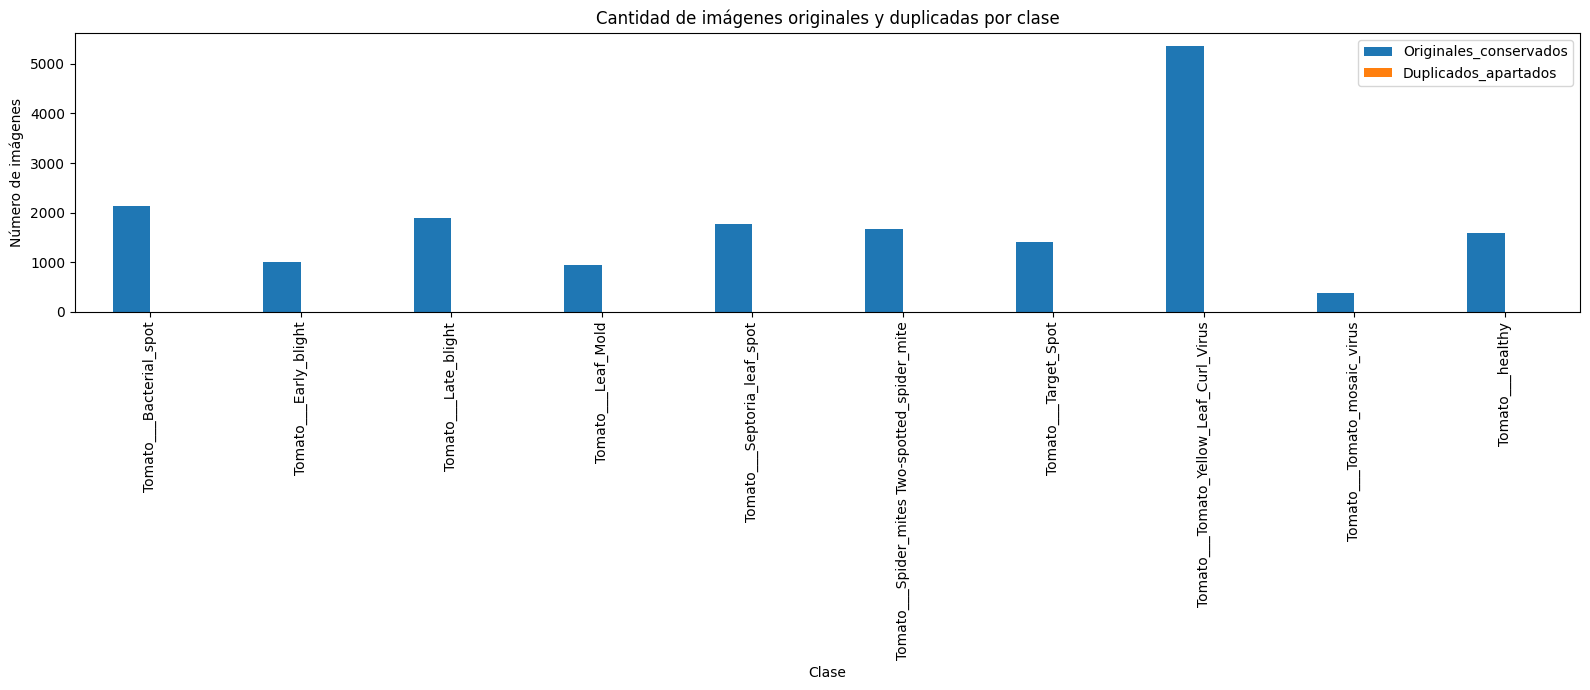

In [ ]:
# ============================================================
# BLOQUE 11
# VISUALIZACIÓN ORIGINALES VS DUPLICADOS
# ============================================================

import matplotlib.pyplot as plt


df_grafico = (
    df_comparacion
    .set_index("Clase")
    [
        [
            "Originales_conservados",
            "Duplicados_apartados"
        ]
    ]
)


ax = df_grafico.plot(
    kind="bar",
    figsize=(16, 7)
)


ax.set_title(
    "Cantidad de imágenes originales y duplicadas por clase"
)

ax.set_xlabel(
    "Clase"
)

ax.set_ylabel(
    "Número de imágenes"
)

plt.xticks(
    rotation=90
)

plt.tight_layout()

plt.show()

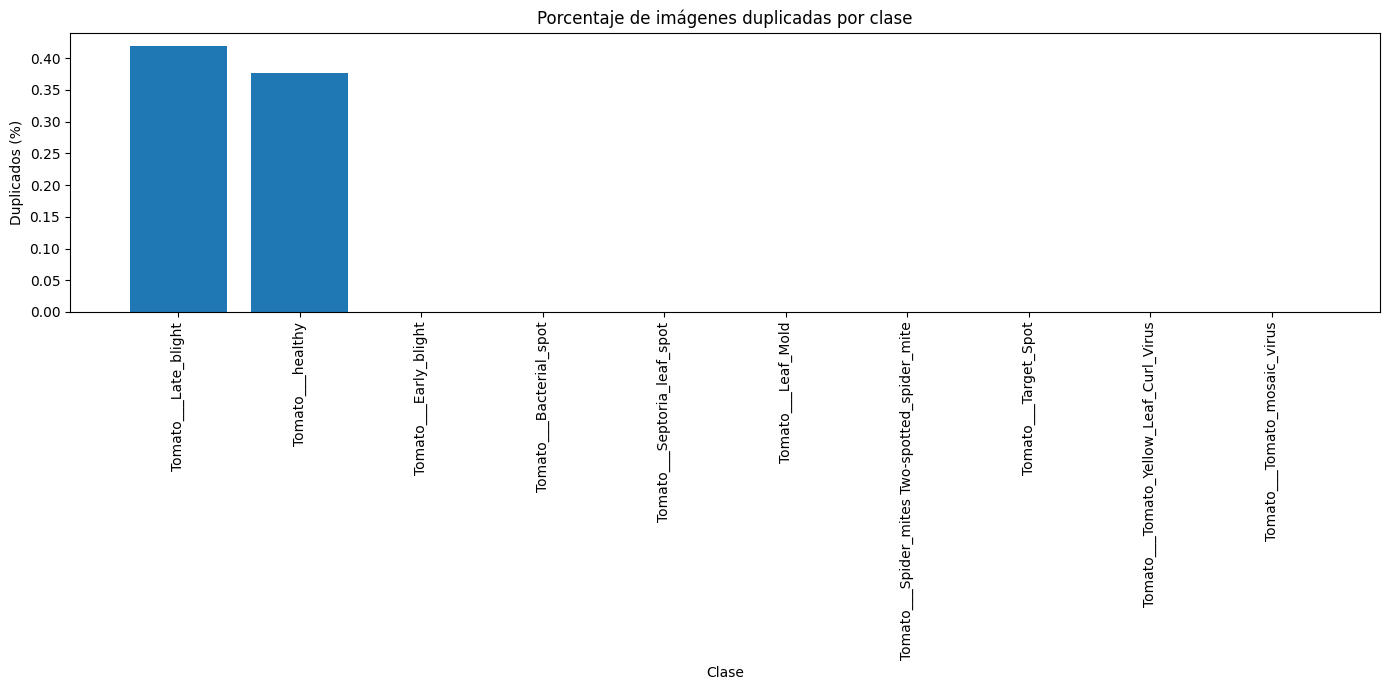

In [ ]:
# ============================================================
# BLOQUE 12
# PORCENTAJE DE DUPLICADOS POR CLASE
# ============================================================

df_porcentaje = (
    df_comparacion
    .sort_values(
        "Duplicados_%",
        ascending=False
    )
)


plt.figure(
    figsize=(14, 7)
)


plt.bar(
    df_porcentaje["Clase"],
    df_porcentaje["Duplicados_%"]
)


plt.title(
    "Porcentaje de imágenes duplicadas por clase"
)

plt.xlabel(
    "Clase"
)

plt.ylabel(
    "Duplicados (%)"
)

plt.xticks(
    rotation=90
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# BLOQUE 13
# EXPORTAR TABLA COMPARATIVA
# ============================================================

RUTA_REPORTE = (
    "/content/plantvillage/"
    "comparacion_originales_vs_duplicados.csv"
)


df_comparacion.to_csv(
    RUTA_REPORTE,
    index=False
)


print(
    "✅ Reporte guardado correctamente:"
)

print(RUTA_REPORTE)

✅ Reporte guardado correctamente:
/content/plantvillage/comparacion_originales_vs_duplicados.csv


# Fase 0 — Problemática y justificación de negocio

Esta sección resume fase 0 — Problemática y justificación de negocio y su función dentro del proyecto MLOps.

## 4.1 Preguntas que deben responderse

Antes de desarrollar el pipeline de Machine Learning, el servicio de inferencia y.

## 4.1.1 ¿Cuál es el problema real?

El problema consiste en clasificar automáticamente el estado sanitario de una.

## 4.1.2 ¿Quién utilizaría la predicción?

El notebook original define fundamentalmente el problema técnico de clasificación.

## 4.1.3 ¿Qué decisión permite tomar el modelo?

El modelo permite responder la siguiente pregunta.

## 4.1.4 ¿Cuál es el target?

La variable objetivo del proyecto corresponde a la.

## 4.1.5 ¿Corresponde a clasificación o regresión?

Esta sección resume ¿Corresponde a clasificación o regresión? y su función dentro del proyecto MLOps.

## Clasificación supervisada

Es un problema supervisado porque durante el entrenamiento se dispone de pares.

## Clasificación multiclase

Es multiclase porque existen más de dos categorías posibles.

## Etiqueta única

El problema es de etiqueta única porque cada imagen posee una única clase.

## Diferencia respecto de regresión

No corresponde a regresión porque la variable objetivo no es un valor numérico.

## 4.1.6 ¿En qué instante se realiza la inferencia?

La inferencia corresponde al instante en que un modelo previamente entrenado.

## 4.1.7 ¿Qué información está disponible en ese instante?

En el momento real de inferencia, la principal información disponible es.

## Información disponible

Esta sección resume información disponible y su función dentro del proyecto MLOps.

## Información que no debe estar disponible

La predicción debe depender exclusivamente de información disponible antes de.

## 4.1.8 ¿Cuál es el costo de una mala predicción?

El notebook no contiene una estimación monetaria o económica específica asociada.

## Caso 1 — Una hoja enferma es clasificada como saludable

Este tipo de error puede ser especialmente importante en un sistema utilizado.

## Caso 2 — Una hoja saludable es clasificada como enferma

Esta sección resume caso 2 — Una hoja saludable es clasificada como enferma y su función dentro del proyecto MLOps.

## Caso 3 — Confusión entre dos enfermedades

En este escenario el modelo identifica una categoría no saludable, pero asigna.

## 4.1.9 Síntesis de la definición operacional

La problemática puede resumirse mediante el siguiente flujo.


In [ ]:
# ============================================================
# FASE 0 — DEFINICIÓN OPERACIONAL DEL PROBLEMA
# 4.1 VERIFICACIÓN REPRODUCIBLE DE LOS DATOS
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Construir un DataFrame maestro a partir del DATASET LIMPIO
# y verificar las afirmaciones utilizadas en la definición
# operacional del problema.
#
# Esta celda:
#   1. NO entrena modelos.
#   2. NO utiliza información futura.
#   3. NO modifica ni mueve archivos.
#   4. NO supone todavía una resolución de modelado.
#   5. Construye df_maestro desde los archivos actualmente
#      presentes en PlantVillage después de apartar duplicados.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path
from PIL import Image
import pandas as pd

from IPython.display import display


# ============================================================
# 2. CONFIGURACIÓN DEL DATASET LIMPIO
# ============================================================

# Se reutiliza ORIGINALES_DIR si ya fue definido.
# En caso contrario, se utiliza la ruta principal del proyecto.
DATASET_LIMPIO_DIR = Path(
    globals().get(
        "ORIGINALES_DIR",
        globals().get(
            "BASE_DIR",
            "/content/plantvillage/PlantVillage"
        )
    )
)

EXTENSIONES_VALIDAS_FASE0 = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


if not DATASET_LIMPIO_DIR.exists():
    raise FileNotFoundError(
        "No se encontró el directorio del dataset limpio:\n"
        f"{DATASET_LIMPIO_DIR}\n\n"
        "Ejecute previamente las celdas de descarga, consolidación "
        "y separación de duplicados."
    )


# ============================================================
# 3. LOCALIZAR LAS IMÁGENES ACTUALMENTE CONSERVADAS
# ============================================================

rutas_imagenes_limpias = sorted(
    ruta
    for ruta in DATASET_LIMPIO_DIR.rglob("*")
    if (
        ruta.is_file()
        and ruta.suffix.lower() in EXTENSIONES_VALIDAS_FASE0
    )
)


if len(rutas_imagenes_limpias) == 0:
    raise RuntimeError(
        "El directorio del dataset limpio no contiene imágenes."
    )


# ============================================================
# 4. CONSTRUIR EL DATAFRAME MAESTRO
# ============================================================
#
# Se vuelve a leer únicamente la metadata necesaria para evitar
# utilizar df_integridad, ya que ese DataFrame fue creado ANTES
# de mover los 14 duplicados y conserva rutas históricas.
# ============================================================

registros_maestro = []


for ruta in rutas_imagenes_limpias:

    try:

        with Image.open(ruta) as img:

            # Número real de canales/bandas.
            canales = len(img.getbands())

            registros_maestro.append(
                {
                    "ruta": str(ruta),
                    "archivo": ruta.name,
                    "clase": ruta.parent.name,
                    "ancho": int(img.width),
                    "alto": int(img.height),
                    "canales": int(canales),
                    "modo": img.mode,
                    "formato": img.format
                }
            )

    except Exception as e:

        raise RuntimeError(
            "Se encontró una imagen que no pudo ser leída "
            "al construir df_maestro:\n"
            f"{ruta}\n"
            f"Error: {e}"
        ) from e


df_maestro = pd.DataFrame(registros_maestro)


# ============================================================
# 5. DEFINICIÓN DEL TARGET Y MAGNITUDES PRINCIPALES
# ============================================================

TARGET = "clase"

N = int(len(df_maestro))

K = int(
    df_maestro[TARGET]
    .nunique()
)

CLASES = sorted(
    df_maestro[TARGET]
    .dropna()
    .unique()
    .tolist()
)


# ============================================================
# 6. VERIFICACIONES DE CONSISTENCIA
# ============================================================

columnas_requeridas = {
    "ruta",
    "archivo",
    "clase",
    "ancho",
    "alto",
    "canales",
    "modo",
    "formato"
}

columnas_faltantes = (
    columnas_requeridas
    - set(df_maestro.columns)
)

if columnas_faltantes:
    raise KeyError(
        "Faltan columnas requeridas en df_maestro: "
        f"{sorted(columnas_faltantes)}"
    )


if df_maestro[TARGET].isna().any():
    raise ValueError(
        "Existen observaciones sin clase objetivo."
    )


if K < 2:
    raise ValueError(
        "Se requieren al menos dos clases para un "
        "problema de clasificación."
    )


# ============================================================
# 7. DIMENSIÓN PREDOMINANTE DE LAS IMÁGENES
# ============================================================

dimensiones = (
    df_maestro[
        [
            "ancho",
            "alto",
            "canales"
        ]
    ]
    .value_counts()
    .reset_index(name="cantidad")
    .sort_values(
        "cantidad",
        ascending=False
    )
    .reset_index(drop=True)
)

dimension_principal = dimensiones.iloc[0]

ANCHO_ORIGINAL = int(
    dimension_principal["ancho"]
)

ALTO_ORIGINAL = int(
    dimension_principal["alto"]
)

CANALES_ORIGINAL = int(
    dimension_principal["canales"]
)

CANTIDAD_DIMENSION_PRINCIPAL = int(
    dimension_principal["cantidad"]
)

PORCENTAJE_DIMENSION_PRINCIPAL = (
    CANTIDAD_DIMENSION_PRINCIPAL
    / N
    * 100
)


# ============================================================
# 8. TIPO DE PROBLEMA
# ============================================================

TIPO_PROBLEMA = (
    "Clasificación supervisada multiclase "
    "de etiqueta única"
)


# ============================================================
# 9. TABLA CONSOLIDADA DE RESPUESTAS
# ============================================================

resumen_fase0 = pd.DataFrame(
    {
        "Pregunta": [
            "¿Cuál es el problema real?",
            "¿Quién utilizaría la predicción?",
            "¿Qué decisión permite tomar el modelo?",
            "¿Cuál es el target?",
            "¿Clasificación o regresión?",
            "¿Cuándo ocurre la inferencia?",
            "¿Qué información está disponible?",
            "¿Cuál es el costo de una mala predicción?"
        ],

        "Respuesta": [
            (
                "Clasificar automáticamente el estado sanitario "
                "de una hoja de tomate a partir de una imagen."
            ),
            (
                "El notebook no fija un usuario único; el caso MLOps "
                "se plantea como apoyo a revisión fitosanitaria."
            ),
            (
                "Asignar una imagen nueva a una de las clases "
                "sanitarias conocidas y apoyar su priorización."
            ),
            TARGET,
            TIPO_PROBLEMA,
            (
                "Cuando llega una imagen nueva, después de entrenar "
                "el modelo y antes de conocer su etiqueta real."
            ),
            (
                "La imagen y las transformaciones que queden fijadas "
                "posteriormente en el pipeline de producción."
            ),
            (
                "No existe un costo monetario cuantificado en el "
                "notebook; el impacto depende del tipo de confusión "
                "y debe analizarse por clase."
            )
        ]
    }
)


# ============================================================
# 10. RESULTADOS
# ============================================================

print("=" * 90)
print("FASE 0 — 4.1 DEFINICIÓN OPERACIONAL DEL PROBLEMA")
print("=" * 90)

print(f"\nDataset limpio      : {DATASET_LIMPIO_DIR}")
print(f"Observaciones (N)   : {N:,}")
print(f"Número de clases (K): {K}")
print(f"Variable objetivo   : {TARGET}")
print(f"Tipo de problema    : {TIPO_PROBLEMA}")

print(
    "\nDimensión predominante "
    "(ancho × alto × canales): "
    f"{ANCHO_ORIGINAL} × "
    f"{ALTO_ORIGINAL} × "
    f"{CANALES_ORIGINAL}"
)

print(
    "Cobertura de la dimensión predominante: "
    f"{PORCENTAJE_DIMENSION_PRINCIPAL:.2f}%"
)

print("\n" + "=" * 90)
print("CLASES DETECTADAS")
print("=" * 90)

for indice, clase in enumerate(CLASES, start=1):
    print(f"{indice:02d}. {clase}")

print("\n" + "=" * 90)
print("RESPUESTAS CONSOLIDADAS")
print("=" * 90)

display(
    resumen_fase0.style
    .hide(axis="index")
    .set_caption(
        "Fase 0 — Definición operacional del problema"
    )
)


# ============================================================
# 11. CONTROL ESPERADO PARA ESTA VERSIÓN DEL DATASET
# ============================================================
#
# Estos asserts sirven como alarma si el dataset cambia.
# Si en una versión futura se agregan o eliminan datos,
# deben revisarse conscientemente.
# ============================================================

assert N == 18146, (
    f"Se esperaban 18,146 imágenes limpias, pero se encontraron {N:,}."
)

assert K == 10, (
    f"Se esperaban 10 clases, pero se encontraron {K}."
)

assert (
    ANCHO_ORIGINAL == 256
    and ALTO_ORIGINAL == 256
    and CANALES_ORIGINAL == 3
), (
    "La dimensión predominante ya no coincide con 256 × 256 × 3."
)

print("\n✅ Verificación completada sin inconsistencias.")


FASE 0 — 4.1 DEFINICIÓN OPERACIONAL DEL PROBLEMA

Dataset limpio      : /content/plantvillage/PlantVillage
Observaciones (N)   : 18,146
Número de clases (K): 10
Variable objetivo   : clase
Tipo de problema    : Clasificación supervisada multiclase de etiqueta única

Dimensión predominante (ancho × alto × canales): 256 × 256 × 3
Cobertura de la dimensión predominante: 100.00%

CLASES DETECTADAS
01. Tomato___Bacterial_spot
02. Tomato___Early_blight
03. Tomato___Late_blight
04. Tomato___Leaf_Mold
05. Tomato___Septoria_leaf_spot
06. Tomato___Spider_mites Two-spotted_spider_mite
07. Tomato___Target_Spot
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus
09. Tomato___Tomato_mosaic_virus
10. Tomato___healthy

RESPUESTAS CONSOLIDADAS


Pregunta,Respuesta
¿Cuál es el problema real?,Clasificar automáticamente el estado sanitario de una hoja de tomate a partir de una imagen.
¿Quién utilizaría la predicción?,El notebook no fija un usuario único; el caso MLOps se plantea como apoyo a revisión fitosanitaria.
¿Qué decisión permite tomar el modelo?,Asignar una imagen nueva a una de las clases sanitarias conocidas y apoyar su priorización.
¿Cuál es el target?,clase
¿Clasificación o regresión?,Clasificación supervisada multiclase de etiqueta única
¿Cuándo ocurre la inferencia?,"Cuando llega una imagen nueva, después de entrenar el modelo y antes de conocer su etiqueta real."
¿Qué información está disponible?,La imagen y las transformaciones que queden fijadas posteriormente en el pipeline de producción.
¿Cuál es el costo de una mala predicción?,No existe un costo monetario cuantificado en el notebook; el impacto depende del tipo de confusión y debe analizarse por clase.



✅ Verificación completada sin inconsistencias.


## 4.2 Formulación de Machine Learning

Una vez definido el problema operacional, se formaliza matemáticamente como una.

## 4.2.1 Conjunto de datos supervisado

El conjunto de datos puede representarse como.

## 4.2.2 Espacio de entrada

Las imágenes auditadas previamente poseen una dimensión predominante de.

## 4.2.3 Espacio de salida

Esta sección resume espacio de salida y su función dentro del proyecto MLOps.

## 4.2.4 Formulación probabilística

En clasificación multiclase es útil expresar la salida del modelo como un vector.

## 4.2.5 Formulación completa del problema

La formulación puede separarse en dos funciones.

## 4.2.6 Objetivo del aprendizaje

Durante el entrenamiento se conocen tanto la imagen como su etiqueta.

## 4.2.7 Inferencia sobre una observación nueva

Una vez entrenado el modelo, para una nueva imagen.

## 4.2.8 Relación con el futuro sistema MLOps

Esta formulación también determina qué deberá realizar posteriormente el servicio.

## 4.2.9 Síntesis matemática

La formulación completa del problema queda definida como.


In [ ]:
# ============================================================
# FASE 0 — PROBLEMÁTICA Y JUSTIFICACIÓN DE NEGOCIO
# 4.2 FORMULACIÓN DE MACHINE LEARNING
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Formalizar computacionalmente el problema:
#
#                   f(X) -> y_hat
#
# utilizando exclusivamente la información ya auditada en
# el notebook.
#
# Esta celda:
#
#   1. NO entrena ningún modelo.
#   2. NO divide todavía Train / Validation / Test.
#   3. NO normaliza las imágenes.
#   4. NO fija una arquitectura.
#   5. NO modifica el dataset.
#   6. Verifica el dominio de entrada y el espacio de salida.
#
# La selección del modelo y del preprocesamiento corresponde
# posteriormente a la Fase 2 — Modelado.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd

from IPython.display import display


# ============================================================
# 2. VERIFICAR DEPENDENCIAS DE LA FASE ANTERIOR
# ============================================================

if "df_maestro" not in globals():

    raise NameError(
        "No se encontró 'df_maestro'.\n\n"
        "Ejecute previamente la celda 4.1 de verificación "
        "reproducible del dataset."
    )


if "TARGET" not in globals():

    TARGET = "clase"


# ============================================================
# 3. EXTRAER MAGNITUDES DEL PROBLEMA
# ============================================================

N = int(
    len(df_maestro)
)


CLASES = sorted(
    df_maestro[TARGET]
    .dropna()
    .unique()
    .tolist()
)


K = int(
    len(CLASES)
)


# ============================================================
# 4. VALIDAR ESTRUCTURA DEL PROBLEMA
# ============================================================

if N == 0:

    raise ValueError(
        "El dataset no contiene observaciones."
    )


if K < 2:

    raise ValueError(
        "El target contiene menos de dos clases."
    )


if df_maestro[TARGET].isna().any():

    raise ValueError(
        "Existen observaciones sin etiqueta."
    )


# ============================================================
# 5. CREAR CODIFICACIÓN CLASE <-> ÍNDICE
# ============================================================
#
# Esta codificación NO modifica df_maestro.
#
# Se crea únicamente para representar matemáticamente:
#
#       c_k <-> k
#
# donde:
#
#       k = 0, 1, ..., K-1
#
# ============================================================

clase_a_indice = {
    clase: indice
    for indice, clase in enumerate(CLASES)
}


indice_a_clase = {
    indice: clase
    for clase, indice in clase_a_indice.items()
}


# ============================================================
# 6. CONSTRUIR VECTOR y CODIFICADO
# ============================================================
#
# y contiene las etiquetas numéricas:
#
#       y_i in {0, 1, ..., K-1}
#
# El DataFrame original permanece sin modificación.
# ============================================================

y_indices = (
    df_maestro[TARGET]
    .map(clase_a_indice)
    .to_numpy(dtype=np.int64)
)


# ============================================================
# 7. VALIDAR LA CODIFICACIÓN
# ============================================================

assert len(y_indices) == N

assert y_indices.min() == 0

assert y_indices.max() == K - 1

assert len(np.unique(y_indices)) == K


# ============================================================
# 8. VERIFICAR DIMENSIÓN PREDOMINANTE
# ============================================================
#
# Todavía NO se cargan todas las imágenes en RAM.
#
# Se utiliza únicamente la metadata previamente auditada.
# Esto evita consumir memoria innecesariamente.
# ============================================================

dimensiones = (
    df_maestro[
        [
            "ancho",
            "alto",
            "canales"
        ]
    ]
    .value_counts()
    .reset_index(name="cantidad")
    .sort_values(
        "cantidad",
        ascending=False
    )
    .reset_index(drop=True)
)


dimension_principal = (
    dimensiones.iloc[0]
)


ANCHO = int(
    dimension_principal["ancho"]
)

ALTO = int(
    dimension_principal["alto"]
)

CANALES = int(
    dimension_principal["canales"]
)


# ============================================================
# 9. FORMULACIÓN COMPUTACIONAL
# ============================================================
#
# El problema queda definido como:
#
#       X_i -> f_theta -> p_i -> argmax -> y_hat_i
#
# con:
#
#       X_i : imagen
#       p_i : vector de K probabilidades
#       y_hat_i : clase predicha
#
# En esta fase todavía NO existe f_theta entrenada.
# ============================================================

formulacion = {
    "numero_observaciones": N,
    "numero_clases": K,
    "target": TARGET,
    "tipo_problema": (
        "Clasificación supervisada multiclase "
        "de etiqueta única"
    ),
    "entrada_original": (
        f"Imagen RGB {ANCHO} × {ALTO} × {CANALES}"
    ),
    "dominio_pixel_original": "[0, 255]",
    "salida": (
        f"Una de {K} clases sanitarias"
    ),
    "formulacion": (
        "f_theta(X) -> y_hat"
    )
}


df_formulacion = pd.DataFrame(
    {
        "Elemento": [
            "Número de observaciones",
            "Número de clases",
            "Variable objetivo",
            "Tipo de problema",
            "Entrada X",
            "Salida y_hat",
            "Función"
        ],

        "Definición": [
            f"{N:,}",
            K,
            TARGET,
            formulacion["tipo_problema"],
            formulacion["entrada_original"],
            formulacion["salida"],
            formulacion["formulacion"]
        ]
    }
)


# ============================================================
# 10. TABLA CLASE <-> ÍNDICE
# ============================================================

df_clases_ml = pd.DataFrame(
    {
        "indice": list(
            range(K)
        ),

        "clase": [
            indice_a_clase[i]
            for i in range(K)
        ]
    }
)


# ============================================================
# 11. MOSTRAR RESULTADOS
# ============================================================

print("=" * 90)

print(
    "FASE 0 — 4.2 FORMULACIÓN "
    "DE MACHINE LEARNING"
)

print("=" * 90)


print(
    f"\nNúmero de observaciones (N): "
    f"{N:,}"
)

print(
    f"Número de clases (K)       : "
    f"{K}"
)

print(
    f"Variable objetivo          : "
    f"{TARGET}"
)

print(
    f"Dimensión predominante     : "
    f"{ANCHO} × {ALTO} × {CANALES}"
)


print(
    "\nFormulación:"
)

print(
    "X -> f_theta -> "
    "probabilidades -> argmax -> y_hat"
)


print(
    "\nFormalmente:"
)

print(
    "f_theta(X) -> y_hat"
)


# ============================================================
# 12. MOSTRAR TABLA RESUMEN
# ============================================================

display(
    df_formulacion.style
    .hide(axis="index")
    .set_caption(
        "Formulación computacional "
        "del problema de Machine Learning"
    )
)


# ============================================================
# 13. MOSTRAR MAPEO DE CLASES
# ============================================================

display(
    df_clases_ml.style
    .hide(axis="index")
    .set_caption(
        "Correspondencia entre índices "
        "y clases sanitarias"
    )
)


# ============================================================
# 14. CONTROLES DE CONSISTENCIA DEL PROYECTO
# ============================================================
#
# Estos asserts actúan como alarmas si cambia el dataset.
# No constituyen parámetros del modelo.
# ============================================================

assert N == 18146, (
    "El número de observaciones cambió. "
    f"Valor actual: {N:,}"
)


assert K == 10, (
    "El número de clases cambió. "
    f"Valor actual: {K}"
)


assert (
    ANCHO == 256
    and
    ALTO == 256
    and
    CANALES == 3
), (
    "La dimensión predominante de las imágenes "
    "ya no coincide con 256 × 256 × 3."
)


print(
    "\n✅ Formulación de Machine Learning "
    "verificada correctamente."
)

FASE 0 — 4.2 FORMULACIÓN DE MACHINE LEARNING

Número de observaciones (N): 18,146
Número de clases (K)       : 10
Variable objetivo          : clase
Dimensión predominante     : 256 × 256 × 3

Formulación:
X -> f_theta -> probabilidades -> argmax -> y_hat

Formalmente:
f_theta(X) -> y_hat


Elemento,Definición
Número de observaciones,"18,146"
Número de clases,10
Variable objetivo,clase
Tipo de problema,Clasificación supervisada multiclase de etiqueta única
Entrada X,Imagen RGB 256 × 256 × 3
Salida y_hat,Una de 10 clases sanitarias
Función,f_theta(X) -> y_hat


indice,clase
0,Tomato___Bacterial_spot
1,Tomato___Early_blight
2,Tomato___Late_blight
3,Tomato___Leaf_Mold
4,Tomato___Septoria_leaf_spot
5,Tomato___Spider_mites Two-spotted_spider_mite
6,Tomato___Target_Spot
7,Tomato___Tomato_Yellow_Leaf_Curl_Virus
8,Tomato___Tomato_mosaic_virus
9,Tomato___healthy



✅ Formulación de Machine Learning verificada correctamente.


## 4.3 Justificación de *data drift*

Una vez formalizado el problema de Machine Learning, es necesario justificar por qué.

## 4.3.1 Definición de *data drift*

Durante el entrenamiento, las imágenes pueden considerarse provenientes de una.

## 4.3.2 Relación entre drift y la función de predicción

Esta sección resume relación entre drift y la función de predicción y su función dentro del proyecto MLOps.

## 4.3.3 Estacionalidad

La estacionalidad corresponde a cambios sistemáticos asociados al tiempo.

## Limitación del dataset actual

El DataFrame construido hasta esta etapa no contiene una variable temporal que.

## 4.3.4 Cambios de comportamiento

En un sistema basado en imágenes, los cambios de comportamiento no se refieren.

## Limitación actual

El notebook no contiene identificadores de operadores ni información sobre el.

## 4.3.5 Promociones, campañas o shocks externos

El término promociones es más natural en problemas comerciales.

## Limitación actual

El dataset procesado no contiene una variable que identifique campañas o shocks.

## 4.3.6 Cambios regulatorios o tecnológicos

Un cambio tecnológico puede modificar directamente la distribución de entrada del.

## Limitación actual

El notebook no contiene variables regulatorias.

## 4.3.7 Variaciones en la composición de usuarios o clientes

En este proyecto no existe una variable denominada usuario o cliente.

## 4.3.8 Cambios en los procesos de captura de datos

Este es uno de los riesgos de drift más importantes para un problema basado en.

## 4.3.9 Drift en la composición de clases

Esta sección resume drift en la composición de clases y su función dentro del proyecto MLOps.

## 4.3.10 Diferencia entre data drift y concept drift

Debe distinguirse el cambio en las entradas del cambio en la relación entre entrada.

## Data drift

El modelo recibe observaciones diferentes.

## Concept drift

La relación entre las características observadas y la etiqueta cambia.

## 4.3.11 Variables que podrán utilizarse como referencia de drift

Con la información disponible actualmente pueden establecerse como mínimo dos.

## A. Distribución de clases

La distribución de referencia puede definirse como.

## B. Propiedades técnicas de las imágenes

El DataFrame maestro contiene información que permite construir una referencia de.

## 4.3.12 Qué puede demostrarse actualmente y qué no

A partir del notebook actual puede demostrarse.

## 4.3.13 Hipótesis de monitoreo para las fases posteriores

A partir del análisis anterior se definen las siguientes hipótesis.

## H1 — Drift de captura

debido a cambios en iluminación, brillo, contraste, resolución o procedimiento de.

## H2 — Drift de composición

debido a cambios en la frecuencia de las clases recibidas.

## H3 — Drift tecnológico

donde representa metadatos técnicos tales como resolución, canales o formato.

## H4 — Drift de predicciones

como señal indirecta de cambios en los datos que llegan al modelo.

## 4.3.14 Justificación final

El problema seleccionado es pertinente para un sistema de monitoreo MLOps porque.


In [ ]:
# ============================================================
# FASE 0 — PROBLEMÁTICA Y JUSTIFICACIÓN DE NEGOCIO
# 4.3 JUSTIFICACIÓN DE DATA DRIFT
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Construir una referencia descriptiva de las variables que
# actualmente pueden utilizarse para justificar y preparar
# el monitoreo de drift.
#
# Esta celda:
#
#   1. NO afirma que exista drift actualmente.
#   2. NO simula todavía producción.
#   3. NO calcula PSI, KS-test ni Chi-cuadrado.
#   4. NO entrena modelos.
#   5. NO modifica df_maestro.
#   6. Documenta qué riesgos son observables y cuáles son
#      únicamente hipótesis para producción.
#
# La medición formal de drift se realizará en la Fase 4.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd

from IPython.display import display


# ============================================================
# 2. VERIFICAR DATAFRAME MAESTRO
# ============================================================

if "df_maestro" not in globals():

    raise NameError(
        "No se encontró 'df_maestro'.\n\n"
        "Ejecute previamente las celdas 4.1 y 4.2."
    )


# ============================================================
# 3. COLUMNAS MÍNIMAS ESPERADAS
# ============================================================

columnas_minimas = {
    "clase",
    "ancho",
    "alto",
    "canales"
}


columnas_faltantes = (
    columnas_minimas
    -
    set(df_maestro.columns)
)


if columnas_faltantes:

    raise KeyError(
        "Faltan columnas necesarias para construir "
        "la referencia de drift: "
        f"{sorted(columnas_faltantes)}"
    )


# ============================================================
# 4. MAGNITUDES GENERALES DE REFERENCIA
# ============================================================

N_REF = int(
    len(df_maestro)
)


K_REF = int(
    df_maestro["clase"]
    .nunique()
)


# ============================================================
# 5. DISTRIBUCIÓN DE REFERENCIA DE LAS CLASES
# ============================================================
#
# Esta tabla permitirá posteriormente comparar:
#
#       P_ref(Y)
#
# con:
#
#       P_prod(Y)
#
# o, si todavía no existe etiqueta verdadera:
#
#       P_prod(y_hat)
# ============================================================

df_referencia_clases = (
    df_maestro["clase"]
    .value_counts()
    .rename_axis("clase")
    .reset_index(name="cantidad")
)


df_referencia_clases["proporcion"] = (
    df_referencia_clases["cantidad"]
    / N_REF
)


df_referencia_clases["porcentaje"] = (
    df_referencia_clases["proporcion"]
    * 100
)


# Orden alfabético para mantener una referencia reproducible.
df_referencia_clases = (
    df_referencia_clases
    .sort_values("clase")
    .reset_index(drop=True)
)


# ============================================================
# 6. DISTRIBUCIÓN DE REFERENCIA DE DIMENSIONES
# ============================================================
#
# Permite monitorear cambios tecnológicos o de captura:
#
#       ancho
#       alto
#       canales
# ============================================================

df_referencia_dimensiones = (
    df_maestro[
        [
            "ancho",
            "alto",
            "canales"
        ]
    ]
    .value_counts()
    .rename("cantidad")
    .reset_index()
)


df_referencia_dimensiones["proporcion"] = (
    df_referencia_dimensiones["cantidad"]
    / N_REF
)


df_referencia_dimensiones["porcentaje"] = (
    df_referencia_dimensiones["proporcion"]
    * 100
)


df_referencia_dimensiones = (
    df_referencia_dimensiones
    .sort_values(
        "cantidad",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 7. VARIABLES TÉCNICAS OPCIONALES
# ============================================================
#
# En la versión corregida de df_maestro pueden existir:
#
#       modo
#       formato
#
# Si existen, se genera también su distribución.
# ============================================================

columnas_tecnicas_opcionales = [
    columna
    for columna in [
        "modo",
        "formato"
    ]
    if columna in df_maestro.columns
]


referencias_tecnicas = {}


for columna in columnas_tecnicas_opcionales:

    tabla = (
        df_maestro[columna]
        .fillna("DESCONOCIDO")
        .value_counts()
        .rename_axis(columna)
        .reset_index(name="cantidad")
    )

    tabla["proporcion"] = (
        tabla["cantidad"]
        / N_REF
    )

    tabla["porcentaje"] = (
        tabla["proporcion"]
        * 100
    )

    referencias_tecnicas[columna] = tabla


# ============================================================
# 8. BUSCAR VARIABLES TEMPORALES
# ============================================================
#
# La ausencia de timestamp impide afirmar que actualmente
# exista evidencia empírica de estacionalidad.
# ============================================================

nombres_temporales_posibles = {
    "fecha",
    "date",
    "datetime",
    "timestamp",
    "time",
    "año",
    "anio",
    "mes",
    "dia",
    "día"
}


columnas_temporales = [
    columna
    for columna in df_maestro.columns
    if columna.lower() in nombres_temporales_posibles
]


TIENE_EJE_TEMPORAL = (
    len(columnas_temporales) > 0
)


# ============================================================
# 9. BUSCAR VARIABLES DE USUARIO / FUENTE
# ============================================================
#
# Si no existen, los cambios de composición de usuarios
# deberán tratarse como hipótesis operacionales.
# ============================================================

nombres_fuente_posibles = {
    "usuario",
    "user",
    "cliente",
    "client",
    "operador",
    "operator",
    "fuente",
    "source",
    "camara",
    "camera",
    "dispositivo",
    "device",
    "ubicacion",
    "location"
}


columnas_fuente = [
    columna
    for columna in df_maestro.columns
    if columna.lower() in nombres_fuente_posibles
]


TIENE_VARIABLE_FUENTE = (
    len(columnas_fuente) > 0
)


# ============================================================
# 10. MATRIZ DE JUSTIFICACIÓN DE RIESGOS
# ============================================================
#
# IMPORTANTE:
#
# "Observable actualmente" significa que el notebook contiene
# variables que permiten construir una referencia.
#
# "Hipótesis" significa que el factor es plausible para
# producción, pero NO ha sido observado en este dataset.
# ============================================================

matriz_riesgos_drift = pd.DataFrame(
    {
        "Factor": [

            "Estacionalidad",

            "Cambios de comportamiento",

            "Función f_theta(X) -> y_hat",

            "Campañas / shocks externos",

            "Cambios tecnológicos",

            "Cambios regulatorios",

            "Composición de usuarios o fuentes",

            "Proceso de captura",

            "Composición de clases"
        ],

        "Estado en datos actuales": [

            (
                "Observable"
                if TIENE_EJE_TEMPORAL
                else "Hipótesis"
            ),

            "Hipótesis",

            "Relación del modelo, no causa de drift",

            "Hipótesis",

            "Parcialmente observable",

            "Hipótesis",

            (
                "Parcialmente observable"
                if TIENE_VARIABLE_FUENTE
                else "Hipótesis"
            ),

            "Parcialmente observable",

            "Observable"
        ],

        "Mecanismo potencial": [

            (
                "La distribución puede cambiar entre "
                "períodos de producción."
            ),

            (
                "Los operadores pueden cambiar la forma "
                "de seleccionar o capturar imágenes."
            ),

            (
                "Si cambia P(X), una función fija puede "
                "producir una distribución distinta de y_hat."
            ),

            (
                "Eventos externos pueden cambiar la "
                "frecuencia de clases o tipos de imágenes."
            ),

            (
                "Resolución, canales, formato o dispositivo "
                "pueden cambiar."
            ),

            (
                "Nuevos protocolos pueden modificar qué "
                "datos llegan al sistema."
            ),

            (
                "Nuevos operadores o fuentes pueden cambiar "
                "la composición de las observaciones."
            ),

            (
                "Iluminación, enfoque, contraste, escala, "
                "fondo o resolución pueden cambiar."
            ),

            (
                "Las frecuencias relativas de las clases "
                "pueden cambiar en producción."
            )
        ],

        "Variable / señal futura": [

            (
                ", ".join(columnas_temporales)
                if TIENE_EJE_TEMPORAL
                else "timestamp futuro / ventana"
            ),

            (
                "estadísticas visuales + "
                "metadatos de captura"
            ),

            (
                "distribución de probabilidades "
                "y clases predichas"
            ),

            (
                "ventana / evento / distribución de clases"
            ),

            (
                "ancho, alto, canales, modo, formato"
            ),

            (
                "versión de protocolo / fuente"
            ),

            (
                ", ".join(columnas_fuente)
                if TIENE_VARIABLE_FUENTE
                else "fuente / operador / dispositivo"
            ),

            (
                "brillo, contraste, RGB, nitidez, "
                "resolución"
            ),

            (
                "clase real o clase predicha"
            )
        ]
    }
)


# ============================================================
# 11. CREAR RESUMEN DE REFERENCIA
# ============================================================

dimension_principal = (
    df_referencia_dimensiones.iloc[0]
)


resumen_referencia_drift = pd.DataFrame(
    {
        "Indicador": [

            "Número de observaciones",

            "Número de clases",

            "Dimensión predominante",

            "Variables temporales disponibles",

            "Variables de fuente disponibles",

            "Conclusión de esta fase"
        ],

        "Valor": [

            f"{N_REF:,}",

            K_REF,

            (
                f"{int(dimension_principal['ancho'])} × "
                f"{int(dimension_principal['alto'])} × "
                f"{int(dimension_principal['canales'])}"
            ),

            (
                ", ".join(columnas_temporales)
                if TIENE_EJE_TEMPORAL
                else "No detectadas"
            ),

            (
                ", ".join(columnas_fuente)
                if TIENE_VARIABLE_FUENTE
                else "No detectadas"
            ),

            (
                "Se construye baseline de referencia; "
                "todavía no se afirma existencia de drift."
            )
        ]
    }
)


# ============================================================
# 12. VALIDACIONES
# ============================================================

assert N_REF == 18146, (
    "Cambió el número de observaciones del dataset limpio. "
    f"Valor actual: {N_REF:,}"
)


assert K_REF == 10, (
    "Cambió el número de clases. "
    f"Valor actual: {K_REF}"
)


assert np.isclose(
    df_referencia_clases["proporcion"].sum(),
    1.0
), (
    "Las proporciones de clase no suman 1."
)


# ============================================================
# 13. MOSTRAR RESULTADOS
# ============================================================

print("=" * 90)

print(
    "FASE 0 — 4.3 JUSTIFICACIÓN DE DATA DRIFT"
)

print("=" * 90)


print(
    f"\nObservaciones de referencia : {N_REF:,}"
)

print(
    f"Número de clases            : {K_REF}"
)

print(
    "Eje temporal disponible    : "
    f"{'Sí' if TIENE_EJE_TEMPORAL else 'No'}"
)

print(
    "Variable de fuente/usuario : "
    f"{'Sí' if TIENE_VARIABLE_FUENTE else 'No'}"
)


print(
    "\nConclusión metodológica:"
)

print(
    "Esta celda define la referencia y los riesgos "
    "de drift; NO demuestra todavía que exista drift."
)


# ============================================================
# 14. TABLA RESUMEN
# ============================================================

display(
    resumen_referencia_drift.style
    .hide(axis="index")
    .set_caption(
        "Baseline descriptivo para el futuro "
        "monitoreo de drift"
    )
)


# ============================================================
# 15. DISTRIBUCIÓN DE CLASES
# ============================================================

display(
    df_referencia_clases.style
    .hide(axis="index")
    .format(
        {
            "proporcion": "{:.4f}",
            "porcentaje": "{:.2f}%"
        }
    )
    .set_caption(
        "Distribución de referencia de las clases"
    )
)


# ============================================================
# 16. DISTRIBUCIÓN DE DIMENSIONES
# ============================================================

display(
    df_referencia_dimensiones.head(10).style
    .hide(axis="index")
    .format(
        {
            "proporcion": "{:.4f}",
            "porcentaje": "{:.2f}%"
        }
    )
    .set_caption(
        "Principales configuraciones de "
        "ancho × alto × canales"
    )
)


# ============================================================
# 17. MATRIZ DE RIESGOS
# ============================================================

display(
    matriz_riesgos_drift.style
    .hide(axis="index")
    .set_caption(
        "Matriz de justificación de riesgos de data drift"
    )
)


# ============================================================
# 18. VARIABLES TÉCNICAS OPCIONALES
# ============================================================

for nombre_variable, tabla in referencias_tecnicas.items():

    display(
        tabla.style
        .hide(axis="index")
        .format(
            {
                "proporcion": "{:.4f}",
                "porcentaje": "{:.2f}%"
            }
        )
        .set_caption(
            f"Distribución de referencia: {nombre_variable}"
        )
    )


print(
    "\n✅ Baseline descriptivo de drift "
    "construido correctamente."
)

FASE 0 — 4.3 JUSTIFICACIÓN DE DATA DRIFT

Observaciones de referencia : 18,146
Número de clases            : 10
Eje temporal disponible    : No
Variable de fuente/usuario : No

Conclusión metodológica:
Esta celda define la referencia y los riesgos de drift; NO demuestra todavía que exista drift.


Indicador,Valor
Número de observaciones,"18,146"
Número de clases,10
Dimensión predominante,256 × 256 × 3
Variables temporales disponibles,No detectadas
Variables de fuente disponibles,No detectadas
Conclusión de esta fase,Se construye baseline de referencia; todavía no se afirma existencia de drift.


clase,cantidad,proporcion,porcentaje
Tomato___Bacterial_spot,2127,0.1172,11.72%
Tomato___Early_blight,1000,0.0551,5.51%
Tomato___Late_blight,1901,0.1048,10.48%
Tomato___Leaf_Mold,952,0.0525,5.25%
Tomato___Septoria_leaf_spot,1771,0.0976,9.76%
Tomato___Spider_mites Two-spotted_spider_mite,1676,0.0924,9.24%
Tomato___Target_Spot,1404,0.0774,7.74%
Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357,0.2952,29.52%
Tomato___Tomato_mosaic_virus,373,0.0206,2.06%
Tomato___healthy,1585,0.0873,8.73%


ancho,alto,canales,cantidad,proporcion,porcentaje
256,256,3,18146,1.0000,100.00%


Factor,Estado en datos actuales,Mecanismo potencial,Variable / señal futura
Estacionalidad,Hipótesis,La distribución puede cambiar entre períodos de producción.,timestamp futuro / ventana
Cambios de comportamiento,Hipótesis,Los operadores pueden cambiar la forma de seleccionar o capturar imágenes.,estadísticas visuales + metadatos de captura
Función f_theta(X) -> y_hat,"Relación del modelo, no causa de drift","Si cambia P(X), una función fija puede producir una distribución distinta de y_hat.",distribución de probabilidades y clases predichas
Campañas / shocks externos,Hipótesis,Eventos externos pueden cambiar la frecuencia de clases o tipos de imágenes.,ventana / evento / distribución de clases
Cambios tecnológicos,Parcialmente observable,"Resolución, canales, formato o dispositivo pueden cambiar.","ancho, alto, canales, modo, formato"
Cambios regulatorios,Hipótesis,Nuevos protocolos pueden modificar qué datos llegan al sistema.,versión de protocolo / fuente
Composición de usuarios o fuentes,Hipótesis,Nuevos operadores o fuentes pueden cambiar la composición de las observaciones.,fuente / operador / dispositivo
Proceso de captura,Parcialmente observable,"Iluminación, enfoque, contraste, escala, fondo o resolución pueden cambiar.","brillo, contraste, RGB, nitidez, resolución"
Composición de clases,Observable,Las frecuencias relativas de las clases pueden cambiar en producción.,clase real o clase predicha


modo,cantidad,proporcion,porcentaje
RGB,18146,1.0000,100.00%


formato,cantidad,proporcion,porcentaje
JPEG,18146,1.0000,100.00%



✅ Baseline descriptivo de drift construido correctamente.


## 4.4 Distinción conceptual entre *Data Drift* y *Concept Drift*

En un sistema de Machine Learning desplegado en producción es fundamental distinguir.

## 4.4.1 Distribución de referencia

Durante el desarrollo del modelo se dispone de un conjunto de datos de referencia.

## 4.4.2 Data Drift

Se denomina Data Drift al cambio en la distribución estadística de las variables.

## Ejemplo conceptual de Data Drift

Supóngase que durante entrenamiento las imágenes fueron capturadas principalmente.

## 4.4.3 Concept Drift

El Concept Drift corresponde a un fenómeno diferente.

## Ejemplo conceptual de Concept Drift

Esta sección resume ejemplo conceptual de Concept Drift y su función dentro del proyecto MLOps.

## 4.4.4 Comparación directa

Esta sección resume comparación directa y su función dentro del proyecto MLOps.

## 4.4.5 Relación con la función de Machine Learning

La formulación del modelo definida previamente es.

## Bajo Data Drift

Esta sección resume bajo Data Drift y su función dentro del proyecto MLOps.

## Bajo Concept Drift

Esta sección resume bajo Concept Drift y su función dentro del proyecto MLOps.

## 4.4.6 Drift de predicciones

También debe distinguirse un tercer indicador útil para monitoreo.

## 4.4.7 Qué puede monitorearse con los datos actuales

El DataFrame maestro construido previamente contiene información sobre.

## 4.4.8 Qué no puede demostrarse todavía

Con el dataset actual puede construirse una referencia, pero todavía no existe.

## 4.4.9 Detección de Data Drift

Para detectar Data Drift no siempre es necesario conocer inmediatamente el target.

## 4.4.10 Detección de Concept Drift

Concept Drift requiere evaluar la relación.

## 4.4.11 Implicancia para el diseño MLOps

La distinción anterior determina qué debe monitorear el futuro sistema.

## Nivel 1 — Datos de entrada

Esta sección resume nivel 1 — Datos de entrada y su función dentro del proyecto MLOps.

## Nivel 2 — Predicciones

para detectar cambios en el comportamiento del sistema.

## Nivel 3 — Performance

Cuando estén disponibles las etiquetas reales.

## Nivel 4 — Relación entrada-target

Esta sección resume nivel 4 — Relación entrada-target y su función dentro del proyecto MLOps.

## 4.4.12 Síntesis conceptual

Esta sección resume síntesis conceptual y su función dentro del proyecto MLOps.


In [ ]:
# ============================================================
# FASE 0 — PROBLEMÁTICA Y JUSTIFICACIÓN DE NEGOCIO
# 4.4 DISTINCIÓN CONCEPTUAL:
#     DATA DRIFT vs. CONCEPT DRIFT
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Documentar computacionalmente la diferencia entre:
#
#   1. Data Drift:
#
#          P_ref(X) != P_prod(X)
#
#   2. Concept Drift:
#
#          P_ref(Y | X) != P_prod(Y | X)
#
# y determinar qué información disponible actualmente en
# df_maestro permitiría monitorear cada fenómeno.
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda:
#
#   - NO simula drift.
#   - NO calcula PSI.
#   - NO ejecuta KS-test.
#   - NO ejecuta Chi-cuadrado.
#   - NO entrena modelos.
#   - NO afirma que actualmente exista drift.
#
# La medición estadística se realizará posteriormente en
# la Fase 4 — Monitoreo de Drift.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd

from IPython.display import display


# ============================================================
# 2. VERIFICAR DATAFRAME MAESTRO
# ============================================================

if "df_maestro" not in globals():

    raise NameError(
        "No se encontró 'df_maestro'.\n\n"
        "Ejecute previamente las celdas de las secciones "
        "4.1, 4.2 y 4.3."
    )


# ============================================================
# 3. VERIFICAR VARIABLE OBJETIVO
# ============================================================

TARGET = "clase"


if TARGET not in df_maestro.columns:

    raise KeyError(
        f"No existe la variable objetivo '{TARGET}' "
        "en df_maestro."
    )


# ============================================================
# 4. MAGNITUDES DEL DATASET DE REFERENCIA
# ============================================================

N_REF = int(
    len(df_maestro)
)


K_REF = int(
    df_maestro[TARGET]
    .nunique()
)


# ============================================================
# 5. IDENTIFICAR VARIABLES DISPONIBLES PARA MONITOREO
# ============================================================

variables_entrada_disponibles = [
    columna
    for columna in [
        "ancho",
        "alto",
        "canales",
        "modo",
        "formato"
    ]
    if columna in df_maestro.columns
]


# ============================================================
# 6. IDENTIFICAR SI EXISTE UNA VARIABLE TEMPORAL
# ============================================================

nombres_temporales = {
    "fecha",
    "date",
    "datetime",
    "timestamp",
    "time",
    "año",
    "anio",
    "mes",
    "dia",
    "día"
}


columnas_temporales = [
    columna
    for columna in df_maestro.columns
    if columna.lower() in nombres_temporales
]


TIENE_TIEMPO_REAL = (
    len(columnas_temporales) > 0
)


# ============================================================
# 7. EVALUAR INFORMACIÓN ACTUAL PARA DATA DRIFT
# ============================================================
#
# Data Drift:
#
#       P_ref(X) != P_prod(X)
#
# Para detectarlo necesitamos:
#
#   - referencia de X
#   - observaciones nuevas de producción
#
# NO es obligatorio conocer Y.
# ============================================================

PUEDE_CONSTRUIR_REFERENCIA_X = (
    len(variables_entrada_disponibles) > 0
)


TIENE_PRODUCCION_REAL = False

# En la Fase 0 todavía no existe un flujo real de producción.
# Esta variable se deja explícitamente en False para evitar
# afirmar drift antes de generar las ventanas de la Fase 4.


PUEDE_DETECTAR_DATA_DRIFT_AHORA = (
    PUEDE_CONSTRUIR_REFERENCIA_X
    and TIENE_PRODUCCION_REAL
)


# ============================================================
# 8. EVALUAR INFORMACIÓN ACTUAL PARA CONCEPT DRIFT
# ============================================================
#
# Concept Drift:
#
#       P_ref(Y | X) != P_prod(Y | X)
#
# Para demostrarlo necesitamos:
#
#   - X de producción
#   - Y verdadero de producción
#
# En esta etapa no existe ninguna de esas dos condiciones.
# ============================================================

TIENE_TARGET_REFERENCIA = (
    TARGET in df_maestro.columns
)


TIENE_TARGET_PRODUCCION = False


PUEDE_DETECTAR_CONCEPT_DRIFT_AHORA = (
    TIENE_PRODUCCION_REAL
    and TIENE_TARGET_PRODUCCION
)


# ============================================================
# 9. CONSTRUIR DISTRIBUCIÓN DE REFERENCIA DE Y
# ============================================================
#
# Esta distribución NO representa Concept Drift.
#
# Solo constituye:
#
#       P_ref(Y)
#
# y podrá compararse posteriormente con producción.
# ============================================================

df_distribucion_target_ref = (
    df_maestro[TARGET]
    .value_counts()
    .rename_axis("clase")
    .reset_index(name="cantidad")
)


df_distribucion_target_ref["proporcion"] = (
    df_distribucion_target_ref["cantidad"]
    / N_REF
)


df_distribucion_target_ref["porcentaje"] = (
    df_distribucion_target_ref["proporcion"]
    * 100
)


df_distribucion_target_ref = (
    df_distribucion_target_ref
    .sort_values("clase")
    .reset_index(drop=True)
)


# ============================================================
# 10. MATRIZ CONCEPTUAL
# ============================================================

df_distincion_drift = pd.DataFrame(
    {
        "Fenómeno": [
            "Data Drift",
            "Concept Drift"
        ],

        "Qué cambia": [
            (
                "La distribución estadística "
                "de las variables de entrada X."
            ),
            (
                "La relación entre las entradas X "
                "y la variable objetivo Y."
            )
        ],

        "Expresión conceptual": [
            "P_ref(X) != P_prod(X)",
            "P_ref(Y | X) != P_prod(Y | X)"
        ],

        "¿Requiere Y real de producción?": [
            "No necesariamente",
            "Sí, para demostrarlo directamente"
        ],

        "Estado actual": [
            (
                "Puede construirse referencia; "
                "falta producción."
            ),
            (
                "No puede demostrarse todavía."
            )
        ]
    }
)


# ============================================================
# 11. MATRIZ DE CAPACIDAD DE MONITOREO
# ============================================================

df_capacidad_monitoreo = pd.DataFrame(
    {
        "Elemento": [

            "Referencia de X",

            "Producción X",

            "Target de referencia Y",

            "Target real de producción Y",

            "Data Drift",

            "Concept Drift"
        ],

        "Disponible actualmente": [

            (
                "Sí"
                if PUEDE_CONSTRUIR_REFERENCIA_X
                else "No"
            ),

            "No",

            (
                "Sí"
                if TIENE_TARGET_REFERENCIA
                else "No"
            ),

            "No",

            (
                "Sí"
                if PUEDE_DETECTAR_DATA_DRIFT_AHORA
                else "No"
            ),

            (
                "Sí"
                if PUEDE_DETECTAR_CONCEPT_DRIFT_AHORA
                else "No"
            )
        ],

        "Comentario": [

            (
                "Puede construirse a partir de: "
                + ", ".join(
                    variables_entrada_disponibles
                )
            ),

            (
                "Se generará posteriormente mediante "
                "ventanas de producción."
            ),

            (
                "La variable 'clase' está disponible "
                "en el dataset de referencia."
            ),

            (
                "Será necesaria después de la "
                "inferencia para evaluar performance."
            ),

            (
                "Se evaluará en la Fase 4 comparando "
                "referencia vs. producción."
            ),

            (
                "Requiere observar el comportamiento "
                "de Y condicionado a X en producción."
            )
        ]
    }
)


# ============================================================
# 12. TABLA DE VARIABLES DE REFERENCIA
# ============================================================

df_variables_referencia = pd.DataFrame(
    {
        "Variable": (
            variables_entrada_disponibles
            + [TARGET]
        ),

        "Rol futuro": (
            [
                "Entrada / metadato para Data Drift"
                for _ in variables_entrada_disponibles
            ]
            +
            [
                "Target para distribución y performance"
            ]
        )
    }
)


# ============================================================
# 13. VALIDACIONES DEL DATASET
# ============================================================

assert N_REF == 18146, (
    "El número de observaciones cambió. "
    f"Valor actual: {N_REF:,}"
)


assert K_REF == 10, (
    "El número de clases cambió. "
    f"Valor actual: {K_REF}"
)


assert np.isclose(
    df_distribucion_target_ref[
        "proporcion"
    ].sum(),
    1.0
), (
    "Las proporciones del target "
    "de referencia no suman 1."
)


# ============================================================
# 14. MOSTRAR RESULTADOS
# ============================================================

print("=" * 90)

print(
    "FASE 0 — 4.4 DISTINCIÓN CONCEPTUAL"
)

print("=" * 90)


print(
    f"\nObservaciones de referencia : {N_REF:,}"
)

print(
    f"Número de clases            : {K_REF}"
)

print(
    "Variables X disponibles    : "
    + ", ".join(
        variables_entrada_disponibles
    )
)


print(
    "\n¿Existe producción real?    : "
    f"{'Sí' if TIENE_PRODUCCION_REAL else 'No'}"
)

print(
    "¿Data Drift demostrable?    : "
    f"{'Sí' if PUEDE_DETECTAR_DATA_DRIFT_AHORA else 'No'}"
)

print(
    "¿Concept Drift demostrable? : "
    f"{'Sí' if PUEDE_DETECTAR_CONCEPT_DRIFT_AHORA else 'No'}"
)


# ============================================================
# 15. MOSTRAR DISTINCIÓN CONCEPTUAL
# ============================================================

display(
    df_distincion_drift.style
    .hide(axis="index")
    .set_caption(
        "Distinción conceptual: "
        "Data Drift vs. Concept Drift"
    )
)


# ============================================================
# 16. MOSTRAR CAPACIDAD ACTUAL DE MONITOREO
# ============================================================

display(
    df_capacidad_monitoreo.style
    .hide(axis="index")
    .set_caption(
        "Información disponible para "
        "monitoreo de drift"
    )
)


# ============================================================
# 17. MOSTRAR VARIABLES DE REFERENCIA
# ============================================================

display(
    df_variables_referencia.style
    .hide(axis="index")
    .set_caption(
        "Variables disponibles para "
        "las etapas posteriores"
    )
)


# ============================================================
# 18. MOSTRAR DISTRIBUCIÓN DE REFERENCIA DEL TARGET
# ============================================================

display(
    df_distribucion_target_ref.style
    .hide(axis="index")
    .format(
        {
            "proporcion": "{:.4f}",
            "porcentaje": "{:.2f}%"
        }
    )
    .set_caption(
        "Distribución de referencia "
        "de la variable objetivo"
    )
)


# ============================================================
# 19. CONCLUSIÓN AUTOMÁTICA
# ============================================================

print("\n" + "=" * 90)

print("CONCLUSIÓN")

print("=" * 90)


print(
    """
• El notebook actual permite construir una distribución
  de referencia para X y para Y.

• Todavía no existe una verdadera ventana de producción.

• Por tanto, todavía NO corresponde afirmar que exista
  Data Drift real.

• Concept Drift requiere adicionalmente disponer del
  target verdadero de producción.

• La detección estadística se implementará posteriormente
  en la Fase 4.
"""
)


print(
    "✅ Distinción conceptual verificada correctamente."
)

FASE 0 — 4.4 DISTINCIÓN CONCEPTUAL

Observaciones de referencia : 18,146
Número de clases            : 10
Variables X disponibles    : ancho, alto, canales, modo, formato

¿Existe producción real?    : No
¿Data Drift demostrable?    : No
¿Concept Drift demostrable? : No


Fenómeno,Qué cambia,Expresión conceptual,¿Requiere Y real de producción?,Estado actual
Data Drift,La distribución estadística de las variables de entrada X.,P_ref(X) != P_prod(X),No necesariamente,Puede construirse referencia; falta producción.
Concept Drift,La relación entre las entradas X y la variable objetivo Y.,P_ref(Y | X) != P_prod(Y | X),"Sí, para demostrarlo directamente",No puede demostrarse todavía.


Elemento,Disponible actualmente,Comentario
Referencia de X,Sí,"Puede construirse a partir de: ancho, alto, canales, modo, formato"
Producción X,No,Se generará posteriormente mediante ventanas de producción.
Target de referencia Y,Sí,La variable 'clase' está disponible en el dataset de referencia.
Target real de producción Y,No,Será necesaria después de la inferencia para evaluar performance.
Data Drift,No,Se evaluará en la Fase 4 comparando referencia vs. producción.
Concept Drift,No,Requiere observar el comportamiento de Y condicionado a X en producción.


Variable,Rol futuro
ancho,Entrada / metadato para Data Drift
alto,Entrada / metadato para Data Drift
canales,Entrada / metadato para Data Drift
modo,Entrada / metadato para Data Drift
formato,Entrada / metadato para Data Drift
clase,Target para distribución y performance


clase,cantidad,proporcion,porcentaje
Tomato___Bacterial_spot,2127,0.1172,11.72%
Tomato___Early_blight,1000,0.0551,5.51%
Tomato___Late_blight,1901,0.1048,10.48%
Tomato___Leaf_Mold,952,0.0525,5.25%
Tomato___Septoria_leaf_spot,1771,0.0976,9.76%
Tomato___Spider_mites Two-spotted_spider_mite,1676,0.0924,9.24%
Tomato___Target_Spot,1404,0.0774,7.74%
Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357,0.2952,29.52%
Tomato___Tomato_mosaic_virus,373,0.0206,2.06%
Tomato___healthy,1585,0.0873,8.73%



CONCLUSIÓN

• El notebook actual permite construir una distribución
  de referencia para X y para Y.

• Todavía no existe una verdadera ventana de producción.

• Por tanto, todavía NO corresponde afirmar que exista
  Data Drift real.

• Concept Drift requiere adicionalmente disponer del
  target verdadero de producción.

• La detección estadística se implementará posteriormente
  en la Fase 4.

✅ Distinción conceptual verificada correctamente.


# Fase 1 — Análisis Exploratorio de Datos (EDA)

Esta sección resume fase 1 — Análisis Exploratorio de Datos (EDA) y su función dentro del proyecto MLOps.

## Introducción

El Análisis Exploratorio de Datos (Exploratory Data Analysis, EDA) constituye.

## 1. Contexto de los datos

Después de las etapas previas de descarga, consolidación, verificación de integridad.

## 2. Objetivo general del EDA

El objetivo principal de esta fase es caracterizar sistemáticamente el conjunto.

## 3. Objetivos específicos

Durante esta fase se desarrollarán los siguientes análisis.

## 3.1 Configuración y reproducibilidad

Esta sección resume configuración y reproducibilidad y su función dentro del proyecto MLOps.

## 3.2 Estructura del dataset

Esta sección resume estructura del dataset y su función dentro del proyecto MLOps.

## 3.3 Calidad de los datos

Esta sección resume calidad de los datos y su función dentro del proyecto MLOps.

## 3.4 Análisis univariado

Para cada característica disponible se estudiará su distribución individual.

## 3.5 Análisis de la variable objetivo

Se estudiará específicamente la distribución de las diez clases.

## 3.6 Análisis bivariado y multivariado

Cuando la naturaleza de las variables lo permita se analizarán relaciones entre.

## 3.7 Auditoría de fuga de información

Se verificará que ninguna variable utilizada por el modelo contenga información que.

## 3.8 Línea base para monitoreo de drift

El EDA también permitirá establecer distribuciones de referencia.

## 4. Principio metodológico

El análisis exploratorio debe realizarse antes de entrenar y seleccionar el.

## 5. Relación con el ciclo MLOps

El EDA constituye la primera caracterización formal del estado de referencia.

## 6. Estructura de la Fase 1

La fase se desarrollará mediante las siguientes etapas.

## 7. Resultado esperado

Al finalizar la Fase 1 se deberá disponer de una caracterización suficientemente.


In [ ]:

# ============================================================
# FASE 1 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# 5.1 CONFIGURACIÓN DEL ENTORNO
# ============================================================
#
# OBJETIVOS
# ------------------------------------------------------------
# 1. Importar las librerías principales del proyecto.
# 2. Definir RANDOM_STATE = 42.
# 3. Configurar semillas pseudoaleatorias básicas.
# 4. Registrar versiones del entorno.
# 5. Verificar que las dependencias principales estén
#    disponibles.
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda:
#
#   - NO modifica df_maestro.
#   - NO procesa imágenes.
#   - NO realiza imputaciones.
#   - NO divide Train / Validation / Test.
#   - NO entrena modelos.
#   - NO calcula métricas de drift.
#
# Debe ejecutarse al comienzo de la Fase 1.
# ============================================================


# ============================================================
# 1. LIBRERÍAS DEL SISTEMA
# ============================================================

import sys
import platform
import random


# ============================================================
# 2. LIBRERÍAS DE ANÁLISIS DE DATOS
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 3. VISUALIZACIÓN
# ============================================================

import matplotlib
import matplotlib.pyplot as plt


# ============================================================
# 4. ESTADÍSTICA
# ============================================================

import scipy

# Se importa stats porque posteriormente será utilizado para
# pruebas estadísticas como KS-test y Chi-cuadrado.
from scipy import stats


# ============================================================
# 5. MACHINE LEARNING
# ============================================================

import sklearn


# ============================================================
# 6. SERIALIZACIÓN DE MODELOS
# ============================================================

import joblib


# ============================================================
# 7. UTILIDADES DE VISUALIZACIÓN EN COLAB
# ============================================================

from IPython.display import display


# ============================================================
# 8. SEMILLA GLOBAL DEL PROYECTO
# ============================================================
#
# Todos los algoritmos que dispongan de un argumento:
#
#       random_state
#
# deberán utilizar:
#
#       random_state=RANDOM_STATE
#
# Esto permite mantener una configuración común durante
# todo el proyecto.
# ============================================================

RANDOM_STATE = 42


# ============================================================
# 9. CONFIGURAR SEMILLAS PSEUDOALEATORIAS
# ============================================================

random.seed(
    RANDOM_STATE
)

np.random.seed(
    RANDOM_STATE
)


# ============================================================
# 10. CONFIGURACIÓN BÁSICA DE PANDAS
# ============================================================
#
# Estas opciones solo afectan la presentación visual de tablas.
# No modifican los datos.
# ============================================================

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_rows",
    100
)

pd.set_option(
    "display.max_colwidth",
    120
)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.4f}"
)


# ============================================================
# 11. CONFIGURACIÓN BÁSICA DE MATPLOTLIB
# ============================================================
#
# Se establecen únicamente parámetros generales de tamaño.
# No se fuerza una paleta de colores para mantener
# independencia entre visualizaciones.
# ============================================================

plt.rcParams[
    "figure.figsize"
] = (10, 6)

plt.rcParams[
    "figure.dpi"
] = 100

plt.rcParams[
    "axes.grid"
] = True


# ============================================================
# 12. REGISTRAR VERSIONES DEL ENTORNO
# ============================================================
#
# Las versiones se obtienen directamente del runtime activo.
# Esto evita escribir manualmente valores que podrían no
# coincidir con Google Colab.
# ============================================================

versiones_entorno = {
    "Python": platform.python_version(),
    "NumPy": np.__version__,
    "Pandas": pd.__version__,
    "Matplotlib": matplotlib.__version__,
    "SciPy": scipy.__version__,
    "Scikit-learn": sklearn.__version__,
    "Joblib": joblib.__version__
}


df_versiones_entorno = pd.DataFrame(
    list(
        versiones_entorno.items()
    ),
    columns=[
        "Componente",
        "Versión"
    ]
)


# ============================================================
# 13. INFORMACIÓN DEL SISTEMA
# ============================================================

informacion_sistema = {
    "Python ejecutable": sys.executable,
    "Sistema operativo": platform.system(),
    "Versión SO": platform.release(),
    "Arquitectura": platform.machine(),
    "Procesador": platform.processor()
}


df_sistema = pd.DataFrame(
    list(
        informacion_sistema.items()
    ),
    columns=[
        "Elemento",
        "Valor"
    ]
)


# ============================================================
# 14. VERIFICACIÓN DE RANDOM_STATE
# ============================================================

assert RANDOM_STATE == 42, (
    "RANDOM_STATE debe mantenerse en 42 "
    "para garantizar consistencia entre las fases."
)


# ============================================================
# 15. PRUEBA BÁSICA DE NUMPY
# ============================================================
#
# Se generan valores únicamente para comprobar que la semilla
# funciona.
#
# No forman parte del dataset.
# ============================================================

np.random.seed(
    RANDOM_STATE
)

prueba_1 = np.random.random(5)


np.random.seed(
    RANDOM_STATE
)

prueba_2 = np.random.random(5)


assert np.array_equal(
    prueba_1,
    prueba_2
), (
    "La reproducción de la secuencia NumPy "
    "no produjo resultados idénticos."
)


# Restaurar nuevamente la semilla del proyecto.
np.random.seed(
    RANDOM_STATE
)


# ============================================================
# 16. VERIFICAR SI df_maestro YA EXISTE
# ============================================================
#
# No es obligatorio reconstruirlo aquí.
#
# Si existe, solamente se informa su estado para mantener
# continuidad con las etapas anteriores.
# ============================================================

if "df_maestro" in globals():

    dataset_estado = (
        f"Disponible — "
        f"{len(df_maestro):,} observaciones"
    )

else:

    dataset_estado = (
        "No disponible todavía en memoria"
    )


# ============================================================
# 17. RESUMEN DE CONFIGURACIÓN
# ============================================================

resumen_configuracion = pd.DataFrame(
    {
        "Parámetro": [
            "RANDOM_STATE",
            "Semilla random",
            "Semilla NumPy",
            "df_maestro",
            "Propósito de esta celda"
        ],

        "Valor": [
            RANDOM_STATE,
            RANDOM_STATE,
            RANDOM_STATE,
            dataset_estado,
            (
                "Configurar y documentar "
                "el entorno reproducible"
            )
        ]
    }
)


# ============================================================
# 18. MOSTRAR RESULTADOS
# ============================================================

print("=" * 90)

print(
    "FASE 1 — 5.1 CONFIGURACIÓN DEL ENTORNO"
)

print("=" * 90)


print(
    f"\nRANDOM_STATE = {RANDOM_STATE}"
)


print(
    "\nEstado del dataset:"
)

print(
    dataset_estado
)


print(
    "\nLibrerías principales importadas correctamente."
)


# ============================================================
# 19. MOSTRAR VERSIONES
# ============================================================

display(
    df_versiones_entorno.style
    .hide(axis="index")
    .set_caption(
        "Versiones de las principales "
        "dependencias del proyecto"
    )
)


# ============================================================
# 20. MOSTRAR INFORMACIÓN DEL SISTEMA
# ============================================================

display(
    df_sistema.style
    .hide(axis="index")
    .set_caption(
        "Información básica del entorno de ejecución"
    )
)


# ============================================================
# 21. MOSTRAR CONFIGURACIÓN GENERAL
# ============================================================

display(
    resumen_configuracion.style
    .hide(axis="index")
    .set_caption(
        "Configuración reproducible del proyecto"
    )
)


# ============================================================
# 22. CONCLUSIÓN
# ============================================================

print("\n" + "=" * 90)

print(
    "VERIFICACIÓN DEL ENTORNO"
)

print("=" * 90)


print(
    """
✅ NumPy importado.
✅ Pandas importado.
✅ Matplotlib importado.
✅ SciPy importado.
✅ Scikit-learn importado.
✅ Joblib importado.
✅ RANDOM_STATE = 42.
✅ Semillas básicas configuradas.
✅ Versiones del entorno documentadas.
"""
)


print(
    "✅ Configuración del entorno completada correctamente."
)

FASE 1 — 5.1 CONFIGURACIÓN DEL ENTORNO

RANDOM_STATE = 42

Estado del dataset:
Disponible — 18,146 observaciones

Librerías principales importadas correctamente.


Componente,Versión
Python,3.13.15
NumPy,2.1.3
Pandas,2.2.3
Matplotlib,3.10.0
SciPy,1.16.3
Scikit-learn,1.6.1
Joblib,1.5.3


Elemento,Valor
Python ejecutable,/usr/bin/python3
Sistema operativo,Linux
Versión SO,6.6.122+
Arquitectura,x86_64
Procesador,x86_64


Parámetro,Valor
RANDOM_STATE,42
Semilla random,42
Semilla NumPy,42
df_maestro,"Disponible — 18,146 observaciones"
Propósito de esta celda,Configurar y documentar el entorno reproducible



VERIFICACIÓN DEL ENTORNO

✅ NumPy importado.
✅ Pandas importado.
✅ Matplotlib importado.
✅ SciPy importado.
✅ Scikit-learn importado.
✅ Joblib importado.
✅ RANDOM_STATE = 42.
✅ Semillas básicas configuradas.
✅ Versiones del entorno documentadas.

✅ Configuración del entorno completada correctamente.


## 5.2 Carga y estructura del dataset

Una vez configurado el entorno de trabajo, se procede a inspeccionar la estructura.

## 5.2.1 Unidad de observación

Cada fila de df_maestro representa una imagen válida y única de una hoja de.

## 5.2.2 Número de observaciones

Después de la verificación de integridad y separación de archivos duplicados, el.

## 5.2.3 Número de variables

Esta sección resume número de variables y su función dentro del proyecto MLOps.

## 5.2.4 Inspección inicial del DataFrame

La exploración estructural inicial se realizará mediante cuatro operaciones.

## Primeras observaciones

Esta sección resume primeras observaciones y su función dentro del proyecto MLOps.

## Dimensiones del dataset

Esta sección resume dimensiones del dataset y su función dentro del proyecto MLOps.

## Información estructural

Esta operación es especialmente útil para detectar de manera temprana posibles.

## Resumen descriptivo

Esta sección resume resumen descriptivo y su función dentro del proyecto MLOps.

## 5.2.5 Clasificación de las variables

Las columnas del DataFrame maestro pueden organizarse según su función semántica.

## 5.2.6 Variables identificadoras

permiten identificar y localizar cada imagen.

## 5.2.7 Variable objetivo

Esta sección resume variable objetivo y su función dentro del proyecto MLOps.

## 5.2.8 Variables numéricas

Las variables numéricas disponibles son.

## 5.2.9 Variables categóricas

Además de la variable objetivo, existen dos variables categóricas asociadas a.

## 5.2.10 Variables temporales

El DataFrame maestro actual no contiene una variable temporal explícita como.

## 5.2.11 Estructura tabular versus entrada del modelo

Debe distinguirse claramente entre el DataFrame de metadatos y la entrada real del.

## 5.2.12 Resumen estructural

Esta sección resume resumen estructural y su función dentro del proyecto MLOps.

## 5.2.13 Conclusión

El dataset limpio utilizado como referencia contiene.


In [ ]:
# ============================================================
# FASE 1 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# 5.2 CARGA Y ESTRUCTURA DEL DATASET
# ============================================================
#
# OBJETIVOS
# ------------------------------------------------------------
# 1. Utilizar el DataFrame maestro construido previamente.
# 2. Visualizar las primeras observaciones.
# 3. Registrar:
#       - N = número de observaciones.
#       - P = número de columnas.
# 4. Inspeccionar tipos de datos.
# 5. Obtener estadísticas descriptivas.
# 6. Clasificar las columnas según su rol:
#       - identificadores;
#       - target;
#       - numéricas;
#       - categóricas;
#       - temporales.
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda:
#
#   - NO vuelve a procesar las imágenes.
#   - NO modifica df_maestro.
#   - NO elimina observaciones.
#   - NO realiza imputaciones.
#   - NO transforma variables.
#   - NO entrena modelos.
#
# Su finalidad es exclusivamente exploratoria y descriptiva.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd

from IPython.display import display


# ============================================================
# 2. VERIFICAR DISPONIBILIDAD DEL DATAFRAME MAESTRO
# ============================================================

if "df_maestro" not in globals():

    raise NameError(
        "No se encontró el objeto 'df_maestro'.\n\n"
        "Ejecute previamente la celda que construye el "
        "DataFrame maestro a partir del dataset limpio."
    )


# ============================================================
# 3. CREAR DATAFRAME DE TRABAJO
# ============================================================
#
# Se crea una copia independiente para el EDA.
#
# Esto permite trabajar con:
#
#       df
#
# sin modificar accidentalmente:
#
#       df_maestro
# ============================================================

df = df_maestro.copy()


# ============================================================
# 4. DEFINIR VARIABLE OBJETIVO
# ============================================================

TARGET = "clase"


if TARGET not in df.columns:

    raise KeyError(
        f"No se encontró la variable objetivo '{TARGET}' "
        "en el DataFrame."
    )


# ============================================================
# 5. VERIFICAR QUE EL DATAFRAME NO ESTÉ VACÍO
# ============================================================

if df.empty:

    raise ValueError(
        "El DataFrame está vacío. "
        "No es posible continuar con el EDA."
    )


# ============================================================
# 6. PRIMERAS OBSERVACIONES — df.head()
# ============================================================

print("=" * 90)
print("5.2.1 — PRIMERAS OBSERVACIONES: df.head()")
print("=" * 90)

display(
    df.head()
)


# ============================================================
# 7. DIMENSIONES DEL DATASET — df.shape
# ============================================================

N, P = df.shape


print("\n" + "=" * 90)
print("5.2.2 — DIMENSIONES DEL DATASET: df.shape")
print("=" * 90)

print(f"\ndf.shape = {df.shape}")

print(
    f"N — Número de observaciones : {N:,}"
)

print(
    f"P — Número de columnas      : {P}"
)


# ============================================================
# 8. INFORMACIÓN ESTRUCTURAL — df.info()
# ============================================================

print("\n" + "=" * 90)
print("5.2.3 — INFORMACIÓN ESTRUCTURAL: df.info()")
print("=" * 90)

df.info()


# ============================================================
# 9. RESUMEN DESCRIPTIVO — df.describe(include='all')
# ============================================================
#
# Se transpone la tabla para mejorar su lectura en Colab.
# ============================================================

print("\n" + "=" * 90)
print("5.2.4 — RESUMEN DESCRIPTIVO: df.describe(include='all')")
print("=" * 90)


df_describe = (
    df
    .describe(
        include="all"
    )
    .T
)


display(
    df_describe
)


# ============================================================
# 10. DEFINIR VARIABLES IDENTIFICADORAS
# ============================================================
#
# La clasificación se realiza según el significado de las
# variables, no solamente según su dtype.
#
# 'ruta' y 'archivo' son strings, pero su rol real es:
#
#       IDENTIFICADOR
#
# y no variable categórica predictora.
# ============================================================

COLUMNAS_IDENTIFICADORAS = [
    columna
    for columna in [
        "ruta",
        "archivo"
    ]
    if columna in df.columns
]


# ============================================================
# 11. DEFINIR TARGET
# ============================================================

COLUMNAS_TARGET = [
    TARGET
]


# ============================================================
# 12. DETECTAR VARIABLES TEMPORALES
# ============================================================
#
# Se consideran:
#
#   1. columnas con dtype datetime;
#   2. nombres habituales asociados a tiempo.
# ============================================================

columnas_datetime = (
    df
    .select_dtypes(
        include=[
            "datetime",
            "datetimetz"
        ]
    )
    .columns
    .tolist()
)


nombres_temporales = {
    "fecha",
    "date",
    "datetime",
    "timestamp",
    "time",
    "año",
    "anio",
    "year",
    "mes",
    "month",
    "dia",
    "día",
    "day"
}


columnas_temporales_por_nombre = [
    columna
    for columna in df.columns
    if columna.lower() in nombres_temporales
]


COLUMNAS_TEMPORALES = sorted(
    set(
        columnas_datetime
        +
        columnas_temporales_por_nombre
    )
)


# ============================================================
# 13. IDENTIFICAR VARIABLES NUMÉRICAS
# ============================================================
#
# No se incluyen:
#
#   - identificadores;
#   - target;
#   - variables temporales.
# ============================================================

COLUMNAS_NUMERICAS = [
    columna
    for columna in df.columns
    if (
        pd.api.types.is_numeric_dtype(
            df[columna]
        )
        and columna not in COLUMNAS_IDENTIFICADORAS
        and columna not in COLUMNAS_TARGET
        and columna not in COLUMNAS_TEMPORALES
    )
]


# ============================================================
# 14. IDENTIFICAR VARIABLES CATEGÓRICAS
# ============================================================
#
# El target se mantiene separado, aunque técnicamente también
# sea categórico.
# ============================================================

COLUMNAS_CATEGORICAS = [
    columna
    for columna in df.columns
    if (
        columna not in COLUMNAS_IDENTIFICADORAS
        and columna not in COLUMNAS_TARGET
        and columna not in COLUMNAS_NUMERICAS
        and columna not in COLUMNAS_TEMPORALES
    )
]


# ============================================================
# 15. VERIFICAR COBERTURA DE LA CLASIFICACIÓN
# ============================================================

columnas_clasificadas = set(
    COLUMNAS_IDENTIFICADORAS
    +
    COLUMNAS_TARGET
    +
    COLUMNAS_NUMERICAS
    +
    COLUMNAS_CATEGORICAS
    +
    COLUMNAS_TEMPORALES
)


columnas_sin_clasificar = sorted(
    set(df.columns)
    -
    columnas_clasificadas
)


if columnas_sin_clasificar:

    print(
        "\n⚠️ Columnas sin clasificación semántica:"
    )

    print(
        columnas_sin_clasificar
    )


# ============================================================
# 16. FUNCIÓN PARA DETERMINAR EL ROL DE UNA COLUMNA
# ============================================================

def obtener_rol_columna(columna):
    """
    Devuelve el rol semántico asignado a una columna.
    """

    if columna in COLUMNAS_IDENTIFICADORAS:
        return "Identificador"

    if columna in COLUMNAS_TARGET:
        return "Target"

    if columna in COLUMNAS_TEMPORALES:
        return "Temporal"

    if columna in COLUMNAS_NUMERICAS:
        return "Numérica"

    if columna in COLUMNAS_CATEGORICAS:
        return "Categórica"

    return "No clasificada"


# ============================================================
# 17. CONSTRUIR TABLA DE ESTRUCTURA DE VARIABLES
# ============================================================

estructura_variables = []


for columna in df.columns:

    serie = df[columna]

    estructura_variables.append(
        {
            "Variable": columna,

            "dtype": str(
                serie.dtype
            ),

            "Rol": obtener_rol_columna(
                columna
            ),

            "No nulos": int(
                serie.notna().sum()
            ),

            "Nulos": int(
                serie.isna().sum()
            ),

            "% Nulos": (
                serie.isna().mean()
                * 100
            ),

            "Valores únicos": int(
                serie.nunique(
                    dropna=True
                )
            )
        }
    )


df_estructura = pd.DataFrame(
    estructura_variables
)


# ============================================================
# 18. RESUMEN DE ROLES
# ============================================================

df_resumen_roles = pd.DataFrame(
    {
        "Rol": [
            "Identificadores",
            "Target",
            "Numéricas",
            "Categóricas",
            "Temporales"
        ],

        "Cantidad": [
            len(
                COLUMNAS_IDENTIFICADORAS
            ),

            len(
                COLUMNAS_TARGET
            ),

            len(
                COLUMNAS_NUMERICAS
            ),

            len(
                COLUMNAS_CATEGORICAS
            ),

            len(
                COLUMNAS_TEMPORALES
            )
        ],

        "Variables": [
            ", ".join(
                COLUMNAS_IDENTIFICADORAS
            )
            or "Ninguna",

            ", ".join(
                COLUMNAS_TARGET
            )
            or "Ninguna",

            ", ".join(
                COLUMNAS_NUMERICAS
            )
            or "Ninguna",

            ", ".join(
                COLUMNAS_CATEGORICAS
            )
            or "Ninguna",

            ", ".join(
                COLUMNAS_TEMPORALES
            )
            or "Ninguna"
        ]
    }
)


# ============================================================
# 19. MOSTRAR TABLA ESTRUCTURAL
# ============================================================

print("\n" + "=" * 90)
print("5.2.5 — CLASIFICACIÓN ESTRUCTURAL DE LAS VARIABLES")
print("=" * 90)


display(
    df_estructura.style
    .hide(axis="index")
    .format(
        {
            "% Nulos": "{:.2f}%"
        }
    )
    .set_caption(
        "Estructura de las variables del DataFrame maestro"
    )
)


# ============================================================
# 20. MOSTRAR RESUMEN DE ROLES
# ============================================================

display(
    df_resumen_roles.style
    .hide(axis="index")
    .set_caption(
        "Clasificación de variables según su rol"
    )
)


# ============================================================
# 21. DISTRIBUCIÓN DE TIPOS dtype
# ============================================================

df_tipos_dtype = (
    df.dtypes
    .astype(str)
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="Cantidad")
)


display(
    df_tipos_dtype.style
    .hide(axis="index")
    .set_caption(
        "Distribución de tipos de datos Pandas"
    )
)


# ============================================================
# 22. RESUMEN GENERAL
# ============================================================

df_resumen_dataset = pd.DataFrame(
    {
        "Indicador": [
            "Número de observaciones (N)",
            "Número de columnas (P)",
            "Número de identificadores",
            "Número de targets",
            "Variables numéricas",
            "Variables categóricas",
            "Variables temporales"
        ],

        "Valor": [
            N,
            P,
            len(
                COLUMNAS_IDENTIFICADORAS
            ),
            len(
                COLUMNAS_TARGET
            ),
            len(
                COLUMNAS_NUMERICAS
            ),
            len(
                COLUMNAS_CATEGORICAS
            ),
            len(
                COLUMNAS_TEMPORALES
            )
        ]
    }
)


display(
    df_resumen_dataset.style
    .hide(axis="index")
    .set_caption(
        "Resumen estructural del dataset"
    )
)


# ============================================================
# 23. VALIDACIONES DE CONSISTENCIA DEL DATASET ACTUAL
# ============================================================
#
# Estos controles corresponden a la versión actualmente
# procesada del dataset.
#
# Si el dataset cambia en una ejecución futura, los asserts
# permitirán detectar inmediatamente la modificación.
# ============================================================

assert N == 18146, (
    "El número de observaciones cambió. "
    f"Valor actual: {N:,}"
)


assert P == 8, (
    "El número de columnas cambió. "
    f"Valor actual: {P}"
)


assert len(
    COLUMNAS_IDENTIFICADORAS
) == 2, (
    "Se esperaban 2 identificadores."
)


assert len(
    COLUMNAS_TARGET
) == 1, (
    "Se esperaba una única variable objetivo."
)


assert len(
    COLUMNAS_NUMERICAS
) == 3, (
    "Se esperaban 3 variables numéricas."
)


assert len(
    COLUMNAS_CATEGORICAS
) == 2, (
    "Se esperaban 2 variables categóricas "
    "adicionales al target."
)


assert len(
    COLUMNAS_TEMPORALES
) == 0, (
    "Se detectaron variables temporales que no estaban "
    "presentes en la estructura original."
)


# ============================================================
# 24. VERIFICAR QUE TODAS LAS COLUMNAS FUERON CLASIFICADAS
# ============================================================

assert len(
    columnas_sin_clasificar
) == 0, (
    "Existen columnas sin clasificación semántica: "
    f"{columnas_sin_clasificar}"
)


# ============================================================
# 25. RESULTADO FINAL
# ============================================================

print("\n" + "=" * 90)
print("CONCLUSIÓN — 5.2 CARGA Y ESTRUCTURA DEL DATASET")
print("=" * 90)


print(
    f"""
Dataset estructurado correctamente.

N — Observaciones
-----------------
{N:,}

P — Columnas
------------
{P}

Identificadores
---------------
{COLUMNAS_IDENTIFICADORAS}

Target
------
{COLUMNAS_TARGET}

Variables numéricas
-------------------
{COLUMNAS_NUMERICAS}

Variables categóricas
---------------------
{COLUMNAS_CATEGORICAS}

Variables temporales
--------------------
{COLUMNAS_TEMPORALES}
"""
)


print(
    "✅ Sección 5.2 completada correctamente."
)

5.2.1 — PRIMERAS OBSERVACIONES: df.head()


,ruta,archivo,clase,ancho,alto,canales,modo,formato
0,/content/plantvillage/PlantVillage/Tomato___Bacterial_spot/00416648-be6e-4bd4-bc8d-82f43f8a7240___GCREC_Bact.Sp 3110...,00416648-be6e-4bd4-bc8d-82f43f8a7240___GCREC_Bact.Sp 3110.JPG,Tomato___Bacterial_spot,256,256,3,RGB,JPEG
1,/content/plantvillage/PlantVillage/Tomato___Bacterial_spot/0045ba29-ed1b-43b4-afde-719cc7adefdb___GCREC_Bact.Sp 6254...,0045ba29-ed1b-43b4-afde-719cc7adefdb___GCREC_Bact.Sp 6254.JPG,Tomato___Bacterial_spot,256,256,3,RGB,JPEG
2,/content/plantvillage/PlantVillage/Tomato___Bacterial_spot/00639d29-2d1a-4fcf-9bd3-a2b3109c74c4___UF.GRC_BS_Lab Leaf...,00639d29-2d1a-4fcf-9bd3-a2b3109c74c4___UF.GRC_BS_Lab Leaf 1054.JPG,Tomato___Bacterial_spot,256,256,3,RGB,JPEG
3,/content/plantvillage/PlantVillage/Tomato___Bacterial_spot/00728f4d-83a0-49f1-87f8-374646fcda05___GCREC_Bact.Sp 6326...,00728f4d-83a0-49f1-87f8-374646fcda05___GCREC_Bact.Sp 6326.JPG,Tomato___Bacterial_spot,256,256,3,RGB,JPEG
4,/content/plantvillage/PlantVillage/Tomato___Bacterial_spot/00a7c269-3476-4d25-b744-44d6353cd921___GCREC_Bact.Sp 5807...,00a7c269-3476-4d25-b744-44d6353cd921___GCREC_Bact.Sp 5807.JPG,Tomato___Bacterial_spot,256,256,3,RGB,JPEG



5.2.2 — DIMENSIONES DEL DATASET: df.shape

df.shape = (18146, 8)
N — Número de observaciones : 18,146
P — Número de columnas      : 8

5.2.3 — INFORMACIÓN ESTRUCTURAL: df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18146 entries, 0 to 18145
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   ruta     18146 non-null  object
 1   archivo  18146 non-null  object
 2   clase    18146 non-null  object
 3   ancho    18146 non-null  int64 
 4   alto     18146 non-null  int64 
 5   canales  18146 non-null  int64 
 6   modo     18146 non-null  object
 7   formato  18146 non-null  object
dtypes: int64(3), object(5)
memory usage: 1.1+ MB

5.2.4 — RESUMEN DESCRIPTIVO: df.describe(include='all')


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ruta,18146,18146,/content/plantvillage/PlantVillage/Tomato___healthy/ffd8aa68-138f-4114-96c7-21eef72e1e13___RS_HL 9881.JPG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
archivo,18146,18146,ffd8aa68-138f-4114-96c7-21eef72e1e13___RS_HL 9881.JPG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
clase,18146,10,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ancho,"18,146.0000",NaN,NaN,NaN,256.0000,0.0000,256.0000,256.0000,256.0000,256.0000,256.0000
alto,"18,146.0000",NaN,NaN,NaN,256.0000,0.0000,256.0000,256.0000,256.0000,256.0000,256.0000
canales,"18,146.0000",NaN,NaN,NaN,3.0000,0.0000,3.0000,3.0000,3.0000,3.0000,3.0000
modo,18146,1,RGB,18146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
formato,18146,1,JPEG,18146,NaN,NaN,NaN,NaN,NaN,NaN,NaN



5.2.5 — CLASIFICACIÓN ESTRUCTURAL DE LAS VARIABLES


Variable,dtype,Rol,No nulos,Nulos,% Nulos,Valores únicos
ruta,object,Identificador,18146,0,0.00%,18146
archivo,object,Identificador,18146,0,0.00%,18146
clase,object,Target,18146,0,0.00%,10
ancho,int64,Numérica,18146,0,0.00%,1
alto,int64,Numérica,18146,0,0.00%,1
canales,int64,Numérica,18146,0,0.00%,1
modo,object,Categórica,18146,0,0.00%,1
formato,object,Categórica,18146,0,0.00%,1


Rol,Cantidad,Variables
Identificadores,2,"ruta, archivo"
Target,1,clase
Numéricas,3,"ancho, alto, canales"
Categóricas,2,"modo, formato"
Temporales,0,Ninguna


dtype,Cantidad
object,5
int64,3


Indicador,Valor
Número de observaciones (N),18146
Número de columnas (P),8
Número de identificadores,2
Número de targets,1
Variables numéricas,3
Variables categóricas,2
Variables temporales,0



CONCLUSIÓN — 5.2 CARGA Y ESTRUCTURA DEL DATASET

Dataset estructurado correctamente.

N — Observaciones
-----------------
18,146

P — Columnas
------------
8

Identificadores
---------------
['ruta', 'archivo']

Target
------
['clase']

Variables numéricas
-------------------
['ancho', 'alto', 'canales']

Variables categóricas
---------------------
['modo', 'formato']

Variables temporales
--------------------
[]

✅ Sección 5.2 completada correctamente.


## 5.3 Diccionario de datos

Una vez identificada la estructura general del dataset, se construye un.

## 5.3.1 Principio de clasificación de variables

No todas las columnas presentes en el DataFrame cumplen la misma función.

## 5.3.2 Diccionario de datos del DataFrame maestro

Esta sección resume diccionario de datos del DataFrame maestro y su función dentro del proyecto MLOps.

## 5.3.3 Identificadores

permiten identificar y localizar cada observación.

## 5.3.4 Variable objetivo

y representa la categoría sanitaria verdadera asociada a cada imagen.

## 5.3.5 Metadatos numéricos

Esta sección resume metadatos numéricos y su función dentro del proyecto MLOps.

## ancho

Representa el número de píxeles en el eje horizontal de la imagen.

## alto

Representa el número de píxeles en el eje vertical.

## canales

Representa el número de bandas o canales que componen la imagen.

## 5.3.6 Metadatos categóricos

Las variables categóricas adicionales al target son.

## modo

Representa el modo utilizado para almacenar los canales de color de la imagen.

## formato

Representa el formato físico utilizado para almacenar el archivo.

## 5.3.7 Variables temporales

El DataFrame maestro actual no contiene variables explícitas de fecha o tiempo.

## 5.3.8 Disponibilidad en el momento de inferencia

Una variable solo puede formar parte legítimamente del proceso predictivo si está.

## 5.3.9 Variables del DataFrame versus features del modelo

Debe mantenerse una distinción fundamental entre.

## 5.3.10 Variables relevantes para monitoreo de drift

Aunque algunas columnas no sean predictores directos del clasificador, pueden ser.

## 5.3.11 Resumen del diccionario

El DataFrame maestro queda organizado conceptualmente como.


In [ ]:
# ============================================================
# FASE 1 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# 5.3 DICCIONARIO DE DATOS
# ============================================================
#
# OBJETIVOS
# ------------------------------------------------------------
# 1. Documentar formalmente cada columna del DataFrame.
# 2. Registrar:
#       - tipo técnico;
#       - tipo lógico;
#       - significado;
#       - rol dentro del proyecto;
#       - disponibilidad en inferencia;
#       - uso predictivo;
#       - utilidad para monitoreo de drift.
#
# 3. Diferenciar claramente:
#
#       columnas del DataFrame
#                !=
#       features finales del modelo
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda:
#
#   - NO modifica los datos.
#   - NO elimina variables.
#   - NO entrena modelos.
#   - NO realiza transformaciones.
#   - NO calcula drift.
#
# Su función es exclusivamente documental y metodológica.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import pandas as pd

from IPython.display import display


# ============================================================
# 2. RECUPERAR DATAFRAME DE TRABAJO
# ============================================================

if "df" not in globals():

    if "df_maestro" in globals():

        df = df_maestro.copy()

    else:

        raise NameError(
            "No se encontró 'df' ni 'df_maestro'.\n\n"
            "Ejecute previamente la sección 5.2."
        )


# ============================================================
# 3. DEFINIR TARGET
# ============================================================

TARGET = globals().get(
    "TARGET",
    "clase"
)


if TARGET not in df.columns:

    raise KeyError(
        f"No se encontró el target '{TARGET}'."
    )


# ============================================================
# 4. DEFINICIÓN SEMÁNTICA DEL DICCIONARIO
# ============================================================
#
# IMPORTANTE:
#
# La descripción se define por significado y no solamente
# mediante el dtype de Pandas.
#
# Ejemplo:
#
# 'archivo' puede ser dtype object, pero semánticamente es
# un IDENTIFICADOR, no una feature categórica.
# ============================================================

descripcion_variables = {

    "ruta": {
        "Tipo lógico": "Texto",
        "Significado": (
            "Ruta utilizada para localizar físicamente "
            "el archivo de imagen."
        ),
        "Rol": "Identificador operacional",
        "Disponible en inferencia": (
            "No garantizado"
        ),
        "Uso predictivo": "No",
        "Uso monitoreo": "Operacional"
    },

    "archivo": {
        "Tipo lógico": "Texto",
        "Significado": (
            "Nombre del archivo correspondiente "
            "a la imagen."
        ),
        "Rol": "Identificador",
        "Disponible en inferencia": "Sí, como metadato",
        "Uso predictivo": "No",
        "Uso monitoreo": "No"
    },

    "clase": {
        "Tipo lógico": "Categórica nominal",
        "Significado": (
            "Clase sanitaria verdadera asociada "
            "a la hoja de tomate."
        ),
        "Rol": "Target",
        "Disponible en inferencia": "No",
        "Uso predictivo": "No",
        "Uso monitoreo": (
            "Sí, cuando la etiqueta real esté disponible"
        )
    },

    "ancho": {
        "Tipo lógico": "Numérica discreta",
        "Significado": (
            "Ancho de la imagen medido en píxeles."
        ),
        "Rol": "Metadato técnico",
        "Disponible en inferencia": "Sí",
        "Uso predictivo": "No definido",
        "Uso monitoreo": "Sí"
    },

    "alto": {
        "Tipo lógico": "Numérica discreta",
        "Significado": (
            "Alto de la imagen medido en píxeles."
        ),
        "Rol": "Metadato técnico",
        "Disponible en inferencia": "Sí",
        "Uso predictivo": "No definido",
        "Uso monitoreo": "Sí"
    },

    "canales": {
        "Tipo lógico": "Numérica discreta",
        "Significado": (
            "Número de canales o bandas presentes "
            "en la imagen."
        ),
        "Rol": "Metadato técnico",
        "Disponible en inferencia": "Sí",
        "Uso predictivo": "No definido",
        "Uso monitoreo": "Sí"
    },

    "modo": {
        "Tipo lógico": "Categórica nominal",
        "Significado": (
            "Modo de representación de color "
            "reportado por la imagen."
        ),
        "Rol": "Metadato técnico",
        "Disponible en inferencia": "Sí",
        "Uso predictivo": "No definido",
        "Uso monitoreo": "Sí"
    },

    "formato": {
        "Tipo lógico": "Categórica nominal",
        "Significado": (
            "Formato físico utilizado para almacenar "
            "el archivo de imagen."
        ),
        "Rol": "Metadato técnico",
        "Disponible en inferencia": "Sí",
        "Uso predictivo": "No definido",
        "Uso monitoreo": "Sí"
    }
}


# ============================================================
# 5. VERIFICAR QUE TODAS LAS COLUMNAS ESTÉN DOCUMENTADAS
# ============================================================

columnas_sin_documentar = sorted(
    set(df.columns)
    -
    set(descripcion_variables.keys())
)


columnas_documentadas_inexistentes = sorted(
    set(descripcion_variables.keys())
    -
    set(df.columns)
)


if columnas_sin_documentar:

    raise ValueError(
        "Existen columnas del DataFrame sin documentar: "
        f"{columnas_sin_documentar}"
    )


if columnas_documentadas_inexistentes:

    raise ValueError(
        "El diccionario contiene variables que no existen "
        "actualmente en el DataFrame: "
        f"{columnas_documentadas_inexistentes}"
    )


# ============================================================
# 6. CONSTRUIR DICCIONARIO DE DATOS
# ============================================================

registros_diccionario = []


for columna in df.columns:

    serie = df[columna]

    metadata = descripcion_variables[
        columna
    ]

    registros_diccionario.append(
        {
            "Variable": columna,

            "dtype Pandas": str(
                serie.dtype
            ),

            "Tipo": metadata[
                "Tipo lógico"
            ],

            "Significado": metadata[
                "Significado"
            ],

            "Rol": metadata[
                "Rol"
            ],

            "Disponible en inferencia": metadata[
                "Disponible en inferencia"
            ],

            "Uso predictivo": metadata[
                "Uso predictivo"
            ],

            "Uso monitoreo": metadata[
                "Uso monitoreo"
            ],

            "N° únicos": int(
                serie.nunique(
                    dropna=True
                )
            ),

            "N° nulos": int(
                serie.isna().sum()
            )
        }
    )


diccionario_datos = pd.DataFrame(
    registros_diccionario
)


# ============================================================
# 7. DEFINIR ROL GENERAL PARA RESUMEN
# ============================================================

def agrupar_rol(rol):
    """
    Agrupa roles específicos en categorías generales
    para producir un resumen cuantitativo.
    """

    if "Identificador" in rol:
        return "Identificador"

    if rol == "Target":
        return "Target"

    if rol == "Metadato técnico":
        return "Metadato"

    return "Otro"


diccionario_datos[
    "Grupo"
] = (
    diccionario_datos[
        "Rol"
    ]
    .apply(
        agrupar_rol
    )
)


# ============================================================
# 8. RESUMEN DEL DICCIONARIO
# ============================================================

df_resumen_diccionario = (
    diccionario_datos[
        "Grupo"
    ]
    .value_counts()
    .rename_axis("Grupo")
    .reset_index(name="Cantidad")
)


# ============================================================
# 9. VARIABLES DISPONIBLES EN INFERENCIA
# ============================================================
#
# Esta tabla ayuda posteriormente a la auditoría de leakage.
# ============================================================

df_disponibilidad_inferencia = (
    diccionario_datos[
        [
            "Variable",
            "Rol",
            "Disponible en inferencia",
            "Uso predictivo"
        ]
    ]
    .copy()
)


# ============================================================
# 10. VARIABLES CANDIDATAS PARA MONITOREO
# ============================================================

df_variables_monitoreo = (
    diccionario_datos[
        diccionario_datos[
            "Uso monitoreo"
        ].str.startswith("Sí")
    ][
        [
            "Variable",
            "Tipo",
            "Rol",
            "Uso monitoreo"
        ]
    ]
    .reset_index(drop=True)
)


# ============================================================
# 11. VARIABLES QUE NO DEBEN SER PREDICTORES
# ============================================================
#
# Identificadores y target no deben ingresar como features.
# ============================================================

variables_excluir_modelo = (
    diccionario_datos.loc[
        diccionario_datos[
            "Uso predictivo"
        ] == "No",
        "Variable"
    ]
    .tolist()
)


# ============================================================
# 12. VALIDACIONES
# ============================================================

assert len(
    diccionario_datos
) == len(
    df.columns
), (
    "El diccionario no contiene exactamente una fila "
    "por cada variable."
)


assert TARGET == "clase", (
    "El target esperado es 'clase'."
)


assert (
    diccionario_datos.loc[
        diccionario_datos["Variable"] == TARGET,
        "Disponible en inferencia"
    ].iloc[0]
    == "No"
), (
    "El target no debe estar disponible en inferencia."
)


assert {
    "ruta",
    "archivo"
}.issubset(
    set(
        variables_excluir_modelo
    )
), (
    "Los identificadores deben quedar excluidos "
    "del conjunto predictivo."
)


# ============================================================
# 13. MOSTRAR DICCIONARIO COMPLETO
# ============================================================

print("=" * 100)

print(
    "FASE 1 — 5.3 DICCIONARIO DE DATOS"
)

print("=" * 100)


display(
    diccionario_datos.drop(
        columns="Grupo"
    ).style
    .hide(axis="index")
    .set_caption(
        "Diccionario de datos del DataFrame maestro"
    )
)


# ============================================================
# 14. MOSTRAR RESUMEN POR ROL
# ============================================================

display(
    df_resumen_diccionario.style
    .hide(axis="index")
    .set_caption(
        "Número de variables según su función"
    )
)


# ============================================================
# 15. MOSTRAR DISPONIBILIDAD EN INFERENCIA
# ============================================================

display(
    df_disponibilidad_inferencia.style
    .hide(axis="index")
    .set_caption(
        "Disponibilidad de variables durante inferencia"
    )
)


# ============================================================
# 16. MOSTRAR VARIABLES PARA MONITOREO
# ============================================================

display(
    df_variables_monitoreo.style
    .hide(axis="index")
    .set_caption(
        "Variables actualmente disponibles "
        "como candidatas para monitoreo"
    )
)


# ============================================================
# 17. CONCLUSIÓN AUTOMÁTICA
# ============================================================

print("\n" + "=" * 100)

print(
    "CONCLUSIÓN — DICCIONARIO DE DATOS"
)

print("=" * 100)


print(
    f"""
Variables documentadas
----------------------
{len(diccionario_datos)}

Target
------
{TARGET}

Variables que NO deben utilizarse directamente
como predictores
----------------------------------------------
{variables_excluir_modelo}

Variables técnicas candidatas para monitoreo
---------------------------------------------
{df_variables_monitoreo["Variable"].tolist()}
"""
)


print(
    "✅ Diccionario de datos construido "
    "y validado correctamente."
)

FASE 1 — 5.3 DICCIONARIO DE DATOS


Variable,dtype Pandas,Tipo,Significado,Rol,Disponible en inferencia,Uso predictivo,Uso monitoreo,N° únicos,N° nulos
ruta,object,Texto,Ruta utilizada para localizar físicamente el archivo de imagen.,Identificador operacional,No garantizado,No,Operacional,18146,0
archivo,object,Texto,Nombre del archivo correspondiente a la imagen.,Identificador,"Sí, como metadato",No,No,18146,0
clase,object,Categórica nominal,Clase sanitaria verdadera asociada a la hoja de tomate.,Target,No,No,"Sí, cuando la etiqueta real esté disponible",10,0
ancho,int64,Numérica discreta,Ancho de la imagen medido en píxeles.,Metadato técnico,Sí,No definido,Sí,1,0
alto,int64,Numérica discreta,Alto de la imagen medido en píxeles.,Metadato técnico,Sí,No definido,Sí,1,0
canales,int64,Numérica discreta,Número de canales o bandas presentes en la imagen.,Metadato técnico,Sí,No definido,Sí,1,0
modo,object,Categórica nominal,Modo de representación de color reportado por la imagen.,Metadato técnico,Sí,No definido,Sí,1,0
formato,object,Categórica nominal,Formato físico utilizado para almacenar el archivo de imagen.,Metadato técnico,Sí,No definido,Sí,1,0


Grupo,Cantidad
Metadato,5
Identificador,2
Target,1


Variable,Rol,Disponible en inferencia,Uso predictivo
ruta,Identificador operacional,No garantizado,No
archivo,Identificador,"Sí, como metadato",No
clase,Target,No,No
ancho,Metadato técnico,Sí,No definido
alto,Metadato técnico,Sí,No definido
canales,Metadato técnico,Sí,No definido
modo,Metadato técnico,Sí,No definido
formato,Metadato técnico,Sí,No definido


Variable,Tipo,Rol,Uso monitoreo
clase,Categórica nominal,Target,"Sí, cuando la etiqueta real esté disponible"
ancho,Numérica discreta,Metadato técnico,Sí
alto,Numérica discreta,Metadato técnico,Sí
canales,Numérica discreta,Metadato técnico,Sí
modo,Categórica nominal,Metadato técnico,Sí
formato,Categórica nominal,Metadato técnico,Sí



CONCLUSIÓN — DICCIONARIO DE DATOS

Variables documentadas
----------------------
8

Target
------
clase

Variables que NO deben utilizarse directamente
como predictores
----------------------------------------------
['ruta', 'archivo', 'clase']

Variables técnicas candidatas para monitoreo
---------------------------------------------
['clase', 'ancho', 'alto', 'canales', 'modo', 'formato']

✅ Diccionario de datos construido y validado correctamente.


## 5.4 Calidad de datos

La calidad de los datos debe evaluarse antes de construir el pipeline de Machine.

## 5.4.1 Valores faltantes

Para cada variable se calculará la cantidad de valores faltantes.

## 5.4.2 Duplicados

Los duplicados pueden producir una representación excesiva de determinadas.

## 5.4.3 Valores atípicos mediante IQR

Para las variables numéricas se utilizará como diagnóstico el rango intercuartílico.

## 5.4.4 Percentiles

Como complemento al IQR se analizarán percentiles extremos.

## 5.4.5 Reglas técnicas del dominio

En datos de imágenes existen restricciones físicas que resultan más importantes que.

## 5.4.6 Rangos imposibles y valores negativos

Las variables técnicas disponibles no admiten valores negativos.

## 5.4.7 Fechas incoherentes

El DataFrame actual no contiene variables temporales explícitas.

## 5.4.8 Categorías inconsistentes

Las variables categóricas disponibles son.

## 5.4.9 Categorías poco frecuentes

Esta sección resume categorías poco frecuentes y su función dentro del proyecto MLOps.

## 5.4.10 Relación con el target

Esta sección resume relación con el target y su función dentro del proyecto MLOps.

## 5.4.11 Criterio de tratamiento

No todas las anomalías detectadas deben eliminarse automáticamente.

## 5.4.12 Resultado esperado

Al finalizar esta sección debe quedar documentado.


In [ ]:
# ============================================================
# FASE 1 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# 5.4 CALIDAD DE DATOS
# ============================================================
#
# OBJETIVOS
# ------------------------------------------------------------
# Evaluar:
#
#   1. Valores faltantes:
#      - cantidad;
#      - porcentaje;
#      - patrón.
#
#   2. Duplicados:
#      - filas completas;
#      - rutas repetidas;
#      - antecedentes de duplicados de contenido.
#
#   3. Outliers:
#      - IQR;
#      - percentiles;
#      - reglas del dominio.
#
#   4. Rangos imposibles.
#
#   5. Variables temporales.
#
#   6. Categorías inconsistentes o poco frecuentes.
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda es de AUDITORÍA.
#
# NO elimina observaciones automáticamente.
# NO imputa valores.
# NO transforma imágenes.
# NO entrena modelos.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import display


# ============================================================
# 2. VERIFICAR DATAFRAME
# ============================================================

if "df" not in globals():

    if "df_maestro" in globals():

        df = df_maestro.copy()

    else:

        raise NameError(
            "No se encontró 'df' ni 'df_maestro'. "
            "Ejecute previamente las secciones 5.2 y 5.3."
        )


if df.empty:

    raise ValueError(
        "El DataFrame está vacío."
    )


N, P = df.shape

TARGET = globals().get(
    "TARGET",
    "clase"
)


# ============================================================
# 3. VALORES FALTANTES
# ============================================================

df_missing = pd.DataFrame(
    {
        "Variable": df.columns,

        "Cantidad faltante": (
            df.isna()
            .sum()
            .values
        ),

        "Porcentaje faltante (%)": (
            df.isna()
            .mean()
            .mul(100)
            .values
        )
    }
)


df_missing = (
    df_missing
    .sort_values(
        [
            "Cantidad faltante",
            "Variable"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)


TOTAL_MISSING = int(
    df.isna()
    .sum()
    .sum()
)


COLUMNAS_CON_MISSING = int(
    (
        df.isna()
        .sum()
        > 0
    ).sum()
)


# ============================================================
# 4. PATRONES DE VALORES FALTANTES
# ============================================================
#
# Cada patrón se representa mediante:
#
#       1 = valor faltante
#       0 = valor presente
#
# Solo se construye una tabla detallada cuando existen
# valores faltantes.
# ============================================================

if TOTAL_MISSING > 0:

    mascara_missing = (
        df.isna()
        .astype(int)
    )

    patrones_missing = (
        mascara_missing
        .value_counts()
        .reset_index(name="Cantidad")
    )

    patrones_missing["Porcentaje (%)"] = (
        patrones_missing["Cantidad"]
        / N
        * 100
    )

else:

    patrones_missing = pd.DataFrame(
        {
            "Resultado": [
                "No existen valores faltantes; "
                "no se identifican patrones de ausencia."
            ]
        }
    )


# ============================================================
# 5. DUPLICADOS TABULARES
# ============================================================

mascara_duplicados_fila = (
    df.duplicated(
        keep="first"
    )
)


N_DUPLICADOS_FILA = int(
    mascara_duplicados_fila.sum()
)


PCT_DUPLICADOS_FILA = (
    N_DUPLICADOS_FILA
    / N
    * 100
)


# ============================================================
# 6. RUTAS DUPLICADAS
# ============================================================

if "ruta" in df.columns:

    mascara_rutas_duplicadas = (
        df["ruta"]
        .duplicated(
            keep=False
        )
    )

    N_RUTAS_DUPLICADAS = int(
        mascara_rutas_duplicadas.sum()
    )

else:

    mascara_rutas_duplicadas = pd.Series(
        False,
        index=df.index
    )

    N_RUTAS_DUPLICADAS = 0


# ============================================================
# 7. VERIFICAR EXISTENCIA DE ARCHIVOS
# ============================================================
#
# Esta operación NO abre las imágenes.
# Solo comprueba que la ruta registrada existe físicamente.
# ============================================================

if "ruta" in df.columns:

    existe_archivo = (
        df["ruta"]
        .map(
            lambda ruta: Path(ruta).is_file()
        )
    )

    N_RUTAS_INEXISTENTES = int(
        (~existe_archivo).sum()
    )

else:

    existe_archivo = None

    N_RUTAS_INEXISTENTES = np.nan


# ============================================================
# 8. ANTECEDENTE DE DUPLICADOS DE CONTENIDO
# ============================================================
#
# Las fases anteriores detectaron duplicados exactos mediante
# hash y apartaron las copias redundantes.
#
# Este valor se registra como antecedente del pipeline de
# limpieza, NO como duplicados actualmente presentes en df.
# ============================================================

DUPLICADOS_APARTADOS_PREVIAMENTE = 14


# ============================================================
# 9. VARIABLES NUMÉRICAS
# ============================================================

columnas_numericas_calidad = [
    columna
    for columna in [
        "ancho",
        "alto",
        "canales"
    ]
    if columna in df.columns
]


# ============================================================
# 10. OUTLIERS MEDIANTE IQR Y PERCENTILES
# ============================================================

registros_outliers = []


for columna in columnas_numericas_calidad:

    serie = (
        pd.to_numeric(
            df[columna],
            errors="coerce"
        )
        .dropna()
    )

    Q1 = float(
        serie.quantile(0.25)
    )

    Q3 = float(
        serie.quantile(0.75)
    )

    IQR = Q3 - Q1

    LI = Q1 - 1.5 * IQR

    LS = Q3 + 1.5 * IQR

    P01 = float(
        serie.quantile(0.01)
    )

    P99 = float(
        serie.quantile(0.99)
    )

    mascara_outlier = (
        (serie < LI)
        |
        (serie > LS)
    )

    N_OUTLIERS = int(
        mascara_outlier.sum()
    )

    registros_outliers.append(
        {
            "Variable": columna,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "Límite inferior": LI,
            "Límite superior": LS,
            "P01": P01,
            "P99": P99,
            "N outliers IQR": N_OUTLIERS,
            "% outliers IQR": (
                N_OUTLIERS
                / len(serie)
                * 100
            )
        }
    )


df_outliers = pd.DataFrame(
    registros_outliers
)


# ============================================================
# 11. REGLAS DE DOMINIO — RANGOS IMPOSIBLES
# ============================================================
#
# Para dimensiones y canales:
#
#       valor > 0
#
# es una condición mínima física.
# ============================================================

registros_rangos = []


for columna in columnas_numericas_calidad:

    serie = pd.to_numeric(
        df[columna],
        errors="coerce"
    )

    cantidad_negativos = int(
        (serie < 0).sum()
    )

    cantidad_ceros = int(
        (serie == 0).sum()
    )

    cantidad_no_positivos = int(
        (serie <= 0).sum()
    )

    registros_rangos.append(
        {
            "Variable": columna,
            "Mínimo": serie.min(),
            "Máximo": serie.max(),
            "Negativos": cantidad_negativos,
            "Ceros": cantidad_ceros,
            "Valores <= 0": cantidad_no_positivos,
            "Regla": "> 0",
            "Cumple": (
                "Sí"
                if cantidad_no_positivos == 0
                else "No"
            )
        }
    )


df_rangos = pd.DataFrame(
    registros_rangos
)


# ============================================================
# 12. CONSISTENCIA RGB
# ============================================================
#
# El dataset de referencia utiliza predominantemente imágenes
# RGB de tres canales.
#
# Una imagen con otro número de canales no se declara
# automáticamente corrupta, pero sí requiere revisión para
# garantizar compatibilidad con el futuro pipeline.
# ============================================================

if "canales" in df.columns:

    N_NO_RGB_CANALES = int(
        (
            df["canales"] != 3
        ).sum()
    )

else:

    N_NO_RGB_CANALES = np.nan


if "modo" in df.columns:

    N_MODO_NO_RGB = int(
        (
            df["modo"]
            .astype(str)
            .str.upper()
            != "RGB"
        ).sum()
    )

else:

    N_MODO_NO_RGB = np.nan


# ============================================================
# 13. DIMENSIONES DIFERENTES A LA CONFIGURACIÓN DOMINANTE
# ============================================================

if all(
    columna in df.columns
    for columna in [
        "ancho",
        "alto",
        "canales"
    ]
):

    configuraciones = (
        df[
            [
                "ancho",
                "alto",
                "canales"
            ]
        ]
        .value_counts()
        .rename("Cantidad")
        .reset_index()
    )

    configuracion_dominante = (
        configuraciones.iloc[0]
    )

    ANCHO_DOMINANTE = int(
        configuracion_dominante["ancho"]
    )

    ALTO_DOMINANTE = int(
        configuracion_dominante["alto"]
    )

    CANALES_DOMINANTE = int(
        configuracion_dominante["canales"]
    )

    mascara_dimension_no_dominante = ~(
        (df["ancho"] == ANCHO_DOMINANTE)
        &
        (df["alto"] == ALTO_DOMINANTE)
        &
        (df["canales"] == CANALES_DOMINANTE)
    )

    N_DIMENSION_NO_DOMINANTE = int(
        mascara_dimension_no_dominante.sum()
    )

else:

    configuraciones = pd.DataFrame()

    N_DIMENSION_NO_DOMINANTE = np.nan


# ============================================================
# 14. VARIABLES TEMPORALES
# ============================================================

columnas_temporales = [
    columna
    for columna in df.columns
    if (
        pd.api.types.is_datetime64_any_dtype(
            df[columna]
        )
    )
]


# ============================================================
# 15. AUDITORÍA DE VARIABLES CATEGÓRICAS
# ============================================================

columnas_categoricas_calidad = [
    columna
    for columna in [
        "clase",
        "modo",
        "formato"
    ]
    if columna in df.columns
]


UMBRAL_CATEGORIA_RARA = 0.01


resultados_categorias = []


for columna in columnas_categoricas_calidad:

    serie_texto = (
        df[columna]
        .astype("string")
    )

    # ----------------------------------------
    # Cadenas vacías
    # ----------------------------------------

    mascara_vacia = (
        serie_texto
        .fillna("")
        .str.strip()
        .eq("")
    )

    # ----------------------------------------
    # Espacios innecesarios
    # ----------------------------------------

    mascara_espacios = (
        serie_texto.notna()
        &
        (
            serie_texto
            !=
            serie_texto.str.strip()
        )
    )

    # ----------------------------------------
    # Frecuencias
    # ----------------------------------------

    frecuencias = (
        serie_texto
        .value_counts(
            dropna=False
        )
    )

    proporciones = (
        frecuencias
        / N
    )

    categorias_raras = (
        proporciones[
            proporciones
            < UMBRAL_CATEGORIA_RARA
        ]
        .index
        .astype(str)
        .tolist()
    )

    resultados_categorias.append(
        {
            "Variable": columna,
            "N categorías": int(
                serie_texto.nunique(
                    dropna=True
                )
            ),
            "Cadenas vacías": int(
                mascara_vacia.sum()
            ),
            "Valores con espacios": int(
                mascara_espacios.sum()
            ),
            "Categorías < 1%": len(
                categorias_raras
            ),
            "Detalle categorías < 1%": (
                ", ".join(categorias_raras)
                if categorias_raras
                else "Ninguna"
            )
        }
    )


df_calidad_categorias = pd.DataFrame(
    resultados_categorias
)


# ============================================================
# 16. VERIFICAR LAS 10 CLASES ESPERADAS
# ============================================================

CLASES_ESPERADAS = {
    "Tomato___Bacterial_spot",
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___Leaf_Mold",
    "Tomato___Septoria_leaf_spot",
    "Tomato___Spider_mites Two-spotted_spider_mite",
    "Tomato___Target_Spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato___Tomato_mosaic_virus",
    "Tomato___healthy"
}


if TARGET in df.columns:

    clases_observadas = set(
        df[TARGET]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
    )

    clases_faltantes = sorted(
        CLASES_ESPERADAS
        -
        clases_observadas
    )

    clases_inesperadas = sorted(
        clases_observadas
        -
        CLASES_ESPERADAS
    )

else:

    clases_observadas = set()
    clases_faltantes = sorted(
        CLASES_ESPERADAS
    )
    clases_inesperadas = []


# ============================================================
# 17. TABLA DE FRECUENCIAS DEL TARGET
# ============================================================

if TARGET in df.columns:

    df_frecuencia_clases = (
        df[TARGET]
        .value_counts()
        .rename_axis("Clase")
        .reset_index(name="Cantidad")
    )

    df_frecuencia_clases[
        "Porcentaje (%)"
    ] = (
        df_frecuencia_clases["Cantidad"]
        / N
        * 100
    )

else:

    df_frecuencia_clases = pd.DataFrame()


# ============================================================
# 18. RESUMEN GLOBAL DE CALIDAD
# ============================================================

resumen_calidad = pd.DataFrame(
    {
        "Control": [
            "Observaciones actuales",
            "Valores faltantes",
            "Columnas con faltantes",
            "Filas duplicadas actuales",
            "Rutas duplicadas",
            "Rutas inexistentes",
            "Duplicados apartados previamente",
            "Valores numéricos <= 0",
            "Canales distintos de 3",
            "Modo distinto de RGB",
            "Dimensión no dominante",
            "Variables temporales",
            "Clases observadas",
            "Clases esperadas ausentes",
            "Clases inesperadas"
        ],

        "Resultado": [
            f"{N:,}",
            f"{TOTAL_MISSING:,}",
            COLUMNAS_CON_MISSING,
            N_DUPLICADOS_FILA,
            N_RUTAS_DUPLICADAS,
            N_RUTAS_INEXISTENTES,
            DUPLICADOS_APARTADOS_PREVIAMENTE,
            int(
                df_rangos[
                    "Valores <= 0"
                ].sum()
            ),
            N_NO_RGB_CANALES,
            N_MODO_NO_RGB,
            N_DIMENSION_NO_DOMINANTE,
            len(columnas_temporales),
            len(clases_observadas),
            len(clases_faltantes),
            len(clases_inesperadas)
        ]
    }
)


# ============================================================
# 19. MOSTRAR VALORES FALTANTES
# ============================================================

print("=" * 100)
print("5.4 — CALIDAD DE DATOS")
print("=" * 100)


print("\n1. VALORES FALTANTES")

display(
    df_missing.style
    .hide(axis="index")
    .format(
        {
            "Porcentaje faltante (%)": "{:.4f}%"
        }
    )
)


print("\nPatrones de ausencia:")

display(
    patrones_missing
)


# ============================================================
# 20. MOSTRAR DUPLICADOS
# ============================================================

print("\n2. DUPLICADOS")

print(
    f"Filas duplicadas actuales       : "
    f"{N_DUPLICADOS_FILA:,}"
)

print(
    f"Porcentaje filas duplicadas     : "
    f"{PCT_DUPLICADOS_FILA:.4f}%"
)

print(
    f"Rutas duplicadas                : "
    f"{N_RUTAS_DUPLICADAS:,}"
)

print(
    f"Duplicados apartados previamente: "
    f"{DUPLICADOS_APARTADOS_PREVIAMENTE:,}"
)


# ============================================================
# 21. MOSTRAR OUTLIERS
# ============================================================

print("\n3. OUTLIERS — IQR Y PERCENTILES")

display(
    df_outliers.style
    .hide(axis="index")
    .format(
        {
            "Q1": "{:.2f}",
            "Q3": "{:.2f}",
            "IQR": "{:.2f}",
            "Límite inferior": "{:.2f}",
            "Límite superior": "{:.2f}",
            "P01": "{:.2f}",
            "P99": "{:.2f}",
            "% outliers IQR": "{:.4f}%"
        }
    )
)


# ============================================================
# 22. MOSTRAR RANGOS
# ============================================================

print("\n4. RANGOS Y REGLAS DEL DOMINIO")

display(
    df_rangos.style
    .hide(axis="index")
)


# ============================================================
# 23. MOSTRAR CATEGORÍAS
# ============================================================

print("\n5. CONSISTENCIA DE VARIABLES CATEGÓRICAS")

display(
    df_calidad_categorias.style
    .hide(axis="index")
)


if not df_frecuencia_clases.empty:

    display(
        df_frecuencia_clases.style
        .hide(axis="index")
        .format(
            {
                "Porcentaje (%)": "{:.2f}%"
            }
        )
        .set_caption(
            "Distribución de la variable objetivo"
        )
    )


# ============================================================
# 24. CONTROL TEMPORAL
# ============================================================

print("\n6. CONTROL TEMPORAL")


if len(columnas_temporales) == 0:

    print(
        "No existen variables temporales explícitas. "
        "El control de secuencias temporales no aplica."
    )

else:

    print(
        "Variables temporales detectadas:",
        columnas_temporales
    )


# ============================================================
# 25. CONTROL DE CLASES
# ============================================================

print("\n7. CONTROL DE CLASES")

print(
    f"Clases observadas : "
    f"{len(clases_observadas)}"
)

print(
    f"Clases esperadas  : "
    f"{len(CLASES_ESPERADAS)}"
)

print(
    f"Clases faltantes  : "
    f"{clases_faltantes}"
)

print(
    f"Clases inesperadas: "
    f"{clases_inesperadas}"
)


# ============================================================
# 26. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 100)
print("RESUMEN GENERAL DE CALIDAD")
print("=" * 100)


display(
    resumen_calidad.style
    .hide(axis="index")
)


# ============================================================
# 27. VALIDACIONES PRINCIPALES
# ============================================================

assert N == 18146, (
    f"Se esperaban 18,146 observaciones, "
    f"pero se encontraron {N:,}."
)


assert TOTAL_MISSING == 0, (
    "Se detectaron valores faltantes. "
    "Revisar antes de continuar."
)


assert N_DUPLICADOS_FILA == 0, (
    "Persisten filas completamente duplicadas."
)


assert N_RUTAS_DUPLICADAS == 0, (
    "Persisten rutas duplicadas."
)


assert int(
    df_rangos[
        "Valores <= 0"
    ].sum()
) == 0, (
    "Existen dimensiones o canales no positivos."
)


assert len(
    clases_faltantes
) == 0, (
    "Faltan clases esperadas."
)


assert len(
    clases_inesperadas
) == 0, (
    "Existen clases inesperadas."
)


# ============================================================
# 28. CONCLUSIÓN AUTOMÁTICA
# ============================================================

print("\n" + "=" * 100)
print("CONCLUSIÓN — 5.4 CALIDAD DE DATOS")
print("=" * 100)


print(
    f"""
Dataset evaluado
----------------
Observaciones actuales        : {N:,}
Columnas                      : {P}

Valores faltantes
-----------------
Total                         : {TOTAL_MISSING:,}
Columnas afectadas            : {COLUMNAS_CON_MISSING}

Duplicados
----------
Filas duplicadas actuales     : {N_DUPLICADOS_FILA:,}
Rutas duplicadas actuales     : {N_RUTAS_DUPLICADAS:,}
Duplicados apartados antes    : {DUPLICADOS_APARTADOS_PREVIAMENTE:,}

Reglas técnicas
---------------
Valores <= 0                  : {
    int(df_rangos["Valores <= 0"].sum())
}
Canales distintos de RGB(3)  : {N_NO_RGB_CANALES}
Modo distinto de RGB         : {N_MODO_NO_RGB}

Temporalidad
------------
Variables temporales         : {columnas_temporales}

Target
------
Clases observadas             : {len(clases_observadas)}
Clases esperadas              : {len(CLASES_ESPERADAS)}
Clases faltantes              : {clases_faltantes}
Clases inesperadas            : {clases_inesperadas}
"""
)


print(
    "✅ Auditoría de calidad completada."
)

5.4 — CALIDAD DE DATOS

1. VALORES FALTANTES


Variable,Cantidad faltante,Porcentaje faltante (%)
alto,0,0.0000%
ancho,0,0.0000%
archivo,0,0.0000%
canales,0,0.0000%
clase,0,0.0000%
formato,0,0.0000%
modo,0,0.0000%
ruta,0,0.0000%



Patrones de ausencia:


,Resultado
0,No existen valores faltantes; no se identifican patrones de ausencia.



2. DUPLICADOS
Filas duplicadas actuales       : 0
Porcentaje filas duplicadas     : 0.0000%
Rutas duplicadas                : 0
Duplicados apartados previamente: 14

3. OUTLIERS — IQR Y PERCENTILES


...

Variable,N categorías,Cadenas vacías,Valores con espacios,Categorías < 1%,Detalle categorías < 1%
clase,10,0,0,0,Ninguna
modo,1,0,0,0,Ninguna
formato,1,0,0,0,Ninguna


Clase,Cantidad,Porcentaje (%)
Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357,29.52%
Tomato___Bacterial_spot,2127,11.72%
Tomato___Late_blight,1901,10.48%
Tomato___Septoria_leaf_spot,1771,9.76%
Tomato___Spider_mites Two-spotted_spider_mite,1676,9.24%
Tomato___healthy,1585,8.73%
Tomato___Target_Spot,1404,7.74%
Tomato___Early_blight,1000,5.51%
Tomato___Leaf_Mold,952,5.25%
Tomato___Tomato_mosaic_virus,373,2.06%



6. CONTROL TEMPORAL
No existen variables temporales explícitas. El control de secuencias temporales no aplica.

7. CONTROL DE CLASES
Clases observadas : 10
Clases esperadas  : 10
Clases faltantes  : []
Clases inesperadas: []

RESUMEN GENERAL DE CALIDAD


Control,Resultado
Observaciones actuales,"18,146"
Valores faltantes,0
Columnas con faltantes,0
Filas duplicadas actuales,0
Rutas duplicadas,0
Rutas inexistentes,0
Duplicados apartados previamente,14
Valores numéricos <= 0,0
Canales distintos de 3,0
Modo distinto de RGB,0



CONCLUSIÓN — 5.4 CALIDAD DE DATOS

Dataset evaluado
----------------
Observaciones actuales        : 18,146
Columnas                      : 8

Valores faltantes
-----------------
Total                         : 0
Columnas afectadas            : 0

Duplicados
----------
Filas duplicadas actuales     : 0
Rutas duplicadas actuales     : 0
Duplicados apartados antes    : 14

Reglas técnicas
---------------
Valores <= 0                  : 0
Canales distintos de RGB(3)  : 0
Modo distinto de RGB         : 0

Temporalidad
------------
Variables temporales         : []

Target
------
Clases observadas             : 10
Clases esperadas              : 10
Clases faltantes              : []
Clases inesperadas            : []

✅ Auditoría de calidad completada.


## 5.4.1 Enriquecimiento del EDA con características visuales cuantitativas

Una vez verificada la integridad estructural del dataset, el EDA puede ampliarse desde los metadatos del archivo hacia información obtenida directamente de los píxeles.

## Color RGB normalizado

Para cada píxel se normalizan los canales a.

## Espacio HSV

La imagen RGB se transforma al espacio HSV.

## Excess Green

El índice de exceso de verde se calcula sobre canales normalizados.

## Iluminación y contraste

Esta sección resume iluminación y contraste y su función dentro del proyecto MLOps.

## Nitidez mediante varianza del Laplaciano

Como indicador técnico de nitidez se utiliza.

## Entropía

La complejidad tonal de la imagen se resume mediante la entropía de Shannon.

## Densidad de bordes

Esta sección resume densidad de bordes y su función dentro del proyecto MLOps.


In [ ]:
# ============================================================
# FASE 1 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# 5.4.1 ENRIQUECIMIENTO CON CARACTERÍSTICAS VISUALES
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Extraer 15 características cuantitativas directamente desde
# los píxeles de cada imagen y agregarlas al DataFrame maestro.
#
# IMPORTANTE
# ------------------------------------------------------------
# - Se procesa una imagen a la vez para limitar el uso de RAM.
# - Las variables RGB, saturación, valor, brillo y contraste
#   se expresan en escalas normalizadas cuando corresponde.
# - h_mean se calcula como media circular en grados.
# - La entropía se expresa en bits.
# - edge_density es una proporción en [0, 1].
# - laplacian_variance es una medida relativa de nitidez.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import cv2

from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display


# ============================================================
# 2. VERIFICAR DATAFRAME MAESTRO
# ============================================================

if "df_maestro" not in globals():
    raise NameError(
        "No se encontró 'df_maestro'. "
        "Ejecute previamente la construcción del DataFrame maestro."
    )

if df_maestro.empty:
    raise ValueError(
        "El DataFrame maestro está vacío."
    )

if "ruta" not in df_maestro.columns:
    raise KeyError(
        "El DataFrame maestro no contiene la columna 'ruta'."
    )


# ============================================================
# 3. DEFINIR VARIABLES VISUALES
# ============================================================

CARACTERISTICAS_VISUALES = [
    "r_mean",
    "g_mean",
    "b_mean",
    "r_std",
    "g_std",
    "b_std",
    "h_mean",
    "s_mean",
    "v_mean",
    "excess_green",
    "brightness_mean",
    "contrast_std",
    "laplacian_variance",
    "entropy",
    "edge_density",
]

GRUPOS_CARACTERISTICAS_VISUALES = {
    "r_mean": "Color",
    "g_mean": "Color",
    "b_mean": "Color",
    "r_std": "Color",
    "g_std": "Color",
    "b_std": "Color",
    "h_mean": "HSV",
    "s_mean": "HSV",
    "v_mean": "HSV",
    "excess_green": "Vegetación",
    "brightness_mean": "Iluminación",
    "contrast_std": "Contraste",
    "laplacian_variance": "Calidad",
    "entropy": "Complejidad",
    "edge_density": "Estructura",
}


# ============================================================
# 4. FUNCIÓN DE EXTRACCIÓN
# ============================================================

def extraer_caracteristicas_visuales(ruta_imagen):
    """
    Extrae características visuales cuantitativas desde una imagen.

    Parámetros
    ----------
    ruta_imagen : str o Path
        Ruta de la imagen a analizar.

    Retorna
    -------
    dict
        Diccionario con 15 características visuales.
    """

    # --------------------------------------------------------
    # 4.1 Cargar imagen y garantizar representación RGB
    # --------------------------------------------------------
    with Image.open(ruta_imagen) as img:
        rgb_uint8 = np.asarray(
            img.convert("RGB"),
            dtype=np.uint8
        )

    # --------------------------------------------------------
    # 4.2 Normalizar RGB a [0, 1]
    # --------------------------------------------------------
    rgb = rgb_uint8.astype(np.float32) / 255.0

    r = rgb[:, :, 0]
    g = rgb[:, :, 1]
    b = rgb[:, :, 2]

    # --------------------------------------------------------
    # 4.3 Estadísticas RGB
    # --------------------------------------------------------
    r_mean = float(np.mean(r))
    g_mean = float(np.mean(g))
    b_mean = float(np.mean(b))

    r_std = float(np.std(r))
    g_std = float(np.std(g))
    b_std = float(np.std(b))

    # --------------------------------------------------------
    # 4.4 Transformación RGB -> HSV
    #
    # OpenCV:
    #   H -> [0, 179]
    #   S -> [0, 255]
    #   V -> [0, 255]
    #
    # H se convierte a grados [0, 360).
    # S y V se normalizan a [0, 1].
    # --------------------------------------------------------
    hsv = cv2.cvtColor(
        rgb_uint8,
        cv2.COLOR_RGB2HSV
    )

    h_deg = (
        hsv[:, :, 0].astype(np.float32)
        * 2.0
    )

    s = (
        hsv[:, :, 1].astype(np.float32)
        / 255.0
    )

    v = (
        hsv[:, :, 2].astype(np.float32)
        / 255.0
    )

    # Media circular para Hue.
    h_rad = np.deg2rad(h_deg)

    sin_mean = np.mean(
        np.sin(h_rad)
    )

    cos_mean = np.mean(
        np.cos(h_rad)
    )

    h_mean = float(
        (
            np.degrees(
                np.arctan2(
                    sin_mean,
                    cos_mean
                )
            )
            + 360.0
        )
        % 360.0
    )

    s_mean = float(np.mean(s))
    v_mean = float(np.mean(v))

    # --------------------------------------------------------
    # 4.5 Excess Green
    # --------------------------------------------------------
    exg = (
        2.0 * g
        - r
        - b
    )

    excess_green = float(
        np.mean(exg)
    )

    # --------------------------------------------------------
    # 4.6 Brillo aproximado
    # --------------------------------------------------------
    luminancia = (
        0.299 * r
        + 0.587 * g
        + 0.114 * b
    )

    brightness_mean = float(
        np.mean(luminancia)
    )

    # --------------------------------------------------------
    # 4.7 Escala de grises
    # --------------------------------------------------------
    gray_uint8 = cv2.cvtColor(
        rgb_uint8,
        cv2.COLOR_RGB2GRAY
    )

    gray = (
        gray_uint8.astype(np.float32)
        / 255.0
    )

    # --------------------------------------------------------
    # 4.8 Contraste
    # --------------------------------------------------------
    contrast_std = float(
        np.std(gray)
    )

    # --------------------------------------------------------
    # 4.9 Varianza del Laplaciano
    # --------------------------------------------------------
    laplacian_variance = float(
        cv2.Laplacian(
            gray_uint8,
            cv2.CV_64F
        ).var()
    )

    # --------------------------------------------------------
    # 4.10 Entropía de Shannon
    # --------------------------------------------------------
    hist = np.bincount(
        gray_uint8.ravel(),
        minlength=256
    ).astype(np.float64)

    probabilidades = (
        hist
        / hist.sum()
    )

    probabilidades = probabilidades[
        probabilidades > 0
    ]

    entropy = float(
        -np.sum(
            probabilidades
            * np.log2(
                probabilidades
            )
        )
    )

    # --------------------------------------------------------
    # 4.11 Densidad de bordes mediante Canny
    # --------------------------------------------------------
    edges = cv2.Canny(
        gray_uint8,
        threshold1=100,
        threshold2=200
    )

    edge_density = float(
        np.mean(
            edges > 0
        )
    )

    return {
        "r_mean": r_mean,
        "g_mean": g_mean,
        "b_mean": b_mean,
        "r_std": r_std,
        "g_std": g_std,
        "b_std": b_std,
        "h_mean": h_mean,
        "s_mean": s_mean,
        "v_mean": v_mean,
        "excess_green": excess_green,
        "brightness_mean": brightness_mean,
        "contrast_std": contrast_std,
        "laplacian_variance": laplacian_variance,
        "entropy": entropy,
        "edge_density": edge_density,
    }


# ============================================================
# 5. EXTRAER CARACTERÍSTICAS
# ============================================================
#
# La celda es idempotente:
# si las 15 columnas ya existen y no contienen nulos,
# no vuelve a procesar las imágenes.
# ============================================================

columnas_completas = (
    all(
        columna in df_maestro.columns
        for columna in CARACTERISTICAS_VISUALES
    )
    and
    not df_maestro[
        CARACTERISTICAS_VISUALES
    ].isna().any().any()
)


errores_extraccion_visuales = []


if columnas_completas:

    print(
        "✅ Las características visuales ya existen "
        "y están completas. No se recalculan."
    )

else:

    registros_visuales = []

    print(
        "Extrayendo características visuales "
        f"de {len(df_maestro):,} imágenes..."
    )

    for indice, ruta_imagen in tqdm(
        df_maestro["ruta"].items(),
        total=len(df_maestro),
        desc="Características visuales"
    ):

        try:

            caracteristicas = (
                extraer_caracteristicas_visuales(
                    ruta_imagen
                )
            )

        except Exception as error:

            caracteristicas = {
                variable: np.nan
                for variable
                in CARACTERISTICAS_VISUALES
            }

            errores_extraccion_visuales.append(
                {
                    "indice": indice,
                    "ruta": str(ruta_imagen),
                    "error": str(error),
                }
            )

        registros_visuales.append(
            caracteristicas
        )

    df_caracteristicas_visuales = pd.DataFrame(
        registros_visuales,
        index=df_maestro.index
    )

    for columna in CARACTERISTICAS_VISUALES:

        df_maestro[columna] = (
            df_caracteristicas_visuales[
                columna
            ]
        )


# ============================================================
# 6. ACTUALIZAR DATAFRAME DE TRABAJO
# ============================================================

df = df_maestro.copy()


# ============================================================
# 7. ACTUALIZAR LISTA GLOBAL DE VARIABLES NUMÉRICAS
# ============================================================

if "COLUMNAS_NUMERICAS" in globals():

    COLUMNAS_NUMERICAS = list(
        dict.fromkeys(
            list(COLUMNAS_NUMERICAS)
            + CARACTERISTICAS_VISUALES
        )
    )

else:

    COLUMNAS_NUMERICAS = [
        columna
        for columna in df.columns
        if pd.api.types.is_numeric_dtype(
            df[columna]
        )
    ]


# ============================================================
# 8. VERIFICACIÓN DE RESULTADOS
# ============================================================

faltantes_visuales = (
    df[
        CARACTERISTICAS_VISUALES
    ]
    .isna()
    .sum()
    .sort_values(
        ascending=False
    )
)


print("\n" + "=" * 80)
print("CARACTERÍSTICAS VISUALES INCORPORADAS")
print("=" * 80)

print(
    f"Imágenes en el DataFrame : {len(df):,}"
)

print(
    f"Variables visuales nuevas: "
    f"{len(CARACTERISTICAS_VISUALES)}"
)

print(
    f"Columnas totales actuales: "
    f"{df.shape[1]}"
)

print(
    f"Errores de extracción     : "
    f"{len(errores_extraccion_visuales)}"
)


# ============================================================
# 9. TABLA DE VARIABLES INCORPORADAS
# ============================================================

df_variables_visuales = pd.DataFrame(
    {
        "Grupo": [
            GRUPOS_CARACTERISTICAS_VISUALES[
                variable
            ]
            for variable
            in CARACTERISTICAS_VISUALES
        ],
        "Variable": CARACTERISTICAS_VISUALES,
        "Nulos": [
            int(
                df[variable]
                .isna()
                .sum()
            )
            for variable
            in CARACTERISTICAS_VISUALES
        ],
    }
)

display(
    df_variables_visuales
)


# ============================================================
# 10. RESUMEN ESTADÍSTICO
# ============================================================

df_resumen_caracteristicas_visuales = (
    df[
        CARACTERISTICAS_VISUALES
    ]
    .describe()
    .T
)

display(
    df_resumen_caracteristicas_visuales
)


# ============================================================
# 11. MOSTRAR ERRORES, SI EXISTEN
# ============================================================

if errores_extraccion_visuales:

    print(
        "\n⚠️ Se detectaron errores durante "
        "la extracción."
    )

    display(
        pd.DataFrame(
            errores_extraccion_visuales
        ).head(20)
    )

else:

    print(
        "\n✅ Extracción visual finalizada "
        "sin errores registrados."
    )


print(
    "\n✅ df_maestro y df quedaron actualizados "
    "con las 15 nuevas variables."
)


Extrayendo características visuales de 18,146 imágenes...


Características visuales:   0%|          | 0/18146 [00:00<?, ?it/s]


CARACTERÍSTICAS VISUALES INCORPORADAS
Imágenes en el DataFrame : 18,146
Variables visuales nuevas: 15
Columnas totales actuales: 23
Errores de extracción     : 0


,Grupo,Variable,Nulos
0,Color,r_mean,0
1,Color,g_mean,0
2,Color,b_mean,0
3,Color,r_std,0
4,Color,g_std,0
5,Color,b_std,0
6,HSV,h_mean,0
7,HSV,s_mean,0
8,HSV,v_mean,0
9,Vegetación,excess_green,0


,count,mean,std,min,25%,50%,75%,max
r_mean,"18,146.0000",0.4498,0.0693,0.0325,0.4099,0.4533,0.4906,0.7617
g_mean,"18,146.0000",0.4655,0.0657,0.0340,0.4270,0.4649,0.4996,0.7681
b_mean,"18,146.0000",0.4004,0.0713,0.0225,0.3566,0.4024,0.4469,0.7399
r_std,"18,146.0000",0.1656,0.0441,0.0484,0.1318,0.1718,0.1967,0.3126
g_std,"18,146.0000",0.1448,0.0389,0.0428,0.1145,0.1409,0.1738,0.3570
b_std,"18,146.0000",0.1833,0.0391,0.0480,0.1595,0.1851,0.2097,0.3404
h_mean,"18,146.0000",114.5790,112.0349,0.0156,31.9239,64.6054,201.7096,359.9984
s_mean,"18,146.0000",0.2490,0.0682,0.0499,0.2010,0.2397,0.2922,0.8392
v_mean,"18,146.0000",0.4920,0.0670,0.0345,0.4547,0.4940,0.5284,0.7950
excess_green,"18,146.0000",0.0808,0.0759,-0.1269,0.0306,0.0605,0.1060,0.4341



✅ Extracción visual finalizada sin errores registrados.

✅ df_maestro y df quedaron actualizados con las 15 nuevas variables.


## 5.5 Análisis univariado

El análisis univariado describe cada variable de manera individual antes de estudiar.


In [ ]:
# ============================================================
# FASE 1 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# 5.5 ANÁLISIS UNIVARIADO — CONFIGURACIÓN
# ============================================================
#
# Esta celda prepara las variables utilizadas en 5.5.1 y 5.5.2.
#
# NO interpreta resultados.
# NO modifica observaciones.
# NO elimina outliers.
# NO balancea clases.
# NO transforma el target.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ============================================================
# 2. VERIFICAR DATAFRAME
# ============================================================

if "df" not in globals():
    if "df_maestro" in globals():
        df = df_maestro.copy()
    else:
        raise NameError(
            "No se encontró 'df' ni 'df_maestro'. "
            "Ejecute previamente las secciones 5.2–5.4."
        )

if df.empty:
    raise ValueError("El DataFrame está vacío.")


# ============================================================
# 3. CONFIGURACIÓN GENERAL
# ============================================================

N, P = df.shape

TARGET = globals().get(
    "TARGET",
    "clase"
)


# ============================================================
# 4. VARIABLES NUMÉRICAS
# ============================================================

if "COLUMNAS_NUMERICAS" in globals():

    VARIABLES_NUMERICAS_UNIV = [
        variable
        for variable in COLUMNAS_NUMERICAS
        if variable in df.columns
    ]

else:

    VARIABLES_NUMERICAS_UNIV = (
        df.select_dtypes(
            include=np.number
        )
        .columns
        .tolist()
    )


# Evitar que el target sea tratado como predictor numérico
# en caso de que en otra versión haya sido codificado.
VARIABLES_NUMERICAS_UNIV = [
    variable
    for variable in VARIABLES_NUMERICAS_UNIV
    if variable != TARGET
]


# ============================================================
# 5. VARIABLES CATEGÓRICAS
# ============================================================

VARIABLES_CATEGORICAS_UNIV = [
    variable
    for variable in [
        TARGET,
        "modo",
        "formato"
    ]
    if variable in df.columns
]


# ============================================================
# 6. RESUMEN DE CONFIGURACIÓN
# ============================================================

print("=" * 80)
print("CONFIGURACIÓN — ANÁLISIS UNIVARIADO")
print("=" * 80)

print(f"Observaciones       : {N:,}")
print(f"Variables totales   : {P}")
print(f"Target              : {TARGET}")

print(
    f"Variables numéricas : "
    f"{len(VARIABLES_NUMERICAS_UNIV)}"
)

print(
    f"Variables categóricas: "
    f"{len(VARIABLES_CATEGORICAS_UNIV)}"
)

print("\nNuméricas:")
print(VARIABLES_NUMERICAS_UNIV)

print("\nCategóricas:")
print(VARIABLES_CATEGORICAS_UNIV)


CONFIGURACIÓN — ANÁLISIS UNIVARIADO
Observaciones       : 18,146
Variables totales   : 23
Target              : clase
Variables numéricas : 18
Variables categóricas: 3

Numéricas:
['ancho', 'alto', 'canales', 'r_mean', 'g_mean', 'b_mean', 'r_std', 'g_std', 'b_std', 'h_mean', 's_mean', 'v_mean', 'excess_green', 'brightness_mean', 'contrast_std', 'laplacian_variance', 'entropy', 'edge_density']

Categóricas:
['clase', 'modo', 'formato']


## 5.5.1 Análisis univariado de variables numéricas

El análisis numérico caracteriza la distribución de cada variable sin establecer.


,Variable,N,Media,Mediana,Desv. estándar,Mínimo,Q1,Q3,Máximo,IQR,Valores únicos
0,ancho,18146,256.0000,256.0000,0.0000,256.0000,256.0000,256.0000,256.0000,0.0000,1
1,alto,18146,256.0000,256.0000,0.0000,256.0000,256.0000,256.0000,256.0000,0.0000,1
2,canales,18146,3.0000,3.0000,0.0000,3.0000,3.0000,3.0000,3.0000,0.0000,1
3,r_mean,18146,0.4498,0.4533,0.0693,0.0325,0.4099,0.4906,0.7617,0.0807,18120
4,g_mean,18146,0.4655,0.4649,0.0657,0.0340,0.4270,0.4996,0.7681,0.0726,18114
5,b_mean,18146,0.4004,0.4024,0.0713,0.0225,0.3566,0.4469,0.7399,0.0903,18122
6,r_std,18146,0.1656,0.1718,0.0441,0.0484,0.1318,0.1967,0.3126,0.0649,18129
7,g_std,18146,0.1448,0.1409,0.0389,0.0428,0.1145,0.1738,0.3570,0.0592,18132
8,b_std,18146,0.1833,0.1851,0.0391,0.0480,0.1595,0.2097,0.3404,0.0502,18131
9,h_mean,18146,114.5790,64.6054,112.0349,0.0156,31.9239,201.7096,359.9984,169.7858,18113


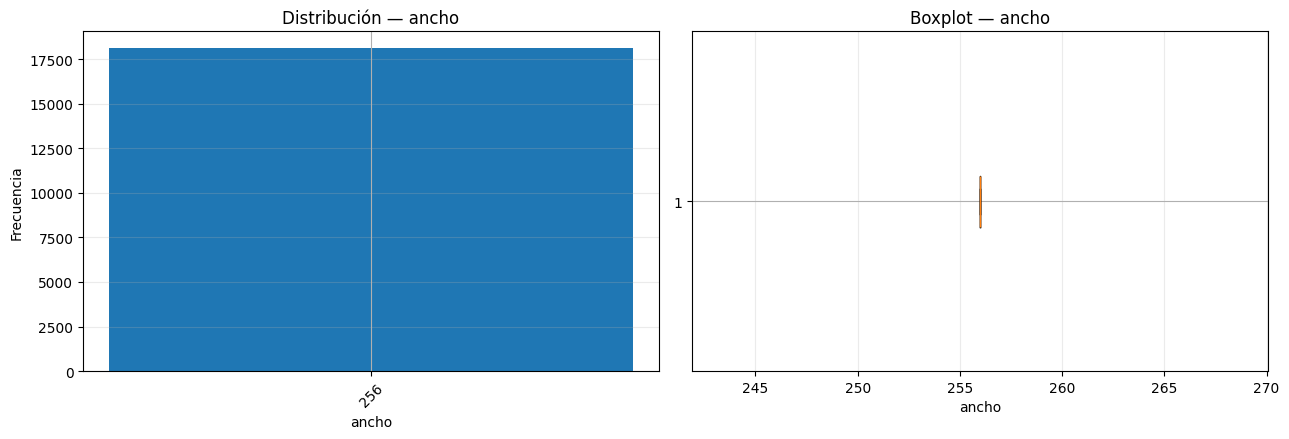

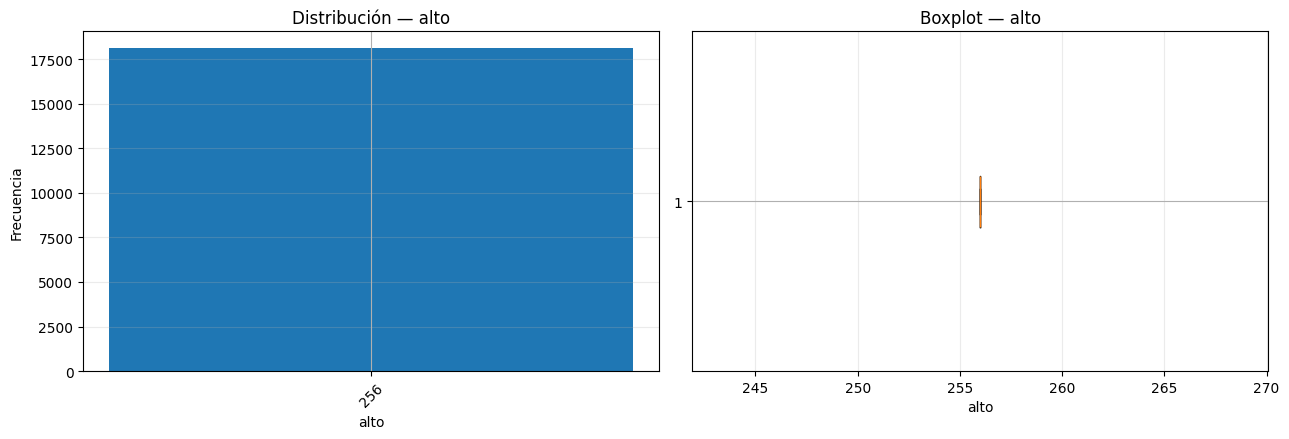

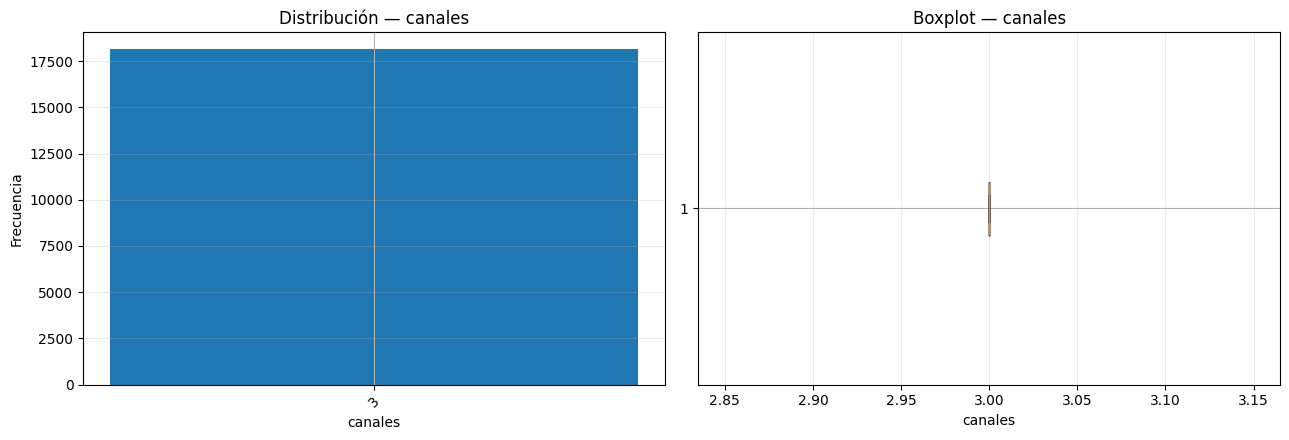

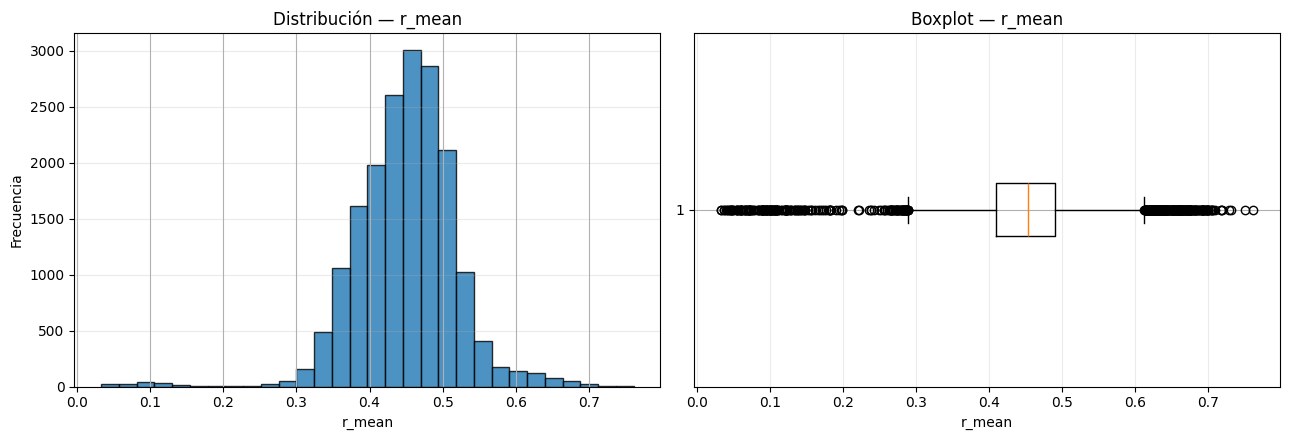

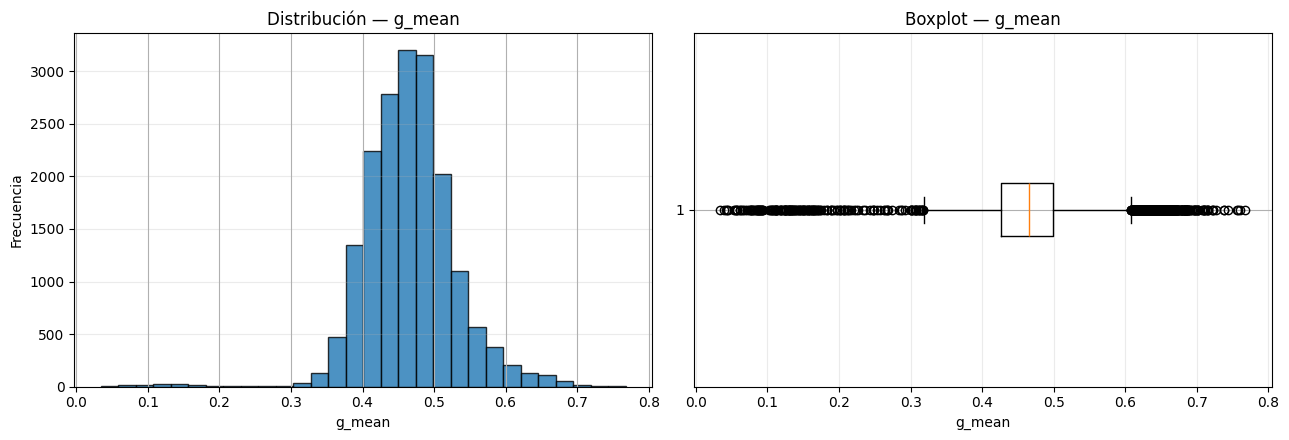

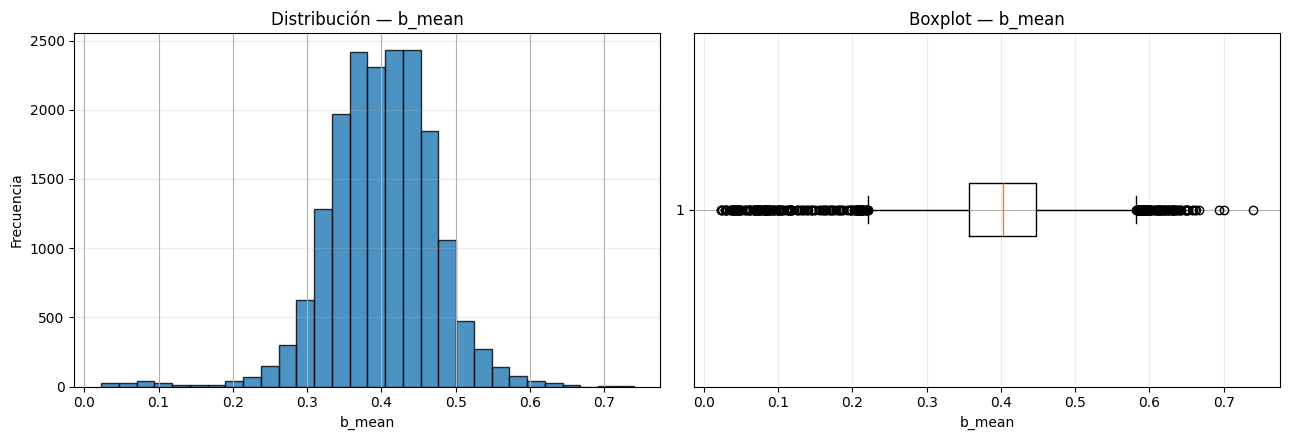

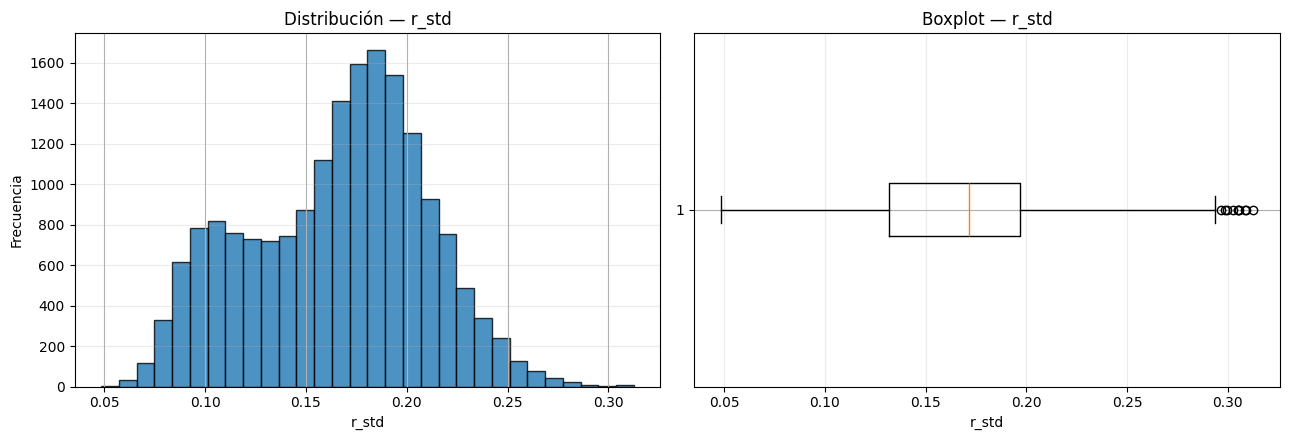

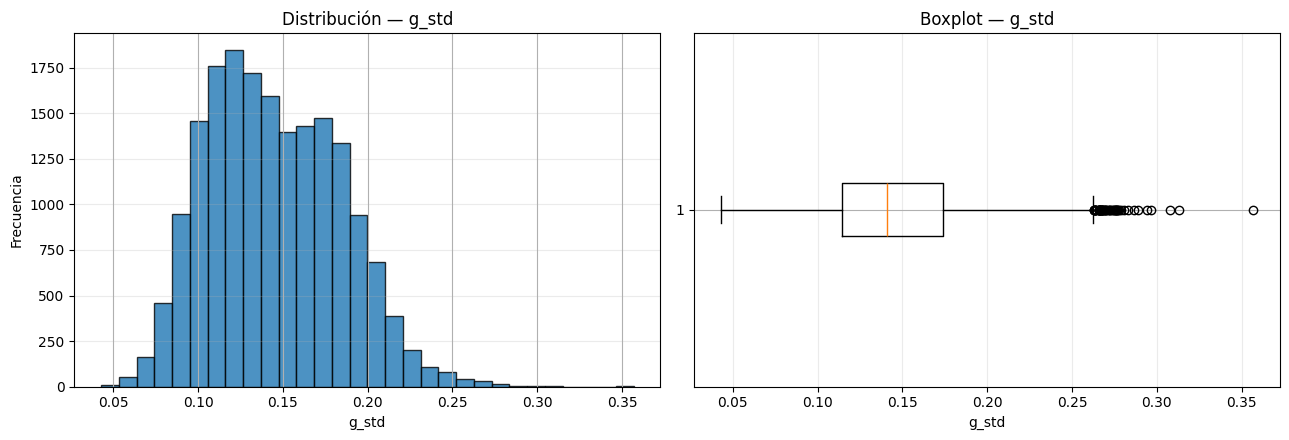

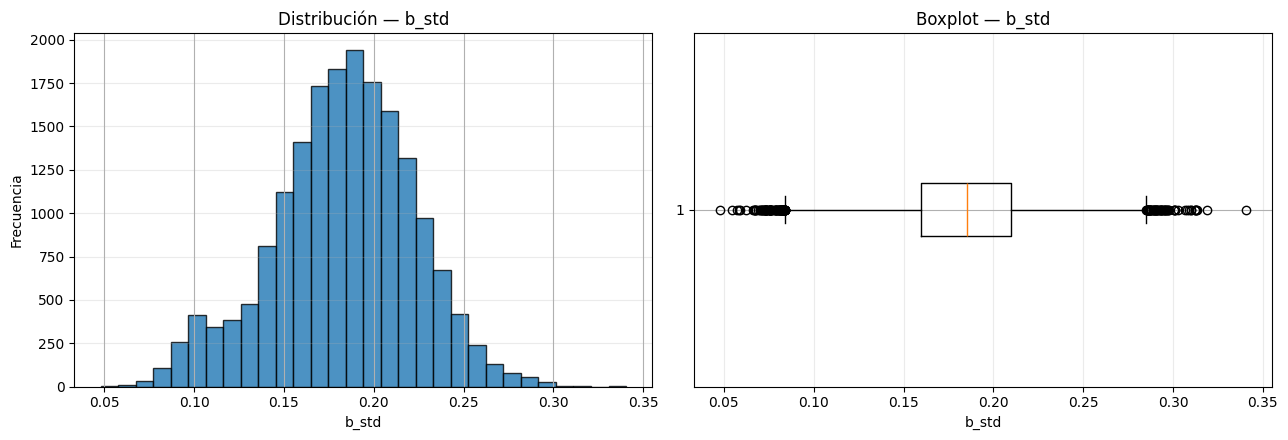

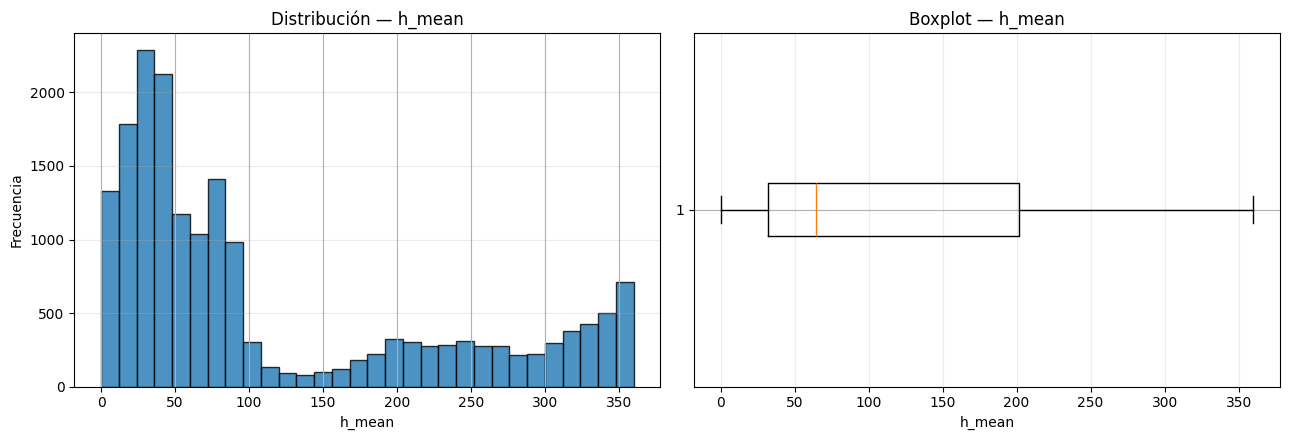

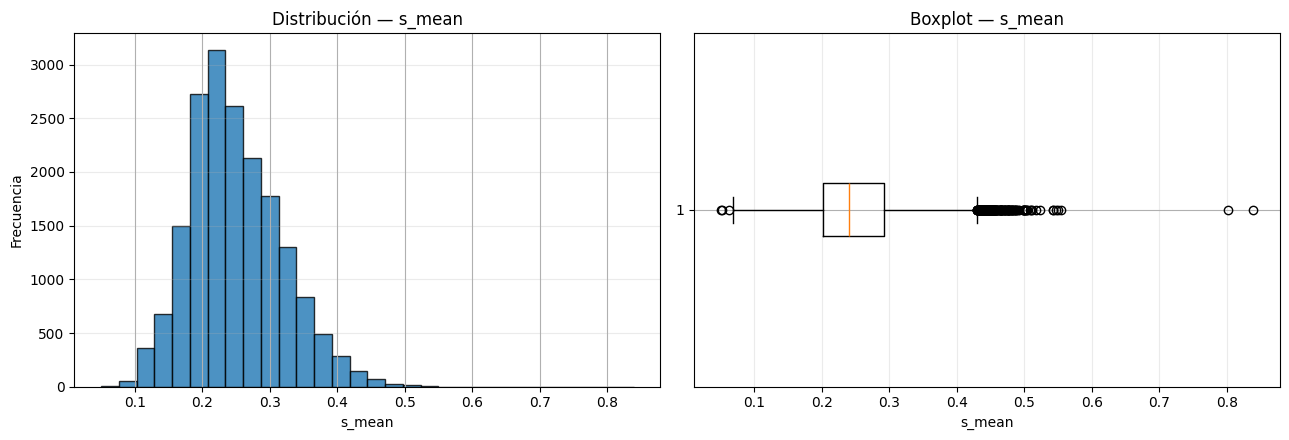

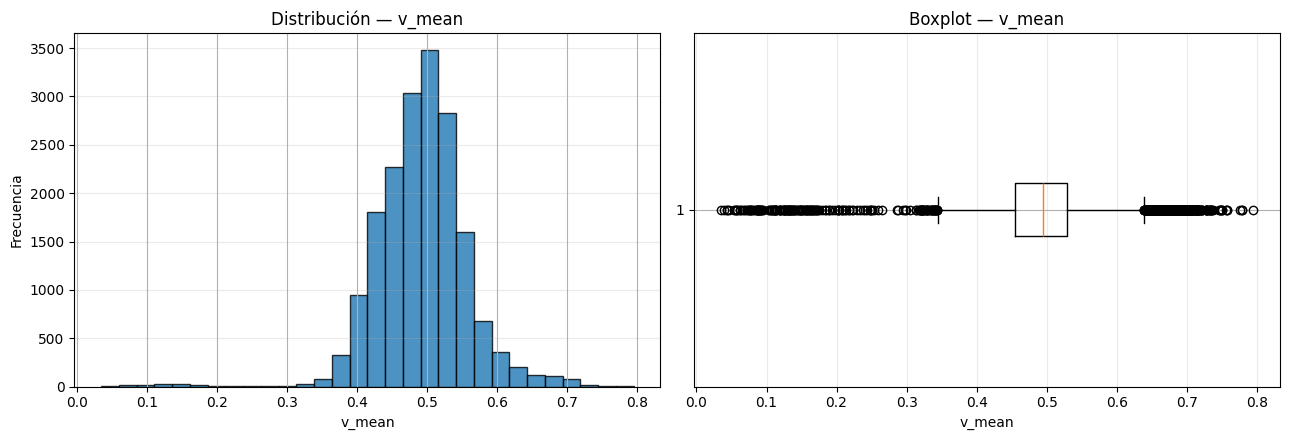

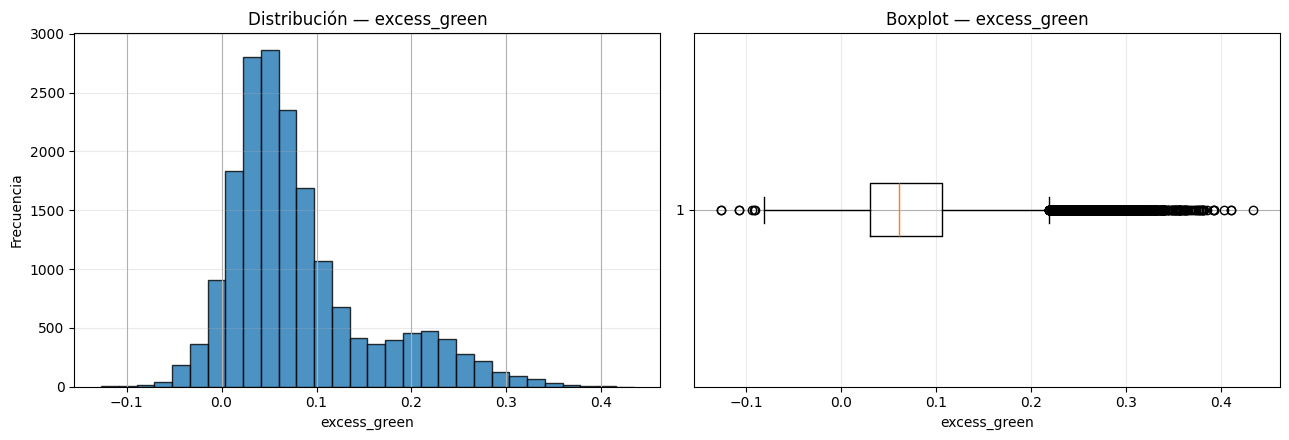

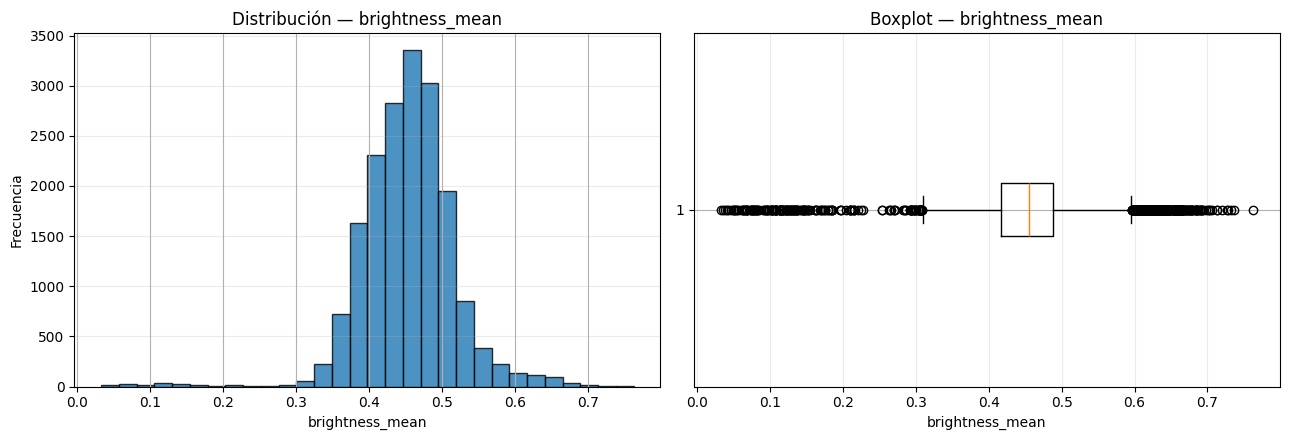

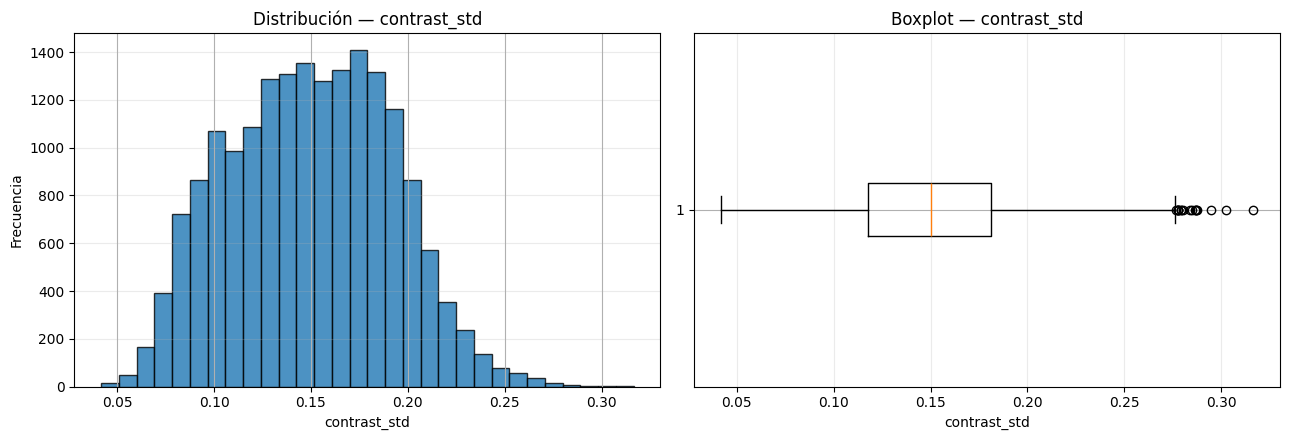

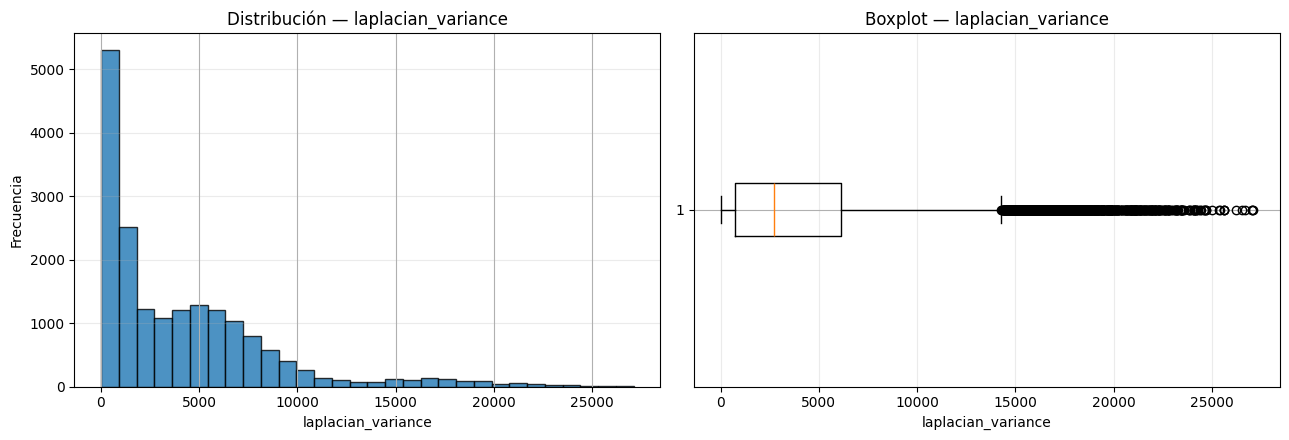

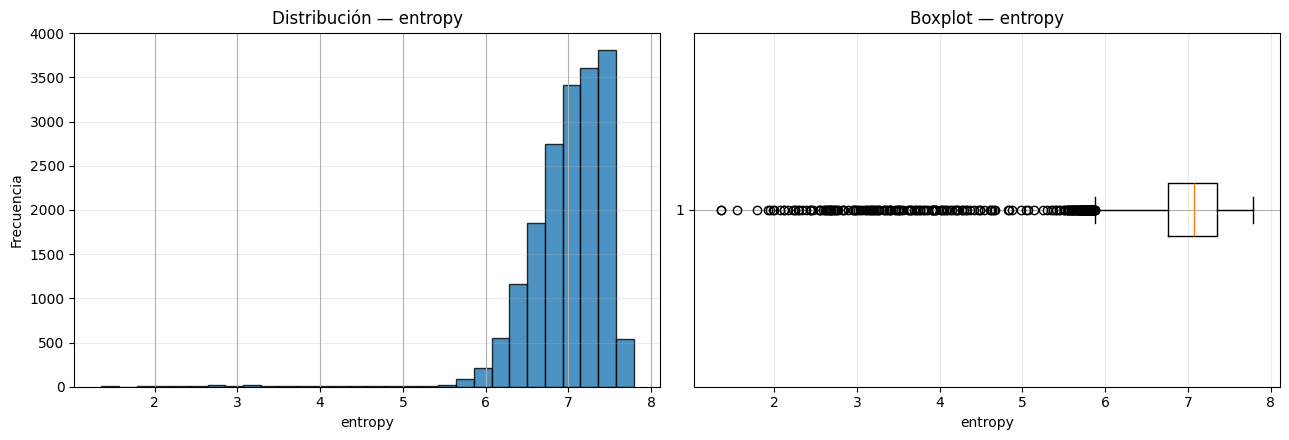

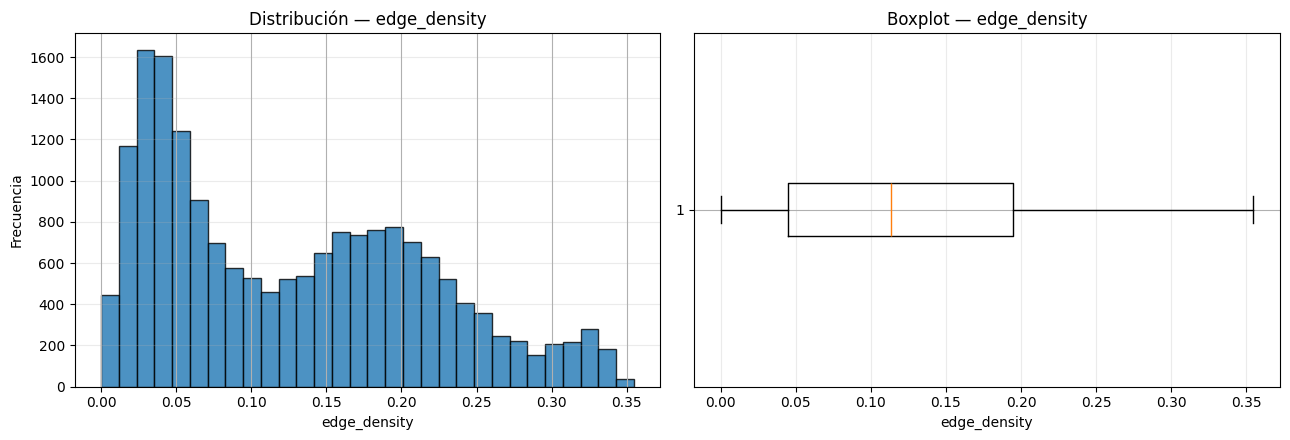

In [ ]:
# ============================================================
# FASE 1 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# 5.5.1 ANÁLISIS UNIVARIADO — VARIABLES NUMÉRICAS
# ============================================================
#
# SALIDAS:
#   1. Tabla consolidada de estadísticas descriptivas.
#   2. Distribución de cada variable.
#   3. Boxplot de cada variable.
#
# Esta celda NO genera conclusiones automáticas.
# ============================================================


# ============================================================
# 1. VERIFICAR VARIABLES
# ============================================================

if "VARIABLES_NUMERICAS_UNIV" not in globals():
    raise NameError(
        "No se encontró 'VARIABLES_NUMERICAS_UNIV'. "
        "Ejecute primero la sección 5.5."
    )

if len(VARIABLES_NUMERICAS_UNIV) == 0:
    raise ValueError(
        "No se encontraron variables numéricas para analizar."
    )


# ============================================================
# 2. TABLA CONSOLIDADA
# ============================================================

resumen_numerico = []

for variable in VARIABLES_NUMERICAS_UNIV:

    serie = pd.to_numeric(
        df[variable],
        errors="coerce"
    ).dropna()

    if serie.empty:
        continue

    q1 = serie.quantile(0.25)
    mediana = serie.median()
    q3 = serie.quantile(0.75)

    resumen_numerico.append(
        {
            "Variable": variable,
            "N": int(serie.count()),
            "Media": serie.mean(),
            "Mediana": mediana,
            "Desv. estándar": serie.std(ddof=1),
            "Mínimo": serie.min(),
            "Q1": q1,
            "Q3": q3,
            "Máximo": serie.max(),
            "IQR": q3 - q1,
            "Valores únicos": int(serie.nunique())
        }
    )


df_resumen_numerico = pd.DataFrame(
    resumen_numerico
)

display(
    df_resumen_numerico.round(6)
)


# ============================================================
# 3. VISUALIZACIÓN POR VARIABLE
# ============================================================

MAX_VALORES_DISCRETOS = 20
BINS_HISTOGRAMA = 30


for variable in VARIABLES_NUMERICAS_UNIV:

    serie = pd.to_numeric(
        df[variable],
        errors="coerce"
    ).dropna()

    if serie.empty:
        continue

    n_unicos = serie.nunique()

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(13, 4.5)
    )

    # --------------------------------------------------------
    # A. Distribución
    # --------------------------------------------------------

    if n_unicos <= MAX_VALORES_DISCRETOS:

        frecuencias = (
            serie
            .value_counts()
            .sort_index()
        )

        axes[0].bar(
            frecuencias.index.astype(str),
            frecuencias.values
        )

        axes[0].set_xlabel(variable)
        axes[0].set_ylabel("Frecuencia")
        axes[0].tick_params(
            axis="x",
            rotation=45
        )

    else:

        axes[0].hist(
            serie,
            bins=BINS_HISTOGRAMA,
            edgecolor="black",
            alpha=0.8
        )

        axes[0].set_xlabel(variable)
        axes[0].set_ylabel("Frecuencia")

    axes[0].set_title(
        f"Distribución — {variable}"
    )

    axes[0].grid(
        axis="y",
        alpha=0.25
    )


    # --------------------------------------------------------
    # B. Boxplot
    # --------------------------------------------------------

    axes[1].boxplot(
        serie,
        vert=False
    )

    axes[1].set_xlabel(variable)

    axes[1].set_title(
        f"Boxplot — {variable}"
    )

    axes[1].grid(
        axis="x",
        alpha=0.25
    )


    plt.tight_layout()
    plt.show()


## 5.5.2 Análisis univariado de variables categóricas

El análisis categórico describe la frecuencia y representación relativa de las.


5.5.2 — RESUMEN DE VARIABLES CATEGÓRICAS


,Variable,N categorías,N observaciones,N faltantes originales
0,clase,10,18146,0
1,modo,1,18146,0
2,formato,1,18146,0



VARIABLE: clase
Número de categorías : 10
Número de observaciones: 18,146


,Categoría,Frecuencia,Proporción,Porcentaje (%)
0,Tomato___Tomato_Yellow_Leaf_Curl_Virus,"5,357",0.295217,29.52
1,Tomato___Bacterial_spot,"2,127",0.117216,11.72
2,Tomato___Late_blight,"1,901",0.104761,10.48
3,Tomato___Septoria_leaf_spot,"1,771",0.097597,9.76
4,Tomato___Spider_mites Two-spotted_spider_mite,"1,676",0.092362,9.24
5,Tomato___healthy,"1,585",0.087347,8.73
6,Tomato___Target_Spot,"1,404",0.077372,7.74
7,Tomato___Early_blight,"1,000",0.055109,5.51
8,Tomato___Leaf_Mold,952,0.052463,5.25
9,Tomato___Tomato_mosaic_virus,373,0.020555,2.06


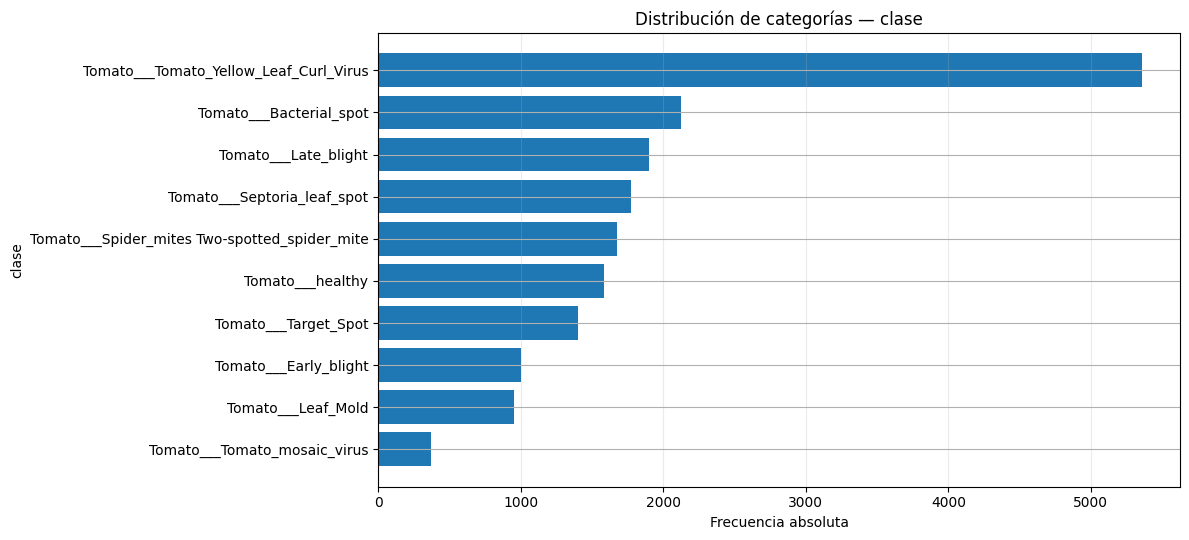


VARIABLE: modo
Número de categorías : 1
Número de observaciones: 18,146


,Categoría,Frecuencia,Proporción,Porcentaje (%)
0,RGB,"18,146",1.000000,100.00


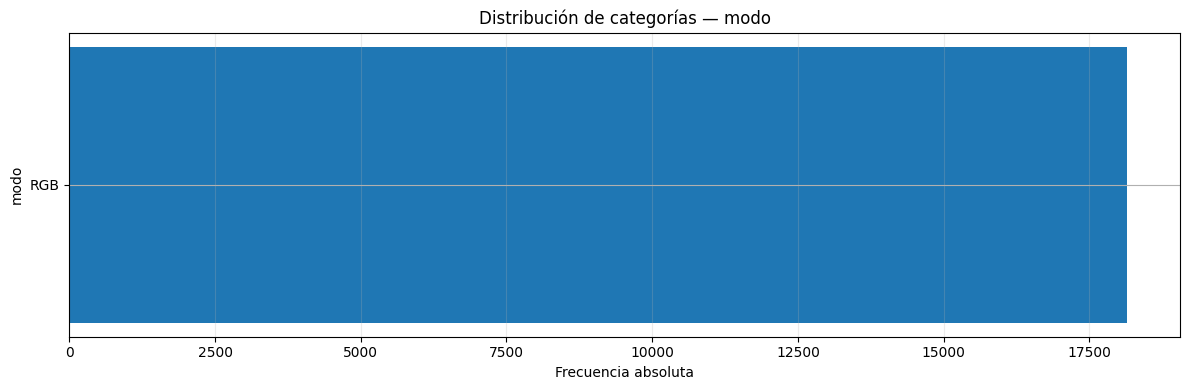


VARIABLE: formato
Número de categorías : 1
Número de observaciones: 18,146


,Categoría,Frecuencia,Proporción,Porcentaje (%)
0,JPEG,"18,146",1.000000,100.00


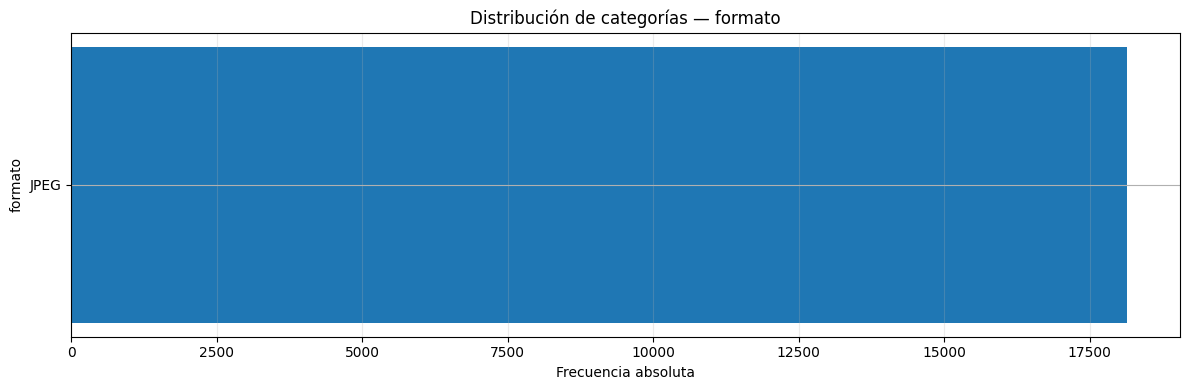


CONTROL FINAL — 5.5.2
Variables categóricas analizadas : 3
Estado                         : COMPLETADO SIN MODIFICAR LOS DATOS
✅ 5.5.2 — ANÁLISIS UNIVARIADO DE VARIABLES CATEGÓRICAS COMPLETADO


In [ ]:
# ============================================================
# FASE 1 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# 5.5.2 ANÁLISIS UNIVARIADO — VARIABLES CATEGÓRICAS
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Analizar descriptivamente las variables categóricas mediante:
#
#   1. Número de categorías.
#   2. Frecuencia absoluta.
#   3. Proporción.
#   4. Porcentaje.
#   5. Representación gráfica mediante barras horizontales.
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda:
#
#   - NO modifica el DataFrame.
#   - NO elimina categorías.
#   - NO transforma el target.
#   - NO balancea clases.
#   - NO aplica codificación.
#   - NO genera conclusiones automáticas.
#
# Su finalidad es exclusivamente exploratoria.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ============================================================
# 2. VERIFICAR DATAFRAME
# ============================================================

if "df" not in globals():

    if "df_maestro" in globals():

        df = df_maestro.copy()

    else:

        raise NameError(
            "No se encontró 'df' ni 'df_maestro'. "
            "Ejecute previamente las secciones 5.2–5.5."
        )


if df.empty:

    raise ValueError(
        "El DataFrame está vacío."
    )


# ============================================================
# 3. VERIFICAR VARIABLES CATEGÓRICAS
# ============================================================

if "VARIABLES_CATEGORICAS_UNIV" not in globals():

    raise NameError(
        "No se encontró 'VARIABLES_CATEGORICAS_UNIV'. "
        "Ejecute primero la sección 5.5 — Configuración."
    )


if len(VARIABLES_CATEGORICAS_UNIV) == 0:

    raise ValueError(
        "No se encontraron variables categóricas para analizar."
    )


# Verificar que todas las variables definidas realmente existan
# dentro del DataFrame.

variables_inexistentes = [
    variable
    for variable in VARIABLES_CATEGORICAS_UNIV
    if variable not in df.columns
]


if variables_inexistentes:

    raise KeyError(
        "Las siguientes variables categóricas no existen "
        f"en el DataFrame: {variables_inexistentes}"
    )


# ============================================================
# 4. FUNCIÓN ROBUSTA DE FRECUENCIAS
# ============================================================

def tabla_frecuencias_categorica(serie):
    """
    Construye una tabla descriptiva para una variable categórica.

    Parámetros
    ----------
    serie : pandas.Series
        Variable categórica que será analizada.

    Retorna
    -------
    pandas.DataFrame
        Tabla con:

        - Categoría
        - Frecuencia
        - Proporción
        - Porcentaje (%)

    Notas
    -----
    Se utiliza rename_axis("Categoría") antes de reset_index()
    para garantizar compatibilidad con diferentes versiones
    de Pandas.

    Esta estrategia evita el error:

        KeyError: 'Categoría'

    provocado cuando reset_index() conserva como nombre de
    columna el nombre original de la Serie.
    """

    # --------------------------------------------------------
    # 4.1 Preparar la serie
    # --------------------------------------------------------

    serie_limpia = (
        serie
        .astype("string")
        .fillna("<NA>")
    )


    # --------------------------------------------------------
    # 4.2 Calcular frecuencias absolutas
    # --------------------------------------------------------

    frecuencia = (
        serie_limpia
        .value_counts(
            dropna=False
        )
    )


    # --------------------------------------------------------
    # 4.3 Convertir el índice a una columna denominada
    #     explícitamente "Categoría".
    #
    # Esta es la CORRECCIÓN principal respecto de la
    # implementación anterior.
    # --------------------------------------------------------

    tabla = (
        frecuencia
        .rename_axis("Categoría")
        .reset_index(
            name="Frecuencia"
        )
    )


    # --------------------------------------------------------
    # 4.4 Calcular proporción
    #
    #              n_k
    #     p_k = ---------
    #               N
    # --------------------------------------------------------

    total = (
        tabla["Frecuencia"]
        .sum()
    )


    tabla["Proporción"] = (
        tabla["Frecuencia"]
        / total
    )


    # --------------------------------------------------------
    # 4.5 Calcular porcentaje
    #
    #     porcentaje_k = 100 * p_k
    # --------------------------------------------------------

    tabla["Porcentaje (%)"] = (
        tabla["Proporción"]
        * 100
    )


    # --------------------------------------------------------
    # 4.6 Control interno
    # --------------------------------------------------------

    assert (
        tabla["Frecuencia"].sum()
        == len(serie_limpia)
    ), (
        "La suma de frecuencias no coincide "
        "con el número de observaciones."
    )


    assert np.isclose(
        tabla["Proporción"].sum(),
        1.0
    ), (
        "Las proporciones de la variable "
        "categórica no suman 1."
    )


    return tabla


# ============================================================
# 5. RESUMEN GENERAL DE VARIABLES CATEGÓRICAS
# ============================================================

resumen_categorico = pd.DataFrame(
    {
        "Variable": (
            VARIABLES_CATEGORICAS_UNIV
        ),

        "N categorías": [
            int(
                df[variable]
                .astype("string")
                .fillna("<NA>")
                .nunique()
            )
            for variable
            in VARIABLES_CATEGORICAS_UNIV
        ],

        "N observaciones": [
            int(
                len(
                    df[variable]
                )
            )
            for variable
            in VARIABLES_CATEGORICAS_UNIV
        ],

        "N faltantes originales": [
            int(
                df[variable]
                .isna()
                .sum()
            )
            for variable
            in VARIABLES_CATEGORICAS_UNIV
        ]
    }
)


print("=" * 90)
print("5.5.2 — RESUMEN DE VARIABLES CATEGÓRICAS")
print("=" * 90)

display(
    resumen_categorico
)


# ============================================================
# 6. TABLAS DE FRECUENCIA Y VISUALIZACIONES
# ============================================================

for variable in VARIABLES_CATEGORICAS_UNIV:

    print("\n" + "=" * 90)
    print(f"VARIABLE: {variable}")
    print("=" * 90)


    # --------------------------------------------------------
    # 6.1 Construir tabla de frecuencias
    # --------------------------------------------------------

    tabla = (
        tabla_frecuencias_categorica(
            df[variable]
        )
    )


    # --------------------------------------------------------
    # 6.2 Información general
    # --------------------------------------------------------

    n_categorias = (
        len(tabla)
    )


    print(
        f"Número de categorías : "
        f"{n_categorias}"
    )

    print(
        f"Número de observaciones: "
        f"{tabla['Frecuencia'].sum():,}"
    )


    # --------------------------------------------------------
    # 6.3 Mostrar tabla
    # --------------------------------------------------------

    display(
        tabla.style.format(
            {
                "Frecuencia": "{:,.0f}",
                "Proporción": "{:.6f}",
                "Porcentaje (%)": "{:.2f}"
            }
        )
    )


    # --------------------------------------------------------
    # 6.4 Preparar gráfico
    # --------------------------------------------------------
    #
    # Se genera una copia ordenada para visualización.
    # La tabla original no se modifica.
    # --------------------------------------------------------

    tabla_plot = (
        tabla
        .sort_values(
            by="Frecuencia",
            ascending=True
        )
        .copy()
    )


    # --------------------------------------------------------
    # 6.5 Gráfico de barras horizontal
    # --------------------------------------------------------

    plt.figure(
        figsize=(
            12,
            max(
                4,
                len(tabla_plot) * 0.55
            )
        )
    )


    plt.barh(
        tabla_plot[
            "Categoría"
        ].astype(str),

        tabla_plot[
            "Frecuencia"
        ]
    )


    plt.xlabel(
        "Frecuencia absoluta"
    )

    plt.ylabel(
        variable
    )


    plt.title(
        f"Distribución de categorías — {variable}"
    )


    plt.grid(
        axis="x",
        alpha=0.25
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 7. CONTROL FINAL
# ============================================================

print("\n" + "=" * 90)
print("CONTROL FINAL — 5.5.2")
print("=" * 90)

print(
    f"Variables categóricas analizadas : "
    f"{len(VARIABLES_CATEGORICAS_UNIV)}"
)

print(
    "Estado                         : "
    "COMPLETADO SIN MODIFICAR LOS DATOS"
)

print("=" * 90)

print(
    "✅ 5.5.2 — ANÁLISIS UNIVARIADO "
    "DE VARIABLES CATEGÓRICAS COMPLETADO"
)

## 5.6 Análisis de la variable objetivo

Esta sección resume análisis de la variable objetivo y su función dentro del proyecto MLOps.

## 5.6.1 Frecuencia y proporción de las clases

Esta sección resume frecuencia y proporción de las clases y su función dentro del proyecto MLOps.

## 5.6.2 Referencia de equilibrio

Si todas las clases tuvieran exactamente la misma representación, cada una.

## 5.6.3 Razón de desbalance

Una medida sencilla para cuantificar la diferencia entre las clases extremas es la.

## 5.6.4 Entropía normalizada de la distribución de clases

Como complemento al análisis anterior, puede medirse cuán uniforme es la.

## 5.6.5 Consideración sobre regresión

La hoja de ruta contempla también el análisis de media, mediana, asimetría y.

## 5.6.6 Relación entre el target y el costo del error

El proyecto no dispone de una estimación monetaria asociada a cada tipo de error.

## Caso 1 — Enfermedad clasificada como saludable

Este error puede resultar especialmente relevante si el sistema se utiliza como.

## Caso 2 — Hoja saludable clasificada como enferma

Esta sección resume caso 2 — Hoja saludable clasificada como enferma y su función dentro del proyecto MLOps.

## Caso 3 — Confusión entre dos enfermedades

En este caso el modelo identifica una condición no saludable, pero asigna una.


5.6 — ANÁLISIS DE LA VARIABLE OBJETIVO
Variable objetivo               : clase
Tipo de problema                : Clasificación multiclase
Observaciones                   : 18,146
Número de clases                : 10
Proporción teórica 1/K          : 0.1000
Porcentaje teórico 1/K          : 10.00%
Observaciones/clase en equilibrio: 1,814.6

----------------------------------------------------------------------------------------------------
CLASE MAYORITARIA
----------------------------------------------------------------------------------------------------
Clase      : Tomato___Tomato_Yellow_Leaf_Curl_Virus
Frecuencia : 5,357
Porcentaje : 29.52%

----------------------------------------------------------------------------------------------------
CLASE MINORITARIA
----------------------------------------------------------------------------------------------------
Clase      : Tomato___Tomato_mosaic_virus
Frecuencia : 373
Porcentaje : 2.06%

-----------------------------------------------

,Clase,Frecuencia,Proporción,Porcentaje (%),Razón vs equilibrio,Diferencia vs equilibrio (pp),Representación
0,Tomato___Tomato_Yellow_Leaf_Curl_Virus,"5,357",0.295217,29.52,2.952,+19.52,Superior a 1/K
1,Tomato___Bacterial_spot,"2,127",0.117216,11.72,1.172,+1.72,Superior a 1/K
2,Tomato___Late_blight,"1,901",0.104761,10.48,1.048,+0.48,Superior a 1/K
3,Tomato___Septoria_leaf_spot,"1,771",0.097597,9.76,0.976,-0.24,Inferior a 1/K
4,Tomato___Spider_mites Two-spotted_spider_mite,"1,676",0.092362,9.24,0.924,-0.76,Inferior a 1/K
5,Tomato___healthy,"1,585",0.087347,8.73,0.873,-1.27,Inferior a 1/K
6,Tomato___Target_Spot,"1,404",0.077372,7.74,0.774,-2.26,Inferior a 1/K
7,Tomato___Early_blight,"1,000",0.055109,5.51,0.551,-4.49,Inferior a 1/K
8,Tomato___Leaf_Mold,952,0.052463,5.25,0.525,-4.75,Inferior a 1/K
9,Tomato___Tomato_mosaic_virus,373,0.020555,2.06,0.206,-7.94,Inferior a 1/K



CLASES CON REPRESENTACIÓN INFERIOR A 1/K


,Clase,Frecuencia,Porcentaje (%),Razón vs equilibrio
0,Tomato___Septoria_leaf_spot,"1,771",9.76,0.976
1,Tomato___Spider_mites Two-spotted_spider_mite,"1,676",9.24,0.924
2,Tomato___healthy,"1,585",8.73,0.873
3,Tomato___Target_Spot,"1,404",7.74,0.774
4,Tomato___Early_blight,"1,000",5.51,0.551
5,Tomato___Leaf_Mold,952,5.25,0.525
6,Tomato___Tomato_mosaic_virus,373,2.06,0.206


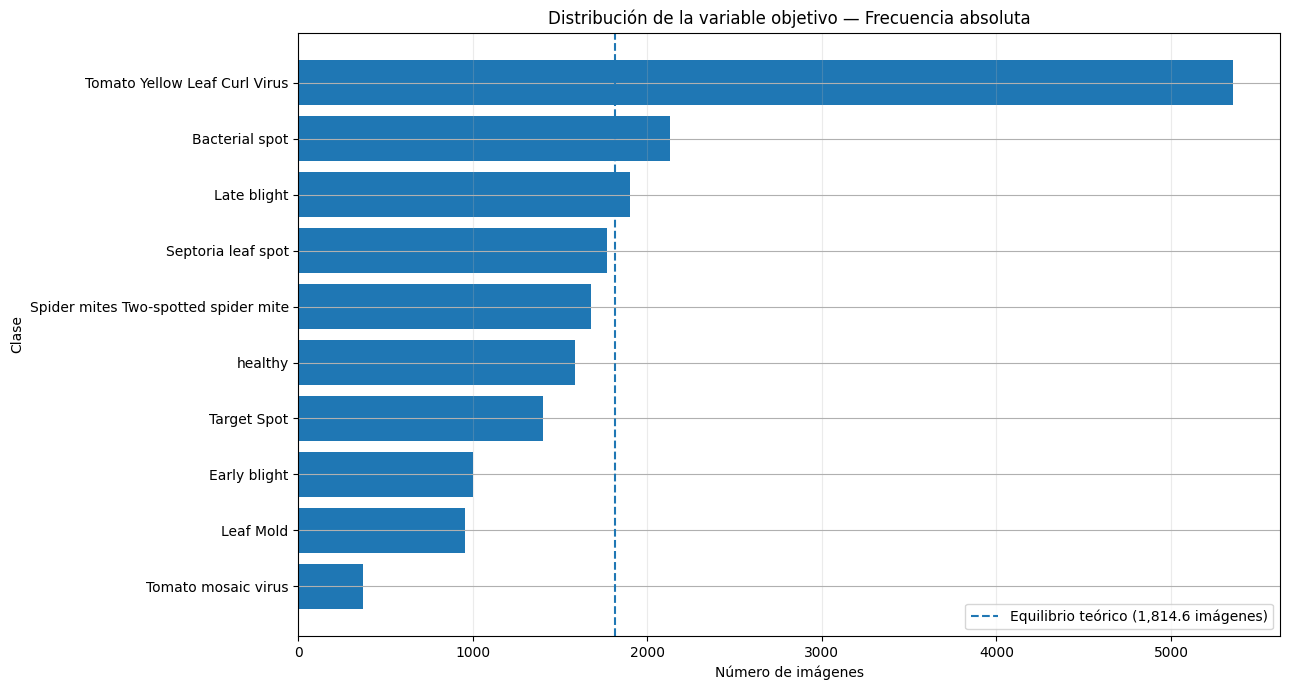

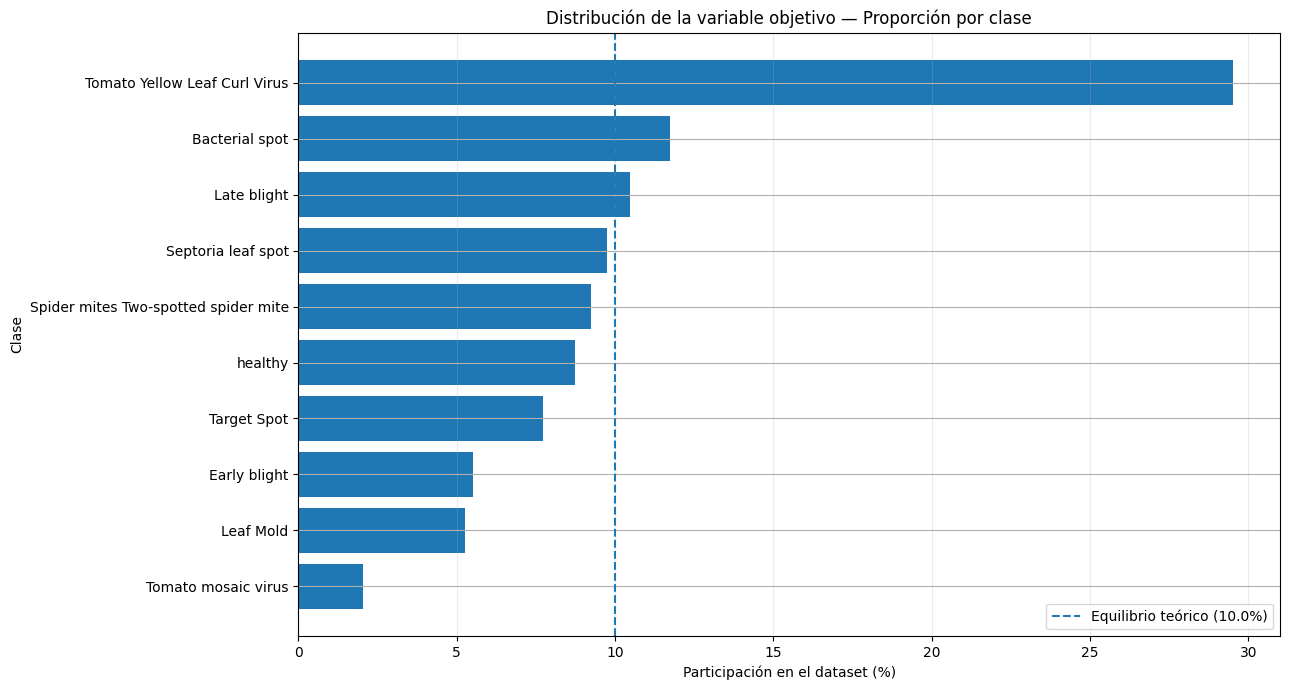


AGRUPACIÓN AUXILIAR — SALUDABLE VS ENFERMEDAD


,Estado operacional,Frecuencia,Proporción,Porcentaje (%)
0,Enfermedad,"16,561",0.912653,91.27
1,Saludable,"1,585",0.087347,8.73



RELACIÓN DEL TARGET CON EL COSTO OPERACIONAL DEL ERROR


,Situación,Condición,Consecuencia operacional,Aspecto a vigilar posteriormente
0,Enfermedad → Healthy,y = enfermedad; ŷ = healthy,Una observación enferma podría no ser priorizada para revisión adicional.,Recall de enfermedades y confusiones con healthy
1,Healthy → Enfermedad,y = healthy; ŷ = enfermedad,"Puede generar revisiones, inspecciones o falsos avisos innecesarios.",Precisión de las predicciones de enfermedad
2,Enfermedad c_i → Enfermedad c_j,y = c_i; ŷ = c_j; i ≠ j,"Se reconoce una condición no saludable, pero se asigna una enfermedad incorrecta.",Matriz de confusión y métricas por clase



Nota metodológica:
No se asignan costos monetarios porque el dataset y el notebook no contienen evidencia que permita cuantificarlos.

CONTROL FINAL — 5.6
✅ Frecuencias verificadas.
✅ Proporciones verificadas.
✅ Clase mayoritaria identificada.
✅ Clase minoritaria identificada.
✅ Razón de desbalance calculada.
✅ Distribución del target visualizada.
✅ Costo operacional documentado sin inventar costos monetarios.
✅ Los datos originales no fueron modificados.
✅ 5.6 — ANÁLISIS DE LA VARIABLE OBJETIVO COMPLETADO


In [ ]:
# ============================================================
# FASE 1 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# 5.6 ANÁLISIS DE LA VARIABLE OBJETIVO
# ============================================================
#
# OBJETIVOS
# ------------------------------------------------------------
# 1. Verificar la variable objetivo.
# 2. Calcular frecuencia absoluta por clase.
# 3. Calcular proporción y porcentaje por clase.
# 4. Identificar clase mayoritaria y minoritaria.
# 5. Cuantificar el desbalance mediante:
#
#       - razón mayoritaria/minoritaria;
#       - representación relativa frente a 1/K;
#       - entropía normalizada.
#
# 6. Visualizar la distribución del target.
# 7. Construir una agrupación auxiliar:
#
#       Saludable vs Enfermedad
#
# 8. Relacionar conceptualmente el target con el
#    costo operacional de los errores.
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda:
#
#   - NO modifica el target;
#   - NO codifica las clases;
#   - NO realiza oversampling;
#   - NO realiza undersampling;
#   - NO calcula class_weights para entrenamiento;
#   - NO modifica Train/Validation/Test;
#   - NO entrena ningún modelo.
#
# Su finalidad es exclusivamente exploratoria.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ============================================================
# 2. VERIFICAR EL DATAFRAME
# ============================================================

if "df" not in globals():

    if "df_maestro" in globals():

        df = df_maestro.copy()

    else:

        raise NameError(
            "No se encontró 'df' ni 'df_maestro'. "
            "Ejecute previamente las secciones 5.2–5.5."
        )


if df.empty:

    raise ValueError(
        "El DataFrame está vacío."
    )


# ============================================================
# 3. DEFINIR Y VERIFICAR TARGET
# ============================================================

TARGET = globals().get(
    "TARGET",
    "clase"
)


if TARGET not in df.columns:

    raise KeyError(
        f"La variable objetivo '{TARGET}' "
        "no existe en el DataFrame."
    )


# No se modifica df.
# Únicamente se genera una serie auxiliar para el EDA.
y_target = (
    df[TARGET]
    .astype("string")
)


# ============================================================
# 4. VERIFICAR VALORES FALTANTES EN EL TARGET
# ============================================================

N_MISSING_TARGET = int(
    y_target
    .isna()
    .sum()
)


if N_MISSING_TARGET > 0:

    raise ValueError(
        f"El target contiene {N_MISSING_TARGET} "
        "valores faltantes. Debe revisarse antes "
        "de continuar con el análisis."
    )


# ============================================================
# 5. MAGNITUDES PRINCIPALES
# ============================================================

N_TARGET = int(
    len(y_target)
)


conteos_target = (
    y_target
    .value_counts(
        dropna=False
    )
    .sort_values(
        ascending=False
    )
)


K_TARGET = int(
    len(conteos_target)
)


if K_TARGET < 2:

    raise ValueError(
        "La variable objetivo debe contener "
        "al menos dos clases."
    )


# ============================================================
# 6. REFERENCIA TEÓRICA DE EQUILIBRIO
# ============================================================
#
# Si todas las clases estuvieran igualmente representadas:
#
#            1
# p_eq = --------
#            K
#
# ============================================================

PROPORCION_EQUILIBRIO = (
    1.0
    / K_TARGET
)


PORCENTAJE_EQUILIBRIO = (
    PROPORCION_EQUILIBRIO
    * 100
)


N_EQUILIBRIO = (
    N_TARGET
    / K_TARGET
)


# ============================================================
# 7. TABLA DE DISTRIBUCIÓN DEL TARGET
# ============================================================

df_target = (
    conteos_target
    .rename_axis("Clase")
    .reset_index(
        name="Frecuencia"
    )
)


# ------------------------------------------------------------
# Proporción
#
#              n_k
#     p_k = ---------
#               N
# ------------------------------------------------------------

df_target["Proporción"] = (
    df_target["Frecuencia"]
    / N_TARGET
)


# ------------------------------------------------------------
# Porcentaje
#
#     P_k = 100 * p_k
# ------------------------------------------------------------

df_target["Porcentaje (%)"] = (
    df_target["Proporción"]
    * 100
)


# ------------------------------------------------------------
# Representación relativa frente al equilibrio
#
#                p_k
#     R_k = -------------
#                1 / K
# ------------------------------------------------------------

df_target["Razón vs equilibrio"] = (
    df_target["Proporción"]
    / PROPORCION_EQUILIBRIO
)


# ------------------------------------------------------------
# Diferencia en puntos porcentuales frente al 1/K
# ------------------------------------------------------------

df_target["Diferencia vs equilibrio (pp)"] = (
    df_target["Porcentaje (%)"]
    - PORCENTAJE_EQUILIBRIO
)


# ------------------------------------------------------------
# Clasificación descriptiva de representación
#
# IMPORTANTE:
# No se está definiendo "clase rara".
# Solo se compara con la referencia matemática 1/K.
# ------------------------------------------------------------

df_target["Representación"] = np.select(

    [
        df_target["Proporción"]
        < PROPORCION_EQUILIBRIO,

        np.isclose(
            df_target["Proporción"],
            PROPORCION_EQUILIBRIO
        )
    ],

    [
        "Inferior a 1/K",
        "Igual a 1/K"
    ],

    default="Superior a 1/K"
)


# ============================================================
# 8. CLASE MAYORITARIA Y MINORITARIA
# ============================================================

fila_mayoritaria = (
    df_target
    .iloc[0]
)


fila_minoritaria = (
    df_target
    .iloc[-1]
)


CLASE_MAYORITARIA = (
    fila_mayoritaria["Clase"]
)


N_MAYORITARIA = int(
    fila_mayoritaria["Frecuencia"]
)


PCT_MAYORITARIA = float(
    fila_mayoritaria["Porcentaje (%)"]
)


CLASE_MINORITARIA = (
    fila_minoritaria["Clase"]
)


N_MINORITARIA = int(
    fila_minoritaria["Frecuencia"]
)


PCT_MINORITARIA = float(
    fila_minoritaria["Porcentaje (%)"]
)


# ============================================================
# 9. RAZÓN DE DESBALANCE
# ============================================================
#
#              n_max
#     IR = ------------
#              n_min
#
# ============================================================

RAZON_DESBALANCE = (
    N_MAYORITARIA
    / N_MINORITARIA
)


# ============================================================
# 10. BASELINE DE CLASE MAYORITARIA
# ============================================================
#
# Representa el accuracy de un clasificador trivial que
# siempre predijera la clase con mayor frecuencia.
#
# Este valor NO constituye todavía el baseline formal
# de modelado de la Fase 2.
#
# ============================================================

BASELINE_MAYORITARIA = (
    N_MAYORITARIA
    / N_TARGET
)


# ============================================================
# 11. ENTROPÍA DE LA DISTRIBUCIÓN DE CLASES
# ============================================================
#
#           K
# H(Y) = - Σ p_k ln(p_k)
#          k=1
#
# Entropía normalizada:
#
#                H(Y)
# H_norm = ----------------
#               ln(K)
#
# ============================================================

proporciones = (
    df_target["Proporción"]
    .to_numpy(
        dtype=float
    )
)


ENTROPIA_TARGET = float(
    -np.sum(
        proporciones
        * np.log(proporciones)
    )
)


ENTROPIA_MAXIMA = float(
    np.log(K_TARGET)
)


ENTROPIA_NORMALIZADA = float(
    ENTROPIA_TARGET
    / ENTROPIA_MAXIMA
)


# ============================================================
# 12. CLASES POR DEBAJO DE LA REFERENCIA 1/K
# ============================================================

df_clases_subrepresentadas = (
    df_target[
        df_target["Proporción"]
        < PROPORCION_EQUILIBRIO
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


# ============================================================
# 13. MOSTRAR RESUMEN GENERAL
# ============================================================

print("=" * 100)
print("5.6 — ANÁLISIS DE LA VARIABLE OBJETIVO")
print("=" * 100)

print(
    f"Variable objetivo               : "
    f"{TARGET}"
)

print(
    f"Tipo de problema                : "
    f"Clasificación multiclase"
)

print(
    f"Observaciones                   : "
    f"{N_TARGET:,}"
)

print(
    f"Número de clases                : "
    f"{K_TARGET}"
)

print(
    f"Proporción teórica 1/K          : "
    f"{PROPORCION_EQUILIBRIO:.4f}"
)

print(
    f"Porcentaje teórico 1/K          : "
    f"{PORCENTAJE_EQUILIBRIO:.2f}%"
)

print(
    f"Observaciones/clase en equilibrio: "
    f"{N_EQUILIBRIO:,.1f}"
)


# ============================================================
# 14. MOSTRAR CLASE MAYORITARIA
# ============================================================

print("\n" + "-" * 100)
print("CLASE MAYORITARIA")
print("-" * 100)

print(
    f"Clase      : "
    f"{CLASE_MAYORITARIA}"
)

print(
    f"Frecuencia : "
    f"{N_MAYORITARIA:,}"
)

print(
    f"Porcentaje : "
    f"{PCT_MAYORITARIA:.2f}%"
)


# ============================================================
# 15. MOSTRAR CLASE MINORITARIA
# ============================================================

print("\n" + "-" * 100)
print("CLASE MINORITARIA")
print("-" * 100)

print(
    f"Clase      : "
    f"{CLASE_MINORITARIA}"
)

print(
    f"Frecuencia : "
    f"{N_MINORITARIA:,}"
)

print(
    f"Porcentaje : "
    f"{PCT_MINORITARIA:.2f}%"
)


# ============================================================
# 16. INDICADORES DE BALANCE
# ============================================================

print("\n" + "-" * 100)
print("INDICADORES DE BALANCE / DESBALANCE")
print("-" * 100)

print(
    f"Razón mayoritaria/minoritaria : "
    f"{RAZON_DESBALANCE:.2f}"
)

print(
    f"Accuracy trivial mayoritaria  : "
    f"{BASELINE_MAYORITARIA:.4f} "
    f"({BASELINE_MAYORITARIA * 100:.2f}%)"
)

print(
    f"Entropía del target            : "
    f"{ENTROPIA_TARGET:.4f}"
)

print(
    f"Entropía máxima                : "
    f"{ENTROPIA_MAXIMA:.4f}"
)

print(
    f"Entropía normalizada           : "
    f"{ENTROPIA_NORMALIZADA:.4f}"
)

print(
    f"Clases con proporción < 1/K    : "
    f"{len(df_clases_subrepresentadas)} "
    f"de {K_TARGET}"
)


# ============================================================
# 17. TABLA COMPLETA DE DISTRIBUCIÓN
# ============================================================

print("\n" + "=" * 100)
print("DISTRIBUCIÓN COMPLETA DEL TARGET")
print("=" * 100)


display(
    df_target.style.format(
        {
            "Frecuencia": "{:,.0f}",
            "Proporción": "{:.6f}",
            "Porcentaje (%)": "{:.2f}",
            "Razón vs equilibrio": "{:.3f}",
            "Diferencia vs equilibrio (pp)": "{:+.2f}"
        }
    )
)


# ============================================================
# 18. TABLA DE CLASES SUBREPRESENTADAS
# ============================================================

print("\n" + "=" * 100)
print("CLASES CON REPRESENTACIÓN INFERIOR A 1/K")
print("=" * 100)


display(
    df_clases_subrepresentadas[
        [
            "Clase",
            "Frecuencia",
            "Porcentaje (%)",
            "Razón vs equilibrio"
        ]
    ].style.format(
        {
            "Frecuencia": "{:,.0f}",
            "Porcentaje (%)": "{:.2f}",
            "Razón vs equilibrio": "{:.3f}"
        }
    )
)


# ============================================================
# 19. FUNCIÓN PARA SIMPLIFICAR ETIQUETAS DEL GRÁFICO
# ============================================================

def simplificar_nombre_clase(nombre):
    """
    Genera una etiqueta más legible para los gráficos.

    La función NO modifica los valores originales del target.
    """

    return (
        str(nombre)
        .replace("Tomato___", "")
        .replace("_", " ")
    )


df_target_plot = (
    df_target
    .sort_values(
        by="Frecuencia",
        ascending=True
    )
    .copy()
)


df_target_plot["Etiqueta"] = (
    df_target_plot["Clase"]
    .map(
        simplificar_nombre_clase
    )
)


# ============================================================
# 20. GRÁFICO 1 — FRECUENCIA ABSOLUTA POR CLASE
# ============================================================

plt.figure(
    figsize=(13, 7)
)


plt.barh(
    df_target_plot["Etiqueta"],
    df_target_plot["Frecuencia"]
)


# Línea de referencia del equilibrio perfecto.
plt.axvline(
    x=N_EQUILIBRIO,
    linestyle="--",
    linewidth=1.5,
    label=(
        "Equilibrio teórico "
        f"({N_EQUILIBRIO:,.1f} imágenes)"
    )
)


plt.xlabel(
    "Número de imágenes"
)

plt.ylabel(
    "Clase"
)

plt.title(
    "Distribución de la variable objetivo — Frecuencia absoluta"
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 21. GRÁFICO 2 — PORCENTAJE POR CLASE
# ============================================================

plt.figure(
    figsize=(13, 7)
)


plt.barh(
    df_target_plot["Etiqueta"],
    df_target_plot["Porcentaje (%)"]
)


plt.axvline(
    x=PORCENTAJE_EQUILIBRIO,
    linestyle="--",
    linewidth=1.5,
    label=(
        "Equilibrio teórico "
        f"({PORCENTAJE_EQUILIBRIO:.1f}%)"
    )
)


plt.xlabel(
    "Participación en el dataset (%)"
)

plt.ylabel(
    "Clase"
)

plt.title(
    "Distribución de la variable objetivo — Proporción por clase"
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 22. AGRUPACIÓN AUXILIAR: SALUDABLE VS ENFERMEDAD
# ============================================================
#
# IMPORTANTE:
#
# Esta agrupación NO reemplaza el target multiclase.
# Se utiliza exclusivamente para facilitar la interpretación
# operacional del costo de ciertos errores.
#
# ============================================================

estado_operacional = np.where(

    y_target
    .str.lower()
    .str.contains(
        "healthy",
        regex=False
    ),

    "Saludable",

    "Enfermedad"
)


df_estado_operacional = (
    pd.Series(
        estado_operacional,
        name="Estado operacional"
    )
    .value_counts()
    .rename_axis(
        "Estado operacional"
    )
    .reset_index(
        name="Frecuencia"
    )
)


df_estado_operacional["Proporción"] = (
    df_estado_operacional["Frecuencia"]
    / N_TARGET
)


df_estado_operacional["Porcentaje (%)"] = (
    df_estado_operacional["Proporción"]
    * 100
)


print("\n" + "=" * 100)
print("AGRUPACIÓN AUXILIAR — SALUDABLE VS ENFERMEDAD")
print("=" * 100)


display(
    df_estado_operacional.style.format(
        {
            "Frecuencia": "{:,.0f}",
            "Proporción": "{:.6f}",
            "Porcentaje (%)": "{:.2f}"
        }
    )
)


# ============================================================
# 23. MATRIZ CONCEPTUAL DEL COSTO DE ERROR
# ============================================================
#
# El dataset no proporciona costos monetarios.
#
# Por ello, esta tabla NO inventa cifras económicas.
# Resume únicamente las consecuencias operacionales
# establecidas en la definición del problema.
#
# ============================================================

df_costo_error = pd.DataFrame(
    {
        "Situación": [
            "Enfermedad → Healthy",
            "Healthy → Enfermedad",
            "Enfermedad c_i → Enfermedad c_j"
        ],

        "Condición": [
            "y = enfermedad; ŷ = healthy",
            "y = healthy; ŷ = enfermedad",
            "y = c_i; ŷ = c_j; i ≠ j"
        ],

        "Consecuencia operacional": [
            (
                "Una observación enferma podría no ser "
                "priorizada para revisión adicional."
            ),
            (
                "Puede generar revisiones, inspecciones "
                "o falsos avisos innecesarios."
            ),
            (
                "Se reconoce una condición no saludable, "
                "pero se asigna una enfermedad incorrecta."
            )
        ],

        "Aspecto a vigilar posteriormente": [
            "Recall de enfermedades y confusiones con healthy",
            "Precisión de las predicciones de enfermedad",
            "Matriz de confusión y métricas por clase"
        ]
    }
)


print("\n" + "=" * 100)
print("RELACIÓN DEL TARGET CON EL COSTO OPERACIONAL DEL ERROR")
print("=" * 100)


display(
    df_costo_error
)


print(
    "\nNota metodológica:"
)

print(
    "No se asignan costos monetarios porque el dataset "
    "y el notebook no contienen evidencia que permita "
    "cuantificarlos."
)


# ============================================================
# 24. CONTROLES DE CONSISTENCIA
# ============================================================

assert (
    df_target["Frecuencia"].sum()
    == N_TARGET
), (
    "La suma de frecuencias no coincide "
    "con el número de observaciones."
)


assert np.isclose(
    df_target["Proporción"].sum(),
    1.0
), (
    "Las proporciones del target no suman 1."
)


assert (
    len(df_target)
    == K_TARGET
), (
    "El número de filas de la tabla no coincide "
    "con el número de clases."
)


assert (
    N_MAYORITARIA
    >= N_MINORITARIA
), (
    "Existe una inconsistencia en la identificación "
    "de las clases extrema."
)


assert (
    0
    <= ENTROPIA_NORMALIZADA
    <= 1
), (
    "La entropía normalizada debe encontrarse "
    "entre 0 y 1."
)


print("\n" + "=" * 100)
print("CONTROL FINAL — 5.6")
print("=" * 100)

print(
    "✅ Frecuencias verificadas."
)

print(
    "✅ Proporciones verificadas."
)

print(
    "✅ Clase mayoritaria identificada."
)

print(
    "✅ Clase minoritaria identificada."
)

print(
    "✅ Razón de desbalance calculada."
)

print(
    "✅ Distribución del target visualizada."
)

print(
    "✅ Costo operacional documentado sin "
    "inventar costos monetarios."
)

print(
    "✅ Los datos originales no fueron modificados."
)

print("=" * 100)

print(
    "✅ 5.6 — ANÁLISIS DE LA VARIABLE OBJETIVO COMPLETADO"
)

## 5.7 Análisis bivariado y multivariado

El análisis univariado desarrollado previamente permitió estudiar cada variable de.

## 5.7.1 Tipos de relaciones analizadas

es una variable categórica nominal, no es metodológicamente correcto asignar a las.

## 5.7.2 Relación entre características numéricas y el target

Para cada característica visual se comparará su distribución entre las.

## 5.7.3 Correlación de Pearson

Esta sección resume correlación de Pearson y su función dentro del proyecto MLOps.

## 5.7.4 Correlación de Spearman

La correlación de Spearman se calcula utilizando los rangos de las observaciones.

## 5.7.5 Variables de varianza nula

Una correlación requiere que ambas variables posean variabilidad.

## 5.7.6 Precaución con h_mean

La variable h_mean representa un ángulo de tono.

## 5.7.7 Asociación entre variables categóricas

Para estudiar la asociación entre dos variables categóricas se utilizará una tabla.

## 5.7.8 Pairplot

Un pairplot permite observar simultáneamente.

## 5.7.9 PCA exploratorio

El Análisis de Componentes Principales, PCA, transforma un conjunto de variables.


5.7 — CONFIGURACIÓN DEL ANÁLISIS
Observaciones                      : 18,146
Target                             : clase
Variables numéricas originales     : 18
Variables numéricas constantes     : 3
Variables numéricas analizables    : 15

Variables constantes excluidas de las correlaciones:
['ancho', 'alto', 'canales']

RELACIÓN DE CADA FEATURE NUMÉRICA CON EL TARGET
KRUSKAL-WALLIS + TAMAÑO DE EFECTO


,Feature,H Kruskal-Wallis,p-value,Epsilon²,N,K clases
0,laplacian_variance,"8,643.3321",0.000e+00,0.476088,"18,146",10
1,b_mean,"7,865.2593",0.000e+00,0.433186,"18,146",10
2,edge_density,"7,027.2024",0.000e+00,0.386976,"18,146",10
3,excess_green,"6,695.4876",0.000e+00,0.368686,"18,146",10
4,s_mean,"6,381.1144",0.000e+00,0.351352,"18,146",10
5,v_mean,"4,560.7749",0.000e+00,0.250980,"18,146",10
6,r_mean,"4,276.6405",0.000e+00,0.235313,"18,146",10
7,entropy,"3,816.0620",0.000e+00,0.209917,"18,146",10
8,brightness_mean,"3,419.9422",0.000e+00,0.188076,"18,146",10
9,g_std,"3,157.6652",0.000e+00,0.173614,"18,146",10



MEDIANA DE CADA FEATURE POR CLASE


clase,Tomato___Bacterial_spot,Tomato___Early_blight,Tomato___Late_blight,Tomato___Leaf_Mold,Tomato___Septoria_leaf_spot,Tomato___Spider_mites Two-spotted_spider_mite,Tomato___Target_Spot,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato___Tomato_mosaic_virus,Tomato___healthy
r_mean,0.3907,0.4204,0.4681,0.4570,0.5044,0.4859,0.4664,0.4377,0.4748,0.4499
g_mean,0.4169,0.4383,0.4686,0.4624,0.5090,0.4738,0.4713,0.4664,0.4622,0.4663
b_mean,0.3654,0.3970,0.4278,0.4481,0.4651,0.4286,0.4383,0.3539,0.4637,0.4321
r_std,0.1611,0.1948,0.1686,0.1602,0.1743,0.1901,0.1941,0.1548,0.1575,0.1748
g_std,0.1188,0.1743,0.1589,0.1375,0.1415,0.1687,0.1699,0.1309,0.1287,0.1706
b_std,0.1561,0.2097,0.1752,0.1887,0.2088,0.1972,0.2021,0.1806,0.1782,0.1947
h_mean,56.4622,55.2138,120.4412,204.1592,194.7131,34.1044,33.4018,67.8890,303.7838,198.2909
s_mean,0.2185,0.2270,0.2115,0.2439,0.2546,0.2197,0.2078,0.2975,0.2171,0.1892
v_mean,0.4345,0.4590,0.5002,0.5114,0.5528,0.5097,0.5019,0.4843,0.5128,0.4891
excess_green,0.0779,0.0568,0.0472,0.0323,0.0605,0.0336,0.0360,0.1430,-0.0134,0.0452


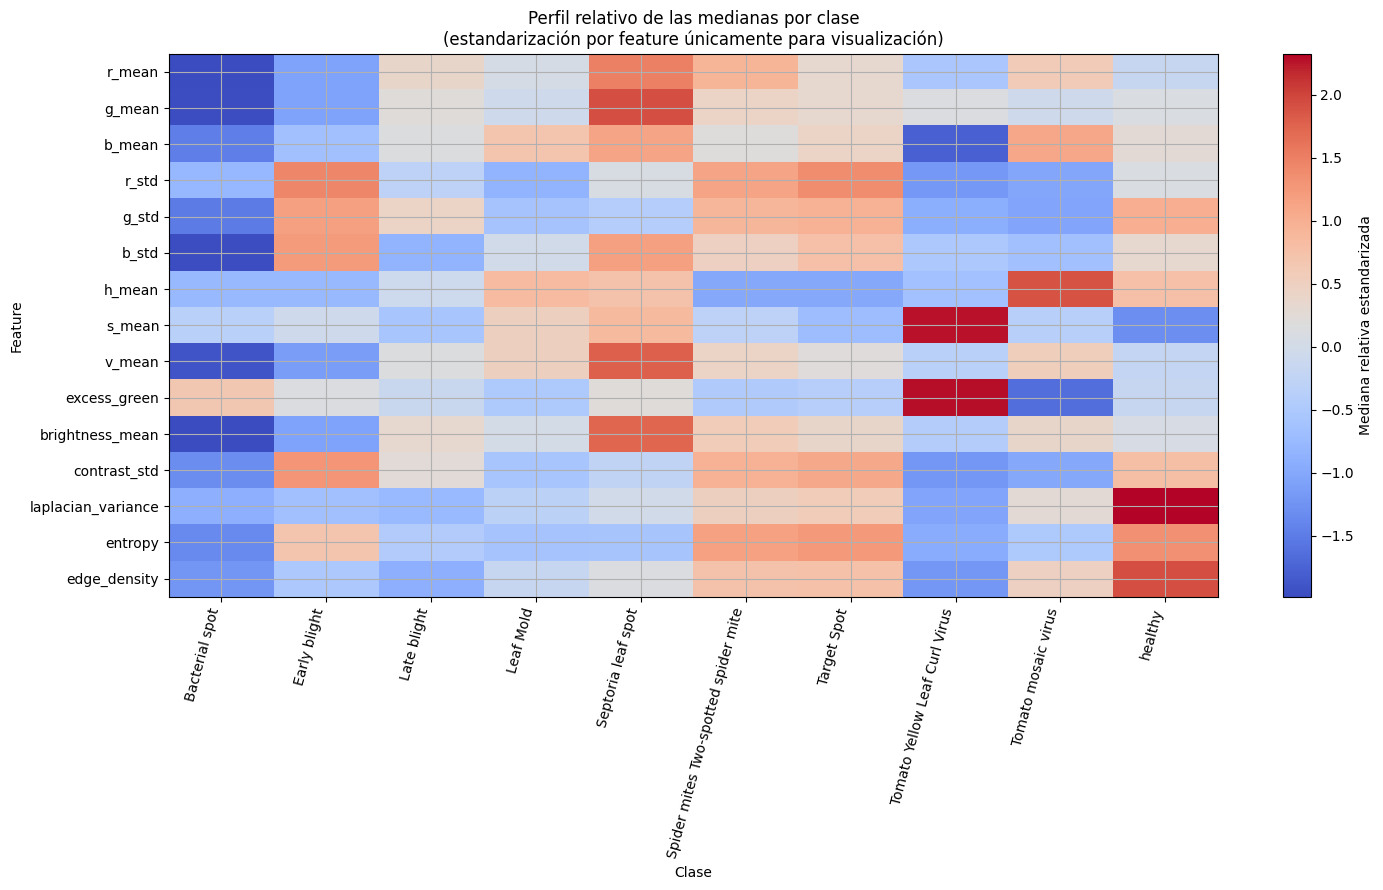

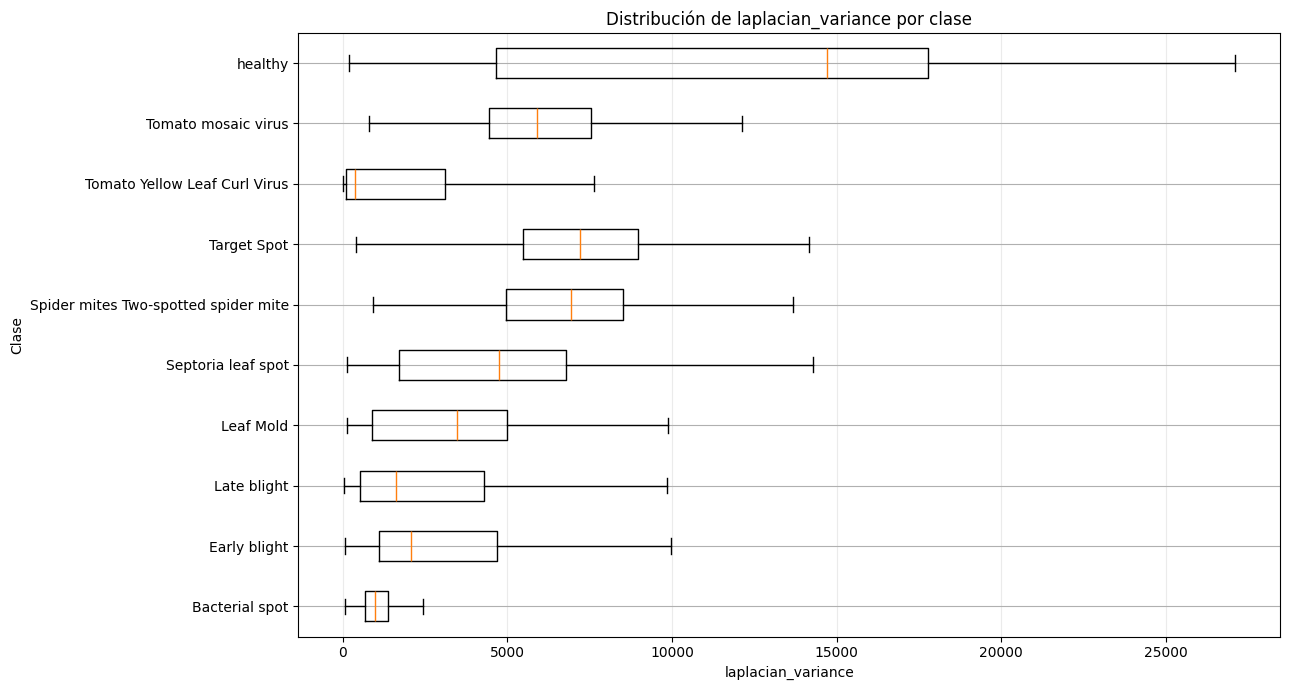

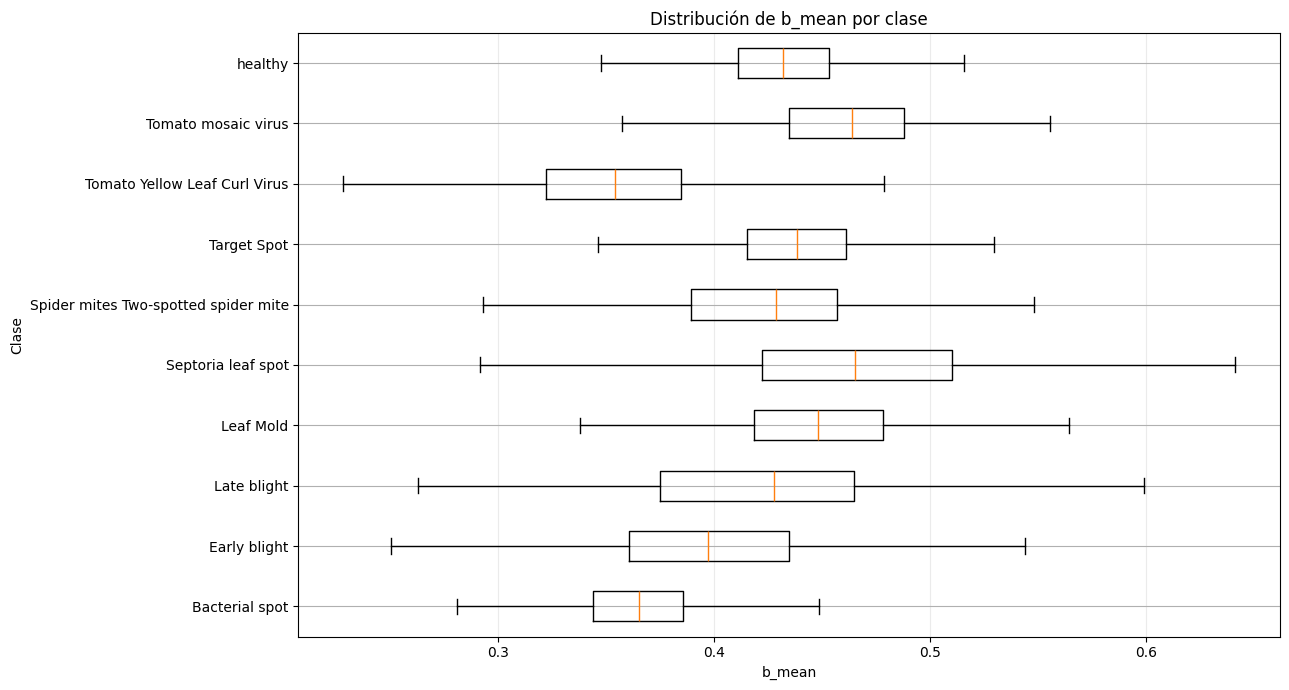

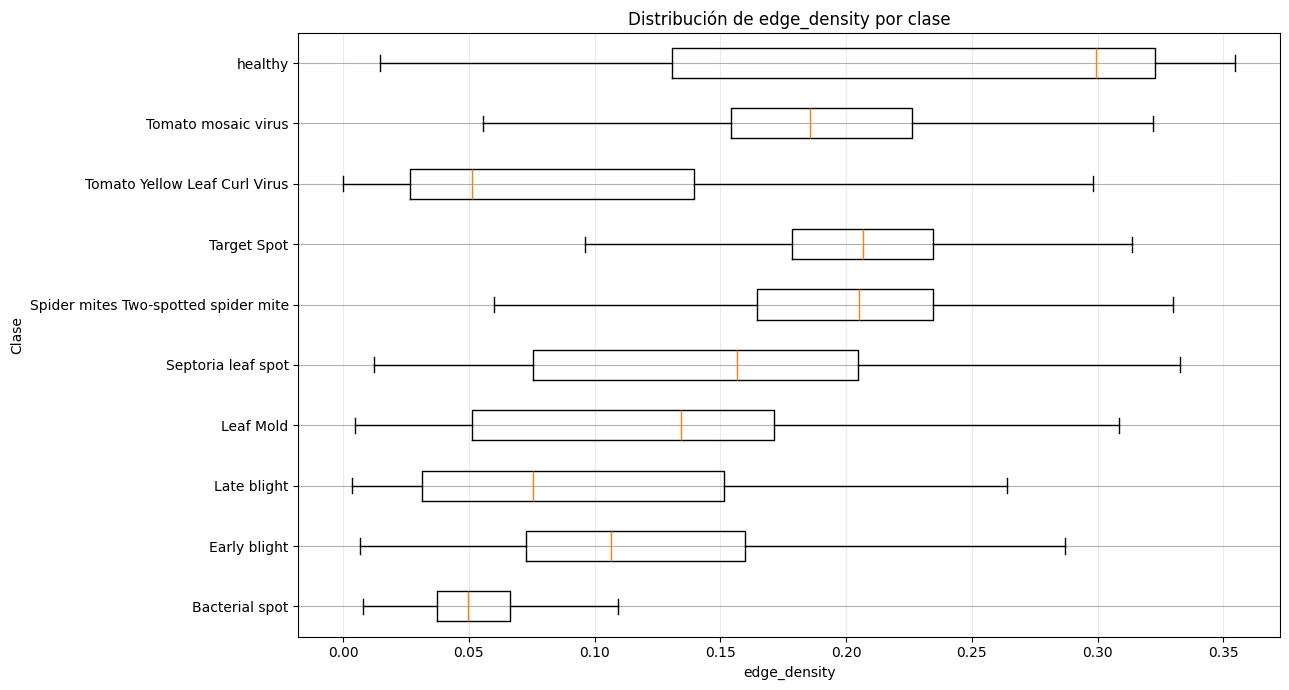

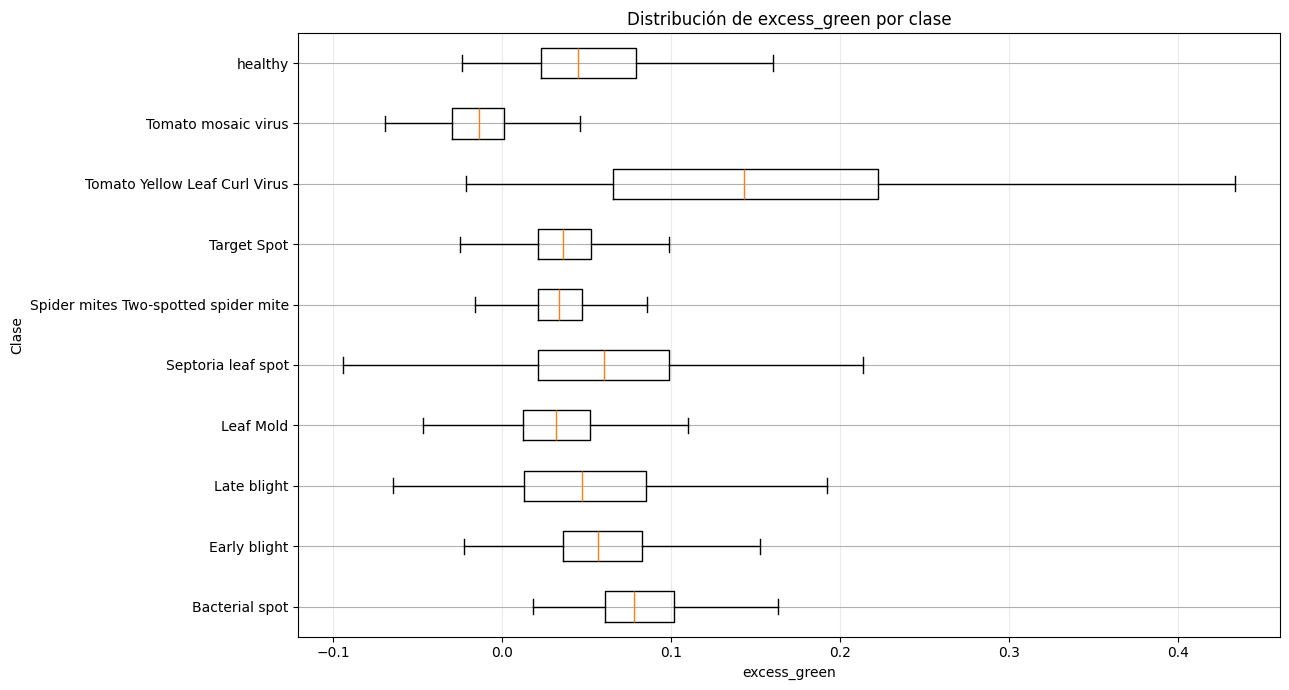

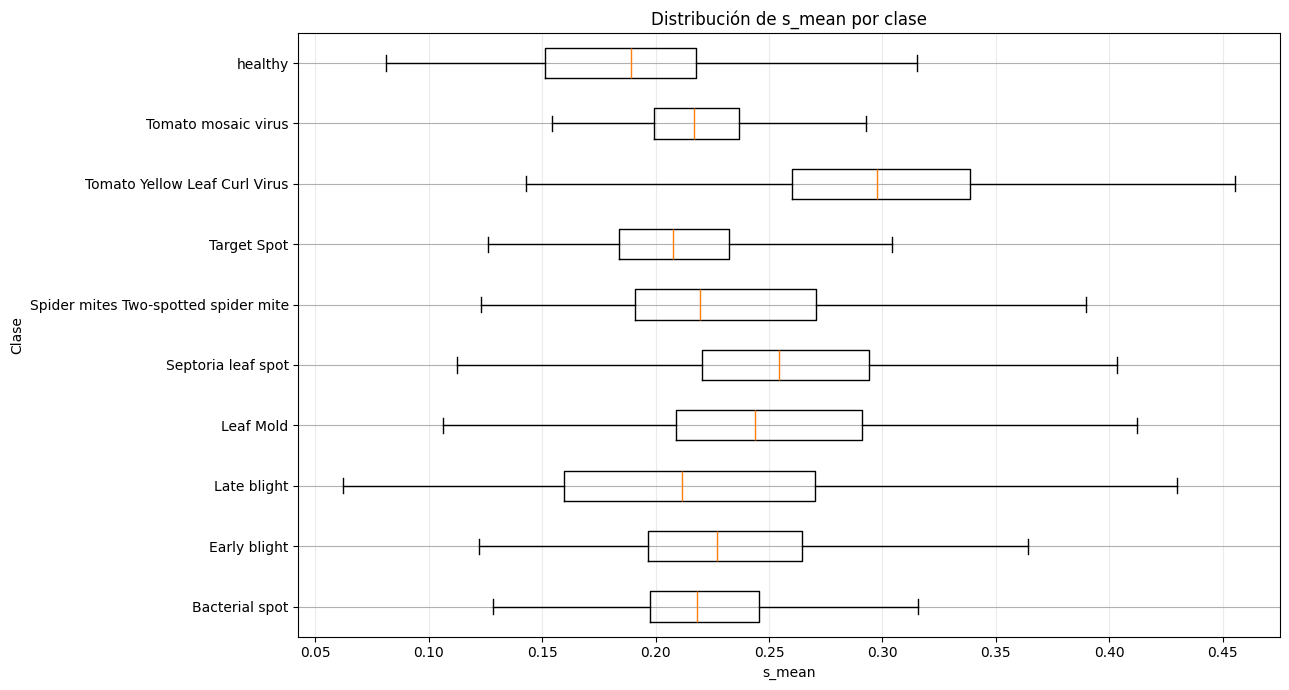


MATRIZ DE CORRELACIÓN — PEARSON


,r_mean,g_mean,b_mean,r_std,g_std,b_std,h_mean,s_mean,v_mean,excess_green,brightness_mean,contrast_std,laplacian_variance,entropy,edge_density
r_mean,1.0000,0.9016,0.7635,0.1395,0.1601,0.3404,0.0880,-0.1566,0.9420,-0.0695,0.9636,0.1506,0.2653,0.3866,0.3231
g_mean,0.9016,1.0000,0.6681,-0.0460,-0.0028,0.2558,0.0798,-0.0413,0.9604,0.2804,0.9789,-0.0376,0.0876,0.2470,0.1026
b_mean,0.7635,0.6681,1.0000,0.1801,0.1189,0.2805,0.3404,-0.5316,0.7775,-0.4799,0.7764,0.1842,0.3595,0.3906,0.3771
r_std,0.1395,-0.0460,0.1801,1.0000,0.8695,0.8298,-0.2347,0.0300,0.0325,-0.3763,0.0403,0.9635,0.4622,0.7018,0.5885
g_std,0.1601,-0.0028,0.1189,0.8695,1.0000,0.8033,-0.1580,0.0996,0.0569,-0.2629,0.0652,0.9636,0.5461,0.5929,0.6256
b_std,0.3404,0.2558,0.2805,0.8298,0.8033,1.0000,-0.1373,0.2698,0.3233,-0.1315,0.2998,0.8453,0.4346,0.6748,0.5432
h_mean,0.0880,0.0798,0.3404,-0.2347,-0.1580,-0.1373,1.0000,-0.2718,0.1366,-0.2620,0.1197,-0.1800,0.0853,-0.0832,0.0215
s_mean,-0.1566,-0.0413,-0.5316,0.0300,0.0996,0.2698,-0.2718,1.0000,-0.0405,0.5709,-0.1430,0.0314,-0.1875,0.0500,-0.1189
v_mean,0.9420,0.9604,0.7775,0.0325,0.0569,0.3233,0.1366,-0.0405,1.0000,0.0722,0.9820,0.0414,0.1749,0.3270,0.2170
excess_green,-0.0695,0.2804,-0.4799,-0.3763,-0.2629,-0.1315,-0.2620,0.5709,0.0722,1.0000,0.0855,-0.3759,-0.4284,-0.2924,-0.4719


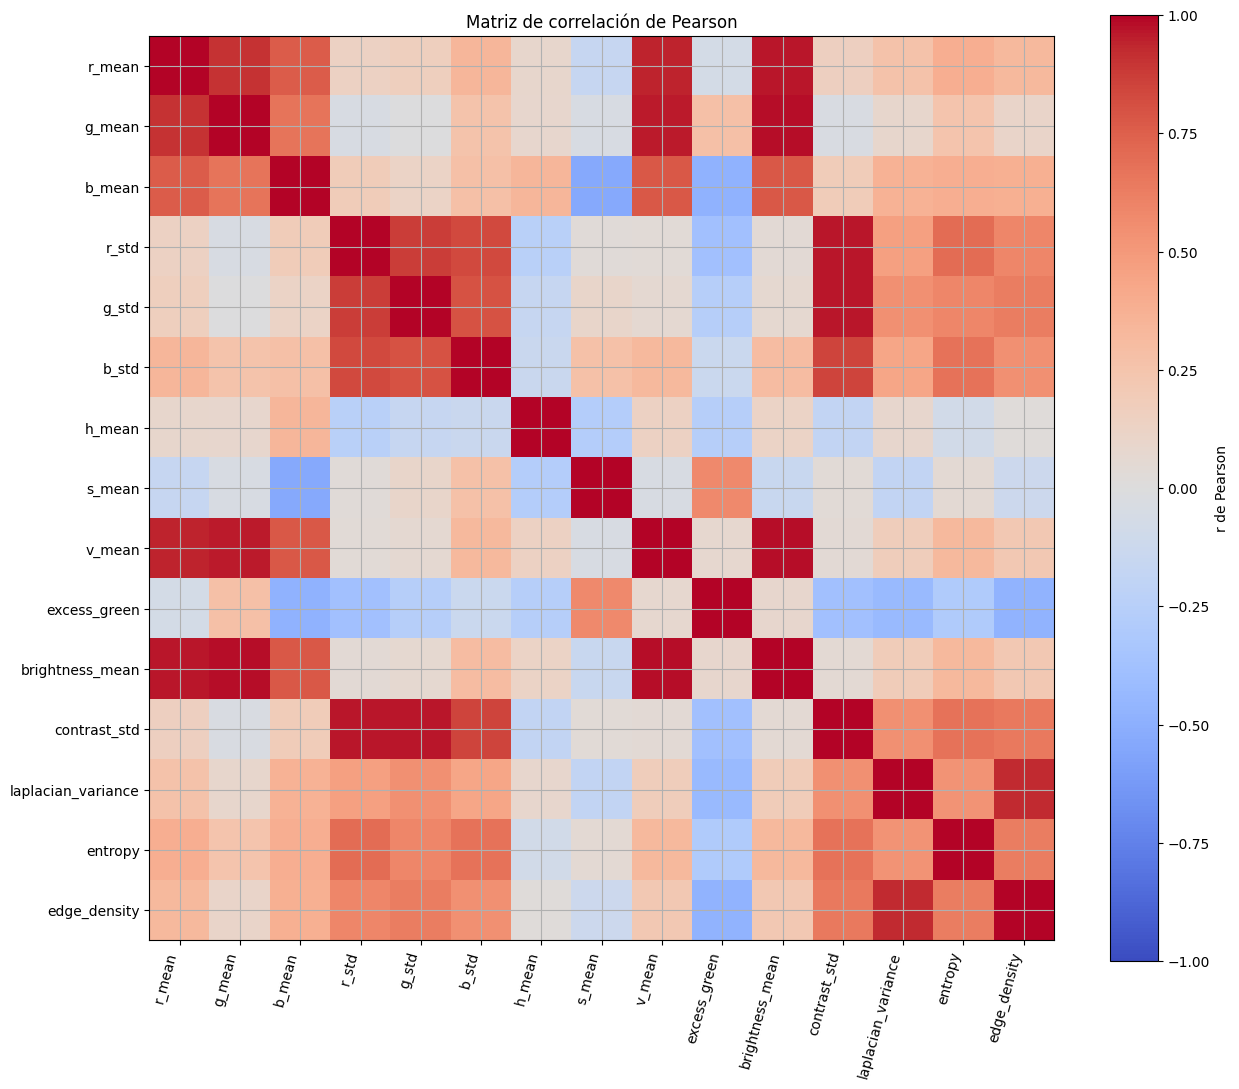


MATRIZ DE CORRELACIÓN — SPEARMAN


,r_mean,g_mean,b_mean,r_std,g_std,b_std,h_mean,s_mean,v_mean,excess_green,brightness_mean,contrast_std,laplacian_variance,entropy,edge_density
r_mean,1.0000,0.8537,0.6961,0.1645,0.2407,0.3516,-0.0300,-0.1692,0.9169,-0.1789,0.9449,0.2039,0.3396,0.2355,0.3383
g_mean,0.8537,1.0000,0.5731,-0.0537,0.0520,0.2438,0.1020,-0.0725,0.9361,0.2105,0.9687,-0.0161,0.0609,0.0235,0.0800
b_mean,0.6961,0.5731,1.0000,0.1849,0.1776,0.2920,0.1705,-0.5731,0.7012,-0.5211,0.7029,0.2223,0.4811,0.2584,0.4074
r_std,0.1645,-0.0537,0.1849,1.0000,0.8816,0.8321,-0.3301,0.0419,0.0318,-0.2977,0.0401,0.9639,0.6211,0.8868,0.6425
g_std,0.2407,0.0520,0.1776,0.8816,1.0000,0.8260,-0.2377,0.0994,0.1234,-0.2672,0.1311,0.9655,0.6244,0.8924,0.6626
b_std,0.3516,0.2438,0.2920,0.8321,0.8260,1.0000,-0.1823,0.2370,0.3194,-0.1541,0.2969,0.8588,0.5618,0.8203,0.6134
h_mean,-0.0300,0.1020,0.1705,-0.3301,-0.2377,-0.1823,1.0000,-0.1003,0.0980,-0.0272,0.0764,-0.2834,-0.1573,-0.2588,-0.1933
s_mean,-0.1692,-0.0725,-0.5731,0.0419,0.0994,0.2370,-0.1003,1.0000,-0.0486,0.4784,-0.1746,0.0330,-0.2280,0.0230,-0.1093
v_mean,0.9169,0.9361,0.7012,0.0318,0.1234,0.3194,0.0980,-0.0486,1.0000,-0.0283,0.9690,0.0724,0.2041,0.1085,0.2109
excess_green,-0.1789,0.2105,-0.5211,-0.2977,-0.2672,-0.1541,-0.0272,0.4784,-0.0283,1.0000,0.0039,-0.3332,-0.5512,-0.3394,-0.4661


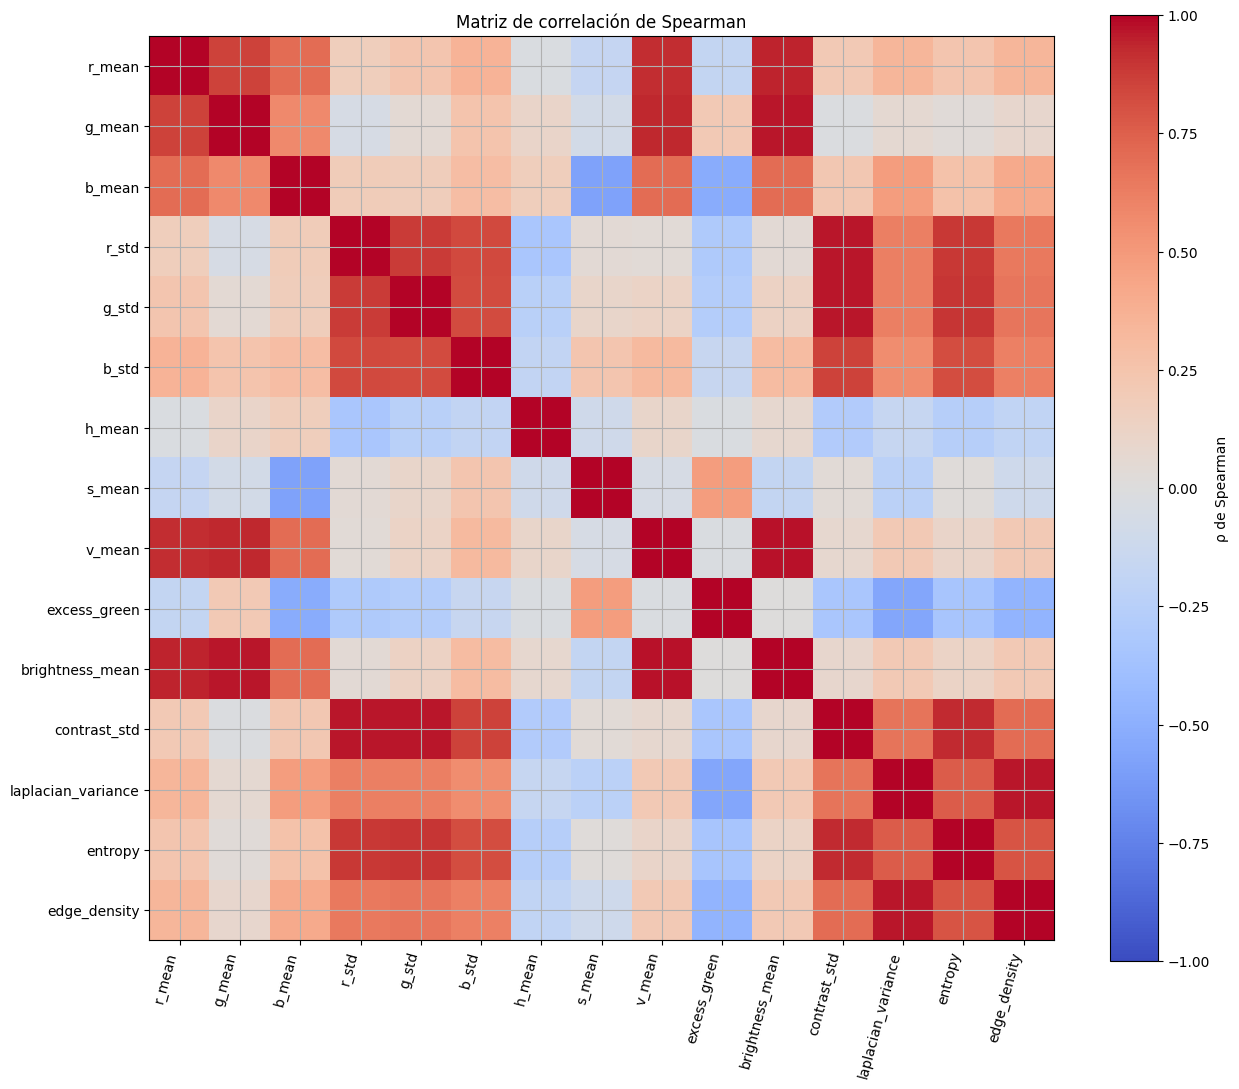


PARES CON MAYOR CORRELACIÓN ABSOLUTA — PEARSON


,Variable 1,Variable 2,Pearson r,Spearman rho,|Pearson|,|Spearman|,Diferencia |rho|-|r|
85,v_mean,brightness_mean,0.9820,0.9690,0.9820,0.9690,-0.0130
22,g_mean,brightness_mean,0.9789,0.9687,0.9789,0.9687,-0.0102
9,r_mean,brightness_mean,0.9636,0.9449,0.9636,0.9449,-0.0187
56,g_std,contrast_std,0.9636,0.9655,0.9636,0.9655,+0.0019
46,r_std,contrast_std,0.9635,0.9639,0.9635,0.9639,+0.0004
20,g_mean,v_mean,0.9604,0.9361,0.9604,0.9361,-0.0243
7,r_mean,v_mean,0.9420,0.9169,0.9420,0.9169,-0.0251
103,laplacian_variance,edge_density,0.9277,0.9663,0.9277,0.9663,+0.0386
0,r_mean,g_mean,0.9016,0.8537,0.9016,0.8537,-0.0479
39,r_std,g_std,0.8695,0.8816,0.8695,0.8816,+0.0121



PARES DONDE SPEARMAN CAPTURA MAYOR ASOCIACIÓN QUE PEARSON


,Variable 1,Variable 2,Pearson r,Spearman rho,|Pearson|,|Spearman|,Diferencia |rho|-|r|
58,g_std,entropy,0.5929,0.8924,0.5929,0.8924,+0.2995
100,contrast_std,entropy,0.6737,0.9233,0.6737,0.9233,+0.2496
102,laplacian_variance,entropy,0.5277,0.7622,0.5277,0.7622,+0.2345
48,r_std,entropy,0.7018,0.8868,0.7018,0.8868,+0.1849
75,h_mean,entropy,-0.0832,-0.2588,0.0832,0.2588,+0.1757
76,h_mean,edge_density,0.0215,-0.1933,0.0215,0.1933,+0.1718
104,entropy,edge_density,0.6261,0.7953,0.6261,0.7953,+0.1692
47,r_std,laplacian_variance,0.4622,0.6211,0.4622,0.6211,+0.1589
67,b_std,entropy,0.6748,0.8203,0.6748,0.8203,+0.1455
99,contrast_std,laplacian_variance,0.5415,0.6707,0.5415,0.6707,+0.1292



ASOCIACIONES CATEGÓRICAS CON EL TARGET


,Variable,N categorías,Chi²,p-value,V de Cramér,Estado
0,modo,1,No aplica,No aplica,No aplica,No estimable: variable constante
1,formato,1,No aplica,No aplica,No aplica,No estimable: variable constante



PAIRPLOT EXPLORATORIO
Features utilizadas : ['laplacian_variance', 'b_mean', 'edge_density', 'excess_green']
Observaciones        : 1,200


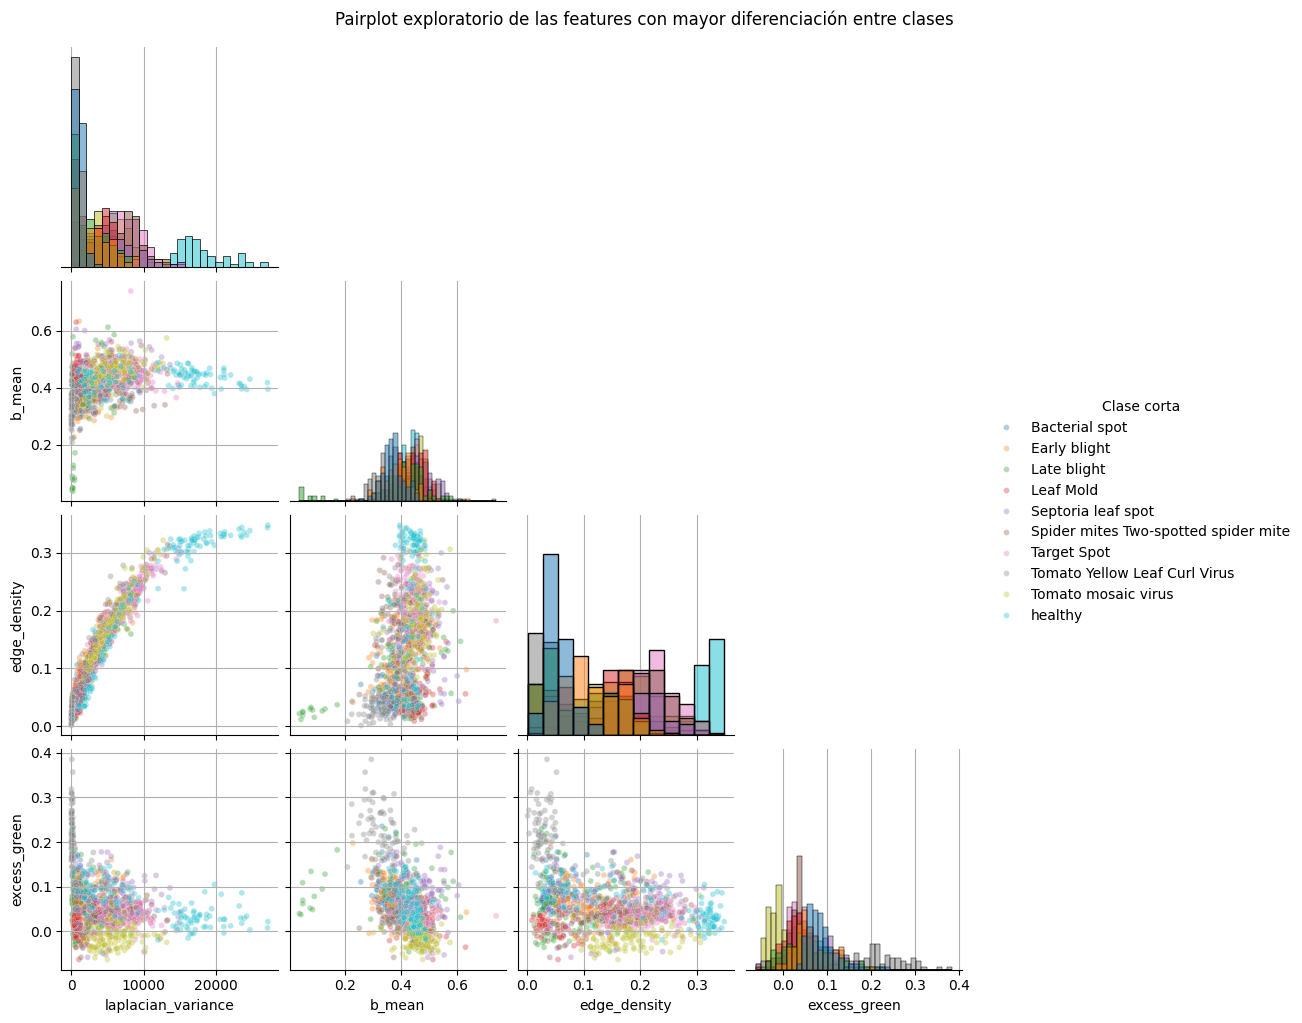


PCA — VARIANZA EXPLICADA


,Componente,Varianza explicada,Varianza acumulada
0,PC1,38.8722%,38.8722%
1,PC2,25.1186%,63.9908%
2,PC3,15.3222%,79.3130%
3,PC4,6.3957%,85.7087%
4,PC5,5.1607%,90.8694%
5,PC6,3.3794%,94.2488%
6,PC7,2.6570%,96.9059%
7,PC8,1.1648%,98.0707%
8,PC9,0.9354%,99.0061%
9,PC10,0.4151%,99.4212%


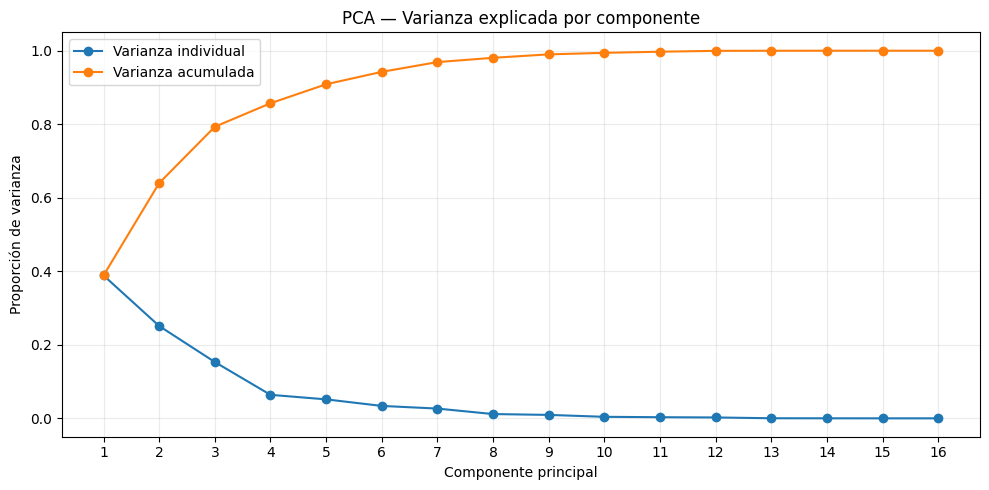


PCA — CARGAS DE LAS DOS PRIMERAS COMPONENTES


,PC1,PC2,|PC1|,|PC2|
b_std,0.3131,-0.1498,0.3131,0.1498
edge_density,0.3128,-0.1465,0.3128,0.1465
entropy,0.3125,-0.1015,0.3125,0.1015
contrast_std,0.3044,-0.2900,0.3044,0.2900
r_std,0.2928,-0.2862,0.2928,0.2862
g_std,0.2876,-0.2721,0.2876,0.2721
laplacian_variance,0.2794,-0.1258,0.2794,0.1258
b_mean,0.2787,0.2744,0.2787,0.2744
r_mean,0.2775,0.3291,0.2775,0.3291
brightness_mean,0.2459,0.3827,0.2459,0.3827


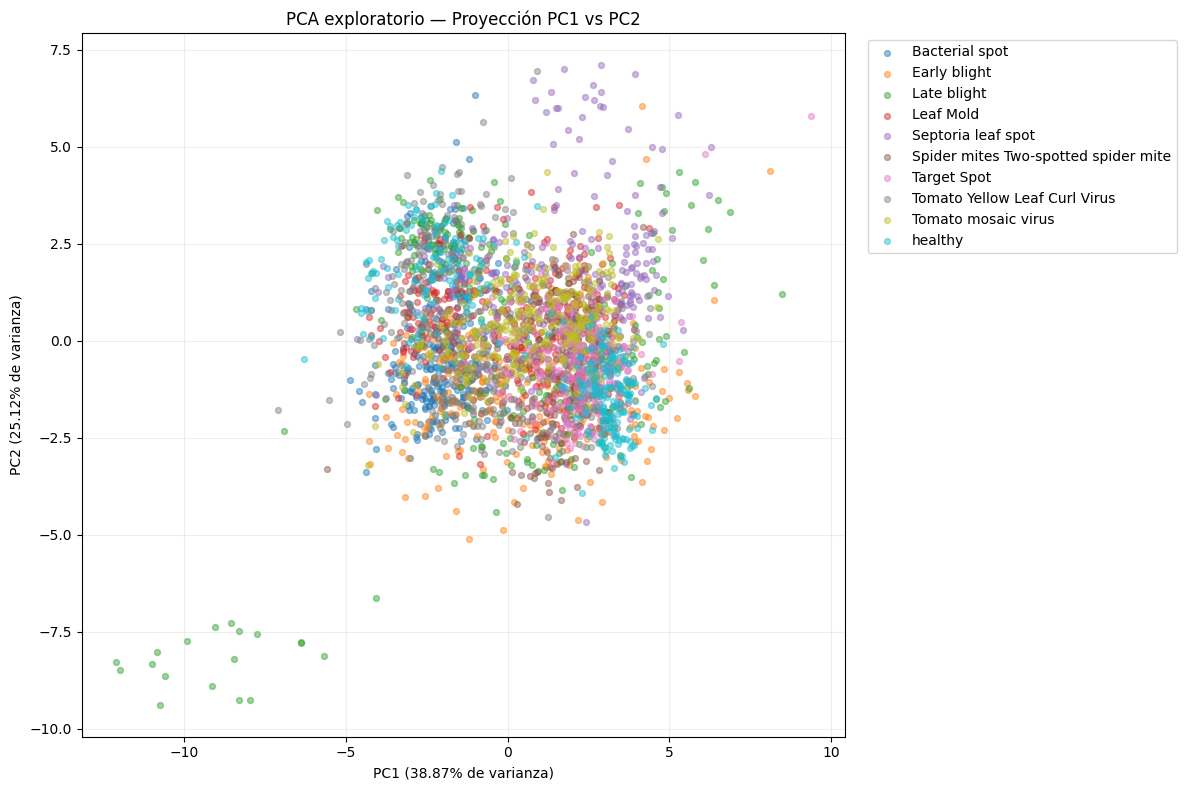


RESUMEN — 5.7

Features con mayor epsilon² respecto del target:


,Feature,Epsilon²,p-value
0,laplacian_variance,0.476088,0.000e+00
1,b_mean,0.433186,0.000e+00
2,edge_density,0.386976,0.000e+00
3,excess_green,0.368686,0.000e+00
4,s_mean,0.351352,0.000e+00
5,v_mean,0.250980,0.000e+00
6,r_mean,0.235313,0.000e+00
7,entropy,0.209917,0.000e+00
8,brightness_mean,0.188076,0.000e+00
9,g_std,0.173614,0.000e+00



Varianza explicada por PC1: 38.87%
Varianza explicada por PC2: 25.12%
Varianza acumulada PC1 + PC2: 63.99%

✅ Relación feature-target evaluada.
✅ Variables constantes excluidas de correlaciones.
✅ Matriz Pearson calculada.
✅ Matriz Spearman calculada.
✅ Asociaciones categóricas evaluadas.
✅ Pairplot reducido implementado.
✅ PCA exploratorio calculado.
✅ El target NO fue codificado artificialmente para correlacionarlo.
✅ df original no fue modificado.
✅ 5.7 — ANÁLISIS BIVARIADO Y MULTIVARIADO COMPLETADO


In [ ]:
# ============================================================
# FASE 1 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# 5.7 ANÁLISIS BIVARIADO Y MULTIVARIADO
# ============================================================
#
# OBJETIVOS
# ------------------------------------------------------------
# A. Numérica vs target categórico:
#       - Medianas por clase.
#       - Kruskal-Wallis.
#       - Tamaño de efecto epsilon².
#
# B. Numérica vs numérica:
#       - Matriz Pearson.
#       - Matriz Spearman.
#       - Comparación Pearson vs Spearman.
#
# C. Categórica vs target:
#       - Chi-cuadrado.
#       - V de Cramér.
#
# D. Exploración multivariada:
#       - Pairplot reducido y estratificado.
#       - PCA exploratorio.
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda:
#
#   - NO modifica df;
#   - NO codifica el target para correlacionarlo;
#   - NO elimina features;
#   - NO realiza selección definitiva de variables;
#   - NO modifica Train / Validation / Test;
#   - NO entrena modelos;
#   - NO reutiliza el scaler/PCA en Fase 2.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    kruskal,
    chi2_contingency
)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from IPython.display import display


# Seaborn se utiliza exclusivamente para el pairplot.
# En Google Colab normalmente se encuentra preinstalado.

try:
    import seaborn as sns
    SEABORN_DISPONIBLE = True

except ImportError:
    SEABORN_DISPONIBLE = False

    print(
        "⚠️ Seaborn no está disponible. "
        "El análisis continuará sin pairplot."
    )


# ============================================================
# 2. CONFIGURACIÓN GENERAL
# ============================================================

RANDOM_STATE = globals().get(
    "RANDOM_STATE",
    42
)


TARGET = globals().get(
    "TARGET",
    "clase"
)


if "df" not in globals():

    if "df_maestro" in globals():
        df = df_maestro.copy()

    else:
        raise NameError(
            "No se encontró 'df' ni 'df_maestro'. "
            "Ejecute las fases anteriores."
        )


if df.empty:
    raise ValueError(
        "El DataFrame está vacío."
    )


if TARGET not in df.columns:
    raise KeyError(
        f"El target '{TARGET}' no existe en df."
    )


N = len(df)


# ============================================================
# 3. DEFINIR VARIABLES NUMÉRICAS
# ============================================================

if "VARIABLES_NUMERICAS_UNIV" in globals():

    variables_numericas = [
        variable
        for variable in VARIABLES_NUMERICAS_UNIV
        if variable in df.columns
    ]

else:

    variables_numericas = (
        df.select_dtypes(
            include=np.number
        )
        .columns
        .tolist()
    )


# El target no debe tratarse como variable numérica,
# incluso si posteriormente fuese codificado.

variables_numericas = [
    variable
    for variable in variables_numericas
    if variable != TARGET
]


# ============================================================
# 4. IDENTIFICAR VARIABLES DE VARIANZA NULA
# ============================================================
#
# Una variable constante no puede participar
# adecuadamente en una correlación.
#
# ============================================================

variables_constantes = [
    variable
    for variable in variables_numericas
    if df[variable].nunique(
        dropna=True
    ) <= 1
]


variables_numericas_variantes = [
    variable
    for variable in variables_numericas
    if variable not in variables_constantes
]


print("=" * 100)
print("5.7 — CONFIGURACIÓN DEL ANÁLISIS")
print("=" * 100)

print(
    f"Observaciones                      : "
    f"{N:,}"
)

print(
    f"Target                             : "
    f"{TARGET}"
)

print(
    f"Variables numéricas originales     : "
    f"{len(variables_numericas)}"
)

print(
    f"Variables numéricas constantes     : "
    f"{len(variables_constantes)}"
)

print(
    f"Variables numéricas analizables    : "
    f"{len(variables_numericas_variantes)}"
)

print(
    "\nVariables constantes excluidas "
    "de las correlaciones:"
)

print(
    variables_constantes
)


# ============================================================
# 5. RELACIÓN FEATURE NUMÉRICA VS TARGET
# ============================================================
#
# Como TARGET es nominal, NO se calcula:
#
#       corr(feature, código_clase)
#
# En su lugar se compara la distribución de cada
# feature entre las K clases mediante Kruskal-Wallis.
#
# ============================================================

resultados_kruskal = []


for variable in variables_numericas_variantes:

    grupos = []

    for clase, grupo in df.groupby(
        TARGET,
        observed=True
    ):

        valores = (
            pd.to_numeric(
                grupo[variable],
                errors="coerce"
            )
            .dropna()
            .to_numpy()
        )

        if len(valores) > 0:
            grupos.append(
                valores
            )


    # Se requieren al menos dos grupos.
    if len(grupos) < 2:
        continue


    try:

        H, p_value = kruskal(
            *grupos
        )


        k = len(grupos)

        n_total = sum(
            len(grupo)
            for grupo in grupos
        )


        # ----------------------------------------------------
        # Tamaño de efecto epsilon cuadrado:
        #
        #           H - K + 1
        # eps² = ---------------
        #             N - K
        #
        # ----------------------------------------------------

        if n_total > k:

            epsilon2 = (
                H
                - k
                + 1
            ) / (
                n_total
                - k
            )

            # Debido a pequeñas aproximaciones numéricas,
            # el valor se restringe al dominio esperado.

            epsilon2 = float(
                np.clip(
                    epsilon2,
                    0.0,
                    1.0
                )
            )

        else:
            epsilon2 = np.nan


        resultados_kruskal.append(
            {
                "Feature": variable,
                "H Kruskal-Wallis": float(H),
                "p-value": float(p_value),
                "Epsilon²": epsilon2,
                "N": int(n_total),
                "K clases": int(k)
            }
        )


    except ValueError as e:

        resultados_kruskal.append(
            {
                "Feature": variable,
                "H Kruskal-Wallis": np.nan,
                "p-value": np.nan,
                "Epsilon²": np.nan,
                "N": np.nan,
                "K clases": np.nan
            }
        )


df_kruskal = (
    pd.DataFrame(
        resultados_kruskal
    )
    .sort_values(
        by="Epsilon²",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 100)
print("RELACIÓN DE CADA FEATURE NUMÉRICA CON EL TARGET")
print("KRUSKAL-WALLIS + TAMAÑO DE EFECTO")
print("=" * 100)


display(
    df_kruskal.style.format(
        {
            "H Kruskal-Wallis": "{:,.4f}",
            "p-value": "{:.3e}",
            "Epsilon²": "{:.6f}",
            "N": "{:,.0f}",
            "K clases": "{:.0f}"
        }
    )
)


# ============================================================
# 6. MEDIANAS DE CADA FEATURE POR CLASE
# ============================================================
#
# Permite visualizar cómo cambia cada característica
# entre las diferentes enfermedades.
#
# ============================================================

df_medianas_clase = (
    df.groupby(
        TARGET,
        observed=True
    )[
        variables_numericas_variantes
    ]
    .median(
        numeric_only=True
    )
    .T
)


print("\n" + "=" * 100)
print("MEDIANA DE CADA FEATURE POR CLASE")
print("=" * 100)


display(
    df_medianas_clase.round(4)
)


# ============================================================
# 7. NORMALIZAR MEDIANAS SOLO PARA VISUALIZACIÓN
# ============================================================
#
# Cada fila corresponde a una feature.
#
# Se estandarizan las medianas entre clases para poder
# comparar visualmente variables con escalas diferentes.
#
# Esto NO modifica df.
#
# ============================================================

media_fila = (
    df_medianas_clase
    .mean(
        axis=1
    )
)


std_fila = (
    df_medianas_clase
    .std(
        axis=1
    )
    .replace(
        0,
        np.nan
    )
)


df_medianas_z = (
    df_medianas_clase
    .sub(
        media_fila,
        axis=0
    )
    .div(
        std_fila,
        axis=0
    )
)


# Etiquetas cortas de las clases
def nombre_clase_corto(nombre):

    return (
        str(nombre)
        .replace(
            "Tomato___",
            ""
        )
        .replace(
            "_",
            " "
        )
    )


columnas_cortas = [
    nombre_clase_corto(
        columna
    )
    for columna in df_medianas_z.columns
]


# ============================================================
# 8. HEATMAP — FEATURE VS TARGET
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 9)
)


imagen = ax.imshow(
    df_medianas_z.to_numpy(),
    aspect="auto",
    cmap="coolwarm"
)


ax.set_xticks(
    np.arange(
        len(
            columnas_cortas
        )
    )
)

ax.set_xticklabels(
    columnas_cortas,
    rotation=75,
    ha="right"
)


ax.set_yticks(
    np.arange(
        len(
            df_medianas_z.index
        )
    )
)

ax.set_yticklabels(
    df_medianas_z.index
)


ax.set_xlabel(
    "Clase"
)

ax.set_ylabel(
    "Feature"
)


ax.set_title(
    "Perfil relativo de las medianas por clase\n"
    "(estandarización por feature únicamente para visualización)"
)


fig.colorbar(
    imagen,
    ax=ax,
    label="Mediana relativa estandarizada"
)


plt.tight_layout()
plt.show()


# ============================================================
# 9. BOXPLOTS DE LAS FEATURES CON MAYOR EFECTO
# ============================================================
#
# Mostrar las 15 variables simultáneamente dificultaría
# la lectura.
#
# Se visualizan únicamente las características que presentan
# los mayores valores exploratorios de epsilon².
#
# IMPORTANTE:
# No constituye selección definitiva de variables.
#
# ============================================================

N_TOP_BOXPLOTS = 5


top_features_target = (
    df_kruskal
    .dropna(
        subset=[
            "Epsilon²"
        ]
    )
    .head(
        N_TOP_BOXPLOTS
    )["Feature"]
    .tolist()
)


clases_ordenadas = sorted(
    df[TARGET]
    .astype(str)
    .unique()
)


for variable in top_features_target:

    datos_boxplot = []

    etiquetas_boxplot = []


    for clase in clases_ordenadas:

        serie = (
            pd.to_numeric(
                df.loc[
                    df[TARGET].astype(str)
                    == clase,
                    variable
                ],
                errors="coerce"
            )
            .dropna()
            .to_numpy()
        )


        datos_boxplot.append(
            serie
        )

        etiquetas_boxplot.append(
            nombre_clase_corto(
                clase
            )
        )


    fig, ax = plt.subplots(
        figsize=(13, 7)
    )


    ax.boxplot(
        datos_boxplot,
        vert=False,
        tick_labels=etiquetas_boxplot,

        # Los outliers ya fueron estudiados en el EDA
        # univariado. Se ocultan aquí únicamente para mejorar
        # la legibilidad entre clases.
        showfliers=False
    )


    ax.set_xlabel(
        variable
    )

    ax.set_ylabel(
        "Clase"
    )


    ax.set_title(
        f"Distribución de {variable} por clase"
    )


    ax.grid(
        axis="x",
        alpha=0.25
    )


    plt.tight_layout()
    plt.show()


# ============================================================
# 10. MATRIZ DE CORRELACIÓN DE PEARSON
# ============================================================

df_numericas_corr = (
    df[
        variables_numericas_variantes
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
)


corr_pearson = (
    df_numericas_corr
    .corr(
        method="pearson"
    )
)


print("\n" + "=" * 100)
print("MATRIZ DE CORRELACIÓN — PEARSON")
print("=" * 100)


display(
    corr_pearson.round(
        4
    )
)


# ============================================================
# 11. VISUALIZACIÓN — PEARSON
# ============================================================

fig, ax = plt.subplots(
    figsize=(13, 11)
)


imagen = ax.imshow(
    corr_pearson.to_numpy(),
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)


ax.set_xticks(
    np.arange(
        len(
            corr_pearson.columns
        )
    )
)

ax.set_yticks(
    np.arange(
        len(
            corr_pearson.index
        )
    )
)


ax.set_xticklabels(
    corr_pearson.columns,
    rotation=75,
    ha="right"
)

ax.set_yticklabels(
    corr_pearson.index
)


ax.set_title(
    "Matriz de correlación de Pearson"
)


fig.colorbar(
    imagen,
    ax=ax,
    label="r de Pearson"
)


plt.tight_layout()
plt.show()


# ============================================================
# 12. MATRIZ DE CORRELACIÓN DE SPEARMAN
# ============================================================

corr_spearman = (
    df_numericas_corr
    .corr(
        method="spearman"
    )
)


print("\n" + "=" * 100)
print("MATRIZ DE CORRELACIÓN — SPEARMAN")
print("=" * 100)


display(
    corr_spearman.round(
        4
    )
)


# ============================================================
# 13. VISUALIZACIÓN — SPEARMAN
# ============================================================

fig, ax = plt.subplots(
    figsize=(13, 11)
)


imagen = ax.imshow(
    corr_spearman.to_numpy(),
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)


ax.set_xticks(
    np.arange(
        len(
            corr_spearman.columns
        )
    )
)

ax.set_yticks(
    np.arange(
        len(
            corr_spearman.index
        )
    )
)


ax.set_xticklabels(
    corr_spearman.columns,
    rotation=75,
    ha="right"
)

ax.set_yticklabels(
    corr_spearman.index
)


ax.set_title(
    "Matriz de correlación de Spearman"
)


fig.colorbar(
    imagen,
    ax=ax,
    label="ρ de Spearman"
)


plt.tight_layout()
plt.show()


# ============================================================
# 14. COMPARAR PEARSON Y SPEARMAN
# ============================================================
#
# Se construye una tabla para cada par único de variables.
#
# La diferencia:
#
#       |rho| - |r|
#
# puede ser útil para detectar relaciones en que Spearman
# captura una asociación monotónica más claramente que
# Pearson.
#
# ============================================================

comparacion_correlaciones = []


for i, variable_1 in enumerate(
    variables_numericas_variantes
):

    for j in range(
        i + 1,
        len(
            variables_numericas_variantes
        )
    ):

        variable_2 = (
            variables_numericas_variantes[j]
        )


        r = float(
            corr_pearson.loc[
                variable_1,
                variable_2
            ]
        )


        rho = float(
            corr_spearman.loc[
                variable_1,
                variable_2
            ]
        )


        comparacion_correlaciones.append(
            {
                "Variable 1": variable_1,
                "Variable 2": variable_2,
                "Pearson r": r,
                "Spearman rho": rho,
                "|Pearson|": abs(r),
                "|Spearman|": abs(rho),
                "Diferencia |rho|-|r|": (
                    abs(rho)
                    - abs(r)
                )
            }
        )


df_comparacion_correlaciones = (
    pd.DataFrame(
        comparacion_correlaciones
    )
)


# Pares con mayor correlación absoluta según Pearson
top_pearson = (
    df_comparacion_correlaciones
    .sort_values(
        "|Pearson|",
        ascending=False
    )
    .head(15)
)


print("\n" + "=" * 100)
print("PARES CON MAYOR CORRELACIÓN ABSOLUTA — PEARSON")
print("=" * 100)


display(
    top_pearson.style.format(
        {
            "Pearson r": "{:.4f}",
            "Spearman rho": "{:.4f}",
            "|Pearson|": "{:.4f}",
            "|Spearman|": "{:.4f}",
            "Diferencia |rho|-|r|": "{:+.4f}"
        }
    )
)


# Pares donde Spearman supera más claramente a Pearson
top_diferencia_spearman = (
    df_comparacion_correlaciones
    .sort_values(
        "Diferencia |rho|-|r|",
        ascending=False
    )
    .head(15)
)


print("\n" + "=" * 100)
print(
    "PARES DONDE SPEARMAN CAPTURA "
    "MAYOR ASOCIACIÓN QUE PEARSON"
)
print("=" * 100)


display(
    top_diferencia_spearman.style.format(
        {
            "Pearson r": "{:.4f}",
            "Spearman rho": "{:.4f}",
            "|Pearson|": "{:.4f}",
            "|Spearman|": "{:.4f}",
            "Diferencia |rho|-|r|": "{:+.4f}"
        }
    )
)


# ============================================================
# 15. ASOCIACIÓN CATEGÓRICA CON EL TARGET
# ============================================================

if "VARIABLES_CATEGORICAS_UNIV" in globals():

    variables_categoricas = [
        variable
        for variable
        in VARIABLES_CATEGORICAS_UNIV
        if (
            variable in df.columns
            and variable != TARGET
        )
    ]

else:

    variables_categoricas = [
        variable
        for variable
        in df.select_dtypes(
            include=[
                "object",
                "category",
                "string"
            ]
        ).columns
        if variable != TARGET
    ]


# ============================================================
# 16. FUNCIÓN V DE CRAMÉR
# ============================================================

def calcular_cramers_v(tabla_contingencia):
    """
    Calcula Chi-cuadrado y V de Cramér.

    Retorna NaN cuando alguna de las variables
    posee una sola categoría.
    """

    r, c = (
        tabla_contingencia.shape
    )


    n = int(
        tabla_contingencia
        .to_numpy()
        .sum()
    )


    if (
        r < 2
        or c < 2
        or n == 0
    ):

        return (
            np.nan,
            np.nan,
            np.nan
        )


    chi2, p_value, _, _ = (
        chi2_contingency(
            tabla_contingencia
        )
    )


    denominador = (
        n
        * min(
            r - 1,
            c - 1
        )
    )


    if denominador <= 0:

        cramers_v = np.nan

    else:

        cramers_v = np.sqrt(
            chi2
            / denominador
        )


    return (
        float(chi2),
        float(p_value),
        float(cramers_v)
    )


resultados_categoricos = []


for variable in variables_categoricas:

    n_categorias = int(
        df[variable]
        .nunique(
            dropna=False
        )
    )


    if n_categorias <= 1:

        resultados_categoricos.append(
            {
                "Variable": variable,
                "N categorías": n_categorias,
                "Chi²": np.nan,
                "p-value": np.nan,
                "V de Cramér": np.nan,
                "Estado": (
                    "No estimable: "
                    "variable constante"
                )
            }
        )

        continue


    tabla_contingencia = pd.crosstab(
        df[variable],
        df[TARGET],
        dropna=False
    )


    chi2, p_value, cramers_v = (
        calcular_cramers_v(
            tabla_contingencia
        )
    )


    resultados_categoricos.append(
        {
            "Variable": variable,
            "N categorías": n_categorias,
            "Chi²": chi2,
            "p-value": p_value,
            "V de Cramér": cramers_v,
            "Estado": "Estimado"
        }
    )


df_asociaciones_categoricas = (
    pd.DataFrame(
        resultados_categoricos
    )
)


print("\n" + "=" * 100)
print("ASOCIACIONES CATEGÓRICAS CON EL TARGET")
print("=" * 100)


if df_asociaciones_categoricas.empty:

    print(
        "No existen variables categóricas adicionales "
        "al target."
    )

else:

    display(
        df_asociaciones_categoricas.style.format(
            {
                "Chi²": "{:,.4f}",
                "p-value": "{:.3e}",
                "V de Cramér": "{:.6f}"
            },
            na_rep="No aplica"
        )
    )


# ============================================================
# 17. PAIRPLOT REDUCIDO Y ESTRATIFICADO
# ============================================================
#
# Para conservar legibilidad:
#
# - se utilizan únicamente 4 features;
# - se seleccionan según mayor epsilon²;
# - se toma una muestra máxima por clase.
#
# ============================================================

N_FEATURES_PAIRPLOT = 4
MAX_MUESTRA_POR_CLASE = 120


features_pairplot = (
    df_kruskal
    .dropna(
        subset=[
            "Epsilon²"
        ]
    )
    .head(
        N_FEATURES_PAIRPLOT
    )["Feature"]
    .tolist()
)


if (
    SEABORN_DISPONIBLE
    and len(features_pairplot) >= 2
):

    columnas_pairplot = (
        [TARGET]
        + features_pairplot
    )


    muestras_clases = []


    for clase, grupo in df[
        columnas_pairplot
    ].dropna().groupby(
        TARGET,
        observed=True
    ):

        n_muestra = min(
            len(grupo),
            MAX_MUESTRA_POR_CLASE
        )


        muestras_clases.append(
            grupo.sample(
                n=n_muestra,
                random_state=RANDOM_STATE
            )
        )


    df_pairplot = pd.concat(
        muestras_clases,
        ignore_index=True
    )


    # Crear nombres más cortos solo para la leyenda.
    df_pairplot = (
        df_pairplot.copy()
    )


    df_pairplot["Clase corta"] = (
        df_pairplot[TARGET]
        .astype(str)
        .map(
            nombre_clase_corto
        )
    )


    print("\n" + "=" * 100)
    print("PAIRPLOT EXPLORATORIO")
    print("=" * 100)

    print(
        f"Features utilizadas : "
        f"{features_pairplot}"
    )

    print(
        f"Observaciones        : "
        f"{len(df_pairplot):,}"
    )


    grafico_pair = sns.pairplot(
        data=df_pairplot,
        vars=features_pairplot,
        hue="Clase corta",
        corner=True,
        diag_kind="hist",
        plot_kws={
            "alpha": 0.35,
            "s": 18
        }
    )


    grafico_pair.fig.suptitle(
        "Pairplot exploratorio de las features "
        "con mayor diferenciación entre clases",
        y=1.02
    )


    plt.show()


else:

    print(
        "\nPairplot omitido: no existe Seaborn "
        "o no hay suficientes features."
    )


# ============================================================
# 18. PCA EXPLORATORIO
# ============================================================
#
# IMPORTANTE:
#
# El PCA y StandardScaler se ajustan aquí sobre el dataset
# completo ÚNICAMENTE con finalidad exploratoria.
#
# Estos objetos NO deberán reutilizarse en Fase 2.
#
# Si PCA se incorpora al modelo:
#
#   Train -> fit scaler/PCA
#   Validation/Test -> transform únicamente
#
# ============================================================

features_pca = (
    variables_numericas_variantes.copy()
)


df_pca_base = (
    df[
        features_pca
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
    .copy()
)


# ============================================================
# 19. TRATAMIENTO CIRCULAR DE h_mean PARA PCA
# ============================================================

if "h_mean" in df_pca_base.columns:

    h_radianes = np.deg2rad(
        df_pca_base[
            "h_mean"
        ]
    )


    df_pca_base[
        "h_sin"
    ] = np.sin(
        h_radianes
    )


    df_pca_base[
        "h_cos"
    ] = np.cos(
        h_radianes
    )


    # Se elimina el ángulo lineal del PCA.
    df_pca_base = (
        df_pca_base
        .drop(
            columns=[
                "h_mean"
            ]
        )
    )


# Mantener solo filas completas para esta exploración.
mask_pca = (
    df_pca_base
    .notna()
    .all(
        axis=1
    )
)


X_pca = (
    df_pca_base
    .loc[
        mask_pca
    ]
)


y_pca = (
    df.loc[
        mask_pca,
        TARGET
    ]
    .astype(str)
)


# ============================================================
# 20. ESTANDARIZACIÓN EXPLORATORIA
# ============================================================

scaler_pca_eda = StandardScaler()


X_pca_scaled = (
    scaler_pca_eda
    .fit_transform(
        X_pca
    )
)


# ============================================================
# 21. AJUSTAR PCA
# ============================================================

pca_eda = PCA()


scores_pca = (
    pca_eda
    .fit_transform(
        X_pca_scaled
    )
)


varianza_explicada = (
    pca_eda
    .explained_variance_ratio_
)


varianza_acumulada = (
    np.cumsum(
        varianza_explicada
    )
)


df_varianza_pca = pd.DataFrame(
    {
        "Componente": [
            f"PC{i + 1}"
            for i
            in range(
                len(
                    varianza_explicada
                )
            )
        ],

        "Varianza explicada": (
            varianza_explicada
        ),

        "Varianza acumulada": (
            varianza_acumulada
        )
    }
)


print("\n" + "=" * 100)
print("PCA — VARIANZA EXPLICADA")
print("=" * 100)


display(
    df_varianza_pca.style.format(
        {
            "Varianza explicada": "{:.4%}",
            "Varianza acumulada": "{:.4%}"
        }
    )
)


# ============================================================
# 22. SCREE PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 5)
)


componentes = np.arange(
    1,
    len(
        varianza_explicada
    ) + 1
)


ax.plot(
    componentes,
    varianza_explicada,
    marker="o",
    label="Varianza individual"
)


ax.plot(
    componentes,
    varianza_acumulada,
    marker="o",
    label="Varianza acumulada"
)


ax.set_xlabel(
    "Componente principal"
)

ax.set_ylabel(
    "Proporción de varianza"
)

ax.set_title(
    "PCA — Varianza explicada por componente"
)

ax.set_xticks(
    componentes
)

ax.grid(
    alpha=0.25
)

ax.legend()


plt.tight_layout()
plt.show()


# ============================================================
# 23. CARGAS DE PC1 Y PC2
# ============================================================

df_cargas_pca = pd.DataFrame(
    pca_eda.components_[
        :2
    ].T,

    index=X_pca.columns,

    columns=[
        "PC1",
        "PC2"
    ]
)


df_cargas_pca[
    "|PC1|"
] = (
    df_cargas_pca[
        "PC1"
    ]
    .abs()
)


df_cargas_pca[
    "|PC2|"
] = (
    df_cargas_pca[
        "PC2"
    ]
    .abs()
)


print("\n" + "=" * 100)
print("PCA — CARGAS DE LAS DOS PRIMERAS COMPONENTES")
print("=" * 100)


display(
    df_cargas_pca
    .sort_values(
        "|PC1|",
        ascending=False
    )
    .round(4)
)


# ============================================================
# 24. PROYECCIÓN PC1 VS PC2
# ============================================================
#
# Para no saturar el gráfico se utiliza una muestra
# estratificada únicamente para la visualización.
#
# Los componentes fueron calculados con todas las filas
# disponibles.
#
# ============================================================

df_scores_pca = pd.DataFrame(
    {
        "PC1": scores_pca[:, 0],
        "PC2": scores_pca[:, 1],
        TARGET: y_pca.to_numpy()
    }
)


MAX_PCA_POR_CLASE = 300


muestras_pca = []


for clase, grupo in df_scores_pca.groupby(
    TARGET,
    observed=True
):

    n_muestra = min(
        len(grupo),
        MAX_PCA_POR_CLASE
    )


    muestras_pca.append(
        grupo.sample(
            n=n_muestra,
            random_state=RANDOM_STATE
        )
    )


df_pca_plot = pd.concat(
    muestras_pca,
    ignore_index=True
)


fig, ax = plt.subplots(
    figsize=(12, 8)
)


for clase, grupo in df_pca_plot.groupby(
    TARGET,
    observed=True
):

    ax.scatter(
        grupo["PC1"],
        grupo["PC2"],
        s=18,
        alpha=0.45,
        label=nombre_clase_corto(
            clase
        )
    )


pc1_pct = (
    varianza_explicada[0]
    * 100
)

pc2_pct = (
    varianza_explicada[1]
    * 100
)


ax.set_xlabel(
    f"PC1 ({pc1_pct:.2f}% de varianza)"
)

ax.set_ylabel(
    f"PC2 ({pc2_pct:.2f}% de varianza)"
)


ax.set_title(
    "PCA exploratorio — Proyección PC1 vs PC2"
)


ax.grid(
    alpha=0.20
)


ax.legend(
    bbox_to_anchor=(
        1.02,
        1
    ),
    loc="upper left"
)


plt.tight_layout()
plt.show()


# ============================================================
# 25. RESUMEN PARA INTERPRETACIÓN POSTERIOR
# ============================================================

print("\n" + "=" * 100)
print("RESUMEN — 5.7")
print("=" * 100)


if not df_kruskal.empty:

    print(
        "\nFeatures con mayor epsilon² "
        "respecto del target:"
    )

    display(
        df_kruskal[
            [
                "Feature",
                "Epsilon²",
                "p-value"
            ]
        ]
        .head(10)
        .style.format(
            {
                "Epsilon²": "{:.6f}",
                "p-value": "{:.3e}"
            }
        )
    )


print(
    "\nVarianza explicada por PC1:"
    f" {varianza_explicada[0] * 100:.2f}%"
)


print(
    "Varianza explicada por PC2:"
    f" {varianza_explicada[1] * 100:.2f}%"
)


print(
    "Varianza acumulada PC1 + PC2:"
    f" {varianza_acumulada[1] * 100:.2f}%"
)


# ============================================================
# 26. CONTROLES FINALES
# ============================================================

assert (
    TARGET
    not in variables_numericas_variantes
), (
    "El target fue incluido incorrectamente "
    "entre las variables numéricas."
)


assert all(
    df[variable]
    .nunique(
        dropna=True
    ) > 1

    for variable
    in variables_numericas_variantes
), (
    "Existe una variable constante dentro "
    "de las matrices de correlación."
)


assert (
    corr_pearson.shape
    ==
    corr_spearman.shape
), (
    "Las matrices Pearson y Spearman "
    "no poseen la misma dimensión."
)


assert np.isclose(
    varianza_explicada.sum(),
    1.0
), (
    "La varianza explicada del PCA "
    "no suma aproximadamente 1."
)


print("\n" + "=" * 100)

print(
    "✅ Relación feature-target evaluada."
)

print(
    "✅ Variables constantes excluidas "
    "de correlaciones."
)

print(
    "✅ Matriz Pearson calculada."
)

print(
    "✅ Matriz Spearman calculada."
)

print(
    "✅ Asociaciones categóricas evaluadas."
)

print(
    "✅ Pairplot reducido implementado."
)

print(
    "✅ PCA exploratorio calculado."
)

print(
    "✅ El target NO fue codificado "
    "artificialmente para correlacionarlo."
)

print(
    "✅ df original no fue modificado."
)

print("=" * 100)

print(
    "✅ 5.7 — ANÁLISIS BIVARIADO "
    "Y MULTIVARIADO COMPLETADO"
)

## 5.8 Análisis temporal

El análisis temporal busca determinar si la distribución de los datos cambia en.

## 5.8.1 Verificación de temporalidad en el dataset actual

En las etapas estructurales anteriores se determinó que el DataFrame maestro no.

## 5.8.2 Tendencia

En un dataset temporal, la tendencia de una característica podría estudiarse.

## 5.8.3 Estacionalidad

La estacionalidad representa patrones que se repiten periódicamente.

## 5.8.4 Cambios de distribución en el tiempo

Si existieran ventanas temporales reales, podría compararse.

## 5.8.5 Eventos o períodos anómalos

Con una variable temporal podría definirse una secuencia de indicadores.

## 5.8.6 Qué no debe utilizarse como tiempo

No deben considerarse variables temporales válidas.

## 5.8.7 Definición preliminar de referencia y producción

Dado que no existe una dimensión temporal real, la estrategia del proyecto será.

## 5.8.8 Separación entre EDA y simulación de producción

Esta sección resume separación entre EDA y simulación de producción y su función dentro del proyecto MLOps.

## 5.8.9 Temporalidad futura en el sistema MLOps

Aunque PlantVillage no posee timestamps de captura, el servicio de inferencia sí.


In [ ]:
# ============================================================
# FASE 1 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# 5.8 ANÁLISIS TEMPORAL
# ============================================================
#
# OBJETIVOS
# ------------------------------------------------------------
# 1. Verificar si el dataset posee una dimensión temporal real.
# 2. Identificar columnas temporales previamente detectadas.
# 3. Determinar si es posible estudiar:
#
#       - tendencia;
#       - estacionalidad;
#       - cambios de distribución temporal;
#       - períodos anómalos.
#
# 4. Evitar construir pseudo-temporalidad a partir de:
#
#       - índice;
#       - archivo;
#       - ruta;
#       - orden de lectura;
#       - fecha del sistema.
#
# 5. Definir conceptualmente las futuras ventanas:
#
#       W0 -> referencia
#       W1 -> estable
#       W2 -> drift leve
#       W3 -> drift moderado
#       W4 -> drift significativo
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda:
#
#   - NO divide los datos;
#   - NO crea todavía las ventanas W0-W4;
#   - NO altera imágenes;
#   - NO genera drift;
#   - NO modifica el target;
#   - NO utiliza el índice como tiempo;
#   - NO utiliza fechas de archivos como tiempo;
#   - NO entrena modelos.
#
# Su finalidad es exclusivamente metodológica y exploratoria.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd

from IPython.display import display


# ============================================================
# 2. VERIFICAR DATAFRAME
# ============================================================

if "df" not in globals():

    if "df_maestro" in globals():

        df = df_maestro.copy()

    else:

        raise NameError(
            "No se encontró 'df' ni 'df_maestro'. "
            "Ejecute previamente las secciones anteriores."
        )


if df.empty:

    raise ValueError(
        "El DataFrame está vacío."
    )


N, P = df.shape


TARGET = globals().get(
    "TARGET",
    "clase"
)


# ============================================================
# 3. RECUPERAR VARIABLES TEMPORALES DETECTADAS EN 5.2
# ============================================================
#
# La sección 5.2 ya realizó una clasificación estructural
# de las variables.
#
# Se reutiliza COLUMNAS_TEMPORALES cuando exista.
# ============================================================

if "COLUMNAS_TEMPORALES" in globals():

    columnas_temporales_detectadas = [
        columna
        for columna
        in COLUMNAS_TEMPORALES
        if columna in df.columns
    ]

else:

    # --------------------------------------------------------
    # Estrategia de respaldo.
    #
    # Se buscan:
    #
    #   1. columnas con dtype datetime;
    #   2. nombres claramente temporales.
    #
    # NO se intenta convertir automáticamente "archivo"
    # o "ruta" en fechas.
    # --------------------------------------------------------

    columnas_datetime = [
        columna
        for columna
        in df.columns
        if pd.api.types.is_datetime64_any_dtype(
            df[columna]
        )
    ]


    nombres_temporales_validos = {
        "fecha",
        "date",
        "datetime",
        "timestamp",
        "time",
        "fecha_captura",
        "capture_date",
        "created_at",
        "event_time",
        "año",
        "anio",
        "year",
        "mes",
        "month",
        "dia",
        "día",
        "day"
    }


    columnas_por_nombre = [
        columna
        for columna
        in df.columns
        if columna.lower()
        in nombres_temporales_validos
    ]


    columnas_temporales_detectadas = sorted(
        set(
            columnas_datetime
            +
            columnas_por_nombre
        )
    )


# ============================================================
# 4. DETERMINAR DISPONIBILIDAD DE TEMPORALIDAD REAL
# ============================================================

TEMPORALIDAD_REAL_DISPONIBLE = (
    len(
        columnas_temporales_detectadas
    )
    > 0
)


print("=" * 100)
print("5.8 — AUDITORÍA DE TEMPORALIDAD")
print("=" * 100)

print(
    f"Observaciones                     : "
    f"{N:,}"
)

print(
    f"Columnas actuales                 : "
    f"{P}"
)

print(
    f"Variables temporales detectadas   : "
    f"{columnas_temporales_detectadas}"
)

print(
    f"Temporalidad real disponible      : "
    f"{TEMPORALIDAD_REAL_DISPONIBLE}"
)


# ============================================================
# 5. RESULTADO METODOLÓGICO DEL ANÁLISIS TEMPORAL
# ============================================================

if TEMPORALIDAD_REAL_DISPONIBLE:

    estado_tendencia = (
        "Potencialmente evaluable"
    )

    estado_estacionalidad = (
        "Potencialmente evaluable"
    )

    estado_cambio_distribucion = (
        "Potencialmente evaluable"
    )

    estado_eventos_anomalos = (
        "Potencialmente evaluable"
    )

    estrategia_produccion = (
        "Preferir ventanas cronológicas reales."
    )

else:

    estado_tendencia = (
        "No evaluable: no existe timestamp real."
    )

    estado_estacionalidad = (
        "No evaluable: no existe período temporal."
    )

    estado_cambio_distribucion = (
        "No evaluable temporalmente con el dataset actual."
    )

    estado_eventos_anomalos = (
        "No evaluable: no existen períodos históricos."
    )

    estrategia_produccion = (
        "Simulación futura mediante muestreo sesgado "
        "y/o perturbaciones controladas."
    )


df_diagnostico_temporal = pd.DataFrame(
    {
        "Componente": [
            "Tendencia",
            "Estacionalidad",
            "Cambios de distribución",
            "Eventos o períodos anómalos",
            "Referencia y producción"
        ],

        "Estado": [
            estado_tendencia,
            estado_estacionalidad,
            estado_cambio_distribucion,
            estado_eventos_anomalos,
            estrategia_produccion
        ]
    }
)


print("\n" + "=" * 100)
print("DIAGNÓSTICO DE LOS REQUISITOS DE 5.8")
print("=" * 100)


display(
    df_diagnostico_temporal
)


# ============================================================
# 6. VARIABLES QUE NO DEBEN UTILIZARSE COMO TIEMPO
# ============================================================
#
# Estas columnas existen, pero no representan el instante
# real en que ocurrió el fenómeno agrícola.
# ============================================================

columnas_no_temporales = [
    columna
    for columna in [
        "ruta",
        "archivo"
    ]
    if columna in df.columns
]


df_no_temporales = pd.DataFrame(
    {
        "Variable": columnas_no_temporales,

        "¿Usar como tiempo?": [
            "No"
            for _
            in columnas_no_temporales
        ],

        "Justificación": [
            (
                "Identificador o ubicación del archivo; "
                "no representa fecha de captura."
            )
            for _
            in columnas_no_temporales
        ]
    }
)


print("\n" + "=" * 100)
print("VARIABLES QUE NO DEBEN INTERPRETARSE COMO TIEMPO")
print("=" * 100)


display(
    df_no_temporales
)


# ============================================================
# 7. DEFINIR FEATURES VISUALES CANDIDATAS A MONITOREO FUTURO
# ============================================================
#
# Se reutilizan las características ya extraídas desde
# las imágenes.
#
# No se está calculando drift todavía.
# ============================================================

if "CARACTERISTICAS_VISUALES" in globals():

    FEATURES_MONITOREO_PRELIMINAR = [
        variable
        for variable
        in CARACTERISTICAS_VISUALES
        if (
            variable in df.columns
            and df[variable].nunique(
                dropna=True
            ) > 1
        )
    ]

else:

    FEATURES_MONITOREO_PRELIMINAR = [
        variable
        for variable
        in df.select_dtypes(
            include=np.number
        ).columns
        if (
            variable != TARGET
            and df[variable].nunique(
                dropna=True
            ) > 1
        )
    ]


print("\n" + "=" * 100)
print("FEATURES CANDIDATAS A MONITOREO FUTURO")
print("=" * 100)


for i, feature in enumerate(
    FEATURES_MONITOREO_PRELIMINAR,
    start=1
):

    print(
        f"{i:02d}. {feature}"
    )


# ============================================================
# 8. PERFIL DESCRIPTIVO ACTUAL
# ============================================================
#
# IMPORTANTE:
#
# Este perfil NO constituye todavía W0 operacional.
#
# Se calcula únicamente como fotografía descriptiva del
# dataset durante el EDA.
#
# La referencia definitiva deberá definirse posteriormente,
# después de establecer correctamente el split y la estrategia
# de producción.
# ============================================================

if FEATURES_MONITOREO_PRELIMINAR:

    df_perfil_eda_actual = pd.DataFrame(
        {
            "Feature": (
                FEATURES_MONITOREO_PRELIMINAR
            ),

            "N": [
                int(
                    df[feature]
                    .notna()
                    .sum()
                )
                for feature
                in FEATURES_MONITOREO_PRELIMINAR
            ],

            "Media": [
                float(
                    df[feature]
                    .mean()
                )
                for feature
                in FEATURES_MONITOREO_PRELIMINAR
            ],

            "Mediana": [
                float(
                    df[feature]
                    .median()
                )
                for feature
                in FEATURES_MONITOREO_PRELIMINAR
            ],

            "Desviación estándar": [
                float(
                    df[feature]
                    .std()
                )
                for feature
                in FEATURES_MONITOREO_PRELIMINAR
            ],

            "Q1": [
                float(
                    df[feature]
                    .quantile(
                        0.25
                    )
                )
                for feature
                in FEATURES_MONITOREO_PRELIMINAR
            ],

            "Q3": [
                float(
                    df[feature]
                    .quantile(
                        0.75
                    )
                )
                for feature
                in FEATURES_MONITOREO_PRELIMINAR
            ]
        }
    )


    print("\n" + "=" * 100)
    print("PERFIL DESCRIPTIVO ACTUAL — SOLO EDA")
    print("=" * 100)


    display(
        df_perfil_eda_actual.style.format(
            {
                "N": "{:,.0f}",
                "Media": "{:.6f}",
                "Mediana": "{:.6f}",
                "Desviación estándar": "{:.6f}",
                "Q1": "{:.6f}",
                "Q3": "{:.6f}"
            }
        )
    )


# ============================================================
# 9. DISTRIBUCIÓN ACTUAL DEL TARGET
# ============================================================
#
# También constituye una referencia descriptiva,
# NO una ventana operacional W0.
# ============================================================

if TARGET in df.columns:

    df_target_eda_actual = (
        df[TARGET]
        .astype("string")
        .value_counts()
        .rename_axis("Clase")
        .reset_index(
            name="Frecuencia"
        )
    )


    df_target_eda_actual[
        "Proporción"
    ] = (
        df_target_eda_actual[
            "Frecuencia"
        ]
        / len(df)
    )


    df_target_eda_actual[
        "Porcentaje (%)"
    ] = (
        df_target_eda_actual[
            "Proporción"
        ]
        * 100
    )


    print("\n" + "=" * 100)
    print("DISTRIBUCIÓN ACTUAL DEL TARGET — SOLO EDA")
    print("=" * 100)


    display(
        df_target_eda_actual.style.format(
            {
                "Frecuencia": "{:,.0f}",
                "Proporción": "{:.6f}",
                "Porcentaje (%)": "{:.2f}"
            }
        )
    )


# ============================================================
# 10. DEFINICIÓN PRELIMINAR DE VENTANAS DE PRODUCCIÓN
# ============================================================
#
# NO se crean observaciones nuevas.
#
# Únicamente se documenta la arquitectura conceptual que
# deberá implementarse más adelante.
# ============================================================

df_plan_ventanas = pd.DataFrame(
    {
        "Ventana": [
            "W0",
            "W1",
            "W2",
            "W3",
            "W4"
        ],

        "Rol": [
            "Referencia",
            "Producción estable",
            "Drift leve",
            "Drift moderado",
            "Drift significativo"
        ],

        "Distribución esperada": [
            "Distribución de referencia",
            "Similar a W0",
            "Diferencia pequeña respecto de W0",
            "Diferencia intermedia respecto de W0",
            "Diferencia marcada respecto de W0"
        ],

        "Mecanismo preliminar": [
            (
                "Definir después del split correcto; "
                "sin perturbación."
            ),
            (
                "Muestreo con distribución similar "
                "a referencia."
            ),
            (
                "Perturbación controlada leve."
            ),
            (
                "Perturbación controlada moderada."
            ),
            (
                "Perturbación controlada significativa."
            )
        ],

        "¿Crear en 5.8?": [
            "No",
            "No",
            "No",
            "No",
            "No"
        ]
    }
)


print("\n" + "=" * 100)
print("DEFINICIÓN PRELIMINAR — REFERENCIA Y PRODUCCIÓN")
print("=" * 100)


display(
    df_plan_ventanas
)


# ============================================================
# 11. POSIBLES MECANISMOS DE DRIFT PARA IMÁGENES
# ============================================================
#
# Esta tabla es solamente un plan experimental.
# Las transformaciones reales se implementarán en Fase 4A.
# ============================================================

df_mecanismos_drift = pd.DataFrame(
    {
        "Mecanismo": [
            "Cambio de iluminación",
            "Cambio de contraste",
            "Cambio de saturación",
            "Pérdida de nitidez",
            "Cambio de composición de clases"
        ],

        "Feature potencialmente afectada": [
            "brightness_mean / v_mean",
            "contrast_std",
            "s_mean",
            "laplacian_variance / edge_density",
            "clase"
        ],

        "Interpretación operacional": [
            "Condiciones de iluminación diferentes",
            "Cambios de cámara o ambiente",
            "Variación de color de captura",
            "Desenfoque o menor calidad de imagen",
            "Cambio en prevalencia de enfermedades"
        ],

        "Implementar ahora": [
            "No",
            "No",
            "No",
            "No",
            "No"
        ]
    }
)


print("\n" + "=" * 100)
print("MECANISMOS PRELIMINARES PARA SIMULAR DRIFT")
print("=" * 100)


display(
    df_mecanismos_drift
)


# ============================================================
# 12. IMPLICANCIA PARA EL SPLIT FUTURO
# ============================================================
#
# Al no existir temporalidad:
#
#       NO corresponde split temporal.
#
# La estrategia deberá justificarse posteriormente.
# Para clasificación con desbalance será razonable evaluar
# una partición estratificada reproducible.
# ============================================================

if not TEMPORALIDAD_REAL_DISPONIBLE:

    ESTRATEGIA_SPLIT_PRELIMINAR = (
        "No temporal. Evaluar split estratificado "
        "reproducible con RANDOM_STATE=42."
    )

else:

    ESTRATEGIA_SPLIT_PRELIMINAR = (
        "Temporal. Preferir pasado -> Train y "
        "futuro -> Validation/Test."
    )


print("\n" + "=" * 100)
print("IMPLICANCIA PARA EL MODELADO")
print("=" * 100)

print(
    ESTRATEGIA_SPLIT_PRELIMINAR
)


# ============================================================
# 13. CONTROLES FINALES
# ============================================================

if not TEMPORALIDAD_REAL_DISPONIBLE:

    assert (
        len(
            columnas_temporales_detectadas
        )
        == 0
    ), (
        "Existe una inconsistencia en la detección "
        "de variables temporales."
    )


assert (
    set(
        [
            "ruta",
            "archivo"
        ]
    )
    .intersection(
        columnas_temporales_detectadas
    )
    ==
    set()
), (
    "'ruta' o 'archivo' fueron clasificados "
    "incorrectamente como variables temporales."
)


assert (
    len(
        df_plan_ventanas
    )
    == 5
), (
    "El plan preliminar debe contener W0-W4."
)


print("\n" + "=" * 100)
print("CONTROL FINAL — 5.8")
print("=" * 100)

print(
    f"Temporalidad real disponible : "
    f"{TEMPORALIDAD_REAL_DISPONIBLE}"
)

print(
    "✅ No se fabricó una secuencia temporal."
)

print(
    "✅ Tendencia evaluada según disponibilidad temporal."
)

print(
    "✅ Estacionalidad evaluada según disponibilidad temporal."
)

print(
    "✅ Cambios temporales de distribución documentados."
)

print(
    "✅ Períodos anómalos documentados según disponibilidad."
)

print(
    "✅ Referencia y producción definidas preliminarmente."
)

print(
    "✅ Ventanas W0-W4 NO fueron creadas prematuramente."
)

print(
    "✅ El DataFrame original no fue modificado."
)

print("=" * 100)

print(
    "✅ 5.8 — ANÁLISIS TEMPORAL COMPLETADO "
    "METODOLÓGICAMENTE"
)

5.8 — AUDITORÍA DE TEMPORALIDAD
Observaciones                     : 18,146
Columnas actuales                 : 23
Variables temporales detectadas   : []
Temporalidad real disponible      : False

DIAGNÓSTICO DE LOS REQUISITOS DE 5.8


,Componente,Estado
0,Tendencia,No evaluable: no existe timestamp real.
1,Estacionalidad,No evaluable: no existe período temporal.
2,Cambios de distribución,No evaluable temporalmente con el dataset actual.
3,Eventos o períodos anómalos,No evaluable: no existen períodos históricos.
4,Referencia y producción,Simulación futura mediante muestreo sesgado y/o perturbaciones controladas.



VARIABLES QUE NO DEBEN INTERPRETARSE COMO TIEMPO


,Variable,¿Usar como tiempo?,Justificación
0,ruta,No,Identificador o ubicación del archivo; no representa fecha de captura.
1,archivo,No,Identificador o ubicación del archivo; no representa fecha de captura.



FEATURES CANDIDATAS A MONITOREO FUTURO
01. r_mean
02. g_mean
03. b_mean
04. r_std
05. g_std
06. b_std
07. h_mean
08. s_mean
09. v_mean
10. excess_green
11. brightness_mean
12. contrast_std
13. laplacian_variance
14. entropy
15. edge_density

PERFIL DESCRIPTIVO ACTUAL — SOLO EDA


...


DEFINICIÓN PRELIMINAR — REFERENCIA Y PRODUCCIÓN


,Ventana,Rol,Distribución esperada,Mecanismo preliminar,¿Crear en 5.8?
0,W0,Referencia,Distribución de referencia,Definir después del split correcto; sin perturbación.,No
1,W1,Producción estable,Similar a W0,Muestreo con distribución similar a referencia.,No
2,W2,Drift leve,Diferencia pequeña respecto de W0,Perturbación controlada leve.,No
3,W3,Drift moderado,Diferencia intermedia respecto de W0,Perturbación controlada moderada.,No
4,W4,Drift significativo,Diferencia marcada respecto de W0,Perturbación controlada significativa.,No



MECANISMOS PRELIMINARES PARA SIMULAR DRIFT


,Mecanismo,Feature potencialmente afectada,Interpretación operacional,Implementar ahora
0,Cambio de iluminación,brightness_mean / v_mean,Condiciones de iluminación diferentes,No
1,Cambio de contraste,contrast_std,Cambios de cámara o ambiente,No
2,Cambio de saturación,s_mean,Variación de color de captura,No
3,Pérdida de nitidez,laplacian_variance / edge_density,Desenfoque o menor calidad de imagen,No
4,Cambio de composición de clases,clase,Cambio en prevalencia de enfermedades,No



IMPLICANCIA PARA EL MODELADO
No temporal. Evaluar split estratificado reproducible con RANDOM_STATE=42.

CONTROL FINAL — 5.8
Temporalidad real disponible : False
✅ No se fabricó una secuencia temporal.
✅ Tendencia evaluada según disponibilidad temporal.
✅ Estacionalidad evaluada según disponibilidad temporal.
✅ Cambios temporales de distribución documentados.
✅ Períodos anómalos documentados según disponibilidad.
✅ Referencia y producción definidas preliminarmente.
✅ Ventanas W0-W4 NO fueron creadas prematuramente.
✅ El DataFrame original no fue modificado.
✅ 5.8 — ANÁLISIS TEMPORAL COMPLETADO METODOLÓGICAMENTE


## 5.9 Auditoría de fuga de datos

La fuga de datos o data leakage ocurre cuando el modelo recibe, directa o.

## 5.9.1 Formulación operacional

Esta sección resume formulación operacional y su función dentro del proyecto MLOps.

## 5.9.2 Tipos de fuga relevantes para este proyecto

En el proyecto pueden distinguirse al menos cuatro mecanismos de fuga.

## A. Fuga directa del target

o cuando una variable contiene explícitamente la etiqueta que se intenta predecir.

## B. Fuga mediante identificadores o metadatos

Una variable puede no ser el target de manera explícita, pero contener información.

## C. Fuga durante el preprocesamiento

Esta sección resume c. Fuga durante el preprocesamiento y su función dentro del proyecto MLOps.

## D. Fuga por selección o balance utilizando todo el dataset

También existiría fuga si se utilizaran Validation o Test para.

## 5.9.3 Características visuales derivadas

Las características visuales calculadas previamente, como.

## 5.9.4 Variables técnicas de la imagen

pueden obtenerse de la imagen recibida durante inferencia.

## 5.9.5 Criterio de decisión

Para cada variable se utilizará la siguiente lógica.


In [ ]:
# ============================================================
# FASE 1 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# 5.9 AUDITORÍA DE FUGA DE DATOS
# ============================================================
#
# PREGUNTA CENTRAL:
#
#   ¿Esta información existiría realmente cuando
#   el sistema genere la predicción?
#
# OBJETIVOS
# ------------------------------------------------------------
# 1. Auditar cada columna del DataFrame.
# 2. Identificar:
#
#       - target;
#       - identificadores;
#       - metadatos técnicos;
#       - características visuales;
#       - posibles variables no auditadas.
#
# 3. Determinar disponibilidad en inferencia.
# 4. Asignar nivel de riesgo de fuga.
# 5. Definir la acción recomendada.
# 6. Construir la lista preliminar de features válidas.
# 7. Documentar riesgos de fuga por preprocesamiento.
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda:
#
#   - NO elimina columnas de df;
#   - NO modifica el target;
#   - NO realiza split;
#   - NO ajusta scaler;
#   - NO ajusta PCA;
#   - NO realiza oversampling;
#   - NO entrena modelos.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd

from IPython.display import display


# ============================================================
# 2. VERIFICAR DATAFRAME
# ============================================================

if "df" not in globals():

    if "df_maestro" in globals():

        df = df_maestro.copy()

    else:

        raise NameError(
            "No se encontró 'df' ni 'df_maestro'. "
            "Ejecute previamente las secciones anteriores."
        )


if df.empty:

    raise ValueError(
        "El DataFrame está vacío."
    )


TARGET = globals().get(
    "TARGET",
    "clase"
)


if TARGET not in df.columns:

    raise KeyError(
        f"El target '{TARGET}' no existe en df."
    )


# ============================================================
# 3. DEFINIR GRUPOS DE VARIABLES CONOCIDOS
# ============================================================

# ------------------------------------------------------------
# Identificadores / metadatos de trazabilidad
# ------------------------------------------------------------

VARIABLES_IDENTIFICADORAS = [
    variable
    for variable in [
        "ruta",
        "archivo"
    ]
    if variable in df.columns
]


# ------------------------------------------------------------
# Variables técnicas derivables de una imagen
# ------------------------------------------------------------

VARIABLES_TECNICAS_IMAGEN = [
    variable
    for variable in [
        "ancho",
        "alto",
        "canales",
        "modo",
        "formato"
    ]
    if variable in df.columns
]


# ------------------------------------------------------------
# Características visuales derivadas de los píxeles
# ------------------------------------------------------------

CARACTERISTICAS_VISUALES_ESPERADAS = [
    "r_mean",
    "g_mean",
    "b_mean",
    "r_std",
    "g_std",
    "b_std",
    "h_mean",
    "s_mean",
    "v_mean",
    "excess_green",
    "brightness_mean",
    "contrast_std",
    "laplacian_variance",
    "entropy",
    "edge_density"
]


CARACTERISTICAS_VISUALES_AUDITADAS = [
    variable
    for variable
    in CARACTERISTICAS_VISUALES_ESPERADAS
    if variable in df.columns
]


# ============================================================
# 4. FUNCIÓN PARA AUDITAR UNA VARIABLE
# ============================================================

def auditar_feature_leakage(variable, dataframe, target):
    """
    Evalúa una columna según su disponibilidad en inferencia,
    riesgo de fuga y acción recomendada.

    La evaluación se basa en el rol semántico de la variable,
    no exclusivamente en su tipo de dato.
    """

    n_unicos = int(
        dataframe[variable]
        .nunique(
            dropna=False
        )
    )


    # --------------------------------------------------------
    # CASO 1 — TARGET
    # --------------------------------------------------------

    if variable == target:

        return {
            "Feature": variable,
            "Rol": "Target",
            "Disponible en inferencia": "No",
            "Riesgo de fuga": "ALTO",
            "Motivo": (
                "Es la etiqueta real que el modelo "
                "debe predecir."
            ),
            "Acción": (
                "EXCLUIR de X. Mantener únicamente como y."
            ),
            "N únicos": n_unicos
        }


    # --------------------------------------------------------
    # CASO 2 — RUTA
    # --------------------------------------------------------
    #
    # En PlantVillage la ruta puede incluir la carpeta
    # correspondiente a la clase.
    #
    # Ejemplo conceptual:
    #
    #   /Tomato___Late_blight/imagen.jpg
    #
    # Por ello su riesgo es especialmente alto.
    # --------------------------------------------------------

    if variable == "ruta":

        return {
            "Feature": variable,
            "Rol": "Identificador / trazabilidad",
            "Disponible en inferencia": (
                "No como feature de negocio"
            ),
            "Riesgo de fuga": "ALTO",
            "Motivo": (
                "La estructura de directorios puede "
                "contener explícitamente el nombre de la clase."
            ),
            "Acción": (
                "EXCLUIR de X. Conservar solo para "
                "trazabilidad técnica fuera del modelo."
            ),
            "N únicos": n_unicos
        }


    # --------------------------------------------------------
    # CASO 3 — NOMBRE DEL ARCHIVO
    # --------------------------------------------------------

    if variable == "archivo":

        return {
            "Feature": variable,
            "Rol": "Identificador",
            "Disponible en inferencia": (
                "Puede existir, pero no es una feature válida"
            ),
            "Riesgo de fuga": "MEDIO",
            "Motivo": (
                "Es un identificador de alta cardinalidad; "
                "puede inducir memorización y no representa "
                "una característica visual generalizable."
            ),
            "Acción": (
                "EXCLUIR de X. Conservar únicamente como ID."
            ),
            "N únicos": n_unicos
        }


    # --------------------------------------------------------
    # CASO 4 — CARACTERÍSTICAS VISUALES
    # --------------------------------------------------------

    if variable in CARACTERISTICAS_VISUALES_AUDITADAS:

        return {
            "Feature": variable,
            "Rol": "Feature visual derivada",
            "Disponible en inferencia": "Sí",
            "Riesgo de fuga": "BAJO",
            "Motivo": (
                "Se calcula únicamente desde los píxeles "
                "de la imagen disponible en inferencia."
            ),
            "Acción": (
                "MANTENER como candidata y/o variable "
                "de monitoreo."
            ),
            "N únicos": n_unicos
        }


    # --------------------------------------------------------
    # CASO 5 — METADATOS TÉCNICOS DE LA IMAGEN
    # --------------------------------------------------------

    if variable in VARIABLES_TECNICAS_IMAGEN:

        if n_unicos <= 1:

            accion = (
                "NO usar como predictor por varianza nula. "
                "Mantener como control de calidad."
            )

        else:

            accion = (
                "Evaluar como control de calidad/monitoreo; "
                "no incorporar automáticamente al modelo."
            )


        return {
            "Feature": variable,
            "Rol": "Metadato técnico",
            "Disponible en inferencia": "Sí",
            "Riesgo de fuga": "BAJO",
            "Motivo": (
                "Puede obtenerse directamente desde "
                "la imagen recibida."
            ),
            "Acción": accion,
            "N únicos": n_unicos
        }


    # --------------------------------------------------------
    # CASO 6 — VARIABLE NO CLASIFICADA
    # --------------------------------------------------------
    #
    # Se utiliza una posición conservadora:
    #
    # cualquier columna nueva debe revisarse antes
    # de incorporarse a X.
    # --------------------------------------------------------

    return {
        "Feature": variable,
        "Rol": "Revisión manual",
        "Disponible en inferencia": "Por verificar",
        "Riesgo de fuga": "POR AUDITAR",
        "Motivo": (
            "La variable no pertenece a un grupo "
            "previamente documentado."
        ),
        "Acción": (
            "NO incorporar a X hasta completar "
            "su auditoría semántica."
        ),
        "N únicos": n_unicos
    }


# ============================================================
# 5. AUDITAR TODAS LAS COLUMNAS DEL DATAFRAME
# ============================================================

registros_auditoria = [
    auditar_feature_leakage(
        variable=variable,
        dataframe=df,
        target=TARGET
    )
    for variable in df.columns
]


df_auditoria_leakage = pd.DataFrame(
    registros_auditoria
)


# ============================================================
# 6. ORDENAR POR NIVEL DE RIESGO
# ============================================================

orden_riesgo = {
    "ALTO": 0,
    "MEDIO": 1,
    "POR AUDITAR": 2,
    "BAJO": 3
}


df_auditoria_leakage[
    "_orden_riesgo"
] = (
    df_auditoria_leakage[
        "Riesgo de fuga"
    ]
    .map(
        orden_riesgo
    )
    .fillna(99)
)


df_auditoria_leakage = (
    df_auditoria_leakage
    .sort_values(
        by=[
            "_orden_riesgo",
            "Feature"
        ]
    )
    .drop(
        columns=[
            "_orden_riesgo"
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 7. MOSTRAR TABLA PRINCIPAL
# ============================================================

print("=" * 110)
print("5.9 — AUDITORÍA DE FUGA DE DATOS")
print("=" * 110)

print(
    f"Observaciones auditadas : {len(df):,}"
)

print(
    f"Columnas auditadas      : {len(df.columns)}"
)

print(
    f"Target                  : {TARGET}"
)


display(
    df_auditoria_leakage[
        [
            "Feature",
            "Rol",
            "Disponible en inferencia",
            "Riesgo de fuga",
            "Acción"
        ]
    ]
)


# ============================================================
# 8. DETALLE DE JUSTIFICACIONES
# ============================================================

print("\n" + "=" * 110)
print("JUSTIFICACIÓN DETALLADA POR VARIABLE")
print("=" * 110)


display(
    df_auditoria_leakage[
        [
            "Feature",
            "N únicos",
            "Riesgo de fuga",
            "Motivo"
        ]
    ]
)


# ============================================================
# 9. RESUMEN DE RIESGOS
# ============================================================

df_resumen_riesgo = (
    df_auditoria_leakage[
        "Riesgo de fuga"
    ]
    .value_counts()
    .rename_axis(
        "Riesgo"
    )
    .reset_index(
        name="N variables"
    )
)


print("\n" + "=" * 110)
print("RESUMEN DE RIESGO")
print("=" * 110)


display(
    df_resumen_riesgo
)


# ============================================================
# 10. DEFINIR FEATURES VISUALES VÁLIDAS PRELIMINARES
# ============================================================
#
# IMPORTANTE:
#
# Esta lista indica que las variables son LEGÍTIMAS desde
# el punto de vista de leakage.
#
# NO implica todavía que todas deban formar parte del
# modelo final.
#
# La selección definitiva corresponde a Fase 2.
# ============================================================

FEATURES_VALIDAS_PRELIMINARES = [
    variable
    for variable
    in CARACTERISTICAS_VISUALES_AUDITADAS
    if variable in df.columns
]


# ============================================================
# 11. VARIABLES DE CONTROL DE CALIDAD
# ============================================================

FEATURES_CONTROL_CALIDAD = [
    variable
    for variable
    in VARIABLES_TECNICAS_IMAGEN
]


# ============================================================
# 12. VARIABLES QUE NO DEBEN ENTRAR A X
# ============================================================

VARIABLES_EXCLUIR_X = [
    variable
    for variable
    in [
        TARGET,
        "ruta",
        "archivo"
    ]
    if variable in df.columns
]


print("\n" + "=" * 110)
print("DECISIÓN PRELIMINAR PARA FASE 2")
print("=" * 110)

print(
    "\nFeatures visuales legítimas como candidatas:"
)

for feature in FEATURES_VALIDAS_PRELIMINARES:
    print(
        f"  ✅ {feature}"
    )


print(
    "\nVariables técnicas para control de calidad:"
)

for feature in FEATURES_CONTROL_CALIDAD:
    print(
        f"  🟡 {feature}"
    )


print(
    "\nVariables que NO deben formar parte de X:"
)

for feature in VARIABLES_EXCLUIR_X:
    print(
        f"  ❌ {feature}"
    )


# ============================================================
# 13. AUDITORÍA DE TRANSFORMACIONES
# ============================================================
#
# No solo las columnas pueden generar leakage.
# También lo pueden generar las operaciones estadísticas.
# ============================================================

df_auditoria_transformaciones = pd.DataFrame(
    {
        "Operación": [
            "Extracción de características por imagen",
            "Eliminación de duplicados exactos",
            "Imputación",
            "StandardScaler",
            "Codificación categórica",
            "PCA",
            "Selección de features",
            "Class weights",
            "Oversampling / undersampling",
            "Ajuste de hiperparámetros",
            "Evaluación final en Test"
        ],

        "¿Puede realizarse antes del split?": [
            "Sí",
            "Sí",
            "No",
            "No",
            "No",
            "No para modelado",
            "No para modelado",
            "No",
            "No",
            "No",
            "No aplica"
        ],

        "Regla": [
            (
                "Es segura si cada imagen se procesa "
                "individualmente y no utiliza el target."
            ),
            (
                "Puede hacerse globalmente para impedir "
                "que copias idénticas queden en splits distintos."
            ),
            (
                "fit únicamente con Train."
            ),
            (
                "fit únicamente con Train."
            ),
            (
                "fit únicamente con Train."
            ),
            (
                "El PCA exploratorio de EDA NO se reutiliza. "
                "Si se usa en el modelo, fit solo en Train."
            ),
            (
                "Las decisiones predictivas deben tomarse "
                "usando Train/CV, no Test."
            ),
            (
                "Calcular usando únicamente y_train."
            ),
            (
                "Aplicar exclusivamente al conjunto Train."
            ),
            (
                "Usar Train + Validation/CV. "
                "Test permanece aislado."
            ),
            (
                "Test se utiliza una sola vez para "
                "estimación final de generalización."
            )
        ]
    }
)


print("\n" + "=" * 110)
print("AUDITORÍA DE FUGA EN EL PREPROCESAMIENTO")
print("=" * 110)


display(
    df_auditoria_transformaciones
)


# ============================================================
# 14. ADVERTENCIA ESPECÍFICA SOBRE PCA DE 5.7
# ============================================================

print("\n" + "=" * 110)
print("ADVERTENCIA METODOLÓGICA — PCA / SCALER DEL EDA")
print("=" * 110)

print(
    """
Los objetos StandardScaler y PCA ajustados en la sección 5.7
tienen finalidad EXCLUSIVAMENTE EXPLORATORIA.

NO deben reutilizarse en la Fase 2.

Si PCA o escalado forman parte del modelo, deberán crearse
nuevos objetos y ajustarse únicamente con X_train dentro
del Pipeline.
"""
)


# ============================================================
# 15. CONTROLES AUTOMÁTICOS DE LEAKAGE
# ============================================================

# El target nunca puede estar en las features candidatas.
assert (
    TARGET
    not in FEATURES_VALIDAS_PRELIMINARES
), (
    "ERROR: el target está presente entre "
    "las features candidatas."
)


# La ruta nunca puede formar parte de X.
if "ruta" in df.columns:

    assert (
        "ruta"
        not in FEATURES_VALIDAS_PRELIMINARES
    ), (
        "ERROR: 'ruta' fue incluida como feature."
    )


# El archivo tampoco.
if "archivo" in df.columns:

    assert (
        "archivo"
        not in FEATURES_VALIDAS_PRELIMINARES
    ), (
        "ERROR: 'archivo' fue incluido como feature."
    )


# Verificar que todas las columnas hayan sido auditadas.
assert (
    set(
        df_auditoria_leakage["Feature"]
    )
    ==
    set(
        df.columns
    )
), (
    "No todas las columnas del DataFrame fueron auditadas."
)


# Detectar columnas que todavía exigen revisión manual.
variables_por_auditar = (
    df_auditoria_leakage.loc[
        df_auditoria_leakage[
            "Riesgo de fuga"
        ]
        ==
        "POR AUDITAR",
        "Feature"
    ]
    .tolist()
)


# ============================================================
# 16. RESULTADO FINAL
# ============================================================

print("\n" + "=" * 110)
print("CONTROL FINAL — 5.9")
print("=" * 110)

print(
    "✅ Todas las columnas actuales fueron auditadas."
)

print(
    "✅ Target excluido de las entradas."
)

print(
    "✅ Ruta excluida por riesgo de fuga."
)

print(
    "✅ Archivo excluido como identificador."
)

print(
    "✅ Features visuales verificadas como derivables "
    "desde la imagen."
)

print(
    "✅ Variables técnicas reservadas para "
    "control de calidad."
)

print(
    "✅ Reglas de fit exclusivo sobre Train "
    "documentadas."
)


if len(variables_por_auditar) == 0:

    print(
        "✅ No existen variables nuevas pendientes "
        "de auditoría."
    )

else:

    print(
        "⚠️ Variables pendientes de auditoría manual:"
    )

    print(
        variables_por_auditar
    )


print("=" * 110)

print(
    "✅ 5.9 — AUDITORÍA DE FUGA DE DATOS COMPLETADA"
)

5.9 — AUDITORÍA DE FUGA DE DATOS
Observaciones auditadas : 18,146
Columnas auditadas      : 23
Target                  : clase


,Feature,Rol,Disponible en inferencia,Riesgo de fuga,Acción
0,clase,Target,No,ALTO,EXCLUIR de X. Mantener únicamente como y.
1,ruta,Identificador / trazabilidad,No como feature de negocio,ALTO,EXCLUIR de X. Conservar solo para trazabilidad técnica fuera del modelo.
2,archivo,Identificador,"Puede existir, pero no es una feature válida",MEDIO,EXCLUIR de X. Conservar únicamente como ID.
3,alto,Metadato técnico,Sí,BAJO,NO usar como predictor por varianza nula. Mantener como control de calidad.
4,ancho,Metadato técnico,Sí,BAJO,NO usar como predictor por varianza nula. Mantener como control de calidad.
5,b_mean,Feature visual derivada,Sí,BAJO,MANTENER como candidata y/o variable de monitoreo.
6,b_std,Feature visual derivada,Sí,BAJO,MANTENER como candidata y/o variable de monitoreo.
7,brightness_mean,Feature visual derivada,Sí,BAJO,MANTENER como candidata y/o variable de monitoreo.
8,canales,Metadato técnico,Sí,BAJO,NO usar como predictor por varianza nula. Mantener como control de calidad.
9,contrast_std,Feature visual derivada,Sí,BAJO,MANTENER como candidata y/o variable de monitoreo.



JUSTIFICACIÓN DETALLADA POR VARIABLE


,Feature,N únicos,Riesgo de fuga,Motivo
0,clase,10,ALTO,Es la etiqueta real que el modelo debe predecir.
1,ruta,18146,ALTO,La estructura de directorios puede contener explícitamente el nombre de la clase.
2,archivo,18146,MEDIO,Es un identificador de alta cardinalidad; puede inducir memorización y no representa una característica visual gener...
3,alto,1,BAJO,Puede obtenerse directamente desde la imagen recibida.
4,ancho,1,BAJO,Puede obtenerse directamente desde la imagen recibida.
5,b_mean,18122,BAJO,Se calcula únicamente desde los píxeles de la imagen disponible en inferencia.
6,b_std,18131,BAJO,Se calcula únicamente desde los píxeles de la imagen disponible en inferencia.
7,brightness_mean,18110,BAJO,Se calcula únicamente desde los píxeles de la imagen disponible en inferencia.
8,canales,1,BAJO,Puede obtenerse directamente desde la imagen recibida.
9,contrast_std,18127,BAJO,Se calcula únicamente desde los píxeles de la imagen disponible en inferencia.



RESUMEN DE RIESGO


,Riesgo,N variables
0,BAJO,20
1,ALTO,2
2,MEDIO,1



DECISIÓN PRELIMINAR PARA FASE 2

Features visuales legítimas como candidatas:
  ✅ r_mean
  ✅ g_mean
  ✅ b_mean
  ✅ r_std
  ✅ g_std
  ✅ b_std
  ✅ h_mean
  ✅ s_mean
  ✅ v_mean
  ✅ excess_green
  ✅ brightness_mean
  ✅ contrast_std
  ✅ laplacian_variance
  ✅ entropy
  ✅ edge_density

Variables técnicas para control de calidad:
  🟡 ancho
  🟡 alto
  🟡 canales
  🟡 modo
  🟡 formato

Variables que NO deben formar parte de X:
  ❌ clase
  ❌ ruta
  ❌ archivo

AUDITORÍA DE FUGA EN EL PREPROCESAMIENTO


,Operación,¿Puede realizarse antes del split?,Regla
0,Extracción de características por imagen,Sí,Es segura si cada imagen se procesa individualmente y no utiliza el target.
1,Eliminación de duplicados exactos,Sí,Puede hacerse globalmente para impedir que copias idénticas queden en splits distintos.
2,Imputación,No,fit únicamente con Train.
3,StandardScaler,No,fit únicamente con Train.
4,Codificación categórica,No,fit únicamente con Train.
5,PCA,No para modelado,"El PCA exploratorio de EDA NO se reutiliza. Si se usa en el modelo, fit solo en Train."
6,Selección de features,No para modelado,"Las decisiones predictivas deben tomarse usando Train/CV, no Test."
7,Class weights,No,Calcular usando únicamente y_train.
8,Oversampling / undersampling,No,Aplicar exclusivamente al conjunto Train.
9,Ajuste de hiperparámetros,No,Usar Train + Validation/CV. Test permanece aislado.



ADVERTENCIA METODOLÓGICA — PCA / SCALER DEL EDA

Los objetos StandardScaler y PCA ajustados en la sección 5.7
tienen finalidad EXCLUSIVAMENTE EXPLORATORIA.

NO deben reutilizarse en la Fase 2.

Si PCA o escalado forman parte del modelo, deberán crearse
nuevos objetos y ajustarse únicamente con X_train dentro
del Pipeline.


CONTROL FINAL — 5.9
✅ Todas las columnas actuales fueron auditadas.
✅ Target excluido de las entradas.
✅ Ruta excluida por riesgo de fuga.
✅ Archivo excluido como identificador.
✅ Features visuales verificadas como derivables desde la imagen.
✅ Variables técnicas reservadas para control de calidad.
✅ Reglas de fit exclusivo sobre Train documentadas.
✅ No existen variables nuevas pendientes de auditoría.
✅ 5.9 — AUDITORÍA DE FUGA DE DATOS COMPLETADA


## 5.9.6 Interpretación técnica de la auditoría

La auditoría de fuga de datos permitió clasificar las variables del DataFrame según.

## Variables excluidas por fuga o función incorrecta

Esta sección resume variables excluidas por fuga o función incorrecta y su función dentro del proyecto MLOps.

## Variables técnicas disponibles pero no predictivas

pueden obtenerse desde la imagen antes de la predicción.

## Características visuales

Las 15 características visuales fueron calculadas directamente a partir de cada.

## Auditoría de las transformaciones

La auditoría también demuestra que la fuga puede ocurrir incluso si las features.

## PCA realizado durante el EDA

El PCA utilizado previamente en 5.7 fue implementado exclusivamente con una.

## Separación, balance y selección de features

Esta sección resume separación, balance y selección de features y su función dentro del proyecto MLOps.

## Resultado de la auditoría

La estructura preliminar de datos queda separada conceptualmente en.

## Conclusión de la sección 5.9

La auditoría no evidencia fuga intrínseca en las características visuales derivadas.


## Tabla 5.9 — Auditoría de disponibilidad y riesgo de fuga de datos

Esta sección resume tabla 5.9 — Auditoría de disponibilidad y riesgo de fuga de datos y su función dentro del proyecto MLOps.


## 5.10 Primera mirada al Data Drift

El Data Drift representa un cambio en la distribución de las variables de entrada.

## 5.10.1 Limitación temporal del dataset

En la sección 5.8 se comprobó que el dataset utilizado no contiene timestamps.

## 5.10.2 Construcción exploratoria de referencia y producción

El dataset limpio se dividirá temporalmente solo desde una perspectiva experimental.

## 5.10.3 Comparación descriptiva de distribuciones

Para cada característica numérica se compararán.

## 5.10.4 Desplazamiento robusto de la mediana

Debido a que algunas características visuales presentan asimetrías y valores.

## 5.10.5 Diferencia descriptiva entre histogramas

Para complementar las estadísticas anteriores se compararán histogramas construidos.

## 5.10.6 Features candidatas a monitoreo

A partir de las características visuales extraídas previamente, algunas variables.

## Iluminación

Esta sección resume iluminación y su función dentro del proyecto MLOps.

## Contraste

puede ser sensible a modificaciones en contraste, exposición o procesamiento de.

## Saturación

puede reflejar cambios de color producidos por diferentes dispositivos o condiciones.

## Nitidez

Esta sección resume nitidez y su función dentro del proyecto MLOps.

## Estructura visual

puede reflejar alteraciones en la cantidad de estructura o bordes detectables.

## Complejidad tonal

permite describir cambios en la diversidad de niveles de intensidad.

## Vegetación y composición cromática

puede responder a cambios generales en la composición cromática de las hojas.

## 5.10.7 Separación respecto de la Fase 4

Esta sección resume separación respecto de la Fase 4 y su función dentro del proyecto MLOps.


5.10 — PRIMERA MIRADA AL DATA DRIFT
Dataset completo                  : 18,146
Muestra de referencia EDA         : 9,073
Muestra de producción EDA         : 9,073
Solapamiento entre muestras       : 0
Features disponibles para análisis: 15

⚠️ Estas muestras NO representan pasado/futuro real.

DISTRIBUCIÓN DEL TARGET — REFERENCIA VS PRODUCCIÓN EDA


,Clase,Referencia (%),Producción EDA (%),Diferencia (pp)
0,Tomato___Bacterial_spot,11.727,11.716,-0.011
1,Tomato___Early_blight,5.511,5.511,+0.000
2,Tomato___Late_blight,10.482,10.471,-0.011
3,Tomato___Leaf_Mold,5.246,5.246,+0.000
4,Tomato___Septoria_leaf_spot,9.754,9.765,+0.011
5,Tomato___Spider_mites Two-spotted_spider_mite,9.236,9.236,+0.000
6,Tomato___Target_Spot,7.737,7.737,+0.000
7,Tomato___Tomato_Yellow_Leaf_Curl_Virus,29.516,29.527,+0.011
8,Tomato___Tomato_mosaic_virus,2.050,2.061,+0.011
9,Tomato___healthy,8.740,8.729,-0.011



COMPARACIÓN EXPLORATORIA DE FEATURES


,Feature,Media ref,Media prod,Δ media,|Δ media| / Std ref,Mediana ref,Mediana prod,|Δ mediana| / IQR ref,IQR ref,IQR prod,Cambio relativo IQR,Distancia histogramas
0,s_mean,0.248734,0.249190,+0.000456,0.006764,0.239902,0.239431,0.005224,0.090175,0.092175,0.022179,0.023807
1,contrast_std,0.149783,0.149541,-0.000242,0.005789,0.150418,0.149977,0.006992,0.063122,0.064134,0.016033,0.022264
2,b_std,0.183474,0.183084,-0.000390,0.009985,0.185357,0.184752,0.012115,0.049954,0.050643,0.013797,0.020721
3,v_mean,0.492242,0.491818,-0.000424,0.006281,0.493327,0.494639,0.017686,0.074185,0.073002,0.015949,0.020170
4,entropy,7.000524,6.996961,-0.003563,0.006945,7.074035,7.079563,0.009413,0.587251,0.588406,0.001967,0.019288
5,edge_density,0.126380,0.127261,+0.000881,0.009900,0.112656,0.114410,0.011764,0.149170,0.150726,0.010434,0.017965
6,r_std,0.165786,0.165413,-0.000373,0.008488,0.171742,0.171803,0.000933,0.064566,0.065023,0.007085,0.016643
7,brightness_mean,0.453670,0.453037,-0.000633,0.009796,0.454436,0.455409,0.013547,0.071892,0.071451,0.006131,0.015871
8,excess_green,0.081022,0.080580,-0.000442,0.005865,0.060796,0.060142,0.008619,0.075872,0.074809,0.014014,0.015651
9,g_std,0.144860,0.144790,-0.000070,0.001816,0.141066,0.140813,0.004301,0.058833,0.059697,0.014698,0.015430


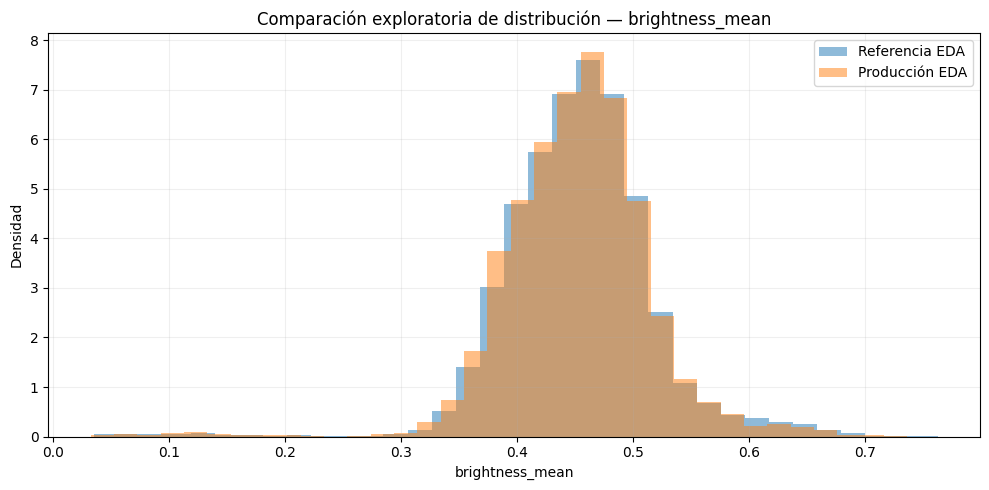

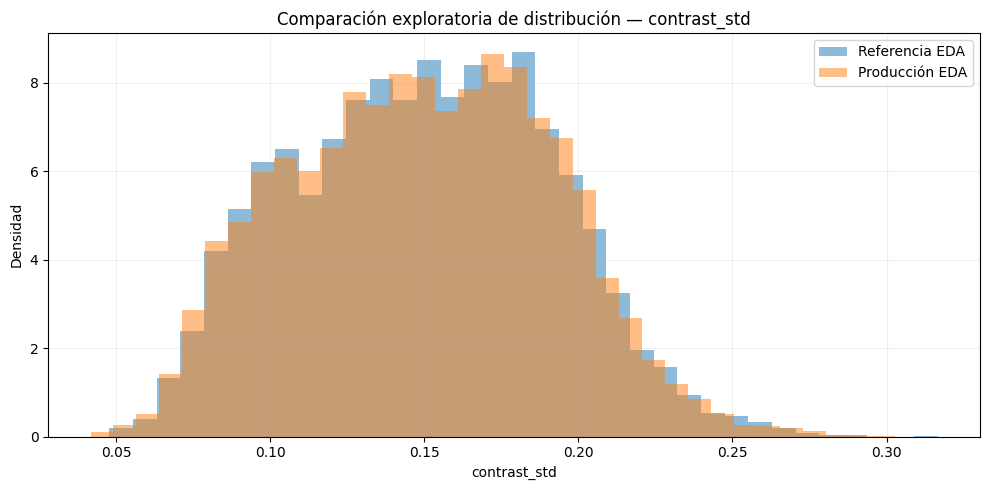

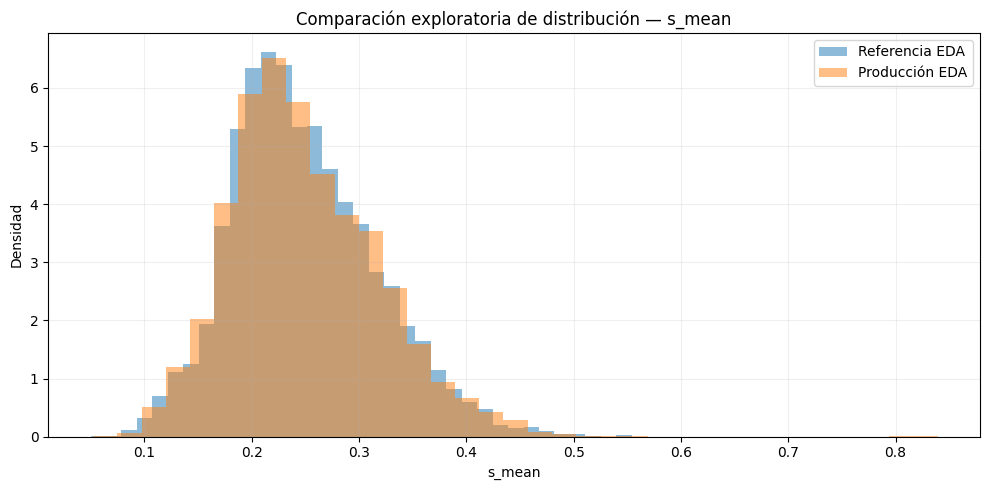

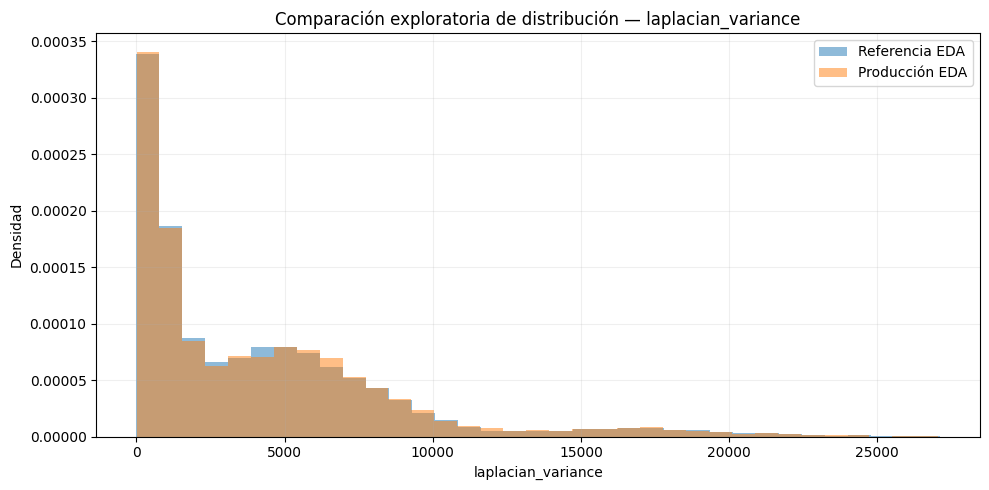

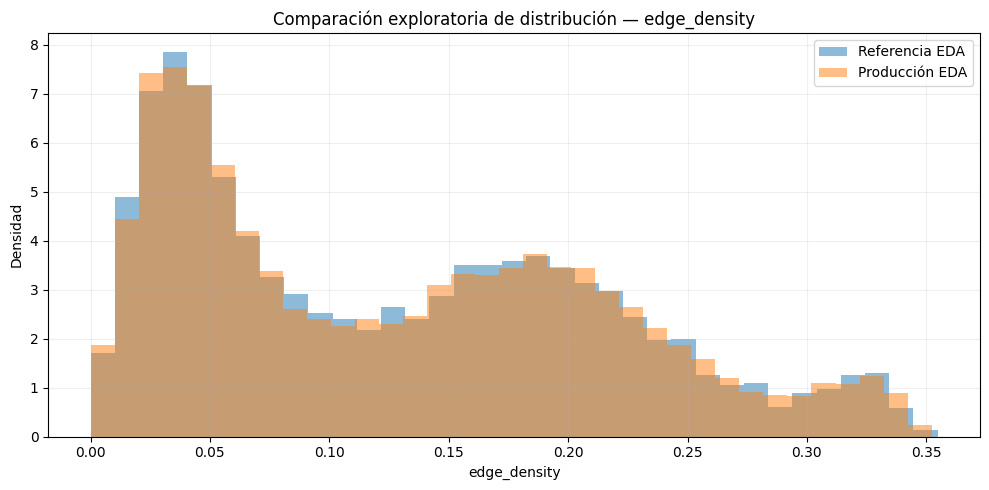

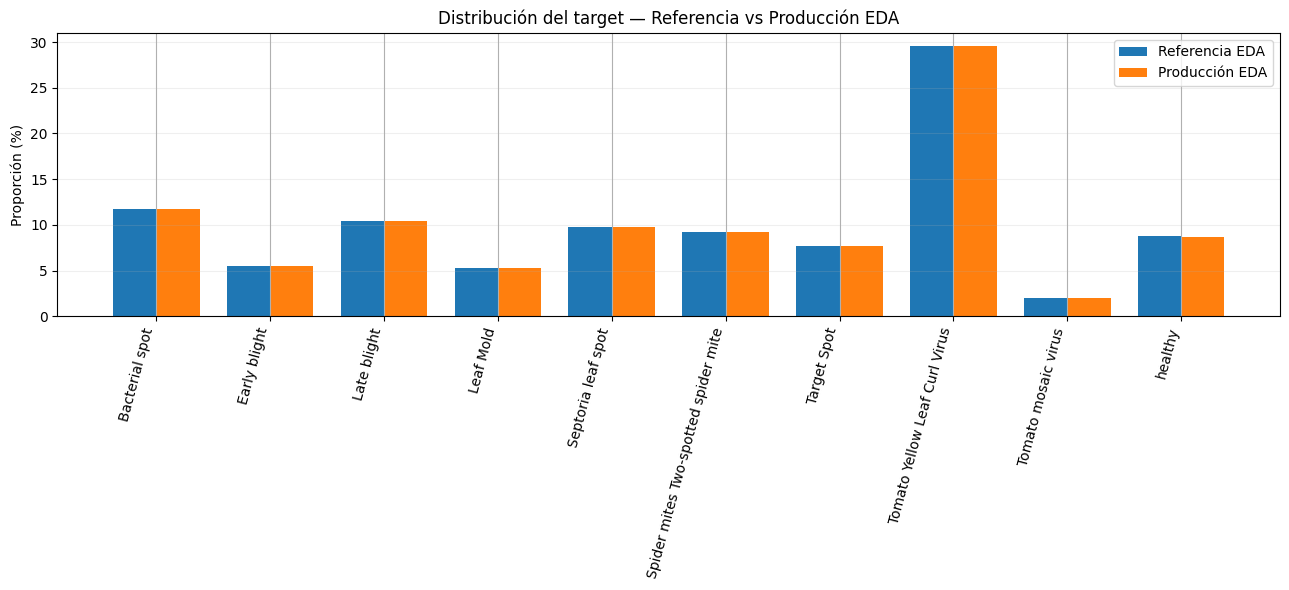


FEATURES CANDIDATAS A MONITOREO DE DRIFT


,Feature,Dimensión monitoreada,Sensibilidad operacional,Prioridad preliminar
0,brightness_mean,Iluminación global,"Cambios de iluminación, exposición o cámara",Alta
1,v_mean,Brillo en HSV,Cambios de iluminación y exposición,Alta
2,contrast_std,Contraste,Cambios de contraste o procesamiento de imagen,Alta
3,s_mean,Saturación,"Cambios de dispositivo, color o iluminación",Alta
4,laplacian_variance,Nitidez,"Desenfoque, movimiento o calidad de captura",Alta
5,edge_density,Estructura visual,"Cambios en bordes, enfoque o composición",Alta
6,entropy,Complejidad tonal,Cambios globales en textura e intensidad,Media
7,excess_green,Predominio de verde,"Cambios de color, vegetación o iluminación",Media



MAYORES DIFERENCIAS DESCRIPTIVAS ENTRE LAS DOS MUESTRAS


,Feature,|Δ media| / Std ref,|Δ mediana| / IQR ref,Cambio relativo IQR,Distancia histogramas
0,s_mean,0.006764,0.005224,0.022179,0.023807
1,contrast_std,0.005789,0.006992,0.016033,0.022264
2,b_std,0.009985,0.012115,0.013797,0.020721
3,v_mean,0.006281,0.017686,0.015949,0.020170
4,entropy,0.006945,0.009413,0.001967,0.019288
5,edge_density,0.009900,0.011764,0.010434,0.017965
6,r_std,0.008488,0.000933,0.007085,0.016643
7,brightness_mean,0.009796,0.013547,0.006131,0.015871



CONTROL FINAL — 5.10
✅ Referencia exploratoria creada.
✅ Producción exploratoria creada.
✅ Las muestras son disjuntas.
✅ La distribución de clases fue preservada mediante estratificación.
✅ Se compararon distribuciones de features visuales.
✅ Se identificaron candidatas operacionales a monitoreo.
✅ NO se utilizaron PSI, KS ni Chi².
✅ NO se definieron umbrales de alarma.
✅ NO se crearon ventanas W0-W4.
✅ El DataFrame original no fue modificado.

⚠️ Las diferencias observadas NO constituyen evidencia de drift real.
✅ 5.10 — PRIMERA MIRADA AL DRIFT COMPLETADA


In [ ]:
# ============================================================
# FASE 1 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# 5.10 PRIMERA MIRADA AL DATA DRIFT
# ============================================================
#
# OBJETIVOS
# ------------------------------------------------------------
# 1. Crear dos muestras exploratorias disjuntas:
#
#       - Referencia EDA
#       - Producción EDA
#
# 2. Mantener aproximadamente la distribución de clases.
#
# 3. Comparar descriptivamente algunas features visuales.
#
# 4. Calcular indicadores simples de diferencia:
#
#       - cambio de media;
#       - desplazamiento estandarizado de media;
#       - cambio de mediana;
#       - desplazamiento robusto mediana/IQR;
#       - diferencia descriptiva entre histogramas.
#
# 5. Identificar features candidatas a monitoreo futuro.
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda:
#
#   - NO demuestra Data Drift real;
#   - NO representa una separación temporal verdadera;
#   - NO crea W0-W4;
#   - NO calcula PSI;
#   - NO calcula KS;
#   - NO calcula Chi² de drift;
#   - NO genera alertas;
#   - NO modifica df;
#   - NO sustituye la Fase 4.
#
# Las muestras creadas aquí tienen finalidad EXCLUSIVAMENTE
# exploratoria y NO serán los splits definitivos del modelo.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from IPython.display import display


# ============================================================
# 2. CONFIGURACIÓN GENERAL
# ============================================================

RANDOM_STATE = globals().get(
    "RANDOM_STATE",
    42
)


TARGET = globals().get(
    "TARGET",
    "clase"
)


# ============================================================
# 3. VERIFICAR DATAFRAME
# ============================================================

if "df" not in globals():

    if "df_maestro" in globals():

        df = df_maestro.copy()

    else:

        raise NameError(
            "No se encontró 'df' ni 'df_maestro'. "
            "Ejecute previamente las secciones anteriores."
        )


if df.empty:

    raise ValueError(
        "El DataFrame está vacío."
    )


if TARGET not in df.columns:

    raise KeyError(
        f"El target '{TARGET}' no existe en el DataFrame."
    )


# ============================================================
# 4. DEFINIR FEATURES LEGÍTIMAS PARA EL ANÁLISIS
# ============================================================
#
# Se reutiliza la auditoría de leakage de 5.9 cuando
# esté disponible.
#
# ============================================================

if "FEATURES_VALIDAS_PRELIMINARES" in globals():

    FEATURES_DRIFT_EDA = [
        feature
        for feature in FEATURES_VALIDAS_PRELIMINARES
        if (
            feature in df.columns
            and pd.api.types.is_numeric_dtype(
                df[feature]
            )
            and df[feature].nunique(
                dropna=True
            ) > 1
        )
    ]

else:

    CARACTERISTICAS_VISUALES_ESPERADAS = [
        "r_mean",
        "g_mean",
        "b_mean",
        "r_std",
        "g_std",
        "b_std",
        "h_mean",
        "s_mean",
        "v_mean",
        "excess_green",
        "brightness_mean",
        "contrast_std",
        "laplacian_variance",
        "entropy",
        "edge_density"
    ]


    FEATURES_DRIFT_EDA = [
        feature
        for feature
        in CARACTERISTICAS_VISUALES_ESPERADAS
        if (
            feature in df.columns
            and pd.api.types.is_numeric_dtype(
                df[feature]
            )
            and df[feature].nunique(
                dropna=True
            ) > 1
        )
    ]


if len(FEATURES_DRIFT_EDA) == 0:

    raise ValueError(
        "No existen features numéricas válidas "
        "para realizar la comparación exploratoria."
    )


# ============================================================
# 5. CREAR REFERENCIA Y PRODUCCIÓN EXPLORATORIAS
# ============================================================
#
# IMPORTANTE:
#
# Ambas muestras proceden del MISMO dataset estático.
#
# Por tanto, NO representan:
#
#       pasado vs futuro real.
#
# Se realiza una partición 50/50 estratificada para:
#
#   - obtener muestras suficientemente grandes;
#   - mantener aproximadamente P(Y);
#   - evitar solapamiento entre muestras;
#   - construir un escenario de estabilidad esperada.
#
# ============================================================

df_referencia_eda, df_produccion_eda = train_test_split(

    df,

    test_size=0.50,

    random_state=RANDOM_STATE,

    stratify=df[TARGET]
)


# Copias independientes.
df_referencia_eda = (
    df_referencia_eda
    .copy()
)


df_produccion_eda = (
    df_produccion_eda
    .copy()
)


# ============================================================
# 6. VERIFICAR DISJUNCIÓN
# ============================================================

indices_ref = set(
    df_referencia_eda.index
)


indices_prod = set(
    df_produccion_eda.index
)


solapamiento = (
    indices_ref
    .intersection(
        indices_prod
    )
)


assert (
    len(solapamiento)
    == 0
), (
    "ERROR: referencia y producción exploratoria "
    "contienen observaciones compartidas."
)


# ============================================================
# 7. INFORMACIÓN GENERAL
# ============================================================

print("=" * 105)
print("5.10 — PRIMERA MIRADA AL DATA DRIFT")
print("=" * 105)

print(
    f"Dataset completo                  : "
    f"{len(df):,}"
)

print(
    f"Muestra de referencia EDA         : "
    f"{len(df_referencia_eda):,}"
)

print(
    f"Muestra de producción EDA         : "
    f"{len(df_produccion_eda):,}"
)

print(
    f"Solapamiento entre muestras       : "
    f"{len(solapamiento)}"
)

print(
    f"Features disponibles para análisis: "
    f"{len(FEATURES_DRIFT_EDA)}"
)

print(
    "\n⚠️ Estas muestras NO representan pasado/futuro real."
)


# ============================================================
# 8. COMPARAR DISTRIBUCIÓN DEL TARGET
# ============================================================
#
# Debido al split estratificado se espera:
#
#       P_ref(Y) ≈ P_prod(Y)
#
# ============================================================

prop_ref_target = (
    df_referencia_eda[
        TARGET
    ]
    .astype("string")
    .value_counts(
        normalize=True
    )
)


prop_prod_target = (
    df_produccion_eda[
        TARGET
    ]
    .astype("string")
    .value_counts(
        normalize=True
    )
)


clases = sorted(
    set(
        prop_ref_target.index
    )
    .union(
        prop_prod_target.index
    )
)


df_target_ref_prod = pd.DataFrame(
    {
        "Clase": clases,

        "Referencia (%)": [
            100
            * prop_ref_target.get(
                clase,
                0.0
            )
            for clase in clases
        ],

        "Producción EDA (%)": [
            100
            * prop_prod_target.get(
                clase,
                0.0
            )
            for clase in clases
        ]
    }
)


df_target_ref_prod[
    "Diferencia (pp)"
] = (
    df_target_ref_prod[
        "Producción EDA (%)"
    ]
    -
    df_target_ref_prod[
        "Referencia (%)"
    ]
)


print("\n" + "=" * 105)
print("DISTRIBUCIÓN DEL TARGET — REFERENCIA VS PRODUCCIÓN EDA")
print("=" * 105)


display(
    df_target_ref_prod.style.format(
        {
            "Referencia (%)": "{:.3f}",
            "Producción EDA (%)": "{:.3f}",
            "Diferencia (pp)": "{:+.3f}"
        }
    )
)


# ============================================================
# 9. FUNCIÓN DE ESTADÍSTICAS DESCRIPTIVAS
# ============================================================

def resumen_distribucion(serie):
    """
    Calcula estadísticas descriptivas robustas
    para una feature numérica.
    """

    valores = (
        pd.to_numeric(
            serie,
            errors="coerce"
        )
        .dropna()
        .astype(float)
    )


    if valores.empty:

        return {
            "N": 0,
            "Media": np.nan,
            "Mediana": np.nan,
            "Std": np.nan,
            "Q1": np.nan,
            "Q3": np.nan,
            "IQR": np.nan
        }


    q1 = float(
        valores.quantile(
            0.25
        )
    )


    q3 = float(
        valores.quantile(
            0.75
        )
    )


    return {
        "N": int(
            len(valores)
        ),

        "Media": float(
            valores.mean()
        ),

        "Mediana": float(
            valores.median()
        ),

        "Std": float(
            valores.std()
        ),

        "Q1": q1,

        "Q3": q3,

        "IQR": float(
            q3 - q1
        )
    }


# ============================================================
# 10. DIFERENCIA DESCRIPTIVA ENTRE HISTOGRAMAS
# ============================================================
#
#            1
# D_hist = ----- Σ |p_ref,b - p_prod,b|
#            2
#
# Los bins se definen mediante cuantiles de referencia.
#
# NO es PSI.
# NO es un estadístico formal de alerta.
#
# ============================================================

def distancia_histogramas_exploratoria(
    referencia,
    produccion,
    n_bins=10
):
    """
    Calcula una distancia descriptiva entre dos histogramas.

    Retorna valores entre 0 y 1.

    Se utiliza exclusivamente en EDA.
    """

    ref = (
        pd.to_numeric(
            referencia,
            errors="coerce"
        )
        .dropna()
        .to_numpy(
            dtype=float
        )
    )


    prod = (
        pd.to_numeric(
            produccion,
            errors="coerce"
        )
        .dropna()
        .to_numpy(
            dtype=float
        )
    )


    if (
        len(ref) == 0
        or len(prod) == 0
    ):

        return np.nan


    # Bordes definidos mediante cuantiles de referencia.
    cuantiles = np.linspace(
        0,
        1,
        n_bins + 1
    )


    bordes = np.quantile(
        ref,
        cuantiles
    )


    # Eliminar bordes duplicados.
    bordes = np.unique(
        bordes
    )


    if len(bordes) < 3:

        return np.nan


    # Incluir todos los valores extremos.
    bordes = bordes.astype(
        float
    )

    bordes[0] = -np.inf
    bordes[-1] = np.inf


    hist_ref = np.histogram(
        ref,
        bins=bordes
    )[0].astype(float)


    hist_prod = np.histogram(
        prod,
        bins=bordes
    )[0].astype(float)


    p_ref = (
        hist_ref
        / hist_ref.sum()
    )


    p_prod = (
        hist_prod
        / hist_prod.sum()
    )


    distancia = (
        0.5
        * np.abs(
            p_ref
            - p_prod
        ).sum()
    )


    return float(
        distancia
    )


# ============================================================
# 11. COMPARACIÓN FEATURE POR FEATURE
# ============================================================

resultados_comparacion = []


for feature in FEATURES_DRIFT_EDA:

    resumen_ref = resumen_distribucion(
        df_referencia_eda[
            feature
        ]
    )


    resumen_prod = resumen_distribucion(
        df_produccion_eda[
            feature
        ]
    )


    # --------------------------------------------------------
    # Cambio absoluto de media
    # --------------------------------------------------------

    delta_media = (
        resumen_prod["Media"]
        -
        resumen_ref["Media"]
    )


    # --------------------------------------------------------
    # Desplazamiento estandarizado de media
    #
    #                  |mu_prod - mu_ref|
    # Delta_mu* = -----------------------------
    #                       sigma_ref
    # --------------------------------------------------------

    if (
        np.isfinite(
            resumen_ref["Std"]
        )
        and resumen_ref["Std"] > 0
    ):

        delta_media_std = (
            abs(
                delta_media
            )
            /
            resumen_ref["Std"]
        )

    else:

        delta_media_std = np.nan


    # --------------------------------------------------------
    # Cambio de mediana
    # --------------------------------------------------------

    delta_mediana = (
        resumen_prod["Mediana"]
        -
        resumen_ref["Mediana"]
    )


    # --------------------------------------------------------
    # Desplazamiento robusto:
    #
    #                    |med_prod - med_ref|
    # Delta_med* = -------------------------------
    #                         IQR_ref
    # --------------------------------------------------------

    if (
        np.isfinite(
            resumen_ref["IQR"]
        )
        and resumen_ref["IQR"] > 0
    ):

        delta_mediana_iqr = (
            abs(
                delta_mediana
            )
            /
            resumen_ref["IQR"]
        )

    else:

        delta_mediana_iqr = np.nan


    # --------------------------------------------------------
    # Variación relativa del IQR
    # --------------------------------------------------------

    if (
        np.isfinite(
            resumen_ref["IQR"]
        )
        and resumen_ref["IQR"] > 0
    ):

        cambio_iqr_rel = (
            abs(
                (
                    resumen_prod["IQR"]
                    /
                    resumen_ref["IQR"]
                )
                - 1
            )
        )

    else:

        cambio_iqr_rel = np.nan


    # --------------------------------------------------------
    # Diferencia descriptiva entre histogramas
    # --------------------------------------------------------

    distancia_hist = (
        distancia_histogramas_exploratoria(
            df_referencia_eda[
                feature
            ],
            df_produccion_eda[
                feature
            ]
        )
    )


    resultados_comparacion.append(
        {
            "Feature": feature,

            "Media ref": (
                resumen_ref[
                    "Media"
                ]
            ),

            "Media prod": (
                resumen_prod[
                    "Media"
                ]
            ),

            "Δ media": (
                delta_media
            ),

            "|Δ media| / Std ref": (
                delta_media_std
            ),

            "Mediana ref": (
                resumen_ref[
                    "Mediana"
                ]
            ),

            "Mediana prod": (
                resumen_prod[
                    "Mediana"
                ]
            ),

            "|Δ mediana| / IQR ref": (
                delta_mediana_iqr
            ),

            "IQR ref": (
                resumen_ref[
                    "IQR"
                ]
            ),

            "IQR prod": (
                resumen_prod[
                    "IQR"
                ]
            ),

            "Cambio relativo IQR": (
                cambio_iqr_rel
            ),

            "Distancia histogramas": (
                distancia_hist
            )
        }
    )


df_comparacion_drift_eda = (
    pd.DataFrame(
        resultados_comparacion
    )
    .sort_values(
        by="Distancia histogramas",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 105)
print("COMPARACIÓN EXPLORATORIA DE FEATURES")
print("=" * 105)


display(
    df_comparacion_drift_eda.style.format(
        {
            "Media ref": "{:.6f}",
            "Media prod": "{:.6f}",
            "Δ media": "{:+.6f}",
            "|Δ media| / Std ref": "{:.6f}",
            "Mediana ref": "{:.6f}",
            "Mediana prod": "{:.6f}",
            "|Δ mediana| / IQR ref": "{:.6f}",
            "IQR ref": "{:.6f}",
            "IQR prod": "{:.6f}",
            "Cambio relativo IQR": "{:.6f}",
            "Distancia histogramas": "{:.6f}"
        }
    )
)


# ============================================================
# 12. FEATURES PRIORITARIAS PARA VISUALIZACIÓN
# ============================================================
#
# Se seleccionan variables con interpretación operacional
# clara para evitar generar gráficos por acumulación.
#
# ============================================================

FEATURES_VISUALIZAR_DRIFT = [
    feature
    for feature in [
        "brightness_mean",
        "contrast_std",
        "s_mean",
        "laplacian_variance",
        "edge_density"
    ]
    if feature in FEATURES_DRIFT_EDA
]


# Si alguna no estuviera disponible, completar con las
# features con mayor diferencia descriptiva.

if len(FEATURES_VISUALIZAR_DRIFT) < 5:

    for feature in (
        df_comparacion_drift_eda[
            "Feature"
        ]
        .tolist()
    ):

        if (
            feature
            not in FEATURES_VISUALIZAR_DRIFT
        ):

            FEATURES_VISUALIZAR_DRIFT.append(
                feature
            )


        if len(
            FEATURES_VISUALIZAR_DRIFT
        ) >= 5:

            break


# ============================================================
# 13. COMPARACIÓN VISUAL DE DISTRIBUCIONES
# ============================================================
#
# Se genera un gráfico independiente por feature.
#
# ============================================================

for feature in FEATURES_VISUALIZAR_DRIFT:

    valores_ref = (
        pd.to_numeric(
            df_referencia_eda[
                feature
            ],
            errors="coerce"
        )
        .dropna()
    )


    valores_prod = (
        pd.to_numeric(
            df_produccion_eda[
                feature
            ],
            errors="coerce"
        )
        .dropna()
    )


    plt.figure(
        figsize=(10, 5)
    )


    plt.hist(
        valores_ref,
        bins=35,
        density=True,
        alpha=0.50,
        label="Referencia EDA"
    )


    plt.hist(
        valores_prod,
        bins=35,
        density=True,
        alpha=0.50,
        label="Producción EDA"
    )


    plt.xlabel(
        feature
    )

    plt.ylabel(
        "Densidad"
    )


    plt.title(
        f"Comparación exploratoria de distribución — {feature}"
    )


    plt.grid(
        alpha=0.20
    )

    plt.legend()

    plt.tight_layout()

    plt.show()


# ============================================================
# 14. COMPARACIÓN VISUAL DEL TARGET
# ============================================================

def simplificar_clase(nombre):
    """
    Simplifica nombres únicamente para visualización.
    """

    return (
        str(nombre)
        .replace(
            "Tomato___",
            ""
        )
        .replace(
            "_",
            " "
        )
    )


df_target_plot = (
    df_target_ref_prod
    .copy()
)


df_target_plot[
    "Etiqueta"
] = (
    df_target_plot[
        "Clase"
    ]
    .map(
        simplificar_clase
    )
)


x = np.arange(
    len(
        df_target_plot
    )
)


ancho_barra = 0.38


plt.figure(
    figsize=(13, 6)
)


plt.bar(
    x - ancho_barra / 2,

    df_target_plot[
        "Referencia (%)"
    ],

    width=ancho_barra,

    label="Referencia EDA"
)


plt.bar(
    x + ancho_barra / 2,

    df_target_plot[
        "Producción EDA (%)"
    ],

    width=ancho_barra,

    label="Producción EDA"
)


plt.xticks(
    x,
    df_target_plot[
        "Etiqueta"
    ],
    rotation=75,
    ha="right"
)


plt.ylabel(
    "Proporción (%)"
)


plt.title(
    "Distribución del target — Referencia vs Producción EDA"
)


plt.grid(
    axis="y",
    alpha=0.20
)


plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 15. FEATURES CANDIDATAS A DRIFT POR CRITERIO OPERACIONAL
# ============================================================
#
# Esta tabla NO afirma que exista drift.
#
# Identifica variables que sería razonable monitorear
# posteriormente debido a su relación con condiciones
# de captura de imágenes.
#
# ============================================================

mapa_candidatas = {
    "brightness_mean": (
        "Iluminación global",
        "Cambios de iluminación, exposición o cámara",
        "Alta"
    ),

    "v_mean": (
        "Brillo en HSV",
        "Cambios de iluminación y exposición",
        "Alta"
    ),

    "contrast_std": (
        "Contraste",
        "Cambios de contraste o procesamiento de imagen",
        "Alta"
    ),

    "s_mean": (
        "Saturación",
        "Cambios de dispositivo, color o iluminación",
        "Alta"
    ),

    "laplacian_variance": (
        "Nitidez",
        "Desenfoque, movimiento o calidad de captura",
        "Alta"
    ),

    "edge_density": (
        "Estructura visual",
        "Cambios en bordes, enfoque o composición",
        "Alta"
    ),

    "entropy": (
        "Complejidad tonal",
        "Cambios globales en textura e intensidad",
        "Media"
    ),

    "excess_green": (
        "Predominio de verde",
        "Cambios de color, vegetación o iluminación",
        "Media"
    )
}


registros_candidatas = []


for feature, (
    dimension,
    sensibilidad,
    prioridad
) in mapa_candidatas.items():

    if feature in FEATURES_DRIFT_EDA:

        registros_candidatas.append(
            {
                "Feature": feature,
                "Dimensión monitoreada": dimension,
                "Sensibilidad operacional": sensibilidad,
                "Prioridad preliminar": prioridad
            }
        )


df_candidatas_drift = pd.DataFrame(
    registros_candidatas
)


print("\n" + "=" * 105)
print("FEATURES CANDIDATAS A MONITOREO DE DRIFT")
print("=" * 105)


display(
    df_candidatas_drift
)


# ============================================================
# 16. TOP DIFERENCIAS DESCRIPTIVAS OBSERVADAS
# ============================================================
#
# IMPORTANTE:
#
# "Mayor diferencia observada" NO significa:
#
#       "drift detectado".
#
# Ambas muestras provienen de la misma distribución
# original y no existe temporalidad real.
#
# ============================================================

N_TOP = min(
    8,
    len(
        df_comparacion_drift_eda
    )
)


print("\n" + "=" * 105)
print("MAYORES DIFERENCIAS DESCRIPTIVAS ENTRE LAS DOS MUESTRAS")
print("=" * 105)


display(
    df_comparacion_drift_eda[
        [
            "Feature",
            "|Δ media| / Std ref",
            "|Δ mediana| / IQR ref",
            "Cambio relativo IQR",
            "Distancia histogramas"
        ]
    ]
    .head(
        N_TOP
    )
    .style.format(
        {
            "|Δ media| / Std ref": "{:.6f}",
            "|Δ mediana| / IQR ref": "{:.6f}",
            "Cambio relativo IQR": "{:.6f}",
            "Distancia histogramas": "{:.6f}"
        }
    )
)


# ============================================================
# 17. CONTROLES METODOLÓGICOS
# ============================================================

assert (
    set(
        df_referencia_eda.index
    )
    .isdisjoint(
        set(
            df_produccion_eda.index
        )
    )
), (
    "Referencia y producción contienen "
    "observaciones compartidas."
)


assert (
    len(
        df_referencia_eda
    )
    +
    len(
        df_produccion_eda
    )
    ==
    len(df)
), (
    "Las muestras no reconstruyen el dataset completo."
)


assert all(
    feature in df.columns
    for feature
    in FEATURES_DRIFT_EDA
), (
    "Existe una feature de drift inexistente en df."
)


assert (
    TARGET
    not in FEATURES_DRIFT_EDA
), (
    "ERROR: el target fue incorporado como feature."
)


# ============================================================
# 18. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 105)
print("CONTROL FINAL — 5.10")
print("=" * 105)

print(
    "✅ Referencia exploratoria creada."
)

print(
    "✅ Producción exploratoria creada."
)

print(
    "✅ Las muestras son disjuntas."
)

print(
    "✅ La distribución de clases fue preservada "
    "mediante estratificación."
)

print(
    "✅ Se compararon distribuciones de "
    "features visuales."
)

print(
    "✅ Se identificaron candidatas operacionales "
    "a monitoreo."
)

print(
    "✅ NO se utilizaron PSI, KS ni Chi²."
)

print(
    "✅ NO se definieron umbrales de alarma."
)

print(
    "✅ NO se crearon ventanas W0-W4."
)

print(
    "✅ El DataFrame original no fue modificado."
)

print(
    "\n⚠️ Las diferencias observadas NO constituyen "
    "evidencia de drift real."
)

print("=" * 105)

print(
    "✅ 5.10 — PRIMERA MIRADA AL DRIFT COMPLETADA"
)

## 5.11 Conclusiones de la Fase 1

La Fase 1 permitió caracterizar el dataset desde las perspectivas de.

## 5.11.1 Hallazgos principales

Después de la depuración del dataset se dispone de.

## 5.11.2 Información contenida en las características visuales

A partir de los píxeles de cada imagen se extrajeron 15 características visuales.

## 5.11.3 Estructura multivariada

Esta sección resume estructura multivariada y su función dentro del proyecto MLOps.

## 5.11.4 Problemas y controles de calidad

La auditoría de calidad mostró resultados favorables después del proceso de.

## 5.11.5 Limitaciones relevantes del dataset

Aunque la calidad estructural es adecuada, existen limitaciones importantes.

## Ausencia de temporalidad

que represente el momento real de captura.

## Desbalance del target

Aunque no constituye un error de integridad, el desbalance observado.

## 5.11.6 Features descartadas

La auditoría de leakage permitió separar cuatro grupos conceptuales.

## Variables excluidas de $X$

Esta sección resume variables excluidas de $X$ y su función dentro del proyecto MLOps.

## Variables reservadas para control de calidad

se encuentran disponibles durante inferencia, pero presentan varianza nula en el.

## Features visuales candidatas

Las 15 características visuales permanecen metodológicamente disponibles como.

## 5.11.7 Riesgos de Data Leakage

La auditoría de las 23 variables produjo.

## 5.11.8 Variables sensibles a Data Drift

La primera comparación exploratoria de drift utilizó dos muestras disjuntas de.

## 5.11.9 Hipótesis para modelado

A partir del EDA se plantean las siguientes hipótesis, que deberán comprobarse en.

## Hipótesis H1 — Las características visuales contienen señal predictiva

Los tamaños de efecto observados sugieren.

## Hipótesis H2 — Un modelo flexible puede capturar relaciones no lineales

Las diferencias entre Pearson y Spearman, las distribuciones por clase y la.

## Hipótesis H3 — El desbalance afectará las métricas globales

pueda ocultar desempeños deficientes en las clases minoritarias.

## Hipótesis H4 — La partición debe preservar las clases

Dado que no existe temporalidad real, no corresponde utilizar un split temporal.

## Hipótesis H5 — Algunas features presentan redundancia

Las matrices de Pearson, Spearman y el PCA muestran dependencia entre varias.

## Hipótesis H6 — Las variables predictivas también pueden ser relevantes para drift

Esta sección resume hipótesis H6 — Las variables predictivas también pueden ser relevantes para drift y su función dentro del proyecto MLOps.

## 5.11.10 Cierre de la Fase 1

La Fase 1 permite definir preliminarmente.


In [ ]:
# ============================================================
# FASE 1 — ANÁLISIS EXPLORATORIO DE DATOS
# 5.11 CONCLUSIONES DE LA FASE 1
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Consolidar los resultados previamente calculados en:
#
#   - calidad;
#   - variable objetivo;
#   - análisis multivariado;
#   - leakage;
#   - temporalidad;
#   - drift preliminar;
#
# y traducirlos en decisiones para la Fase 2.
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda:
#
#   - NO recalcula el EDA completo;
#   - NO modifica df;
#   - NO elimina features;
#   - NO realiza el split definitivo;
#   - NO entrena modelos;
#   - NO calcula PSI, KS ni Chi² de drift;
#   - NO modifica Train/Validation/Test.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd

from IPython.display import display


# ============================================================
# 2. VERIFICACIONES GENERALES
# ============================================================

if "df" not in globals():

    if "df_maestro" in globals():

        df = df_maestro.copy()

    else:

        raise NameError(
            "No se encontró 'df' ni 'df_maestro'. "
            "Ejecute previamente la Fase 1."
        )


if df.empty:

    raise ValueError(
        "El DataFrame está vacío."
    )


TARGET = globals().get(
    "TARGET",
    "clase"
)


if TARGET not in df.columns:

    raise KeyError(
        f"El target '{TARGET}' no existe en df."
    )


N_FASE1 = len(df)

K_FASE1 = (
    df[TARGET]
    .nunique()
)


# ============================================================
# 3. RESULTADOS PRINCIPALES DEL TARGET
# ============================================================

conteos_target_fase1 = (
    df[TARGET]
    .value_counts()
)


clase_mayoritaria_fase1 = (
    conteos_target_fase1
    .idxmax()
)


clase_minoritaria_fase1 = (
    conteos_target_fase1
    .idxmin()
)


n_mayoritaria_fase1 = int(
    conteos_target_fase1.max()
)


n_minoritaria_fase1 = int(
    conteos_target_fase1.min()
)


pct_mayoritaria_fase1 = (
    100
    * n_mayoritaria_fase1
    / N_FASE1
)


pct_minoritaria_fase1 = (
    100
    * n_minoritaria_fase1
    / N_FASE1
)


razon_desbalance_fase1 = (
    n_mayoritaria_fase1
    / n_minoritaria_fase1
)


# ============================================================
# 4. FEATURES VISUALES
# ============================================================

CARACTERISTICAS_VISUALES_FASE1 = [
    "r_mean",
    "g_mean",
    "b_mean",
    "r_std",
    "g_std",
    "b_std",
    "h_mean",
    "s_mean",
    "v_mean",
    "excess_green",
    "brightness_mean",
    "contrast_std",
    "laplacian_variance",
    "entropy",
    "edge_density"
]


features_visuales_presentes = [
    feature
    for feature
    in CARACTERISTICAS_VISUALES_FASE1
    if feature in df.columns
]


# ============================================================
# 5. VARIABLES EXCLUIDAS DEL MODELO
# ============================================================

VARIABLES_EXCLUIR_FASE2 = [
    variable
    for variable in [
        TARGET,
        "ruta",
        "archivo"
    ]
    if variable in df.columns
]


# ============================================================
# 6. VARIABLES PARA CONTROL DE CALIDAD
# ============================================================

VARIABLES_CONTROL_CALIDAD_FASE2 = [
    variable
    for variable in [
        "ancho",
        "alto",
        "canales",
        "modo",
        "formato"
    ]
    if variable in df.columns
]


# ============================================================
# 7. TOP FEATURES RESPECTO DEL TARGET
# ============================================================
#
# Se reutiliza df_kruskal generado en 5.7.
#
# Si no existe, la celda continúa sin inventar resultados.
# ============================================================

if "df_kruskal" in globals():

    df_top_features_fase1 = (
        df_kruskal[
            [
                "Feature",
                "Epsilon²",
                "p-value"
            ]
        ]
        .head(10)
        .copy()
    )

else:

    df_top_features_fase1 = pd.DataFrame(
        columns=[
            "Feature",
            "Epsilon²",
            "p-value"
        ]
    )


# ============================================================
# 8. PCA EXPLORATORIO
# ============================================================

if "varianza_explicada" in globals():

    PC1_FASE1 = float(
        varianza_explicada[0]
    )

    PC2_FASE1 = float(
        varianza_explicada[1]
    )

    PCA_2_FASE1 = float(
        varianza_explicada[:2]
        .sum()
    )

else:

    PC1_FASE1 = np.nan
    PC2_FASE1 = np.nan
    PCA_2_FASE1 = np.nan


# ============================================================
# 9. RESULTADOS DE LEAKAGE
# ============================================================

if "df_auditoria_leakage" in globals():

    resumen_leakage_fase1 = (
        df_auditoria_leakage[
            "Riesgo de fuga"
        ]
        .value_counts()
        .to_dict()
    )

else:

    resumen_leakage_fase1 = {}


riesgo_alto_fase1 = int(
    resumen_leakage_fase1.get(
        "ALTO",
        0
    )
)


riesgo_medio_fase1 = int(
    resumen_leakage_fase1.get(
        "MEDIO",
        0
    )
)


riesgo_bajo_fase1 = int(
    resumen_leakage_fase1.get(
        "BAJO",
        0
    )
)


# ============================================================
# 10. TEMPORALIDAD
# ============================================================

if "TEMPORALIDAD_REAL_DISPONIBLE" in globals():

    temporalidad_fase1 = (
        TEMPORALIDAD_REAL_DISPONIBLE
    )

else:

    temporalidad_fase1 = False


# ============================================================
# 11. DRIFT PRELIMINAR
# ============================================================

if "df_candidatas_drift" in globals():

    candidatas_drift_fase1 = (
        df_candidatas_drift
        .copy()
    )

else:

    candidatas_drift_fase1 = pd.DataFrame()


if "df_comparacion_drift_eda" in globals():

    diferencias_drift_fase1 = (
        df_comparacion_drift_eda[
            [
                "Feature",
                "|Δ media| / Std ref",
                "|Δ mediana| / IQR ref",
                "Distancia histogramas"
            ]
        ]
        .head(8)
        .copy()
    )

else:

    diferencias_drift_fase1 = pd.DataFrame()


# ============================================================
# 12. TABLA DE HALLAZGOS PRINCIPALES
# ============================================================

df_hallazgos_fase1 = pd.DataFrame(
    {
        "Dimensión": [
            "Dataset limpio",
            "Número de clases",
            "Clase mayoritaria",
            "Clase minoritaria",
            "Razón de desbalance",
            "Features visuales",
            "Temporalidad real",
            "Variables excluidas de X",
            "Variables control de calidad",
            "Riesgos leakage altos",
            "Riesgos leakage medios",
            "Riesgos leakage bajos",
            "Varianza PCA PC1+PC2"
        ],

        "Resultado": [
            f"{N_FASE1:,} observaciones",
            f"{K_FASE1}",
            (
                f"{clase_mayoritaria_fase1} "
                f"({pct_mayoritaria_fase1:.2f}%)"
            ),
            (
                f"{clase_minoritaria_fase1} "
                f"({pct_minoritaria_fase1:.2f}%)"
            ),
            f"{razon_desbalance_fase1:.2f}",
            f"{len(features_visuales_presentes)}",
            (
                "Sí"
                if temporalidad_fase1
                else "No"
            ),
            ", ".join(
                VARIABLES_EXCLUIR_FASE2
            ),
            ", ".join(
                VARIABLES_CONTROL_CALIDAD_FASE2
            ),
            str(
                riesgo_alto_fase1
            ),
            str(
                riesgo_medio_fase1
            ),
            str(
                riesgo_bajo_fase1
            ),
            (
                f"{PCA_2_FASE1 * 100:.2f}%"
                if np.isfinite(
                    PCA_2_FASE1
                )
                else "No disponible"
            )
        ]
    }
)


print("=" * 110)
print("5.11 — CONCLUSIONES DE LA FASE 1")
print("=" * 110)


display(
    df_hallazgos_fase1
)


# ============================================================
# 13. TABLA DE DECISIONES SOBRE VARIABLES
# ============================================================

registros_decisiones = []


# ------------------------------------------------------------
# Variables excluidas
# ------------------------------------------------------------

for variable in VARIABLES_EXCLUIR_FASE2:

    if variable == TARGET:

        motivo = (
            "Es la variable objetivo."
        )

    elif variable == "ruta":

        motivo = (
            "Puede contener información explícita "
            "de la clase."
        )

    else:

        motivo = (
            "Identificador de alta cardinalidad "
            "sin significado predictivo."
        )


    registros_decisiones.append(
        {
            "Variable": variable,
            "Rol Fase 2": "Excluir de X",
            "Motivo": motivo
        }
    )


# ------------------------------------------------------------
# Variables de control
# ------------------------------------------------------------

for variable in VARIABLES_CONTROL_CALIDAD_FASE2:

    registros_decisiones.append(
        {
            "Variable": variable,
            "Rol Fase 2": "Control de calidad",
            "Motivo": (
                "Disponible en inferencia, "
                "pero sin variabilidad discriminativa "
                "en el dataset actual."
            )
        }
    )


# ------------------------------------------------------------
# Features visuales
# ------------------------------------------------------------

for variable in features_visuales_presentes:

    registros_decisiones.append(
        {
            "Variable": variable,
            "Rol Fase 2": "Feature candidata",
            "Motivo": (
                "Derivable directamente desde los "
                "píxeles de la imagen."
            )
        }
    )


df_decisiones_features_fase1 = pd.DataFrame(
    registros_decisiones
)


print("\n" + "=" * 110)
print("DECISIONES PRELIMINARES SOBRE VARIABLES")
print("=" * 110)


display(
    df_decisiones_features_fase1
)


# ============================================================
# 14. FEATURES CON MAYOR ASOCIACIÓN EXPLORATORIA
# ============================================================

print("\n" + "=" * 110)
print("FEATURES CON MAYOR DIFERENCIACIÓN ENTRE CLASES")
print("=" * 110)


if not df_top_features_fase1.empty:

    display(
        df_top_features_fase1.style.format(
            {
                "Epsilon²": "{:.6f}",
                "p-value": "{:.3e}"
            }
        )
    )

else:

    print(
        "No se encontró df_kruskal. "
        "Ejecute primero la sección 5.7."
    )


# ============================================================
# 15. FEATURES CANDIDATAS A DRIFT
# ============================================================

print("\n" + "=" * 110)
print("FEATURES CANDIDATAS A MONITOREO DE DRIFT")
print("=" * 110)


if not candidatas_drift_fase1.empty:

    display(
        candidatas_drift_fase1
    )

else:

    print(
        "No se encontró df_candidatas_drift. "
        "Ejecute primero la sección 5.10."
    )


# ============================================================
# 16. DIFERENCIAS OBSERVADAS EN EL BASELINE DE DRIFT
# ============================================================

print("\n" + "=" * 110)
print("BASELINE EXPLORATORIO DE VARIABILIDAD")
print("=" * 110)


if not diferencias_drift_fase1.empty:

    display(
        diferencias_drift_fase1.style.format(
            {
                "|Δ media| / Std ref": "{:.6f}",
                "|Δ mediana| / IQR ref": "{:.6f}",
                "Distancia histogramas": "{:.6f}"
            }
        )
    )

else:

    print(
        "No se encontró el análisis preliminar "
        "de drift de 5.10."
    )


# ============================================================
# 17. HIPÓTESIS PARA MODELADO
# ============================================================

df_hipotesis_modelado = pd.DataFrame(
    {
        "Hipótesis": [
            "H1",
            "H2",
            "H3",
            "H4",
            "H5",
            "H6"
        ],

        "Planteamiento": [
            (
                "Las características visuales contienen "
                "señal suficiente para superar un baseline trivial."
            ),

            (
                "Un modelo flexible puede capturar relaciones "
                "no lineales adicionales frente a un modelo lineal."
            ),

            (
                "El desbalance de clases hace necesario "
                "evaluar métricas por clase y F1-macro."
            ),

            (
                "Una partición estratificada permitirá conservar "
                "las proporciones del target al no existir tiempo real."
            ),

            (
                "Existe redundancia entre algunas features; "
                "su efecto debe evaluarse dentro del pipeline."
            ),

            (
                "Algunas features visuales pueden ser útiles "
                "simultáneamente para predicción y monitoreo de drift."
            )
        ],

        "Cómo comprobarla": [
            (
                "Comparar contra DummyClassifier "
                "y medir desempeño de validación."
            ),

            (
                "Comparar modelo interpretable con "
                "modelo flexible usando el mismo protocolo."
            ),

            (
                "Analizar accuracy, precision, recall, "
                "F1-macro y matriz de confusión."
            ),

            (
                "Verificar distribución de clases en "
                "Train/Validation/Test."
            ),

            (
                "Comparar estabilidad, importancia y "
                "performance con las features seleccionadas."
            ),

            (
                "Evaluar importancia predictiva y métricas "
                "de drift en las fases posteriores."
            )
        ]
    }
)


print("\n" + "=" * 110)
print("HIPÓTESIS PARA LA FASE 2")
print("=" * 110)


display(
    df_hipotesis_modelado
)


# ============================================================
# 18. DEFINIR OBJETOS PRELIMINARES PARA FASE 2
# ============================================================
#
# IMPORTANTE:
# Se definen listas de nombres.
#
# NO se crea todavía X_train / X_test.
# NO se realiza fit.
#
# ============================================================

FEATURES_CANDIDATAS_FASE2 = (
    features_visuales_presentes.copy()
)


TARGET_FASE2 = TARGET


print("\n" + "=" * 110)
print("CONFIGURACIÓN PRELIMINAR PARA LA FASE 2")
print("=" * 110)


print(
    f"Target:"
    f" {TARGET_FASE2}"
)


print(
    f"Número de features candidatas:"
    f" {len(FEATURES_CANDIDATAS_FASE2)}"
)


print(
    "\nFeatures candidatas:"
)


for feature in FEATURES_CANDIDATAS_FASE2:

    print(
        f"  ✅ {feature}"
    )


# ============================================================
# 19. CONTROLES FINALES
# ============================================================

assert (
    TARGET
    not in FEATURES_CANDIDATAS_FASE2
), (
    "ERROR: el target fue incluido "
    "entre las features."
)


assert (
    "ruta"
    not in FEATURES_CANDIDATAS_FASE2
), (
    "ERROR: la ruta fue incluida "
    "entre las features."
)


assert (
    "archivo"
    not in FEATURES_CANDIDATAS_FASE2
), (
    "ERROR: archivo fue incluido "
    "entre las features."
)


assert all(
    feature in df.columns
    for feature
    in FEATURES_CANDIDATAS_FASE2
), (
    "Existe una feature candidata "
    "que no está presente en df."
)


print("\n" + "=" * 110)
print("CONTROL FINAL — FASE 1")
print("=" * 110)

print(
    "✅ Calidad de datos auditada."
)

print(
    "✅ Variable objetivo caracterizada."
)

print(
    "✅ Desbalance documentado."
)

print(
    "✅ Relaciones bivariadas evaluadas."
)

print(
    "✅ Estructura multivariada evaluada."
)

print(
    "✅ Temporalidad auditada."
)

print(
    "✅ Riesgos de leakage auditados."
)

print(
    "✅ Features no válidas excluidas preliminarmente."
)

print(
    "✅ Features candidatas a drift identificadas."
)

print(
    "✅ Hipótesis de modelado formuladas."
)

print(
    "✅ No se modificó el DataFrame original."
)

print("=" * 110)

print(
    "✅ 5.11 — CONCLUSIONES DE LA FASE 1 COMPLETADAS"
)

5.11 — CONCLUSIONES DE LA FASE 1


,Dimensión,Resultado
0,Dataset limpio,"18,146 observaciones"
1,Número de clases,10
2,Clase mayoritaria,Tomato___Tomato_Yellow_Leaf_Curl_Virus (29.52%)
3,Clase minoritaria,Tomato___Tomato_mosaic_virus (2.06%)
4,Razón de desbalance,14.36
5,Features visuales,15
6,Temporalidad real,No
7,Variables excluidas de X,"clase, ruta, archivo"
8,Variables control de calidad,"ancho, alto, canales, modo, formato"
9,Riesgos leakage altos,2



DECISIONES PRELIMINARES SOBRE VARIABLES


,Variable,Rol Fase 2,Motivo
0,clase,Excluir de X,Es la variable objetivo.
1,ruta,Excluir de X,Puede contener información explícita de la clase.
2,archivo,Excluir de X,Identificador de alta cardinalidad sin significado predictivo.
3,ancho,Control de calidad,"Disponible en inferencia, pero sin variabilidad discriminativa en el dataset actual."
4,alto,Control de calidad,"Disponible en inferencia, pero sin variabilidad discriminativa en el dataset actual."
5,canales,Control de calidad,"Disponible en inferencia, pero sin variabilidad discriminativa en el dataset actual."
6,modo,Control de calidad,"Disponible en inferencia, pero sin variabilidad discriminativa en el dataset actual."
7,formato,Control de calidad,"Disponible en inferencia, pero sin variabilidad discriminativa en el dataset actual."
8,r_mean,Feature candidata,Derivable directamente desde los píxeles de la imagen.
9,g_mean,Feature candidata,Derivable directamente desde los píxeles de la imagen.



FEATURES CON MAYOR DIFERENCIACIÓN ENTRE CLASES


...


BASELINE EXPLORATORIO DE VARIABILIDAD


,Feature,|Δ media| / Std ref,|Δ mediana| / IQR ref,Distancia histogramas
0,s_mean,0.006764,0.005224,0.023807
1,contrast_std,0.005789,0.006992,0.022264
2,b_std,0.009985,0.012115,0.020721
3,v_mean,0.006281,0.017686,0.020170
4,entropy,0.006945,0.009413,0.019288
5,edge_density,0.009900,0.011764,0.017965
6,r_std,0.008488,0.000933,0.016643
7,brightness_mean,0.009796,0.013547,0.015871



HIPÓTESIS PARA LA FASE 2


,Hipótesis,Planteamiento,Cómo comprobarla
0,H1,Las características visuales contienen señal suficiente para superar un baseline trivial.,Comparar contra DummyClassifier y medir desempeño de validación.
1,H2,Un modelo flexible puede capturar relaciones no lineales adicionales frente a un modelo lineal.,Comparar modelo interpretable con modelo flexible usando el mismo protocolo.
2,H3,El desbalance de clases hace necesario evaluar métricas por clase y F1-macro.,"Analizar accuracy, precision, recall, F1-macro y matriz de confusión."
3,H4,Una partición estratificada permitirá conservar las proporciones del target al no existir tiempo real.,Verificar distribución de clases en Train/Validation/Test.
4,H5,Existe redundancia entre algunas features; su efecto debe evaluarse dentro del pipeline.,"Comparar estabilidad, importancia y performance con las features seleccionadas."
5,H6,Algunas features visuales pueden ser útiles simultáneamente para predicción y monitoreo de drift.,Evaluar importancia predictiva y métricas de drift en las fases posteriores.



CONFIGURACIÓN PRELIMINAR PARA LA FASE 2
Target: clase
Número de features candidatas: 15

Features candidatas:
  ✅ r_mean
  ✅ g_mean
  ✅ b_mean
  ✅ r_std
  ✅ g_std
  ✅ b_std
  ✅ h_mean
  ✅ s_mean
  ✅ v_mean
  ✅ excess_green
  ✅ brightness_mean
  ✅ contrast_std
  ✅ laplacian_variance
  ✅ entropy
  ✅ edge_density

CONTROL FINAL — FASE 1
✅ Calidad de datos auditada.
✅ Variable objetivo caracterizada.
✅ Desbalance documentado.
✅ Relaciones bivariadas evaluadas.
✅ Estructura multivariada evaluada.
✅ Temporalidad auditada.
✅ Riesgos de leakage auditados.
✅ Features no válidas excluidas preliminarmente.
✅ Features candidatas a drift identificadas.
✅ Hipótesis de modelado formuladas.
✅ No se modificó el DataFrame original.
✅ 5.11 — CONCLUSIONES DE LA FASE 1 COMPLETADAS


# Fase 2 — Modelado sin fuga de datos

Esta sección resume fase 2 — Modelado sin fuga de datos y su función dentro del proyecto MLOps.

## 6.1 Definición de las variables predictoras $X$ y de la variable objetivo $y$

El objetivo de esta etapa es definir formalmente qué información utilizará el modelo.

## 6.1.1 Definición de la variable objetivo

representa el conjunto de clases sanitarias.

## 6.1.2 Definición de las variables predictoras

Las características visuales calculadas durante el EDA fueron obtenidas directamente.

## 6.1.3 Features seleccionadas

Las variables predictoras iniciales serán.

## 6.1.4 Exclusión de identificadores irrelevantes

Esta sección resume exclusión de identificadores irrelevantes y su función dentro del proyecto MLOps.

## ruta

La ruta de almacenamiento puede contener explícitamente información relacionada con.

## archivo

El nombre del archivo corresponde a un identificador de alta cardinalidad.

## 6.1.5 Exclusión de la variable objetivo

Esta sección resume exclusión de la variable objetivo y su función dentro del proyecto MLOps.

## 6.1.6 Información futura

La auditoría temporal estableció que el dataset no posee una variable temporal real.

## 6.1.7 Variables derivadas del target

Una variable presenta fuga si puede expresarse como una transformación de la.

## 6.1.8 Variables técnicas de control

se encuentran disponibles en inferencia, pero presentan comportamiento constante en.

## 6.1.9 Estructura final

La definición preliminar del problema queda.

## 6.1.10 Principio de separación respecto de las etapas siguientes

Esta sección resume principio de separación respecto de las etapas siguientes y su función dentro del proyecto MLOps.


In [ ]:
# ============================================================
# FASE 2 — MODELADO SIN FUGA DE DATOS
# 6.1 DEFINICIÓN DE X E y
# ============================================================
#
# OBJETIVOS
# ------------------------------------------------------------
# 1. Definir la variable objetivo y.
#
# 2. Definir la matriz de características X utilizando
#    exclusivamente variables:
#
#       - disponibles en inferencia;
#       - reproducibles desde la imagen;
#       - no derivadas del target;
#       - sin leakage confirmado;
#       - con variabilidad suficiente para modelar.
#
# 3. Excluir:
#
#       - ruta;
#       - archivo;
#       - target;
#       - metadatos técnicos constantes.
#
# 4. Verificar automáticamente:
#
#       - dimensiones;
#       - tipos de datos;
#       - missing values;
#       - presencia accidental del target;
#       - identificadores;
#       - variables constantes.
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda:
#
#   - NO realiza Train/Test split;
#   - NO estandariza;
#   - NO imputa;
#   - NO codifica y;
#   - NO aplica PCA;
#   - NO balancea clases;
#   - NO calcula class_weight;
#   - NO entrena modelos.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd

from IPython.display import display


# ============================================================
# 2. CONFIGURACIÓN GENERAL
# ============================================================

RANDOM_STATE = globals().get(
    "RANDOM_STATE",
    42
)


TARGET_FASE2 = globals().get(
    "TARGET",
    "clase"
)


# ============================================================
# 3. VERIFICAR DATAFRAME
# ============================================================

if "df" not in globals():

    if "df_maestro" in globals():

        df = df_maestro.copy()

    else:

        raise NameError(
            "No se encontró 'df' ni 'df_maestro'. "
            "Ejecute previamente la Fase 1."
        )


if df.empty:

    raise ValueError(
        "El DataFrame está vacío."
    )


if TARGET_FASE2 not in df.columns:

    raise KeyError(
        f"El target '{TARGET_FASE2}' "
        "no existe en el DataFrame."
    )


# ============================================================
# 4. DEFINIR LAS 15 FEATURES VISUALES ESPERADAS
# ============================================================
#
# Estas características fueron construidas durante
# la Fase 1 directamente desde los píxeles.
#
# ============================================================

FEATURES_VISUALES_FASE2 = [
    "r_mean",
    "g_mean",
    "b_mean",
    "r_std",
    "g_std",
    "b_std",
    "h_mean",
    "s_mean",
    "v_mean",
    "excess_green",
    "brightness_mean",
    "contrast_std",
    "laplacian_variance",
    "entropy",
    "edge_density"
]


# ============================================================
# 5. COMPROBAR QUE TODAS EXISTAN
# ============================================================

features_faltantes = [
    feature
    for feature in FEATURES_VISUALES_FASE2
    if feature not in df.columns
]


if features_faltantes:

    raise KeyError(
        "Faltan características visuales esperadas "
        f"en el DataFrame: {features_faltantes}"
    )


# ============================================================
# 6. VALIDAR CONTRA LA AUDITORÍA DE LEAKAGE DE 5.9
# ============================================================
#
# Si la auditoría existe, se exige que todas las features
# seleccionadas hayan sido clasificadas como:
#
#       Disponible en inferencia = Sí
#       Riesgo de fuga           = BAJO
#
# ============================================================

if "df_auditoria_leakage" in globals():

    auditoria_features = (
        df_auditoria_leakage[
            df_auditoria_leakage[
                "Feature"
            ]
            .isin(
                FEATURES_VISUALES_FASE2
            )
        ]
        .copy()
    )


    # --------------------------------------------------------
    # Comprobar que las 15 features fueron auditadas
    # --------------------------------------------------------

    features_no_auditadas = sorted(
        set(
            FEATURES_VISUALES_FASE2
        )
        -
        set(
            auditoria_features[
                "Feature"
            ]
        )
    )


    if features_no_auditadas:

        raise ValueError(
            "Existen features que no fueron auditadas "
            "en 5.9: "
            f"{features_no_auditadas}"
        )


    # --------------------------------------------------------
    # Comprobar disponibilidad
    # --------------------------------------------------------

    features_no_disponibles = (
        auditoria_features.loc[
            auditoria_features[
                "Disponible en inferencia"
            ]
            !=
            "Sí",
            "Feature"
        ]
        .tolist()
    )


    if features_no_disponibles:

        raise ValueError(
            "Las siguientes features no están "
            "disponibles en inferencia: "
            f"{features_no_disponibles}"
        )


    # --------------------------------------------------------
    # Comprobar riesgo de leakage
    # --------------------------------------------------------

    features_riesgo_leakage = (
        auditoria_features.loc[
            auditoria_features[
                "Riesgo de fuga"
            ]
            !=
            "BAJO",
            "Feature"
        ]
        .tolist()
    )


    if features_riesgo_leakage:

        raise ValueError(
            "Las siguientes features presentan "
            "riesgo de leakage no bajo: "
            f"{features_riesgo_leakage}"
        )


# ============================================================
# 7. DEFINIR VARIABLES EXCLUIDAS
# ============================================================

IDENTIFICADORES_EXCLUIDOS = [
    variable
    for variable in [
        "ruta",
        "archivo"
    ]
    if variable in df.columns
]


VARIABLES_CONTROL_CALIDAD = [
    variable
    for variable in [
        "ancho",
        "alto",
        "canales",
        "modo",
        "formato"
    ]
    if variable in df.columns
]


VARIABLES_EXCLUIDAS_FASE2 = (
    IDENTIFICADORES_EXCLUIDOS
    +
    [TARGET_FASE2]
    +
    VARIABLES_CONTROL_CALIDAD
)


# ============================================================
# 8. DEFINIR LISTA DEFINITIVA DE FEATURES PARA 6.1
# ============================================================
#
# "Definitiva" significa definitiva para ESTA etapa 6.1.
#
# Las features todavía podrán ser transformadas mediante
# feature engineering dentro de 6.2.
#
# ============================================================

FEATURES_CANDIDATAS_FASE2 = (
    FEATURES_VISUALES_FASE2.copy()
)


# ============================================================
# 9. CONSTRUIR X
# ============================================================
#
# Se crea una copia independiente para evitar modificaciones
# accidentales sobre df.
#
# ============================================================

X = (
    df[
        FEATURES_CANDIDATAS_FASE2
    ]
    .copy()
)


# ============================================================
# 10. CONSTRUIR y
# ============================================================

y = (
    df[
        TARGET_FASE2
    ]
    .copy()
)


# ============================================================
# 11. GARANTIZAR VARIABLES NUMÉRICAS EN X
# ============================================================

for feature in X.columns:

    X[feature] = pd.to_numeric(
        X[feature],
        errors="coerce"
    )


# ============================================================
# 12. AUDITORÍA DE TIPOS
# ============================================================

df_schema_X = pd.DataFrame(
    {
        "Feature": X.columns,

        "dtype": [
            str(
                X[feature].dtype
            )
            for feature
            in X.columns
        ],

        "N únicos": [
            int(
                X[feature]
                .nunique(
                    dropna=True
                )
            )
            for feature
            in X.columns
        ],

        "N faltantes": [
            int(
                X[feature]
                .isna()
                .sum()
            )
            for feature
            in X.columns
        ],

        "Disponible en inferencia": [
            "Sí"
            for _
            in X.columns
        ],

        "Rol": [
            "Feature predictiva candidata"
            for _
            in X.columns
        ]
    }
)


print("=" * 105)
print("6.1 — DEFINICIÓN DE X E y")
print("=" * 105)


print(
    f"Dataset original            : "
    f"{df.shape}"
)

print(
    f"Matriz X                    : "
    f"{X.shape}"
)

print(
    f"Vector y                    : "
    f"{y.shape}"
)

print(
    f"Número de features en X     : "
    f"{X.shape[1]}"
)

print(
    f"Número de clases en y       : "
    f"{y.nunique()}"
)


# ============================================================
# 13. MOSTRAR ESQUEMA DE X
# ============================================================

print("\n" + "=" * 105)
print("ESQUEMA DE VARIABLES PREDICTORAS")
print("=" * 105)


display(
    df_schema_X
)


# ============================================================
# 14. DISTRIBUCIÓN DEL TARGET
# ============================================================

df_y_fase2 = (
    y
    .value_counts()
    .rename_axis(
        "Clase"
    )
    .reset_index(
        name="Frecuencia"
    )
)


df_y_fase2[
    "Proporción"
] = (
    df_y_fase2[
        "Frecuencia"
    ]
    / len(y)
)


df_y_fase2[
    "Porcentaje (%)"
] = (
    df_y_fase2[
        "Proporción"
    ]
    * 100
)


print("\n" + "=" * 105)
print("VARIABLE OBJETIVO y")
print("=" * 105)


display(
    df_y_fase2.style.format(
        {
            "Frecuencia": "{:,.0f}",
            "Proporción": "{:.6f}",
            "Porcentaje (%)": "{:.2f}"
        }
    )
)


# ============================================================
# 15. TABLA DE VARIABLES EXCLUIDAS
# ============================================================

registros_exclusion = []


for variable in IDENTIFICADORES_EXCLUIDOS:

    if variable == "ruta":

        motivo = (
            "Identificador con riesgo de leakage: "
            "la ruta puede contener el nombre de la clase."
        )

    else:

        motivo = (
            "Identificador de alta cardinalidad "
            "sin significado visual generalizable."
        )


    registros_exclusion.append(
        {
            "Variable": variable,
            "Motivo": motivo,
            "Acción": "Excluir de X"
        }
    )


registros_exclusion.append(
    {
        "Variable": TARGET_FASE2,
        "Motivo": (
            "Es la variable objetivo que debe predecirse."
        ),
        "Acción": "Mantener únicamente como y"
    }
)


for variable in VARIABLES_CONTROL_CALIDAD:

    registros_exclusion.append(
        {
            "Variable": variable,
            "Motivo": (
                "Metadato técnico disponible en inferencia, "
                "pero constante en el dataset actual."
            ),
            "Acción": (
                "Reservar para control de calidad; "
                "no incorporar inicialmente a X"
            )
        }
    )


df_variables_excluidas_fase2 = pd.DataFrame(
    registros_exclusion
)


print("\n" + "=" * 105)
print("VARIABLES EXCLUIDAS DE X")
print("=" * 105)


display(
    df_variables_excluidas_fase2
)


# ============================================================
# 16. VERIFICAR MISSING VALUES
# ============================================================

missing_X = int(
    X.isna()
    .sum()
    .sum()
)


missing_y = int(
    y.isna()
    .sum()
)


print("\n" + "=" * 105)
print("CONTROL DE VALORES FALTANTES")
print("=" * 105)

print(
    f"Valores faltantes en X : "
    f"{missing_X:,}"
)

print(
    f"Valores faltantes en y : "
    f"{missing_y:,}"
)


# ============================================================
# 17. IDENTIFICAR FEATURES CONSTANTES
# ============================================================

features_constantes_X = [
    feature
    for feature in X.columns
    if X[feature].nunique(
        dropna=True
    ) <= 1
]


print(
    f"Features constantes en X: "
    f"{features_constantes_X}"
)


# ============================================================
# 18. VERIFICAR VARIABLES PROHIBIDAS
# ============================================================

variables_prohibidas = {
    TARGET_FASE2,
    "ruta",
    "archivo",
    "ancho",
    "alto",
    "canales",
    "modo",
    "formato"
}


variables_prohibidas_presentes = (
    variables_prohibidas
    .intersection(
        set(
            X.columns
        )
    )
)


# ============================================================
# 19. CONTROLES AUTOMÁTICOS
# ============================================================

assert (
    X.shape[0]
    ==
    y.shape[0]
), (
    "X e y no tienen el mismo número de observaciones."
)


assert (
    X.shape[0]
    ==
    len(df)
), (
    "X no conserva todas las observaciones del dataset."
)


assert (
    X.shape[1]
    ==
    len(
        FEATURES_CANDIDATAS_FASE2
    )
), (
    "Existe una inconsistencia en el número de features."
)


assert (
    X.shape[1]
    == 15
), (
    "Se esperaban 15 características visuales."
)


assert (
    TARGET_FASE2
    not in X.columns
), (
    "ERROR CRÍTICO: el target está presente en X."
)


assert (
    len(
        variables_prohibidas_presentes
    )
    == 0
), (
    "ERROR: existen variables prohibidas dentro de X: "
    f"{variables_prohibidas_presentes}"
)


assert (
    missing_X
    == 0
), (
    "X contiene valores faltantes."
)


assert (
    missing_y
    == 0
), (
    "y contiene valores faltantes."
)


assert (
    len(
        features_constantes_X
    )
    == 0
), (
    "Existen features constantes dentro de X: "
    f"{features_constantes_X}"
)


assert all(
    pd.api.types.is_numeric_dtype(
        X[feature]
    )
    for feature
    in X.columns
), (
    "No todas las variables de X son numéricas."
)


# ============================================================
# 20. VERIFICAR ÍNDICES
# ============================================================
#
# X e y deben preservar exactamente las mismas observaciones.
#
# ============================================================

assert (
    X.index.equals(
        y.index
    )
), (
    "Los índices de X e y no coinciden."
)


# ============================================================
# 21. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 105)
print("CONTROL FINAL — 6.1")
print("=" * 105)


print(
    f"X ∈ R^({X.shape[0]} × {X.shape[1]})"
)

print(
    f"y contiene {y.nunique()} clases."
)

print(
    "✅ Identificadores excluidos."
)

print(
    "✅ Target excluido de X."
)

print(
    "✅ Metadatos constantes excluidos de X."
)

print(
    "✅ No se detectaron features derivadas del target."
)

print(
    "✅ No se incorporó información futura."
)

print(
    "✅ Todas las features están disponibles "
    "en inferencia."
)

print(
    "✅ Todas las features de X son numéricas."
)

print(
    "✅ No existen valores faltantes."
)

print(
    "✅ No existen features constantes en X."
)

print(
    "✅ X e y mantienen los mismos índices."
)

print(
    "✅ No se aplicó ninguna transformación aprendida."
)

print("=" * 105)

print(
    "✅ 6.1 — DEFINICIÓN DE X E y COMPLETADA"
)

6.1 — DEFINICIÓN DE X E y
Dataset original            : (18146, 23)
Matriz X                    : (18146, 15)
Vector y                    : (18146,)
Número de features en X     : 15
Número de clases en y       : 10

ESQUEMA DE VARIABLES PREDICTORAS


,Feature,dtype,N únicos,N faltantes,Disponible en inferencia,Rol
0,r_mean,float64,18120,0,Sí,Feature predictiva candidata
1,g_mean,float64,18114,0,Sí,Feature predictiva candidata
2,b_mean,float64,18122,0,Sí,Feature predictiva candidata
3,r_std,float64,18129,0,Sí,Feature predictiva candidata
4,g_std,float64,18132,0,Sí,Feature predictiva candidata
5,b_std,float64,18131,0,Sí,Feature predictiva candidata
6,h_mean,float64,18113,0,Sí,Feature predictiva candidata
7,s_mean,float64,18123,0,Sí,Feature predictiva candidata
8,v_mean,float64,18123,0,Sí,Feature predictiva candidata
9,excess_green,float64,18126,0,Sí,Feature predictiva candidata



VARIABLE OBJETIVO y


,Clase,Frecuencia,Proporción,Porcentaje (%)
0,Tomato___Tomato_Yellow_Leaf_Curl_Virus,"5,357",0.295217,29.52
1,Tomato___Bacterial_spot,"2,127",0.117216,11.72
2,Tomato___Late_blight,"1,901",0.104761,10.48
3,Tomato___Septoria_leaf_spot,"1,771",0.097597,9.76
4,Tomato___Spider_mites Two-spotted_spider_mite,"1,676",0.092362,9.24
5,Tomato___healthy,"1,585",0.087347,8.73
6,Tomato___Target_Spot,"1,404",0.077372,7.74
7,Tomato___Early_blight,"1,000",0.055109,5.51
8,Tomato___Leaf_Mold,952,0.052463,5.25
9,Tomato___Tomato_mosaic_virus,373,0.020555,2.06



VARIABLES EXCLUIDAS DE X


,Variable,Motivo,Acción
0,ruta,Identificador con riesgo de leakage: la ruta puede contener el nombre de la clase.,Excluir de X
1,archivo,Identificador de alta cardinalidad sin significado visual generalizable.,Excluir de X
2,clase,Es la variable objetivo que debe predecirse.,Mantener únicamente como y
3,ancho,"Metadato técnico disponible en inferencia, pero constante en el dataset actual.",Reservar para control de calidad; no incorporar inicialmente a X
4,alto,"Metadato técnico disponible en inferencia, pero constante en el dataset actual.",Reservar para control de calidad; no incorporar inicialmente a X
5,canales,"Metadato técnico disponible en inferencia, pero constante en el dataset actual.",Reservar para control de calidad; no incorporar inicialmente a X
6,modo,"Metadato técnico disponible en inferencia, pero constante en el dataset actual.",Reservar para control de calidad; no incorporar inicialmente a X
7,formato,"Metadato técnico disponible en inferencia, pero constante en el dataset actual.",Reservar para control de calidad; no incorporar inicialmente a X



CONTROL DE VALORES FALTANTES
Valores faltantes en X : 0
Valores faltantes en y : 0
Features constantes en X: []

CONTROL FINAL — 6.1
X ∈ R^(18146 × 15)
y contiene 10 clases.
✅ Identificadores excluidos.
✅ Target excluido de X.
✅ Metadatos constantes excluidos de X.
✅ No se detectaron features derivadas del target.
✅ No se incorporó información futura.
✅ Todas las features están disponibles en inferencia.
✅ Todas las features de X son numéricas.
✅ No existen valores faltantes.
✅ No existen features constantes en X.
✅ X e y mantienen los mismos índices.
✅ No se aplicó ninguna transformación aprendida.
✅ 6.1 — DEFINICIÓN DE X E y COMPLETADA


## 6.1.11 Interpretación técnica

La definición de las variables predictoras produjo una matriz.

## Variables incluidas

Las 15 variables incorporadas en fueron construidas exclusivamente desde los.

## Variables excluidas

La ruta presenta especial riesgo porque puede contener información explícita sobre.

## Ausencia de información futura

El dataset no contiene una dimensión temporal real ni variables conocidas después.

## Ausencia de variables derivadas del target

Esta sección resume ausencia de variables derivadas del target y su función dentro del proyecto MLOps.

## Consideración sobre h_mean

se mantiene inicialmente dentro de porque está disponible en inferencia y.

## Principio metodológico para las siguientes etapas

no implica que se haya entrenado un modelo.

## Conclusión de 6.1

Esta sección resume conclusión de 6.1 y su función dentro del proyecto MLOps.


## 6.2 Feature Engineering

El Feature Engineering consiste en transformar las variables disponibles en.

## 6.2.1 Principio de reproducibilidad

Una transformación determinista por observación puede expresarse como.

## 6.2.2 Características ya disponibles

La matriz definida en 6.1 contiene inicialmente.

# 6.2.3 Codificación circular de h_mean

representa el tono medio de la imagen en grados.

# 6.2.4 Transformación de laplacian_variance

presenta una distribución marcadamente asimétrica.

## 6.2.5 Variables que no serán modificadas

Las restantes características se conservarán inicialmente en su representación.

## 6.2.6 Matriz resultante

La transformación circular reemplaza una variable.

## 6.2.7 Transformaciones que no corresponden todavía

Esta sección resume transformaciones que no corresponden todavía y su función dentro del proyecto MLOps.

## 6.2.8 Prevención de Train-Serving Skew

Para evitar diferencias entre entrenamiento y producción.


In [ ]:
# ============================================================
# FASE 2 — MODELADO SIN FUGA DE DATOS
# 6.2 FEATURE ENGINEERING
# ============================================================
#
# OBJETIVOS
# ------------------------------------------------------------
# Definir transformaciones:
#
#   1. Reproducibles en producción.
#   2. Calculables utilizando solamente una observación.
#   3. Independientes del target.
#   4. Sin parámetros aprendidos del dataset.
#
# TRANSFORMACIONES
# ------------------------------------------------------------
#
# h_mean
#     -> h_sin
#     -> h_cos
#
# laplacian_variance
#     -> laplacian_log1p
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda:
#
#   - NO realiza split;
#   - NO escala variables;
#   - NO calcula medias de Train;
#   - NO imputa;
#   - NO aplica PCA;
#   - NO balancea clases;
#   - NO selecciona modelos;
#   - NO modifica X ni df.
#
# Se define un transformer que posteriormente podrá
# incorporarse dentro del Pipeline.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted

from IPython.display import display


# ============================================================
# 2. VERIFICAR X E y DE LA SECCIÓN 6.1
# ============================================================

if "X" not in globals():

    raise NameError(
        "No se encontró la matriz X. "
        "Ejecute previamente la sección 6.1."
    )


if "y" not in globals():

    raise NameError(
        "No se encontró el vector y. "
        "Ejecute previamente la sección 6.1."
    )


if X.empty:

    raise ValueError(
        "La matriz X está vacía."
    )


# ============================================================
# 3. FEATURES REQUERIDAS
# ============================================================

FEATURES_REQUERIDAS_FE = [
    "h_mean",
    "laplacian_variance"
]


features_faltantes_fe = [
    feature
    for feature in FEATURES_REQUERIDAS_FE
    if feature not in X.columns
]


if features_faltantes_fe:

    raise KeyError(
        "No se encuentran las features necesarias "
        "para 6.2: "
        f"{features_faltantes_fe}"
    )


# ============================================================
# 4. TRANSFORMER DE FEATURE ENGINEERING
# ============================================================

class FeatureEngineeringProduccion(
    BaseEstimator,
    TransformerMixin
):
    """
    Feature Engineering determinista para el proyecto.

    Transformaciones
    ----------------
    1. h_mean:
           h_sin = sin(h)
           h_cos = cos(h)

    2. laplacian_variance:
           laplacian_log1p = log(1 + laplacian_variance)

    Características metodológicas
    -----------------------------
    - No utiliza y.
    - No calcula estadísticas globales.
    - No aprende medias ni desviaciones.
    - No utiliza Validation/Test.
    - Puede reproducirse durante inferencia.
    """

    def __init__(
        self,
        eliminar_h_mean=True,
        eliminar_laplacian_original=True
    ):

        self.eliminar_h_mean = (
            eliminar_h_mean
        )

        self.eliminar_laplacian_original = (
            eliminar_laplacian_original
        )


    # ========================================================
    # FIT
    # ========================================================
    #
    # Este fit NO aprende parámetros estadísticos.
    #
    # Solamente valida el esquema recibido y registra
    # los nombres de columnas para compatibilidad sklearn.
    # ========================================================

    def fit(
        self,
        X,
        y=None
    ):

        if not isinstance(
            X,
            pd.DataFrame
        ):

            raise TypeError(
                "FeatureEngineeringProduccion requiere "
                "un pandas.DataFrame."
            )


        columnas_requeridas = {
            "h_mean",
            "laplacian_variance"
        }


        faltantes = (
            columnas_requeridas
            -
            set(
                X.columns
            )
        )


        if faltantes:

            raise KeyError(
                "Faltan columnas requeridas: "
                f"{sorted(faltantes)}"
            )


        self.feature_names_in_ = np.array(
            X.columns,
            dtype=object
        )


        self.n_features_in_ = (
            X.shape[1]
        )


        return self


    # ========================================================
    # TRANSFORM
    # ========================================================

    def transform(
        self,
        X
    ):

        check_is_fitted(
            self,
            attributes=[
                "feature_names_in_"
            ]
        )


        if not isinstance(
            X,
            pd.DataFrame
        ):

            raise TypeError(
                "La entrada debe ser un pandas.DataFrame."
            )


        # ----------------------------------------------------
        # Crear copia para no modificar la entrada original.
        # ----------------------------------------------------

        X_out = X.copy()


        # ====================================================
        # 4.1 VALIDACIÓN DE HUE
        # ====================================================

        h = pd.to_numeric(
            X_out[
                "h_mean"
            ],
            errors="coerce"
        )


        if h.isna().any():

            raise ValueError(
                "'h_mean' contiene valores faltantes "
                "o no numéricos."
            )


        if (
            (h < 0)
            |
            (h >= 360)
        ).any():

            raise ValueError(
                "'h_mean' debe encontrarse "
                "en el intervalo [0, 360)."
            )


        # ====================================================
        # 4.2 CODIFICACIÓN CIRCULAR DE HUE
        # ====================================================
        #
        # theta = pi * h / 180
        #
        # h_sin = sin(theta)
        # h_cos = cos(theta)
        #
        # ====================================================

        h_rad = np.deg2rad(
            h.to_numpy(
                dtype=float
            )
        )


        X_out[
            "h_sin"
        ] = np.sin(
            h_rad
        )


        X_out[
            "h_cos"
        ] = np.cos(
            h_rad
        )


        # ====================================================
        # 4.3 VALIDAR VARIANZA DEL LAPLACIANO
        # ====================================================

        laplacian = pd.to_numeric(
            X_out[
                "laplacian_variance"
            ],
            errors="coerce"
        )


        if laplacian.isna().any():

            raise ValueError(
                "'laplacian_variance' contiene valores "
                "faltantes o no numéricos."
            )


        if (
            laplacian < 0
        ).any():

            raise ValueError(
                "'laplacian_variance' no puede contener "
                "valores negativos."
            )


        # ====================================================
        # 4.4 TRANSFORMACIÓN LOG1P
        # ====================================================
        #
        # x' = ln(1 + x)
        #
        # ====================================================

        X_out[
            "laplacian_log1p"
        ] = np.log1p(
            laplacian.to_numpy(
                dtype=float
            )
        )


        # ====================================================
        # 4.5 ELIMINAR REPRESENTACIONES ORIGINALES
        # ====================================================

        columnas_eliminar = []


        if self.eliminar_h_mean:

            columnas_eliminar.append(
                "h_mean"
            )


        if self.eliminar_laplacian_original:

            columnas_eliminar.append(
                "laplacian_variance"
            )


        X_out = X_out.drop(
            columns=columnas_eliminar
        )


        return X_out


    # ========================================================
    # NOMBRES DE FEATURES DE SALIDA
    # ========================================================

    def get_feature_names_out(
        self,
        input_features=None
    ):

        check_is_fitted(
            self,
            attributes=[
                "feature_names_in_"
            ]
        )


        if input_features is None:

            features = list(
                self.feature_names_in_
            )

        else:

            features = list(
                input_features
            )


        if (
            self.eliminar_h_mean
            and "h_mean" in features
        ):

            features.remove(
                "h_mean"
            )


        if (
            self.eliminar_laplacian_original
            and "laplacian_variance" in features
        ):

            features.remove(
                "laplacian_variance"
            )


        features.extend(
            [
                "h_sin",
                "h_cos",
                "laplacian_log1p"
            ]
        )


        return np.array(
            features,
            dtype=object
        )


# ============================================================
# 5. CREAR PROTOTIPO DEL TRANSFORMER
# ============================================================
#
# Se utiliza una pequeña muestra únicamente para comprobar
# el funcionamiento.
#
# Este objeto NO representa todavía el transformer final
# ajustado dentro del Pipeline.
# ============================================================

feature_engineering_prototipo = (
    FeatureEngineeringProduccion()
)


N_PREVIEW = min(
    10,
    len(X)
)


X_preview = (
    X.iloc[
        :N_PREVIEW
    ]
    .copy()
)


X_fe_preview = (
    feature_engineering_prototipo
    .fit_transform(
        X_preview
    )
)


# ============================================================
# 6. VERIFICAR DIMENSIONALIDAD
# ============================================================

N_FEATURES_ENTRADA = (
    X.shape[1]
)


N_FEATURES_SALIDA = (
    X_fe_preview.shape[1]
)


FEATURES_SALIDA_FE = (
    X_fe_preview.columns.tolist()
)


print("=" * 105)
print("6.2 — FEATURE ENGINEERING")
print("=" * 105)


print(
    f"Features de entrada          : "
    f"{N_FEATURES_ENTRADA}"
)


print(
    f"Features de salida           : "
    f"{N_FEATURES_SALIDA}"
)


print(
    "\nTransformaciones:"
)

print(
    "  h_mean -> h_sin + h_cos"
)

print(
    "  laplacian_variance -> laplacian_log1p"
)


# ============================================================
# 7. TABLA DEL PLAN DE FEATURE ENGINEERING
# ============================================================

df_plan_feature_engineering = pd.DataFrame(
    {
        "Feature original": [
            "h_mean",
            "laplacian_variance",
            "Resto de features"
        ],

        "Transformación": [
            "Codificación circular",
            "log1p",
            "Sin modificación"
        ],

        "Salida": [
            "h_sin, h_cos",
            "laplacian_log1p",
            "Mismo valor"
        ],

        "¿Aprende parámetros?": [
            "No",
            "No",
            "No"
        ],

        "Disponible en producción": [
            "Sí",
            "Sí",
            "Sí"
        ]
    }
)


print(
    "\n" + "=" * 105
)

print(
    "PLAN DE FEATURE ENGINEERING"
)

print(
    "=" * 105
)


display(
    df_plan_feature_engineering
)


# ============================================================
# 8. MOSTRAR PREVIEW
# ============================================================

columnas_preview_original = [
    "h_mean",
    "laplacian_variance"
]


columnas_preview_transformadas = [
    "h_sin",
    "h_cos",
    "laplacian_log1p"
]


print(
    "\n" + "=" * 105
)

print(
    "PREVIEW — VARIABLES ORIGINALES"
)

print(
    "=" * 105
)


display(
    X_preview[
        columnas_preview_original
    ]
)


print(
    "\n" + "=" * 105
)

print(
    "PREVIEW — VARIABLES TRANSFORMADAS"
)

print(
    "=" * 105
)


display(
    X_fe_preview[
        columnas_preview_transformadas
    ]
)


# ============================================================
# 9. COMPROBAR IDENTIDAD CIRCULAR
# ============================================================
#
# sin²(theta) + cos²(theta) = 1
#
# ============================================================

identidad_circular = (
    X_fe_preview[
        "h_sin"
    ] ** 2
    +
    X_fe_preview[
        "h_cos"
    ] ** 2
)


error_circular_max = float(
    np.max(
        np.abs(
            identidad_circular
            - 1.0
        )
    )
)


print(
    "\nError máximo en "
    "h_sin² + h_cos² = 1:"
)

print(
    f"{error_circular_max:.12e}"
)


# ============================================================
# 10. PRUEBA DE REPRODUCIBILIDAD
# ============================================================
#
# La misma entrada debe producir exactamente la misma salida.
#
# ============================================================

X_fe_repeticion = (
    feature_engineering_prototipo
    .transform(
        X_preview
    )
)


pd.testing.assert_frame_equal(
    X_fe_preview,
    X_fe_repeticion
)


# ============================================================
# 11. CONTROLES AUTOMÁTICOS
# ============================================================

assert (
    "h_mean"
    not in X_fe_preview.columns
), (
    "h_mean debería haber sido reemplazada."
)


assert (
    "laplacian_variance"
    not in X_fe_preview.columns
), (
    "laplacian_variance debería haber sido reemplazada."
)


assert (
    "h_sin"
    in X_fe_preview.columns
)


assert (
    "h_cos"
    in X_fe_preview.columns
)


assert (
    "laplacian_log1p"
    in X_fe_preview.columns
)


assert np.allclose(
    identidad_circular,
    1.0,
    atol=1e-10
), (
    "La codificación circular no satisface "
    "sin² + cos² = 1."
)


assert (
    X_fe_preview
    .isna()
    .sum()
    .sum()
    == 0
), (
    "El Feature Engineering generó valores faltantes."
)


assert (
    N_FEATURES_ENTRADA
    == 15
), (
    "Se esperaban 15 features de entrada."
)


assert (
    N_FEATURES_SALIDA
    == 16
), (
    "Se esperaban 16 features después "
    "del Feature Engineering."
)


# ============================================================
# 12. VERIFICAR QUE X ORIGINAL NO CAMBIÓ
# ============================================================

assert (
    "h_mean"
    in X.columns
), (
    "X original fue modificada accidentalmente."
)


assert (
    "laplacian_variance"
    in X.columns
), (
    "X original fue modificada accidentalmente."
)


# ============================================================
# 13. RESUMEN FINAL
# ============================================================

print(
    "\n" + "=" * 105
)

print(
    "CONTROL FINAL — 6.2"
)

print(
    "=" * 105
)


print(
    "✅ Hue codificado mediante seno y coseno."
)

print(
    "✅ Laplacian variance transformada mediante log1p."
)

print(
    "✅ Las transformaciones no utilizan el target."
)

print(
    "✅ No se calcularon estadísticas globales."
)

print(
    "✅ No se utilizó información de Validation/Test."
)

print(
    "✅ Transformación determinista verificada."
)

print(
    "✅ X original permanece intacta."
)

print(
    "✅ Transformer compatible con un Pipeline de sklearn."
)

print(
    "=" * 105
)


print(
    "✅ 6.2 — FEATURE ENGINEERING COMPLETADO"
)

6.2 — FEATURE ENGINEERING
Features de entrada          : 15
Features de salida           : 16

Transformaciones:
  h_mean -> h_sin + h_cos
  laplacian_variance -> laplacian_log1p

PLAN DE FEATURE ENGINEERING


,Feature original,Transformación,Salida,¿Aprende parámetros?,Disponible en producción
0,h_mean,Codificación circular,"h_sin, h_cos",No,Sí
1,laplacian_variance,log1p,laplacian_log1p,No,Sí
2,Resto de features,Sin modificación,Mismo valor,No,Sí



PREVIEW — VARIABLES ORIGINALES


,h_mean,laplacian_variance
0,25.2468,672.1125
1,56.5747,"1,545.1253"
2,66.5796,785.7566
3,59.3262,"1,940.6137"
4,72.8965,"1,306.9641"
5,46.3226,"1,599.7628"
6,70.9598,"1,254.9320"
7,47.6106,319.9534
8,78.1540,"1,210.4906"
9,62.6411,970.3368



PREVIEW — VARIABLES TRANSFORMADAS


,h_sin,h_cos,laplacian_log1p
0,0.4265,0.9045,6.5119
1,0.8346,0.5508,7.3435
2,0.9176,0.3975,6.6679
3,0.8601,0.5101,7.5713
4,0.9558,0.2941,7.1762
5,0.7232,0.6906,7.3782
6,0.9453,0.3262,7.1356
7,0.7386,0.6742,5.7713
8,0.9787,0.2053,7.0996
9,0.8881,0.4596,6.8787



Error máximo en h_sin² + h_cos² = 1:
1.110223024625e-16

CONTROL FINAL — 6.2
✅ Hue codificado mediante seno y coseno.
✅ Laplacian variance transformada mediante log1p.
✅ Las transformaciones no utilizan el target.
✅ No se calcularon estadísticas globales.
✅ No se utilizó información de Validation/Test.
✅ Transformación determinista verificada.
✅ X original permanece intacta.
✅ Transformer compatible con un Pipeline de sklearn.
✅ 6.2 — FEATURE ENGINEERING COMPLETADO


## 6.2.9 Interpretación técnica

El Feature Engineering fue diseñado bajo un criterio de mínima intervención.

## Codificación circular del tono

Esta sección resume codificación circular del tono y su función dentro del proyecto MLOps.

## Transformación de nitidez

presentó durante el EDA una distribución con cola superior extensa.

## Reproducibilidad operacional

Ambas transformaciones dependen únicamente de la observación actual.

## Transformaciones deliberadamente postergadas

No se aplicó todavía estandarización porque.

## Estructura para producción

La transformación debe conservarse como una etapa explícita del futuro pipeline.

## Conclusión de 6.2

El Feature Engineering transforma las 15 características iniciales en.


## 6.3 Separación de datos

La separación de datos tiene como objetivo construir subconjuntos independientes.

## 6.3.1 Evaluación de temporalidad

Cuando un problema dispone de una dimensión temporal real, la separación debe.

## 6.3.2 Estrategia seleccionada

Dado que no existe temporalidad real, se utilizará una partición.

## 6.3.3 Justificación de la estratificación

La variable objetivo presenta un desbalance relevante.

## 6.3.4 Función de cada subconjunto

Esta sección resume función de cada subconjunto y su función dentro del proyecto MLOps.

## Train

Todo parámetro aprendido desde los datos deberá obtenerse exclusivamente desde.

## Validation

Validation no debe utilizarse para ajustar directamente parámetros del.

## Test

se mantendrá aislado hasta seleccionar el modelo final.

## 6.3.5 Prevención de fuga después del split

A partir de esta sección, cualquier operación que aprenda parámetros deberá.

## 6.3.6 Relación con el Feature Engineering de 6.2

se mantiene como entrada para realizar la partición.

## 6.3.7 Diferencia respecto de la pseudo-producción de 5.10

generadas durante 5.10 tenían exclusivamente una finalidad exploratoria.


6.3 — EVALUACIÓN DE ESTRATEGIA DE PARTICIÓN
Temporalidad real disponible : False
✅ No existe temporalidad real: se utilizará partición estratificada.

TAMAÑO DE LOS SUBCONJUNTOS


,Conjunto,N,Porcentaje (%)
0,Train,"12,702",70.00
1,Validation,"2,722",15.00
2,Test,"2,722",15.00
3,Total,"18,146",100.00



DISTRIBUCIÓN DE CLASES POR SUBCONJUNTO


,Global N,Global (%),Train N,Train (%),Validation N,Validation (%),Test N,Test (%)
Clase,,,,,,,,
Tomato___Bacterial_spot,"2,127",11.72,"1,489",11.72,319,11.72,319,11.72
Tomato___Early_blight,"1,000",5.51,700,5.51,150,5.51,150,5.51
Tomato___Late_blight,"1,901",10.48,"1,331",10.48,285,10.47,285,10.47
Tomato___Leaf_Mold,952,5.25,666,5.24,143,5.25,143,5.25
Tomato___Septoria_leaf_spot,"1,771",9.76,"1,240",9.76,265,9.74,266,9.77
Tomato___Spider_mites Two-spotted_spider_mite,"1,676",9.24,"1,173",9.23,252,9.26,251,9.22
Tomato___Target_Spot,"1,404",7.74,983,7.74,210,7.71,211,7.75
Tomato___Tomato_Yellow_Leaf_Curl_Virus,"5,357",29.52,"3,750",29.52,804,29.54,803,29.50
Tomato___Tomato_mosaic_virus,373,2.06,261,2.05,56,2.06,56,2.06



DIFERENCIA DE PROPORCIONES RESPECTO DEL DATASET GLOBAL


,Train - Global (pp),Validation - Global (pp),Test - Global (pp)
Clase,,,
Tomato___Bacterial_spot,+0.0010,-0.0023,-0.0023
Tomato___Early_blight,+0.0001,-0.0002,-0.0002
Tomato___Late_blight,+0.0025,-0.0059,-0.0059
Tomato___Leaf_Mold,-0.0031,+0.0072,+0.0072
Tomato___Septoria_leaf_spot,+0.0025,-0.0242,+0.0125
Tomato___Spider_mites Two-spotted_spider_mite,-0.0014,+0.0217,-0.0150
Tomato___Target_Spot,+0.0017,-0.0223,+0.0144
Tomato___Tomato_Yellow_Leaf_Curl_Virus,+0.0013,+0.0154,-0.0213
Tomato___Tomato_mosaic_virus,-0.0008,+0.0018,+0.0018



Máxima desviación absoluta respecto del global:
Train      : 0.0038 pp
Validation : 0.0242 pp
Test       : 0.0213 pp


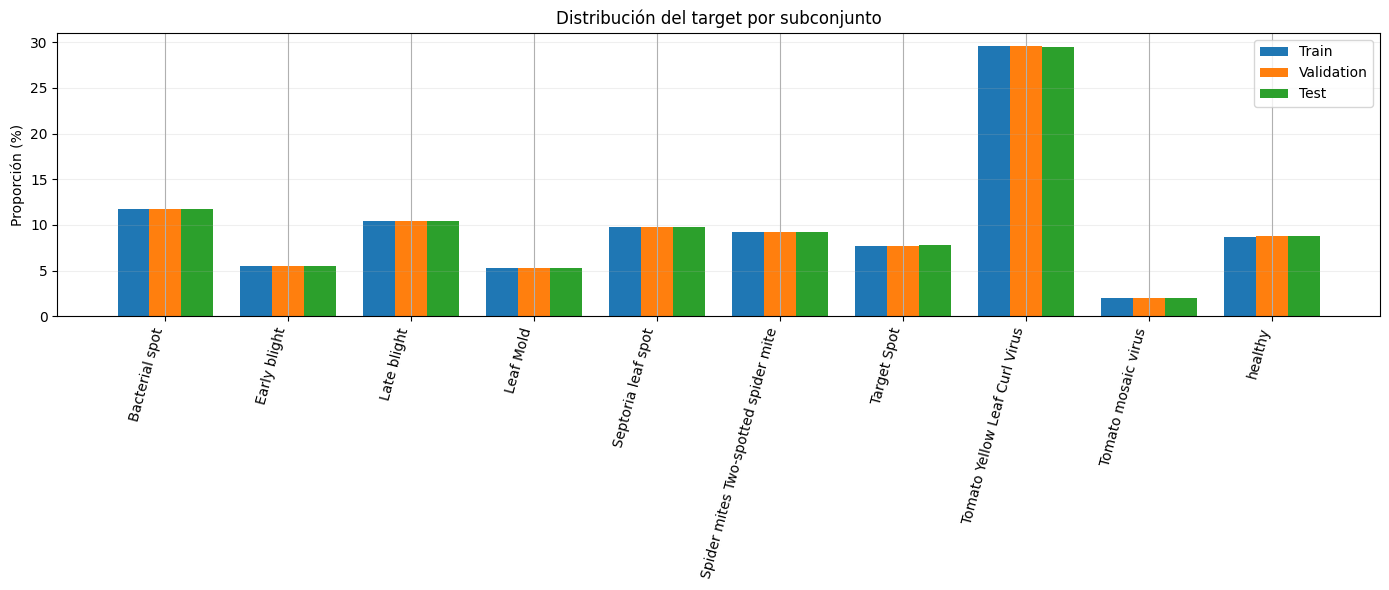


MANIFEST DE PARTICIONES — PREVIEW


,indice_original,split
0,0,train
1,1,test
2,2,train
3,3,train
4,4,test
5,5,train
6,6,train
7,7,train
8,8,validation
9,9,train



CONTROL FINAL — 6.3
Train      : (12702, 15)
Validation : (2722, 15)
Test       : (2722, 15)

✅ Split no temporal justificado.
✅ Partición 70/15/15 completada.
✅ Estratificación aplicada sobre y.
✅ Las 10 clases están presentes en Train.
✅ Las 10 clases están presentes en Validation.
✅ Las 10 clases están presentes en Test.
✅ Train, Validation y Test son disjuntos.
✅ RANDOM_STATE=42 garantiza reproducibilidad.
✅ No se aplicó escalado antes del split.
✅ No se aplicó PCA antes del split.
✅ No se realizó balanceo antes del split.
✅ No se utilizó la pseudo-producción de 5.10.
✅ Las matrices conservan las 15 features originales.
✅ 6.3 — SEPARACIÓN DE DATOS COMPLETADA


In [ ]:
# ============================================================
# FASE 2 — MODELADO SIN FUGA DE DATOS
# 6.3 SEPARACIÓN DE DATOS
# ============================================================
#
# ESTRATEGIA
# ------------------------------------------------------------
#
# El dataset NO posee temporalidad real.
#
# Por tanto se utiliza:
#
#       70% Train
#       15% Validation
#       15% Test
#
# mediante:
#
#       - partición aleatoria;
#       - estratificación por clase;
#       - RANDOM_STATE = 42.
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda:
#
#   - NO escala;
#   - NO imputa;
#   - NO aplica PCA;
#   - NO aplica Feature Engineering globalmente;
#   - NO calcula class_weight;
#   - NO realiza oversampling;
#   - NO entrena modelos.
#
# La finalidad es exclusivamente construir los conjuntos
# oficiales de Train, Validation y Test.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from IPython.display import display


# ============================================================
# 2. CONFIGURACIÓN
# ============================================================

RANDOM_STATE = globals().get(
    "RANDOM_STATE",
    42
)


TRAIN_SIZE = 0.70
VALIDATION_SIZE = 0.15
TEST_SIZE = 0.15


# ============================================================
# 3. VERIFICAR X E y DE 6.1
# ============================================================

if "X" not in globals():

    raise NameError(
        "No se encontró la matriz X. "
        "Ejecute previamente la sección 6.1."
    )


if "y" not in globals():

    raise NameError(
        "No se encontró el vector y. "
        "Ejecute previamente la sección 6.1."
    )


if X.empty:

    raise ValueError(
        "La matriz X está vacía."
    )


if len(X) != len(y):

    raise ValueError(
        "X e y poseen diferente número de observaciones."
    )


# ============================================================
# 4. VERIFICAR TEMPORALIDAD
# ============================================================
#
# Durante 5.8 se determinó que:
#
#       TEMPORALIDAD_REAL_DISPONIBLE = False
#
# Si en una versión futura del dataset apareciera una
# variable temporal real, este código impedirá utilizar
# automáticamente un split aleatorio.
# ============================================================

TEMPORALIDAD_MODELO = globals().get(
    "TEMPORALIDAD_REAL_DISPONIBLE",
    False
)


print("=" * 105)
print("6.3 — EVALUACIÓN DE ESTRATEGIA DE PARTICIÓN")
print("=" * 105)

print(
    f"Temporalidad real disponible : "
    f"{TEMPORALIDAD_MODELO}"
)


if TEMPORALIDAD_MODELO:

    raise ValueError(
        "Se detectó temporalidad real. "
        "No corresponde utilizar el split aleatorio de esta celda. "
        "Debe implementarse una separación cronológica."
    )


print(
    "✅ No existe temporalidad real: "
    "se utilizará partición estratificada."
)


# ============================================================
# 5. VERIFICAR PROPORCIONES DEL SPLIT
# ============================================================

assert np.isclose(
    TRAIN_SIZE
    +
    VALIDATION_SIZE
    +
    TEST_SIZE,
    1.0
), (
    "Las proporciones Train/Validation/Test "
    "deben sumar 1."
)


# ============================================================
# 6. PRIMERA PARTICIÓN
# ============================================================
#
# Dataset completo
#
#          70% Train
#            +
#          30% Temporal auxiliar
#
# El conjunto auxiliar se divide posteriormente:
#
#          15% Validation
#          15% Test
#
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(

    X,
    y,

    test_size=(
        VALIDATION_SIZE
        +
        TEST_SIZE
    ),

    random_state=RANDOM_STATE,

    stratify=y,

    shuffle=True
)


# ============================================================
# 7. SEGUNDA PARTICIÓN
# ============================================================
#
# Del 30% auxiliar:
#
#     50% -> Validation
#     50% -> Test
#
# Esto equivale al 15% del dataset original para cada uno.
#
# ============================================================

PROPORCION_TEST_SOBRE_TEMP = (
    TEST_SIZE
    /
    (
        VALIDATION_SIZE
        +
        TEST_SIZE
    )
)


X_val, X_test, y_val, y_test = train_test_split(

    X_temp,
    y_temp,

    test_size=PROPORCION_TEST_SOBRE_TEMP,

    random_state=RANDOM_STATE,

    stratify=y_temp,

    shuffle=True
)


# ============================================================
# 8. ELIMINAR VARIABLES TEMPORALES AUXILIARES
# ============================================================
#
# X_temp / y_temp solo fueron necesarias para generar
# Validation y Test.
# ============================================================

del X_temp
del y_temp


# ============================================================
# 9. TAMAÑOS RESULTANTES
# ============================================================

N_TOTAL = len(X)

N_TRAIN = len(X_train)
N_VAL = len(X_val)
N_TEST = len(X_test)


df_resumen_split = pd.DataFrame(
    {
        "Conjunto": [
            "Train",
            "Validation",
            "Test",
            "Total"
        ],

        "N": [
            N_TRAIN,
            N_VAL,
            N_TEST,
            N_TOTAL
        ],

        "Porcentaje (%)": [
            100 * N_TRAIN / N_TOTAL,
            100 * N_VAL / N_TOTAL,
            100 * N_TEST / N_TOTAL,
            100.0
        ]
    }
)


print("\n" + "=" * 105)
print("TAMAÑO DE LOS SUBCONJUNTOS")
print("=" * 105)


display(
    df_resumen_split.style.format(
        {
            "N": "{:,.0f}",
            "Porcentaje (%)": "{:.2f}"
        }
    )
)


# ============================================================
# 10. DISTRIBUCIÓN DE CLASES
# ============================================================
#
# Comparamos:
#
#     Dataset original
#     Train
#     Validation
#     Test
#
# ============================================================

clases = sorted(
    y.astype(str)
    .unique()
)


def distribucion_clases(
    serie,
    nombre
):
    """
    Calcula frecuencia y porcentaje de cada clase.
    """

    conteos = (
        serie.astype(str)
        .value_counts()
        .reindex(
            clases,
            fill_value=0
        )
    )


    porcentajes = (
        conteos
        /
        len(serie)
        *
        100
    )


    return pd.DataFrame(
        {
            f"{nombre} N": conteos,
            f"{nombre} (%)": porcentajes
        }
    )


tabla_global = distribucion_clases(
    y,
    "Global"
)


tabla_train = distribucion_clases(
    y_train,
    "Train"
)


tabla_val = distribucion_clases(
    y_val,
    "Validation"
)


tabla_test = distribucion_clases(
    y_test,
    "Test"
)


df_distribucion_split = pd.concat(
    [
        tabla_global,
        tabla_train,
        tabla_val,
        tabla_test
    ],
    axis=1
)


df_distribucion_split.index.name = "Clase"


print("\n" + "=" * 105)
print("DISTRIBUCIÓN DE CLASES POR SUBCONJUNTO")
print("=" * 105)


display(
    df_distribucion_split.style.format(
        {
            "Global N": "{:,.0f}",
            "Global (%)": "{:.2f}",

            "Train N": "{:,.0f}",
            "Train (%)": "{:.2f}",

            "Validation N": "{:,.0f}",
            "Validation (%)": "{:.2f}",

            "Test N": "{:,.0f}",
            "Test (%)": "{:.2f}"
        }
    )
)


# ============================================================
# 11. DIFERENCIA DE PROPORCIONES RESPECTO DEL DATASET GLOBAL
# ============================================================
#
# Se mide en puntos porcentuales:
#
# Delta_pp = P_split - P_global
#
# ============================================================

df_diferencias_proporcion = pd.DataFrame(
    index=clases
)


df_diferencias_proporcion[
    "Train - Global (pp)"
] = (
    df_distribucion_split[
        "Train (%)"
    ]
    -
    df_distribucion_split[
        "Global (%)"
    ]
)


df_diferencias_proporcion[
    "Validation - Global (pp)"
] = (
    df_distribucion_split[
        "Validation (%)"
    ]
    -
    df_distribucion_split[
        "Global (%)"
    ]
)


df_diferencias_proporcion[
    "Test - Global (pp)"
] = (
    df_distribucion_split[
        "Test (%)"
    ]
    -
    df_distribucion_split[
        "Global (%)"
    ]
)


df_diferencias_proporcion.index.name = "Clase"


print("\n" + "=" * 105)
print("DIFERENCIA DE PROPORCIONES RESPECTO DEL DATASET GLOBAL")
print("=" * 105)


display(
    df_diferencias_proporcion.style.format(
        "{:+.4f}"
    )
)


# ============================================================
# 12. MÁXIMA DESVIACIÓN DE PROPORCIONES
# ============================================================

max_desviacion_train = (
    df_diferencias_proporcion[
        "Train - Global (pp)"
    ]
    .abs()
    .max()
)


max_desviacion_val = (
    df_diferencias_proporcion[
        "Validation - Global (pp)"
    ]
    .abs()
    .max()
)


max_desviacion_test = (
    df_diferencias_proporcion[
        "Test - Global (pp)"
    ]
    .abs()
    .max()
)


print("\nMáxima desviación absoluta respecto del global:")

print(
    f"Train      : "
    f"{max_desviacion_train:.4f} pp"
)

print(
    f"Validation : "
    f"{max_desviacion_val:.4f} pp"
)

print(
    f"Test       : "
    f"{max_desviacion_test:.4f} pp"
)


# ============================================================
# 13. GRÁFICO DE DISTRIBUCIÓN DE CLASES
# ============================================================

df_plot_split = (
    df_distribucion_split[
        [
            "Train (%)",
            "Validation (%)",
            "Test (%)"
        ]
    ]
    .copy()
)


# Simplificar etiquetas únicamente para visualización.
etiquetas = [
    str(clase)
    .replace(
        "Tomato___",
        ""
    )
    .replace(
        "_",
        " "
    )
    for clase in df_plot_split.index
]


x_pos = np.arange(
    len(
        df_plot_split
    )
)


ancho = 0.26


plt.figure(
    figsize=(14, 6)
)


plt.bar(
    x_pos - ancho,
    df_plot_split[
        "Train (%)"
    ],
    width=ancho,
    label="Train"
)


plt.bar(
    x_pos,
    df_plot_split[
        "Validation (%)"
    ],
    width=ancho,
    label="Validation"
)


plt.bar(
    x_pos + ancho,
    df_plot_split[
        "Test (%)"
    ],
    width=ancho,
    label="Test"
)


plt.xticks(
    x_pos,
    etiquetas,
    rotation=75,
    ha="right"
)


plt.ylabel(
    "Proporción (%)"
)


plt.title(
    "Distribución del target por subconjunto"
)


plt.grid(
    axis="y",
    alpha=0.20
)


plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 14. VERIFICAR DISJUNCIÓN DE ÍNDICES
# ============================================================

indices_train = set(
    X_train.index
)


indices_val = set(
    X_val.index
)


indices_test = set(
    X_test.index
)


interseccion_train_val = (
    indices_train
    .intersection(
        indices_val
    )
)


interseccion_train_test = (
    indices_train
    .intersection(
        indices_test
    )
)


interseccion_val_test = (
    indices_val
    .intersection(
        indices_test
    )
)


# ============================================================
# 15. MANIFEST DE PARTICIONES
# ============================================================
#
# Permite conservar qué observación pertenece a cada split.
#
# Esto será útil para:
#
#   - reproducibilidad;
#   - auditoría;
#   - MLOps;
#   - comparación posterior.
#
# ============================================================

df_manifest_split = pd.DataFrame(
    {
        "indice_original": (
            list(X_train.index)
            +
            list(X_val.index)
            +
            list(X_test.index)
        ),

        "split": (
            ["train"] * len(X_train)
            +
            ["validation"] * len(X_val)
            +
            ["test"] * len(X_test)
        )
    }
)


df_manifest_split = (
    df_manifest_split
    .sort_values(
        "indice_original"
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 105)
print("MANIFEST DE PARTICIONES — PREVIEW")
print("=" * 105)


display(
    df_manifest_split.head(10)
)


# ============================================================
# 16. VERIFICAR CLASES EN CADA SPLIT
# ============================================================

clases_global = set(
    y.unique()
)


clases_train = set(
    y_train.unique()
)


clases_val = set(
    y_val.unique()
)


clases_test = set(
    y_test.unique()
)


# ============================================================
# 17. CONTROLES AUTOMÁTICOS
# ============================================================

assert (
    N_TRAIN
    +
    N_VAL
    +
    N_TEST
    ==
    N_TOTAL
), (
    "Los tamaños de los splits no reconstruyen "
    "el dataset completo."
)


assert (
    len(
        interseccion_train_val
    )
    == 0
), (
    "Train y Validation comparten observaciones."
)


assert (
    len(
        interseccion_train_test
    )
    == 0
), (
    "Train y Test comparten observaciones."
)


assert (
    len(
        interseccion_val_test
    )
    == 0
), (
    "Validation y Test comparten observaciones."
)


assert (
    clases_train
    ==
    clases_global
), (
    "Train no contiene todas las clases."
)


assert (
    clases_val
    ==
    clases_global
), (
    "Validation no contiene todas las clases."
)


assert (
    clases_test
    ==
    clases_global
), (
    "Test no contiene todas las clases."
)


assert (
    X_train.index.equals(
        y_train.index
    )
)


assert (
    X_val.index.equals(
        y_val.index
    )
)


assert (
    X_test.index.equals(
        y_test.index
    )
)


assert (
    X_train.shape[1]
    ==
    X.shape[1]
), (
    "Train modificó inesperadamente "
    "el número de features."
)


assert (
    X_val.shape[1]
    ==
    X.shape[1]
)


assert (
    X_test.shape[1]
    ==
    X.shape[1]
)


# ============================================================
# 18. VERIFICAR AUSENCIA DE TRANSFORMACIONES PREMATURAS
# ============================================================
#
# Las matrices deben conservar las 15 features originales.
#
# Feature Engineering, scaler, etc. se incorporarán
# posteriormente dentro del Pipeline.
#
# ============================================================

assert (
    list(
        X_train.columns
    )
    ==
    list(
        X.columns
    )
)


assert (
    list(
        X_val.columns
    )
    ==
    list(
        X.columns
    )
)


assert (
    list(
        X_test.columns
    )
    ==
    list(
        X.columns
    )
)


# ============================================================
# 19. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 105)
print("CONTROL FINAL — 6.3")
print("=" * 105)


print(
    f"Train      : {X_train.shape}"
)

print(
    f"Validation : {X_val.shape}"
)

print(
    f"Test       : {X_test.shape}"
)


print(
    "\n✅ Split no temporal justificado."
)

print(
    "✅ Partición 70/15/15 completada."
)

print(
    "✅ Estratificación aplicada sobre y."
)

print(
    "✅ Las 10 clases están presentes en Train."
)

print(
    "✅ Las 10 clases están presentes en Validation."
)

print(
    "✅ Las 10 clases están presentes en Test."
)

print(
    "✅ Train, Validation y Test son disjuntos."
)

print(
    "✅ RANDOM_STATE=42 garantiza reproducibilidad."
)

print(
    "✅ No se aplicó escalado antes del split."
)

print(
    "✅ No se aplicó PCA antes del split."
)

print(
    "✅ No se realizó balanceo antes del split."
)

print(
    "✅ No se utilizó la pseudo-producción de 5.10."
)

print(
    "✅ Las matrices conservan las 15 features originales."
)

print("=" * 105)

print(
    "✅ 6.3 — SEPARACIÓN DE DATOS COMPLETADA"
)

## 6.4 Baseline

Antes de entrenar modelos capaces de aprender relaciones entre las características.

## 6.4.1 Definición del baseline

Dado que el problema corresponde a una clasificación multiclase y presenta.

## 6.4.2 Estrategia seleccionada

DummyClassifier(strategy="most_frequent").

## 6.4.3 Clase mayoritaria

Esta sección resume clase mayoritaria y su función dentro del proyecto MLOps.

## 6.4.4 Accuracy

Esta sección resume accuracy y su función dentro del proyecto MLOps.

## 6.4.5 Limitación de Accuracy frente al desbalance

clases y presenta una razón de desbalance aproximada de.

## 6.4.6 Recall macro

Esta sección resume recall macro y su función dentro del proyecto MLOps.

## 6.4.7 Balanced Accuracy

En clasificación multiclase, la Balanced Accuracy corresponde al promedio del.

## 6.4.8 Precision macro

La Precision para una clase se define como.

## 6.4.9 F1-score

Esta sección resume f1-score y su función dentro del proyecto MLOps.

## 6.4.10 Métricas de referencia

Con los datos actuales, los valores esperados del baseline son aproximadamente.

## 6.4.11 Criterio de valor agregado

Esta sección resume criterio de valor agregado y su función dentro del proyecto MLOps.

## 6.4.12 Uso de Train, Validation y Test

El flujo metodológico de esta sección será.

## 6.4.13 Relación con el Feature Engineering

El baseline no requiere aplicar las transformaciones definidas en 6.2 porque.

## 6.4.14 Interpretación esperada

El baseline establece una referencia que no utiliza información visual.

## 6.4.15 Conclusión

Esta sección resume conclusión y su función dentro del proyecto MLOps.


6.4 — BASELINE MAYORITARIO
N Train                     : 12,702
N Validation                : 2,722
Número de clases en Train   : 10
Clase mayoritaria en Train  : Tomato___Tomato_Yellow_Leaf_Curl_Virus
Frecuencia en Train         : 3,750
Proporción en Train         : 29.5229%

MÉTRICAS DEL BASELINE — VALIDATION


,Modelo,Conjunto evaluación,Accuracy,Precision macro,Recall macro,F1 macro,F1 weighted,Balanced Accuracy,Tiempo fit (s),Tiempo predicción Validation (s)
0,DummyClassifier — most_frequent,Validation,0.2954,0.0295,0.1000,0.0456,0.1347,0.1000,0.013590,0.000832



Interpretación rápida:
Accuracy                 : 29.54%
Precision macro          : 0.0295
Recall macro             : 0.1000
F1 macro                 : 0.0456
Balanced Accuracy        : 0.1000

REPORTE DE CLASIFICACIÓN DEL BASELINE


,precision,recall,f1-score,support
Tomato___Bacterial_spot,0.0000,0.0000,0.0000,319
Tomato___Early_blight,0.0000,0.0000,0.0000,150
Tomato___Late_blight,0.0000,0.0000,0.0000,285
Tomato___Leaf_Mold,0.0000,0.0000,0.0000,143
Tomato___Septoria_leaf_spot,0.0000,0.0000,0.0000,265
Tomato___Spider_mites Two-spotted_spider_mite,0.0000,0.0000,0.0000,252
Tomato___Target_Spot,0.0000,0.0000,0.0000,210
Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.2954,1.0000,0.4560,804
Tomato___Tomato_mosaic_virus,0.0000,0.0000,0.0000,56
Tomato___healthy,0.0000,0.0000,0.0000,238


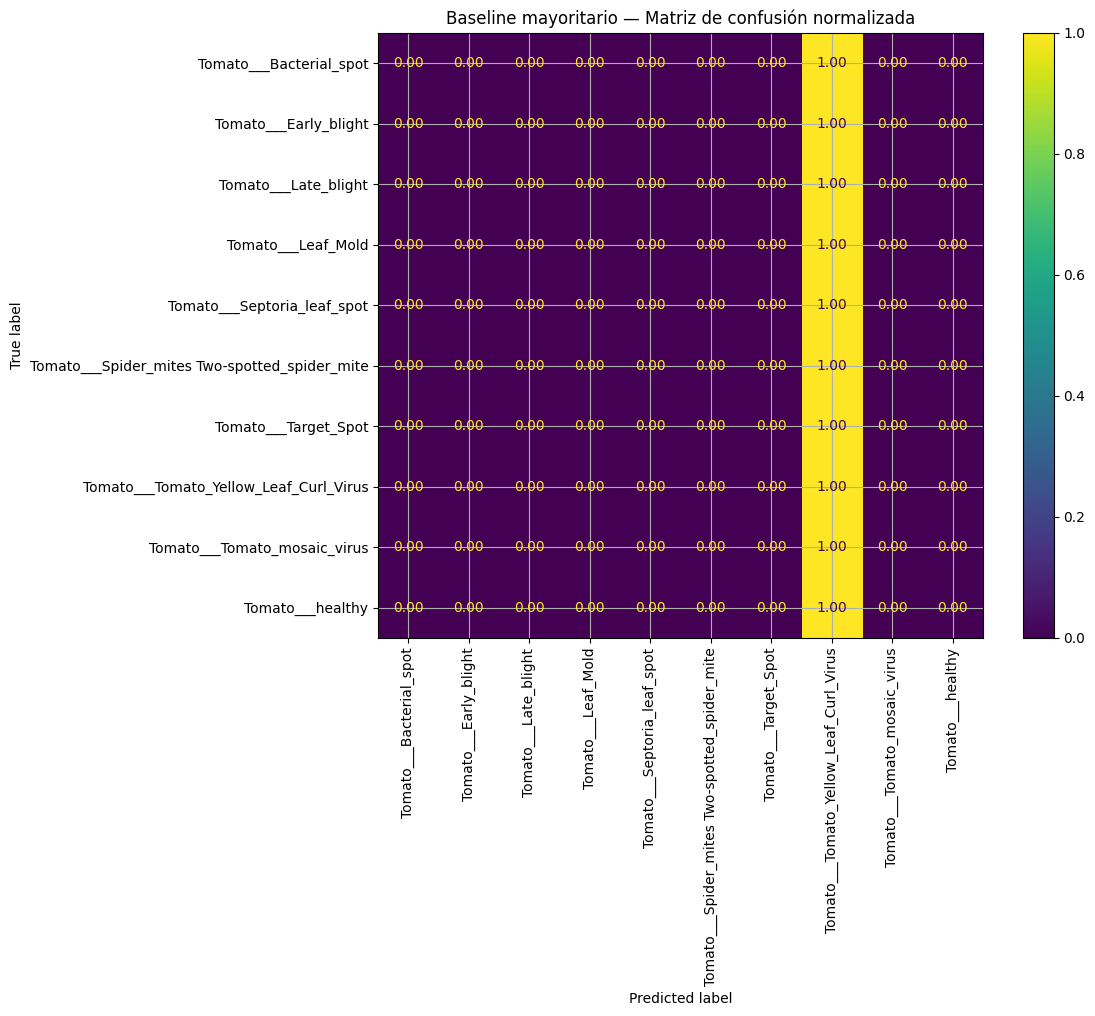


PISO DE DESEMPEÑO PARA MODELOS POSTERIORES


,Métrica,Baseline Validation,Uso posterior
0,Accuracy,0.2954,Referencia global
1,Precision macro,0.0295,Equilibrio de precisión entre clases
2,Recall macro,0.1000,Cobertura promedio de las clases
3,F1 macro,0.0456,Métrica prioritaria frente al desbalance
4,Balanced Accuracy,0.1000,Desempeño balanceado entre clases



CONTROL FINAL — 6.4
✅ Baseline creado con DummyClassifier.
✅ Clase mayoritaria aprendida exclusivamente desde Train.
✅ Evaluación realizada exclusivamente sobre Validation.
✅ Test permanece sin utilizar.
✅ Accuracy calculada.
✅ Precision macro calculada.
✅ Recall macro calculado.
✅ F1 macro calculado.
✅ Balanced Accuracy calculada.
✅ Reporte por clase generado.
✅ Matriz de confusión generada.
✅ Tiempo de fit registrado.
✅ Tiempo de inferencia registrado.
✅ Resultados preparados para comparación posterior.
✅ 6.4 — BASELINE COMPLETADO


In [ ]:

# ============================================================
# FASE 2 — MODELADO SIN FUGA DE DATOS
# 6.4 BASELINE
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Construir una referencia mínima de desempeño antes de
# entrenar modelos capaces de utilizar las features.
#
# ESTRATEGIA
# ------------------------------------------------------------
#
# DummyClassifier(strategy="most_frequent")
#
# El modelo predice siempre la clase más frecuente observada
# exclusivamente en y_train.
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda:
#
#   - utiliza Train para ajustar el baseline;
#   - utiliza Validation para evaluarlo;
#   - NO utiliza Test;
#   - NO escala;
#   - NO aplica PCA;
#   - NO aplica Feature Engineering;
#   - NO realiza balanceo;
#   - NO calcula class_weight;
#   - NO selecciona hiperparámetros.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from IPython.display import display


# ============================================================
# 2. CONFIGURACIÓN
# ============================================================

RANDOM_STATE = globals().get(
    "RANDOM_STATE",
    42
)


# ============================================================
# 3. VERIFICAR SPLIT DE 6.3
# ============================================================

objetos_requeridos = [
    "X_train",
    "X_val",
    "y_train",
    "y_val"
]


objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]


if objetos_faltantes:

    raise NameError(
        "Faltan objetos generados en 6.3: "
        f"{objetos_faltantes}"
    )


if len(X_train) != len(y_train):

    raise ValueError(
        "X_train e y_train tienen tamaños diferentes."
    )


if len(X_val) != len(y_val):

    raise ValueError(
        "X_val e y_val tienen tamaños diferentes."
    )


# ============================================================
# 4. IDENTIFICAR CLASE MAYORITARIA DE TRAIN
# ============================================================
#
# IMPORTANTE:
# La clase mayoritaria se determina SOLO con y_train.
#
# ============================================================

conteos_train_baseline = (
    y_train
    .value_counts()
)


CLASE_MAYORITARIA_BASELINE = (
    conteos_train_baseline
    .idxmax()
)


N_CLASE_MAYORITARIA_TRAIN = int(
    conteos_train_baseline.max()
)


PROP_CLASE_MAYORITARIA_TRAIN = (
    N_CLASE_MAYORITARIA_TRAIN
    /
    len(y_train)
)


print("=" * 110)
print("6.4 — BASELINE MAYORITARIO")
print("=" * 110)


print(
    f"N Train                     : "
    f"{len(y_train):,}"
)


print(
    f"N Validation                : "
    f"{len(y_val):,}"
)


print(
    f"Número de clases en Train   : "
    f"{y_train.nunique()}"
)


print(
    f"Clase mayoritaria en Train  : "
    f"{CLASE_MAYORITARIA_BASELINE}"
)


print(
    f"Frecuencia en Train         : "
    f"{N_CLASE_MAYORITARIA_TRAIN:,}"
)


print(
    f"Proporción en Train         : "
    f"{PROP_CLASE_MAYORITARIA_TRAIN:.4%}"
)


# ============================================================
# 5. CREAR BASELINE
# ============================================================
#
# strategy="most_frequent"
#
# Siempre predice la clase más frecuente observada en Train.
#
# X es requerido por la interfaz de sklearn, pero sus valores
# no son utilizados para aprender reglas predictivas.
#
# ============================================================

baseline_model = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)


# ============================================================
# 6. AJUSTAR EXCLUSIVAMENTE SOBRE TRAIN
# ============================================================

inicio_fit = time.perf_counter()


baseline_model.fit(
    X_train,
    y_train
)


fin_fit = time.perf_counter()


TIEMPO_FIT_BASELINE = (
    fin_fit
    -
    inicio_fit
)


# ============================================================
# 7. PREDICCIÓN SOBRE VALIDATION
# ============================================================
#
# Test NO participa.
#
# ============================================================

inicio_pred = time.perf_counter()


y_val_pred_baseline = baseline_model.predict(
    X_val
)


fin_pred = time.perf_counter()


TIEMPO_PRED_VAL_BASELINE = (
    fin_pred
    -
    inicio_pred
)


# ============================================================
# 8. COMPROBAR COMPORTAMIENTO DEL DUMMY
# ============================================================

clases_predichas = np.unique(
    y_val_pred_baseline
)


assert (
    len(clases_predichas)
    == 1
), (
    "El baseline most_frequent debería predecir "
    "una única clase."
)


assert (
    clases_predichas[0]
    ==
    CLASE_MAYORITARIA_BASELINE
), (
    "La clase predicha no corresponde "
    "a la clase mayoritaria de Train."
)


# ============================================================
# 9. MÉTRICAS GLOBALES
# ============================================================

baseline_accuracy = accuracy_score(
    y_val,
    y_val_pred_baseline
)


baseline_precision_macro = precision_score(
    y_val,
    y_val_pred_baseline,
    average="macro",
    zero_division=0
)


baseline_recall_macro = recall_score(
    y_val,
    y_val_pred_baseline,
    average="macro",
    zero_division=0
)


baseline_f1_macro = f1_score(
    y_val,
    y_val_pred_baseline,
    average="macro",
    zero_division=0
)


baseline_f1_weighted = f1_score(
    y_val,
    y_val_pred_baseline,
    average="weighted",
    zero_division=0
)


baseline_balanced_accuracy = (
    balanced_accuracy_score(
        y_val,
        y_val_pred_baseline
    )
)


# ============================================================
# 10. COMPROBAR ACCURACY TEÓRICA
# ============================================================
#
# Para un clasificador mayoritario:
#
# Accuracy = proporción de la clase mayoritaria en Validation.
#
# ============================================================

prop_mayoritaria_validation = float(
    (
        y_val
        ==
        CLASE_MAYORITARIA_BASELINE
    )
    .mean()
)


assert np.isclose(
    baseline_accuracy,
    prop_mayoritaria_validation
), (
    "La Accuracy observada no coincide con "
    "la proporción de la clase mayoritaria."
)


# ============================================================
# 11. TABLA PRINCIPAL DE RESULTADOS
# ============================================================
#
# Esta tabla podrá reutilizarse posteriormente en:
#
#   6.7 Comparación de modelos
#   6.8 Validación y métricas
#   6.10 Selección del campeón
#
# ============================================================

df_resultados_baseline = pd.DataFrame(
    {
        "Modelo": [
            "DummyClassifier — most_frequent"
        ],

        "Conjunto evaluación": [
            "Validation"
        ],

        "Accuracy": [
            baseline_accuracy
        ],

        "Precision macro": [
            baseline_precision_macro
        ],

        "Recall macro": [
            baseline_recall_macro
        ],

        "F1 macro": [
            baseline_f1_macro
        ],

        "F1 weighted": [
            baseline_f1_weighted
        ],

        "Balanced Accuracy": [
            baseline_balanced_accuracy
        ],

        "Tiempo fit (s)": [
            TIEMPO_FIT_BASELINE
        ],

        "Tiempo predicción Validation (s)": [
            TIEMPO_PRED_VAL_BASELINE
        ]
    }
)


print("\n" + "=" * 110)
print("MÉTRICAS DEL BASELINE — VALIDATION")
print("=" * 110)


display(
    df_resultados_baseline.style.format(
        {
            "Accuracy": "{:.4f}",
            "Precision macro": "{:.4f}",
            "Recall macro": "{:.4f}",
            "F1 macro": "{:.4f}",
            "F1 weighted": "{:.4f}",
            "Balanced Accuracy": "{:.4f}",
            "Tiempo fit (s)": "{:.6f}",
            "Tiempo predicción Validation (s)": "{:.6f}"
        }
    )
)


# ============================================================
# 12. INTERPRETACIÓN NUMÉRICA DIRECTA
# ============================================================

print("\nInterpretación rápida:")

print(
    f"Accuracy                 : "
    f"{baseline_accuracy:.2%}"
)

print(
    f"Precision macro          : "
    f"{baseline_precision_macro:.4f}"
)

print(
    f"Recall macro             : "
    f"{baseline_recall_macro:.4f}"
)

print(
    f"F1 macro                 : "
    f"{baseline_f1_macro:.4f}"
)

print(
    f"Balanced Accuracy        : "
    f"{baseline_balanced_accuracy:.4f}"
)


# ============================================================
# 13. REPORTE DETALLADO POR CLASE
# ============================================================

reporte_baseline = classification_report(
    y_val,
    y_val_pred_baseline,
    output_dict=True,
    zero_division=0
)


df_reporte_baseline = (
    pd.DataFrame(
        reporte_baseline
    )
    .T
)


print("\n" + "=" * 110)
print("REPORTE DE CLASIFICACIÓN DEL BASELINE")
print("=" * 110)


display(
    df_reporte_baseline.style.format(
        {
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1-score": "{:.4f}",
            "support": "{:.0f}"
        }
    )
)


# ============================================================
# 14. MATRIZ DE CONFUSIÓN
# ============================================================
#
# Se utiliza normalización por clase verdadera.
#
# El comportamiento esperado es que TODAS las filas
# terminen concentradas en la columna de la clase mayoritaria.
#
# ============================================================

clases_ordenadas = sorted(
    y_train.astype(str)
    .unique()
)


fig, ax = plt.subplots(
    figsize=(12, 10)
)


ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred_baseline,

    labels=clases_ordenadas,

    normalize="true",

    values_format=".2f",

    xticks_rotation=90,

    ax=ax
)


ax.set_title(
    "Baseline mayoritario — Matriz de confusión normalizada"
)


plt.tight_layout()

plt.show()


# ============================================================
# 15. TABLA DEL PISO DE DESEMPEÑO
# ============================================================
#
# Define el valor mínimo que los modelos posteriores
# deberán superar.
#
# ============================================================

df_umbral_baseline = pd.DataFrame(
    {
        "Métrica": [
            "Accuracy",
            "Precision macro",
            "Recall macro",
            "F1 macro",
            "Balanced Accuracy"
        ],

        "Baseline Validation": [
            baseline_accuracy,
            baseline_precision_macro,
            baseline_recall_macro,
            baseline_f1_macro,
            baseline_balanced_accuracy
        ],

        "Uso posterior": [
            "Referencia global",
            "Equilibrio de precisión entre clases",
            "Cobertura promedio de las clases",
            "Métrica prioritaria frente al desbalance",
            "Desempeño balanceado entre clases"
        ]
    }
)


print("\n" + "=" * 110)
print("PISO DE DESEMPEÑO PARA MODELOS POSTERIORES")
print("=" * 110)


display(
    df_umbral_baseline.style.format(
        {
            "Baseline Validation": "{:.4f}"
        }
    )
)


# ============================================================
# 16. CONTROLES AUTOMÁTICOS
# ============================================================

assert (
    len(y_val_pred_baseline)
    ==
    len(y_val)
), (
    "La cantidad de predicciones no coincide con Validation."
)


assert (
    baseline_accuracy
    >= 0
    and baseline_accuracy
    <= 1
)


assert (
    baseline_f1_macro
    >= 0
    and baseline_f1_macro
    <= 1
)


assert (
    baseline_balanced_accuracy
    >= 0
    and baseline_balanced_accuracy
    <= 1
)


assert (
    set(
        baseline_model.classes_
    )
    ==
    set(
        y_train.unique()
    )
), (
    "El baseline no registró correctamente "
    "las clases de Train."
)


# ============================================================
# 17. OBJETOS QUE SE CONSERVAN
# ============================================================
#
# Se mantienen:
#
# baseline_model
# y_val_pred_baseline
# df_resultados_baseline
# df_reporte_baseline
# df_umbral_baseline
#
# para futuras comparaciones.
#
# ============================================================


# ============================================================
# 18. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 110)
print("CONTROL FINAL — 6.4")
print("=" * 110)


print(
    "✅ Baseline creado con DummyClassifier."
)

print(
    "✅ Clase mayoritaria aprendida exclusivamente desde Train."
)

print(
    "✅ Evaluación realizada exclusivamente sobre Validation."
)

print(
    "✅ Test permanece sin utilizar."
)

print(
    "✅ Accuracy calculada."
)

print(
    "✅ Precision macro calculada."
)

print(
    "✅ Recall macro calculado."
)

print(
    "✅ F1 macro calculado."
)

print(
    "✅ Balanced Accuracy calculada."
)

print(
    "✅ Reporte por clase generado."
)

print(
    "✅ Matriz de confusión generada."
)

print(
    "✅ Tiempo de fit registrado."
)

print(
    "✅ Tiempo de inferencia registrado."
)

print(
    "✅ Resultados preparados para comparación posterior."
)

print("=" * 110)

print(
    "✅ 6.4 — BASELINE COMPLETADO"
)

## 6.5 Preprocesamiento con ColumnTransformer

El objetivo de esta etapa es construir un preprocesador único, reproducible y libre.

## 6.5.1 Situación actual del proyecto

Después de las etapas 6.1 a 6.3, la matriz predictora contiene.

## 6.5.2 Pipeline numérico

El pipeline numérico tendrá tres etapas.

## A. Feature Engineering reproducible

Se reutilizará el transformer definido previamente.

## B. Imputación numérica

Aunque el dataset limpio no presenta valores faltantes en las features actuales,.

## C. Estandarización

Después de la imputación se utilizará StandardScaler.

## 6.5.3 Pipeline categórico

Aunque el modelo actual no posee features categóricas predictivas, se definirá una.

## 6.5.4 Dimensionalidad después del Feature Engineering

Esta sección resume dimensionalidad después del Feature Engineering y su función dentro del proyecto MLOps.

## 6.5.5 Prevención de fuga de datos

Esta sección resume prevención de fuga de datos y su función dentro del proyecto MLOps.

## 6.5.6 Estructura final

La arquitectura del preprocesamiento queda.


In [ ]:
# ============================================================
# FASE 2 — MODELADO SIN FUGA DE DATOS
# 6.5 PREPROCESAMIENTO CON COLUMNTRANSFORMER
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Construir un preprocesador reproducible compuesto por:
#
#   RAMA NUMÉRICA
#       1. Feature Engineering de 6.2
#       2. Imputación por mediana
#       3. StandardScaler
#
#   RAMA CATEGÓRICA
#       1. Imputación por moda
#       2. OneHotEncoder
#
# SITUACIÓN ACTUAL
# ------------------------------------------------------------
# X_train contiene únicamente 15 features numéricas.
#
# Por tanto:
#
#       numeric_features     = 15 variables
#       categorical_features = []
#
# IMPORTANTE
# ------------------------------------------------------------
# El objeto "preprocessor" definido al final de esta celda
# permanecerá SIN AJUSTAR para utilizarse posteriormente en 6.6.
#
# Para comprobar su funcionamiento se utilizará una COPIA
# mediante sklearn.clone().
#
# La copia de verificación:
#
#       FIT       -> X_train
#       TRANSFORM -> X_val
#
# Test permanece aislado.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from IPython.display import display


# ============================================================
# 2. VERIFICAR OBJETOS PREVIOS
# ============================================================

objetos_requeridos = [
    "X_train",
    "X_val",
    "y_train",
    "y_val"
]


objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]


if objetos_faltantes:

    raise NameError(
        "Faltan objetos generados en 6.3: "
        f"{objetos_faltantes}"
    )


# Feature Engineering definido en 6.2.
if "FeatureEngineeringProduccion" not in globals():

    raise NameError(
        "No se encontró FeatureEngineeringProduccion. "
        "Ejecute previamente la sección 6.2."
    )


# ============================================================
# 3. DEFINIR FEATURES NUMÉRICAS
# ============================================================
#
# Se utilizan exactamente las 15 features definidas en 6.1.
#
# ============================================================

numeric_features = [
    "r_mean",
    "g_mean",
    "b_mean",
    "r_std",
    "g_std",
    "b_std",
    "h_mean",
    "s_mean",
    "v_mean",
    "excess_green",
    "brightness_mean",
    "contrast_std",
    "laplacian_variance",
    "entropy",
    "edge_density"
]


# ============================================================
# 4. DEFINIR FEATURES CATEGÓRICAS
# ============================================================
#
# Actualmente NO existen variables categóricas dentro de X.
#
# "modo" y "formato" fueron excluidas previamente porque son
# constantes y funcionan como controles de calidad.
#
# La lista vacía permite conservar la estructura general del
# ColumnTransformer sin reintroducir variables descartadas.
#
# ============================================================

categorical_features = []


# ============================================================
# 5. VERIFICAR FEATURES NUMÉRICAS
# ============================================================

features_numericas_faltantes = [
    feature
    for feature in numeric_features
    if feature not in X_train.columns
]


if features_numericas_faltantes:

    raise KeyError(
        "Faltan features numéricas en X_train: "
        f"{features_numericas_faltantes}"
    )


# Verificar que todas sean numéricas.
features_no_numericas = [
    feature
    for feature in numeric_features
    if not pd.api.types.is_numeric_dtype(
        X_train[feature]
    )
]


if features_no_numericas:

    raise TypeError(
        "Las siguientes variables deberían ser numéricas: "
        f"{features_no_numericas}"
    )


# ============================================================
# 6. PIPELINE NUMÉRICO
# ============================================================
#
# Flujo:
#
# X_num
#   |
#   v
# FeatureEngineeringProduccion
#   |
#   v
# SimpleImputer(median)
#   |
#   v
# StandardScaler
#
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "feature_engineering",
            FeatureEngineeringProduccion(
                eliminar_h_mean=True,
                eliminar_laplacian_original=True
            )
        ),

        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ============================================================
# 7. PIPELINE CATEGÓRICO
# ============================================================
#
# Aunque actualmente categorical_features = [],
# se deja preparado para posibles ampliaciones futuras.
#
# ============================================================

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# ============================================================
# 8. CONSTRUIR COLUMNTRANSFORMER
# ============================================================
#
# remainder="drop"
#
# garantiza que cualquier columna no declarada explícitamente
# sea descartada.
#
# Esto constituye una protección adicional frente a la
# incorporación accidental de identificadores o leakage.
#
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),

        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ],

    remainder="drop",

    verbose_feature_names_out=True
)


# ============================================================
# 9. TABLA DE CONFIGURACIÓN
# ============================================================

df_configuracion_preprocesamiento = pd.DataFrame(
    {
        "Rama": [
            "Numérica",
            "Categórica"
        ],

        "N features entrada": [
            len(numeric_features),
            len(categorical_features)
        ],

        "Transformaciones": [
            (
                "FeatureEngineeringProduccion -> "
                "SimpleImputer(median) -> StandardScaler"
            ),
            (
                "SimpleImputer(most_frequent) -> "
                "OneHotEncoder(handle_unknown='ignore')"
            )
        ],

        "Estado actual": [
            "Activa",
            "Inactiva: no existen features categóricas predictivas"
        ]
    }
)


print("=" * 110)
print("6.5 — CONFIGURACIÓN DEL COLUMNTRANSFORMER")
print("=" * 110)


display(
    df_configuracion_preprocesamiento
)


# ============================================================
# 10. VERIFICACIÓN SIN ALTERAR EL PREPROCESSOR OFICIAL
# ============================================================
#
# Se utiliza clone(preprocessor).
#
# De esta forma:
#
#       preprocessor
#
# permanece limpio y podrá ser utilizado en 6.6 dentro
# del Pipeline completo.
#
# ============================================================

preprocessor_validacion = clone(
    preprocessor
)


# Guardar copia para comprobar que X_train no sea modificada.
X_train_antes_preprocesamiento = (
    X_train.copy()
)


# ============================================================
# 11. FIT EXCLUSIVAMENTE SOBRE TRAIN
# ============================================================

X_train_preprocessed_preview = (
    preprocessor_validacion
    .fit_transform(
        X_train,
        y_train
    )
)


# ============================================================
# 12. TRANSFORMAR VALIDATION
# ============================================================
#
# IMPORTANTE:
#
# Validation NO realiza fit.
#
# Utiliza:
#
#       medianas aprendidas en Train
#       medias aprendidas en Train
#       desviaciones aprendidas en Train
#
# ============================================================

X_val_preprocessed_preview = (
    preprocessor_validacion
    .transform(
        X_val
    )
)


# ============================================================
# 13. TEST PERMANECE AISLADO
# ============================================================
#
# No se transforma X_test en esta sección.
#
# La transformación de Test se realizará únicamente cuando
# corresponda efectuar la evaluación final.
#
# ============================================================


# ============================================================
# 14. RECUPERAR NOMBRES DE FEATURES DE SALIDA
# ============================================================

feature_names_preprocessed = (
    preprocessor_validacion
    .get_feature_names_out()
)


N_FEATURES_PREPROCESADAS = len(
    feature_names_preprocessed
)


df_features_preprocesadas = pd.DataFrame(
    {
        "N": np.arange(
            1,
            N_FEATURES_PREPROCESADAS + 1
        ),

        "Feature preprocesada": (
            feature_names_preprocessed
        )
    }
)


print("\n" + "=" * 110)
print("FEATURES RESULTANTES DEL PREPROCESAMIENTO")
print("=" * 110)


display(
    df_features_preprocesadas
)


# ============================================================
# 15. DIMENSIONES
# ============================================================

print("\n" + "=" * 110)
print("DIMENSIONALIDAD")
print("=" * 110)


print(
    f"X_train original       : "
    f"{X_train.shape}"
)


print(
    f"X_train preprocesado   : "
    f"{X_train_preprocessed_preview.shape}"
)


print(
    f"X_val original         : "
    f"{X_val.shape}"
)


print(
    f"X_val preprocesado     : "
    f"{X_val_preprocessed_preview.shape}"
)


# ============================================================
# 16. VERIFICAR VALORES FALTANTES E INFINITOS
# ============================================================

nan_train = int(
    np.isnan(
        X_train_preprocessed_preview
    ).sum()
)


nan_val = int(
    np.isnan(
        X_val_preprocessed_preview
    ).sum()
)


inf_train = int(
    np.isinf(
        X_train_preprocessed_preview
    ).sum()
)


inf_val = int(
    np.isinf(
        X_val_preprocessed_preview
    ).sum()
)


df_calidad_preprocesamiento = pd.DataFrame(
    {
        "Conjunto": [
            "Train",
            "Validation"
        ],

        "NaN": [
            nan_train,
            nan_val
        ],

        "Inf": [
            inf_train,
            inf_val
        ]
    }
)


print("\n" + "=" * 110)
print("CONTROL DE CALIDAD DEL PREPROCESAMIENTO")
print("=" * 110)


display(
    df_calidad_preprocesamiento
)


# ============================================================
# 17. VERIFICAR ESTANDARIZACIÓN SOBRE TRAIN
# ============================================================
#
# StandardScaler utiliza estadísticas aprendidas en Train.
#
# Después del escalado se espera aproximadamente:
#
#       media ~ 0
#       desviación estándar ~ 1
#
# para las features no constantes.
#
# ============================================================

medias_train_preprocessed = np.mean(
    X_train_preprocessed_preview,
    axis=0
)


std_train_preprocessed = np.std(
    X_train_preprocessed_preview,
    axis=0
)


MAX_ABS_MEDIA_TRAIN = float(
    np.max(
        np.abs(
            medias_train_preprocessed
        )
    )
)


MAX_DESVIACION_STD_UNO = float(
    np.max(
        np.abs(
            std_train_preprocessed
            - 1.0
        )
    )
)


print("\n" + "=" * 110)
print("VERIFICACIÓN DEL STANDARD SCALER")
print("=" * 110)


print(
    "Máxima |media| en Train preprocesado : "
    f"{MAX_ABS_MEDIA_TRAIN:.6e}"
)


print(
    "Máxima |std - 1| en Train            : "
    f"{MAX_DESVIACION_STD_UNO:.6e}"
)


# ============================================================
# 18. PREVIEW DEL TRAIN PREPROCESADO
# ============================================================

df_train_preprocessed_preview = pd.DataFrame(
    X_train_preprocessed_preview[:10],
    columns=feature_names_preprocessed,
    index=X_train.index[:10]
)


print("\n" + "=" * 110)
print("PREVIEW — TRAIN PREPROCESADO")
print("=" * 110)


display(
    df_train_preprocessed_preview
)


# ============================================================
# 19. COMPROBAR QUE X_train ORIGINAL NO FUE MODIFICADO
# ============================================================

pd.testing.assert_frame_equal(
    X_train,
    X_train_antes_preprocesamiento
)


# ============================================================
# 20. CONTROLES AUTOMÁTICOS
# ============================================================

assert (
    len(
        numeric_features
    )
    == 15
), (
    "Se esperaban 15 features numéricas originales."
)


assert (
    len(
        categorical_features
    )
    == 0
), (
    "El dataset actual no debería contener "
    "features categóricas predictivas."
)


assert (
    X_train_preprocessed_preview.shape[0]
    ==
    X_train.shape[0]
)


assert (
    X_val_preprocessed_preview.shape[0]
    ==
    X_val.shape[0]
)


assert (
    N_FEATURES_PREPROCESADAS
    == 16
), (
    "Después del Feature Engineering "
    "se esperaban 16 features."
)


assert (
    X_train_preprocessed_preview.shape[1]
    == 16
)


assert (
    X_val_preprocessed_preview.shape[1]
    == 16
)


assert (
    nan_train
    == 0
)


assert (
    nan_val
    == 0
)


assert (
    inf_train
    == 0
)


assert (
    inf_val
    == 0
)


assert (
    MAX_ABS_MEDIA_TRAIN
    < 1e-10
), (
    "Las medias del Train estandarizado "
    "no están suficientemente próximas a cero."
)


assert (
    MAX_DESVIACION_STD_UNO
    < 1e-10
), (
    "Las desviaciones estándar del Train "
    "no están suficientemente próximas a uno."
)


# ============================================================
# 21. VERIFICAR FEATURES PROHIBIDAS
# ============================================================

features_prohibidas = {
    "ruta",
    "archivo",
    "clase",
    "ancho",
    "alto",
    "canales",
    "modo",
    "formato"
}


features_prohibidas_en_preprocessor = (
    features_prohibidas
    .intersection(
        set(
            numeric_features
            +
            categorical_features
        )
    )
)


assert (
    len(
        features_prohibidas_en_preprocessor
    )
    == 0
), (
    "Se detectaron variables prohibidas en el "
    f"preprocesamiento: {features_prohibidas_en_preprocessor}"
)


# ============================================================
# 22. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 110)
print("CONTROL FINAL — 6.5")
print("=" * 110)


print(
    "✅ ColumnTransformer construido."
)


print(
    "✅ Rama numérica configurada."
)


print(
    "✅ Feature Engineering integrado."
)


print(
    "✅ Imputación numérica por mediana configurada."
)


print(
    "✅ StandardScaler configurado."
)


print(
    "✅ Rama categórica preparada."
)


print(
    "✅ No se reintrodujeron modo ni formato."
)


print(
    "✅ Fit de verificación realizado únicamente sobre Train."
)


print(
    "✅ Validation recibió solamente transform()."
)


print(
    "✅ Test permanece aislado."
)


print(
    "✅ No existen NaN después del preprocesamiento."
)


print(
    "✅ No existen valores infinitos."
)


print(
    "✅ Train queda aproximadamente centrado en 0."
)


print(
    "✅ Train queda aproximadamente escalado a std=1."
)


print(
    "✅ X_train original permanece intacto."
)


print(
    "✅ El objeto 'preprocessor' permanece disponible "
    "para construir el Pipeline completo."
)


print("=" * 110)

print(
    "✅ 6.5 — PREPROCESAMIENTO CON COLUMNTRANSFORMER COMPLETADO"
)

6.5 — CONFIGURACIÓN DEL COLUMNTRANSFORMER


,Rama,N features entrada,Transformaciones,Estado actual
0,Numérica,15,FeatureEngineeringProduccion -> SimpleImputer(median) -> StandardScaler,Activa
1,Categórica,0,SimpleImputer(most_frequent) -> OneHotEncoder(handle_unknown='ignore'),Inactiva: no existen features categóricas predictivas



FEATURES RESULTANTES DEL PREPROCESAMIENTO


,N,Feature preprocesada
0,1,num__r_mean
1,2,num__g_mean
2,3,num__b_mean
3,4,num__r_std
4,5,num__g_std
5,6,num__b_std
6,7,num__s_mean
7,8,num__v_mean
8,9,num__excess_green
9,10,num__brightness_mean



DIMENSIONALIDAD
X_train original       : (12702, 15)
X_train preprocesado   : (12702, 16)
X_val original         : (2722, 15)
X_val preprocesado     : (2722, 16)

CONTROL DE CALIDAD DEL PREPROCESAMIENTO


,Conjunto,NaN,Inf
0,Train,0,0
1,Validation,0,0



VERIFICACIÓN DEL STANDARD SCALER
Máxima |media| en Train preprocesado : 8.044091e-16
Máxima |std - 1| en Train            : 1.110223e-16

PREVIEW — TRAIN PREPROCESADO


,num__r_mean,num__g_mean,num__b_mean,num__r_std,num__g_std,num__b_std,num__s_mean,num__v_mean,num__excess_green,num__brightness_mean,num__contrast_std,num__entropy,num__edge_density,num__h_sin,num__h_cos,num__laplacian_log1p
13244,-0.4658,-0.6331,-0.4578,-0.3120,-0.8993,-0.3051,0.0600,-0.5632,-0.2477,-0.5896,-0.6264,-0.1383,-0.0776,-0.3038,0.9317,0.3862
5809,-0.5693,-0.6730,0.8642,-0.7164,0.0490,0.2460,0.8656,0.3122,-1.4714,-0.4804,-0.1967,0.1578,-0.3156,-1.7681,-1.8593,0.0503
6694,1.1560,0.3593,0.5090,-0.4967,-0.1405,-0.1833,0.1894,0.7960,-0.9178,0.6541,-0.4639,-0.2110,-0.1526,-1.6512,0.4336,0.4184
10645,0.4876,0.0818,0.2659,1.2210,1.5623,1.1349,-0.3839,0.0887,-0.5579,0.2404,1.4607,1.2146,1.5151,0.5400,0.5650,1.1412
4957,0.2050,0.1760,0.2061,0.1018,0.6674,-0.1732,-0.2613,0.1345,-0.0753,0.1983,0.4099,0.7733,-0.3085,1.0836,-1.2911,-0.4878
18025,-0.3167,-0.0462,0.2926,-1.4466,-1.0373,-2.0510,-1.8249,-0.2905,-0.0651,-0.0933,-1.2065,-0.6256,-0.1168,-1.4776,-2.1558,0.5341
5461,0.4832,0.3035,0.1716,0.6405,0.3747,0.6140,0.0622,0.3291,-0.0759,0.3606,0.5261,0.2961,0.1897,0.3030,0.7306,0.3277
8996,0.6826,0.3949,0.5260,-0.0508,0.3489,0.0419,-0.5582,0.4045,-0.4345,0.5248,0.2141,0.5160,1.6275,-0.3943,0.9397,1.0836
2007,-0.9854,-0.9513,-0.3773,0.0817,-0.7967,-1.0896,-0.7883,-1.0076,-0.4023,-0.9391,-0.4162,-0.1826,-0.9864,0.7654,0.3356,-0.2034
3499,-0.7091,-0.9961,-0.2386,0.3270,0.1883,0.0303,-0.7935,-0.9585,-0.8670,-0.8594,0.2877,0.2981,-0.2585,-0.9209,0.8808,0.1852



CONTROL FINAL — 6.5
✅ ColumnTransformer construido.
✅ Rama numérica configurada.
✅ Feature Engineering integrado.
✅ Imputación numérica por mediana configurada.
✅ StandardScaler configurado.
✅ Rama categórica preparada.
✅ No se reintrodujeron modo ni formato.
✅ Fit de verificación realizado únicamente sobre Train.
✅ Validation recibió solamente transform().
✅ Test permanece aislado.
✅ No existen NaN después del preprocesamiento.
✅ No existen valores infinitos.
✅ Train queda aproximadamente centrado en 0.
✅ Train queda aproximadamente escalado a std=1.
✅ X_train original permanece intacto.
✅ El objeto 'preprocessor' permanece disponible para construir el Pipeline completo.
✅ 6.5 — PREPROCESAMIENTO CON COLUMNTRANSFORMER COMPLETADO


## 6.5.7 Interpretación técnica

El preprocesamiento fue construido utilizando ColumnTransformer para mantener una.

## Pipeline numérico

La rama numérica aplica secuencialmente.

## Imputación

Aunque las features actuales no contienen valores faltantes, se incorporó.

## Estandarización

Esta sección resume estandarización y su función dentro del proyecto MLOps.

## Prevención de Data Leakage

Esta sección resume prevención de Data Leakage y su función dentro del proyecto MLOps.

## ColumnTransformer y trazabilidad

garantiza que una columna no declarada explícitamente no sea transferida.

## Rama categórica

La estructura solicitada por la hoja de ruta se conserva.

## Diferencia entre el objeto oficial y la validación

se utilizó únicamente para comprobar que el flujo funciona correctamente.

## Conclusión de 6.5

Esta sección resume conclusión de 6.5 y su función dentro del proyecto MLOps.


## 6.6 Pipeline completo

El objetivo de esta etapa es integrar el preprocesamiento y el modelo dentro de una.

## 6.6.1 Arquitectura del Pipeline

La entrada del sistema corresponde a las 15 características visuales originales.

## 6.6.2 Transformaciones incorporadas

Esta sección resume transformaciones incorporadas y su función dentro del proyecto MLOps.

## 6.6.3 Modelo inicial

Para verificar el funcionamiento completo del Pipeline se utilizará inicialmente.

## 6.6.4 Regresión Logística multiclase

Esta sección resume regresión Logística multiclase y su función dentro del proyecto MLOps.

## 6.6.5 Principio de ajuste sin fuga

Esta sección resume principio de ajuste sin fuga y su función dentro del proyecto MLOps.

## 6.6.6 Protección del conjunto Test

Esta sección resume protección del conjunto Test y su función dentro del proyecto MLOps.

## 6.6.7 Uso de clone(preprocessor)

El objeto preprocessor definido en 6.5 representa la configuración oficial del.

## 6.6.8 Estrategia frente al desbalance

Esta sección resume estrategia frente al desbalance y su función dentro del proyecto MLOps.

## 6.6.9 Pipeline como unidad de inferencia

Una ventaja fundamental es que una observación nueva no necesita ser transformada.

## 6.6.10 Prevención de Train-Serving Skew

Al encapsular las transformaciones y el modelo en un solo objeto.

## 6.6.11 Objetivo de cierre

Al finalizar esta sección deberá existir un objeto.


In [ ]:
# ============================================================
# FASE 2 — MODELADO SIN FUGA DE DATOS
# 6.6 PIPELINE COMPLETO
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Integrar en un único objeto:
#
#       preprocessor
#           +
#       modelo supervisado
#
# Arquitectura:
#
# X_raw
#   |
#   v
# ColumnTransformer
#   |
#   +-- FeatureEngineeringProduccion
#   +-- SimpleImputer
#   +-- StandardScaler
#   |
#   v
# LogisticRegression
#   |
#   v
# Predicción / Probabilidades
#
# IMPORTANTE
# ------------------------------------------------------------
# - FIT únicamente sobre Train.
# - Validation solo se utiliza para evaluación.
# - Test permanece completamente aislado.
# - Este modelo es INICIAL; no es todavía el campeón.
# - La comparación formal de modelos corresponde a 6.7.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import time

import numpy as np
import pandas as pd

from sklearn.base import clone

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

from IPython.display import display


# ============================================================
# 2. CONFIGURACIÓN GENERAL
# ============================================================

RANDOM_STATE = globals().get(
    "RANDOM_STATE",
    42
)


# ============================================================
# 3. VERIFICAR OBJETOS GENERADOS PREVIAMENTE
# ============================================================

objetos_requeridos = [
    "preprocessor",
    "X_train",
    "X_val",
    "y_train",
    "y_val"
]


objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]


if objetos_faltantes:

    raise NameError(
        "Faltan objetos necesarios para 6.6: "
        f"{objetos_faltantes}"
    )


# ============================================================
# 4. VERIFICAR CONSISTENCIA DE LOS CONJUNTOS
# ============================================================

if len(X_train) != len(y_train):

    raise ValueError(
        "X_train e y_train poseen tamaños diferentes."
    )


if len(X_val) != len(y_val):

    raise ValueError(
        "X_val e y_val poseen tamaños diferentes."
    )


if list(X_train.columns) != list(X_val.columns):

    raise ValueError(
        "Train y Validation no poseen las mismas features."
    )


# ============================================================
# 5. DEFINIR MODELO INICIAL
# ============================================================
#
# LogisticRegression se utiliza como primer modelo real por:
#
#   - interpretabilidad;
#   - bajo costo computacional;
#   - compatibilidad con clasificación multiclase;
#   - capacidad de producir predict_proba();
#   - compatibilidad directa con Pipeline.
#
# NO se utiliza class_weight="balanced" todavía.
#
# El impacto del balanceo y otros hiperparámetros se evaluará
# posteriormente durante la comparación de modelos.
#
# ============================================================

model = LogisticRegression(
    solver="lbfgs",
    max_iter=3000,
    C=1.0,
    class_weight=None,
    random_state=RANDOM_STATE
)


# ============================================================
# 6. CONSTRUIR PIPELINE COMPLETO
# ============================================================
#
# clone(preprocessor)
#
# crea una copia limpia del ColumnTransformer de 6.5.
#
# Esto evita reutilizar accidentalmente una instancia ajustada
# durante verificaciones anteriores.
#
# ============================================================

pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),

        (
            "model",
            model
        )
    ]
)


# ============================================================
# 7. MOSTRAR ARQUITECTURA
# ============================================================

print("=" * 110)
print("6.6 — PIPELINE COMPLETO")
print("=" * 110)


print(
    "Arquitectura:"
)


for nombre, paso in pipeline.steps:

    print(
        f"  {nombre:<15} -> "
        f"{paso.__class__.__name__}"
    )


print(
    f"\nFeatures crudas de entrada : "
    f"{X_train.shape[1]}"
)


print(
    f"Observaciones Train         : "
    f"{len(X_train):,}"
)


print(
    f"Observaciones Validation    : "
    f"{len(X_val):,}"
)


# ============================================================
# 8. VERIFICAR QUE EL PIPELINE TODAVÍA NO ESTÁ AJUSTADO
# ============================================================

pipeline_ajustado_antes = hasattr(
    pipeline.named_steps[
        "model"
    ],
    "classes_"
)


assert (
    pipeline_ajustado_antes
    is False
), (
    "El modelo no debería estar ajustado "
    "antes de pipeline.fit()."
)


# ============================================================
# 9. AJUSTAR PIPELINE EXCLUSIVAMENTE SOBRE TRAIN
# ============================================================
#
# Pipeline.fit() ejecuta internamente:
#
#   preprocessor.fit_transform(X_train)
#
# y posteriormente:
#
#   model.fit(X_train_preprocesado, y_train)
#
# Validation y Test NO participan.
#
# ============================================================

inicio_fit_pipeline = time.perf_counter()


pipeline.fit(
    X_train,
    y_train
)


fin_fit_pipeline = time.perf_counter()


TIEMPO_FIT_PIPELINE = (
    fin_fit_pipeline
    -
    inicio_fit_pipeline
)


# ============================================================
# 10. PREDICCIÓN SOBRE VALIDATION
# ============================================================
#
# Pipeline.predict() ejecuta:
#
#   preprocessor.transform(X_val)
#               |
#               v
#          model.predict()
#
# NO realiza fit sobre Validation.
#
# ============================================================

inicio_pred_pipeline = time.perf_counter()


y_val_pred_pipeline = pipeline.predict(
    X_val
)


fin_pred_pipeline = time.perf_counter()


TIEMPO_PRED_VAL_PIPELINE = (
    fin_pred_pipeline
    -
    inicio_pred_pipeline
)


# ============================================================
# 11. PROBABILIDADES SOBRE VALIDATION
# ============================================================
#
# LogisticRegression permite predict_proba().
#
# Esto será útil posteriormente para:
#
#   - ROC-AUC;
#   - API;
#   - logging de probabilidad/score;
#   - análisis de confianza.
#
# ============================================================

y_val_proba_pipeline = pipeline.predict_proba(
    X_val
)


# ============================================================
# 12. CLASES APRENDIDAS
# ============================================================

clases_pipeline = (
    pipeline
    .named_steps[
        "model"
    ]
    .classes_
)


N_CLASES_PIPELINE = len(
    clases_pipeline
)


print("\n" + "=" * 110)
print("CLASES APRENDIDAS")
print("=" * 110)


for i, clase in enumerate(
    clases_pipeline,
    start=1
):

    print(
        f"{i:02d}. {clase}"
    )


# ============================================================
# 13. VERIFICAR PROBABILIDADES
# ============================================================
#
# Para cada observación:
#
#       sum_k P(Y = k | X) = 1
#
# ============================================================

suma_probabilidades = (
    y_val_proba_pipeline
    .sum(
        axis=1
    )
)


ERROR_MAX_PROBABILIDADES = float(
    np.max(
        np.abs(
            suma_probabilidades
            - 1.0
        )
    )
)


print("\n" + "=" * 110)
print("CONTROL DE PROBABILIDADES")
print("=" * 110)


print(
    "Error máximo respecto de suma=1 : "
    f"{ERROR_MAX_PROBABILIDADES:.12e}"
)


# ============================================================
# 14. MÉTRICAS DE VALIDACIÓN
# ============================================================
#
# Estas métricas constituyen únicamente un SANITY CHECK
# del Pipeline.
#
# La comparación formal de modelos se realizará en 6.7
# y la validación detallada en 6.8.
#
# ============================================================

pipeline_accuracy = accuracy_score(
    y_val,
    y_val_pred_pipeline
)


pipeline_precision_macro = precision_score(
    y_val,
    y_val_pred_pipeline,
    average="macro",
    zero_division=0
)


pipeline_recall_macro = recall_score(
    y_val,
    y_val_pred_pipeline,
    average="macro",
    zero_division=0
)


pipeline_f1_macro = f1_score(
    y_val,
    y_val_pred_pipeline,
    average="macro",
    zero_division=0
)


pipeline_f1_weighted = f1_score(
    y_val,
    y_val_pred_pipeline,
    average="weighted",
    zero_division=0
)


pipeline_balanced_accuracy = (
    balanced_accuracy_score(
        y_val,
        y_val_pred_pipeline
    )
)


df_metricas_pipeline_6_6 = pd.DataFrame(
    {
        "Modelo": [
            "Pipeline + LogisticRegression"
        ],

        "Conjunto": [
            "Validation"
        ],

        "Accuracy": [
            pipeline_accuracy
        ],

        "Precision macro": [
            pipeline_precision_macro
        ],

        "Recall macro": [
            pipeline_recall_macro
        ],

        "F1 macro": [
            pipeline_f1_macro
        ],

        "F1 weighted": [
            pipeline_f1_weighted
        ],

        "Balanced Accuracy": [
            pipeline_balanced_accuracy
        ],

        "Tiempo fit (s)": [
            TIEMPO_FIT_PIPELINE
        ],

        "Tiempo predicción (s)": [
            TIEMPO_PRED_VAL_PIPELINE
        ]
    }
)


print("\n" + "=" * 110)
print("SANITY CHECK — VALIDATION")
print("=" * 110)


display(
    df_metricas_pipeline_6_6.style.format(
        {
            "Accuracy": "{:.4f}",
            "Precision macro": "{:.4f}",
            "Recall macro": "{:.4f}",
            "F1 macro": "{:.4f}",
            "F1 weighted": "{:.4f}",
            "Balanced Accuracy": "{:.4f}",
            "Tiempo fit (s)": "{:.4f}",
            "Tiempo predicción (s)": "{:.4f}"
        }
    )
)


# ============================================================
# 15. RECUPERAR FEATURES INTERNAS DEL PIPELINE
# ============================================================
#
# Después del fit:
#
#   15 features raw
#          |
#          v
#   16 features preprocesadas
#
# ============================================================

feature_names_pipeline = (
    pipeline
    .named_steps[
        "preprocessor"
    ]
    .get_feature_names_out()
)


N_FEATURES_PIPELINE = len(
    feature_names_pipeline
)


df_features_pipeline = pd.DataFrame(
    {
        "N": np.arange(
            1,
            N_FEATURES_PIPELINE + 1
        ),

        "Feature interna": (
            feature_names_pipeline
        )
    }
)


print("\n" + "=" * 110)
print("FEATURES RECIBIDAS POR EL MODELO")
print("=" * 110)


display(
    df_features_pipeline
)


# ============================================================
# 16. VERIFICAR DIMENSIONALIDAD INTERNA
# ============================================================

N_FEATURES_MODELO = (
    pipeline
    .named_steps[
        "model"
    ]
    .n_features_in_
)


print(
    f"\nFeatures raw                  : "
    f"{X_train.shape[1]}"
)


print(
    f"Features tras preprocesamiento: "
    f"{N_FEATURES_PIPELINE}"
)


print(
    f"Features recibidas por modelo : "
    f"{N_FEATURES_MODELO}"
)


# ============================================================
# 17. VERIFICAR CONVERGENCIA
# ============================================================

n_iter_modelo = (
    pipeline
    .named_steps[
        "model"
    ]
    .n_iter_
)


MAX_ITER_OBSERVADO = int(
    np.max(
        n_iter_modelo
    )
)


MAX_ITER_CONFIGURADO = (
    pipeline
    .named_steps[
        "model"
    ]
    .max_iter
)


print("\n" + "=" * 110)
print("CONTROL DE CONVERGENCIA")
print("=" * 110)


print(
    f"Máximo de iteraciones utilizado : "
    f"{MAX_ITER_OBSERVADO}"
)


print(
    f"Máximo permitido                : "
    f"{MAX_ITER_CONFIGURADO}"
)


if (
    MAX_ITER_OBSERVADO
    >=
    MAX_ITER_CONFIGURADO
):

    print(
        "⚠️ Revisar convergencia: "
        "se alcanzó max_iter."
    )

else:

    print(
        "✅ El ajuste terminó antes de alcanzar max_iter."
    )


# ============================================================
# 18. SIMULACIÓN DE UNA INFERENCIA
# ============================================================
#
# Se utiliza UNA observación de Validation.
#
# Esto reproduce conceptualmente lo que hará posteriormente
# el endpoint /predict de FastAPI.
#
# Test sigue sin utilizarse.
#
# ============================================================

X_ejemplo_inferencia = (
    X_val
    .iloc[
        [0]
    ]
    .copy()
)


prediccion_ejemplo = pipeline.predict(
    X_ejemplo_inferencia
)[0]


probabilidades_ejemplo = pipeline.predict_proba(
    X_ejemplo_inferencia
)[0]


indice_max = int(
    np.argmax(
        probabilidades_ejemplo
    )
)


clase_max_probabilidad = (
    clases_pipeline[
        indice_max
    ]
)


probabilidad_maxima = float(
    probabilidades_ejemplo[
        indice_max
    ]
)


df_inferencia_ejemplo = pd.DataFrame(
    {
        "Predicción": [
            prediccion_ejemplo
        ],

        "Clase máxima probabilidad": [
            clase_max_probabilidad
        ],

        "Probabilidad máxima": [
            probabilidad_maxima
        ]
    }
)


print("\n" + "=" * 110)
print("SIMULACIÓN DE INFERENCIA — UNA OBSERVACIÓN")
print("=" * 110)


display(
    df_inferencia_ejemplo.style.format(
        {
            "Probabilidad máxima": "{:.4f}"
        }
    )
)


# ============================================================
# 19. TABLA DE PROBABILIDADES DEL EJEMPLO
# ============================================================

df_probabilidades_ejemplo = (
    pd.DataFrame(
        {
            "Clase": clases_pipeline,

            "Probabilidad": probabilidades_ejemplo
        }
    )
    .sort_values(
        by="Probabilidad",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    df_probabilidades_ejemplo.style.format(
        {
            "Probabilidad": "{:.4f}"
        }
    )
)


# ============================================================
# 20. CONTROLES AUTOMÁTICOS
# ============================================================

assert (
    len(
        y_val_pred_pipeline
    )
    ==
    len(
        y_val
    )
), (
    "La cantidad de predicciones no coincide "
    "con Validation."
)


assert (
    y_val_proba_pipeline.shape
    ==
    (
        len(y_val),
        y_train.nunique()
    )
), (
    "La matriz de probabilidades posee "
    "dimensiones inesperadas."
)


assert np.allclose(
    suma_probabilidades,
    1.0,
    atol=1e-10
), (
    "Las probabilidades no suman 1."
)


assert (
    X_train.shape[1]
    == 15
), (
    "Se esperaban 15 features raw."
)


assert (
    N_FEATURES_PIPELINE
    == 16
), (
    "Se esperaban 16 features después "
    "del preprocesamiento."
)


assert (
    N_FEATURES_MODELO
    == 16
), (
    "El modelo debería recibir 16 features."
)


assert (
    N_CLASES_PIPELINE
    == 10
), (
    "Se esperaban 10 clases."
)


assert (
    prediccion_ejemplo
    ==
    clase_max_probabilidad
), (
    "La predicción no coincide con la clase "
    "de probabilidad máxima."
)


assert (
    0.0
    <=
    probabilidad_maxima
    <=
    1.0
)


# ============================================================
# 21. VERIFICAR QUE NO HAY VARIABLES PROHIBIDAS
# ============================================================

variables_prohibidas_pipeline = {
    "ruta",
    "archivo",
    "clase",
    "ancho",
    "alto",
    "canales",
    "modo",
    "formato"
}


variables_entrada_pipeline = set(
    X_train.columns
)


interseccion_prohibida = (
    variables_prohibidas_pipeline
    .intersection(
        variables_entrada_pipeline
    )
)


assert (
    len(
        interseccion_prohibida
    )
    == 0
), (
    "Se detectaron variables prohibidas "
    f"en la entrada: {interseccion_prohibida}"
)


# ============================================================
# 22. OBJETOS CONSERVADOS PARA LAS SIGUIENTES ETAPAS
# ============================================================
#
# pipeline
# model
# y_val_pred_pipeline
# y_val_proba_pipeline
# df_metricas_pipeline_6_6
# feature_names_pipeline
#
# Todos podrán reutilizarse en 6.7 y 6.8.
#
# ============================================================


# ============================================================
# 23. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 110)
print("CONTROL FINAL — 6.6")
print("=" * 110)


print(
    "✅ Pipeline completo construido."
)


print(
    "✅ Preprocesamiento integrado dentro del Pipeline."
)


print(
    "✅ LogisticRegression integrada como modelo inicial."
)


print(
    "✅ Fit realizado exclusivamente sobre Train."
)


print(
    "✅ Validation recibió únicamente transform + predict."
)


print(
    "✅ Test permanece aislado."
)


print(
    "✅ Entrada raw de 15 features verificada."
)


print(
    "✅ Salida interna de 16 features verificada."
)


print(
    "✅ Se reconocieron las 10 clases."
)


print(
    "✅ predict() funciona correctamente."
)


print(
    "✅ predict_proba() funciona correctamente."
)


print(
    "✅ Las probabilidades suman 1."
)


print(
    "✅ Inferencia individual verificada."
)


print(
    "✅ No se detectaron variables prohibidas."
)


print(
    "✅ Arquitectura preparada para comparación en 6.7."
)


print("=" * 110)

print(
    "✅ 6.6 — PIPELINE COMPLETO FINALIZADO"
)

6.6 — PIPELINE COMPLETO
Arquitectura:
  preprocessor    -> ColumnTransformer
  model           -> LogisticRegression

Features crudas de entrada : 15
Observaciones Train         : 12,702
Observaciones Validation    : 2,722

CLASES APRENDIDAS
01. Tomato___Bacterial_spot
02. Tomato___Early_blight
03. Tomato___Late_blight
04. Tomato___Leaf_Mold
05. Tomato___Septoria_leaf_spot
06. Tomato___Spider_mites Two-spotted_spider_mite
07. Tomato___Target_Spot
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus
09. Tomato___Tomato_mosaic_virus
10. Tomato___healthy

CONTROL DE PROBABILIDADES
Error máximo respecto de suma=1 : 4.440892098501e-16

SANITY CHECK — VALIDATION


,Modelo,Conjunto,Accuracy,Precision macro,Recall macro,F1 macro,F1 weighted,Balanced Accuracy,Tiempo fit (s),Tiempo predicción (s)
0,Pipeline + LogisticRegression,Validation,0.7506,0.7295,0.6973,0.7066,0.7442,0.6973,2.3827,0.0170



FEATURES RECIBIDAS POR EL MODELO


,N,Feature interna
0,1,num__r_mean
1,2,num__g_mean
2,3,num__b_mean
3,4,num__r_std
4,5,num__g_std
5,6,num__b_std
6,7,num__s_mean
7,8,num__v_mean
8,9,num__excess_green
9,10,num__brightness_mean



Features raw                  : 15
Features tras preprocesamiento: 16
Features recibidas por modelo : 16

CONTROL DE CONVERGENCIA
Máximo de iteraciones utilizado : 155
Máximo permitido                : 3000
✅ El ajuste terminó antes de alcanzar max_iter.

SIMULACIÓN DE INFERENCIA — UNA OBSERVACIÓN


,Predicción,Clase máxima probabilidad,Probabilidad máxima
0,Tomato___Septoria_leaf_spot,Tomato___Septoria_leaf_spot,0.9291


,Clase,Probabilidad
0,Tomato___Septoria_leaf_spot,0.9291
1,Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.0567
2,Tomato___Leaf_Mold,0.0079
3,Tomato___Spider_mites Two-spotted_spider_mite,0.0031
4,Tomato___Late_blight,0.0026
5,Tomato___Early_blight,0.0004
6,Tomato___Tomato_mosaic_virus,0.0001
7,Tomato___Bacterial_spot,0.0000
8,Tomato___Target_Spot,0.0000
9,Tomato___healthy,0.0000



CONTROL FINAL — 6.6
✅ Pipeline completo construido.
✅ Preprocesamiento integrado dentro del Pipeline.
✅ LogisticRegression integrada como modelo inicial.
✅ Fit realizado exclusivamente sobre Train.
✅ Validation recibió únicamente transform + predict.
✅ Test permanece aislado.
✅ Entrada raw de 15 features verificada.
✅ Salida interna de 16 features verificada.
✅ Se reconocieron las 10 clases.
✅ predict() funciona correctamente.
✅ predict_proba() funciona correctamente.
✅ Las probabilidades suman 1.
✅ Inferencia individual verificada.
✅ No se detectaron variables prohibidas.
✅ Arquitectura preparada para comparación en 6.7.
✅ 6.6 — PIPELINE COMPLETO FINALIZADO


## 6.6.12 Interpretación técnica

La sección 6.6 permitió integrar el preprocesamiento y el estimador dentro de un.

## Ajuste exclusivo con Train

Esta sección resume ajuste exclusivo con Train y su función dentro del proyecto MLOps.

## Inferencia sobre Validation

el Pipeline utiliza los parámetros ya aprendidos.

## Probabilidades

Esta sección resume probabilidades y su función dentro del proyecto MLOps.

## Regresión Logística como modelo inicial

LogisticRegression fue utilizada como primer estimador supervisado debido a su.

## Desbalance

En esta primera implementación no se utilizó.

## Ventaja del Pipeline para producción

La API no necesitará conocer manualmente.

## Protección del conjunto Test

permanecieron fuera del entrenamiento y de la evaluación del Pipeline.

## Objetos generados

Esta sección resume objetos generados y su función dentro del proyecto MLOps.

## Conclusión de 6.6

Esta sección resume conclusión de 6.6 y su función dentro del proyecto MLOps.


## 6.7 Comparación de modelos

El objetivo de esta etapa es determinar si un modelo con mayor flexibilidad permite.

## 6.7.1 Modelos seleccionados

Se compararán dos familias complementarias.

## 6.7.2 Modelo interpretable: Regresión Logística

La Regresión Logística multiclase trabaja sobre las variables preprocesadas.

## 6.7.3 Modelo flexible: Random Forest

RandomForestClassifier combina múltiples árboles de decisión.

## 6.7.4 Comparación con el baseline

El baseline obtenido previamente presenta aproximadamente.

## 6.7.5 Métrica principal

Debido al desbalance observado entre las diez clases, la métrica principal para esta.

## 6.7.6 Métricas complementarias

Esta sección resume métricas complementarias y su función dentro del proyecto MLOps.

## 6.7.7 Evaluación de estabilidad

Un buen modelo no debería depender excesivamente de una partición particular del.

## 6.7.8 Brecha entre validación cruzada y Validation

Una brecha pequeña indica que el resultado del conjunto Validation es consistente con.

## 6.7.9 Costo computacional

Se medirá directamente el tiempo de ajuste.

## 6.7.10 Tamaño del modelo

El costo operacional también incluye memoria y almacenamiento.

## 6.7.11 Interpretabilidad

La comparación cualitativa inicial será.

## 6.7.12 Protocolo experimental

Esta sección resume protocolo experimental y su función dentro del proyecto MLOps.

## 6.7.13 Criterio de comparación

Esta sección resume criterio de comparación y su función dentro del proyecto MLOps.



EVALUANDO: Regresión Logística
CV F1 macro : 0.7095 ± 0.0018
Val F1 macro: 0.7066
Fit         : 1.624 s

EVALUANDO: Random Forest
CV F1 macro : 0.8050 ± 0.0023
Val F1 macro: 0.8092
Fit         : 12.938 s

COMPARACIÓN DE MODELOS — 6.7


,Modelo,CV Accuracy media,CV Accuracy std,CV F1 macro media,CV F1 macro std,CV Balanced Acc media,CV Balanced Acc std,Validation Accuracy,Validation Precision macro,Validation Recall macro,Validation F1 macro,Validation F1 weighted,Validation Balanced Accuracy,|F1 val - F1 CV|,Tiempo fit (s),Tiempo pred Val (s),Predicción ms/obs,Tamaño Pipeline (MB)
0,Random Forest,0.8371,0.0011,0.8050,0.0023,0.7920,0.0035,0.8420,0.8268,0.7975,0.8092,0.8386,0.7975,0.0042,12.9382,0.1051,0.038598,95.1908
1,Regresión Logística,0.7559,0.0032,0.7095,0.0018,0.6991,0.0036,0.7506,0.7295,0.6973,0.7066,0.7442,0.6973,0.0030,1.6237,0.0203,0.007443,0.0048



BASELINE VS MODELOS REALES


,Modelo,Validation Accuracy,Validation Precision macro,Validation Recall macro,Validation F1 macro,Validation F1 weighted,Validation Balanced Accuracy
0,Baseline — most_frequent,0.2954,0.0295,0.1000,0.0456,0.1347,0.1000
1,Random Forest,0.8420,0.8268,0.7975,0.8092,0.8386,0.7975
2,Regresión Logística,0.7506,0.7295,0.6973,0.7066,0.7442,0.6973



VALOR AGREGADO RESPECTO DEL BASELINE


,Modelo,Validation F1 macro,Validation Balanced Accuracy,Δ F1 macro vs baseline,Δ Balanced Acc vs baseline
0,Random Forest,0.8092,0.7975,+0.7636,+0.6975
1,Regresión Logística,0.7066,0.6973,+0.6610,+0.5973



COMPARACIÓN CUALITATIVA


,Modelo,Flexibilidad,Interpretabilidad,Interpretación disponible,Complejidad computacional esperada,predict_proba,Uso futuro en 6.9
0,Regresión Logística,Baja-Media,Alta,Coeficientes,Baja,Sí,Analizar coeficientes
1,Random Forest,Alta,Media,Feature importance,Media,Sí,Analizar feature importance


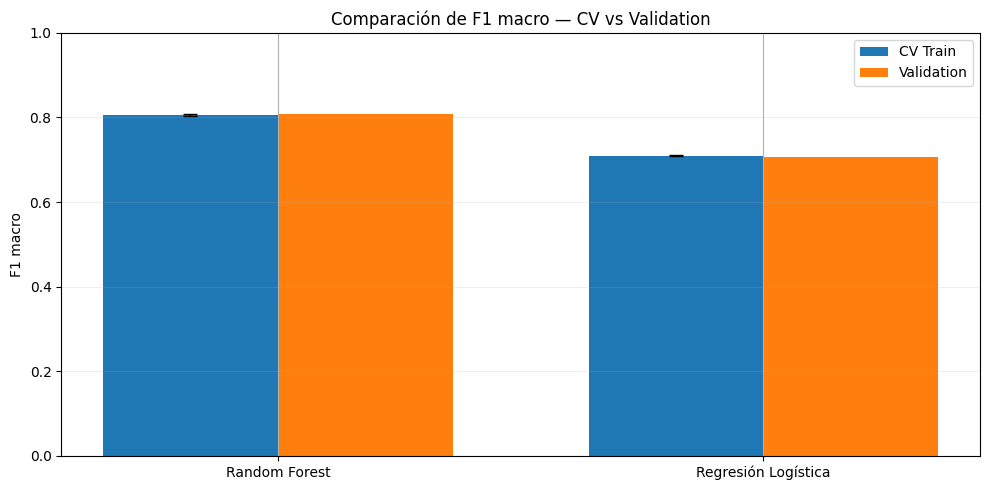

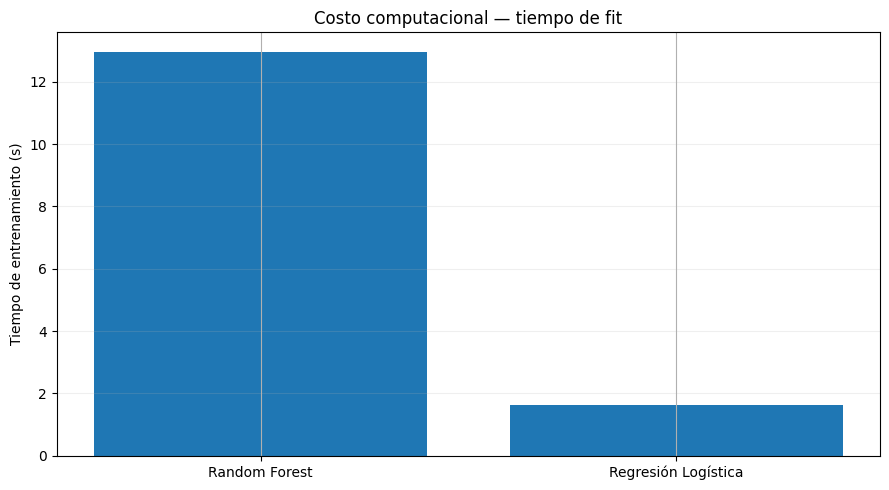


LÍDER PROVISIONAL — NO ES EL CAMPEÓN FINAL
Modelo             : Random Forest
F1 macro Validation: 0.8092

La selección definitiva se realizará en 6.10.

CONTROL FINAL — 6.7
✅ Modelo interpretable evaluado: Regresión Logística.
✅ Modelo flexible evaluado: Random Forest.
✅ Ambos utilizan exactamente el mismo preprocessor.
✅ Validación cruzada ejecutada solo sobre Train.
✅ CV estratificada configurada con 3 folds.
✅ Performance sobre Validation calculada.
✅ Estabilidad mediante desviación de CV calculada.
✅ Brecha CV-Validation calculada.
✅ Tiempo de entrenamiento medido.
✅ Tiempo de inferencia medido.
✅ Tamaño aproximado del Pipeline calculado.
✅ Interpretabilidad comparada.
✅ Baseline incorporado como referencia.
✅ Test permanece aislado.
✅ Se identificó únicamente un líder provisional.
✅ 6.7 — COMPARACIÓN DE MODELOS COMPLETADA


In [ ]:
# ============================================================
# FASE 2 — MODELADO SIN FUGA DE DATOS
# 6.7 COMPARACIÓN DE MODELOS
# ============================================================
#
# MODELOS
# ------------------------------------------------------------
#
# Modelo interpretable:
#     LogisticRegression
#
# Modelo flexible:
#     RandomForestClassifier
#
# REFERENCIA:
#     DummyClassifier de 6.4
#
# CRITERIOS
# ------------------------------------------------------------
#
# 1. Performance en Validation.
# 2. Estabilidad mediante CV estratificada sobre Train.
# 3. Interpretabilidad.
# 4. Tiempo de entrenamiento.
# 5. Tiempo de inferencia.
# 6. Tamaño serializado del Pipeline.
#
# IMPORTANTE
# ------------------------------------------------------------
#
# - CV utiliza exclusivamente Train.
# - El fit final utiliza exclusivamente Train.
# - Validation solo se utiliza para comparación.
# - Test permanece completamente aislado.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import time
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

from IPython.display import display


# ============================================================
# 2. CONFIGURACIÓN GENERAL
# ============================================================

RANDOM_STATE = globals().get(
    "RANDOM_STATE",
    42
)


N_FOLDS_CV = 3


# ============================================================
# 3. VERIFICAR OBJETOS PREVIOS
# ============================================================

objetos_requeridos = [
    "preprocessor",
    "X_train",
    "X_val",
    "y_train",
    "y_val"
]


objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]


if objetos_faltantes:

    raise NameError(
        "Faltan objetos necesarios para 6.7: "
        f"{objetos_faltantes}"
    )


# ============================================================
# 4. CONTROLES DE CONSISTENCIA
# ============================================================

assert (
    len(X_train)
    ==
    len(y_train)
), (
    "X_train e y_train poseen tamaños diferentes."
)


assert (
    len(X_val)
    ==
    len(y_val)
), (
    "X_val e y_val poseen tamaños diferentes."
)


assert (
    list(X_train.columns)
    ==
    list(X_val.columns)
), (
    "Train y Validation poseen diferentes columnas."
)


assert (
    X_train.shape[1]
    == 15
), (
    "Se esperaban 15 features de entrada."
)


# ============================================================
# 5. DEFINIR LOS DOS MODELOS
# ============================================================
#
# Se utilizan configuraciones iniciales moderadas.
#
# No se realiza todavía una búsqueda extensa de
# hiperparámetros.
#
# ============================================================

modelo_logistico = LogisticRegression(
    solver="lbfgs",
    max_iter=3000,
    C=1.0,
    class_weight=None,
    random_state=RANDOM_STATE
)


modelo_random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)


# ============================================================
# 6. CONSTRUIR PIPELINES COMPARABLES
# ============================================================
#
# Ambos reciben exactamente:
#
#     el mismo preprocessor
#     las mismas features
#     los mismos Train/Validation
#
# La única diferencia es el estimador.
#
# ============================================================

pipeline_logistico_6_7 = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "model",
            modelo_logistico
        )
    ]
)


pipeline_random_forest_6_7 = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "model",
            modelo_random_forest
        )
    ]
)


modelos_6_7 = {
    "Regresión Logística": (
        pipeline_logistico_6_7
    ),

    "Random Forest": (
        pipeline_random_forest_6_7
    )
}


# ============================================================
# 7. VALIDACIÓN CRUZADA ESTRATIFICADA
# ============================================================
#
# La CV ocurre SOLAMENTE dentro de Train.
#
# Cada iteración realiza automáticamente:
#
# Fold Train
#      |
#      v
# fit preprocessor
#      |
#      v
# fit model
#
# Fold Validation interno
#      |
#      v
# transform + predict
#
# Esto evita leakage entre folds.
#
# ============================================================

cv_estratificada = StratifiedKFold(
    n_splits=N_FOLDS_CV,
    shuffle=True,
    random_state=RANDOM_STATE
)


metricas_cv = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "balanced_accuracy": "balanced_accuracy"
}


# ============================================================
# 8. FUNCIÓN DE EVALUACIÓN
# ============================================================

def evaluar_modelo_6_7(
    nombre_modelo,
    pipeline_modelo
):
    """
    Evalúa un Pipeline completo utilizando:

    1. CV estratificada exclusivamente sobre Train.
    2. Fit final exclusivamente sobre Train.
    3. Evaluación sobre Validation.
    4. Tiempo de entrenamiento.
    5. Tiempo de inferencia.
    6. Tamaño aproximado serializado.

    Test no participa.
    """

    # ========================================================
    # A. VALIDACIÓN CRUZADA — SOLO TRAIN
    # ========================================================

    resultados_cv = cross_validate(
        estimator=clone(
            pipeline_modelo
        ),

        X=X_train,
        y=y_train,

        cv=cv_estratificada,

        scoring=metricas_cv,

        return_train_score=False,

        n_jobs=1
    )


    cv_accuracy_mean = float(
        np.mean(
            resultados_cv[
                "test_accuracy"
            ]
        )
    )


    cv_accuracy_std = float(
        np.std(
            resultados_cv[
                "test_accuracy"
            ],
            ddof=1
        )
    )


    cv_f1_macro_mean = float(
        np.mean(
            resultados_cv[
                "test_f1_macro"
            ]
        )
    )


    cv_f1_macro_std = float(
        np.std(
            resultados_cv[
                "test_f1_macro"
            ],
            ddof=1
        )
    )


    cv_balanced_mean = float(
        np.mean(
            resultados_cv[
                "test_balanced_accuracy"
            ]
        )
    )


    cv_balanced_std = float(
        np.std(
            resultados_cv[
                "test_balanced_accuracy"
            ],
            ddof=1
        )
    )


    # ========================================================
    # B. CLON LIMPIO PARA FIT FINAL SOBRE TODO TRAIN
    # ========================================================

    pipeline_fit = clone(
        pipeline_modelo
    )


    inicio_fit = time.perf_counter()


    pipeline_fit.fit(
        X_train,
        y_train
    )


    tiempo_fit = (
        time.perf_counter()
        -
        inicio_fit
    )


    # ========================================================
    # C. PREDICCIÓN SOBRE VALIDATION
    # ========================================================

    inicio_pred = time.perf_counter()


    y_pred = pipeline_fit.predict(
        X_val
    )


    tiempo_pred = (
        time.perf_counter()
        -
        inicio_pred
    )


    # ========================================================
    # D. MÉTRICAS VALIDATION
    # ========================================================

    accuracy = accuracy_score(
        y_val,
        y_pred
    )


    precision_macro = precision_score(
        y_val,
        y_pred,
        average="macro",
        zero_division=0
    )


    recall_macro = recall_score(
        y_val,
        y_pred,
        average="macro",
        zero_division=0
    )


    f1_macro = f1_score(
        y_val,
        y_pred,
        average="macro",
        zero_division=0
    )


    f1_weighted = f1_score(
        y_val,
        y_pred,
        average="weighted",
        zero_division=0
    )


    balanced_accuracy = (
        balanced_accuracy_score(
            y_val,
            y_pred
        )
    )


    # ========================================================
    # E. BRECHA CV VS VALIDATION
    # ========================================================

    brecha_f1 = abs(
        f1_macro
        -
        cv_f1_macro_mean
    )


    # ========================================================
    # F. VELOCIDAD POR OBSERVACIÓN
    # ========================================================

    tiempo_pred_ms_obs = (
        1000.0
        *
        tiempo_pred
        /
        len(X_val)
    )


    # ========================================================
    # G. TAMAÑO SERIALIZADO APROXIMADO
    # ========================================================
    #
    # Se utiliza pickle solo para ESTIMAR tamaño en memoria.
    #
    # El empaquetado oficial mediante joblib corresponde
    # posteriormente a 6.11.
    #
    # ========================================================

    modelo_bytes = pickle.dumps(
        pipeline_fit
    )


    tamano_mb = (
        len(modelo_bytes)
        /
        (
            1024 ** 2
        )
    )


    # ========================================================
    # H. RESULTADO
    # ========================================================

    resultado = {
        "Modelo": nombre_modelo,

        "CV Accuracy media": (
            cv_accuracy_mean
        ),

        "CV Accuracy std": (
            cv_accuracy_std
        ),

        "CV F1 macro media": (
            cv_f1_macro_mean
        ),

        "CV F1 macro std": (
            cv_f1_macro_std
        ),

        "CV Balanced Acc media": (
            cv_balanced_mean
        ),

        "CV Balanced Acc std": (
            cv_balanced_std
        ),

        "Validation Accuracy": (
            accuracy
        ),

        "Validation Precision macro": (
            precision_macro
        ),

        "Validation Recall macro": (
            recall_macro
        ),

        "Validation F1 macro": (
            f1_macro
        ),

        "Validation F1 weighted": (
            f1_weighted
        ),

        "Validation Balanced Accuracy": (
            balanced_accuracy
        ),

        "|F1 val - F1 CV|": (
            brecha_f1
        ),

        "Tiempo fit (s)": (
            tiempo_fit
        ),

        "Tiempo pred Val (s)": (
            tiempo_pred
        ),

        "Predicción ms/obs": (
            tiempo_pred_ms_obs
        ),

        "Tamaño Pipeline (MB)": (
            tamano_mb
        )
    }


    return (
        resultado,
        pipeline_fit,
        y_pred,
        resultados_cv
    )


# ============================================================
# 9. EVALUAR LOS DOS MODELOS
# ============================================================

resultados_modelos_6_7 = []

pipelines_ajustados_6_7 = {}

predicciones_modelos_6_7 = {}

cv_detalle_modelos_6_7 = {}


for nombre, pipeline_modelo in modelos_6_7.items():

    print(
        "\n" + "=" * 110
    )

    print(
        f"EVALUANDO: {nombre}"
    )

    print(
        "=" * 110
    )


    (
        resultado,
        pipeline_ajustado,
        predicciones,
        resultados_cv
    ) = evaluar_modelo_6_7(
        nombre_modelo=nombre,
        pipeline_modelo=pipeline_modelo
    )


    resultados_modelos_6_7.append(
        resultado
    )


    pipelines_ajustados_6_7[
        nombre
    ] = pipeline_ajustado


    predicciones_modelos_6_7[
        nombre
    ] = predicciones


    cv_detalle_modelos_6_7[
        nombre
    ] = resultados_cv


    print(
        f"CV F1 macro : "
        f"{resultado['CV F1 macro media']:.4f} "
        f"± {resultado['CV F1 macro std']:.4f}"
    )


    print(
        f"Val F1 macro: "
        f"{resultado['Validation F1 macro']:.4f}"
    )


    print(
        f"Fit         : "
        f"{resultado['Tiempo fit (s)']:.3f} s"
    )


# ============================================================
# 10. TABLA COMPARATIVA DE LOS DOS MODELOS
# ============================================================

df_comparacion_modelos_6_7 = (
    pd.DataFrame(
        resultados_modelos_6_7
    )
    .sort_values(
        by=[
            "Validation F1 macro",
            "Validation Balanced Accuracy"
        ],
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 110)
print("COMPARACIÓN DE MODELOS — 6.7")
print("=" * 110)


display(
    df_comparacion_modelos_6_7.style.format(
        {
            "CV Accuracy media": "{:.4f}",
            "CV Accuracy std": "{:.4f}",
            "CV F1 macro media": "{:.4f}",
            "CV F1 macro std": "{:.4f}",
            "CV Balanced Acc media": "{:.4f}",
            "CV Balanced Acc std": "{:.4f}",
            "Validation Accuracy": "{:.4f}",
            "Validation Precision macro": "{:.4f}",
            "Validation Recall macro": "{:.4f}",
            "Validation F1 macro": "{:.4f}",
            "Validation F1 weighted": "{:.4f}",
            "Validation Balanced Accuracy": "{:.4f}",
            "|F1 val - F1 CV|": "{:.4f}",
            "Tiempo fit (s)": "{:.4f}",
            "Tiempo pred Val (s)": "{:.4f}",
            "Predicción ms/obs": "{:.6f}",
            "Tamaño Pipeline (MB)": "{:.4f}"
        }
    )
)


# ============================================================
# 11. INCORPORAR BASELINE COMO REFERENCIA
# ============================================================
#
# El baseline no participa en la selección entre los dos
# modelos reales, pero permite cuantificar valor agregado.
#
# ============================================================

if "df_resultados_baseline" in globals():

    baseline_row = pd.DataFrame(
        {
            "Modelo": [
                "Baseline — most_frequent"
            ],

            "Validation Accuracy": [
                float(
                    df_resultados_baseline[
                        "Accuracy"
                    ].iloc[0]
                )
            ],

            "Validation Precision macro": [
                float(
                    df_resultados_baseline[
                        "Precision macro"
                    ].iloc[0]
                )
            ],

            "Validation Recall macro": [
                float(
                    df_resultados_baseline[
                        "Recall macro"
                    ].iloc[0]
                )
            ],

            "Validation F1 macro": [
                float(
                    df_resultados_baseline[
                        "F1 macro"
                    ].iloc[0]
                )
            ],

            "Validation F1 weighted": [
                float(
                    df_resultados_baseline[
                        "F1 weighted"
                    ].iloc[0]
                )
            ],

            "Validation Balanced Accuracy": [
                float(
                    df_resultados_baseline[
                        "Balanced Accuracy"
                    ].iloc[0]
                )
            ]
        }
    )


    columnas_resumen = [
        "Modelo",
        "Validation Accuracy",
        "Validation Precision macro",
        "Validation Recall macro",
        "Validation F1 macro",
        "Validation F1 weighted",
        "Validation Balanced Accuracy"
    ]


    df_resumen_con_baseline_6_7 = pd.concat(
        [
            baseline_row[
                columnas_resumen
            ],

            df_comparacion_modelos_6_7[
                columnas_resumen
            ]
        ],

        ignore_index=True
    )


    print(
        "\n" + "=" * 110
    )

    print(
        "BASELINE VS MODELOS REALES"
    )

    print(
        "=" * 110
    )


    display(
        df_resumen_con_baseline_6_7.style.format(
            {
                "Validation Accuracy": "{:.4f}",
                "Validation Precision macro": "{:.4f}",
                "Validation Recall macro": "{:.4f}",
                "Validation F1 macro": "{:.4f}",
                "Validation F1 weighted": "{:.4f}",
                "Validation Balanced Accuracy": "{:.4f}"
            }
        )
    )


# ============================================================
# 12. VALOR AGREGADO RESPECTO DEL BASELINE
# ============================================================

if "df_resultados_baseline" in globals():

    f1_baseline_6_7 = float(
        df_resultados_baseline[
            "F1 macro"
        ].iloc[0]
    )


    balanced_baseline_6_7 = float(
        df_resultados_baseline[
            "Balanced Accuracy"
        ].iloc[0]
    )


    df_valor_agregado_6_7 = (
        df_comparacion_modelos_6_7[
            [
                "Modelo",
                "Validation F1 macro",
                "Validation Balanced Accuracy"
            ]
        ]
        .copy()
    )


    df_valor_agregado_6_7[
        "Δ F1 macro vs baseline"
    ] = (
        df_valor_agregado_6_7[
            "Validation F1 macro"
        ]
        -
        f1_baseline_6_7
    )


    df_valor_agregado_6_7[
        "Δ Balanced Acc vs baseline"
    ] = (
        df_valor_agregado_6_7[
            "Validation Balanced Accuracy"
        ]
        -
        balanced_baseline_6_7
    )


    print(
        "\n" + "=" * 110
    )

    print(
        "VALOR AGREGADO RESPECTO DEL BASELINE"
    )

    print(
        "=" * 110
    )


    display(
        df_valor_agregado_6_7.style.format(
            {
                "Validation F1 macro": "{:.4f}",
                "Validation Balanced Accuracy": "{:.4f}",
                "Δ F1 macro vs baseline": "{:+.4f}",
                "Δ Balanced Acc vs baseline": "{:+.4f}"
            }
        )
    )


# ============================================================
# 13. TABLA CUALITATIVA
# ============================================================

df_comparacion_cualitativa_6_7 = pd.DataFrame(
    {
        "Modelo": [
            "Regresión Logística",
            "Random Forest"
        ],

        "Flexibilidad": [
            "Baja-Media",
            "Alta"
        ],

        "Interpretabilidad": [
            "Alta",
            "Media"
        ],

        "Interpretación disponible": [
            "Coeficientes",
            "Feature importance"
        ],

        "Complejidad computacional esperada": [
            "Baja",
            "Media"
        ],

        "predict_proba": [
            "Sí",
            "Sí"
        ],

        "Uso futuro en 6.9": [
            "Analizar coeficientes",
            "Analizar feature importance"
        ]
    }
)


print("\n" + "=" * 110)
print("COMPARACIÓN CUALITATIVA")
print("=" * 110)


display(
    df_comparacion_cualitativa_6_7
)


# ============================================================
# 14. VISUALIZACIÓN — F1 MACRO
# ============================================================

df_plot_f1 = (
    df_comparacion_modelos_6_7[
        [
            "Modelo",
            "CV F1 macro media",
            "CV F1 macro std",
            "Validation F1 macro"
        ]
    ]
    .copy()
)


x = np.arange(
    len(df_plot_f1)
)


ancho = 0.36


plt.figure(
    figsize=(10, 5)
)


plt.bar(
    x - ancho / 2,
    df_plot_f1[
        "CV F1 macro media"
    ],
    width=ancho,
    yerr=df_plot_f1[
        "CV F1 macro std"
    ],
    capsize=5,
    label="CV Train"
)


plt.bar(
    x + ancho / 2,
    df_plot_f1[
        "Validation F1 macro"
    ],
    width=ancho,
    label="Validation"
)


plt.xticks(
    x,
    df_plot_f1[
        "Modelo"
    ]
)


plt.ylabel(
    "F1 macro"
)


plt.title(
    "Comparación de F1 macro — CV vs Validation"
)


plt.ylim(
    0,
    1
)


plt.grid(
    axis="y",
    alpha=0.20
)


plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 15. VISUALIZACIÓN — COSTO COMPUTACIONAL
# ============================================================

plt.figure(
    figsize=(9, 5)
)


plt.bar(
    df_comparacion_modelos_6_7[
        "Modelo"
    ],
    df_comparacion_modelos_6_7[
        "Tiempo fit (s)"
    ]
)


plt.ylabel(
    "Tiempo de entrenamiento (s)"
)


plt.title(
    "Costo computacional — tiempo de fit"
)


plt.grid(
    axis="y",
    alpha=0.20
)


plt.tight_layout()

plt.show()


# ============================================================
# 16. LÍDER PROVISIONAL
# ============================================================
#
# NO representa todavía el campeón definitivo.
#
# Se ordena únicamente por:
#
# 1. F1 macro Validation.
# 2. Balanced Accuracy Validation.
#
# La selección formal corresponde a 6.10.
#
# ============================================================

LIDER_PROVISIONAL_6_7 = (
    df_comparacion_modelos_6_7
    .iloc[0][
        "Modelo"
    ]
)


F1_LIDER_PROVISIONAL_6_7 = float(
    df_comparacion_modelos_6_7
    .iloc[0][
        "Validation F1 macro"
    ]
)


print("\n" + "=" * 110)
print("LÍDER PROVISIONAL — NO ES EL CAMPEÓN FINAL")
print("=" * 110)


print(
    f"Modelo             : "
    f"{LIDER_PROVISIONAL_6_7}"
)


print(
    f"F1 macro Validation: "
    f"{F1_LIDER_PROVISIONAL_6_7:.4f}"
)


print(
    "\nLa selección definitiva se realizará en 6.10."
)


# ============================================================
# 17. GUARDAR REFERENCIAS A LOS PIPELINES
# ============================================================

pipeline_logistico_comparacion = (
    pipelines_ajustados_6_7[
        "Regresión Logística"
    ]
)


pipeline_random_forest_comparacion = (
    pipelines_ajustados_6_7[
        "Random Forest"
    ]
)


# ============================================================
# 18. CONTROLES AUTOMÁTICOS
# ============================================================

assert (
    set(
        pipelines_ajustados_6_7.keys()
    )
    ==
    {
        "Regresión Logística",
        "Random Forest"
    }
)


assert all(
    0.0
    <= valor
    <= 1.0
    for valor
    in df_comparacion_modelos_6_7[
        "Validation F1 macro"
    ]
)


assert all(
    0.0
    <= valor
    <= 1.0
    for valor
    in df_comparacion_modelos_6_7[
        "Validation Balanced Accuracy"
    ]
)


assert all(
    valor >= 0
    for valor
    in df_comparacion_modelos_6_7[
        "CV F1 macro std"
    ]
)


assert all(
    valor > 0
    for valor
    in df_comparacion_modelos_6_7[
        "Tamaño Pipeline (MB)"
    ]
)


# ============================================================
# 19. VERIFICAR QUE TEST NO PARTICIPÓ
# ============================================================
#
# El código anterior solo utiliza explícitamente:
#
#     X_train
#     y_train
#     X_val
#     y_val
#
# X_test / y_test permanecen reservados.
#
# ============================================================


# ============================================================
# 20. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 110)
print("CONTROL FINAL — 6.7")
print("=" * 110)


print(
    "✅ Modelo interpretable evaluado: "
    "Regresión Logística."
)


print(
    "✅ Modelo flexible evaluado: Random Forest."
)


print(
    "✅ Ambos utilizan exactamente el mismo preprocessor."
)


print(
    "✅ Validación cruzada ejecutada solo sobre Train."
)


print(
    "✅ CV estratificada configurada con 3 folds."
)


print(
    "✅ Performance sobre Validation calculada."
)


print(
    "✅ Estabilidad mediante desviación de CV calculada."
)


print(
    "✅ Brecha CV-Validation calculada."
)


print(
    "✅ Tiempo de entrenamiento medido."
)


print(
    "✅ Tiempo de inferencia medido."
)


print(
    "✅ Tamaño aproximado del Pipeline calculado."
)


print(
    "✅ Interpretabilidad comparada."
)


print(
    "✅ Baseline incorporado como referencia."
)


print(
    "✅ Test permanece aislado."
)


print(
    "✅ Se identificó únicamente un líder provisional."
)


print("=" * 110)

print(
    "✅ 6.7 — COMPARACIÓN DE MODELOS COMPLETADA"
)

## 6.7.14 Interpretación técnica de la comparación

La comparación se realizó utilizando exactamente.

## Modelo interpretable

La Regresión Logística representa la alternativa de mayor interpretabilidad.

## Modelo flexible

Random Forest introduce una estructura no lineal compuesta por múltiples árboles.

## Estabilidad

La estabilidad fue evaluada mediante validación cruzada estratificada exclusivamente.

## Performance

La métrica principal utilizada para comparar los modelos es.

## Valor agregado frente al baseline

Esta sección resume valor agregado frente al baseline y su función dentro del proyecto MLOps.

## Costo computacional

permite aproximar el costo de una inferencia individual.

## Tamaño del modelo

También se estimó el tamaño del Pipeline serializado.

## Interpretabilidad

Esta sección resume interpretabilidad y su función dentro del proyecto MLOps.

## Regla de decisión provisional

En esta sección se permite identificar un.

## Protección del conjunto Test

Esta sección resume protección del conjunto Test y su función dentro del proyecto MLOps.

## Conclusión de 6.7

La comparación permite evaluar dos estrategias complementarias.


## 6.8 Validación y métricas — Clasificación

La evaluación del modelo debe cuantificar no solamente cuántas observaciones fueron.

## 6.8.1 Accuracy

La Accuracy representa la proporción total de predicciones correctas.

## 6.8.2 Precision

Esta sección resume precision y su función dentro del proyecto MLOps.

## 6.8.3 Recall

De todas las observaciones que realmente pertenecían a una clase, ¿qué proporción.

## 6.8.4 F1-score

El F1-score combina Precision y Recall mediante su media armónica.

## 6.8.5 Balanced Accuracy

Como métrica complementaria se conservará la Balanced Accuracy.

## 6.8.6 Curva ROC

La curva ROC representa la relación entre.

## 6.8.7 ROC-AUC

El área bajo la curva ROC se define como.

## 6.8.8 ROC-AUC multiclase

Esta sección resume rOC-AUC multiclase y su función dentro del proyecto MLOps.

## 6.8.9 Matriz de confusión

clases, la matriz de confusión queda definida como.

## 6.8.10 Matriz de confusión normalizada

Debido a que las clases tienen diferentes tamaños, se utilizará también una matriz.

## 6.8.11 Protocolo de evaluación

Esta sección resume protocolo de evaluación y su función dentro del proyecto MLOps.


6.8 — VALIDACIÓN Y MÉTRICAS DE CLASIFICACIÓN
Observaciones Validation : 2,722
Número de clases         : 10
Modelos a evaluar        : 2
  ✅ Regresión Logística
  ✅ Random Forest

EVALUACIÓN — Regresión Logística

Precision, Recall y F1 por clase:


,precision,recall,f1-score,support
Tomato___Bacterial_spot,0.8248,0.8558,0.8400,319
Tomato___Early_blight,0.6696,0.5133,0.5811,150
Tomato___Late_blight,0.6781,0.5544,0.6100,285
Tomato___Leaf_Mold,0.7500,0.4196,0.5381,143
Tomato___Septoria_leaf_spot,0.7154,0.7208,0.7180,265
Tomato___Spider_mites Two-spotted_spider_mite,0.5862,0.6071,0.5965,252
Tomato___Target_Spot,0.6078,0.6714,0.6380,210
Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.8027,0.8955,0.8466,804
Tomato___Tomato_mosaic_virus,0.7458,0.7857,0.7652,56
Tomato___healthy,0.9150,0.9496,0.9320,238


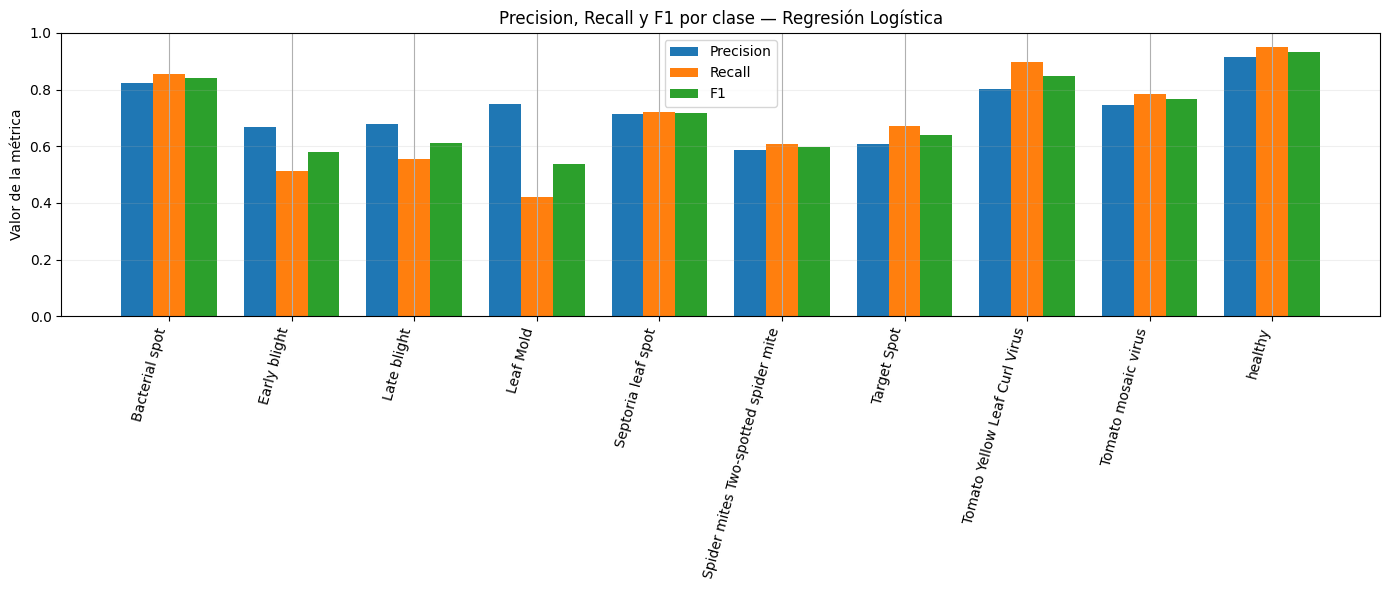

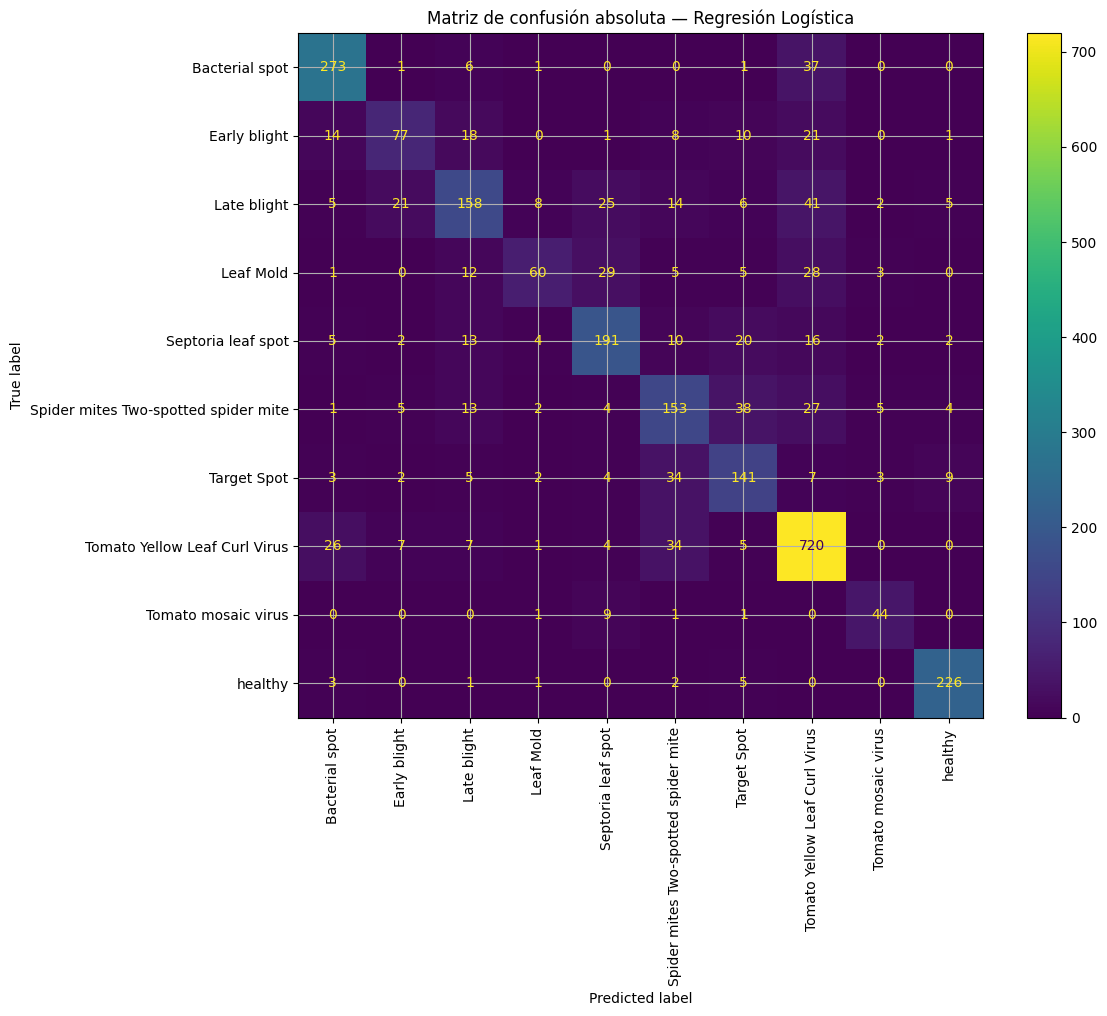

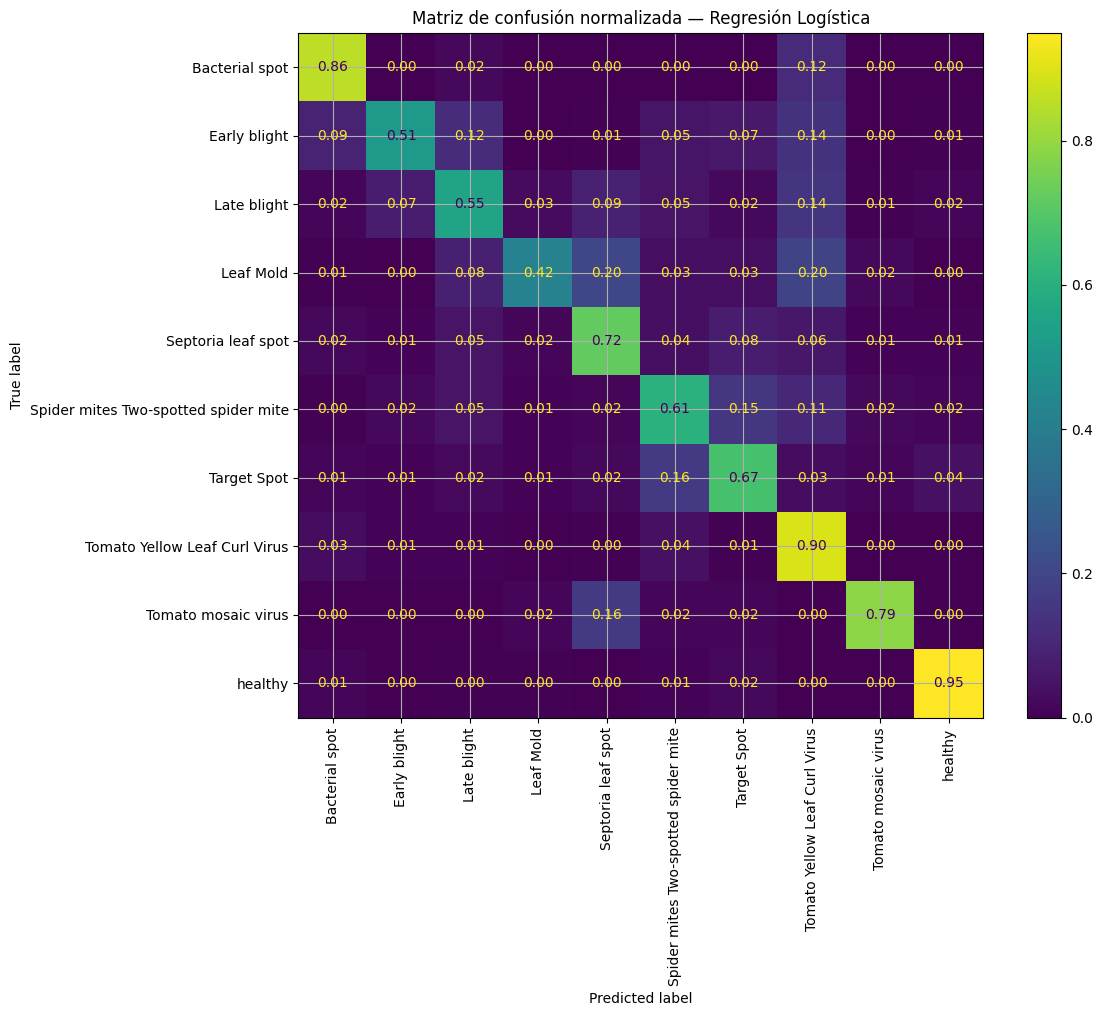

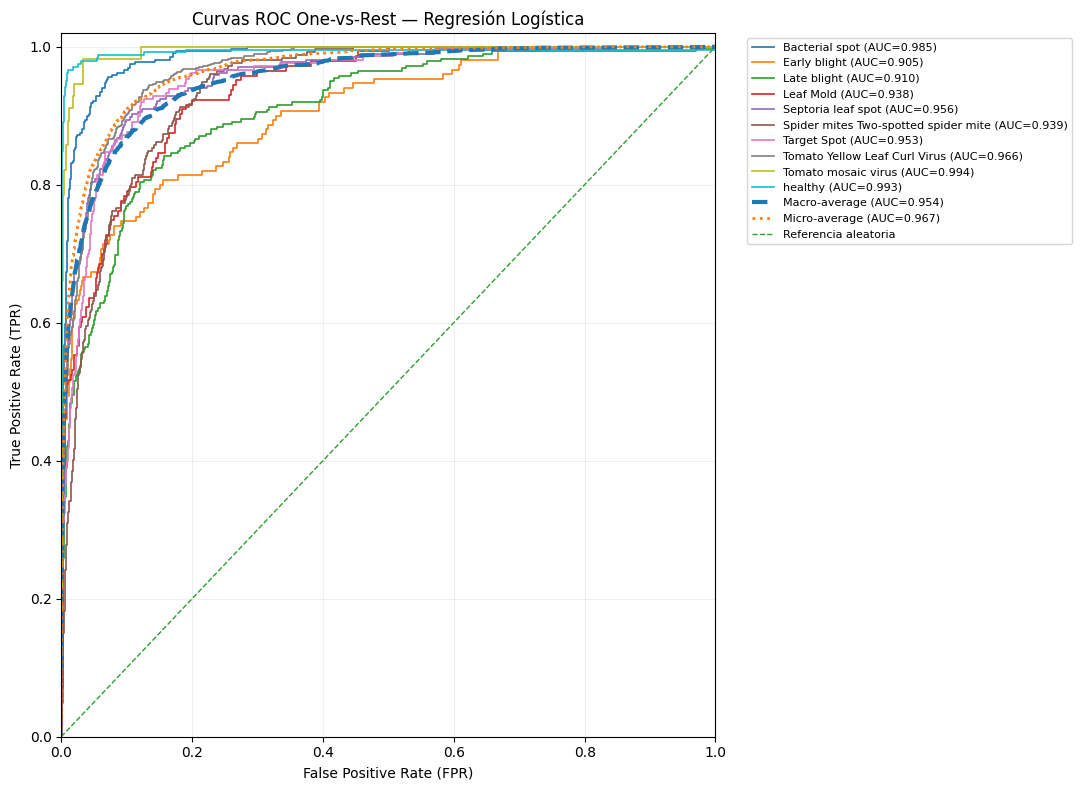


ROC-AUC One-vs-Rest por clase:


,Clase,ROC-AUC OvR,Support
0,Tomato___Bacterial_spot,0.9851,319
1,Tomato___Early_blight,0.9049,150
2,Tomato___Late_blight,0.9101,285
3,Tomato___Leaf_Mold,0.9378,143
4,Tomato___Septoria_leaf_spot,0.9562,265
5,Tomato___Spider_mites Two-spotted_spider_mite,0.9394,252
6,Tomato___Target_Spot,0.9531,210
7,Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.9661,804
8,Tomato___Tomato_mosaic_virus,0.9943,56
9,Tomato___healthy,0.9928,238



EVALUACIÓN — Random Forest

Precision, Recall y F1 por clase:


,precision,recall,f1-score,support
Tomato___Bacterial_spot,0.8791,0.9342,0.9058,319
Tomato___Early_blight,0.6981,0.4933,0.5781,150
Tomato___Late_blight,0.7969,0.7298,0.7619,285
Tomato___Leaf_Mold,0.8320,0.7273,0.7761,143
Tomato___Septoria_leaf_spot,0.8364,0.8491,0.8427,265
Tomato___Spider_mites Two-spotted_spider_mite,0.7603,0.7302,0.7449,252
Tomato___Target_Spot,0.7277,0.8143,0.7685,210
Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.8828,0.9465,0.9136,804
Tomato___Tomato_mosaic_virus,0.9020,0.8214,0.8598,56
Tomato___healthy,0.9526,0.9286,0.9404,238


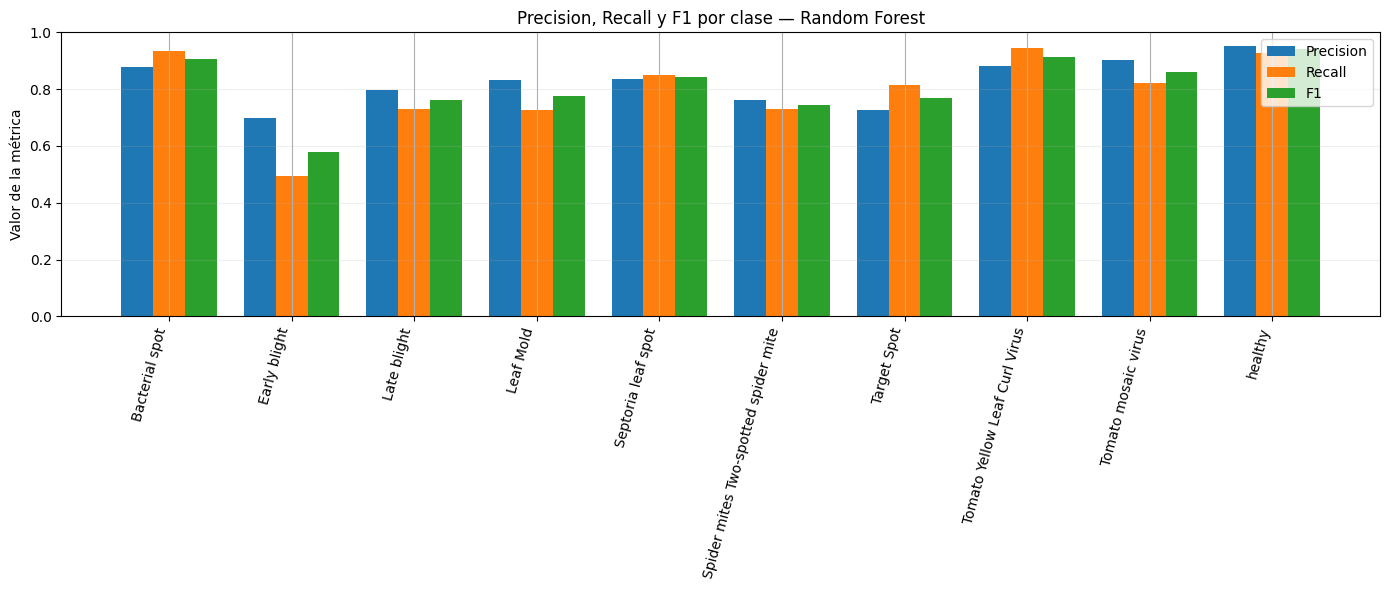

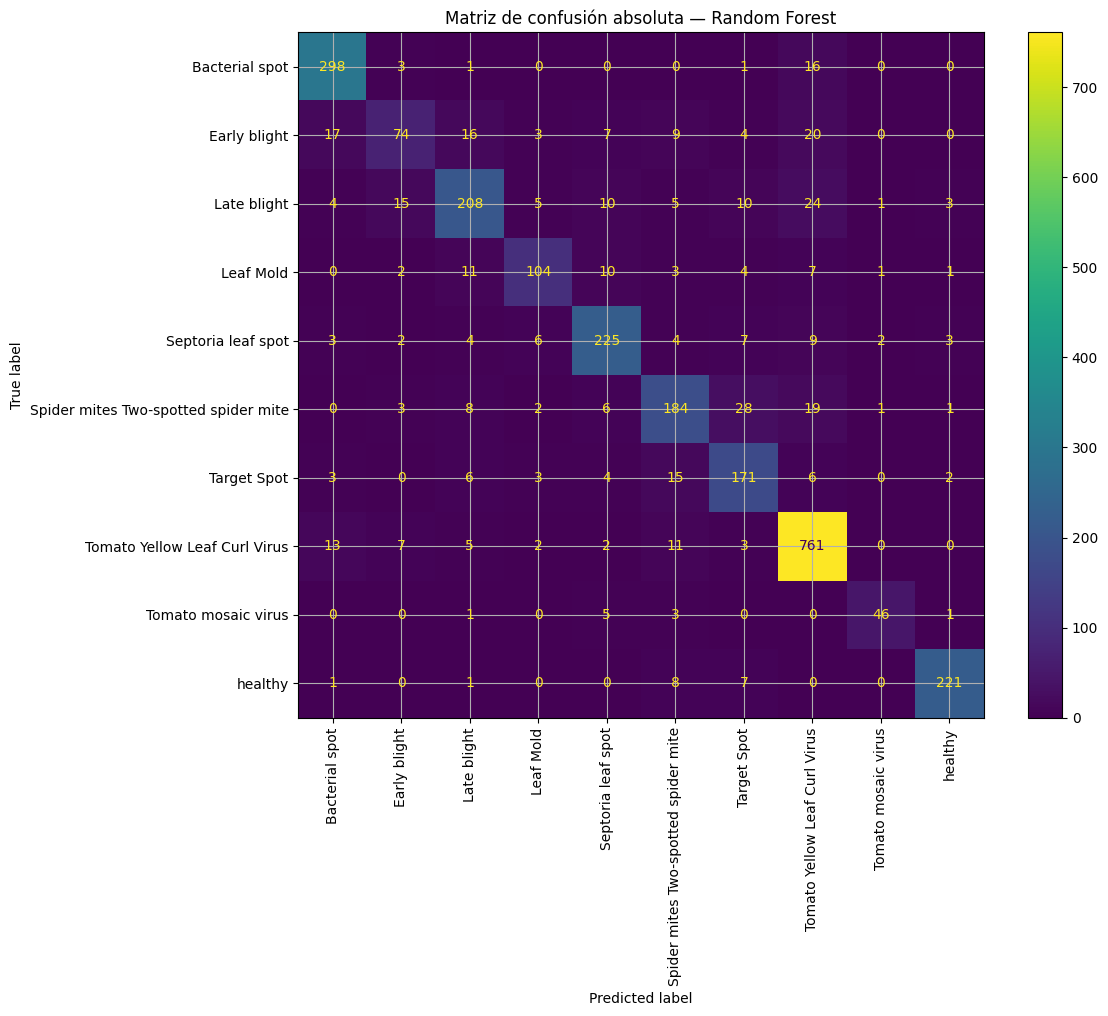

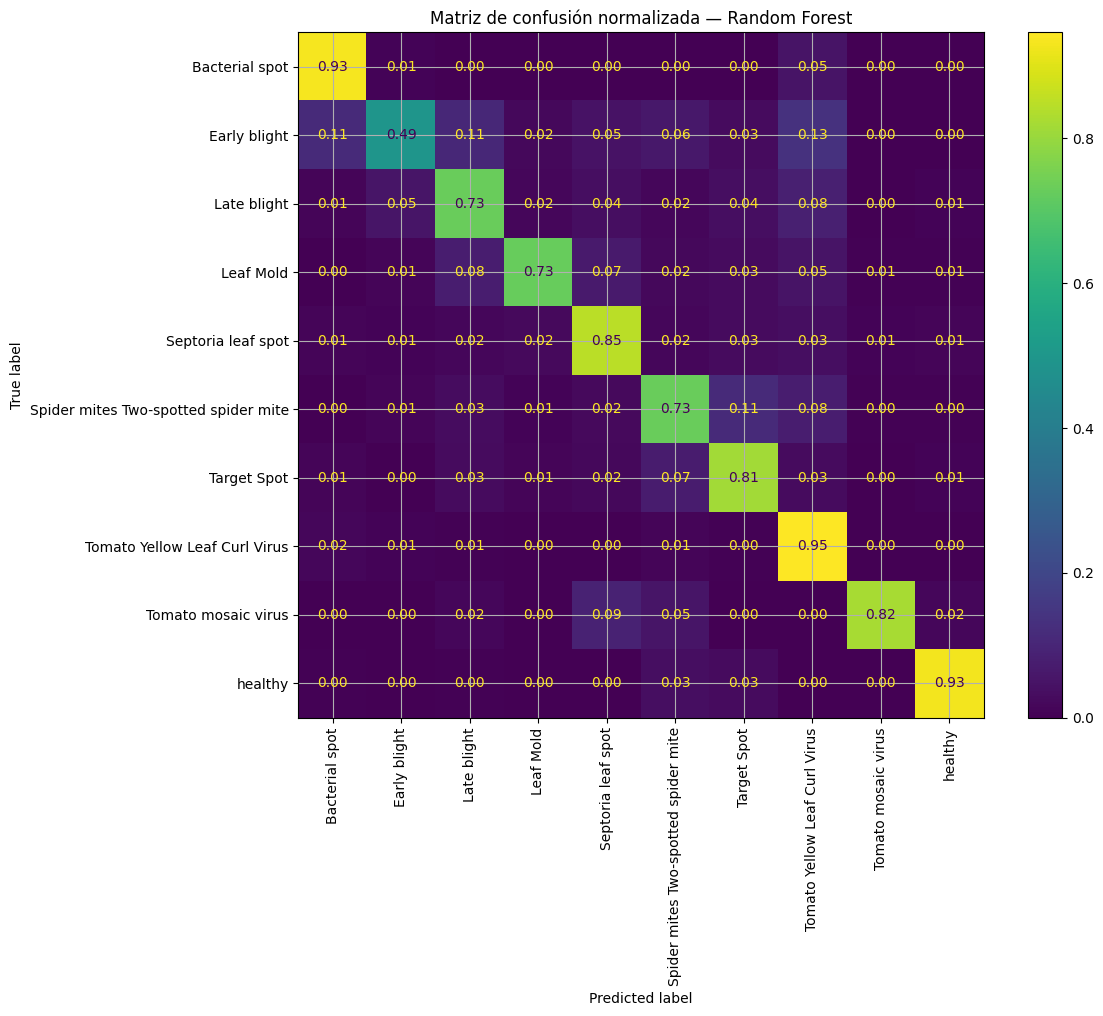

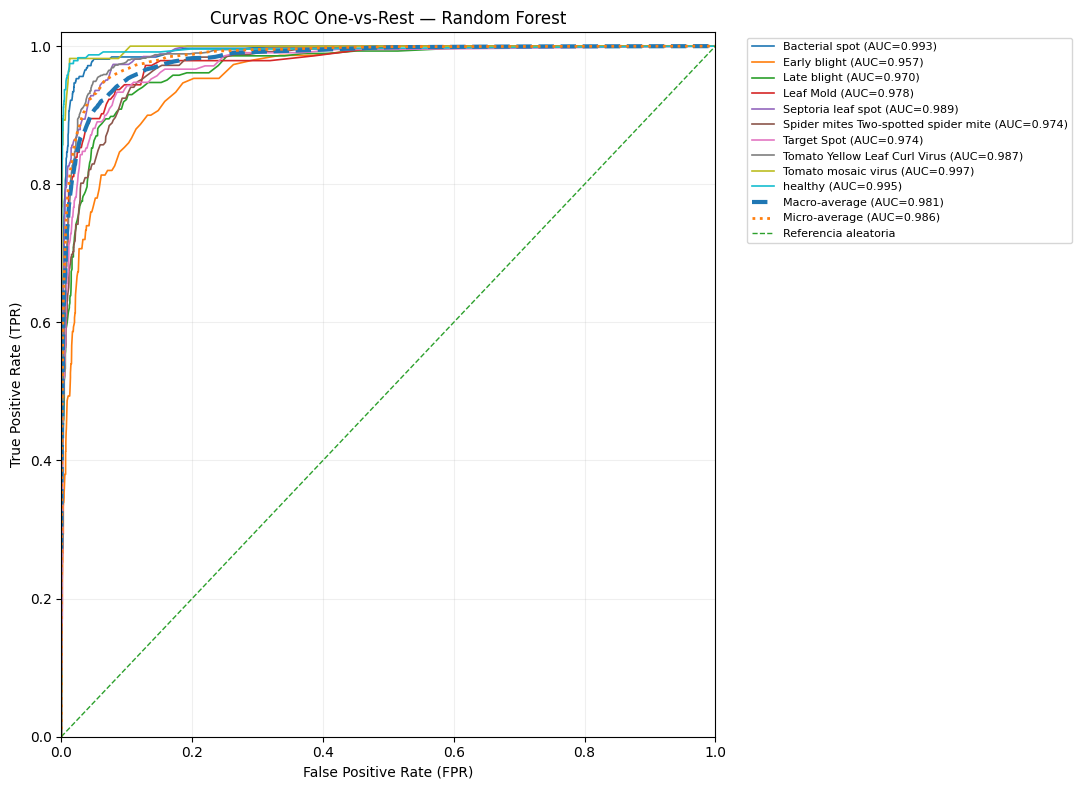


ROC-AUC One-vs-Rest por clase:


,Clase,ROC-AUC OvR,Support
0,Tomato___Bacterial_spot,0.9925,319
1,Tomato___Early_blight,0.9569,150
2,Tomato___Late_blight,0.9698,285
3,Tomato___Leaf_Mold,0.9781,143
4,Tomato___Septoria_leaf_spot,0.9889,265
5,Tomato___Spider_mites Two-spotted_spider_mite,0.9739,252
6,Tomato___Target_Spot,0.9743,210
7,Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.9870,804
8,Tomato___Tomato_mosaic_virus,0.9971,56
9,Tomato___healthy,0.9952,238



RESUMEN GLOBAL — VALIDATION


,Modelo,Accuracy,Precision macro,Recall macro,F1 macro,F1 weighted,Balanced Accuracy,ROC-AUC macro OvR,ROC-AUC weighted OvR
0,Random Forest,0.8420,0.8268,0.7975,0.8092,0.8386,0.7975,0.9814,0.9826
1,Regresión Logística,0.7506,0.7295,0.6973,0.7066,0.7442,0.6973,0.9540,0.9561


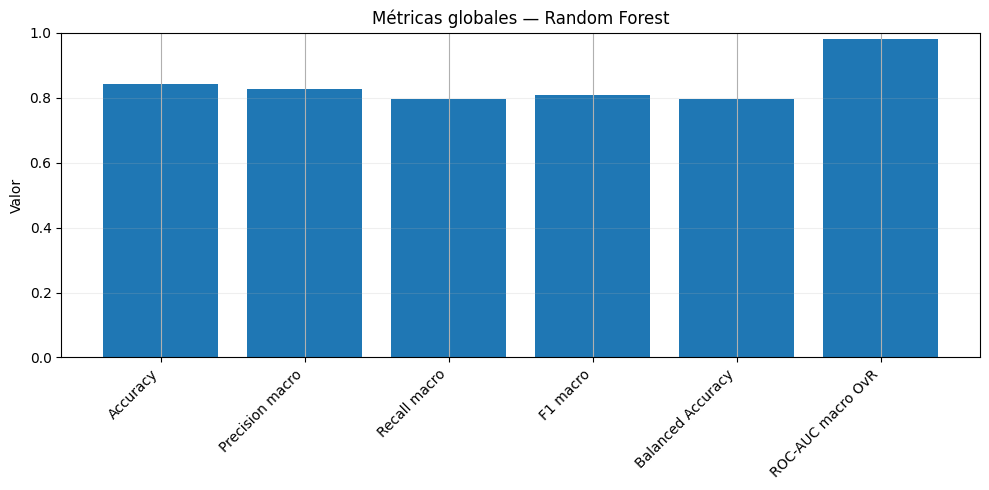

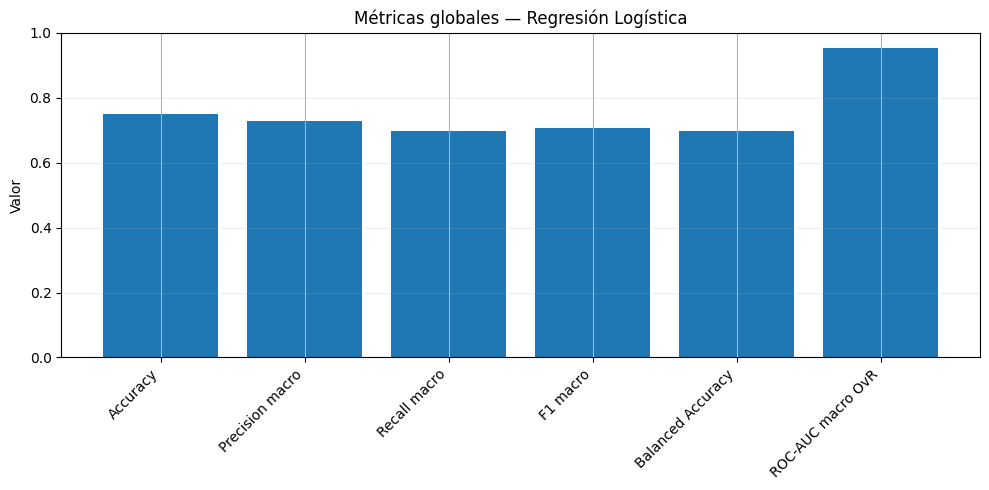


CLASE CON MENOR F1 POR MODELO


,Modelo,Clase con menor F1,Precision,Recall,F1,Support
0,Regresión Logística,Tomato___Leaf_Mold,0.7500,0.4196,0.5381,143
1,Random Forest,Tomato___Early_blight,0.6981,0.4933,0.5781,150



CONTROL FINAL — 6.8
✅ Accuracy calculada.
✅ Precision macro calculada.
✅ Recall macro calculado.
✅ F1 macro calculado.
✅ F1 weighted calculado.
✅ Balanced Accuracy calculada.
✅ ROC-AUC macro OvR calculado.
✅ ROC-AUC weighted OvR calculado.
✅ Precision / Recall / F1 por clase analizados.
✅ Matriz de confusión absoluta generada.
✅ Matriz de confusión normalizada generada.
✅ Curvas ROC por clase generadas.
✅ Clase con menor F1 identificada.
✅ Test permanece aislado.
✅ 6.8 — VALIDACIÓN Y MÉTRICAS COMPLETADA


In [ ]:
# ============================================================
# FASE 2 — MODELADO SIN FUGA DE DATOS
# 6.8 VALIDACIÓN Y MÉTRICAS — CLASIFICACIÓN
# ============================================================
#
# PROBLEMA:
#
#     Clasificación multiclase
#     Target : clase
#     K      : 10
#
# MÉTRICAS:
#
#     - Accuracy
#     - Precision macro
#     - Recall macro
#     - F1 macro
#     - F1 weighted
#     - Balanced Accuracy
#     - ROC-AUC macro OvR
#     - ROC-AUC weighted OvR
#
# GRÁFICOS:
#
#     1. Métricas globales.
#     2. Precision / Recall / F1 por clase.
#     3. Matriz de confusión absoluta.
#     4. Matriz de confusión normalizada.
#     5. Curvas ROC One-vs-Rest.
#
# IMPORTANTE:
#
#     - NO se realiza fit.
#     - Validation se utiliza únicamente para evaluación.
#     - Test permanece completamente aislado.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
    auc,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from IPython.display import display


# ============================================================
# 2. VERIFICAR VALIDATION
# ============================================================

objetos_requeridos = [
    "X_val",
    "y_val"
]


objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]


if objetos_faltantes:

    raise NameError(
        "Faltan objetos necesarios para 6.8: "
        f"{objetos_faltantes}"
    )


if len(X_val) != len(y_val):

    raise ValueError(
        "X_val e y_val poseen tamaños diferentes."
    )


# ============================================================
# 3. IDENTIFICAR MODELOS DISPONIBLES
# ============================================================
#
# Prioridad:
#
# 1. Pipelines ajustados en 6.7.
# 2. Pipeline de Regresión Logística de 6.6.
#
# ============================================================

modelos_6_8 = {}


if (
    "pipelines_ajustados_6_7"
    in globals()
    and isinstance(
        pipelines_ajustados_6_7,
        dict
    )
    and len(
        pipelines_ajustados_6_7
    ) > 0
):

    modelos_6_8.update(
        pipelines_ajustados_6_7
    )


elif "pipeline" in globals():

    modelos_6_8[
        "Regresión Logística"
    ] = pipeline


else:

    raise NameError(
        "No se encontró ningún Pipeline ajustado. "
        "Ejecute previamente 6.6 o 6.7."
    )


# ============================================================
# 4. INFORMACIÓN GENERAL
# ============================================================

N_VALIDATION_6_8 = len(
    y_val
)


N_CLASES_6_8 = int(
    pd.Series(
        y_val
    ).nunique()
)


print("=" * 110)
print("6.8 — VALIDACIÓN Y MÉTRICAS DE CLASIFICACIÓN")
print("=" * 110)


print(
    f"Observaciones Validation : "
    f"{N_VALIDATION_6_8:,}"
)


print(
    f"Número de clases         : "
    f"{N_CLASES_6_8}"
)


print(
    f"Modelos a evaluar        : "
    f"{len(modelos_6_8)}"
)


for nombre_modelo in modelos_6_8:

    print(
        f"  ✅ {nombre_modelo}"
    )


# ============================================================
# 5. FUNCIÓN PARA SIMPLIFICAR NOMBRES EN LOS GRÁFICOS
# ============================================================
#
# Solo cambia las etiquetas visuales.
# Las clases originales permanecen intactas.
#
# ============================================================

def nombre_clase_corto(
    clase
):

    return (
        str(clase)
        .replace(
            "Tomato___",
            ""
        )
        .replace(
            "_",
            " "
        )
    )


# ============================================================
# 6. CONTENEDORES
# ============================================================

resultados_metricas_6_8 = []

reportes_clase_6_8 = {}

matrices_confusion_6_8 = {}

matrices_confusion_normalizadas_6_8 = {}

predicciones_6_8 = {}

probabilidades_6_8 = {}

resultados_roc_6_8 = {}


# ============================================================
# 7. EVALUAR MODELO POR MODELO
# ============================================================

for nombre_modelo, modelo in modelos_6_8.items():

    print(
        "\n" + "=" * 110
    )

    print(
        f"EVALUACIÓN — {nombre_modelo}"
    )

    print(
        "=" * 110
    )


    # ========================================================
    # 7.1 PREDICCIONES
    # ========================================================

    y_pred = modelo.predict(
        X_val
    )


    predicciones_6_8[
        nombre_modelo
    ] = y_pred


    # ========================================================
    # 7.2 OBTENER ESTIMADOR FINAL
    # ========================================================

    if hasattr(
        modelo,
        "named_steps"
    ):

        estimador = (
            modelo
            .named_steps[
                "model"
            ]
        )

    else:

        estimador = modelo


    clases = np.asarray(
        estimador.classes_
    )


    K = len(
        clases
    )


    if K != N_CLASES_6_8:

        raise ValueError(
            f"{nombre_modelo}: "
            "el número de clases del modelo no coincide "
            "con Validation."
        )


    # ========================================================
    # 7.3 ACCURACY
    # ========================================================

    accuracy = accuracy_score(
        y_val,
        y_pred
    )


    # ========================================================
    # 7.4 PRECISION
    # ========================================================

    precision_macro = precision_score(
        y_val,
        y_pred,
        average="macro",
        zero_division=0
    )


    # ========================================================
    # 7.5 RECALL
    # ========================================================

    recall_macro = recall_score(
        y_val,
        y_pred,
        average="macro",
        zero_division=0
    )


    # ========================================================
    # 7.6 F1
    # ========================================================

    f1_macro = f1_score(
        y_val,
        y_pred,
        average="macro",
        zero_division=0
    )


    f1_weighted = f1_score(
        y_val,
        y_pred,
        average="weighted",
        zero_division=0
    )


    # ========================================================
    # 7.7 BALANCED ACCURACY
    # ========================================================

    balanced_accuracy = (
        balanced_accuracy_score(
            y_val,
            y_pred
        )
    )


    # ========================================================
    # 7.8 PROBABILIDADES
    # ========================================================

    if not hasattr(
        modelo,
        "predict_proba"
    ):

        raise AttributeError(
            f"{nombre_modelo} no dispone de predict_proba(). "
            "ROC-AUC requiere scores o probabilidades."
        )


    y_proba = modelo.predict_proba(
        X_val
    )


    probabilidades_6_8[
        nombre_modelo
    ] = y_proba


    # ========================================================
    # 7.9 VALIDAR MATRIZ DE PROBABILIDADES
    # ========================================================

    assert (
        y_proba.shape
        ==
        (
            len(y_val),
            K
        )
    ), (
        f"{nombre_modelo}: dimensiones inesperadas "
        "en predict_proba()."
    )


    assert np.allclose(
        y_proba.sum(
            axis=1
        ),
        1.0,
        atol=1e-8
    ), (
        f"{nombre_modelo}: "
        "las probabilidades no suman 1."
    )


    # ========================================================
    # 7.10 ROC-AUC MULTICLASE
    # ========================================================
    #
    # One-vs-Rest:
    #
    # cada clase se compara contra todas las demás.
    #
    # ========================================================

    roc_auc_macro = roc_auc_score(
        y_val,
        y_proba,
        labels=clases,
        multi_class="ovr",
        average="macro"
    )


    roc_auc_weighted = roc_auc_score(
        y_val,
        y_proba,
        labels=clases,
        multi_class="ovr",
        average="weighted"
    )


    # ========================================================
    # 7.11 GUARDAR MÉTRICAS GLOBALES
    # ========================================================

    resultados_metricas_6_8.append(
        {
            "Modelo": nombre_modelo,

            "Accuracy": accuracy,

            "Precision macro": (
                precision_macro
            ),

            "Recall macro": (
                recall_macro
            ),

            "F1 macro": (
                f1_macro
            ),

            "F1 weighted": (
                f1_weighted
            ),

            "Balanced Accuracy": (
                balanced_accuracy
            ),

            "ROC-AUC macro OvR": (
                roc_auc_macro
            ),

            "ROC-AUC weighted OvR": (
                roc_auc_weighted
            )
        }
    )


    # ========================================================
    # 8. REPORTE POR CLASE
    # ========================================================

    reporte = classification_report(
        y_val,
        y_pred,
        labels=clases,
        output_dict=True,
        zero_division=0
    )


    df_reporte_clases = (
        pd.DataFrame(
            reporte
        )
        .T
    )


    reportes_clase_6_8[
        nombre_modelo
    ] = df_reporte_clases


    print(
        "\nPrecision, Recall y F1 por clase:"
    )


    display(
        df_reporte_clases.style.format(
            {
                "precision": "{:.4f}",
                "recall": "{:.4f}",
                "f1-score": "{:.4f}",
                "support": "{:.0f}"
            }
        )
    )


    # ========================================================
    # 9. GRÁFICO PRECISION / RECALL / F1 POR CLASE
    # ========================================================

    df_metricas_clase_plot = (
        df_reporte_clases
        .loc[
            clases,
            [
                "precision",
                "recall",
                "f1-score"
            ]
        ]
        .copy()
    )


    etiquetas = [
        nombre_clase_corto(
            clase
        )
        for clase in clases
    ]


    posiciones = np.arange(
        K
    )


    ancho = 0.26


    plt.figure(
        figsize=(14, 6)
    )


    plt.bar(
        posiciones - ancho,
        df_metricas_clase_plot[
            "precision"
        ],
        width=ancho,
        label="Precision"
    )


    plt.bar(
        posiciones,
        df_metricas_clase_plot[
            "recall"
        ],
        width=ancho,
        label="Recall"
    )


    plt.bar(
        posiciones + ancho,
        df_metricas_clase_plot[
            "f1-score"
        ],
        width=ancho,
        label="F1"
    )


    plt.xticks(
        posiciones,
        etiquetas,
        rotation=75,
        ha="right"
    )


    plt.ylabel(
        "Valor de la métrica"
    )


    plt.title(
        f"Precision, Recall y F1 por clase — {nombre_modelo}"
    )


    plt.ylim(
        0,
        1
    )


    plt.grid(
        axis="y",
        alpha=0.20
    )


    plt.legend()

    plt.tight_layout()

    plt.show()


    # ========================================================
    # 10. MATRIZ DE CONFUSIÓN ABSOLUTA
    # ========================================================

    cm = confusion_matrix(
        y_val,
        y_pred,
        labels=clases
    )


    matrices_confusion_6_8[
        nombre_modelo
    ] = cm


    fig, ax = plt.subplots(
        figsize=(12, 10)
    )


    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=etiquetas
    )


    disp.plot(
        ax=ax,
        xticks_rotation=90,
        values_format="d"
    )


    ax.set_title(
        f"Matriz de confusión absoluta — {nombre_modelo}"
    )


    plt.tight_layout()

    plt.show()


    # ========================================================
    # 11. MATRIZ DE CONFUSIÓN NORMALIZADA
    # ========================================================

    cm_normalizada = confusion_matrix(
        y_val,
        y_pred,
        labels=clases,
        normalize="true"
    )


    matrices_confusion_normalizadas_6_8[
        nombre_modelo
    ] = cm_normalizada


    fig, ax = plt.subplots(
        figsize=(12, 10)
    )


    disp_norm = ConfusionMatrixDisplay(
        confusion_matrix=cm_normalizada,
        display_labels=etiquetas
    )


    disp_norm.plot(
        ax=ax,
        xticks_rotation=90,
        values_format=".2f"
    )


    ax.set_title(
        f"Matriz de confusión normalizada — {nombre_modelo}"
    )


    plt.tight_layout()

    plt.show()


    # ========================================================
    # 12. ROC ONE-vs-REST
    # ========================================================

    y_val_bin = label_binarize(
        y_val,
        classes=clases
    )


    fpr_por_clase = {}

    tpr_por_clase = {}

    auc_por_clase = {}


    for i in range(K):

        (
            fpr_por_clase[i],
            tpr_por_clase[i],
            _
        ) = roc_curve(
            y_val_bin[
                :,
                i
            ],

            y_proba[
                :,
                i
            ]
        )


        auc_por_clase[i] = auc(
            fpr_por_clase[i],
            tpr_por_clase[i]
        )


    # ========================================================
    # 12.1 CURVA ROC MACRO
    # ========================================================

    todos_fpr = np.unique(
        np.concatenate(
            [
                fpr_por_clase[i]
                for i
                in range(K)
            ]
        )
    )


    tpr_medio = np.zeros_like(
        todos_fpr
    )


    for i in range(K):

        tpr_medio += np.interp(
            todos_fpr,
            fpr_por_clase[i],
            tpr_por_clase[i]
        )


    tpr_medio /= K


    auc_macro_curva = auc(
        todos_fpr,
        tpr_medio
    )


    # ========================================================
    # 12.2 CURVA ROC MICRO
    # ========================================================

    fpr_micro, tpr_micro, _ = roc_curve(
        y_val_bin.ravel(),
        y_proba.ravel()
    )


    auc_micro = auc(
        fpr_micro,
        tpr_micro
    )


    resultados_roc_6_8[
        nombre_modelo
    ] = {
        "fpr_clase": fpr_por_clase,
        "tpr_clase": tpr_por_clase,
        "auc_clase": auc_por_clase,
        "fpr_macro": todos_fpr,
        "tpr_macro": tpr_medio,
        "auc_macro": auc_macro_curva,
        "fpr_micro": fpr_micro,
        "tpr_micro": tpr_micro,
        "auc_micro": auc_micro,
        "clases": clases
    }


    # ========================================================
    # 13. GRÁFICO ROC
    # ========================================================

    plt.figure(
        figsize=(11, 8)
    )


    for i, clase in enumerate(
        clases
    ):

        plt.plot(
            fpr_por_clase[i],
            tpr_por_clase[i],
            linewidth=1.2,
            label=(
                f"{nombre_clase_corto(clase)} "
                f"(AUC={auc_por_clase[i]:.3f})"
            )
        )


    plt.plot(
        todos_fpr,
        tpr_medio,
        linewidth=3,
        linestyle="--",
        label=(
            f"Macro-average "
            f"(AUC={auc_macro_curva:.3f})"
        )
    )


    plt.plot(
        fpr_micro,
        tpr_micro,
        linewidth=2,
        linestyle=":",
        label=(
            f"Micro-average "
            f"(AUC={auc_micro:.3f})"
        )
    )


    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
        label="Referencia aleatoria"
    )


    plt.xlabel(
        "False Positive Rate (FPR)"
    )


    plt.ylabel(
        "True Positive Rate (TPR)"
    )


    plt.title(
        f"Curvas ROC One-vs-Rest — {nombre_modelo}"
    )


    plt.xlim(
        0,
        1
    )


    plt.ylim(
        0,
        1.02
    )


    plt.grid(
        alpha=0.20
    )


    plt.legend(
        bbox_to_anchor=(1.04, 1),
        loc="upper left",
        fontsize=8
    )


    plt.tight_layout()

    plt.show()


    # ========================================================
    # 14. TABLA ROC-AUC POR CLASE
    # ========================================================

    df_auc_clases = pd.DataFrame(
        {
            "Clase": clases,

            "ROC-AUC OvR": [
                auc_por_clase[i]
                for i
                in range(K)
            ],

            "Support": [
                int(
                    np.sum(
                        np.asarray(
                            y_val
                        )
                        ==
                        clase
                    )
                )
                for clase
                in clases
            ]
        }
    )


    print(
        "\nROC-AUC One-vs-Rest por clase:"
    )


    display(
        df_auc_clases.style.format(
            {
                "ROC-AUC OvR": "{:.4f}",
                "Support": "{:,.0f}"
            }
        )
    )


# ============================================================
# 15. TABLA GLOBAL DE MÉTRICAS
# ============================================================

df_metricas_6_8 = (
    pd.DataFrame(
        resultados_metricas_6_8
    )
    .sort_values(
        by=[
            "F1 macro",
            "ROC-AUC macro OvR"
        ],
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print(
    "\n" + "=" * 110
)

print(
    "RESUMEN GLOBAL — VALIDATION"
)

print(
    "=" * 110
)


display(
    df_metricas_6_8.style.format(
        {
            "Accuracy": "{:.4f}",
            "Precision macro": "{:.4f}",
            "Recall macro": "{:.4f}",
            "F1 macro": "{:.4f}",
            "F1 weighted": "{:.4f}",
            "Balanced Accuracy": "{:.4f}",
            "ROC-AUC macro OvR": "{:.4f}",
            "ROC-AUC weighted OvR": "{:.4f}"
        }
    )
)


# ============================================================
# 16. GRÁFICO DE MÉTRICAS GLOBALES
# ============================================================

metricas_globales_plot = [
    "Accuracy",
    "Precision macro",
    "Recall macro",
    "F1 macro",
    "Balanced Accuracy",
    "ROC-AUC macro OvR"
]


for _, fila in df_metricas_6_8.iterrows():

    valores = [
        fila[
            metrica
        ]
        for metrica
        in metricas_globales_plot
    ]


    plt.figure(
        figsize=(10, 5)
    )


    plt.bar(
        metricas_globales_plot,
        valores
    )


    plt.ylabel(
        "Valor"
    )


    plt.title(
        f"Métricas globales — {fila['Modelo']}"
    )


    plt.ylim(
        0,
        1
    )


    plt.xticks(
        rotation=45,
        ha="right"
    )


    plt.grid(
        axis="y",
        alpha=0.20
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 17. IDENTIFICAR CLASES CON MENOR F1
# ============================================================
#
# Esto facilitará posteriormente el análisis de errores.
#
# ============================================================

resumen_clases_debiles_6_8 = []


for nombre_modelo, df_reporte in (
    reportes_clase_6_8.items()
):

    clases_reales = [
        indice
        for indice in df_reporte.index
        if indice
        not in [
            "accuracy",
            "macro avg",
            "weighted avg"
        ]
    ]


    df_temporal = (
        df_reporte
        .loc[
            clases_reales,
            [
                "precision",
                "recall",
                "f1-score",
                "support"
            ]
        ]
        .copy()
    )


    clase_menor_f1 = (
        df_temporal[
            "f1-score"
        ]
        .idxmin()
    )


    resumen_clases_debiles_6_8.append(
        {
            "Modelo": nombre_modelo,

            "Clase con menor F1": (
                clase_menor_f1
            ),

            "Precision": float(
                df_temporal.loc[
                    clase_menor_f1,
                    "precision"
                ]
            ),

            "Recall": float(
                df_temporal.loc[
                    clase_menor_f1,
                    "recall"
                ]
            ),

            "F1": float(
                df_temporal.loc[
                    clase_menor_f1,
                    "f1-score"
                ]
            ),

            "Support": int(
                df_temporal.loc[
                    clase_menor_f1,
                    "support"
                ]
            )
        }
    )


df_clases_debiles_6_8 = pd.DataFrame(
    resumen_clases_debiles_6_8
)


print(
    "\n" + "=" * 110
)

print(
    "CLASE CON MENOR F1 POR MODELO"
)

print(
    "=" * 110
)


display(
    df_clases_debiles_6_8.style.format(
        {
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "F1": "{:.4f}",
            "Support": "{:,.0f}"
        }
    )
)


# ============================================================
# 18. CONTROLES AUTOMÁTICOS
# ============================================================

assert (
    len(
        df_metricas_6_8
    )
    >= 1
), (
    "No se evaluó ningún modelo."
)


columnas_metricas_validar = [
    "Accuracy",
    "Precision macro",
    "Recall macro",
    "F1 macro",
    "F1 weighted",
    "Balanced Accuracy",
    "ROC-AUC macro OvR",
    "ROC-AUC weighted OvR"
]


for columna in columnas_metricas_validar:

    assert (
        df_metricas_6_8[
            columna
        ]
        .between(
            0,
            1
        )
        .all()
    ), (
        f"La métrica {columna} "
        "contiene valores fuera de [0,1]."
    )


assert (
    len(
        predicciones_6_8
    )
    ==
    len(
        modelos_6_8
    )
)


assert (
    len(
        matrices_confusion_6_8
    )
    ==
    len(
        modelos_6_8
    )
)


assert (
    len(
        resultados_roc_6_8
    )
    ==
    len(
        modelos_6_8
    )
)


# ============================================================
# 19. OBJETOS CONSERVADOS
# ============================================================
#
# df_metricas_6_8
# reportes_clase_6_8
# matrices_confusion_6_8
# matrices_confusion_normalizadas_6_8
# predicciones_6_8
# probabilidades_6_8
# resultados_roc_6_8
# df_clases_debiles_6_8
#
# Estos objetos serán útiles para:
#
#     6.9 Interpretabilidad
#     6.10 Selección del campeón
#
# ============================================================


# ============================================================
# 20. RESUMEN FINAL
# ============================================================

print(
    "\n" + "=" * 110
)

print(
    "CONTROL FINAL — 6.8"
)

print(
    "=" * 110
)


print(
    "✅ Accuracy calculada."
)


print(
    "✅ Precision macro calculada."
)


print(
    "✅ Recall macro calculado."
)


print(
    "✅ F1 macro calculado."
)


print(
    "✅ F1 weighted calculado."
)


print(
    "✅ Balanced Accuracy calculada."
)


print(
    "✅ ROC-AUC macro OvR calculado."
)


print(
    "✅ ROC-AUC weighted OvR calculado."
)


print(
    "✅ Precision / Recall / F1 por clase analizados."
)


print(
    "✅ Matriz de confusión absoluta generada."
)


print(
    "✅ Matriz de confusión normalizada generada."
)


print(
    "✅ Curvas ROC por clase generadas."
)


print(
    "✅ Clase con menor F1 identificada."
)


print(
    "✅ Test permanece aislado."
)


print(
    "=" * 110
)


print(
    "✅ 6.8 — VALIDACIÓN Y MÉTRICAS COMPLETADA"
)

## 6.8 Validación y métricas — Problemas de Regresión

Cuando la variable objetivo es cuantitativa continua.

## 6.8.1 Error de predicción

Para cada observación se define el residuo.

## 6.8.2 MAE — Mean Absolute Error

El Error Absoluto Medio calcula el promedio de la magnitud absoluta de los.

## 6.8.3 MSE — Mean Squared Error

Esta sección resume mSE — Mean Squared Error y su función dentro del proyecto MLOps.

## 6.8.4 RMSE — Root Mean Squared Error

El Root Mean Squared Error corresponde a la raíz cuadrada del MSE.

## 6.8.5 Coeficiente de determinación $R^2$

El coeficiente de determinación evalúa cuánto mejora el modelo respecto de utilizar.

## Interpretación de $R^2$

el modelo no mejora la predicción constante basada en.

# 6.8.6 Análisis de residuos

Las métricas globales resumen el desempeño, pero no muestran cómo se distribuyen los.

## Residuo medio

Un valor positivo persistente puede indicar tendencia a subestimar.

## Dispersión de los residuos

Una mayor dispersión implica errores más variables.

# 6.8.7 Gráfico de valores reales frente a predichos

por lo que los puntos deberían situarse próximos a la diagonal.

# 6.8.8 Gráfico de residuos frente a predicción

El comportamiento deseable es una nube aproximadamente aleatoria alrededor de.

# 6.8.9 Distribución de residuos

Esta sección resume distribución de residuos y su función dentro del proyecto MLOps.

# 6.8.10 Gráfico Q-Q de residuos

Como diagnóstico complementario puede utilizarse un gráfico Q-Q.

# 6.8.11 Protocolo correcto de evaluación

En un problema de regresión, el modelo debe ser ajustado utilizando.

# 6.8.12 Aplicación al proyecto actual

El proyecto PlantVillage actual no corresponde a regresión.


In [ ]:
# ============================================================
# FASE 2 — MODELADO SIN FUGA DE DATOS
# 6.8 VALIDACIÓN Y MÉTRICAS — REGRESIÓN
# ============================================================
#
# MÉTRICAS:
#
#     - MAE
#     - MSE
#     - RMSE
#     - R²
#
# ANÁLISIS DE RESIDUOS:
#
#     - Media de residuos
#     - Mediana
#     - Desviación estándar
#     - Percentiles
#
# GRÁFICOS:
#
#     1. Valores reales vs predichos
#     2. Residuos vs valores predichos
#     3. Histograma de residuos
#     4. Q-Q plot de residuos
#
# IMPORTANTE
# ------------------------------------------------------------
#
# El proyecto PlantVillage actual es CLASIFICACIÓN.
#
# Por tanto, esta función se define como bloque metodológico
# reutilizable, pero NO se aplica sobre el target "clase".
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from IPython.display import display


# ============================================================
# 2. FUNCIÓN GENERAL DE EVALUACIÓN DE REGRESIÓN
# ============================================================

def evaluar_regresion_6_8(
    nombre_modelo,
    modelo_ajustado,
    X_evaluacion,
    y_real
):
    """
    Evalúa un modelo de regresión previamente ajustado.

    Parameters
    ----------
    nombre_modelo : str
        Nombre del modelo.

    modelo_ajustado :
        Modelo o Pipeline ya entrenado.

    X_evaluacion : array-like o DataFrame
        Variables predictoras del conjunto de evaluación.

    y_real : array-like o Series
        Variable objetivo NUMÉRICA CONTINUA.

    Returns
    -------
    dict
        Diccionario con:
        - métricas;
        - predicciones;
        - residuos;
        - tabla descriptiva.
    """


    # ========================================================
    # 2.1 VALIDAR TARGET
    # ========================================================

    y_serie = pd.Series(
        y_real
    ).copy()


    if not pd.api.types.is_numeric_dtype(
        y_serie
    ):

        raise TypeError(
            "La evaluación de regresión requiere un target "
            "numérico continuo. El target recibido no es numérico."
        )


    if y_serie.isna().any():

        raise ValueError(
            "El target contiene valores faltantes."
        )


    # ========================================================
    # 2.2 GENERAR PREDICCIONES
    # ========================================================

    y_pred = modelo_ajustado.predict(
        X_evaluacion
    )


    y_pred = np.asarray(
        y_pred,
        dtype=float
    )


    y_true = y_serie.to_numpy(
        dtype=float
    )


    if len(y_true) != len(y_pred):

        raise ValueError(
            "y_real e y_pred tienen diferente número "
            "de observaciones."
        )


    # ========================================================
    # 3. RESIDUOS
    # ========================================================
    #
    # e_i = y_i - y_hat_i
    #
    # ========================================================

    residuos = (
        y_true
        -
        y_pred
    )


    # ========================================================
    # 4. MAE
    # ========================================================

    mae = mean_absolute_error(
        y_true,
        y_pred
    )


    # ========================================================
    # 5. MSE
    # ========================================================

    mse = mean_squared_error(
        y_true,
        y_pred
    )


    # ========================================================
    # 6. RMSE
    # ========================================================

    rmse = np.sqrt(
        mse
    )


    # ========================================================
    # 7. R²
    # ========================================================

    r2 = r2_score(
        y_true,
        y_pred
    )


    # ========================================================
    # 8. ESTADÍSTICAS DE RESIDUOS
    # ========================================================

    media_residuos = float(
        np.mean(
            residuos
        )
    )


    mediana_residuos = float(
        np.median(
            residuos
        )
    )


    std_residuos = float(
        np.std(
            residuos,
            ddof=1
        )
    )


    q1_residuos = float(
        np.quantile(
            residuos,
            0.25
        )
    )


    q3_residuos = float(
        np.quantile(
            residuos,
            0.75
        )
    )


    max_abs_residuo = float(
        np.max(
            np.abs(
                residuos
            )
        )
    )


    # ========================================================
    # 9. TABLA GLOBAL DE MÉTRICAS
    # ========================================================

    df_metricas_regresion_6_8 = pd.DataFrame(
        {
            "Modelo": [
                nombre_modelo
            ],

            "MAE": [
                mae
            ],

            "MSE": [
                mse
            ],

            "RMSE": [
                rmse
            ],

            "R²": [
                r2
            ],

            "Media residuos": [
                media_residuos
            ],

            "Mediana residuos": [
                mediana_residuos
            ],

            "Std residuos": [
                std_residuos
            ],

            "Q1 residuos": [
                q1_residuos
            ],

            "Q3 residuos": [
                q3_residuos
            ],

            "Máx. |residuo|": [
                max_abs_residuo
            ]
        }
    )


    print(
        "=" * 110
    )

    print(
        f"6.8 — EVALUACIÓN DE REGRESIÓN — {nombre_modelo}"
    )

    print(
        "=" * 110
    )


    display(
        df_metricas_regresion_6_8.style.format(
            {
                "MAE": "{:.6f}",
                "MSE": "{:.6f}",
                "RMSE": "{:.6f}",
                "R²": "{:.6f}",
                "Media residuos": "{:.6f}",
                "Mediana residuos": "{:.6f}",
                "Std residuos": "{:.6f}",
                "Q1 residuos": "{:.6f}",
                "Q3 residuos": "{:.6f}",
                "Máx. |residuo|": "{:.6f}"
            }
        )
    )


    # ========================================================
    # 10. DATAFRAME DETALLADO
    # ========================================================

    df_residuos_regresion_6_8 = pd.DataFrame(
        {
            "y_real": y_true,
            "y_pred": y_pred,
            "residuo": residuos,
            "error_absoluto": np.abs(
                residuos
            ),
            "error_cuadrado": residuos ** 2
        }
    )


    print(
        "\nPreview de predicciones y residuos:"
    )


    display(
        df_residuos_regresion_6_8.head(
            10
        ).style.format(
            {
                "y_real": "{:.6f}",
                "y_pred": "{:.6f}",
                "residuo": "{:+.6f}",
                "error_absoluto": "{:.6f}",
                "error_cuadrado": "{:.6f}"
            }
        )
    )


    # ========================================================
    # 11. GRÁFICO 1
    #     VALORES REALES VS PREDICHOS
    # ========================================================

    minimo = float(
        min(
            np.min(
                y_true
            ),
            np.min(
                y_pred
            )
        )
    )


    maximo = float(
        max(
            np.max(
                y_true
            ),
            np.max(
                y_pred
            )
        )
    )


    plt.figure(
        figsize=(8, 6)
    )


    plt.scatter(
        y_true,
        y_pred,
        alpha=0.50
    )


    plt.plot(
        [minimo, maximo],
        [minimo, maximo],
        linestyle="--",
        label="Predicción perfecta"
    )


    plt.xlabel(
        "Valor real"
    )


    plt.ylabel(
        "Valor predicho"
    )


    plt.title(
        f"Valores reales vs predichos — {nombre_modelo}"
    )


    plt.grid(
        alpha=0.20
    )


    plt.legend()

    plt.tight_layout()

    plt.show()


    # ========================================================
    # 12. GRÁFICO 2
    #     RESIDUOS VS VALORES PREDICHOS
    # ========================================================

    plt.figure(
        figsize=(8, 6)
    )


    plt.scatter(
        y_pred,
        residuos,
        alpha=0.50
    )


    plt.axhline(
        y=0,
        linestyle="--",
        label="Residuo = 0"
    )


    plt.xlabel(
        "Valor predicho"
    )


    plt.ylabel(
        "Residuo = y real - y predicho"
    )


    plt.title(
        f"Residuos vs predicción — {nombre_modelo}"
    )


    plt.grid(
        alpha=0.20
    )


    plt.legend()

    plt.tight_layout()

    plt.show()


    # ========================================================
    # 13. GRÁFICO 3
    #     HISTOGRAMA DE RESIDUOS
    # ========================================================

    plt.figure(
        figsize=(8, 5)
    )


    plt.hist(
        residuos,
        bins=40
    )


    plt.axvline(
        x=0,
        linestyle="--",
        label="Residuo = 0"
    )


    plt.xlabel(
        "Residuo"
    )


    plt.ylabel(
        "Frecuencia"
    )


    plt.title(
        f"Distribución de residuos — {nombre_modelo}"
    )


    plt.grid(
        axis="y",
        alpha=0.20
    )


    plt.legend()

    plt.tight_layout()

    plt.show()


    # ========================================================
    # 14. GRÁFICO 4
    #     Q-Q PLOT DE RESIDUOS
    # ========================================================

    plt.figure(
        figsize=(7, 6)
    )


    stats.probplot(
        residuos,
        dist="norm",
        plot=plt
    )


    plt.title(
        f"Q-Q plot de residuos — {nombre_modelo}"
    )


    plt.grid(
        alpha=0.20
    )


    plt.tight_layout()

    plt.show()


    # ========================================================
    # 15. CONTROLES AUTOMÁTICOS
    # ========================================================

    assert (
        mae >= 0
    )


    assert (
        mse >= 0
    )


    assert (
        rmse >= 0
    )


    assert np.isclose(
        rmse,
        np.sqrt(
            mse
        )
    )


    assert (
        len(
            residuos
        )
        ==
        len(
            y_true
        )
    )


    assert (
        df_residuos_regresion_6_8
        .isna()
        .sum()
        .sum()
        ==
        0
    )


    # ========================================================
    # 16. INTERPRETACIÓN AUTOMÁTICA BÁSICA
    # ========================================================

    print(
        "\n" + "=" * 110
    )

    print(
        "INTERPRETACIÓN AUTOMÁTICA BÁSICA"
    )

    print(
        "=" * 110
    )


    print(
        f"MAE                : {mae:.6f}"
    )


    print(
        f"RMSE               : {rmse:.6f}"
    )


    print(
        f"R²                 : {r2:.6f}"
    )


    print(
        f"Media de residuos  : {media_residuos:+.6f}"
    )


    if abs(
        media_residuos
    ) < 0.01 * max(
        np.std(
            y_true
        ),
        1e-12
    ):

        print(
            "✅ La media de los residuos está "
            "relativamente próxima a cero."
        )

    else:

        print(
            "⚠️ La media de los residuos no es próxima "
            "a cero respecto de la escala del target."
        )


    if rmse > mae:

        print(
            "ℹ️ RMSE > MAE: existen errores cuya magnitud "
            "recibe mayor penalización cuadrática."
        )


    if r2 < 0:

        print(
            "⚠️ R² < 0: el modelo es peor que utilizar "
            "la media del target como referencia."
        )

    elif r2 < 0.5:

        print(
            "ℹ️ R² moderado/bajo: revisar capacidad "
            "predictiva y patrón de residuos."
        )

    else:

        print(
            "✅ R² positivo: el modelo explica parte "
            "relevante de la variabilidad observada."
        )


    # ========================================================
    # 17. RETORNO
    # ========================================================

    return {
        "modelo": nombre_modelo,

        "MAE": mae,

        "MSE": mse,

        "RMSE": rmse,

        "R2": r2,

        "residuos": residuos,

        "y_true": y_true,

        "y_pred": y_pred,

        "df_metricas": (
            df_metricas_regresion_6_8
        ),

        "df_residuos": (
            df_residuos_regresion_6_8
        )
    }


print(
    "✅ Función evaluar_regresion_6_8() definida correctamente."
)

✅ Función evaluar_regresion_6_8() definida correctamente.


In [ ]:
# ============================================================
# 6.8 — VERIFICACIÓN DEL TIPO DE PROBLEMA ACTUAL
# ============================================================
#
# El proyecto actual es clasificación.
#
# Esta celda impide ejecutar accidentalmente:
#
#     MAE
#     RMSE
#     R²
#     residuos
#
# sobre etiquetas nominales.
# ============================================================


TARGET_ACTUAL_6_8 = globals().get(
    "TARGET",
    "clase"
)


TIPO_PROBLEMA_6_8 = "clasificacion"


print("=" * 100)
print("6.8 — VERIFICACIÓN DE MÉTRICAS DE REGRESIÓN")
print("=" * 100)


print(
    f"Target actual       : {TARGET_ACTUAL_6_8}"
)


print(
    f"Tipo de problema    : {TIPO_PROBLEMA_6_8}"
)


if TIPO_PROBLEMA_6_8 != "regresion":

    print(
        "\nℹ️ MAE, RMSE, R² y análisis de residuos "
        "NO se ejecutan."
    )

    print(
        "Motivo: el target actual corresponde a "
        "clasificación multiclase."
    )

    print(
        "\n✅ Bloque metodológico de regresión documentado."
    )

    print(
        "✅ No se generaron métricas inválidas sobre 'clase'."
    )

else:

    print(
        "✅ Problema de regresión detectado."
    )

    print(
        "Puede utilizar evaluar_regresion_6_8()."
    )

6.8 — VERIFICACIÓN DE MÉTRICAS DE REGRESIÓN
Target actual       : clase
Tipo de problema    : clasificacion

ℹ️ MAE, RMSE, R² y análisis de residuos NO se ejecutan.
Motivo: el target actual corresponde a clasificación multiclase.

✅ Bloque metodológico de regresión documentado.
✅ No se generaron métricas inválidas sobre 'clase'.


Ejemplo ilustrativo — MAE: 5.791 | RMSE: 7.441 | R²: 0.919


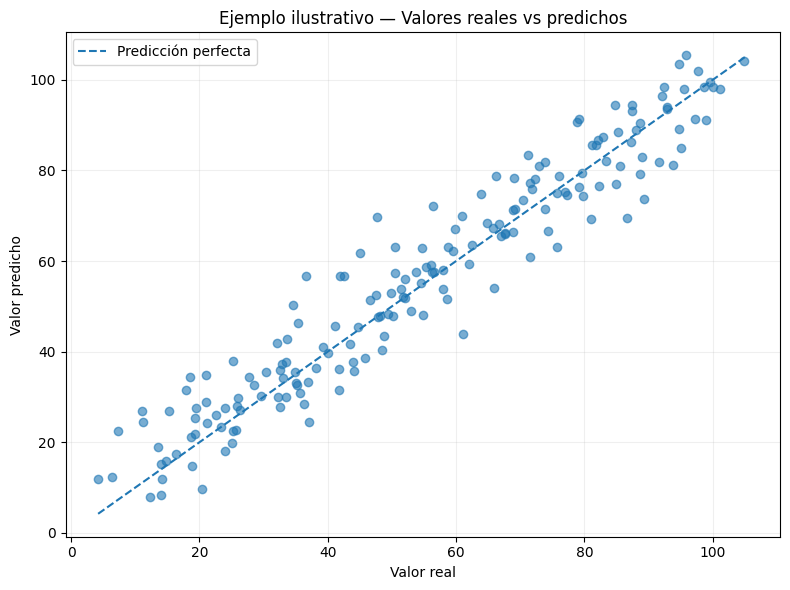

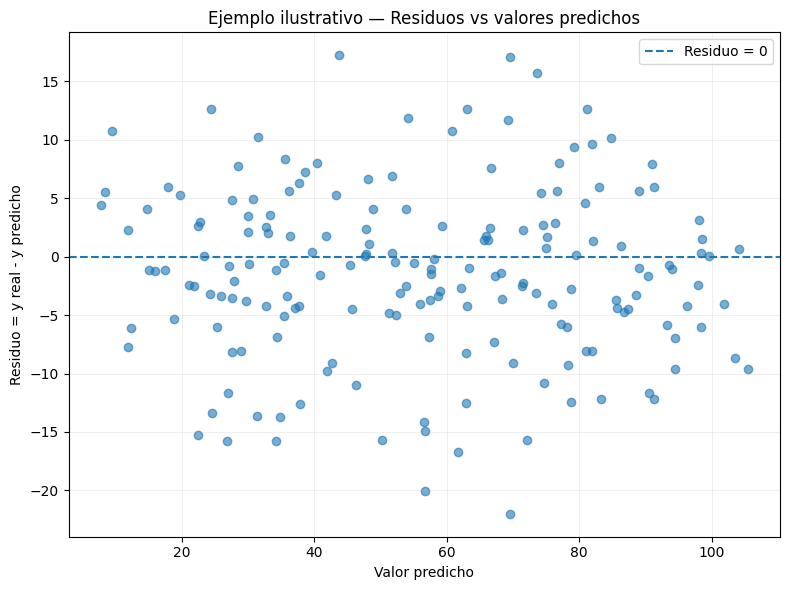

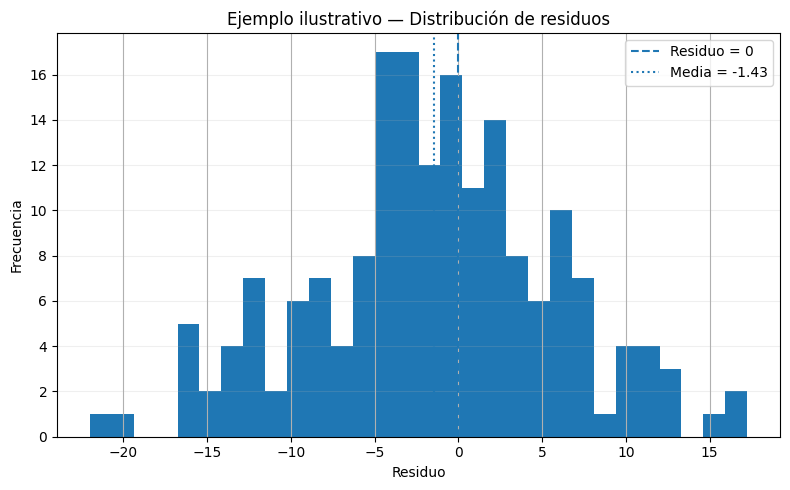

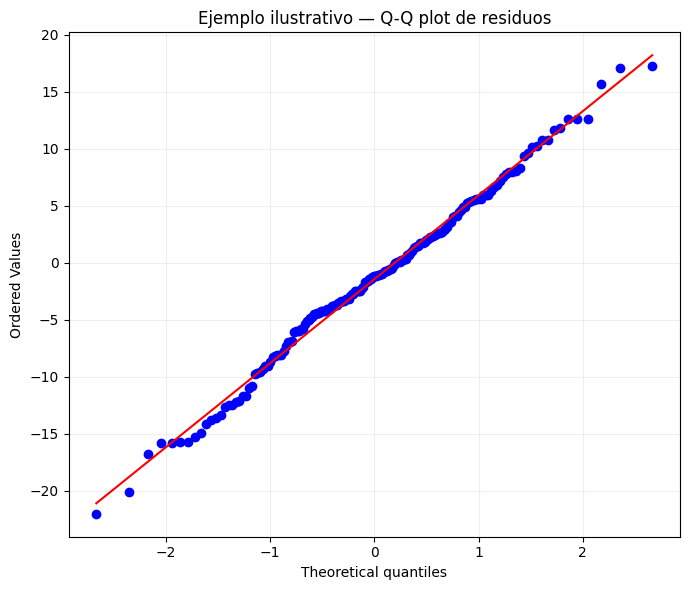

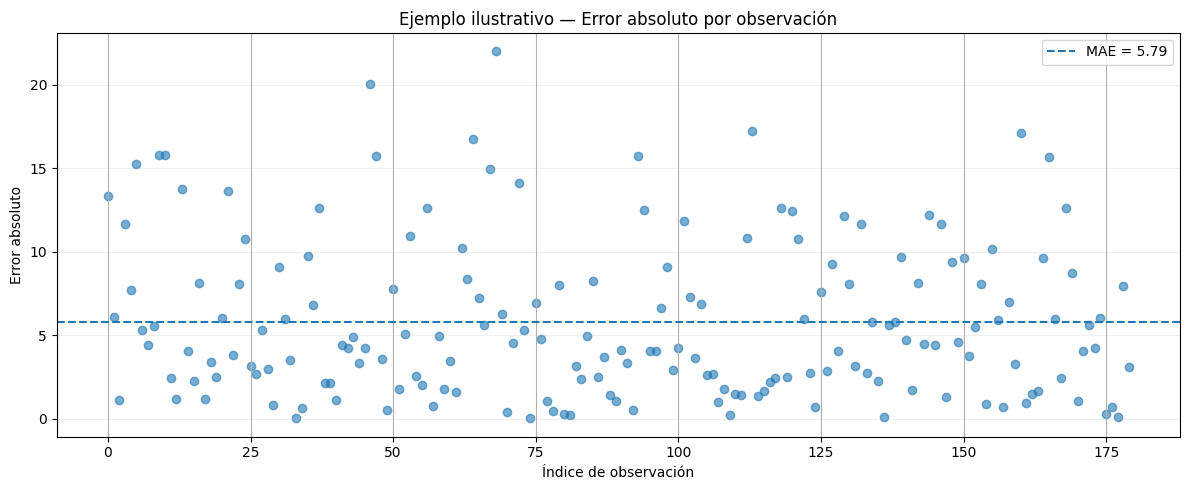

In [ ]:
################################################################################
################################################################################
################################################################################
# Codigo de prueba
################################################################################
################################################################################
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Datos sintéticos SOLO para ilustrar la forma de los gráficos de regresión.
# No corresponden a resultados del notebook PlantVillage.
rng = np.random.default_rng(42)
n = 180

y_real = np.linspace(10, 100, n) + rng.normal(0, 4, n)
y_pred = y_real * 0.93 + 5 + rng.normal(0, 7, n)

residuos = y_real - y_pred
errores_absolutos = np.abs(residuos)

mae = np.mean(errores_absolutos)
rmse = np.sqrt(np.mean(residuos**2))
ss_res = np.sum((y_real - y_pred)**2)
ss_tot = np.sum((y_real - np.mean(y_real))**2)
r2 = 1 - ss_res / ss_tot

print(f"Ejemplo ilustrativo — MAE: {mae:.3f} | RMSE: {rmse:.3f} | R²: {r2:.3f}")

# 1) Valores reales vs predichos
lim_min = min(y_real.min(), y_pred.min())
lim_max = max(y_real.max(), y_pred.max())

plt.figure(figsize=(8, 6))
plt.scatter(y_real, y_pred, alpha=0.6)
plt.plot([lim_min, lim_max], [lim_min, lim_max], linestyle="--", label="Predicción perfecta")
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Ejemplo ilustrativo — Valores reales vs predichos")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

# 2) Residuos vs predicción
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuos, alpha=0.6)
plt.axhline(0, linestyle="--", label="Residuo = 0")
plt.xlabel("Valor predicho")
plt.ylabel("Residuo = y real - y predicho")
plt.title("Ejemplo ilustrativo — Residuos vs valores predichos")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

# 3) Histograma de residuos
plt.figure(figsize=(8, 5))
plt.hist(residuos, bins=30)
plt.axvline(0, linestyle="--", label="Residuo = 0")
plt.axvline(np.mean(residuos), linestyle=":", label=f"Media = {np.mean(residuos):.2f}")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.title("Ejemplo ilustrativo — Distribución de residuos")
plt.grid(axis="y", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

# 4) Q-Q plot
plt.figure(figsize=(7, 6))
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("Ejemplo ilustrativo — Q-Q plot de residuos")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 5) Error absoluto por observación
indices = np.arange(n)

plt.figure(figsize=(12, 5))
plt.scatter(indices, errores_absolutos, alpha=0.6)
plt.axhline(mae, linestyle="--", label=f"MAE = {mae:.2f}")
plt.xlabel("Índice de observación")
plt.ylabel("Error absoluto")
plt.title("Ejemplo ilustrativo — Error absoluto por observación")
plt.grid(axis="y", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


## 6.9 Interpretabilidad

La interpretación de un modelo permite responder una pregunta complementaria a la.

## 6.9.1 Contexto del Pipeline actual

Esta sección resume contexto del Pipeline actual y su función dentro del proyecto MLOps.

# 6.9.2 Coeficientes de la Regresión Logística

La Regresión Logística multiclase calcula para cada clase un score.

## Magnitud global de los coeficientes

clases, cada feature posee diez coeficientes.

# 6.9.3 Feature Importance en Random Forest

Random Forest permite obtener una medida interna denominada.

## Limitación de Feature Importance

La importancia basada en árboles no debe interpretarse como causalidad.

# 6.9.4 Permutation Importance

Permutation Importance evalúa cuánto disminuye el desempeño cuando se destruye la.

## Ventaja del Permutation Importance

En este proyecto se aplicará sobre el Pipeline completo.

# 6.9.5 SHAP

SHAP permite explicar una predicción como la suma de contribuciones de las diferentes.

# 6.9.6 Protocolo de interpretación

Esta sección resume protocolo de interpretación y su función dentro del proyecto MLOps.

# 6.9.7 Criterio de interpretación conjunta

Una feature tendrá evidencia interpretativa especialmente fuerte cuando aparezca.


6.9 — COEFICIENTES DE REGRESIÓN LOGÍSTICA


,r_mean,g_mean,b_mean,r_std,g_std,b_std,s_mean,v_mean,excess_green,brightness_mean,contrast_std,entropy,edge_density,h_sin,h_cos,laplacian_log1p
Tomato___Bacterial_spot,+4.3338,+0.6011,-4.1912,+1.1710,-2.4792,-1.2817,-1.5483,-3.2127,+1.0137,+1.2339,+1.7604,+1.3827,-4.0523,+3.1407,+0.1893,-0.4116
Tomato___Early_blight,+1.1489,+1.6819,+1.2207,-2.1079,+1.8005,+0.3768,+0.5562,-5.8326,+0.7359,+1.5385,+1.2224,+0.5504,-0.9830,+0.1914,-0.3384,-1.9431
Tomato___Late_blight,-0.1600,-0.5382,-1.1553,-2.8754,+0.8565,-1.6957,+0.2038,+2.9089,+0.2954,-0.5216,+5.3310,-0.7314,-1.4679,-0.2156,-0.2069,-1.7631
Tomato___Leaf_Mold,-2.1520,-1.9744,-0.8241,-0.7477,-2.3608,+0.5925,+0.0884,+7.3826,-0.6974,-1.9887,+3.8746,-1.7430,+0.3120,-0.2225,-0.3857,-1.0503
Tomato___Septoria_leaf_spot,-0.2772,-0.3362,+1.2049,+5.2974,+2.3790,+2.2599,+2.3704,+1.9219,-1.4723,-0.1402,-8.4744,-3.4441,+0.2643,-0.0330,-0.6591,+0.7619
Tomato___Spider_mites Two-spotted_spider_mite,+2.5474,+0.6696,-0.8829,+0.4690,-1.1738,-2.4138,+0.6785,-2.8795,-0.3431,+1.1151,+1.8819,+2.8487,-1.4852,-0.5019,+0.5657,+3.3834
Tomato___Target_Spot,-3.5196,-0.4518,+3.0513,+0.4574,+0.8167,-1.2268,-0.4290,+2.1399,-0.4265,-1.0246,-0.7916,+2.2303,-0.3460,+0.5345,+0.3108,+2.3617
Tomato___Tomato_Yellow_Leaf_Curl_Virus,+3.3530,-0.8518,-5.8523,+3.2371,-1.3648,+1.0910,-1.3824,+1.3424,+0.9403,-0.1678,-2.0308,+1.0271,+2.3457,-0.1619,-0.0182,-5.6930
Tomato___Tomato_mosaic_virus,-1.4709,-0.6191,+3.2758,+3.0798,-3.4045,+2.1286,+1.7028,-0.0234,-2.8230,-0.4352,-2.9041,-2.0595,+2.5835,-2.6926,+0.9768,+0.9367
Tomato___healthy,-3.8034,+1.8188,+4.1531,-7.9805,+4.9304,+0.1692,-2.2404,-3.7475,+2.7769,+0.3907,+0.1305,-0.0613,+2.8289,-0.0391,-0.4343,+3.4173



Ranking global — Regresión Logística:


,Feature,Media |coeficiente|,Máximo |coeficiente|
0,v_mean,3.1392,7.3826
1,contrast_std,2.8402,8.4744
2,r_std,2.7423,7.9805
3,b_mean,2.5812,5.8523
4,r_mean,2.2766,4.3338
5,laplacian_log1p,2.1722,5.6930
6,g_std,2.1566,4.9304
7,edge_density,1.6669,4.0523
8,entropy,1.6079,3.4441
9,b_std,1.3236,2.4138


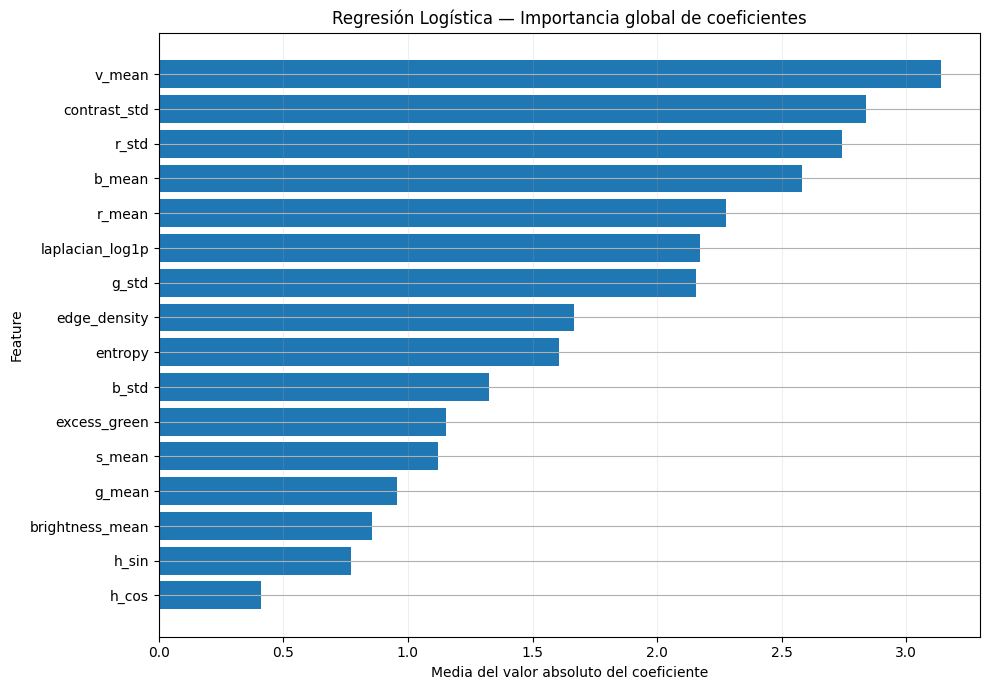

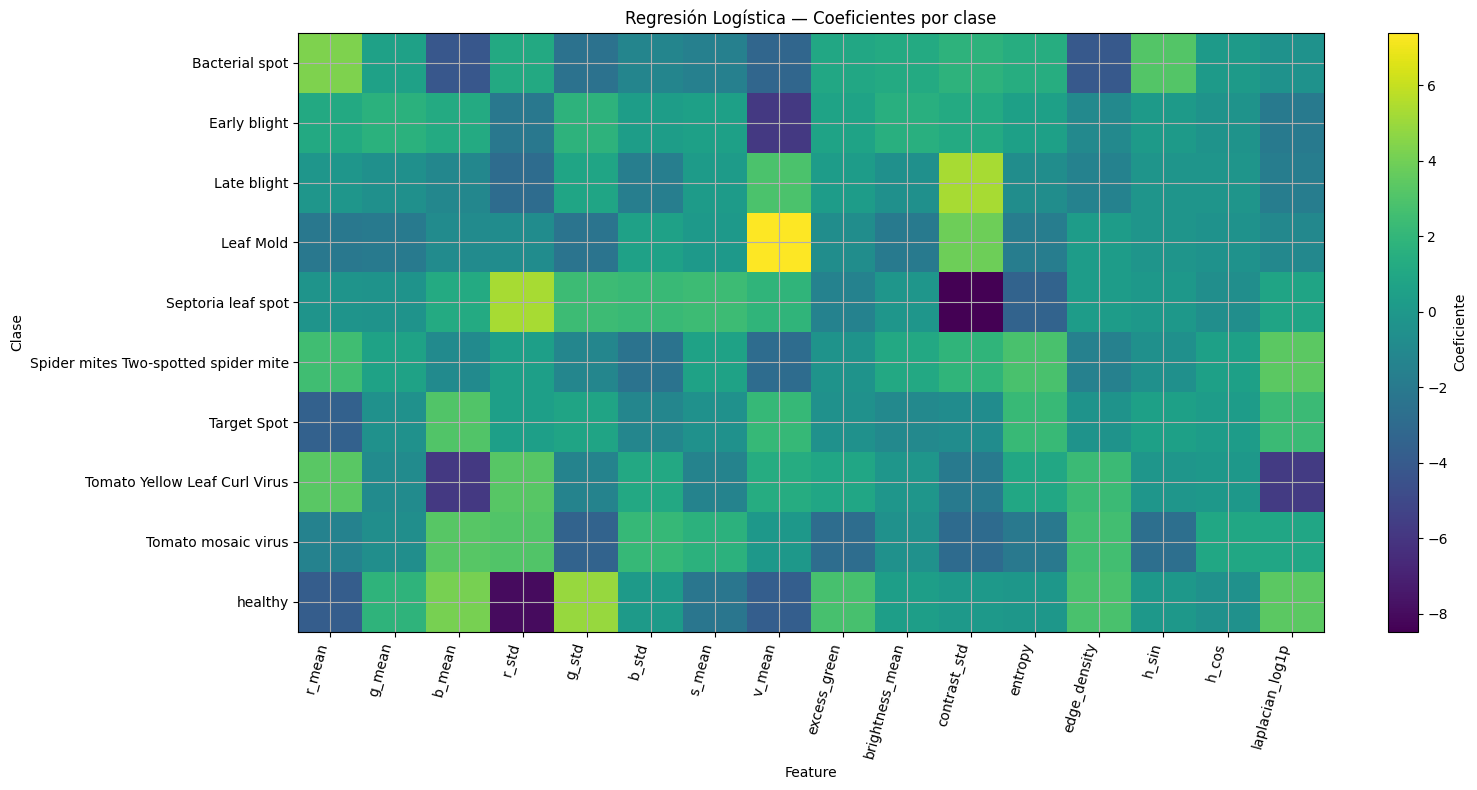


Top coeficientes positivos y negativos por clase:


,Clase,Dirección,Feature,Coeficiente
0,Tomato___Bacterial_spot,Positiva,r_mean,+4.3338
1,Tomato___Bacterial_spot,Positiva,h_sin,+3.1407
2,Tomato___Bacterial_spot,Positiva,contrast_std,+1.7604
3,Tomato___Bacterial_spot,Negativa,b_mean,-4.1912
4,Tomato___Bacterial_spot,Negativa,edge_density,-4.0523
5,Tomato___Bacterial_spot,Negativa,v_mean,-3.2127
6,Tomato___Early_blight,Positiva,g_std,+1.8005
7,Tomato___Early_blight,Positiva,g_mean,+1.6819
8,Tomato___Early_blight,Positiva,brightness_mean,+1.5385
9,Tomato___Early_blight,Negativa,v_mean,-5.8326



FEATURE IMPORTANCE — RANDOM FOREST


,Feature,Feature Importance
0,laplacian_log1p,0.128792
1,excess_green,0.088655
2,h_sin,0.086626
3,edge_density,0.081911
4,s_mean,0.079607
5,b_std,0.069886
6,b_mean,0.065871
7,h_cos,0.061534
8,entropy,0.051762
9,r_std,0.047677


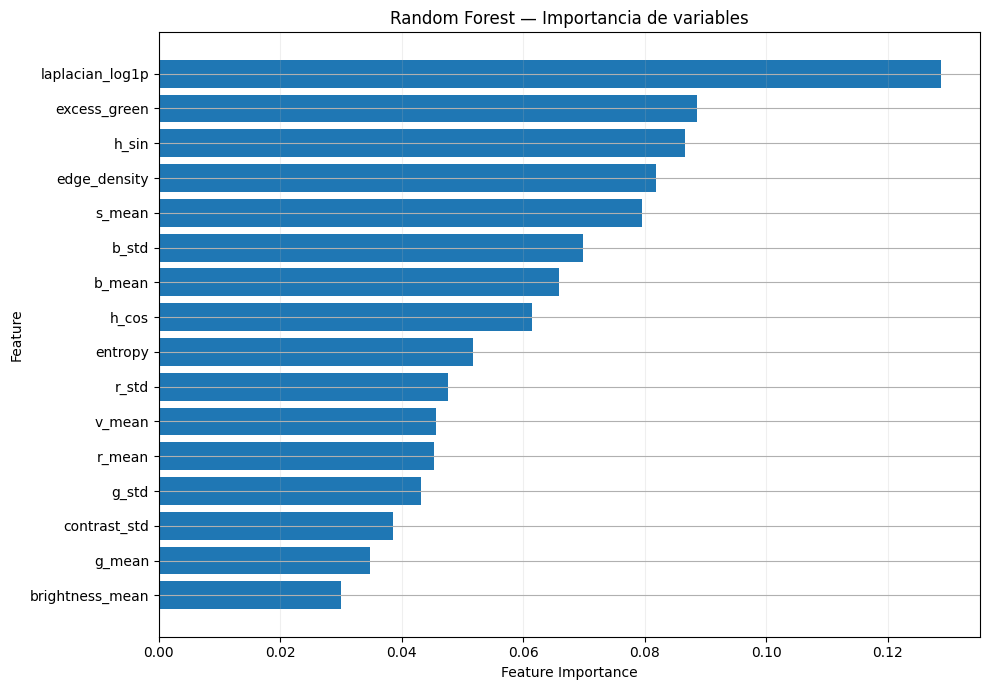


PERMUTATION IMPORTANCE — REGRESIÓN LOGÍSTICA


,Modelo,Feature,Importancia media,Importancia std
0,Regresión Logística,contrast_std,+0.321827,0.012447
1,Regresión Logística,v_mean,+0.314513,0.008750
2,Regresión Logística,r_std,+0.287714,0.004885
3,Regresión Logística,b_mean,+0.286620,0.006145
4,Regresión Logística,g_std,+0.270890,0.017961
5,Regresión Logística,laplacian_variance,+0.259306,0.006483
6,Regresión Logística,edge_density,+0.216298,0.009634
7,Regresión Logística,r_mean,+0.187370,0.004827
8,Regresión Logística,b_std,+0.183854,0.007573
9,Regresión Logística,entropy,+0.140455,0.007200



PERMUTATION IMPORTANCE — RANDOM FOREST


,Modelo,Feature,Importancia media,Importancia std
0,Random Forest,h_mean,+0.231905,0.012905
1,Random Forest,laplacian_variance,+0.141490,0.006060
2,Random Forest,s_mean,+0.105093,0.004663
3,Random Forest,excess_green,+0.061460,0.007183
4,Random Forest,edge_density,+0.047381,0.005352
5,Random Forest,entropy,+0.041547,0.003840
6,Random Forest,b_std,+0.039353,0.004259
7,Random Forest,b_mean,+0.036784,0.002457
8,Random Forest,r_mean,+0.030911,0.001713
9,Random Forest,g_std,+0.028202,0.004158


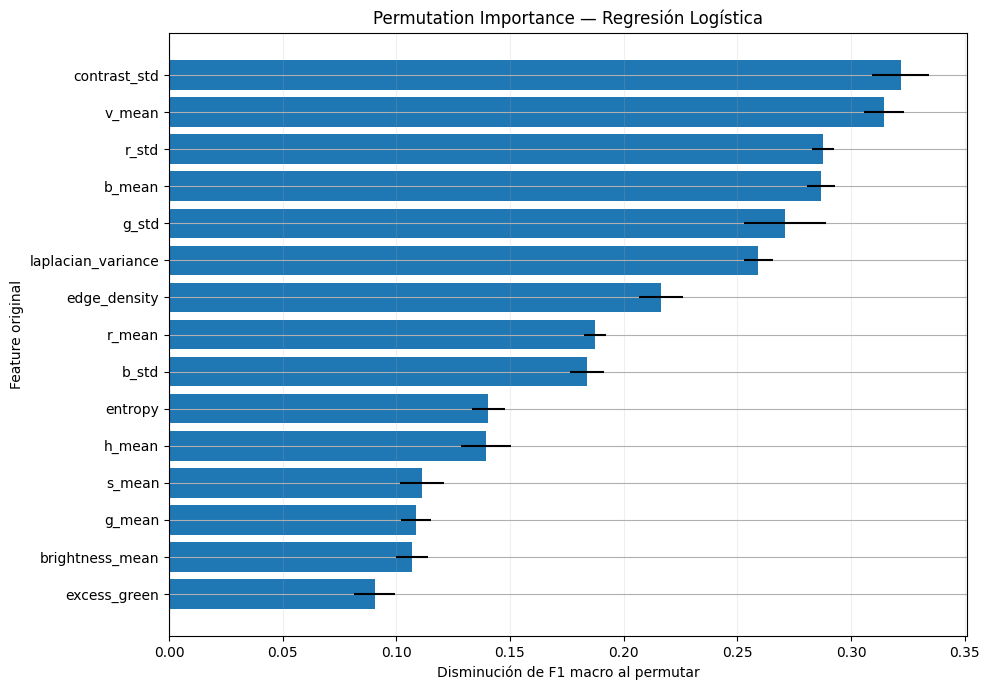

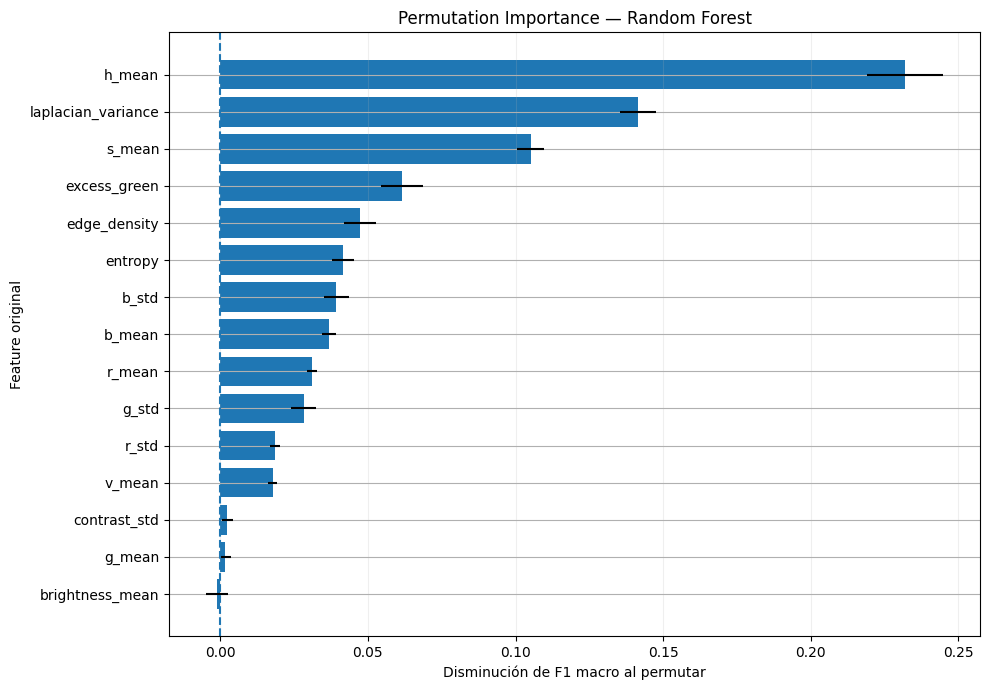


COMPARACIÓN DE PERMUTATION IMPORTANCE


,Feature,Permutation LR,Permutation RF,Media ambos modelos
0,laplacian_variance,+0.259306,+0.141490,+0.200398
1,h_mean,+0.139444,+0.231905,+0.185675
2,v_mean,+0.314513,+0.017687,+0.166100
3,contrast_std,+0.321827,+0.002432,+0.162129
4,b_mean,+0.286620,+0.036784,+0.161702
5,r_std,+0.287714,+0.018579,+0.153147
6,g_std,+0.270890,+0.028202,+0.149546
7,edge_density,+0.216298,+0.047381,+0.131839
8,b_std,+0.183854,+0.039353,+0.111604
9,r_mean,+0.187370,+0.030911,+0.109141



RESUMEN DE INTERPRETABILIDAD


,Método,Feature más relevante
0,Coeficientes LR,v_mean
1,Feature Importance RF,laplacian_log1p
2,Permutation LR,contrast_std
3,Permutation RF,h_mean



CONTROL FINAL — 6.9 INTERPRETABILIDAD
✅ Coeficientes de Regresión Logística analizados.
✅ Coeficientes por clase generados.
✅ Heatmap de coeficientes generado.
✅ Feature Importance de Random Forest calculada.
✅ Permutation Importance LR calculada.
✅ Permutation Importance RF calculada.
✅ F1 macro utilizado como métrica de permutación.
✅ Features originales preservadas para Permutation Importance.
✅ Test permanece aislado.
✅ 6.9 — INTERPRETABILIDAD PRINCIPAL COMPLETADA


In [ ]:
# ============================================================
# FASE 2 — MODELADO SIN FUGA DE DATOS
# 6.9 INTERPRETABILIDAD
# ============================================================
#
# MÉTODOS:
#
# 1. Coeficientes             -> Regresión Logística
# 2. Feature Importance       -> Random Forest
# 3. Permutation Importance   -> Ambos modelos
#
# SHAP se desarrolla posteriormente como bloque opcional.
#
# IMPORTANTE:
#
# - Se utilizan modelos YA entrenados.
# - NO se realiza fit.
# - Permutation Importance utiliza Validation.
# - Test permanece aislado.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance

from IPython.display import display


# ============================================================
# 2. VERIFICAR OBJETOS DE 6.7
# ============================================================

objetos_requeridos = [
    "pipelines_ajustados_6_7",
    "X_val",
    "y_val"
]


objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]


if objetos_faltantes:

    raise NameError(
        "Faltan objetos necesarios para 6.9: "
        f"{objetos_faltantes}. "
        "Ejecute previamente 6.7."
    )


modelos_requeridos = {
    "Regresión Logística",
    "Random Forest"
}


modelos_faltantes = (
    modelos_requeridos
    -
    set(
        pipelines_ajustados_6_7.keys()
    )
)


if modelos_faltantes:

    raise KeyError(
        "Faltan modelos de 6.7: "
        f"{modelos_faltantes}"
    )


# ============================================================
# 3. RECUPERAR PIPELINES
# ============================================================

pipeline_lr_6_9 = (
    pipelines_ajustados_6_7[
        "Regresión Logística"
    ]
)


pipeline_rf_6_9 = (
    pipelines_ajustados_6_7[
        "Random Forest"
    ]
)


# ============================================================
# 4. RECUPERAR ESTIMADORES
# ============================================================

modelo_lr_6_9 = (
    pipeline_lr_6_9
    .named_steps[
        "model"
    ]
)


modelo_rf_6_9 = (
    pipeline_rf_6_9
    .named_steps[
        "model"
    ]
)


# ============================================================
# 5. RECUPERAR FEATURES INTERNAS
# ============================================================
#
# Se esperan 16 features después del preprocesamiento.
#
# ============================================================

feature_names_internas_6_9 = (
    pipeline_lr_6_9
    .named_steps[
        "preprocessor"
    ]
    .get_feature_names_out()
)


assert (
    len(
        feature_names_internas_6_9
    )
    == 16
), (
    "Se esperaban 16 features internas."
)


# ============================================================
# 6. FUNCIÓN PARA LIMPIAR NOMBRES
# ============================================================

def limpiar_nombre_feature_6_9(
    feature
):

    return (
        str(feature)
        .replace(
            "num__",
            ""
        )
        .replace(
            "cat__",
            ""
        )
    )


features_internas_cortas_6_9 = [
    limpiar_nombre_feature_6_9(
        feature
    )
    for feature
    in feature_names_internas_6_9
]


# ============================================================
# PARTE A
# COEFICIENTES — REGRESIÓN LOGÍSTICA
# ============================================================


# ============================================================
# 7. MATRIZ DE COEFICIENTES
# ============================================================
#
# Shape esperada:
#
#       (10 clases, 16 features)
#
# ============================================================

coeficientes_lr_6_9 = (
    modelo_lr_6_9.coef_
)


clases_lr_6_9 = (
    modelo_lr_6_9.classes_
)


assert (
    coeficientes_lr_6_9.shape
    ==
    (
        len(
            clases_lr_6_9
        ),
        len(
            feature_names_internas_6_9
        )
    )
)


# ============================================================
# 8. DATAFRAME DE COEFICIENTES POR CLASE
# ============================================================

df_coeficientes_clase_6_9 = pd.DataFrame(
    coeficientes_lr_6_9,
    index=clases_lr_6_9,
    columns=features_internas_cortas_6_9
)


print("=" * 110)
print("6.9 — COEFICIENTES DE REGRESIÓN LOGÍSTICA")
print("=" * 110)


display(
    df_coeficientes_clase_6_9.style.format(
        "{:+.4f}"
    )
)


# ============================================================
# 9. IMPORTANCIA GLOBAL DE COEFICIENTES
# ============================================================
#
# I_j = media_k |beta_kj|
#
# ============================================================

coef_importancia_media_6_9 = np.mean(
    np.abs(
        coeficientes_lr_6_9
    ),
    axis=0
)


coef_importancia_max_6_9 = np.max(
    np.abs(
        coeficientes_lr_6_9
    ),
    axis=0
)


df_coeficientes_global_6_9 = (
    pd.DataFrame(
        {
            "Feature": (
                features_internas_cortas_6_9
            ),

            "Media |coeficiente|": (
                coef_importancia_media_6_9
            ),

            "Máximo |coeficiente|": (
                coef_importancia_max_6_9
            )
        }
    )
    .sort_values(
        by="Media |coeficiente|",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nRanking global — Regresión Logística:"
)


display(
    df_coeficientes_global_6_9.style.format(
        {
            "Media |coeficiente|": "{:.4f}",
            "Máximo |coeficiente|": "{:.4f}"
        }
    )
)


# ============================================================
# 10. GRÁFICO — IMPORTANCIA GLOBAL DE COEFICIENTES
# ============================================================

df_plot_coef = (
    df_coeficientes_global_6_9
    .sort_values(
        by="Media |coeficiente|",
        ascending=True
    )
)


plt.figure(
    figsize=(10, 7)
)


plt.barh(
    df_plot_coef[
        "Feature"
    ],
    df_plot_coef[
        "Media |coeficiente|"
    ]
)


plt.xlabel(
    "Media del valor absoluto del coeficiente"
)


plt.ylabel(
    "Feature"
)


plt.title(
    "Regresión Logística — Importancia global de coeficientes"
)


plt.grid(
    axis="x",
    alpha=0.20
)


plt.tight_layout()

plt.show()


# ============================================================
# 11. HEATMAP DE COEFICIENTES POR CLASE
# ============================================================
#
# Permite observar:
#
#   coeficiente > 0
#   coeficiente < 0
#
# para cada combinación clase-feature.
#
# ============================================================

fig, ax = plt.subplots(
    figsize=(16, 8)
)


imagen = ax.imshow(
    coeficientes_lr_6_9,
    aspect="auto"
)


ax.set_xticks(
    np.arange(
        len(
            features_internas_cortas_6_9
        )
    )
)


ax.set_xticklabels(
    features_internas_cortas_6_9,
    rotation=75,
    ha="right"
)


ax.set_yticks(
    np.arange(
        len(
            clases_lr_6_9
        )
    )
)


ax.set_yticklabels(
    [
        str(clase)
        .replace(
            "Tomato___",
            ""
        )
        .replace(
            "_",
            " "
        )
        for clase
        in clases_lr_6_9
    ]
)


ax.set_xlabel(
    "Feature"
)


ax.set_ylabel(
    "Clase"
)


ax.set_title(
    "Regresión Logística — Coeficientes por clase"
)


fig.colorbar(
    imagen,
    ax=ax,
    label="Coeficiente"
)


plt.tight_layout()

plt.show()


# ============================================================
# 12. TOP COEFICIENTES POSITIVOS Y NEGATIVOS POR CLASE
# ============================================================

filas_extremos_6_9 = []


N_TOP_COEF = 3


for clase in clases_lr_6_9:

    serie = (
        df_coeficientes_clase_6_9
        .loc[
            clase
        ]
    )


    positivos = (
        serie
        .nlargest(
            N_TOP_COEF
        )
    )


    negativos = (
        serie
        .nsmallest(
            N_TOP_COEF
        )
    )


    for feature, valor in positivos.items():

        filas_extremos_6_9.append(
            {
                "Clase": clase,
                "Dirección": "Positiva",
                "Feature": feature,
                "Coeficiente": valor
            }
        )


    for feature, valor in negativos.items():

        filas_extremos_6_9.append(
            {
                "Clase": clase,
                "Dirección": "Negativa",
                "Feature": feature,
                "Coeficiente": valor
            }
        )


df_coeficientes_extremos_6_9 = pd.DataFrame(
    filas_extremos_6_9
)


print(
    "\nTop coeficientes positivos y negativos por clase:"
)


display(
    df_coeficientes_extremos_6_9.style.format(
        {
            "Coeficiente": "{:+.4f}"
        }
    )
)


# ============================================================
# PARTE B
# FEATURE IMPORTANCE — RANDOM FOREST
# ============================================================


# ============================================================
# 13. EXTRAER FEATURE IMPORTANCE
# ============================================================

importancias_rf_6_9 = (
    modelo_rf_6_9
    .feature_importances_
)


assert (
    len(
        importancias_rf_6_9
    )
    ==
    len(
        feature_names_internas_6_9
    )
)


assert np.isclose(
    np.sum(
        importancias_rf_6_9
    ),
    1.0
)


# ============================================================
# 14. TABLA DE IMPORTANCIA RANDOM FOREST
# ============================================================

df_feature_importance_rf_6_9 = (
    pd.DataFrame(
        {
            "Feature": (
                features_internas_cortas_6_9
            ),

            "Feature Importance": (
                importancias_rf_6_9
            )
        }
    )
    .sort_values(
        by="Feature Importance",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print(
    "\n" + "=" * 110
)

print(
    "FEATURE IMPORTANCE — RANDOM FOREST"
)

print(
    "=" * 110
)


display(
    df_feature_importance_rf_6_9.style.format(
        {
            "Feature Importance": "{:.6f}"
        }
    )
)


# ============================================================
# 15. GRÁFICO RANDOM FOREST
# ============================================================

df_plot_rf = (
    df_feature_importance_rf_6_9
    .sort_values(
        by="Feature Importance",
        ascending=True
    )
)


plt.figure(
    figsize=(10, 7)
)


plt.barh(
    df_plot_rf[
        "Feature"
    ],
    df_plot_rf[
        "Feature Importance"
    ]
)


plt.xlabel(
    "Feature Importance"
)


plt.ylabel(
    "Feature"
)


plt.title(
    "Random Forest — Importancia de variables"
)


plt.grid(
    axis="x",
    alpha=0.20
)


plt.tight_layout()

plt.show()


# ============================================================
# PARTE C
# PERMUTATION IMPORTANCE
# ============================================================


# ============================================================
# 16. CONFIGURACIÓN
# ============================================================
#
# Se utiliza F1 macro porque existe desbalance.
#
# 5 repeticiones mantienen un compromiso adecuado entre:
#
#   estabilidad
#   tiempo
#   simplicidad
#
# ============================================================

N_REPEATS_PERMUTATION_6_9 = 5


# ============================================================
# 17. FUNCIÓN DE PERMUTATION IMPORTANCE
# ============================================================

def calcular_permutation_6_9(
    nombre_modelo,
    pipeline_modelo
):

    resultado = permutation_importance(
        estimator=pipeline_modelo,

        X=X_val,

        y=y_val,

        scoring="f1_macro",

        n_repeats=N_REPEATS_PERMUTATION_6_9,

        random_state=42,

        n_jobs=1
    )


    df_resultado = (
        pd.DataFrame(
            {
                "Modelo": (
                    nombre_modelo
                ),

                "Feature": (
                    X_val.columns
                ),

                "Importancia media": (
                    resultado.importances_mean
                ),

                "Importancia std": (
                    resultado.importances_std
                )
            }
        )
        .sort_values(
            by="Importancia media",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


    return (
        df_resultado,
        resultado
    )


# ============================================================
# 18. PERMUTATION — REGRESIÓN LOGÍSTICA
# ============================================================

(
    df_permutation_lr_6_9,
    permutation_lr_6_9
) = calcular_permutation_6_9(
    nombre_modelo="Regresión Logística",
    pipeline_modelo=pipeline_lr_6_9
)


# ============================================================
# 19. PERMUTATION — RANDOM FOREST
# ============================================================

(
    df_permutation_rf_6_9,
    permutation_rf_6_9
) = calcular_permutation_6_9(
    nombre_modelo="Random Forest",
    pipeline_modelo=pipeline_rf_6_9
)


# ============================================================
# 20. MOSTRAR TABLAS
# ============================================================

print(
    "\n" + "=" * 110
)

print(
    "PERMUTATION IMPORTANCE — REGRESIÓN LOGÍSTICA"
)

print(
    "=" * 110
)


display(
    df_permutation_lr_6_9.style.format(
        {
            "Importancia media": "{:+.6f}",
            "Importancia std": "{:.6f}"
        }
    )
)


print(
    "\n" + "=" * 110
)

print(
    "PERMUTATION IMPORTANCE — RANDOM FOREST"
)

print(
    "=" * 110
)


display(
    df_permutation_rf_6_9.style.format(
        {
            "Importancia media": "{:+.6f}",
            "Importancia std": "{:.6f}"
        }
    )
)


# ============================================================
# 21. GRÁFICOS DE PERMUTATION IMPORTANCE
# ============================================================

for nombre_modelo, df_perm in [
    (
        "Regresión Logística",
        df_permutation_lr_6_9
    ),
    (
        "Random Forest",
        df_permutation_rf_6_9
    )
]:

    df_plot_perm = (
        df_perm
        .sort_values(
            by="Importancia media",
            ascending=True
        )
    )


    plt.figure(
        figsize=(10, 7)
    )


    plt.barh(
        df_plot_perm[
            "Feature"
        ],
        df_plot_perm[
            "Importancia media"
        ],
        xerr=df_plot_perm[
            "Importancia std"
        ]
    )


    plt.axvline(
        x=0,
        linestyle="--"
    )


    plt.xlabel(
        "Disminución de F1 macro al permutar"
    )


    plt.ylabel(
        "Feature original"
    )


    plt.title(
        f"Permutation Importance — {nombre_modelo}"
    )


    plt.grid(
        axis="x",
        alpha=0.20
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 22. COMPARACIÓN ENTRE MODELOS
# ============================================================

df_permutation_comparacion_6_9 = (
    df_permutation_lr_6_9[
        [
            "Feature",
            "Importancia media"
        ]
    ]
    .rename(
        columns={
            "Importancia media":
            "Permutation LR"
        }
    )
    .merge(
        df_permutation_rf_6_9[
            [
                "Feature",
                "Importancia media"
            ]
        ]
        .rename(
            columns={
                "Importancia media":
                "Permutation RF"
            }
        ),

        on="Feature",

        how="inner"
    )
)


df_permutation_comparacion_6_9[
    "Media ambos modelos"
] = (
    df_permutation_comparacion_6_9[
        [
            "Permutation LR",
            "Permutation RF"
        ]
    ]
    .mean(
        axis=1
    )
)


df_permutation_comparacion_6_9 = (
    df_permutation_comparacion_6_9
    .sort_values(
        by="Media ambos modelos",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print(
    "\n" + "=" * 110
)

print(
    "COMPARACIÓN DE PERMUTATION IMPORTANCE"
)

print(
    "=" * 110
)


display(
    df_permutation_comparacion_6_9.style.format(
        {
            "Permutation LR": "{:+.6f}",
            "Permutation RF": "{:+.6f}",
            "Media ambos modelos": "{:+.6f}"
        }
    )
)


# ============================================================
# 23. RESUMEN DE FEATURES MÁS IMPORTANTES
# ============================================================

feature_top_coef_6_9 = (
    df_coeficientes_global_6_9
    .iloc[0][
        "Feature"
    ]
)


feature_top_rf_6_9 = (
    df_feature_importance_rf_6_9
    .iloc[0][
        "Feature"
    ]
)


feature_top_perm_lr_6_9 = (
    df_permutation_lr_6_9
    .iloc[0][
        "Feature"
    ]
)


feature_top_perm_rf_6_9 = (
    df_permutation_rf_6_9
    .iloc[0][
        "Feature"
    ]
)


df_resumen_interpretabilidad_6_9 = pd.DataFrame(
    {
        "Método": [
            "Coeficientes LR",
            "Feature Importance RF",
            "Permutation LR",
            "Permutation RF"
        ],

        "Feature más relevante": [
            feature_top_coef_6_9,
            feature_top_rf_6_9,
            feature_top_perm_lr_6_9,
            feature_top_perm_rf_6_9
        ]
    }
)


print(
    "\n" + "=" * 110
)

print(
    "RESUMEN DE INTERPRETABILIDAD"
)

print(
    "=" * 110
)


display(
    df_resumen_interpretabilidad_6_9
)


# ============================================================
# 24. CONTROLES AUTOMÁTICOS
# ============================================================

assert (
    modelo_lr_6_9.coef_.shape
    ==
    (
        10,
        16
    )
)


assert (
    len(
        modelo_rf_6_9.feature_importances_
    )
    ==
    16
)


assert (
    len(
        df_permutation_lr_6_9
    )
    ==
    15
)


assert (
    len(
        df_permutation_rf_6_9
    )
    ==
    15
)


assert (
    set(
        df_permutation_lr_6_9[
            "Feature"
        ]
    )
    ==
    set(
        X_val.columns
    )
)


# ============================================================
# 25. OBJETOS CONSERVADOS
# ============================================================
#
# df_coeficientes_clase_6_9
# df_coeficientes_global_6_9
# df_coeficientes_extremos_6_9
#
# df_feature_importance_rf_6_9
#
# df_permutation_lr_6_9
# df_permutation_rf_6_9
# df_permutation_comparacion_6_9
#
# df_resumen_interpretabilidad_6_9
#
# ============================================================


# ============================================================
# 26. CONTROL FINAL
# ============================================================

print(
    "\n" + "=" * 110
)

print(
    "CONTROL FINAL — 6.9 INTERPRETABILIDAD"
)

print(
    "=" * 110
)


print(
    "✅ Coeficientes de Regresión Logística analizados."
)


print(
    "✅ Coeficientes por clase generados."
)


print(
    "✅ Heatmap de coeficientes generado."
)


print(
    "✅ Feature Importance de Random Forest calculada."
)


print(
    "✅ Permutation Importance LR calculada."
)


print(
    "✅ Permutation Importance RF calculada."
)


print(
    "✅ F1 macro utilizado como métrica de permutación."
)


print(
    "✅ Features originales preservadas para Permutation Importance."
)


print(
    "✅ Test permanece aislado."
)


print(
    "=" * 110
)


print(
    "✅ 6.9 — INTERPRETABILIDAD PRINCIPAL COMPLETADA"
)

In [ ]:
# ============================================================
# 6.9 — SHAP OPCIONAL
# ============================================================
#
# OBJETIVO:
#
# Obtener una interpretación SHAP global del Random Forest.
#
# IMPORTANTE:
#
# - NO es requisito obligatorio.
# - Se encuentra desactivado por defecto.
# - Utiliza solamente una muestra de Validation.
# - Test no participa.
#
# Si se desea utilizar:
#
#     EJECUTAR_SHAP_6_9 = True
#
# ============================================================


EJECUTAR_SHAP_6_9 = False


if EJECUTAR_SHAP_6_9:

    # ========================================================
    # 1. IMPORTAR SHAP
    # ========================================================

    try:

        import shap

    except ImportError:

        raise ImportError(
            "SHAP no está instalado. "
            "Si desea ejecutar este análisis opcional, "
            "instale previamente la librería shap."
        )


    # ========================================================
    # 2. CONFIGURACIÓN
    # ========================================================

    N_SHAP_6_9 = min(
        300,
        len(
            X_val
        )
    )


    # ========================================================
    # 3. MUESTRA DE VALIDATION
    # ========================================================

    X_shap_raw_6_9 = (
        X_val
        .sample(
            n=N_SHAP_6_9,
            random_state=42
        )
        .copy()
    )


    # ========================================================
    # 4. TRANSFORMAR CON EL PREPROCESSOR DEL RF
    # ========================================================

    preprocessor_rf_6_9 = (
        pipeline_rf_6_9
        .named_steps[
            "preprocessor"
        ]
    )


    X_shap_transformado_6_9 = (
        preprocessor_rf_6_9
        .transform(
            X_shap_raw_6_9
        )
    )


    df_X_shap_6_9 = pd.DataFrame(
        X_shap_transformado_6_9,
        columns=features_internas_cortas_6_9
    )


    # ========================================================
    # 5. TREE EXPLAINER
    # ========================================================

    explainer_rf_6_9 = shap.TreeExplainer(
        modelo_rf_6_9
    )


    shap_values_6_9 = (
        explainer_rf_6_9
        .shap_values(
            df_X_shap_6_9
        )
    )


    # ========================================================
    # 6. NORMALIZAR FORMATO ENTRE VERSIONES DE SHAP
    # ========================================================

    if isinstance(
        shap_values_6_9,
        list
    ):

        # Versiones antiguas:
        #
        # lista de K matrices:
        #
        # (N, p)
        #
        shap_array_6_9 = np.stack(
            shap_values_6_9,
            axis=-1
        )

    else:

        shap_array_6_9 = np.asarray(
            shap_values_6_9
        )


        if shap_array_6_9.ndim == 2:

            shap_array_6_9 = (
                shap_array_6_9[
                    :,
                    :,
                    np.newaxis
                ]
            )


        elif shap_array_6_9.ndim == 3:

            # Formato esperado:
            #
            # (N, features, clases)
            #
            if (
                shap_array_6_9.shape[1]
                !=
                len(
                    features_internas_cortas_6_9
                )
            ):

                if (
                    shap_array_6_9.shape[2]
                    ==
                    len(
                        features_internas_cortas_6_9
                    )
                ):

                    shap_array_6_9 = np.transpose(
                        shap_array_6_9,
                        (
                            0,
                            2,
                            1
                        )
                    )


    # ========================================================
    # 7. IMPORTANCIA SHAP GLOBAL
    # ========================================================
    #
    # Promedio de:
    #
    # |SHAP|
    #
    # sobre observaciones y clases.
    #
    # ========================================================

    importancia_shap_global_6_9 = np.mean(
        np.abs(
            shap_array_6_9
        ),
        axis=(
            0,
            2
        )
    )


    df_shap_global_6_9 = (
        pd.DataFrame(
            {
                "Feature": (
                    features_internas_cortas_6_9
                ),

                "Media |SHAP|": (
                    importancia_shap_global_6_9
                )
            }
        )
        .sort_values(
            by="Media |SHAP|",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


    print(
        "=" * 110
    )

    print(
        "SHAP GLOBAL — RANDOM FOREST"
    )

    print(
        "=" * 110
    )


    display(
        df_shap_global_6_9.style.format(
            {
                "Media |SHAP|": "{:.6f}"
            }
        )
    )


    # ========================================================
    # 8. GRÁFICO SHAP GLOBAL
    # ========================================================

    df_plot_shap = (
        df_shap_global_6_9
        .sort_values(
            by="Media |SHAP|",
            ascending=True
        )
    )


    plt.figure(
        figsize=(10, 7)
    )


    plt.barh(
        df_plot_shap[
            "Feature"
        ],
        df_plot_shap[
            "Media |SHAP|"
        ]
    )


    plt.xlabel(
        "Media del valor absoluto SHAP"
    )


    plt.ylabel(
        "Feature"
    )


    plt.title(
        "Random Forest — Importancia global SHAP"
    )


    plt.grid(
        axis="x",
        alpha=0.20
    )


    plt.tight_layout()

    plt.show()


    print(
        "✅ SHAP ejecutado sobre "
        f"{N_SHAP_6_9} observaciones de Validation."
    )


else:

    print(
        "ℹ️ SHAP no se ejecutó."
    )

    print(
        "Motivo: se mantiene como análisis opcional "
        "para preservar simplicidad y tiempo de ejecución."
    )

    print(
        "✅ 6.9 queda correctamente cubierta mediante "
        "coeficientes, Feature Importance y "
        "Permutation Importance."
    )

ℹ️ SHAP no se ejecutó.
Motivo: se mantiene como análisis opcional para preservar simplicidad y tiempo de ejecución.
✅ 6.9 queda correctamente cubierta mediante coeficientes, Feature Importance y Permutation Importance.


## 6.9.8 Interpretación técnica

La interpretación se desarrolló utilizando métodos específicos para cada familia de.

## Regresión Logística

La Regresión Logística permite observar directamente.

## Interpretación conjunta de h_sin y h_cos

no deben interpretarse como variables independientes desde el punto de vista.

## Random Forest

La Feature Importance permite identificar las variables que contribuyen en mayor.

## Permutation Importance

Permutation Importance responde directamente.

## Correlación y redundancia

Durante el EDA se observaron relaciones importantes entre algunas características.

## Diferencia entre features internas y originales

Coeficientes y Feature Importance trabajan sobre.

## SHAP

SHAP ofrece un nivel adicional de explicación.

## Relación con los resultados obtenidos

Random Forest presenta actualmente un desempeño superior a la Regresión Logística.

## Criterio de evidencia robusta

Una feature puede considerarse especialmente relevante cuando distintos métodos.

## Precaución

Esta sección resume precaución y su función dentro del proyecto MLOps.

## Conclusión de 6.9

Esta sección resume conclusión de 6.9 y su función dentro del proyecto MLOps.


## 6.10 Selección del modelo campeón

El objetivo de esta etapa es seleccionar el modelo que será utilizado como modelo.

## 6.10.1 Principio de selección

Esta sección resume principio de selección y su función dentro del proyecto MLOps.

## 6.10.2 Resultados obtenidos

Esta sección resume resultados obtenidos y su función dentro del proyecto MLOps.

## 6.10.3 Estabilidad

La desviación estándar del F1 macro durante Cross Validation fue.

## 6.10.4 Capacidad discriminativa

Esta sección resume capacidad discriminativa y su función dentro del proyecto MLOps.

## 6.10.5 Interpretabilidad

Esta sección resume interpretabilidad y su función dentro del proyecto MLOps.

## 6.10.6 Costo computacional

Los tiempos observados fueron aproximadamente.

## 6.10.7 Tamaño del Pipeline

Esta sección resume tamaño del Pipeline y su función dentro del proyecto MLOps.

## 6.10.8 Selección antes de Test

El conjunto Test debe permanecer independiente durante la selección.

## 6.10.9 Candidato campeón

Esta sección resume candidato campeón y su función dentro del proyecto MLOps.

## 6.10.10 Tabla de decisión

Esta sección resume tabla de decisión y su función dentro del proyecto MLOps.

## 6.10.11 Regla final

Esta sección resume regla final y su función dentro del proyecto MLOps.


6.10 — SELECCIÓN DEL MODELO CAMPEÓN
Modelo campeón bloqueado : Random Forest
F1 macro Validation      : 0.8092

TABLA DE DECISIÓN — SIN UTILIZAR TEST


,Modelo,CV F1 macro media,CV F1 macro std,Validation F1 macro,Validation Balanced Accuracy,ROC-AUC macro OvR,|F1 val - F1 CV|,Interpretabilidad,Costo temporal,Tiempo fit (s),Predicción ms/obs,Tamaño Pipeline (MB),Selección
0,Random Forest,0.8050,0.0023,0.8092,0.7975,0.9814,0.0042,Media,Medio,12.9382,0.038598,95.1908,CAMPEÓN
1,Regresión Logística,0.7095,0.0018,0.7066,0.6973,0.9540,0.0030,Alta,Bajo,1.6237,0.007443,0.0048,Finalista



Criterio principal:
  1. F1 macro Validation
  2. Balanced Accuracy
  3. ROC-AUC macro
  4. Estabilidad CV
  5. Costo operacional


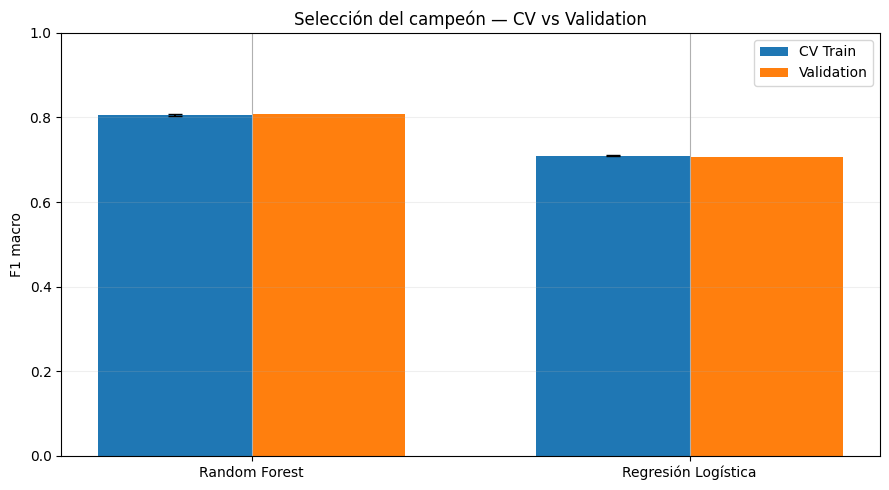

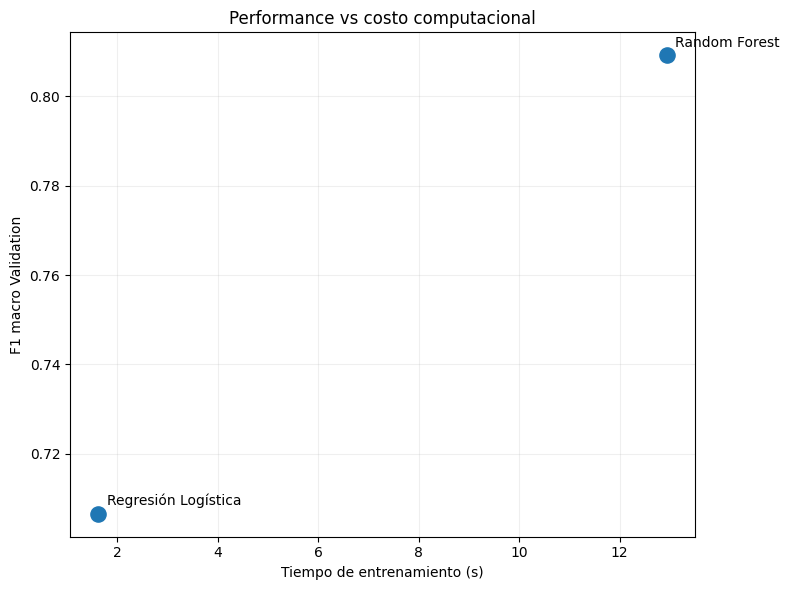


✅ Campeón seleccionado sin consultar Test.


In [ ]:
# ============================================================
# FASE 2 — MODELADO SIN FUGA DE DATOS
# 6.10 SELECCIÓN DEL MODELO CAMPEÓN
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Seleccionar el modelo campeón utilizando:
#
#   1. F1 macro Validation.
#   2. Balanced Accuracy.
#   3. ROC-AUC macro.
#   4. Estabilidad CV.
#   5. Interpretabilidad.
#   6. Tiempo.
#   7. Tamaño.
#
# REGLA CRÍTICA
# ------------------------------------------------------------
#
# TEST NO PARTICIPA EN LA SELECCIÓN.
#
# Primero:
#
#   CV + Validation -> selección
#
# Después:
#
#   campeón -> Test
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ============================================================
# 2. VERIFICAR OBJETOS NECESARIOS
# ============================================================

objetos_requeridos = [
    "df_comparacion_modelos_6_7",
    "df_metricas_6_8",
    "pipelines_ajustados_6_7"
]


objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]


if objetos_faltantes:

    raise NameError(
        "Faltan objetos necesarios para 6.10: "
        f"{objetos_faltantes}"
    )


# ============================================================
# 3. EXTRAER INFORMACIÓN DE 6.7
# ============================================================

df_seleccion_6_10 = (
    df_comparacion_modelos_6_7[
        [
            "Modelo",
            "CV F1 macro media",
            "CV F1 macro std",
            "Validation Accuracy",
            "Validation F1 macro",
            "Validation Balanced Accuracy",
            "|F1 val - F1 CV|",
            "Tiempo fit (s)",
            "Tiempo pred Val (s)",
            "Predicción ms/obs",
            "Tamaño Pipeline (MB)"
        ]
    ]
    .copy()
)


# ============================================================
# 4. INCORPORAR ROC-AUC DE 6.8
# ============================================================

df_auc_6_10 = (
    df_metricas_6_8[
        [
            "Modelo",
            "ROC-AUC macro OvR"
        ]
    ]
    .copy()
)


df_seleccion_6_10 = (
    df_seleccion_6_10
    .merge(
        df_auc_6_10,
        on="Modelo",
        how="left"
    )
)


# ============================================================
# 5. INTERPRETABILIDAD
# ============================================================
#
# Si 6.9 ya fue ejecutada se reconoce esa evidencia.
#
# Si todavía no se ejecutó, se utiliza la evaluación
# cualitativa establecida en 6.7.
#
# ============================================================

INTERPRETABILIDAD_6_10 = {
    "Regresión Logística": "Alta",
    "Random Forest": "Media"
}


if (
    "df_coeficientes_global_6_9"
    in globals()
    and
    "df_permutation_lr_6_9"
    in globals()
):

    EVIDENCIA_LR_6_10 = (
        "Coeficientes + Permutation Importance"
    )

else:

    EVIDENCIA_LR_6_10 = (
        "Coeficientes disponibles"
    )


if (
    "df_feature_importance_rf_6_9"
    in globals()
    and
    "df_permutation_rf_6_9"
    in globals()
):

    EVIDENCIA_RF_6_10 = (
        "Feature Importance + Permutation Importance"
    )

else:

    EVIDENCIA_RF_6_10 = (
        "Feature Importance disponible"
    )


EVIDENCIA_INTERPRETABILIDAD_6_10 = {
    "Regresión Logística": EVIDENCIA_LR_6_10,
    "Random Forest": EVIDENCIA_RF_6_10
}


df_seleccion_6_10[
    "Interpretabilidad"
] = (
    df_seleccion_6_10[
        "Modelo"
    ]
    .map(
        INTERPRETABILIDAD_6_10
    )
)


df_seleccion_6_10[
    "Evidencia interpretabilidad"
] = (
    df_seleccion_6_10[
        "Modelo"
    ]
    .map(
        EVIDENCIA_INTERPRETABILIDAD_6_10
    )
)


# ============================================================
# 6. CLASIFICACIÓN CUALITATIVA DEL TIEMPO
# ============================================================
#
# Se utiliza solo con propósito descriptivo.
#
# Los tiempos numéricos originales se conservan.
#
# ============================================================

def clasificar_tiempo_6_10(
    tiempo
):

    if tiempo < 10:

        return "Bajo"

    elif tiempo < 60:

        return "Medio"

    else:

        return "Alto"


df_seleccion_6_10[
    "Costo temporal"
] = (
    df_seleccion_6_10[
        "Tiempo fit (s)"
    ]
    .apply(
        clasificar_tiempo_6_10
    )
)


# ============================================================
# 7. ORDEN JERÁRQUICO PARA LA SELECCIÓN
# ============================================================
#
# NO se utiliza un score ponderado arbitrario.
#
# Orden:
#
# 1. F1 macro Validation       -> mayor es mejor
# 2. Balanced Accuracy         -> mayor es mejor
# 3. ROC-AUC macro             -> mayor es mejor
# 4. Brecha CV-Validation      -> menor es mejor
# 5. Tiempo fit                -> menor es mejor
#
# ============================================================

df_ranking_6_10 = (
    df_seleccion_6_10
    .sort_values(
        by=[
            "Validation F1 macro",
            "Validation Balanced Accuracy",
            "ROC-AUC macro OvR",
            "|F1 val - F1 CV|",
            "Tiempo fit (s)"
        ],

        ascending=[
            False,
            False,
            False,
            True,
            True
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 8. BLOQUEAR EL CAMPEÓN
# ============================================================
#
# IMPORTANTE:
#
# La variable se define ANTES de consultar Test.
#
# ============================================================

MODELO_CAMPEON_6_10 = (
    df_ranking_6_10
    .iloc[0][
        "Modelo"
    ]
)


F1_CAMPEON_VALIDATION_6_10 = float(
    df_ranking_6_10
    .iloc[0][
        "Validation F1 macro"
    ]
)


print("=" * 110)
print("6.10 — SELECCIÓN DEL MODELO CAMPEÓN")
print("=" * 110)


print(
    f"Modelo campeón bloqueado : "
    f"{MODELO_CAMPEON_6_10}"
)


print(
    f"F1 macro Validation      : "
    f"{F1_CAMPEON_VALIDATION_6_10:.4f}"
)


# ============================================================
# 9. ASIGNAR ESTADO
# ============================================================

df_ranking_6_10[
    "Selección"
] = np.where(
    df_ranking_6_10[
        "Modelo"
    ]
    ==
    MODELO_CAMPEON_6_10,

    "CAMPEÓN",

    "Finalista"
)


# ============================================================
# 10. TABLA PRINCIPAL DE SELECCIÓN
# ============================================================

columnas_mostrar_6_10 = [
    "Modelo",
    "CV F1 macro media",
    "CV F1 macro std",
    "Validation F1 macro",
    "Validation Balanced Accuracy",
    "ROC-AUC macro OvR",
    "|F1 val - F1 CV|",
    "Interpretabilidad",
    "Costo temporal",
    "Tiempo fit (s)",
    "Predicción ms/obs",
    "Tamaño Pipeline (MB)",
    "Selección"
]


print(
    "\n" + "=" * 110
)

print(
    "TABLA DE DECISIÓN — SIN UTILIZAR TEST"
)

print(
    "=" * 110
)


display(
    df_ranking_6_10[
        columnas_mostrar_6_10
    ]
    .style
    .format(
        {
            "CV F1 macro media": "{:.4f}",
            "CV F1 macro std": "{:.4f}",
            "Validation F1 macro": "{:.4f}",
            "Validation Balanced Accuracy": "{:.4f}",
            "ROC-AUC macro OvR": "{:.4f}",
            "|F1 val - F1 CV|": "{:.4f}",
            "Tiempo fit (s)": "{:.4f}",
            "Predicción ms/obs": "{:.6f}",
            "Tamaño Pipeline (MB)": "{:.4f}"
        }
    )
)


# ============================================================
# 11. VERIFICACIÓN DEL RESULTADO ESPERADO
# ============================================================

print(
    "\nCriterio principal:"
)

print(
    "  1. F1 macro Validation"
)

print(
    "  2. Balanced Accuracy"
)

print(
    "  3. ROC-AUC macro"
)

print(
    "  4. Estabilidad CV"
)

print(
    "  5. Costo operacional"
)


# ============================================================
# 12. RECUPERAR PIPELINE CAMPEÓN
# ============================================================

pipeline_campeon_6_10 = (
    pipelines_ajustados_6_7[
        MODELO_CAMPEON_6_10
    ]
)


# ============================================================
# 13. GRÁFICO — CV VS VALIDATION
# ============================================================

df_plot_6_10 = (
    df_ranking_6_10
    .sort_values(
        by="Validation F1 macro",
        ascending=False
    )
)


x = np.arange(
    len(
        df_plot_6_10
    )
)


ancho = 0.35


plt.figure(
    figsize=(9, 5)
)


plt.bar(
    x - ancho / 2,
    df_plot_6_10[
        "CV F1 macro media"
    ],
    width=ancho,
    yerr=df_plot_6_10[
        "CV F1 macro std"
    ],
    capsize=5,
    label="CV Train"
)


plt.bar(
    x + ancho / 2,
    df_plot_6_10[
        "Validation F1 macro"
    ],
    width=ancho,
    label="Validation"
)


plt.xticks(
    x,
    df_plot_6_10[
        "Modelo"
    ]
)


plt.ylabel(
    "F1 macro"
)


plt.title(
    "Selección del campeón — CV vs Validation"
)


plt.ylim(
    0,
    1
)


plt.grid(
    axis="y",
    alpha=0.20
)


plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 14. GRÁFICO — PERFORMANCE VS COSTO
# ============================================================

plt.figure(
    figsize=(8, 6)
)


plt.scatter(
    df_ranking_6_10[
        "Tiempo fit (s)"
    ],
    df_ranking_6_10[
        "Validation F1 macro"
    ],
    s=120
)


for _, fila in (
    df_ranking_6_10
    .iterrows()
):

    plt.annotate(
        fila[
            "Modelo"
        ],

        (
            fila[
                "Tiempo fit (s)"
            ],

            fila[
                "Validation F1 macro"
            ]
        ),

        xytext=(6, 6),

        textcoords="offset points"
    )


plt.xlabel(
    "Tiempo de entrenamiento (s)"
)


plt.ylabel(
    "F1 macro Validation"
)


plt.title(
    "Performance vs costo computacional"
)


plt.grid(
    alpha=0.20
)


plt.tight_layout()

plt.show()


# ============================================================
# 15. CONTROLES AUTOMÁTICOS
# ============================================================

assert (
    MODELO_CAMPEON_6_10
    in pipelines_ajustados_6_7
)


assert (
    len(
        df_ranking_6_10
    )
    >= 2
)


assert (
    df_ranking_6_10[
        "Validation F1 macro"
    ]
    .between(
        0,
        1
    )
    .all()
)


assert (
    df_ranking_6_10[
        "CV F1 macro std"
    ]
    .ge(
        0
    )
    .all()
)


print(
    "\n✅ Campeón seleccionado sin consultar Test."
)

EVALUACIÓN FINAL DEL MODELO CAMPEÓN — TEST


,Modelo,Accuracy Test,Precision macro Test,Recall macro Test,F1 macro Test,F1 weighted Test,Balanced Accuracy Test,ROC-AUC macro Test,ROC-AUC weighted Test
0,Random Forest,0.8527,0.8443,0.8177,0.8274,0.8500,0.8177,0.9847,0.9854



F1 macro Validation : 0.8092
F1 macro Test       : 0.8274
|Validation - Test| : 0.0182


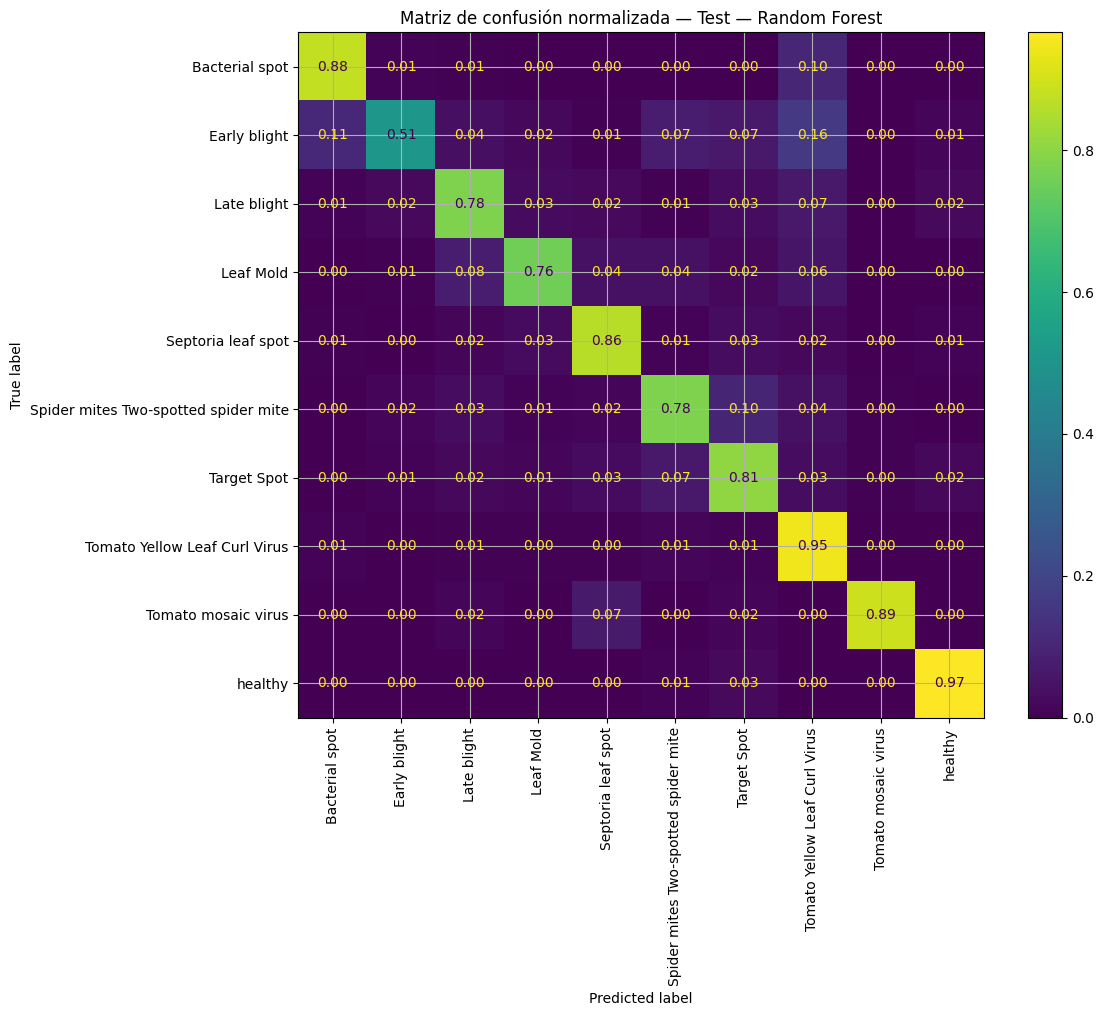


✅ Test evaluado únicamente después de bloquear el campeón.


In [ ]:
# ============================================================
# 6.10 — EVALUACIÓN FINAL DEL CAMPEÓN SOBRE TEST
# ============================================================
#
# REGLA:
#
# El campeón YA fue seleccionado.
#
# Test:
#
#     - NO cambia el modelo elegido;
#     - NO ajusta hiperparámetros;
#     - NO modifica features;
#     - NO modifica preprocessing.
#
# Su única finalidad es estimar generalización final.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from IPython.display import display


# ============================================================
# 2. VERIFICAR OBJETOS
# ============================================================

objetos_test_requeridos = [
    "pipeline_campeon_6_10",
    "MODELO_CAMPEON_6_10",
    "X_test",
    "y_test"
]


faltantes_test = [
    objeto
    for objeto in objetos_test_requeridos
    if objeto not in globals()
]


if faltantes_test:

    raise NameError(
        "Faltan objetos necesarios para evaluar Test: "
        f"{faltantes_test}"
    )


# ============================================================
# 3. PREDICCIÓN FINAL
# ============================================================

y_test_pred_campeon_6_10 = (
    pipeline_campeon_6_10
    .predict(
        X_test
    )
)


y_test_proba_campeon_6_10 = (
    pipeline_campeon_6_10
    .predict_proba(
        X_test
    )
)


# ============================================================
# 4. CLASES
# ============================================================

modelo_final_interno_6_10 = (
    pipeline_campeon_6_10
    .named_steps[
        "model"
    ]
)


clases_campeon_6_10 = (
    modelo_final_interno_6_10
    .classes_
)


# ============================================================
# 5. MÉTRICAS TEST
# ============================================================

test_accuracy_6_10 = accuracy_score(
    y_test,
    y_test_pred_campeon_6_10
)


test_precision_macro_6_10 = (
    precision_score(
        y_test,
        y_test_pred_campeon_6_10,
        average="macro",
        zero_division=0
    )
)


test_recall_macro_6_10 = recall_score(
    y_test,
    y_test_pred_campeon_6_10,
    average="macro",
    zero_division=0
)


test_f1_macro_6_10 = f1_score(
    y_test,
    y_test_pred_campeon_6_10,
    average="macro",
    zero_division=0
)


test_f1_weighted_6_10 = f1_score(
    y_test,
    y_test_pred_campeon_6_10,
    average="weighted",
    zero_division=0
)


test_balanced_accuracy_6_10 = (
    balanced_accuracy_score(
        y_test,
        y_test_pred_campeon_6_10
    )
)


test_roc_auc_macro_6_10 = (
    roc_auc_score(
        y_test,
        y_test_proba_campeon_6_10,
        labels=clases_campeon_6_10,
        multi_class="ovr",
        average="macro"
    )
)


test_roc_auc_weighted_6_10 = (
    roc_auc_score(
        y_test,
        y_test_proba_campeon_6_10,
        labels=clases_campeon_6_10,
        multi_class="ovr",
        average="weighted"
    )
)


# ============================================================
# 6. TABLA TEST
# ============================================================

df_test_campeon_6_10 = pd.DataFrame(
    {
        "Modelo": [
            MODELO_CAMPEON_6_10
        ],

        "Accuracy Test": [
            test_accuracy_6_10
        ],

        "Precision macro Test": [
            test_precision_macro_6_10
        ],

        "Recall macro Test": [
            test_recall_macro_6_10
        ],

        "F1 macro Test": [
            test_f1_macro_6_10
        ],

        "F1 weighted Test": [
            test_f1_weighted_6_10
        ],

        "Balanced Accuracy Test": [
            test_balanced_accuracy_6_10
        ],

        "ROC-AUC macro Test": [
            test_roc_auc_macro_6_10
        ],

        "ROC-AUC weighted Test": [
            test_roc_auc_weighted_6_10
        ]
    }
)


print("=" * 110)
print("EVALUACIÓN FINAL DEL MODELO CAMPEÓN — TEST")
print("=" * 110)


display(
    df_test_campeon_6_10.style.format(
        {
            "Accuracy Test": "{:.4f}",
            "Precision macro Test": "{:.4f}",
            "Recall macro Test": "{:.4f}",
            "F1 macro Test": "{:.4f}",
            "F1 weighted Test": "{:.4f}",
            "Balanced Accuracy Test": "{:.4f}",
            "ROC-AUC macro Test": "{:.4f}",
            "ROC-AUC weighted Test": "{:.4f}"
        }
    )
)


# ============================================================
# 7. BRECHA VALIDATION — TEST
# ============================================================

f1_validation_campeon_6_10 = float(
    df_ranking_6_10.loc[
        df_ranking_6_10[
            "Modelo"
        ]
        ==
        MODELO_CAMPEON_6_10,

        "Validation F1 macro"
    ]
    .iloc[0]
)


BRECHA_F1_VAL_TEST_6_10 = abs(
    f1_validation_campeon_6_10
    -
    test_f1_macro_6_10
)


print(
    f"\nF1 macro Validation : "
    f"{f1_validation_campeon_6_10:.4f}"
)


print(
    f"F1 macro Test       : "
    f"{test_f1_macro_6_10:.4f}"
)


print(
    f"|Validation - Test| : "
    f"{BRECHA_F1_VAL_TEST_6_10:.4f}"
)


# ============================================================
# 8. MATRIZ DE CONFUSIÓN TEST
# ============================================================

cm_test_6_10 = confusion_matrix(
    y_test,
    y_test_pred_campeon_6_10,
    labels=clases_campeon_6_10,
    normalize="true"
)


etiquetas_test_6_10 = [
    str(clase)
    .replace(
        "Tomato___",
        ""
    )
    .replace(
        "_",
        " "
    )
    for clase
    in clases_campeon_6_10
]


fig, ax = plt.subplots(
    figsize=(12, 10)
)


disp_test_6_10 = ConfusionMatrixDisplay(
    confusion_matrix=cm_test_6_10,
    display_labels=etiquetas_test_6_10
)


disp_test_6_10.plot(
    ax=ax,
    xticks_rotation=90,
    values_format=".2f"
)


ax.set_title(
    f"Matriz de confusión normalizada — Test — "
    f"{MODELO_CAMPEON_6_10}"
)


plt.tight_layout()

plt.show()


# ============================================================
# 9. CONTROLES
# ============================================================

assert (
    len(
        y_test_pred_campeon_6_10
    )
    ==
    len(
        y_test
    )
)


assert (
    0
    <=
    test_f1_macro_6_10
    <=
    1
)


assert (
    0
    <=
    test_roc_auc_macro_6_10
    <=
    1
)


print(
    "\n✅ Test evaluado únicamente después "
    "de bloquear el campeón."
)

In [ ]:
# ============================================================
# 6.10 — TABLA FINAL DE SELECCIÓN
# ============================================================


# ============================================================
# 1. DATOS DEL BASELINE
# ============================================================

if "df_resultados_baseline" in globals():

    f1_baseline_final = float(
        df_resultados_baseline[
            "F1 macro"
        ]
        .iloc[0]
    )

else:

    f1_baseline_final = 0.0456


# ============================================================
# 2. RECUPERAR RESULTADOS DE LOS DOS MODELOS
# ============================================================

fila_lr = (
    df_ranking_6_10[
        df_ranking_6_10[
            "Modelo"
        ]
        ==
        "Regresión Logística"
    ]
    .iloc[0]
)


fila_rf = (
    df_ranking_6_10[
        df_ranking_6_10[
            "Modelo"
        ]
        ==
        "Random Forest"
    ]
    .iloc[0]
)


# ============================================================
# 3. TABLA FINAL
# ============================================================
#
# IMPORTANTE:
#
# Solo el campeón posee métrica Test porque Test no fue
# utilizado para seleccionar entre los candidatos.
#
# ============================================================

df_seleccion_final_6_10 = pd.DataFrame(
    {
        "Modelo": [
            "Baseline",
            "Regresión Logística",
            "Random Forest"
        ],

        "CV": [
            "—",

            (
                f"{fila_lr['CV F1 macro media']:.4f} "
                f"± {fila_lr['CV F1 macro std']:.4f}"
            ),

            (
                f"{fila_rf['CV F1 macro media']:.4f} "
                f"± {fila_rf['CV F1 macro std']:.4f}"
            )
        ],

        "Validation": [
            f"F1 = {f1_baseline_final:.4f}",

            (
                f"F1 = "
                f"{fila_lr['Validation F1 macro']:.4f}"
            ),

            (
                f"F1 = "
                f"{fila_rf['Validation F1 macro']:.4f}"
            )
        ],

        "Test": [
            "No usado",
            "No usado",
            f"F1 = {test_f1_macro_6_10:.4f}"
        ],

        "Interpretabilidad": [
            "Alta",
            "Alta",
            "Media"
        ],

        "Tiempo": [
            "Muy bajo",
            fila_lr[
                "Costo temporal"
            ],
            fila_rf[
                "Costo temporal"
            ]
        ],

        "Selección": [
            "Referencia",
            "Finalista",
            "CAMPEÓN"
        ]
    }
)


print("=" * 110)
print("TABLA FINAL — SELECCIÓN DEL MODELO CAMPEÓN")
print("=" * 110)


display(
    df_seleccion_final_6_10
)

TABLA FINAL — SELECCIÓN DEL MODELO CAMPEÓN


,Modelo,CV,Validation,Test,Interpretabilidad,Tiempo,Selección
0,Baseline,—,F1 = 0.0456,No usado,Alta,Muy bajo,Referencia
1,Regresión Logística,0.7095 ± 0.0018,F1 = 0.7066,No usado,Alta,Bajo,Finalista
2,Random Forest,0.8050 ± 0.0023,F1 = 0.8092,F1 = 0.8274,Media,Medio,CAMPEÓN


## 6.10.12 Interpretación de la selección

La selección del modelo campeón se realizó antes de consultar el conjunto Test.

## Comparación con Regresión Logística

Esta sección resume comparación con Regresión Logística y su función dentro del proyecto MLOps.

## Estabilidad

Ambos modelos presentaron desviaciones estándar reducidas en Cross Validation.

## Costo computacional

Random Forest requiere mayor tiempo de entrenamiento.

## Interpretabilidad

La Regresión Logística continúa siendo más interpretable debido a sus coeficientes.

## Modelo campeón

Esta sección resume modelo campeón y su función dentro del proyecto MLOps.

## Decisión final

Esta sección resume decisión final y su función dentro del proyecto MLOps.


## 6.11 Empaquetado del modelo

Una vez seleccionado y evaluado el modelo campeón, el siguiente paso consiste en.

## 6.11.1 Modelo empaquetado

El artefacto final debe conservar conjuntamente.

## 6.11.2 Modelo campeón

La selección realizada en 6.10 determinó.

## 6.11.3 Consistencia entre modelo evaluado y modelo almacenado

El modelo almacenado debe representar exactamente la misma configuración que fue.

## 6.11.4 Features de entrada

El Pipeline recibe las 15 features visuales originales.

## 6.11.5 Features internas

Esta sección resume features internas y su función dentro del proyecto MLOps.

## 6.11.6 Variable objetivo

correspondiente a una clasificación supervisada multiclase de etiqueta única.

## 6.11.7 Tamaños de muestra

Esta sección resume tamaños de muestra y su función dentro del proyecto MLOps.

## 6.11.8 Hiperparámetros del modelo campeón

El Random Forest fue configurado con los principales parámetros.

## 6.11.9 Métricas de Cross Validation

Estas métricas describen la estabilidad observada dentro de Train.

## 6.11.10 Métricas de Validation

Esta sección resume métricas de Validation y su función dentro del proyecto MLOps.

## 6.11.11 Evaluación final sobre Test

Después de bloquear Random Forest como campeón, se realizó una única evaluación final.

## 6.11.12 Versionado

El primer artefacto formal del modelo se registrará como.

## 6.11.13 Metadatos del artefacto

El archivo train_metrics.json registrará.

## 6.11.14 Integridad mediante SHA-256

Después de almacenar el modelo se calculará.

## 6.11.15 Resultado esperado

Al finalizar esta sección deberán existir.


In [ ]:
# ============================================================
# FASE 2 — 6.11 EMPAQUETADO
# PREPARAR TRANSFORMER IMPORTABLE PARA PRODUCCIÓN
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Mover conceptualmente FeatureEngineeringProduccion desde
# __main__ / notebook hacia:
#
#       src/transformers.py
#
# Esto permite que joblib.load() pueda reconstruir el Pipeline
# desde otro proceso, por ejemplo:
#
#       api/app.py
#
# Las transformaciones son exactamente las utilizadas en 6.2:
#
#       h_mean
#           -> h_sin
#           -> h_cos
#
#       laplacian_variance
#           -> laplacian_log1p
#
# ============================================================


from pathlib import Path
import textwrap
import importlib


# ============================================================
# 1. CREAR ESTRUCTURA src/
# ============================================================

SRC_DIR_6_11 = Path("src")

SRC_DIR_6_11.mkdir(
    parents=True,
    exist_ok=True
)


# Convertir src en paquete importable.
(
    SRC_DIR_6_11
    /
    "__init__.py"
).touch(
    exist_ok=True
)


# ============================================================
# 2. CÓDIGO DEL TRANSFORMER
# ============================================================

CODIGO_TRANSFORMER_6_11 = textwrap.dedent(
    r'''
    import numpy as np
    import pandas as pd

    from sklearn.base import (
        BaseEstimator,
        TransformerMixin
    )

    from sklearn.utils.validation import (
        check_is_fitted
    )


    class FeatureEngineeringProduccion(
        BaseEstimator,
        TransformerMixin
    ):
        """
        Feature Engineering determinista utilizado
        por el Pipeline PlantVillage.

        Transformaciones
        ----------------
        h_mean:
            h_sin = sin(theta)
            h_cos = cos(theta)

        laplacian_variance:
            laplacian_log1p = log(1 + x)

        No aprende estadísticas del dataset.
        """

        def __init__(
            self,
            eliminar_h_mean=True,
            eliminar_laplacian_original=True
        ):

            self.eliminar_h_mean = (
                eliminar_h_mean
            )

            self.eliminar_laplacian_original = (
                eliminar_laplacian_original
            )


        def fit(
            self,
            X,
            y=None
        ):

            if not isinstance(
                X,
                pd.DataFrame
            ):

                raise TypeError(
                    "FeatureEngineeringProduccion "
                    "requiere un pandas.DataFrame."
                )


            columnas_requeridas = {
                "h_mean",
                "laplacian_variance"
            }


            faltantes = (
                columnas_requeridas
                -
                set(
                    X.columns
                )
            )


            if faltantes:

                raise KeyError(
                    "Faltan columnas requeridas: "
                    f"{sorted(faltantes)}"
                )


            self.feature_names_in_ = np.array(
                X.columns,
                dtype=object
            )


            self.n_features_in_ = (
                X.shape[1]
            )


            return self


        def transform(
            self,
            X
        ):

            check_is_fitted(
                self,
                attributes=[
                    "feature_names_in_"
                ]
            )


            if not isinstance(
                X,
                pd.DataFrame
            ):

                raise TypeError(
                    "La entrada debe ser un "
                    "pandas.DataFrame."
                )


            X_out = X.copy()


            # ================================================
            # HUE
            # ================================================

            h = pd.to_numeric(
                X_out[
                    "h_mean"
                ],
                errors="coerce"
            )


            if h.isna().any():

                raise ValueError(
                    "'h_mean' contiene valores faltantes "
                    "o no numéricos."
                )


            if (
                (h < 0)
                |
                (h >= 360)
            ).any():

                raise ValueError(
                    "'h_mean' debe estar en [0, 360)."
                )


            h_rad = np.deg2rad(
                h.to_numpy(
                    dtype=float
                )
            )


            X_out[
                "h_sin"
            ] = np.sin(
                h_rad
            )


            X_out[
                "h_cos"
            ] = np.cos(
                h_rad
            )


            # ================================================
            # LAPLACIAN VARIANCE
            # ================================================

            laplacian = pd.to_numeric(
                X_out[
                    "laplacian_variance"
                ],
                errors="coerce"
            )


            if laplacian.isna().any():

                raise ValueError(
                    "'laplacian_variance' contiene "
                    "valores faltantes o no numéricos."
                )


            if (
                laplacian < 0
            ).any():

                raise ValueError(
                    "'laplacian_variance' no puede "
                    "contener valores negativos."
                )


            X_out[
                "laplacian_log1p"
            ] = np.log1p(
                laplacian.to_numpy(
                    dtype=float
                )
            )


            # ================================================
            # ELIMINAR VARIABLES ORIGINALES
            # ================================================

            columnas_eliminar = []


            if self.eliminar_h_mean:

                columnas_eliminar.append(
                    "h_mean"
                )


            if self.eliminar_laplacian_original:

                columnas_eliminar.append(
                    "laplacian_variance"
                )


            X_out = X_out.drop(
                columns=columnas_eliminar
            )


            return X_out


        def get_feature_names_out(
            self,
            input_features=None
        ):

            check_is_fitted(
                self,
                attributes=[
                    "feature_names_in_"
                ]
            )


            if input_features is None:

                features = list(
                    self.feature_names_in_
                )

            else:

                features = list(
                    input_features
                )


            if (
                self.eliminar_h_mean
                and
                "h_mean" in features
            ):

                features.remove(
                    "h_mean"
                )


            if (
                self.eliminar_laplacian_original
                and
                "laplacian_variance" in features
            ):

                features.remove(
                    "laplacian_variance"
                )


            features.extend(
                [
                    "h_sin",
                    "h_cos",
                    "laplacian_log1p"
                ]
            )


            return np.array(
                features,
                dtype=object
            )
    '''
)


# ============================================================
# 3. GUARDAR MÓDULO
# ============================================================

TRANSFORMER_PATH_6_11 = (
    SRC_DIR_6_11
    /
    "transformers.py"
)


TRANSFORMER_PATH_6_11.write_text(
    CODIGO_TRANSFORMER_6_11,
    encoding="utf-8"
)


# ============================================================
# 4. INVALIDAR CACHE DE IMPORTACIÓN
# ============================================================

importlib.invalidate_caches()


# ============================================================
# 5. IMPORTAR TRANSFORMER DE PRODUCCIÓN
# ============================================================

from src.transformers import (
    FeatureEngineeringProduccion
    as FeatureEngineeringProduccionDeploy
)


print("=" * 105)
print("6.11 — TRANSFORMER DE PRODUCCIÓN")
print("=" * 105)


print(
    f"Archivo creado : "
    f"{TRANSFORMER_PATH_6_11}"
)


print(
    "Clase importada: "
    f"{FeatureEngineeringProduccionDeploy.__module__}."
    f"{FeatureEngineeringProduccionDeploy.__name__}"
)


assert (
    FeatureEngineeringProduccionDeploy.__module__
    ==
    "src.transformers"
)


print(
    "\n✅ Transformer preparado para serialización "
    "y carga desde procesos independientes."
)

6.11 — TRANSFORMER DE PRODUCCIÓN
Archivo creado : src/transformers.py
Clase importada: src.transformers.FeatureEngineeringProduccion

✅ Transformer preparado para serialización y carga desde procesos independientes.


In [ ]:
# ============================================================
# FASE 2 — 6.11
# RECONSTRUIR PIPELINE PORTABLE PARA JOBLIB
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Crear un Pipeline funcionalmente equivalente a:
#
#       pipeline_campeon_6_10
#
# pero utilizando la clase:
#
#       src.transformers.FeatureEngineeringProduccion
#
# para garantizar que pueda cargarse desde FastAPI.
#
# NO se modifican:
#
# - features;
# - hiperparámetros;
# - Train;
# - random_state;
# - modelo seleccionado.
#
# ============================================================


import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)


# ============================================================
# 1. VERIFICAR OBJETOS
# ============================================================

objetos_requeridos_6_11 = [
    "pipeline_campeon_6_10",
    "MODELO_CAMPEON_6_10",
    "X_train",
    "X_val",
    "y_train",
    "y_val"
]


faltantes_6_11 = [
    objeto
    for objeto in objetos_requeridos_6_11
    if objeto not in globals()
]


if faltantes_6_11:

    raise NameError(
        "Faltan objetos requeridos para 6.11: "
        f"{faltantes_6_11}"
    )


assert (
    MODELO_CAMPEON_6_10
    ==
    "Random Forest"
), (
    "El campeón esperado en esta versión "
    "es Random Forest."
)


# ============================================================
# 2. FEATURES DE ENTRADA
# ============================================================

numeric_features_deploy_6_11 = list(
    X_train.columns
)


categorical_features_deploy_6_11 = []


assert (
    len(
        numeric_features_deploy_6_11
    )
    ==
    15
)


# ============================================================
# 3. PIPELINE NUMÉRICO
# ============================================================

numeric_pipeline_deploy_6_11 = Pipeline(
    steps=[
        (
            "feature_engineering",
            FeatureEngineeringProduccionDeploy(
                eliminar_h_mean=True,
                eliminar_laplacian_original=True
            )
        ),

        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ============================================================
# 4. PIPELINE CATEGÓRICO
# ============================================================
#
# Actualmente no existen features categóricas predictivas.
#
# Se conserva la arquitectura general para mantener
# compatibilidad con el diseño de 6.5.
# ============================================================

categorical_pipeline_deploy_6_11 = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# ============================================================
# 5. COLUMNTRANSFORMER
# ============================================================

preprocessor_deploy_6_11 = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline_deploy_6_11,
            numeric_features_deploy_6_11
        ),

        (
            "cat",
            categorical_pipeline_deploy_6_11,
            categorical_features_deploy_6_11
        )
    ],

    remainder="drop",

    verbose_feature_names_out=True
)


# ============================================================
# 6. COPIAR EXACTAMENTE EL MODELO CAMPEÓN
# ============================================================
#
# clone() conserva los hiperparámetros del Random Forest,
# pero genera una instancia limpia.
#
# ============================================================

modelo_campeon_deploy_6_11 = clone(
    pipeline_campeon_6_10
    .named_steps[
        "model"
    ]
)


# ============================================================
# 7. CONSTRUIR PIPELINE PORTABLE
# ============================================================

pipeline_deploy_6_11 = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_deploy_6_11
        ),

        (
            "model",
            modelo_campeon_deploy_6_11
        )
    ]
)


# ============================================================
# 8. ENTRENAR CON EL MISMO TRAIN
# ============================================================
#
# NO se incorpora Validation.
# NO se incorpora Test.
#
# Esto mantiene consistencia con el modelo evaluado.
#
# ============================================================

pipeline_deploy_6_11.fit(
    X_train,
    y_train
)


# ============================================================
# 9. COMPROBAR EQUIVALENCIA EN VALIDATION
# ============================================================

predicciones_campeon_original_6_11 = (
    pipeline_campeon_6_10
    .predict(
        X_val
    )
)


predicciones_pipeline_deploy_6_11 = (
    pipeline_deploy_6_11
    .predict(
        X_val
    )
)


ACUERDO_VALIDATION_6_11 = float(
    np.mean(
        predicciones_campeon_original_6_11
        ==
        predicciones_pipeline_deploy_6_11
    )
)


print("=" * 105)
print("VERIFICACIÓN DE EQUIVALENCIA")
print("=" * 105)


print(
    f"Acuerdo de predicciones Validation : "
    f"{ACUERDO_VALIDATION_6_11:.4%}"
)


assert (
    ACUERDO_VALIDATION_6_11
    ==
    1.0
), (
    "El Pipeline de despliegue no reproduce "
    "las predicciones del campeón."
)


# ============================================================
# 10. COMPROBACIÓN CONTRA PREDICCIONES TEST YA GUARDADAS
# ============================================================
#
# No se utiliza y_test.
#
# Solo se verifica que el nuevo artefacto produzca las mismas
# predicciones que el campeón ya evaluado en 6.10.
#
# ============================================================

if (
    "y_test_pred_campeon_6_10"
    in globals()
    and
    "X_test"
    in globals()
):

    pred_test_deploy_6_11 = (
        pipeline_deploy_6_11
        .predict(
            X_test
        )
    )


    ACUERDO_TEST_6_11 = float(
        np.mean(
            pred_test_deploy_6_11
            ==
            y_test_pred_campeon_6_10
        )
    )


    print(
        f"Acuerdo de predicciones Test       : "
        f"{ACUERDO_TEST_6_11:.4%}"
    )


    assert (
        ACUERDO_TEST_6_11
        ==
        1.0
    )

else:

    ACUERDO_TEST_6_11 = None


# ============================================================
# 11. FEATURES INTERNAS
# ============================================================

features_internas_deploy_6_11 = (
    pipeline_deploy_6_11
    .named_steps[
        "preprocessor"
    ]
    .get_feature_names_out()
)


print(
    f"\nFeatures de entrada : "
    f"{X_train.shape[1]}"
)


print(
    f"Features internas   : "
    f"{len(features_internas_deploy_6_11)}"
)


assert (
    len(
        features_internas_deploy_6_11
    )
    ==
    16
)


# ============================================================
# 12. PIPELINE FINAL OFICIAL
# ============================================================

pipeline_final_6_11 = (
    pipeline_deploy_6_11
)


print(
    "\n✅ Pipeline portable construido."
)

print(
    "✅ Configuración del campeón conservada."
)

print(
    "✅ Predicciones equivalentes verificadas."
)

VERIFICACIÓN DE EQUIVALENCIA
Acuerdo de predicciones Validation : 100.0000%
Acuerdo de predicciones Test       : 100.0000%

Features de entrada : 15
Features internas   : 16

✅ Pipeline portable construido.
✅ Configuración del campeón conservada.
✅ Predicciones equivalentes verificadas.


In [ ]:
# ============================================================
# FASE 2 — 6.11 EMPAQUETADO
# ============================================================
#
# PRODUCTOS:
#
#       models/model.joblib
#       models/train_metrics.json
#
# REGISTRA:
#
# - modelo;
# - versión;
# - Pipeline;
# - features;
# - target;
# - clases;
# - hiperparámetros;
# - tamaños de muestra;
# - protocolo de split;
# - métricas CV;
# - métricas Validation;
# - métricas Test;
# - tiempos;
# - versiones de librerías;
# - SHA-256;
# - tamaño real del artefacto.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path
from datetime import datetime, timezone

import hashlib
import json
import platform

import joblib
import numpy as np
import pandas as pd
import sklearn
import scipy

from IPython.display import display


# ============================================================
# 2. CONFIGURACIÓN DE VERSIÓN
# ============================================================
#
# Primera versión formal del modelo empaquetado.
#
# Si posteriormente se cambia:
#
# - algoritmo;
# - features;
# - preprocessing;
# - dataset;
# - hiperparámetros;
#
# deberá actualizarse esta versión.
#
# ============================================================

MODEL_VERSION_6_11 = "1.0.0"

METADATA_SCHEMA_VERSION_6_11 = "1.0"


# ============================================================
# 3. DIRECTORIO DE MODELOS
# ============================================================

MODELS_DIR_6_11 = Path(
    "models"
)


MODELS_DIR_6_11.mkdir(
    parents=True,
    exist_ok=True
)


MODEL_PATH_6_11 = (
    MODELS_DIR_6_11
    /
    "model.joblib"
)


METRICS_PATH_6_11 = (
    MODELS_DIR_6_11
    /
    "train_metrics.json"
)


# ============================================================
# 4. VERIFICAR OBJETOS
# ============================================================

objetos_empaquetado_6_11 = [
    "pipeline_final_6_11",
    "MODELO_CAMPEON_6_10",
    "df_comparacion_modelos_6_7",
    "df_metricas_6_8",
    "df_test_campeon_6_10",
    "X",
    "y",
    "X_train",
    "X_val",
    "X_test",
    "y_train",
    "y_val",
    "y_test"
]


faltantes_empaquetado_6_11 = [
    objeto
    for objeto in objetos_empaquetado_6_11
    if objeto not in globals()
]


if faltantes_empaquetado_6_11:

    raise NameError(
        "Faltan objetos necesarios para empaquetar: "
        f"{faltantes_empaquetado_6_11}"
    )


# ============================================================
# 5. IDENTIFICAR MODELO INTERNO
# ============================================================

modelo_final_6_11 = (
    pipeline_final_6_11
    .named_steps[
        "model"
    ]
)


preprocessor_final_6_11 = (
    pipeline_final_6_11
    .named_steps[
        "preprocessor"
    ]
)


# ============================================================
# 6. FEATURES
# ============================================================

features_entrada_6_11 = [
    str(feature)
    for feature
    in X_train.columns
]


features_internas_6_11 = [
    str(feature)
    for feature
    in preprocessor_final_6_11
    .get_feature_names_out()
]


# ============================================================
# 7. TARGET
# ============================================================

TARGET_6_11 = globals().get(
    "TARGET_FASE2",
    globals().get(
        "TARGET",
        "clase"
    )
)


clases_6_11 = [
    str(clase)
    for clase
    in modelo_final_6_11.classes_
]


# ============================================================
# 8. RECUPERAR FILAS DE MÉTRICAS
# ============================================================

fila_cv_val_6_11 = (
    df_comparacion_modelos_6_7[
        df_comparacion_modelos_6_7[
            "Modelo"
        ]
        ==
        MODELO_CAMPEON_6_10
    ]
    .iloc[0]
)


fila_val_6_11 = (
    df_metricas_6_8[
        df_metricas_6_8[
            "Modelo"
        ]
        ==
        MODELO_CAMPEON_6_10
    ]
    .iloc[0]
)


fila_test_6_11 = (
    df_test_campeon_6_10
    .iloc[0]
)


# ============================================================
# 9. BASELINE
# ============================================================

if "df_resultados_baseline" in globals():

    fila_baseline_6_11 = (
        df_resultados_baseline
        .iloc[0]
    )


    metricas_baseline_6_11 = {
        "accuracy": float(
            fila_baseline_6_11[
                "Accuracy"
            ]
        ),

        "precision_macro": float(
            fila_baseline_6_11[
                "Precision macro"
            ]
        ),

        "recall_macro": float(
            fila_baseline_6_11[
                "Recall macro"
            ]
        ),

        "f1_macro": float(
            fila_baseline_6_11[
                "F1 macro"
            ]
        ),

        "balanced_accuracy": float(
            fila_baseline_6_11[
                "Balanced Accuracy"
            ]
        )
    }

else:

    metricas_baseline_6_11 = None


# ============================================================
# 10. FUNCIÓN PARA HACER OBJETOS JSON-SERIALIZABLES
# ============================================================

def convertir_json_6_11(
    objeto
):

    if isinstance(
        objeto,
        dict
    ):

        return {
            str(k):
            convertir_json_6_11(v)
            for k, v
            in objeto.items()
        }


    if isinstance(
        objeto,
        (
            list,
            tuple,
            set
        )
    ):

        return [
            convertir_json_6_11(v)
            for v
            in objeto
        ]


    if isinstance(
        objeto,
        np.ndarray
    ):

        return objeto.tolist()


    if isinstance(
        objeto,
        np.generic
    ):

        return objeto.item()


    if isinstance(
        objeto,
        Path
    ):

        return str(
            objeto
        )


    if objeto is None:

        return None


    if isinstance(
        objeto,
        (
            str,
            int,
            float,
            bool
        )
    ):

        return objeto


    return str(
        objeto
    )


# ============================================================
# 11. FINGERPRINT DEL DATASET
# ============================================================
#
# Se genera una huella del dataset utilizado.
#
# No sustituye un sistema formal de versionado de datos,
# pero permite detectar cambios.
#
# ============================================================

df_fingerprint_6_11 = pd.concat(
    [
        X,
        y.rename(
            TARGET_6_11
        )
    ],
    axis=1
)


hash_dataset_pandas_6_11 = (
    pd.util
    .hash_pandas_object(
        df_fingerprint_6_11,
        index=True
    )
    .values
    .tobytes()
)


DATASET_SHA256_6_11 = (
    hashlib
    .sha256(
        hash_dataset_pandas_6_11
    )
    .hexdigest()
)


# ============================================================
# 12. GUARDAR EL PIPELINE CAMPEÓN
# ============================================================
#
# Equivalente conceptual a:
#
# joblib.dump(
#     pipeline,
#     "models/model.joblib"
# )
#
# pero aquí se guarda explícitamente el CAMPEÓN.
#
# ============================================================

joblib.dump(
    pipeline_final_6_11,
    MODEL_PATH_6_11
)


# ============================================================
# 13. TAMAÑO REAL DEL MODELO
# ============================================================

MODEL_SIZE_BYTES_6_11 = (
    MODEL_PATH_6_11
    .stat()
    .st_size
)


MODEL_SIZE_MB_6_11 = (
    MODEL_SIZE_BYTES_6_11
    /
    (
        1024 ** 2
    )
)


# ============================================================
# 14. SHA-256 DEL ARTEFACTO
# ============================================================

sha256_modelo_6_11 = (
    hashlib
    .sha256()
)


with open(
    MODEL_PATH_6_11,
    "rb"
) as archivo:

    for bloque in iter(
        lambda:
        archivo.read(
            1024 * 1024
        ),
        b""
    ):

        sha256_modelo_6_11.update(
            bloque
        )


MODEL_SHA256_6_11 = (
    sha256_modelo_6_11
    .hexdigest()
)


# ============================================================
# 15. INTERPRETABILIDAD — RESUMEN
# ============================================================

interpretabilidad_6_11 = {
    "nivel": "Media",
    "metodos": [
        "feature_importances_",
        "permutation_importance"
    ],
    "shap": "No ejecutado; opcional"
}


if (
    "df_feature_importance_rf_6_9"
    in globals()
    and
    not df_feature_importance_rf_6_9.empty
):

    interpretabilidad_6_11[
        "feature_importance_top"
    ] = {

        "feature": str(
            df_feature_importance_rf_6_9
            .iloc[0][
                "Feature"
            ]
        ),

        "importance": float(
            df_feature_importance_rf_6_9
            .iloc[0][
                "Feature Importance"
            ]
        )
    }


if (
    "df_permutation_rf_6_9"
    in globals()
    and
    not df_permutation_rf_6_9.empty
):

    interpretabilidad_6_11[
        "permutation_importance_top"
    ] = {

        "feature": str(
            df_permutation_rf_6_9
            .iloc[0][
                "Feature"
            ]
        ),

        "importance_mean": float(
            df_permutation_rf_6_9
            .iloc[0][
                "Importancia media"
            ]
        ),

        "importance_std": float(
            df_permutation_rf_6_9
            .iloc[0][
                "Importancia std"
            ]
        )
    }


# ============================================================
# 16. METADATOS COMPLETOS
# ============================================================

metadata_6_11 = {

    # --------------------------------------------------------
    # IDENTIDAD
    # --------------------------------------------------------

    "artifact": {

        "name": "PlantVillage Tomato Classification",

        "model_version": (
            MODEL_VERSION_6_11
        ),

        "metadata_schema_version": (
            METADATA_SCHEMA_VERSION_6_11
        ),

        "created_at_utc": (
            datetime
            .now(
                timezone.utc
            )
            .isoformat()
        ),

        "source_notebook": (
            "14_Topicos.ipynb"
        ),

        "model_path": str(
            MODEL_PATH_6_11
        ),

        "metrics_path": str(
            METRICS_PATH_6_11
        ),

        "model_size_bytes": (
            MODEL_SIZE_BYTES_6_11
        ),

        "model_size_mb": (
            MODEL_SIZE_MB_6_11
        ),

        "model_sha256": (
            MODEL_SHA256_6_11
        )
    },


    # --------------------------------------------------------
    # MODELO
    # --------------------------------------------------------

    "model": {

        "selected_model": (
            MODELO_CAMPEON_6_10
        ),

        "class": (
            modelo_final_6_11
            .__class__
            .__name__
        ),

        "module": (
            modelo_final_6_11
            .__class__
            .__module__
        ),

        "hyperparameters": (
            convertir_json_6_11(
                modelo_final_6_11
                .get_params(
                    deep=False
                )
            )
        )
    },


    # --------------------------------------------------------
    # PIPELINE
    # --------------------------------------------------------

    "pipeline": {

        "steps": [
            {
                "name": nombre,
                "class": paso.__class__.__name__,
                "module": paso.__class__.__module__
            }
            for nombre, paso
            in pipeline_final_6_11.steps
        ],

        "input_feature_count": (
            len(
                features_entrada_6_11
            )
        ),

        "transformed_feature_count": (
            len(
                features_internas_6_11
            )
        ),

        "feature_engineering": [
            "h_mean -> h_sin + h_cos",
            (
                "laplacian_variance "
                "-> laplacian_log1p"
            )
        ],

        "numeric_imputer": "median",

        "scaler": "StandardScaler",

        "categorical_features": []
    },


    # --------------------------------------------------------
    # FEATURES
    # --------------------------------------------------------

    "features": {

        "input": (
            features_entrada_6_11
        ),

        "transformed": (
            features_internas_6_11
        )
    },


    # --------------------------------------------------------
    # TARGET
    # --------------------------------------------------------

    "target": {

        "name": (
            TARGET_6_11
        ),

        "problem_type": (
            "multiclass_classification"
        ),

        "n_classes": (
            len(
                clases_6_11
            )
        ),

        "classes": (
            clases_6_11
        )
    },


    # --------------------------------------------------------
    # DATASET
    # --------------------------------------------------------

    "dataset": {

        "name": "PlantVillage",

        "n_total": int(
            len(X)
        ),

        "n_train": int(
            len(X_train)
        ),

        "n_validation": int(
            len(X_val)
        ),

        "n_test": int(
            len(X_test)
        ),

        "dataset_sha256": (
            DATASET_SHA256_6_11
        )
    },


    # --------------------------------------------------------
    # PROTOCOLO EXPERIMENTAL
    # --------------------------------------------------------

    "training_protocol": {

        "split_strategy": (
            "random_stratified"
        ),

        "train_fraction": 0.70,

        "validation_fraction": 0.15,

        "test_fraction": 0.15,

        "random_state": int(
            globals().get(
                "RANDOM_STATE",
                42
            )
        ),

        "cross_validation": {

            "type": (
                "StratifiedKFold"
            ),

            "n_splits": int(
                globals().get(
                    "N_FOLDS_CV",
                    3
                )
            ),

            "shuffle": True
        },

        "primary_metric": (
            "f1_macro"
        )
    },


    # --------------------------------------------------------
    # BASELINE
    # --------------------------------------------------------

    "baseline_validation": (
        metricas_baseline_6_11
    ),


    # --------------------------------------------------------
    # CROSS VALIDATION
    # --------------------------------------------------------

    "metrics_cross_validation": {

        "accuracy_mean": float(
            fila_cv_val_6_11[
                "CV Accuracy media"
            ]
        ),

        "accuracy_std": float(
            fila_cv_val_6_11[
                "CV Accuracy std"
            ]
        ),

        "f1_macro_mean": float(
            fila_cv_val_6_11[
                "CV F1 macro media"
            ]
        ),

        "f1_macro_std": float(
            fila_cv_val_6_11[
                "CV F1 macro std"
            ]
        ),

        "balanced_accuracy_mean": float(
            fila_cv_val_6_11[
                "CV Balanced Acc media"
            ]
        ),

        "balanced_accuracy_std": float(
            fila_cv_val_6_11[
                "CV Balanced Acc std"
            ]
        )
    },


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    "metrics_validation": {

        "accuracy": float(
            fila_val_6_11[
                "Accuracy"
            ]
        ),

        "precision_macro": float(
            fila_val_6_11[
                "Precision macro"
            ]
        ),

        "recall_macro": float(
            fila_val_6_11[
                "Recall macro"
            ]
        ),

        "f1_macro": float(
            fila_val_6_11[
                "F1 macro"
            ]
        ),

        "f1_weighted": float(
            fila_val_6_11[
                "F1 weighted"
            ]
        ),

        "balanced_accuracy": float(
            fila_val_6_11[
                "Balanced Accuracy"
            ]
        ),

        "roc_auc_macro_ovr": float(
            fila_val_6_11[
                "ROC-AUC macro OvR"
            ]
        ),

        "roc_auc_weighted_ovr": float(
            fila_val_6_11[
                "ROC-AUC weighted OvR"
            ]
        )
    },


    # --------------------------------------------------------
    # TEST FINAL
    # --------------------------------------------------------

    "metrics_test_final": {

        "accuracy": float(
            fila_test_6_11[
                "Accuracy Test"
            ]
        ),

        "precision_macro": float(
            fila_test_6_11[
                "Precision macro Test"
            ]
        ),

        "recall_macro": float(
            fila_test_6_11[
                "Recall macro Test"
            ]
        ),

        "f1_macro": float(
            fila_test_6_11[
                "F1 macro Test"
            ]
        ),

        "f1_weighted": float(
            fila_test_6_11[
                "F1 weighted Test"
            ]
        ),

        "balanced_accuracy": float(
            fila_test_6_11[
                "Balanced Accuracy Test"
            ]
        ),

        "roc_auc_macro_ovr": float(
            fila_test_6_11[
                "ROC-AUC macro Test"
            ]
        ),

        "roc_auc_weighted_ovr": float(
            fila_test_6_11[
                "ROC-AUC weighted Test"
            ]
        )
    },


    # --------------------------------------------------------
    # OPERACIÓN
    # --------------------------------------------------------

    "operational": {

        "training_time_seconds": float(
            fila_cv_val_6_11[
                "Tiempo fit (s)"
            ]
        ),

        "validation_prediction_seconds": float(
            fila_cv_val_6_11[
                "Tiempo pred Val (s)"
            ]
        ),

        "prediction_ms_per_observation": float(
            fila_cv_val_6_11[
                "Predicción ms/obs"
            ]
        ),

        "packaging_validation_agreement": (
            ACUERDO_VALIDATION_6_11
        ),

        "packaging_test_agreement": (
            ACUERDO_TEST_6_11
        )
    },


    # --------------------------------------------------------
    # INTERPRETABILIDAD
    # --------------------------------------------------------

    "interpretability": (
        interpretabilidad_6_11
    ),


    # --------------------------------------------------------
    # VERSIONES DEL ENTORNO
    # --------------------------------------------------------

    "environment": {

        "python": (
            platform.python_version()
        ),

        "numpy": (
            np.__version__
        ),

        "pandas": (
            pd.__version__
        ),

        "scikit_learn": (
            sklearn.__version__
        ),

        "scipy": (
            scipy.__version__
        ),

        "joblib": (
            joblib.__version__
        )
    }
}


# ============================================================
# 17. GARANTIZAR SERIALIZACIÓN JSON
# ============================================================

metadata_6_11 = convertir_json_6_11(
    metadata_6_11
)


# ============================================================
# 18. GUARDAR train_metrics.json
# ============================================================

with open(
    METRICS_PATH_6_11,
    "w",
    encoding="utf-8"
) as archivo_json:

    json.dump(
        metadata_6_11,
        archivo_json,
        ensure_ascii=False,
        indent=4
    )


# ============================================================
# 19. VERIFICAR ARCHIVOS
# ============================================================

assert (
    MODEL_PATH_6_11.exists()
)


assert (
    METRICS_PATH_6_11.exists()
)


# ============================================================
# 20. TABLA RESUMEN DE ARTEFACTOS
# ============================================================

df_artefactos_6_11 = pd.DataFrame(
    {
        "Artefacto": [
            "Modelo",
            "Metadatos"
        ],

        "Ruta": [
            str(
                MODEL_PATH_6_11
            ),
            str(
                METRICS_PATH_6_11
            )
        ],

        "Tamaño (MB)": [
            (
                MODEL_PATH_6_11
                .stat()
                .st_size
                /
                1024 ** 2
            ),

            (
                METRICS_PATH_6_11
                .stat()
                .st_size
                /
                1024 ** 2
            )
        ]
    }
)


print("=" * 110)
print("6.11 — ARTEFACTOS GENERADOS")
print("=" * 110)


display(
    df_artefactos_6_11.style.format(
        {
            "Tamaño (MB)": "{:.6f}"
        }
    )
)


# ============================================================
# 21. RESUMEN DEL METADATA
# ============================================================

df_metadata_resumen_6_11 = pd.DataFrame(
    {
        "Campo": [
            "Versión",
            "Modelo campeón",
            "Target",
            "N clases",
            "Features entrada",
            "Features internas",
            "N Train",
            "N Validation",
            "N Test",
            "F1 macro Validation",
            "F1 macro Test",
            "ROC-AUC macro Test",
            "SHA-256"
        ],

        "Valor": [
            MODEL_VERSION_6_11,
            MODELO_CAMPEON_6_10,
            TARGET_6_11,
            len(
                clases_6_11
            ),
            len(
                features_entrada_6_11
            ),
            len(
                features_internas_6_11
            ),
            len(
                X_train
            ),
            len(
                X_val
            ),
            len(
                X_test
            ),
            float(
                fila_val_6_11[
                    "F1 macro"
                ]
            ),
            float(
                fila_test_6_11[
                    "F1 macro Test"
                ]
            ),
            float(
                fila_test_6_11[
                    "ROC-AUC macro Test"
                ]
            ),
            MODEL_SHA256_6_11
        ]
    }
)


print(
    "\n" + "=" * 110
)

print(
    "RESUMEN DEL MODELO EMPAQUETADO"
)

print(
    "=" * 110
)


display(
    df_metadata_resumen_6_11
)


print(
    "\n✅ model.joblib generado."
)

print(
    "✅ train_metrics.json generado."
)

print(
    "✅ Metadatos y versiones registrados."
)

print(
    "✅ SHA-256 registrado."
)

6.11 — ARTEFACTOS GENERADOS


,Artefacto,Ruta,Tamaño (MB)
0,Modelo,models/model.joblib,95.203013
1,Metadatos,models/train_metrics.json,0.006278



RESUMEN DEL MODELO EMPAQUETADO


,Campo,Valor
0,Versión,1.0.0
1,Modelo campeón,Random Forest
2,Target,clase
3,N clases,10
4,Features entrada,15
5,Features internas,16
6,N Train,12702
7,N Validation,2722
8,N Test,2722
9,F1 macro Validation,0.8092



✅ model.joblib generado.
✅ train_metrics.json generado.
✅ Metadatos y versiones registrados.
✅ SHA-256 registrado.


In [ ]:
# ============================================================
# 6.11 — PRUEBA DE SERIALIZACIÓN
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Comprobar que:
#
#       model.joblib
#
# puede volver a cargarse y conserva el mismo comportamiento.
#
# ============================================================


import sys
import subprocess
import joblib
import numpy as np

from pathlib import Path


# ============================================================
# 1. RECARGAR EN EL PROCESO ACTUAL
# ============================================================

modelo_recargado_6_11 = joblib.load(
    MODEL_PATH_6_11
)


# ============================================================
# 2. PRUEBA DE PREDICCIÓN
# ============================================================

N_SMOKE_TEST_6_11 = min(
    25,
    len(
        X_val
    )
)


X_smoke_6_11 = (
    X_val
    .iloc[
        :N_SMOKE_TEST_6_11
    ]
    .copy()
)


pred_original_6_11 = (
    pipeline_final_6_11
    .predict(
        X_smoke_6_11
    )
)


pred_recargado_6_11 = (
    modelo_recargado_6_11
    .predict(
        X_smoke_6_11
    )
)


assert np.array_equal(
    pred_original_6_11,
    pred_recargado_6_11
)


print(
    "✅ Predicciones idénticas después de joblib.load()."
)


# ============================================================
# 3. PRUEBA EN INTÉRPRETE PYTHON INDEPENDIENTE
# ============================================================
#
# Este control es más fuerte que cargar el modelo dentro
# del mismo notebook.
#
# Simula conceptualmente lo que ocurrirá con FastAPI.
#
# ============================================================

PROJECT_ROOT_6_11 = (
    Path.cwd()
    .resolve()
)


MODEL_ABSOLUTE_PATH_6_11 = (
    MODEL_PATH_6_11
    .resolve()
)


codigo_subproceso_6_11 = f"""
import sys
from pathlib import Path

sys.path.insert(
    0,
    r'{PROJECT_ROOT_6_11}'
)

import joblib

modelo = joblib.load(
    r'{MODEL_ABSOLUTE_PATH_6_11}'
)

print(
    modelo.__class__.__name__
)

print(
    modelo.named_steps["model"].__class__.__name__
)
"""


resultado_subproceso_6_11 = subprocess.run(
    [
        sys.executable,
        "-c",
        codigo_subproceso_6_11
    ],

    cwd=str(
        PROJECT_ROOT_6_11
    ),

    capture_output=True,

    text=True
)


print(
    "\nSalida del intérprete independiente:"
)


print(
    resultado_subproceso_6_11.stdout
)


if (
    resultado_subproceso_6_11.returncode
    !=
    0
):

    print(
        resultado_subproceso_6_11.stderr
    )


assert (
    resultado_subproceso_6_11.returncode
    ==
    0
), (
    "El modelo no pudo cargarse desde "
    "un intérprete independiente."
)


# ============================================================
# 4. VERIFICAR JSON
# ============================================================

with open(
    METRICS_PATH_6_11,
    "r",
    encoding="utf-8"
) as archivo_json:

    metadata_recargada_6_11 = (
        json.load(
            archivo_json
        )
    )


assert (
    metadata_recargada_6_11[
        "model"
    ][
        "selected_model"
    ]
    ==
    "Random Forest"
)


assert (
    metadata_recargada_6_11[
        "target"
    ][
        "name"
    ]
    ==
    "clase"
)


assert (
    metadata_recargada_6_11[
        "features"
    ][
        "input"
    ]
    ==
    features_entrada_6_11
)


# ============================================================
# 5. CONTROL FINAL
# ============================================================

print(
    "\n" + "=" * 110
)

print(
    "CONTROL FINAL — 6.11 EMPAQUETADO"
)

print(
    "=" * 110
)


print(
    "✅ Pipeline campeón serializado."
)


print(
    "✅ Random Forest confirmado."
)


print(
    "✅ Feature Engineering incluido."
)


print(
    "✅ Preprocesamiento incluido."
)


print(
    "✅ 15 features de entrada registradas."
)


print(
    "✅ 16 features internas registradas."
)


print(
    "✅ Target y clases registrados."
)


print(
    "✅ Hiperparámetros registrados."
)


print(
    "✅ Métricas CV registradas."
)


print(
    "✅ Métricas Validation registradas."
)


print(
    "✅ Métricas Test registradas."
)


print(
    "✅ Tamaños de muestra registrados."
)


print(
    "✅ Versiones del entorno registradas."
)


print(
    "✅ SHA-256 registrado."
)


print(
    "✅ Carga mediante joblib verificada."
)


print(
    "✅ Carga desde proceso independiente verificada."
)


print(
    "=" * 110
)


print(
    "✅ 6.11 — EMPAQUETADO COMPLETADO"
)

✅ Predicciones idénticas después de joblib.load().

Salida del intérprete independiente:
Pipeline
RandomForestClassifier


CONTROL FINAL — 6.11 EMPAQUETADO
✅ Pipeline campeón serializado.
✅ Random Forest confirmado.
✅ Feature Engineering incluido.
✅ Preprocesamiento incluido.
✅ 15 features de entrada registradas.
✅ 16 features internas registradas.
✅ Target y clases registrados.
✅ Hiperparámetros registrados.
✅ Métricas CV registradas.
✅ Métricas Validation registradas.
✅ Métricas Test registradas.
✅ Tamaños de muestra registrados.
✅ Versiones del entorno registradas.
✅ SHA-256 registrado.
✅ Carga mediante joblib verificada.
✅ Carga desde proceso independiente verificada.
✅ 6.11 — EMPAQUETADO COMPLETADO


## 6.11.16 Interpretación del empaquetado

El modelo campeón seleccionado en 6.10 fue.

## Trazabilidad

Esta sección resume trazabilidad y su función dentro del proyecto MLOps.

## Consistencia entre evaluación y producción

La serialización fue validada comprobando.

## Modelo y métricas

El modelo empaquetado conserva los resultados de referencia.

## Importancia para Data Drift

La información almacenada en esta etapa será posteriormente necesaria para comparar.

## Versionado

La versión inicial queda establecida como.

## Cierre de la Fase 2

La Fase 2 queda cerrada cuando existen y han sido verificados.


## 7.1 Esquema de entrada de la API

La Fase 3 tiene como objetivo exponer el modelo empaquetado mediante un servicio.

## 7.1.1 Contrato entre cliente y modelo

recibe directamente las características visuales originales.

## 7.1.2 Features esperadas

El modelo recibe las siguientes 15 variables.

## 7.1.3 Por qué la API no recibe las 16 features internas

Esta sección resume por qué la API no recibe las 16 features internas y su función dentro del proyecto MLOps.

## 7.1.4 Validación mediante Pydantic

FastAPI utiliza Pydantic para validar los datos recibidos.

## 7.1.5 Variables RGB

representan intensidades medias normalizadas.

## 7.1.6 Hue

Esta sección resume hue y su función dentro del proyecto MLOps.

## 7.1.7 Saturación y valor

Esta sección resume saturación y valor y su función dentro del proyecto MLOps.

## 7.1.8 Excess Green

se deriva conceptualmente de los canales RGB mediante una expresión del tipo.

## 7.1.9 Brightness y contraste

Esta sección resume brightness y contraste y su función dentro del proyecto MLOps.

## 7.1.10 Laplacian Variance

representa una varianza asociada a información de bordes y nitidez.

## 7.1.11 Entropía

Esta sección resume entropía y su función dentro del proyecto MLOps.

## 7.1.12 Edge Density

La densidad de bordes representa una proporción.

## 7.1.13 Validación estricta

La API también deberá impedir columnas adicionales no definidas en el contrato.

## 7.1.14 Validación de valores no finitos

Esta sección resume validación de valores no finitos y su función dentro del proyecto MLOps.

## 7.1.15 Contrato final

El contrato de entrada puede representarse como.


In [ ]:
# ============================================================
# FASE 3 — SERVICIO DE INFERENCIA
# 7.1 ESQUEMA DE ENTRADA
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Crear:
#
#       api/schemas.py
#
# que contendrá:
#
#       PredictionRequest
#
# Este esquema describe exactamente las 15 features que
# espera models/model.joblib.
#
# NO recibe:
#
#       - target;
#       - ruta;
#       - archivo;
#       - h_sin;
#       - h_cos;
#       - laplacian_log1p.
#
# Las tres últimas se generan dentro del Pipeline.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path
import textwrap
import importlib


# ============================================================
# 2. CREAR DIRECTORIO api/
# ============================================================

API_DIR_7_1 = Path(
    "api"
)


API_DIR_7_1.mkdir(
    parents=True,
    exist_ok=True
)


# Convertir api/ en paquete Python.
(
    API_DIR_7_1
    /
    "__init__.py"
).touch(
    exist_ok=True
)


# ============================================================
# 3. DEFINIR CÓDIGO DEL ESQUEMA
# ============================================================

CODIGO_SCHEMA_7_1 = textwrap.dedent(
    '''
    import math

    from pydantic import (
        BaseModel,
        ConfigDict,
        Field,
        field_validator
    )


    class PredictionRequest(BaseModel):
        """
        Contrato de entrada para el modelo PlantVillage.

        El Pipeline espera 15 features visuales originales.

        Las transformaciones:

            h_mean
                -> h_sin
                -> h_cos

            laplacian_variance
                -> laplacian_log1p

        se ejecutan internamente en model.joblib.

        Por tanto, NO deben ser enviadas por el cliente.
        """

        # ====================================================
        # CONFIGURACIÓN PYDANTIC
        # ====================================================

        model_config = ConfigDict(
            extra="forbid",
            validate_assignment=True
        )


        # ====================================================
        # RGB — MEDIAS
        # ====================================================

        r_mean: float = Field(
            ...,
            ge=0.0,
            le=1.0,
            description=(
                "Media normalizada del canal rojo."
            )
        )


        g_mean: float = Field(
            ...,
            ge=0.0,
            le=1.0,
            description=(
                "Media normalizada del canal verde."
            )
        )


        b_mean: float = Field(
            ...,
            ge=0.0,
            le=1.0,
            description=(
                "Media normalizada del canal azul."
            )
        )


        # ====================================================
        # RGB — DESVIACIONES ESTÁNDAR
        # ====================================================

        r_std: float = Field(
            ...,
            ge=0.0,
            le=1.0,
            description=(
                "Desviación estándar normalizada "
                "del canal rojo."
            )
        )


        g_std: float = Field(
            ...,
            ge=0.0,
            le=1.0,
            description=(
                "Desviación estándar normalizada "
                "del canal verde."
            )
        )


        b_std: float = Field(
            ...,
            ge=0.0,
            le=1.0,
            description=(
                "Desviación estándar normalizada "
                "del canal azul."
            )
        )


        # ====================================================
        # HSV
        # ====================================================

        h_mean: float = Field(
            ...,
            ge=0.0,
            lt=360.0,
            description=(
                "Media circular de Hue en grados. "
                "Dominio [0, 360)."
            )
        )


        s_mean: float = Field(
            ...,
            ge=0.0,
            le=1.0,
            description=(
                "Saturación media normalizada."
            )
        )


        v_mean: float = Field(
            ...,
            ge=0.0,
            le=1.0,
            description=(
                "Value medio normalizado."
            )
        )


        # ====================================================
        # VEGETACIÓN
        # ====================================================

        excess_green: float = Field(
            ...,
            ge=-2.0,
            le=2.0,
            description=(
                "Índice Excess Green derivado "
                "de canales RGB normalizados."
            )
        )


        # ====================================================
        # BRILLO Y CONTRASTE
        # ====================================================

        brightness_mean: float = Field(
            ...,
            ge=0.0,
            le=1.0,
            description=(
                "Brillo medio normalizado."
            )
        )


        contrast_std: float = Field(
            ...,
            ge=0.0,
            le=1.0,
            description=(
                "Desviación estándar utilizada "
                "como medida de contraste."
            )
        )


        # ====================================================
        # NITIDEZ / TEXTURA
        # ====================================================

        laplacian_variance: float = Field(
            ...,
            ge=0.0,
            description=(
                "Varianza del Laplaciano. "
                "Debe ser no negativa."
            )
        )


        entropy: float = Field(
            ...,
            ge=0.0,
            le=8.0,
            description=(
                "Entropía de imagen."
            )
        )


        edge_density: float = Field(
            ...,
            ge=0.0,
            le=1.0,
            description=(
                "Proporción de píxeles asociados "
                "a bordes."
            )
        )


        # ====================================================
        # VALIDACIÓN GENERAL
        # ====================================================

        @field_validator("*")
        @classmethod
        def validar_valor_finito(
            cls,
            valor
        ):
            """
            Rechaza NaN, +Inf y -Inf.

            Los modelos de producción deben recibir
            valores numéricos finitos.
            """

            if not math.isfinite(
                float(valor)
            ):

                raise ValueError(
                    "Todos los valores deben ser "
                    "números finitos."
                )


            return valor
    '''
)


# ============================================================
# 4. GUARDAR ARCHIVO
# ============================================================

SCHEMA_PATH_7_1 = (
    API_DIR_7_1
    /
    "schemas.py"
)


SCHEMA_PATH_7_1.write_text(
    CODIGO_SCHEMA_7_1,
    encoding="utf-8"
)


# ============================================================
# 5. ACTUALIZAR SISTEMA DE IMPORTACIÓN
# ============================================================

importlib.invalidate_caches()


# ============================================================
# 6. IMPORTAR ESQUEMA
# ============================================================

from api.schemas import (
    PredictionRequest
)


# ============================================================
# 7. CONTROL
# ============================================================

print("=" * 105)
print("7.1 — ESQUEMA DE ENTRADA")
print("=" * 105)


print(
    f"Archivo creado : "
    f"{SCHEMA_PATH_7_1}"
)


print(
    "Clase          : "
    "PredictionRequest"
)


print(
    "N features     : "
    f"{len(PredictionRequest.model_fields)}"
)


assert (
    len(
        PredictionRequest.model_fields
    )
    ==
    15
)


print(
    "\n✅ api/schemas.py creado correctamente."
)

print(
    "✅ PredictionRequest contiene 15 features."
)

7.1 — ESQUEMA DE ENTRADA
Archivo creado : api/schemas.py
Clase          : PredictionRequest
N features     : 15

✅ api/schemas.py creado correctamente.
✅ PredictionRequest contiene 15 features.


In [ ]:
# ============================================================
# 7.1 — VALIDACIÓN DEL CONTRATO CONTRA EL MODELO EMPAQUETADO
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Comparar:
#
#     features registradas en train_metrics.json
#
# contra:
#
#     campos definidos en PredictionRequest
#
# Deben coincidir exactamente.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import json

from pathlib import Path


# ============================================================
# 2. RUTA DE METADATOS
# ============================================================

METADATA_PATH_7_1 = Path(
    "models/train_metrics.json"
)


if not METADATA_PATH_7_1.exists():

    raise FileNotFoundError(
        "No se encontró models/train_metrics.json. "
        "Ejecute previamente 6.11."
    )


# ============================================================
# 3. CARGAR METADATOS
# ============================================================

with open(
    METADATA_PATH_7_1,
    "r",
    encoding="utf-8"
) as archivo:

    metadata_7_1 = json.load(
        archivo
    )


# ============================================================
# 4. FEATURES DEL MODELO EMPAQUETADO
# ============================================================

features_modelo_7_1 = (
    metadata_7_1[
        "features"
    ][
        "input"
    ]
)


# ============================================================
# 5. FEATURES DEL ESQUEMA PYDANTIC
# ============================================================

features_schema_7_1 = list(
    PredictionRequest
    .model_fields
    .keys()
)


# ============================================================
# 6. COMPARAR
# ============================================================

features_faltantes_api_7_1 = [
    feature
    for feature
    in features_modelo_7_1
    if feature
    not in features_schema_7_1
]


features_sobrantes_api_7_1 = [
    feature
    for feature
    in features_schema_7_1
    if feature
    not in features_modelo_7_1
]


orden_identico_7_1 = (
    features_modelo_7_1
    ==
    features_schema_7_1
)


# ============================================================
# 7. RESULTADOS
# ============================================================

print("=" * 105)
print("VERIFICACIÓN MODELO ↔ API")
print("=" * 105)


print(
    f"Features modelo : "
    f"{len(features_modelo_7_1)}"
)


print(
    f"Features API    : "
    f"{len(features_schema_7_1)}"
)


print(
    f"Orden idéntico  : "
    f"{orden_identico_7_1}"
)


print(
    f"Faltantes API   : "
    f"{features_faltantes_api_7_1}"
)


print(
    f"Sobrantes API   : "
    f"{features_sobrantes_api_7_1}"
)


# ============================================================
# 8. CONTROLES
# ============================================================

assert (
    len(
        features_faltantes_api_7_1
    )
    ==
    0
), (
    "La API no contiene todas las features "
    "esperadas por el modelo."
)


assert (
    len(
        features_sobrantes_api_7_1
    )
    ==
    0
), (
    "La API contiene features no utilizadas "
    "por el modelo."
)


assert (
    orden_identico_7_1
), (
    "El orden del esquema no coincide con "
    "el contrato registrado en train_metrics.json."
)


print(
    "\n✅ Contrato de entrada consistente "
    "con train_metrics.json."
)

VERIFICACIÓN MODELO ↔ API
Features modelo : 15
Features API    : 15
Orden idéntico  : True
Faltantes API   : []
Sobrantes API   : []

✅ Contrato de entrada consistente con train_metrics.json.


In [ ]:
# ============================================================
# 7.1 — SMOKE TEST DEL ESQUEMA
# ============================================================
#
# Se utiliza una observación real de X_val únicamente
# para comprobar el contrato.
#
# NO se realiza entrenamiento.
# NO se consulta y_val.
#
# ============================================================


# ============================================================
# 1. VERIFICAR X_val
# ============================================================

if "X_val" not in globals():

    raise NameError(
        "No se encontró X_val."
    )


# ============================================================
# 2. SELECCIONAR UNA OBSERVACIÓN
# ============================================================

ejemplo_entrada_7_1 = (
    X_val
    .iloc[0]
    .to_dict()
)


# ============================================================
# 3. VALIDAR MEDIANTE PYDANTIC
# ============================================================

request_ejemplo_7_1 = PredictionRequest(
    **ejemplo_entrada_7_1
)


# ============================================================
# 4. CONVERTIR A DICCIONARIO
# ============================================================

request_dict_7_1 = (
    request_ejemplo_7_1
    .model_dump()
)


print("=" * 105)
print("SMOKE TEST — PredictionRequest")
print("=" * 105)


print(
    request_ejemplo_7_1
)


print(
    "\nN variables validadas:"
)


print(
    len(
        request_dict_7_1
    )
)


assert (
    len(
        request_dict_7_1
    )
    ==
    15
)


assert (
    list(
        request_dict_7_1.keys()
    )
    ==
    list(
        X_val.columns
    )
)


print(
    "\n✅ Una observación real de Validation "
    "cumple el esquema de la API."
)

SMOKE TEST — PredictionRequest
r_mean=0.5487552881240845 g_mean=0.5177183747291565 b_mean=0.39300358295440674 r_std=0.1464700847864151 g_std=0.14364178478717804 b_std=0.2171492725610733 h_mean=7.303680419921875 s_mean=0.3574337959289551 v_mean=0.5601860284805298 excess_green=0.09367784112691879 brightness_mean=0.5127809047698975 contrast_std=0.14203853905200958 laplacian_variance=6709.710217198124 entropy=6.915067493986546 edge_density=0.208770751953125

N variables validadas:
15

✅ Una observación real de Validation cumple el esquema de la API.


In [ ]:
# ============================================================
# 7.1 — PRUEBAS DE VALIDACIÓN
# ============================================================


from pydantic import ValidationError


# ============================================================
# 1. CASO VÁLIDO
# ============================================================

entrada_valida_7_1 = (
    X_val
    .iloc[0]
    .to_dict()
)


PredictionRequest(
    **entrada_valida_7_1
)


print(
    "✅ Caso válido aceptado."
)


# ============================================================
# 2. HUE FUERA DE RANGO
# ============================================================

entrada_hue_invalido_7_1 = (
    entrada_valida_7_1.copy()
)


entrada_hue_invalido_7_1[
    "h_mean"
] = 400.0


try:

    PredictionRequest(
        **entrada_hue_invalido_7_1
    )


except ValidationError:

    print(
        "✅ h_mean = 400 correctamente rechazado."
    )


# ============================================================
# 3. LAPLACIAN NEGATIVO
# ============================================================

entrada_laplacian_invalido_7_1 = (
    entrada_valida_7_1.copy()
)


entrada_laplacian_invalido_7_1[
    "laplacian_variance"
] = -10.0


try:

    PredictionRequest(
        **entrada_laplacian_invalido_7_1
    )


except ValidationError:

    print(
        "✅ laplacian_variance negativo "
        "correctamente rechazado."
    )


# ============================================================
# 4. FEATURE EXTRA
# ============================================================

entrada_extra_7_1 = (
    entrada_valida_7_1.copy()
)


entrada_extra_7_1[
    "clase"
] = "Tomato___healthy"


try:

    PredictionRequest(
        **entrada_extra_7_1
    )


except ValidationError:

    print(
        "✅ Feature extra 'clase' "
        "correctamente rechazada."
    )


# ============================================================
# 5. NaN
# ============================================================

entrada_nan_7_1 = (
    entrada_valida_7_1.copy()
)


entrada_nan_7_1[
    "r_mean"
] = float(
    "nan"
)


try:

    PredictionRequest(
        **entrada_nan_7_1
    )


except ValidationError:

    print(
        "✅ NaN correctamente rechazado."
    )


print(
    "\n✅ Controles de validación completados."
)

✅ Caso válido aceptado.
✅ h_mean = 400 correctamente rechazado.
✅ laplacian_variance negativo correctamente rechazado.
✅ Feature extra 'clase' correctamente rechazada.
✅ NaN correctamente rechazado.

✅ Controles de validación completados.


In [ ]:
# ============================================================
# 7.1 — EJEMPLO JSON PARA /predict
# ============================================================


import json


ejemplo_json_7_1 = (
    request_ejemplo_7_1
    .model_dump()
)


print(
    json.dumps(
        ejemplo_json_7_1,
        indent=4,
        ensure_ascii=False
    )
)

{
    "r_mean": 0.5487552881240845,
    "g_mean": 0.5177183747291565,
    "b_mean": 0.39300358295440674,
    "r_std": 0.1464700847864151,
    "g_std": 0.14364178478717804,
    "b_std": 0.2171492725610733,
    "h_mean": 7.303680419921875,
    "s_mean": 0.3574337959289551,
    "v_mean": 0.5601860284805298,
    "excess_green": 0.09367784112691879,
    "brightness_mean": 0.5127809047698975,
    "contrast_std": 0.14203853905200958,
    "laplacian_variance": 6709.710217198124,
    "entropy": 6.915067493986546,
    "edge_density": 0.208770751953125
}


## 7.1.16 Interpretación del esquema de entrada

El contrato de la API fue construido directamente a partir de las features registradas.

## Correspondencia con el modelo

Esta sección resume correspondencia con el modelo y su función dentro del proyecto MLOps.

## Features transformadas

porque forman parte del Pipeline serializado.

## Validación de dominios

Pydantic permite bloquear entradas físicamente imposibles o claramente inválidas.

## Validación y Data Drift

Las reglas de validación no deben confundirse con los límites utilizados para detectar.

## Variables adicionales

Esta sección resume variables adicionales y su función dentro del proyecto MLOps.

## Entrada actual del sistema

Es importante señalar que el modelo empaquetado actual recibe features visuales.

## Conclusión de 7.1

Esta sección resume conclusión de 7.1 y su función dentro del proyecto MLOps.


## 7.2 Carga del modelo

Una vez definido el esquema de entrada de la API, el siguiente paso consiste en cargar.

## 7.2.1 Separación entre entrenamiento e inferencia

Esta sección resume separación entre entrenamiento e inferencia y su función dentro del proyecto MLOps.

## 7.2.2 Contenido del artefacto

El archivo model.joblib contiene conjuntamente.

## 7.2.3 Predicción

Esta sección resume predicción y su función dentro del proyecto MLOps.

## 7.2.4 Probabilidades

El Random Forest también permite ejecutar.

## 7.2.5 Carga única del modelo

El modelo no debe cargarse nuevamente en cada solicitud.

## 7.2.6 Metadatos

Esta sección resume metadatos y su función dentro del proyecto MLOps.

## 7.2.7 Integridad del artefacto

Esta sección resume integridad del artefacto y su función dentro del proyecto MLOps.

## 7.2.8 Dependencia del transformer personalizado

Esta sección resume dependencia del transformer personalizado y su función dentro del proyecto MLOps.

## 7.2.9 Contrato con 7.1

Esta sección resume contrato con 7.1 y su función dentro del proyecto MLOps.

## 7.2.10 Objetivo de cierre

La sección queda completada cuando pueda verificarse.


In [ ]:
# ============================================================
# FASE 3 — SERVICIO DE INFERENCIA
# 7.2 CARGA DEL MODELO
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Crear:
#
#       api/model_loader.py
#
# El módulo realizará:
#
#   1. Localización segura del proyecto.
#   2. Verificación de model.joblib.
#   3. Verificación de train_metrics.json.
#   4. Importación del transformer personalizado.
#   5. Validación SHA-256.
#   6. Carga del Pipeline mediante joblib.
#   7. Validación básica del modelo cargado.
#
# El modelo quedará disponible como:
#
#       model
#
# para importarlo posteriormente desde api/app.py.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path
import textwrap
import importlib


# ============================================================
# 2. VERIFICAR DIRECTORIO api/
# ============================================================

API_DIR_7_2 = Path(
    "api"
)


API_DIR_7_2.mkdir(
    parents=True,
    exist_ok=True
)


(
    API_DIR_7_2
    /
    "__init__.py"
).touch(
    exist_ok=True
)


# ============================================================
# 3. CÓDIGO DEL CARGADOR
# ============================================================

CODIGO_MODEL_LOADER_7_2 = textwrap.dedent(
    r'''
    """
    Carga centralizada del modelo de producción.

    El modelo se carga una sola vez durante la importación
    de este módulo.

    Posteriormente api/app.py podrá utilizar:

        from api.model_loader import model
    """

    from pathlib import Path

    import hashlib
    import json

    import joblib
    import numpy as np


    # ========================================================
    # 1. RAÍZ DEL PROYECTO
    # ========================================================
    #
    # model_loader.py está ubicado en:
    #
    #       proyecto/api/model_loader.py
    #
    # parents[1] corresponde a:
    #
    #       proyecto/
    #
    # Esto evita depender del directorio de trabajo desde el
    # cual se ejecute uvicorn.
    #
    # ========================================================

    PROJECT_ROOT = (
        Path(__file__)
        .resolve()
        .parents[1]
    )


    # ========================================================
    # 2. RUTAS DE LOS ARTEFACTOS
    # ========================================================

    MODEL_PATH = (
        PROJECT_ROOT
        /
        "models"
        /
        "model.joblib"
    )


    METRICS_PATH = (
        PROJECT_ROOT
        /
        "models"
        /
        "train_metrics.json"
    )


    # ========================================================
    # 3. VALIDAR EXISTENCIA
    # ========================================================

    if not MODEL_PATH.exists():

        raise FileNotFoundError(
            "No se encontró el modelo empaquetado: "
            f"{MODEL_PATH}"
        )


    if not METRICS_PATH.exists():

        raise FileNotFoundError(
            "No se encontró train_metrics.json: "
            f"{METRICS_PATH}"
        )


    # ========================================================
    # 4. CARGAR METADATOS
    # ========================================================

    with open(
        METRICS_PATH,
        "r",
        encoding="utf-8"
    ) as archivo:

        metadata = json.load(
            archivo
        )


    # ========================================================
    # 5. IMPORTAR TRANSFORMER PERSONALIZADO
    # ========================================================
    #
    # model.joblib contiene una referencia a:
    #
    # src.transformers.FeatureEngineeringProduccion
    #
    # La importación explícita garantiza que el módulo esté
    # disponible cuando joblib reconstruya el Pipeline.
    #
    # ========================================================

    from src.transformers import (
        FeatureEngineeringProduccion
    )


    # ========================================================
    # 6. FUNCIÓN SHA-256
    # ========================================================

    def calcular_sha256(
        ruta
    ):
        """
        Calcula SHA-256 de un archivo.
        """

        hash_sha256 = hashlib.sha256()


        with open(
            ruta,
            "rb"
        ) as archivo:

            for bloque in iter(
                lambda:
                archivo.read(
                    1024 * 1024
                ),
                b""
            ):

                hash_sha256.update(
                    bloque
                )


        return hash_sha256.hexdigest()


    # ========================================================
    # 7. VALIDAR INTEGRIDAD DEL ARTEFACTO
    # ========================================================

    hash_actual = calcular_sha256(
        MODEL_PATH
    )


    hash_registrado = (
        metadata
        .get(
            "artifact",
            {}
        )
        .get(
            "model_sha256"
        )
    )


    if (
        hash_registrado
        is not None
        and
        hash_actual
        !=
        hash_registrado
    ):

        raise RuntimeError(
            "La huella SHA-256 de model.joblib "
            "no coincide con train_metrics.json. "
            "El artefacto puede haber sido modificado."
        )


    # ========================================================
    # 8. CARGAR MODELO
    # ========================================================
    #
    # Operación central solicitada en 7.2:
    #
    # model = joblib.load("models/model.joblib")
    #
    # ========================================================

    model = joblib.load(
        MODEL_PATH
    )


    # ========================================================
    # 9. VALIDAR INTERFAZ DEL MODELO
    # ========================================================

    if not hasattr(
        model,
        "predict"
    ):

        raise TypeError(
            "El artefacto cargado no implementa predict()."
        )


    if not hasattr(
        model,
        "predict_proba"
    ):

        raise TypeError(
            "El artefacto cargado no implementa "
            "predict_proba()."
        )


    # ========================================================
    # 10. VALIDAR QUE SEA PIPELINE
    # ========================================================

    if not hasattr(
        model,
        "named_steps"
    ):

        raise TypeError(
            "El artefacto esperado debe ser "
            "un sklearn Pipeline."
        )


    pasos_requeridos = {
        "preprocessor",
        "model"
    }


    pasos_disponibles = set(
        model.named_steps.keys()
    )


    if not pasos_requeridos.issubset(
        pasos_disponibles
    ):

        raise TypeError(
            "El Pipeline cargado no posee "
            "los pasos esperados."
        )


    # ========================================================
    # 11. INFORMACIÓN DEL ESTIMADOR FINAL
    # ========================================================

    estimator = (
        model
        .named_steps[
            "model"
        ]
    )


    MODEL_CLASS = (
        estimator
        .__class__
        .__name__
    )


    MODEL_VERSION = (
        metadata
        .get(
            "artifact",
            {}
        )
        .get(
            "model_version",
            "unknown"
        )
    )


    SELECTED_MODEL = (
        metadata
        .get(
            "model",
            {}
        )
        .get(
            "selected_model",
            MODEL_CLASS
        )
    )


    # ========================================================
    # 12. FEATURES ESPERADAS
    # ========================================================

    INPUT_FEATURES = (
        metadata
        .get(
            "features",
            {}
        )
        .get(
            "input",
            []
        )
    )


    N_INPUT_FEATURES = len(
        INPUT_FEATURES
    )


    if N_INPUT_FEATURES != 15:

        raise RuntimeError(
            "El modelo empaquetado debería registrar "
            "15 features de entrada."
        )


    # ========================================================
    # 13. CLASES
    # ========================================================

    CLASSES = [
        str(clase)
        for clase
        in estimator.classes_
    ]


    N_CLASSES = len(
        CLASSES
    )


    if N_CLASSES != 10:

        raise RuntimeError(
            "Se esperaban 10 clases en el modelo."
        )


    # ========================================================
    # 14. ESTADO DE CARGA
    # ========================================================

    MODEL_LOADED = True
    '''
)


# ============================================================
# 4. GUARDAR ARCHIVO
# ============================================================

MODEL_LOADER_PATH_7_2 = (
    API_DIR_7_2
    /
    "model_loader.py"
)


MODEL_LOADER_PATH_7_2.write_text(
    CODIGO_MODEL_LOADER_7_2,
    encoding="utf-8"
)


# ============================================================
# 5. INVALIDAR CACHÉ
# ============================================================

importlib.invalidate_caches()


print("=" * 105)
print("7.2 — CARGADOR DEL MODELO")
print("=" * 105)


print(
    f"Archivo creado : "
    f"{MODEL_LOADER_PATH_7_2}"
)


print(
    "\n✅ api/model_loader.py creado."
)

7.2 — CARGADOR DEL MODELO
Archivo creado : api/model_loader.py

✅ api/model_loader.py creado.


In [ ]:
# ============================================================
# 7.2 — SMOKE TEST DE CARGA
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Importar el módulo exactamente como lo hará posteriormente:
#
#       api/app.py
#
# y comprobar que:
#
# - el modelo carga;
# - corresponde al Pipeline esperado;
# - contiene Random Forest;
# - existen 15 features;
# - existen 10 clases;
# - el SHA-256 coincide.
#
# ============================================================


# ============================================================
# 1. RECARGAR MÓDULO
# ============================================================

import importlib

import api.model_loader as model_loader_7_2


model_loader_7_2 = importlib.reload(
    model_loader_7_2
)


# ============================================================
# 2. REFERENCIAS LOCALES
# ============================================================

model = model_loader_7_2.model

metadata_modelo_7_2 = (
    model_loader_7_2.metadata
)


# ============================================================
# 3. INFORMACIÓN DEL MODELO
# ============================================================

print("=" * 105)
print("7.2 — MODELO CARGADO")
print("=" * 105)


print(
    f"Tipo de artefacto : "
    f"{model.__class__.__name__}"
)


print(
    f"Modelo final      : "
    f"{model_loader_7_2.MODEL_CLASS}"
)


print(
    f"Modelo registrado : "
    f"{model_loader_7_2.SELECTED_MODEL}"
)


print(
    f"Versión           : "
    f"{model_loader_7_2.MODEL_VERSION}"
)


print(
    f"Features entrada  : "
    f"{model_loader_7_2.N_INPUT_FEATURES}"
)


print(
    f"Número de clases  : "
    f"{model_loader_7_2.N_CLASSES}"
)


print(
    f"SHA-256 válido    : "
    f"{model_loader_7_2.hash_actual == model_loader_7_2.hash_registrado}"
)


# ============================================================
# 4. MOSTRAR PIPELINE
# ============================================================

print(
    "\nPasos del Pipeline:"
)


for nombre, paso in model.steps:

    print(
        f"  {nombre:<15} -> "
        f"{paso.__class__.__name__}"
    )


# ============================================================
# 5. CONTROLES
# ============================================================

assert (
    model.__class__.__name__
    ==
    "Pipeline"
)


assert (
    model_loader_7_2.MODEL_CLASS
    ==
    "RandomForestClassifier"
)


assert (
    model_loader_7_2.N_INPUT_FEATURES
    ==
    15
)


assert (
    model_loader_7_2.N_CLASSES
    ==
    10
)


assert (
    model_loader_7_2.MODEL_LOADED
    is True
)


if (
    model_loader_7_2.hash_registrado
    is not None
):

    assert (
        model_loader_7_2.hash_actual
        ==
        model_loader_7_2.hash_registrado
    )


print(
    "\n✅ model.joblib cargado correctamente."
)

print(
    "✅ Pipeline confirmado."
)

print(
    "✅ RandomForestClassifier confirmado."
)

print(
    "✅ Integridad SHA-256 verificada."
)

7.2 — MODELO CARGADO
Tipo de artefacto : Pipeline
Modelo final      : RandomForestClassifier
Modelo registrado : Random Forest
Versión           : 1.0.0
Features entrada  : 15
Número de clases  : 10
SHA-256 válido    : True

Pasos del Pipeline:
  preprocessor    -> ColumnTransformer
  model           -> RandomForestClassifier

✅ model.joblib cargado correctamente.
✅ Pipeline confirmado.
✅ RandomForestClassifier confirmado.
✅ Integridad SHA-256 verificada.


In [ ]:
# ============================================================
# 7.2 — PRUEBA DE INFERENCIA DEL MODELO CARGADO
# ============================================================
#
# Se utiliza UNA observación de Validation únicamente para
# comprobar el comportamiento operacional.
#
# NO se realiza fit.
# NO se modifica el modelo.
# NO se utiliza y_val.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd

from IPython.display import display


# ============================================================
# 2. VERIFICAR X_val
# ============================================================

if "X_val" not in globals():

    raise NameError(
        "No se encontró X_val para realizar "
        "el smoke test."
    )


# ============================================================
# 3. UNA OBSERVACIÓN DE ENTRADA
# ============================================================

X_ejemplo_7_2 = (
    X_val
    .iloc[
        [0]
    ]
    .copy()
)


# ============================================================
# 4. VERIFICAR ESQUEMA
# ============================================================

assert (
    list(
        X_ejemplo_7_2.columns
    )
    ==
    model_loader_7_2.INPUT_FEATURES
), (
    "Las features del ejemplo no coinciden "
    "con el contrato registrado."
)


# ============================================================
# 5. PREDICCIÓN
# ============================================================

prediccion_7_2 = model.predict(
    X_ejemplo_7_2
)[0]


# ============================================================
# 6. PROBABILIDADES
# ============================================================

probabilidades_7_2 = model.predict_proba(
    X_ejemplo_7_2
)[0]


# ============================================================
# 7. CLASE DE MAYOR PROBABILIDAD
# ============================================================

indice_max_7_2 = int(
    np.argmax(
        probabilidades_7_2
    )
)


clase_max_7_2 = (
    model_loader_7_2
    .CLASSES[
        indice_max_7_2
    ]
)


score_7_2 = float(
    probabilidades_7_2[
        indice_max_7_2
    ]
)


# ============================================================
# 8. TABLA DE RESULTADO
# ============================================================

df_prediccion_7_2 = pd.DataFrame(
    {
        "Modelo": [
            model_loader_7_2.SELECTED_MODEL
        ],

        "Versión": [
            model_loader_7_2.MODEL_VERSION
        ],

        "Predicción": [
            prediccion_7_2
        ],

        "Clase mayor probabilidad": [
            clase_max_7_2
        ],

        "Score": [
            score_7_2
        ]
    }
)


print("=" * 105)
print("PRUEBA DE INFERENCIA — MODELO CARGADO")
print("=" * 105)


display(
    df_prediccion_7_2.style.format(
        {
            "Score": "{:.4f}"
        }
    )
)


# ============================================================
# 9. TABLA DE PROBABILIDADES
# ============================================================

df_probabilidades_7_2 = (
    pd.DataFrame(
        {
            "Clase": (
                model_loader_7_2
                .CLASSES
            ),

            "Probabilidad": (
                probabilidades_7_2
            )
        }
    )
    .sort_values(
        by="Probabilidad",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    df_probabilidades_7_2.style.format(
        {
            "Probabilidad": "{:.4f}"
        }
    )
)


# ============================================================
# 10. CONTROLES
# ============================================================

assert (
    len(
        probabilidades_7_2
    )
    ==
    10
)


assert np.isclose(
    probabilidades_7_2.sum(),
    1.0,
    atol=1e-10
)


assert (
    str(
        prediccion_7_2
    )
    ==
    str(
        clase_max_7_2
    )
)


assert (
    0.0
    <=
    score_7_2
    <=
    1.0
)


print(
    "\n✅ predict() funciona correctamente."
)

print(
    "✅ predict_proba() funciona correctamente."
)

print(
    "✅ Las probabilidades suman 1."
)

print(
    "✅ La predicción coincide con la clase "
    "de mayor probabilidad."
)

PRUEBA DE INFERENCIA — MODELO CARGADO


,Modelo,Versión,Predicción,Clase mayor probabilidad,Score
0,Random Forest,1.0.0,Tomato___Septoria_leaf_spot,Tomato___Septoria_leaf_spot,0.7750


,Clase,Probabilidad
0,Tomato___Septoria_leaf_spot,0.7750
1,Tomato___Late_blight,0.0800
2,Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.0550
3,Tomato___Spider_mites Two-spotted_spider_mite,0.0300
4,Tomato___Tomato_mosaic_virus,0.0300
5,Tomato___Bacterial_spot,0.0100
6,Tomato___healthy,0.0100
7,Tomato___Early_blight,0.0050
8,Tomato___Leaf_Mold,0.0050
9,Tomato___Target_Spot,0.0000



✅ predict() funciona correctamente.
✅ predict_proba() funciona correctamente.
✅ Las probabilidades suman 1.
✅ La predicción coincide con la clase de mayor probabilidad.


In [ ]:
# ============================================================
# 7.2 — INTEGRACIÓN PredictionRequest -> model
# ============================================================
#
# Flujo:
#
#       PredictionRequest
#              |
#              v
#          model_dump()
#              |
#              v
#         DataFrame(1,15)
#              |
#              v
#        model.predict()
#
# Este flujo será exactamente la base del endpoint /predict.
#
# ============================================================


# ============================================================
# 1. VERIFICAR ESQUEMA 7.1
# ============================================================

if "PredictionRequest" not in globals():

    from api.schemas import (
        PredictionRequest
    )


# ============================================================
# 2. CREAR REQUEST DESDE UNA OBSERVACIÓN REAL
# ============================================================

request_7_2 = PredictionRequest(
    **X_ejemplo_7_2.iloc[0].to_dict()
)


# ============================================================
# 3. PYDANTIC -> DICT
# ============================================================

request_dict_7_2 = (
    request_7_2
    .model_dump()
)


# ============================================================
# 4. DICT -> DATAFRAME
# ============================================================
#
# Se fuerza explícitamente el orden de features registrado
# en train_metrics.json.
#
# ============================================================

X_request_7_2 = pd.DataFrame(
    [
        request_dict_7_2
    ],
    columns=model_loader_7_2.INPUT_FEATURES
)


# ============================================================
# 5. PREDICCIÓN
# ============================================================

pred_request_7_2 = model.predict(
    X_request_7_2
)[0]


proba_request_7_2 = model.predict_proba(
    X_request_7_2
)[0]


score_request_7_2 = float(
    np.max(
        proba_request_7_2
    )
)


# ============================================================
# 6. RESULTADO
# ============================================================

print("=" * 105)
print("PredictionRequest -> model.joblib")
print("=" * 105)


print(
    f"Predicción : "
    f"{pred_request_7_2}"
)


print(
    f"Score      : "
    f"{score_request_7_2:.4f}"
)


# ============================================================
# 7. CONTROL
# ============================================================

assert (
    pred_request_7_2
    ==
    prediccion_7_2
)


assert np.allclose(
    proba_request_7_2,
    probabilidades_7_2
)


print(
    "\n✅ PredictionRequest compatible con model.joblib."
)

print(
    "✅ Flujo preparado para el futuro endpoint /predict."
)

PredictionRequest -> model.joblib
Predicción : Tomato___Septoria_leaf_spot
Score      : 0.7750

✅ PredictionRequest compatible con model.joblib.
✅ Flujo preparado para el futuro endpoint /predict.


## 7.2.11 Interpretación de la carga del modelo

Esta sección resume interpretación de la carga del modelo y su función dentro del proyecto MLOps.

## Carga única

Esta sección resume carga única y su función dentro del proyecto MLOps.

## Consistencia con el Pipeline entrenado

Por tanto, no se necesita replicar manualmente el Feature Engineering desde la API.

## Integridad

Esta sección resume integridad y su función dentro del proyecto MLOps.

## Consistencia con el esquema

Esta sección resume consistencia con el esquema y su función dentro del proyecto MLOps.

## Predicciones probabilísticas

Esta sección resume predicciones probabilísticas y su función dentro del proyecto MLOps.

## Separación de responsabilidades

Esta sección resume separación de responsabilidades y su función dentro del proyecto MLOps.

## Conclusión de 7.2

Esta sección resume conclusión de 7.2 y su función dentro del proyecto MLOps.


In [ ]:
# ============================================================
# FASE 3 — SERVICIO DE INFERENCIA
# DIAGNÓSTICO DEL ARTEFACTO CARGADO
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Identificar correctamente qué tipo de objeto fue cargado
# en la variable:
#
#       model
#
# antes de construir el endpoint /predict.
#
# NO se presupone que sea Keras.
# Puede ser:
#
#   - sklearn.pipeline.Pipeline
#   - LogisticRegression
#   - RandomForestClassifier
#   - XGBoost
#   - otro estimador Scikit-learn
#   - diccionario/wrapper guardado con joblib
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline

from IPython.display import display


# ============================================================
# 2. VERIFICAR MODELO
# ============================================================

if "model" not in globals():

    raise NameError(
        "No se encontró la variable 'model'.\n\n"
        "Ejecute primero la celda de carga del artefacto "
        "guardado con joblib."
    )


# ============================================================
# 3. INFORMACIÓN BÁSICA
# ============================================================

print("=" * 100)
print("DIAGNÓSTICO DEL MODELO CARGADO")
print("=" * 100)

print(
    f"\nTipo Python : {type(model)}"
)

print(
    f"Clase       : {model.__class__.__name__}"
)

print(
    f"Módulo      : {model.__class__.__module__}"
)


# ============================================================
# 4. CAPACIDADES DEL OBJETO
# ============================================================

capacidades = {
    "predict": hasattr(model, "predict"),
    "predict_proba": hasattr(model, "predict_proba"),
    "decision_function": hasattr(model, "decision_function"),
    "transform": hasattr(model, "transform"),
    "input_shape": hasattr(model, "input_shape"),
    "n_features_in_": hasattr(model, "n_features_in_"),
    "feature_names_in_": hasattr(model, "feature_names_in_"),
    "classes_": hasattr(model, "classes_"),
    "named_steps": hasattr(model, "named_steps")
}


df_capacidades = pd.DataFrame(
    {
        "Atributo / método": capacidades.keys(),
        "Disponible": capacidades.values()
    }
)


display(
    df_capacidades.style
    .hide(axis="index")
    .set_caption(
        "Capacidades detectadas en el artefacto"
    )
)


# ============================================================
# 5. DETECTAR PIPELINE SCIKIT-LEARN
# ============================================================

ES_PIPELINE_SKLEARN = isinstance(
    model,
    Pipeline
)


print(
    f"\n¿Es Pipeline de Scikit-learn?: "
    f"{ES_PIPELINE_SKLEARN}"
)


if ES_PIPELINE_SKLEARN:

    print(
        "\nPasos del pipeline:"
    )

    registros_steps = []

    for nombre, objeto in model.steps:

        registros_steps.append(
            {
                "Paso": nombre,
                "Clase": objeto.__class__.__name__,
                "Módulo": objeto.__class__.__module__
            }
        )

    df_steps = pd.DataFrame(
        registros_steps
    )

    display(
        df_steps.style
        .hide(axis="index")
        .set_caption(
            "Componentes del Pipeline"
        )
    )


# ============================================================
# 6. ESTIMADOR FINAL
# ============================================================

if ES_PIPELINE_SKLEARN:

    estimador_final = (
        model.steps[-1][1]
    )

else:

    estimador_final = model


print(
    "\nEstimador final:"
)

print(
    estimador_final.__class__.__name__
)


# ============================================================
# 7. NÚMERO DE FEATURES
# ============================================================

N_FEATURES_MODELO = getattr(
    model,
    "n_features_in_",
    None
)


if N_FEATURES_MODELO is None:

    N_FEATURES_MODELO = getattr(
        estimador_final,
        "n_features_in_",
        None
    )


print(
    "\nNúmero de features esperadas:"
)

print(
    N_FEATURES_MODELO
)


# ============================================================
# 8. NOMBRES DE FEATURES
# ============================================================

FEATURE_NAMES_MODELO = getattr(
    model,
    "feature_names_in_",
    None
)


if FEATURE_NAMES_MODELO is not None:

    FEATURE_NAMES_MODELO = list(
        FEATURE_NAMES_MODELO
    )

    print(
        "\nFeatures esperadas por el pipeline:"
    )

    for i, feature in enumerate(
        FEATURE_NAMES_MODELO,
        start=1
    ):

        print(
            f"{i:03d}. {feature}"
        )

else:

    print(
        "\nEl modelo no expone feature_names_in_."
    )


# ============================================================
# 9. CLASES DEL MODELO
# ============================================================

CLASES_MODELO = getattr(
    model,
    "classes_",
    None
)


if CLASES_MODELO is None:

    CLASES_MODELO = getattr(
        estimador_final,
        "classes_",
        None
    )


if CLASES_MODELO is not None:

    CLASES_MODELO = list(
        CLASES_MODELO
    )

    print(
        "\nClases detectadas:"
    )

    for i, clase in enumerate(
        CLASES_MODELO,
        start=1
    ):

        print(
            f"{i:02d}. {clase}"
        )

else:

    print(
        "\nNo se encontró el atributo classes_."
    )


# ============================================================
# 10. CASO ESPECIAL — OBJETO DICT
# ============================================================

if isinstance(
    model,
    dict
):

    print(
        "\nEl objeto cargado es un diccionario."
    )

    print(
        "Claves disponibles:"
    )

    print(
        list(
            model.keys()
        )
    )


# ============================================================
# 11. DIAGNÓSTICO AUTOMÁTICO
# ============================================================

print("\n" + "=" * 100)
print("DIAGNÓSTICO")
print("=" * 100)


if ES_PIPELINE_SKLEARN:

    print(
        """
✅ El objeto cargado es un Pipeline de Scikit-learn.

No debe utilizarse:

    model.input_shape

El pipeline espera FEATURES, no necesariamente un tensor
de imagen de cuatro dimensiones.
"""
    )


elif hasattr(
    model,
    "input_shape"
):

    print(
        """
✅ El objeto parece compatible con un modelo de Deep Learning
que expone input_shape.
"""
    )


elif hasattr(
    model,
    "predict"
):

    print(
        """
✅ El objeto es un estimador predictivo, pero no es un modelo
Keras con input_shape.

Debe identificarse exactamente qué representación X utilizó
durante el entrenamiento.
"""
    )


else:

    print(
        """
⚠️ El objeto no presenta una interfaz predictiva estándar.
Debe inspeccionarse su estructura antes de construir /predict.
"""
    )


print(
    "✅ Diagnóstico del artefacto completado."
)

DIAGNÓSTICO DEL MODELO CARGADO

Tipo Python : <class 'sklearn.pipeline.Pipeline'>
Clase       : Pipeline
Módulo      : sklearn.pipeline


Atributo / método,Disponible
predict,True
predict_proba,True
decision_function,False
transform,False
input_shape,False
n_features_in_,True
feature_names_in_,True
classes_,True
named_steps,True



¿Es Pipeline de Scikit-learn?: True

Pasos del pipeline:


Paso,Clase,Módulo
preprocessor,ColumnTransformer,sklearn.compose._column_transformer
model,RandomForestClassifier,sklearn.ensemble._forest



Estimador final:
RandomForestClassifier

Número de features esperadas:
15

Features esperadas por el pipeline:
001. r_mean
002. g_mean
003. b_mean
004. r_std
005. g_std
006. b_std
007. h_mean
008. s_mean
009. v_mean
010. excess_green
011. brightness_mean
012. contrast_std
013. laplacian_variance
014. entropy
015. edge_density

Clases detectadas:
01. Tomato___Bacterial_spot
02. Tomato___Early_blight
03. Tomato___Late_blight
04. Tomato___Leaf_Mold
05. Tomato___Septoria_leaf_spot
06. Tomato___Spider_mites Two-spotted_spider_mite
07. Tomato___Target_Spot
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus
09. Tomato___Tomato_mosaic_virus
10. Tomato___healthy

DIAGNÓSTICO

✅ El objeto cargado es un Pipeline de Scikit-learn.

No debe utilizarse:

    model.input_shape

El pipeline espera FEATURES, no necesariamente un tensor
de imagen de cuatro dimensiones.

✅ Diagnóstico del artefacto completado.


In [ ]:
# ============================================================
# RECUPERAR CLASES DEL ARTEFACTO
# ============================================================

if hasattr(
    model,
    "classes_"
):

    CLASES = list(
        model.classes_
    )


elif (
    hasattr(model, "steps")
    and hasattr(
        model.steps[-1][1],
        "classes_"
    )
):

    CLASES = list(
        model.steps[-1][1].classes_
    )


else:

    raise AttributeError(
        "No fue posible recuperar automáticamente las "
        "clases del modelo."
    )


print(
    f"Número de clases: {len(CLASES)}"
)


for indice, clase in enumerate(
    CLASES,
    start=1
):

    print(
        f"{indice:02d}. {clase}"
    )

Número de clases: 10
01. Tomato___Bacterial_spot
02. Tomato___Early_blight
03. Tomato___Late_blight
04. Tomato___Leaf_Mold
05. Tomato___Septoria_leaf_spot
06. Tomato___Spider_mites Two-spotted_spider_mite
07. Tomato___Target_Spot
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus
09. Tomato___Tomato_mosaic_virus
10. Tomato___healthy


## 7.3 Endpoints

Una vez definido el contrato de entrada mediante PredictionRequest y cargado el.

## 7.3.1 Arquitectura del servicio

El modelo empaquetado durante la Fase 2 corresponde a un Pipeline completo de.

## 7.3.2 Endpoint GET /health

permite comprobar que el servicio se encuentra disponible antes de solicitar una.

## 7.3.3 Endpoint POST /predict

Esta sección resume endpoint POST /predict y su función dentro del proyecto MLOps.

## 7.3.4 Respuesta del endpoint

Una respuesta correcta de /predict contendrá.

## 7.3.5 Ausencia del target durante inferencia

Esta sección resume ausencia del target durante inferencia y su función dentro del proyecto MLOps.

## 7.3.6 Validación automática

FastAPI y Pydantic validan la solicitud antes de ejecutar el modelo.

## 7.3.7 Diferencia entre la API actual y una API de imágenes

El modelo actual fue entrenado utilizando 15 características visuales previamente.

## 7.3.8 Flujo final

La arquitectura implementada en esta sección queda definida como.


In [ ]:
# ============================================================
# FASE 3 — SERVICIO DE INFERENCIA
# 7.3 ENDPOINTS FASTAPI
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Crear:
#
#       api/app.py
#
# con dos endpoints:
#
#       GET  /health
#       POST /predict
#
# IMPORTANTE
# ------------------------------------------------------------
# El modelo actual NO recibe imágenes directamente.
#
# Recibe las 15 features visuales definidas en:
#
#       PredictionRequest
#
# El Pipeline serializado ejecuta internamente:
#
#   Feature Engineering
#       ↓
#   Preprocesamiento
#       ↓
#   RandomForestClassifier
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path
import textwrap
import importlib


# ============================================================
# 2. DIRECTORIO DE LA API
# ============================================================

API_DIR_7_3 = Path(
    "api"
)


API_DIR_7_3.mkdir(
    parents=True,
    exist_ok=True
)


(
    API_DIR_7_3
    /
    "__init__.py"
).touch(
    exist_ok=True
)


# ============================================================
# 3. CÓDIGO DE api/app.py
# ============================================================

CODIGO_APP_7_3 = textwrap.dedent(
    '''
    # ========================================================
    # API DE INFERENCIA — PLANTVILLAGE
    # ========================================================

    from datetime import datetime, timezone

    import numpy as np
    import pandas as pd

    from fastapi import (
        FastAPI,
        HTTPException,
        status
    )

    from api.schemas import (
        PredictionRequest
    )

    from api.model_loader import (
        model,
        INPUT_FEATURES,
        N_INPUT_FEATURES,
        CLASSES,
        N_CLASSES,
        MODEL_VERSION,
        SELECTED_MODEL
    )


    # ========================================================
    # 1. CONFIGURACIÓN DE FASTAPI
    # ========================================================

    app = FastAPI(
        title=(
            "PlantVillage Tomato "
            "Classification API"
        ),
        description=(
            "Servicio local de inferencia para "
            "clasificación multiclase de enfermedades "
            "foliares del tomate."
        ),
        version="1.0.0"
    )


    # ========================================================
    # 2. FUNCIÓN AUXILIAR — ESTADO DEL MODELO
    # ========================================================

    def modelo_disponible() -> bool:
        """
        Comprueba que el artefacto cargado posea
        las operaciones necesarias para inferencia.
        """

        return (
            model is not None
            and hasattr(
                model,
                "predict"
            )
            and hasattr(
                model,
                "predict_proba"
            )
        )


    # ========================================================
    # 3. ENDPOINT GET /health
    # ========================================================

    @app.get(
        "/health",
        tags=["System"],
        summary=(
            "Verificar disponibilidad del servicio"
        )
    )
    def health():
        """
        Verifica que:

        - el modelo esté cargado;
        - existan 15 features;
        - existan 10 clases;
        - el servicio esté preparado para inferencia.

        No ejecuta una predicción.
        """

        model_loaded = (
            modelo_disponible()
        )


        schema_ok = (
            N_INPUT_FEATURES
            ==
            15
        )


        classes_ok = (
            N_CLASSES
            ==
            10
        )


        ready = (
            model_loaded
            and schema_ok
            and classes_ok
        )


        return {
            "status": (
                "ok"
                if ready
                else "degraded"
            ),

            "model_loaded": (
                model_loaded
            ),

            "ready_for_prediction": (
                ready
            ),

            "selected_model": (
                SELECTED_MODEL
            ),

            "model_version": (
                MODEL_VERSION
            ),

            "n_features": int(
                N_INPUT_FEATURES
            ),

            "n_classes": int(
                N_CLASSES
            ),

            "timestamp_utc": (
                datetime.now(
                    timezone.utc
                ).isoformat()
            )
        }


    # ========================================================
    # 4. ENDPOINT POST /predict
    # ========================================================

    @app.post(
        "/predict",
        tags=["Prediction"],
        summary=(
            "Generar una predicción"
        )
    )
    def predict(
        request: PredictionRequest
    ):
        """
        Recibe las 15 features visuales originales,
        ejecuta el Pipeline empaquetado y devuelve:

        - clase predicha;
        - confianza;
        - probabilidades por clase;
        - información del modelo.

        El target real NO forma parte del request.
        """


        # ====================================================
        # 4.1 VERIFICAR MODELO
        # ====================================================

        if not modelo_disponible():

            raise HTTPException(
                status_code=(
                    status.HTTP_503_SERVICE_UNAVAILABLE
                ),
                detail=(
                    "El modelo no se encuentra "
                    "disponible."
                )
            )


        # ====================================================
        # 4.2 PYDANTIC -> DICCIONARIO
        # ====================================================

        datos = (
            request
            .model_dump()
        )


        # ====================================================
        # 4.3 DICCIONARIO -> DATAFRAME
        # ====================================================
        #
        # Se fuerza el orden exacto de INPUT_FEATURES.
        #
        # De esta forma:
        #
        #   orden del JSON
        #
        # no determina:
        #
        #   orden recibido por el modelo
        #
        # ====================================================

        X_new = pd.DataFrame(
            [
                datos
            ],
            columns=INPUT_FEATURES
        )


        # ====================================================
        # 4.4 CONTROL DEL CONTRATO
        # ====================================================

        if list(
            X_new.columns
        ) != list(
            INPUT_FEATURES
        ):

            raise HTTPException(
                status_code=(
                    status.HTTP_500_INTERNAL_SERVER_ERROR
                ),
                detail=(
                    "Las features no coinciden con "
                    "el contrato del modelo."
                )
            )


        # ====================================================
        # 4.5 INFERENCIA
        # ====================================================

        try:

            prediccion = (
                model
                .predict(
                    X_new
                )[0]
            )


            probabilidades = (
                model
                .predict_proba(
                    X_new
                )[0]
            )


        except Exception as error:

            raise HTTPException(
                status_code=(
                    status.HTTP_500_INTERNAL_SERVER_ERROR
                ),
                detail=(
                    "Error durante la inferencia: "
                    f"{str(error)}"
                )
            )


        # ====================================================
        # 4.6 VALIDAR VECTOR DE PROBABILIDADES
        # ====================================================

        probabilidades = np.asarray(
            probabilidades,
            dtype=float
        )


        if (
            probabilidades.ndim
            !=
            1
        ):

            raise HTTPException(
                status_code=(
                    status.HTTP_500_INTERNAL_SERVER_ERROR
                ),
                detail=(
                    "El modelo devolvió un vector de "
                    "probabilidades con dimensión inválida."
                )
            )


        if (
            len(
                probabilidades
            )
            !=
            N_CLASSES
        ):

            raise HTTPException(
                status_code=(
                    status.HTTP_500_INTERNAL_SERVER_ERROR
                ),
                detail=(
                    "El número de probabilidades no "
                    "coincide con el número de clases."
                )
            )


        # ====================================================
        # 4.7 CLASE DE MÁXIMA PROBABILIDAD
        # ====================================================

        indice_max = int(
            np.argmax(
                probabilidades
            )
        )


        clase_max = str(
            CLASSES[
                indice_max
            ]
        )


        confianza = float(
            probabilidades[
                indice_max
            ]
        )


        # ====================================================
        # 4.8 CONTROL DE CONSISTENCIA
        # ====================================================
        #
        # predict() y argmax(predict_proba()) deberían
        # producir la misma clase.
        #
        # ====================================================

        if (
            str(
                prediccion
            )
            !=
            clase_max
        ):

            raise HTTPException(
                status_code=(
                    status.HTTP_500_INTERNAL_SERVER_ERROR
                ),
                detail=(
                    "Inconsistencia entre predict() "
                    "y predict_proba()."
                )
            )


        # ====================================================
        # 4.9 PROBABILIDADES POR CLASE
        # ====================================================

        probabilidades_por_clase = {
            str(clase): float(probabilidad)
            for clase, probabilidad
            in zip(
                CLASSES,
                probabilidades
            )
        }


        # ====================================================
        # 4.10 RESPUESTA
        # ====================================================

        return {
            "status": "success",

            "predicted_class": (
                clase_max
            ),

            "confidence": (
                confianza
            ),

            "probabilities": (
                probabilidades_por_clase
            ),

            "selected_model": (
                SELECTED_MODEL
            ),

            "model_version": (
                MODEL_VERSION
            ),

            "n_features": int(
                N_INPUT_FEATURES
            ),

            "timestamp_utc": (
                datetime.now(
                    timezone.utc
                ).isoformat()
            )
        }
    '''
)


# ============================================================
# 4. GUARDAR api/app.py
# ============================================================

APP_PATH_7_3 = (
    API_DIR_7_3
    /
    "app.py"
)


APP_PATH_7_3.write_text(
    CODIGO_APP_7_3,
    encoding="utf-8"
)


# ============================================================
# 5. ACTUALIZAR IMPORTACIONES
# ============================================================

importlib.invalidate_caches()


# ============================================================
# 6. CONTROL
# ============================================================

print("=" * 105)
print("7.3 — ENDPOINTS FASTAPI")
print("=" * 105)


print(
    f"Archivo creado : "
    f"{APP_PATH_7_3}"
)


print(
    "Endpoints      : "
    "GET /health | POST /predict"
)


print(
    "\n✅ api/app.py creado correctamente."
)

7.3 — ENDPOINTS FASTAPI
Archivo creado : api/app.py
Endpoints      : GET /health | POST /predict

✅ api/app.py creado correctamente.


In [ ]:
# ============================================================
# 7.3 — SMOKE TEST DE LOS ENDPOINTS
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Probar la API sin levantar todavía un servidor externo.
#
# FastAPI TestClient permite ejecutar:
#
#       GET  /health
#       POST /predict
#
# directamente desde Google Colab.
#
# Se utilizará UNA observación de X_val únicamente
# como prueba operacional.
#
# NO se realiza entrenamiento.
# NO se consulta y_val.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import importlib

import numpy as np
import pandas as pd

from fastapi.testclient import (
    TestClient
)

from api.model_loader import (
    INPUT_FEATURES
)


# ============================================================
# 2. RECARGAR api.app
# ============================================================

import api.app as app_module_7_3


app_module_7_3 = importlib.reload(
    app_module_7_3
)


# ============================================================
# 3. CREAR CLIENTE DE PRUEBA
# ============================================================

client_7_3 = TestClient(
    app_module_7_3.app
)


# ============================================================
# 4. PROBAR GET /health
# ============================================================

response_health_7_3 = (
    client_7_3
    .get(
        "/health"
    )
)


print("=" * 105)
print("GET /health")
print("=" * 105)


print(
    "HTTP status:",
    response_health_7_3.status_code
)


health_json_7_3 = (
    response_health_7_3
    .json()
)


print(
    health_json_7_3
)


assert (
    response_health_7_3.status_code
    ==
    200
)


assert (
    health_json_7_3[
        "status"
    ]
    ==
    "ok"
)


assert (
    health_json_7_3[
        "ready_for_prediction"
    ]
    is True
)


assert (
    health_json_7_3[
        "n_features"
    ]
    ==
    15
)


assert (
    health_json_7_3[
        "n_classes"
    ]
    ==
    10
)


print(
    "\n✅ GET /health funciona correctamente."
)


# ============================================================
# 5. PREPARAR REQUEST VÁLIDO
# ============================================================

if "X_val" not in globals():

    raise NameError(
        "No se encontró X_val."
    )


entrada_predict_7_3 = {
    feature: float(
        X_val
        .iloc[0][
            feature
        ]
    )
    for feature
    in INPUT_FEATURES
}


# ============================================================
# 6. PROBAR POST /predict
# ============================================================

response_predict_7_3 = (
    client_7_3
    .post(
        "/predict",
        json=entrada_predict_7_3
    )
)


print("\n" + "=" * 105)
print("POST /predict")
print("=" * 105)


print(
    "HTTP status:",
    response_predict_7_3.status_code
)


predict_json_7_3 = (
    response_predict_7_3
    .json()
)


print(
    "\nClase predicha:"
)


print(
    predict_json_7_3[
        "predicted_class"
    ]
)


print(
    "\nConfianza:"
)


print(
    f"{predict_json_7_3['confidence']:.4f}"
)


print(
    "\nProbabilidades:"
)


df_proba_api_7_3 = pd.DataFrame(
    {
        "Clase": (
            predict_json_7_3[
                "probabilities"
            ].keys()
        ),

        "Probabilidad": (
            predict_json_7_3[
                "probabilities"
            ].values()
        )
    }
).sort_values(
    "Probabilidad",
    ascending=False
)


display(
    df_proba_api_7_3
)


# ============================================================
# 7. CONTROLES
# ============================================================

assert (
    response_predict_7_3.status_code
    ==
    200
)


assert (
    predict_json_7_3[
        "status"
    ]
    ==
    "success"
)


assert (
    len(
        predict_json_7_3[
            "probabilities"
        ]
    )
    ==
    10
)


assert np.isclose(
    sum(
        predict_json_7_3[
            "probabilities"
        ].values()
    ),
    1.0,
    atol=1e-6
)


print(
    "\n✅ POST /predict funciona correctamente."
)

print(
    "✅ Se recibieron 10 probabilidades."
)

print(
    "✅ Las probabilidades suman aproximadamente 1."
)

GET /health
HTTP status: 200
{'status': 'ok', 'model_loaded': True, 'ready_for_prediction': True, 'selected_model': 'Random Forest', 'model_version': '1.0.0', 'n_features': 15, 'n_classes': 10, 'timestamp_utc': '2026-08-28T05:35:21.397089+00:00'}

✅ GET /health funciona correctamente.

POST /predict
HTTP status: 200

Clase predicha:
Tomato___Septoria_leaf_spot

Confianza:
0.7750

Probabilidades:


,Clase,Probabilidad
4,Tomato___Septoria_leaf_spot,0.7750
2,Tomato___Late_blight,0.0800
7,Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.0550
5,Tomato___Spider_mites Two-spotted_spider_mite,0.0300
8,Tomato___Tomato_mosaic_virus,0.0300
0,Tomato___Bacterial_spot,0.0100
9,Tomato___healthy,0.0100
1,Tomato___Early_blight,0.0050
3,Tomato___Leaf_Mold,0.0050
6,Tomato___Target_Spot,0.0000



✅ POST /predict funciona correctamente.
✅ Se recibieron 10 probabilidades.
✅ Las probabilidades suman aproximadamente 1.


In [ ]:
# ============================================================
# 7.3 — PRUEBAS DE VALIDACIÓN DE /predict
# ============================================================
#
# FastAPI + Pydantic deben rechazar solicitudes
# estructuralmente incorrectas mediante HTTP 422.
# ============================================================


# ============================================================
# 1. FEATURE FALTANTE
# ============================================================

entrada_faltante_7_3 = (
    entrada_predict_7_3
    .copy()
)


entrada_faltante_7_3.pop(
    "r_mean"
)


response_faltante_7_3 = (
    client_7_3
    .post(
        "/predict",
        json=entrada_faltante_7_3
    )
)


assert (
    response_faltante_7_3.status_code
    ==
    422
)


print(
    "✅ Feature faltante correctamente rechazada "
    "con HTTP 422."
)


# ============================================================
# 2. FEATURE EXTRA
# ============================================================

entrada_extra_7_3 = (
    entrada_predict_7_3
    .copy()
)


entrada_extra_7_3[
    "clase"
] = "Tomato___healthy"


response_extra_7_3 = (
    client_7_3
    .post(
        "/predict",
        json=entrada_extra_7_3
    )
)


assert (
    response_extra_7_3.status_code
    ==
    422
)


print(
    "✅ Feature extra correctamente rechazada "
    "con HTTP 422."
)


# ============================================================
# 3. HUE FUERA DE DOMINIO
# ============================================================

entrada_hue_7_3 = (
    entrada_predict_7_3
    .copy()
)


entrada_hue_7_3[
    "h_mean"
] = 400.0


response_hue_7_3 = (
    client_7_3
    .post(
        "/predict",
        json=entrada_hue_7_3
    )
)


assert (
    response_hue_7_3.status_code
    ==
    422
)


print(
    "✅ h_mean fuera de dominio correctamente "
    "rechazado con HTTP 422."
)


print(
    "\n✅ Pruebas de validación de endpoints completadas."
)

✅ Feature faltante correctamente rechazada con HTTP 422.
✅ Feature extra correctamente rechazada con HTTP 422.
✅ h_mean fuera de dominio correctamente rechazado con HTTP 422.

✅ Pruebas de validación de endpoints completadas.


## 7.3.9 Verificación funcional de los endpoints

La API implementa dos endpoints principales que permiten separar claramente la.

## Endpoint GET /health

se utiliza como mecanismo de verificación del estado del servicio.


## 7.4 Registro de predicciones

Una vez implementado el endpoint de inferencia, cada predicción generada por el.

## 7.4.1 Unidad básica de registro

Esta sección resume unidad básica de registro y su función dentro del proyecto MLOps.

## 7.4.2 Timestamp

Cada inferencia debe registrar el instante en que fue ejecutada.

## 7.4.3 Inputs

Los 15 inputs se almacenarán de dos maneras.

## 7.4.4 Predicción

Para cada observación, el Pipeline genera.

## 7.4.5 Probabilidad o score

Esta sección resume probabilidad o score y su función dentro del proyecto MLOps.

## 7.4.6 Target real

En producción, el target real normalmente no se conoce en el instante de la.

## 7.4.7 Identificador de inferencia

Cada registro incorporará un identificador único.

## 7.4.8 Estructura del archivo

Esta sección resume estructura del archivo y su función dentro del proyecto MLOps.

## 7.4.9 Relación con Data Drift

El registro de predicciones constituye la conexión entre el servicio de inferencia y.


In [ ]:
# ============================================================
# FASE 3 — SERVICIO DE INFERENCIA
# 7.4 REGISTRO DE PREDICCIONES
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Crear:
#
#       api/prediction_logger.py
#
# Este módulo almacenará cada inferencia en:
#
#       monitoring/predictions.csv
#
# Cada registro conservará:
#
#   - inference_id;
#   - timestamp UTC;
#   - 15 inputs;
#   - inputs en JSON;
#   - predicción;
#   - confidence;
#   - probabilidades por clase;
#   - target real cuando esté disponible;
#   - modelo y versión.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path
import textwrap
import importlib


# ============================================================
# 2. DIRECTORIOS
# ============================================================

API_DIR_7_4 = Path(
    "api"
)

MONITORING_DIR_7_4 = Path(
    "monitoring"
)


API_DIR_7_4.mkdir(
    parents=True,
    exist_ok=True
)


MONITORING_DIR_7_4.mkdir(
    parents=True,
    exist_ok=True
)


(
    API_DIR_7_4
    /
    "__init__.py"
).touch(
    exist_ok=True
)


# ============================================================
# 3. CÓDIGO DEL MÓDULO DE REGISTRO
# ============================================================

CODIGO_LOGGER_7_4 = textwrap.dedent(
    r'''
    """
    Registro persistente de inferencias.

    Cada predicción se almacena en:

        monitoring/predictions.csv

    El módulo también permite incorporar posteriormente
    el target real utilizando inference_id.
    """

    from pathlib import Path
    from datetime import datetime, timezone

    import csv
    import json
    import uuid

    import pandas as pd

    from api.model_loader import (
        INPUT_FEATURES,
        CLASSES,
        MODEL_VERSION,
        SELECTED_MODEL
    )


    # ========================================================
    # 1. RAÍZ DEL PROYECTO
    # ========================================================

    PROJECT_ROOT = (
        Path(__file__)
        .resolve()
        .parents[1]
    )


    # ========================================================
    # 2. DIRECTORIO DE MONITOREO
    # ========================================================

    MONITORING_DIR = (
        PROJECT_ROOT
        /
        "monitoring"
    )


    MONITORING_DIR.mkdir(
        parents=True,
        exist_ok=True
    )


    # ========================================================
    # 3. ARCHIVO DE PREDICCIONES
    # ========================================================

    PREDICTIONS_PATH = (
        MONITORING_DIR
        /
        "predictions.csv"
    )


    # ========================================================
    # 4. COLUMNAS DEL REGISTRO
    # ========================================================
    #
    # Las 15 features se conservan como columnas individuales.
    #
    # Esto permitirá en Fase 4 calcular directamente:
    #
    #       PSI
    #       KS
    #
    # para cada feature.
    #
    # ========================================================

    COLUMNAS_REGISTRO = [

        "inference_id",

        "timestamp_utc",

        "selected_model",

        "model_version",

        *INPUT_FEATURES,

        "inputs_json",

        "predicted_class",

        "confidence",

        "probabilities_json",

        "target_real",

        "target_available"
    ]


    # ========================================================
    # 5. NORMALIZAR TARGET
    # ========================================================

    def _validar_target(
        target_real
    ):
        """
        Valida el target cuando está disponible.

        None significa que todavía no existe etiqueta real.
        """

        if target_real is None:

            return None


        target_real = str(
            target_real
        )


        if target_real not in CLASSES:

            raise ValueError(
                "El target real no pertenece a las "
                "clases conocidas por el modelo."
            )


        return target_real


    # ========================================================
    # 6. REGISTRAR PREDICCIÓN
    # ========================================================

    def registrar_prediccion(
        inputs,
        predicted_class,
        confidence,
        probabilities,
        target_real=None,
        inference_id=None
    ):
        """
        Registra una inferencia en predictions.csv.

        Parameters
        ----------
        inputs : dict
            Diccionario con las 15 features originales.

        predicted_class : str
            Clase predicha por el modelo.

        confidence : float
            Probabilidad máxima de la predicción.

        probabilities : dict
            Probabilidades por clase.

        target_real : str or None
            Clase verdadera cuando esté disponible.

        inference_id : str or None
            Identificador opcional. Si no se entrega,
            se genera automáticamente mediante UUID.

        Returns
        -------
        dict
            Información básica del registro creado.
        """


        # ====================================================
        # 6.1 VALIDAR INPUTS
        # ====================================================

        features_recibidas = set(
            inputs.keys()
        )


        features_esperadas = set(
            INPUT_FEATURES
        )


        faltantes = (
            features_esperadas
            -
            features_recibidas
        )


        extras = (
            features_recibidas
            -
            features_esperadas
        )


        if faltantes:

            raise ValueError(
                "Faltan features para registrar la "
                f"inferencia: {sorted(faltantes)}"
            )


        if extras:

            raise ValueError(
                "Se recibieron features no esperadas: "
                f"{sorted(extras)}"
            )


        # ====================================================
        # 6.2 VALIDAR PREDICCIÓN
        # ====================================================

        predicted_class = str(
            predicted_class
        )


        if predicted_class not in CLASSES:

            raise ValueError(
                "La clase predicha no pertenece a "
                "las clases del modelo."
            )


        # ====================================================
        # 6.3 VALIDAR SCORE
        # ====================================================

        confidence = float(
            confidence
        )


        if not (
            0.0
            <=
            confidence
            <=
            1.0
        ):

            raise ValueError(
                "confidence debe pertenecer al "
                "intervalo [0, 1]."
            )


        # ====================================================
        # 6.4 VALIDAR TARGET REAL
        # ====================================================

        target_real = _validar_target(
            target_real
        )


        # ====================================================
        # 6.5 IDENTIFICADOR ÚNICO
        # ====================================================

        if inference_id is None:

            inference_id = str(
                uuid.uuid4()
            )


        # ====================================================
        # 6.6 TIMESTAMP UTC
        # ====================================================

        timestamp_utc = (
            datetime.now(
                timezone.utc
            ).isoformat()
        )


        # ====================================================
        # 6.7 NORMALIZAR INPUTS
        # ====================================================

        inputs_ordenados = {
            feature: float(
                inputs[
                    feature
                ]
            )
            for feature
            in INPUT_FEATURES
        }


        # ====================================================
        # 6.8 NORMALIZAR PROBABILIDADES
        # ====================================================

        probabilidades_ordenadas = {
            str(clase): float(
                probabilities[
                    str(clase)
                ]
            )
            for clase
            in CLASSES
        }


        # ====================================================
        # 6.9 CONSTRUIR REGISTRO
        # ====================================================

        registro = {

            "inference_id":
                inference_id,

            "timestamp_utc":
                timestamp_utc,

            "selected_model":
                SELECTED_MODEL,

            "model_version":
                MODEL_VERSION
        }


        # ----------------------------------------------------
        # Agregar cada feature como columna individual
        # ----------------------------------------------------

        registro.update(
            inputs_ordenados
        )


        # ----------------------------------------------------
        # Información estructurada
        # ----------------------------------------------------

        registro.update(
            {

                "inputs_json":
                    json.dumps(
                        inputs_ordenados,
                        ensure_ascii=False,
                        sort_keys=True
                    ),

                "predicted_class":
                    predicted_class,

                "confidence":
                    confidence,

                "probabilities_json":
                    json.dumps(
                        probabilidades_ordenadas,
                        ensure_ascii=False,
                        sort_keys=True
                    ),

                "target_real":
                    (
                        target_real
                        if target_real is not None
                        else ""
                    ),

                "target_available":
                    (
                        target_real
                        is not None
                    )
            }
        )


        # ====================================================
        # 6.10 ESCRIBIR CSV
        # ====================================================

        archivo_nuevo = (
            not PREDICTIONS_PATH.exists()
            or
            PREDICTIONS_PATH.stat().st_size == 0
        )


        with open(
            PREDICTIONS_PATH,
            "a",
            newline="",
            encoding="utf-8"
        ) as archivo:

            writer = csv.DictWriter(
                archivo,
                fieldnames=COLUMNAS_REGISTRO
            )


            if archivo_nuevo:

                writer.writeheader()


            writer.writerow(
                registro
            )


        # ====================================================
        # 6.11 RESULTADO
        # ====================================================

        return {

            "inference_id":
                inference_id,

            "timestamp_utc":
                timestamp_utc,

            "path":
                str(
                    PREDICTIONS_PATH
                )
        }


    # ========================================================
    # 7. INCORPORAR TARGET REAL POSTERIORMENTE
    # ========================================================

    def actualizar_target_real(
        inference_id,
        target_real
    ):
        """
        Incorpora la etiqueta verdadera a una inferencia
        previamente almacenada.

        Importante:
        el target se incorpora DESPUÉS de generar la
        predicción.
        """


        # ====================================================
        # 7.1 VALIDAR TARGET
        # ====================================================

        target_real = _validar_target(
            target_real
        )


        if target_real is None:

            raise ValueError(
                "Debe proporcionarse un target real."
            )


        # ====================================================
        # 7.2 VERIFICAR ARCHIVO
        # ====================================================

        if not PREDICTIONS_PATH.exists():

            raise FileNotFoundError(
                "No existe predictions.csv."
            )


        # ====================================================
        # 7.3 CARGAR REGISTROS
        # ====================================================

        df = pd.read_csv(
            PREDICTIONS_PATH,
            dtype={
                "inference_id": "string",
                "target_real": "string"
            }
        )


        # ====================================================
        # 7.3.1 NORMALIZAR TIPOS DE COLUMNAS
        # ====================================================
        #
        # Si target_real contiene inicialmente valores vacíos,
        # Pandas puede inferir float64. Se fuerza StringDtype
        # antes de insertar posteriormente una clase de texto.
        # ====================================================

        if "target_real" not in df.columns:

            df[
                "target_real"
            ] = pd.Series(
                pd.NA,
                index=df.index,
                dtype="string"
            )

        else:

            df[
                "target_real"
            ] = (
                df[
                    "target_real"
                ]
                .astype(
                    "string"
                )
            )


        if "target_available" not in df.columns:

            df[
                "target_available"
            ] = False


        if df.empty:

            raise ValueError(
                "predictions.csv no contiene registros."
            )


        # ====================================================
        # 7.4 LOCALIZAR INFERENCIA
        # ====================================================

        mascara = (
            df[
                "inference_id"
            ]
            .astype(str)
            .eq(
                str(
                    inference_id
                )
            )
        )


        if not mascara.any():

            raise KeyError(
                "No se encontró inference_id: "
                f"{inference_id}"
            )


        # ====================================================
        # 7.5 ACTUALIZAR TARGET
        # ====================================================

        df.loc[
            mascara,
            "target_real"
        ] = target_real


        df.loc[
            mascara,
            "target_available"
        ] = True


        # ====================================================
        # 7.6 GUARDAR
        # ====================================================

        df.to_csv(
            PREDICTIONS_PATH,
            index=False,
            encoding="utf-8"
        )


        return {

            "inference_id":
                str(
                    inference_id
                ),

            "target_real":
                target_real,

            "updated":
                True
        }
    '''
)


# ============================================================
# 4. GUARDAR EL MÓDULO
# ============================================================

LOGGER_PATH_7_4 = (
    API_DIR_7_4
    /
    "prediction_logger.py"
)


LOGGER_PATH_7_4.write_text(
    CODIGO_LOGGER_7_4,
    encoding="utf-8"
)


# ============================================================
# 5. INVALIDAR CACHÉ
# ============================================================

importlib.invalidate_caches()


# ============================================================
# 6. RESULTADO
# ============================================================

print("=" * 105)
print("7.4 — REGISTRO DE PREDICCIONES")
print("=" * 105)


print(
    f"Módulo creado       : "
    f"{LOGGER_PATH_7_4}"
)


print(
    "Archivo de registro : "
    "monitoring/predictions.csv"
)


print(
    "\n✅ Módulo de persistencia creado correctamente."
)

7.4 — REGISTRO DE PREDICCIONES
Módulo creado       : api/prediction_logger.py
Archivo de registro : monitoring/predictions.csv

✅ Módulo de persistencia creado correctamente.


In [ ]:
# ============================================================
# FASE 3 — SERVICIO DE INFERENCIA
# 7.4 — INTEGRACIÓN DEFINITIVA DEL REGISTRO CON /predict
# ============================================================
#
# CORRECCIÓN
# ------------------------------------------------------------
# La versión anterior intentaba modificar api/app.py buscando
# comentarios específicos como anclas textuales.
#
# Esa estrategia fallaba por una diferencia de indentación.
#
# Esta celda evita por completo ese problema:
#
#   - genera una versión definitiva de api/app.py;
#   - conserva GET /health;
#   - conserva POST /predict;
#   - integra registrar_prediccion();
#   - devuelve inference_id y logged=True;
#   - usa el mismo timestamp en la respuesta y en el registro.
# ============================================================


from pathlib import Path
import importlib
import textwrap


# ============================================================
# 1. VERIFICAR MÓDULO DE REGISTRO
# ============================================================

LOGGER_PATH_7_4 = Path(
    "api/prediction_logger.py"
)


if not LOGGER_PATH_7_4.exists():

    raise FileNotFoundError(
        "No existe api/prediction_logger.py. "
        "Ejecute previamente la celda 7.4 de creación "
        "del módulo de registro."
    )


# ============================================================
# 2. CÓDIGO DEFINITIVO DE api/app.py
# ============================================================

CODIGO_APP_7_4 = textwrap.dedent(
    '\n# ========================================================\n# API DE INFERENCIA — PLANTVILLAGE\n# FASE 3 — 7.4 CON REGISTRO PERSISTENTE\n# ========================================================\n\nfrom datetime import datetime, timezone\n\nimport numpy as np\nimport pandas as pd\n\nfrom fastapi import (\n    FastAPI,\n    HTTPException,\n    status\n)\n\nfrom api.schemas import (\n    PredictionRequest\n)\n\nfrom api.model_loader import (\n    model,\n    INPUT_FEATURES,\n    N_INPUT_FEATURES,\n    CLASSES,\n    N_CLASSES,\n    MODEL_VERSION,\n    SELECTED_MODEL\n)\n\nfrom api.prediction_logger import (\n    registrar_prediccion\n)\n\n\n# ========================================================\n# 1. CONFIGURACIÓN DE FASTAPI\n# ========================================================\n\napp = FastAPI(\n    title=(\n        "PlantVillage Tomato "\n        "Classification API"\n    ),\n    description=(\n        "Servicio local de inferencia para "\n        "clasificación multiclase de enfermedades "\n        "foliares del tomate con registro persistente."\n    ),\n    version="1.1.0"\n)\n\n\n# ========================================================\n# 2. FUNCIÓN AUXILIAR — ESTADO DEL MODELO\n# ========================================================\n\ndef modelo_disponible() -> bool:\n    """\n    Comprueba que el artefacto cargado posea\n    las operaciones necesarias para inferencia.\n    """\n\n    return (\n        model is not None\n        and hasattr(\n            model,\n            "predict"\n        )\n        and hasattr(\n            model,\n            "predict_proba"\n        )\n    )\n\n\n# ========================================================\n# 3. ENDPOINT GET /health\n# ========================================================\n\n@app.get(\n    "/health",\n    tags=["System"],\n    summary=(\n        "Verificar disponibilidad del servicio"\n    )\n)\ndef health():\n    """\n    Verifica que el modelo y el contrato de entrada\n    estén disponibles para realizar inferencias.\n    """\n\n    model_loaded = (\n        modelo_disponible()\n    )\n\n    schema_ok = (\n        N_INPUT_FEATURES\n        ==\n        15\n    )\n\n    classes_ok = (\n        N_CLASSES\n        ==\n        10\n    )\n\n    ready = (\n        model_loaded\n        and schema_ok\n        and classes_ok\n    )\n\n    return {\n        "status": (\n            "ok"\n            if ready\n            else "degraded"\n        ),\n\n        "model_loaded": (\n            model_loaded\n        ),\n\n        "ready_for_prediction": (\n            ready\n        ),\n\n        "selected_model": (\n            SELECTED_MODEL\n        ),\n\n        "model_version": (\n            MODEL_VERSION\n        ),\n\n        "n_features": int(\n            N_INPUT_FEATURES\n        ),\n\n        "n_classes": int(\n            N_CLASSES\n        ),\n\n        "timestamp_utc": (\n            datetime.now(\n                timezone.utc\n            ).isoformat()\n        )\n    }\n\n\n# ========================================================\n# 4. ENDPOINT POST /predict\n# ========================================================\n\n@app.post(\n    "/predict",\n    tags=["Prediction"],\n    summary=(\n        "Generar y registrar una predicción"\n    )\n)\ndef predict(\n    request: PredictionRequest\n):\n    """\n    Recibe las 15 features visuales originales,\n    ejecuta el Pipeline empaquetado, registra la\n    inferencia y devuelve la predicción.\n    """\n\n    # ====================================================\n    # 4.1 VERIFICAR MODELO\n    # ====================================================\n\n    if not modelo_disponible():\n\n        raise HTTPException(\n            status_code=(\n                status.HTTP_503_SERVICE_UNAVAILABLE\n            ),\n            detail=(\n                "El modelo no se encuentra "\n                "disponible."\n            )\n        )\n\n\n    # ====================================================\n    # 4.2 PYDANTIC -> DICCIONARIO\n    # ====================================================\n    #\n    # model_dump() corresponde a Pydantic v2.\n    # Se mantiene compatibilidad con dict() si el entorno\n    # utilizara una versión anterior.\n    # ====================================================\n\n    datos = (\n        request.model_dump()\n        if hasattr(\n            request,\n            "model_dump"\n        )\n        else request.dict()\n    )\n\n\n    # ====================================================\n    # 4.3 DICCIONARIO -> DATAFRAME\n    # ====================================================\n\n    X_new = pd.DataFrame(\n        [\n            datos\n        ],\n        columns=INPUT_FEATURES\n    )\n\n\n    # ====================================================\n    # 4.4 CONTROL DEL CONTRATO\n    # ====================================================\n\n    if list(\n        X_new.columns\n    ) != list(\n        INPUT_FEATURES\n    ):\n\n        raise HTTPException(\n            status_code=(\n                status.HTTP_500_INTERNAL_SERVER_ERROR\n            ),\n            detail=(\n                "Las features no coinciden con "\n                "el contrato del modelo."\n            )\n        )\n\n\n    # ====================================================\n    # 4.5 INFERENCIA\n    # ====================================================\n\n    try:\n\n        prediccion = (\n            model\n            .predict(\n                X_new\n            )[0]\n        )\n\n        probabilidades = (\n            model\n            .predict_proba(\n                X_new\n            )[0]\n        )\n\n    except Exception as error:\n\n        raise HTTPException(\n            status_code=(\n                status.HTTP_500_INTERNAL_SERVER_ERROR\n            ),\n            detail=(\n                "Error durante la inferencia: "\n                f"{str(error)}"\n            )\n        )\n\n\n    # ====================================================\n    # 4.6 VALIDAR VECTOR DE PROBABILIDADES\n    # ====================================================\n\n    probabilidades = np.asarray(\n        probabilidades,\n        dtype=float\n    )\n\n    if (\n        probabilidades.ndim\n        !=\n        1\n    ):\n\n        raise HTTPException(\n            status_code=(\n                status.HTTP_500_INTERNAL_SERVER_ERROR\n            ),\n            detail=(\n                "El modelo devolvió un vector de "\n                "probabilidades con dimensión inválida."\n            )\n        )\n\n    if (\n        len(\n            probabilidades\n        )\n        !=\n        N_CLASSES\n    ):\n\n        raise HTTPException(\n            status_code=(\n                status.HTTP_500_INTERNAL_SERVER_ERROR\n            ),\n            detail=(\n                "El número de probabilidades no "\n                "coincide con el número de clases."\n            )\n        )\n\n\n    # ====================================================\n    # 4.7 CLASE DE MÁXIMA PROBABILIDAD\n    # ====================================================\n\n    indice_max = int(\n        np.argmax(\n            probabilidades\n        )\n    )\n\n    clase_max = str(\n        CLASSES[\n            indice_max\n        ]\n    )\n\n    confianza = float(\n        probabilidades[\n            indice_max\n        ]\n    )\n\n\n    # ====================================================\n    # 4.8 CONTROL DE CONSISTENCIA\n    # ====================================================\n\n    if (\n        str(\n            prediccion\n        )\n        !=\n        clase_max\n    ):\n\n        raise HTTPException(\n            status_code=(\n                status.HTTP_500_INTERNAL_SERVER_ERROR\n            ),\n            detail=(\n                "Inconsistencia entre predict() "\n                "y predict_proba()."\n            )\n        )\n\n\n    # ====================================================\n    # 4.9 PROBABILIDADES POR CLASE\n    # ====================================================\n\n    probabilidades_por_clase = {\n        str(clase): float(probabilidad)\n        for clase, probabilidad\n        in zip(\n            CLASSES,\n            probabilidades\n        )\n    }\n\n\n    # ====================================================\n    # 4.10 REGISTRAR INFERENCIA\n    # ====================================================\n    #\n    # El target real todavía no está disponible.\n    # Se incorporará posteriormente mediante inference_id.\n    # ====================================================\n\n    try:\n\n        registro = registrar_prediccion(\n            inputs=datos,\n            predicted_class=clase_max,\n            confidence=confianza,\n            probabilities=probabilidades_por_clase,\n            target_real=None\n        )\n\n    except Exception as error:\n\n        raise HTTPException(\n            status_code=(\n                status.HTTP_500_INTERNAL_SERVER_ERROR\n            ),\n            detail=(\n                "La predicción fue calculada, pero "\n                "no fue posible registrar la inferencia: "\n                f"{str(error)}"\n            )\n        )\n\n\n    # ====================================================\n    # 4.11 RESPUESTA\n    # ====================================================\n\n    return {\n        "status": "success",\n\n        "inference_id": (\n            registro[\n                "inference_id"\n            ]\n        ),\n\n        "logged": True,\n\n        "predicted_class": (\n            clase_max\n        ),\n\n        "confidence": (\n            confianza\n        ),\n\n        "probabilities": (\n            probabilidades_por_clase\n        ),\n\n        "selected_model": (\n            SELECTED_MODEL\n        ),\n\n        "model_version": (\n            MODEL_VERSION\n        ),\n\n        "n_features": int(\n            N_INPUT_FEATURES\n        ),\n\n        "timestamp_utc": (\n            registro[\n                "timestamp_utc"\n            ]\n        )\n    }\n'
)


# ============================================================
# 3. VALIDAR SINTAXIS ANTES DE ESCRIBIR
# ============================================================

compile(
    CODIGO_APP_7_4,
    "api/app.py",
    "exec"
)


# ============================================================
# 4. GUARDAR api/app.py
# ============================================================

APP_PATH_7_4 = Path(
    "api/app.py"
)


APP_PATH_7_4.write_text(
    CODIGO_APP_7_4,
    encoding="utf-8"
)


# ============================================================
# 5. INVALIDAR CACHÉ Y RECARGAR
# ============================================================

importlib.invalidate_caches()


import api.app as app_module_7_4_integrado


app_module_7_4_integrado = importlib.reload(
    app_module_7_4_integrado
)


# ============================================================
# 6. CONTROL FINAL
# ============================================================

rutas_api_7_4 = sorted(
    {
        ruta.path
        for ruta
        in app_module_7_4_integrado.app.routes
    }
)


assert (
    "/health"
    in rutas_api_7_4
)


assert (
    "/predict"
    in rutas_api_7_4
)


print("=" * 105)
print("7.4 — INTEGRACIÓN DEL REGISTRO CON /predict")
print("=" * 105)

print(
    f"Archivo actualizado : {APP_PATH_7_4}"
)

print(
    "Endpoints           : "
    "GET /health | POST /predict"
)

print(
    "Persistencia        : "
    "monitoring/predictions.csv"
)

print(
    "Target al predecir  : "
    "None"
)

print(
    "\n✅ api/app.py generado sin edición textual frágil."
)

print(
    "✅ POST /predict quedó integrado con "
    "registrar_prediccion()."
)

print(
    "✅ Cada inferencia válida generará un inference_id."
)

print(
    "✅ La respuesta incluirá logged=True."
)


7.4 — INTEGRACIÓN DEL REGISTRO CON /predict
Archivo actualizado : api/app.py
Endpoints           : GET /health | POST /predict
Persistencia        : monitoring/predictions.csv
Target al predecir  : None

✅ api/app.py generado sin edición textual frágil.
✅ POST /predict quedó integrado con registrar_prediccion().
✅ Cada inferencia válida generará un inference_id.
✅ La respuesta incluirá logged=True.


In [ ]:
# ============================================================
# 7.4 — SMOKE TEST DEL REGISTRO DE PREDICCIONES
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Comprobar que:
#
#   1. POST /predict continúa funcionando.
#   2. Se genera inference_id.
#   3. predictions.csv es creado.
#   4. El número de registros aumenta en una unidad.
#   5. Se almacenan las 15 features.
#   6. Se almacena predicción y confidence.
#   7. target_real queda inicialmente vacío.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import importlib
import numpy as np
import pandas as pd

from fastapi.testclient import (
    TestClient
)

from api.model_loader import (
    INPUT_FEATURES
)


# ============================================================
# 2. VERIFICAR X_val
# ============================================================

if "X_val" not in globals():

    raise NameError(
        "No se encontró X_val. "
        "Ejecute previamente la Fase 2."
    )


# ============================================================
# 3. RECARGAR API YA INTEGRADA
# ============================================================

import api.app as app_module_7_4


app_module_7_4 = importlib.reload(
    app_module_7_4
)


client_7_4 = TestClient(
    app_module_7_4.app
)


# ============================================================
# 4. RUTA DEL REGISTRO
# ============================================================

PREDICTIONS_PATH_7_4 = Path(
    "monitoring/predictions.csv"
)


# ============================================================
# 5. REGISTROS ANTES DE LA PRUEBA
# ============================================================

if PREDICTIONS_PATH_7_4.exists():

    df_antes_7_4 = pd.read_csv(
        PREDICTIONS_PATH_7_4
    )


    n_antes_7_4 = len(
        df_antes_7_4
    )

else:

    n_antes_7_4 = 0


# ============================================================
# 6. CREAR REQUEST DESDE X_val
# ============================================================

entrada_7_4 = {
    feature: float(
        X_val
        .iloc[0][
            feature
        ]
    )
    for feature
    in INPUT_FEATURES
}


# ============================================================
# 7. REALIZAR INFERENCIA
# ============================================================

response_7_4 = (
    client_7_4
    .post(
        "/predict",
        json=entrada_7_4
    )
)


print("=" * 105)
print("7.4 — PRUEBA DE REGISTRO")
print("=" * 105)


print(
    f"HTTP status : "
    f"{response_7_4.status_code}"
)


if response_7_4.status_code != 200:

    print(
        "\nRespuesta de error:"
    )

    print(
        response_7_4.json()
    )


assert (
    response_7_4.status_code
    ==
    200
)


resultado_7_4 = (
    response_7_4
    .json()
)


print(
    f"Inference ID : "
    f"{resultado_7_4['inference_id']}"
)


print(
    f"Predicción   : "
    f"{resultado_7_4['predicted_class']}"
)


print(
    f"Confidence   : "
    f"{resultado_7_4['confidence']:.4f}"
)


print(
    f"Registrado   : "
    f"{resultado_7_4['logged']}"
)


# ============================================================
# 8. VERIFICAR ARCHIVO
# ============================================================

assert (
    PREDICTIONS_PATH_7_4.exists()
)


df_despues_7_4 = pd.read_csv(
    PREDICTIONS_PATH_7_4
)


n_despues_7_4 = len(
    df_despues_7_4
)


assert (
    n_despues_7_4
    ==
    n_antes_7_4
    +
    1
)


# ============================================================
# 9. VERIFICAR ÚLTIMO REGISTRO
# ============================================================

ultimo_registro_7_4 = (
    df_despues_7_4
    .iloc[-1]
)


assert (
    str(
        ultimo_registro_7_4[
            "inference_id"
        ]
    )
    ==
    str(
        resultado_7_4[
            "inference_id"
        ]
    )
)


assert (
    ultimo_registro_7_4[
        "predicted_class"
    ]
    ==
    resultado_7_4[
        "predicted_class"
    ]
)


assert (
    bool(
        resultado_7_4[
            "logged"
        ]
    )
    is True
)


# ============================================================
# 10. VERIFICAR LAS 15 FEATURES
# ============================================================

features_registradas_7_4 = [
    feature
    for feature
    in INPUT_FEATURES
    if feature
    in df_despues_7_4.columns
]


assert (
    len(
        features_registradas_7_4
    )
    ==
    len(
        INPUT_FEATURES
    )
    ==
    15
)


# ============================================================
# 11. VERIFICAR TARGET INICIALMENTE AUSENTE
# ============================================================

target_inicial_7_4 = (
    ultimo_registro_7_4[
        "target_real"
    ]
)


assert (
    pd.isna(
        target_inicial_7_4
    )
    or
    str(
        target_inicial_7_4
    ).strip()
    ==
    ""
)


# ============================================================
# 12. RESULTADO
# ============================================================

print("\n" + "=" * 105)
print("RESULTADO")
print("=" * 105)


print(
    f"Registros antes   : "
    f"{n_antes_7_4}"
)


print(
    f"Registros después : "
    f"{n_despues_7_4}"
)


print(
    f"Features guardadas: "
    f"{len(features_registradas_7_4)}"
)


print(
    "\n✅ predictions.csv creado/actualizado."
)


print(
    "✅ La inferencia fue persistida."
)


print(
    "✅ Se almacenaron las 15 features."
)


print(
    "✅ Se almacenó la predicción."
)


print(
    "✅ Se almacenó el score de confianza."
)


print(
    "✅ target_real permanece vacío hasta disponer "
    "de la etiqueta verdadera."
)


# ============================================================
# 13. MOSTRAR ÚLTIMOS REGISTROS
# ============================================================

columnas_resumen_7_4 = [

    "inference_id",

    "timestamp_utc",

    "predicted_class",

    "confidence",

    "target_real",

    "target_available",

    "selected_model",

    "model_version"
]


display(
    df_despues_7_4[
        columnas_resumen_7_4
    ]
    .tail(5)
)


7.4 — PRUEBA DE REGISTRO
HTTP status : 200
Inference ID : 6fc20bf1-9f09-476f-9d1c-2bc765426bb0
Predicción   : Tomato___Septoria_leaf_spot
Confidence   : 0.7750
Registrado   : True

RESULTADO
Registros antes   : 0
Registros después : 1
Features guardadas: 15

✅ predictions.csv creado/actualizado.
✅ La inferencia fue persistida.
✅ Se almacenaron las 15 features.
✅ Se almacenó la predicción.
✅ Se almacenó el score de confianza.
✅ target_real permanece vacío hasta disponer de la etiqueta verdadera.


,inference_id,timestamp_utc,predicted_class,confidence,target_real,target_available,selected_model,model_version
0,6fc20bf1-9f09-476f-9d1c-2bc765426bb0,2026-08-28T05:35:21.698884+00:00,Tomato___Septoria_leaf_spot,0.7750,NaN,False,Random Forest,1.0.0


In [ ]:
# ============================================================
# 7.4 — INCORPORAR TARGET REAL POSTERIORMENTE
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Demostrar que y_real NO participa en la inferencia.
#
# Primero:
#
#       X_val -> /predict -> predicción
#
# Después:
#
#       y_val -> actualización del registro
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd

from api.prediction_logger import (
    actualizar_target_real
)


# ============================================================
# 2. VERIFICAR VARIABLES
# ============================================================

if "y_val" not in globals():

    raise NameError(
        "No se encontró y_val. "
        "Ejecute previamente la Fase 2."
    )


if "resultado_7_4" not in globals():

    raise NameError(
        "No se encontró resultado_7_4. "
        "Ejecute primero el smoke test de 7.4."
    )


# ============================================================
# 3. RECUPERAR TARGET REAL
# ============================================================

if hasattr(
    y_val,
    "iloc"
):

    target_real_7_4 = str(
        y_val.iloc[0]
    )

else:

    target_real_7_4 = str(
        np.asarray(
            y_val
        ).reshape(-1)[0]
    )


inference_id_7_4 = str(
    resultado_7_4[
        "inference_id"
    ]
)


# ============================================================
# 4. ACTUALIZAR REGISTRO
# ============================================================

resultado_target_7_4 = (
    actualizar_target_real(

        inference_id=(
            inference_id_7_4
        ),

        target_real=(
            target_real_7_4
        )
    )
)


# ============================================================
# 5. VERIFICAR
# ============================================================

df_target_7_4 = pd.read_csv(
    "monitoring/predictions.csv"
)


registro_target_7_4 = (
    df_target_7_4[
        df_target_7_4[
            "inference_id"
        ]
        .astype(str)
        ==
        inference_id_7_4
    ]
    .iloc[0]
)


assert (
    str(
        registro_target_7_4[
            "target_real"
        ]
    )
    ==
    target_real_7_4
)


assert (
    str(
        registro_target_7_4[
            "target_available"
        ]
    ).lower()
    in {
        "true",
        "1"
    }
)


# ============================================================
# 6. COMPROBAR ACIERTO
# ============================================================

prediccion_correcta_7_4 = (
    str(
        registro_target_7_4[
            "predicted_class"
        ]
    )
    ==
    target_real_7_4
)


# ============================================================
# 7. RESULTADO
# ============================================================

print("=" * 105)
print("TARGET REAL INCORPORADO")
print("=" * 105)


print(
    f"Inference ID       : "
    f"{inference_id_7_4}"
)


print(
    f"Clase predicha     : "
    f"{registro_target_7_4['predicted_class']}"
)


print(
    f"Target real        : "
    f"{registro_target_7_4['target_real']}"
)


print(
    f"Target disponible  : "
    f"{registro_target_7_4['target_available']}"
)


print(
    f"Predicción correcta: "
    f"{prediccion_correcta_7_4}"
)


print(
    "\n✅ El target real fue incorporado posteriormente."
)


print(
    "✅ El target no participó en la inferencia."
)


print(
    "✅ El registro queda preparado para calcular "
    "performance en producción."
)


TARGET REAL INCORPORADO
Inference ID       : 6fc20bf1-9f09-476f-9d1c-2bc765426bb0
Clase predicha     : Tomato___Septoria_leaf_spot
Target real        : Tomato___Septoria_leaf_spot
Target disponible  : True
Predicción correcta: True

✅ El target real fue incorporado posteriormente.
✅ El target no participó en la inferencia.
✅ El registro queda preparado para calcular performance en producción.


## 7.4.10 Interpretación técnica del registro de predicciones

Esta sección resume interpretación técnica del registro de predicciones y su función dentro del proyecto MLOps.

## Utilidad para monitoreo

Al almacenar las 15 features como columnas individuales, el archivo puede utilizarse.

## Cierre de la sección 7.4

La sección queda completada cuando cada llamada válida a.


## 7.5 Pruebas mínimas

Una API de inferencia no puede considerarse operativamente terminada únicamente.

## 7.5.1 Criterio general de aceptación

Esta sección resume criterio general de aceptación y su función dentro del proyecto MLOps.

## 7.5.2 Request válido

Una observación válida debe contener exactamente las 15 features definidas por el.

## 7.5.3 Request inválido

Una solicitud que omite alguna feature obligatoria no satisface.

## 7.5.4 Tipos incorrectos

Las 15 features del modelo actual son numéricas.

## 7.5.5 Categorías nuevas

En el proyecto actual, las 15 variables de entrada son numéricas.

## 7.5.6 Registro exitoso en archivo

Cada request válido debe generar exactamente una nueva fila en.


In [ ]:
# ============================================================
# FASE 3 — SERVICIO DE INFERENCIA
# 7.5 PRUEBAS MÍNIMAS
# ============================================================
#
# REQUISITOS VERIFICADOS
# ------------------------------------------------------------
#
# 1. Request válido.
# 2. Request inválido.
# 3. Tipos incorrectos.
# 4. Categorías nuevas.
# 5. Registro exitoso en archivo.
#
# IMPORTANTE
# ------------------------------------------------------------
# El proyecto actual utiliza 15 features numéricas.
#
# Por tanto, "categorías nuevas" no aplica literalmente a
# una feature categórica.
#
# La prueba se adapta verificando que el esquema rechace
# un nuevo campo categórico no perteneciente al contrato.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import importlib

import pandas as pd

from fastapi.testclient import (
    TestClient
)

from api.model_loader import (
    INPUT_FEATURES,
    N_INPUT_FEATURES
)


# ============================================================
# 2. VERIFICACIONES PREVIAS
# ============================================================

if "X_val" not in globals():

    raise NameError(
        "No se encontró X_val. "
        "Ejecute previamente la Fase 2."
    )


if len(INPUT_FEATURES) != 15:

    raise ValueError(
        "El contrato actual debería contener "
        "exactamente 15 features."
    )


# ============================================================
# 3. RECARGAR API
# ============================================================

import api.app as app_module_7_5


app_module_7_5 = importlib.reload(
    app_module_7_5
)


client_7_5 = TestClient(
    app_module_7_5.app
)


# ============================================================
# 4. RUTA DEL REGISTRO
# ============================================================

PREDICTIONS_PATH_7_5 = Path(
    "monitoring/predictions.csv"
)


# ============================================================
# 5. FUNCIÓN AUXILIAR — CONTAR REGISTROS
# ============================================================

def contar_registros_7_5():
    """
    Devuelve el número de inferencias almacenadas actualmente
    en monitoring/predictions.csv.

    Si el archivo todavía no existe o está vacío, devuelve 0.
    """

    if not PREDICTIONS_PATH_7_5.exists():

        return 0


    if PREDICTIONS_PATH_7_5.stat().st_size == 0:

        return 0


    df_temp = pd.read_csv(
        PREDICTIONS_PATH_7_5
    )


    return len(
        df_temp
    )


# ============================================================
# 6. CONSTRUIR REQUEST BASE VÁLIDO
# ============================================================
#
# Se utiliza una observación de Validation únicamente como
# dato conocido y compatible con el contrato.
#
# y_val NO participa.
#
# ============================================================

request_valido_7_5 = {
    feature: float(
        X_val
        .iloc[0][
            feature
        ]
    )
    for feature
    in INPUT_FEATURES
}


assert (
    len(
        request_valido_7_5
    )
    ==
    N_INPUT_FEATURES
    ==
    15
)


# ============================================================
# 7. TABLA PARA CONSOLIDAR RESULTADOS
# ============================================================

resultados_pruebas_7_5 = []


# ============================================================
# PRUEBA 1
# REQUEST VÁLIDO
# ============================================================

print("=" * 105)
print("PRUEBA 1 — REQUEST VÁLIDO")
print("=" * 105)


n_antes_valido_7_5 = (
    contar_registros_7_5()
)


response_valido_7_5 = (
    client_7_5
    .post(
        "/predict",
        json=request_valido_7_5
    )
)


n_despues_valido_7_5 = (
    contar_registros_7_5()
)


resultado_valido_7_5 = (
    response_valido_7_5
    .json()
)


condicion_valido_7_5 = (

    response_valido_7_5.status_code
    ==
    200

    and

    resultado_valido_7_5.get(
        "status"
    )
    ==
    "success"

    and

    resultado_valido_7_5.get(
        "logged"
    )
    is True

    and

    "inference_id"
    in
    resultado_valido_7_5

    and

    "predicted_class"
    in
    resultado_valido_7_5

    and

    "confidence"
    in
    resultado_valido_7_5
)


assert condicion_valido_7_5


print(
    f"HTTP status  : "
    f"{response_valido_7_5.status_code}"
)


print(
    f"Inference ID : "
    f"{resultado_valido_7_5['inference_id']}"
)


print(
    f"Predicción   : "
    f"{resultado_valido_7_5['predicted_class']}"
)


print(
    f"Confidence   : "
    f"{resultado_valido_7_5['confidence']:.4f}"
)


print(
    "✅ Request válido aceptado correctamente."
)


resultados_pruebas_7_5.append(
    {
        "Prueba":
            "Request válido",

        "Esperado":
            "HTTP 200",

        "Observado":
            f"HTTP {response_valido_7_5.status_code}",

        "Registro":
            (
                f"{n_antes_valido_7_5}"
                f" → "
                f"{n_despues_valido_7_5}"
            ),

        "Estado":
            "PASS"
    }
)


# ============================================================
# PRUEBA 2
# REQUEST INVÁLIDO — FEATURE FALTANTE
# ============================================================

print("\n" + "=" * 105)
print("PRUEBA 2 — REQUEST INVÁLIDO")
print("=" * 105)


request_invalido_7_5 = (
    request_valido_7_5
    .copy()
)


# Eliminar una feature obligatoria.
feature_eliminada_7_5 = (
    INPUT_FEATURES[0]
)


request_invalido_7_5.pop(
    feature_eliminada_7_5
)


n_antes_invalido_7_5 = (
    contar_registros_7_5()
)


response_invalido_7_5 = (
    client_7_5
    .post(
        "/predict",
        json=request_invalido_7_5
    )
)


n_despues_invalido_7_5 = (
    contar_registros_7_5()
)


assert (
    response_invalido_7_5.status_code
    ==
    422
)


assert (
    n_despues_invalido_7_5
    ==
    n_antes_invalido_7_5
)


print(
    f"Feature eliminada : "
    f"{feature_eliminada_7_5}"
)


print(
    f"HTTP status       : "
    f"{response_invalido_7_5.status_code}"
)


print(
    "✅ Request incompleto rechazado."
)


print(
    "✅ No se generó registro para la solicitud inválida."
)


resultados_pruebas_7_5.append(
    {
        "Prueba":
            "Request inválido",

        "Esperado":
            "HTTP 422",

        "Observado":
            f"HTTP {response_invalido_7_5.status_code}",

        "Registro":
            (
                f"{n_antes_invalido_7_5}"
                f" → "
                f"{n_despues_invalido_7_5}"
            ),

        "Estado":
            "PASS"
    }
)


# ============================================================
# PRUEBA 3
# TIPO INCORRECTO
# ============================================================

print("\n" + "=" * 105)
print("PRUEBA 3 — TIPO INCORRECTO")
print("=" * 105)


request_tipo_incorrecto_7_5 = (
    request_valido_7_5
    .copy()
)


feature_tipo_7_5 = (
    INPUT_FEATURES[0]
)


request_tipo_incorrecto_7_5[
    feature_tipo_7_5
] = "valor_no_numerico"


n_antes_tipo_7_5 = (
    contar_registros_7_5()
)


response_tipo_7_5 = (
    client_7_5
    .post(
        "/predict",
        json=request_tipo_incorrecto_7_5
    )
)


n_despues_tipo_7_5 = (
    contar_registros_7_5()
)


assert (
    response_tipo_7_5.status_code
    ==
    422
)


assert (
    n_despues_tipo_7_5
    ==
    n_antes_tipo_7_5
)


print(
    f"Feature modificada : "
    f"{feature_tipo_7_5}"
)


print(
    "Valor enviado      : "
    "'valor_no_numerico'"
)


print(
    f"HTTP status        : "
    f"{response_tipo_7_5.status_code}"
)


print(
    "✅ Tipo incorrecto rechazado."
)


print(
    "✅ No se generó registro."
)


resultados_pruebas_7_5.append(
    {
        "Prueba":
            "Tipo incorrecto",

        "Esperado":
            "HTTP 422",

        "Observado":
            f"HTTP {response_tipo_7_5.status_code}",

        "Registro":
            (
                f"{n_antes_tipo_7_5}"
                f" → "
                f"{n_despues_tipo_7_5}"
            ),

        "Estado":
            "PASS"
    }
)


# ============================================================
# PRUEBA 4
# CATEGORÍA / CAMPO NUEVO NO CONTEMPLADO
# ============================================================
#
# El modelo actual NO tiene features categóricas.
#
# Por eso se comprueba que un eventual nuevo campo
# categórico no perteneciente al contrato sea rechazado.
#
# PredictionRequest utiliza:
#
#       extra="forbid"
#
# ============================================================

print("\n" + "=" * 105)
print("PRUEBA 4 — CATEGORÍA / CAMPO NUEVO")
print("=" * 105)


request_categoria_nueva_7_5 = (
    request_valido_7_5
    .copy()
)


request_categoria_nueva_7_5[
    "cultivar"
] = "nuevo_cultivar"


n_antes_categoria_7_5 = (
    contar_registros_7_5()
)


response_categoria_7_5 = (
    client_7_5
    .post(
        "/predict",
        json=request_categoria_nueva_7_5
    )
)


n_despues_categoria_7_5 = (
    contar_registros_7_5()
)


assert (
    response_categoria_7_5.status_code
    ==
    422
)


assert (
    n_despues_categoria_7_5
    ==
    n_antes_categoria_7_5
)


print(
    "Features categóricas reales del request: 0"
)


print(
    "Campo adicional probado                 : cultivar"
)


print(
    "Valor                                  : nuevo_cultivar"
)


print(
    f"HTTP status                            : "
    f"{response_categoria_7_5.status_code}"
)


print(
    "✅ Campo no contemplado rechazado."
)


print(
    "✅ El contrato de entrada permanece protegido."
)


resultados_pruebas_7_5.append(
    {
        "Prueba":
            "Categoría/campo nuevo",

        "Esperado":
            "HTTP 422",

        "Observado":
            f"HTTP {response_categoria_7_5.status_code}",

        "Registro":
            (
                f"{n_antes_categoria_7_5}"
                f" → "
                f"{n_despues_categoria_7_5}"
            ),

        "Estado":
            "PASS*"
    }
)


# ============================================================
# PRUEBA 5
# REGISTRO EXITOSO EN ARCHIVO
# ============================================================

print("\n" + "=" * 105)
print("PRUEBA 5 — REGISTRO EXITOSO EN ARCHIVO")
print("=" * 105)


assert (
    PREDICTIONS_PATH_7_5.exists()
)


df_predictions_7_5 = pd.read_csv(
    PREDICTIONS_PATH_7_5
)


inference_id_valido_7_5 = str(
    resultado_valido_7_5[
        "inference_id"
    ]
)


registro_encontrado_7_5 = (
    df_predictions_7_5[
        df_predictions_7_5[
            "inference_id"
        ]
        .astype(str)
        ==
        inference_id_valido_7_5
    ]
)


assert (
    len(
        registro_encontrado_7_5
    )
    ==
    1
)


registro_valido_7_5 = (
    registro_encontrado_7_5
    .iloc[0]
)


# ============================================================
# 5.1 COMPROBAR CAMPOS OBLIGATORIOS
# ============================================================

columnas_obligatorias_7_5 = [

    "inference_id",

    "timestamp_utc",

    *INPUT_FEATURES,

    "predicted_class",

    "confidence",

    "target_real",

    "target_available"
]


columnas_faltantes_7_5 = [

    columna
    for columna
    in columnas_obligatorias_7_5
    if columna
    not in df_predictions_7_5.columns
]


assert (
    len(
        columnas_faltantes_7_5
    )
    ==
    0
)


# ============================================================
# 5.2 COMPROBAR CONSISTENCIA API ↔ CSV
# ============================================================

assert (
    str(
        registro_valido_7_5[
            "predicted_class"
        ]
    )
    ==
    str(
        resultado_valido_7_5[
            "predicted_class"
        ]
    )
)


assert (
    abs(
        float(
            registro_valido_7_5[
                "confidence"
            ]
        )
        -
        float(
            resultado_valido_7_5[
                "confidence"
            ]
        )
    )
    <
    1e-12
)


assert (
    n_despues_valido_7_5
    ==
    n_antes_valido_7_5
    +
    1
)


print(
    f"Archivo      : "
    f"{PREDICTIONS_PATH_7_5}"
)


print(
    f"Inference ID : "
    f"{inference_id_valido_7_5}"
)


print(
    f"Registros    : "
    f"{n_antes_valido_7_5}"
    f" → "
    f"{n_despues_valido_7_5}"
)


print(
    "✅ La predicción fue encontrada en el archivo."
)


print(
    "✅ API y CSV contienen el mismo inference_id."
)


print(
    "✅ Predicción y confidence son consistentes."
)


print(
    "✅ Las 15 features están almacenadas."
)


resultados_pruebas_7_5.append(
    {
        "Prueba":
            "Registro en archivo",

        "Esperado":
            "N + 1",

        "Observado":
            (
                f"{n_antes_valido_7_5}"
                f" → "
                f"{n_despues_valido_7_5}"
            ),

        "Registro":
            "Encontrado",

        "Estado":
            "PASS"
    }
)


# ============================================================
# 8. CONSOLIDAR RESULTADOS
# ============================================================

df_resultados_7_5 = pd.DataFrame(
    resultados_pruebas_7_5
)


print("\n" + "=" * 105)
print("RESUMEN — 7.5 PRUEBAS MÍNIMAS")
print("=" * 105)


display(
    df_resultados_7_5
)


# ============================================================
# 9. CONTROL GLOBAL
# ============================================================

estados_validos_7_5 = {
    "PASS",
    "PASS*"
}


assert (
    df_resultados_7_5[
        "Estado"
    ]
    .isin(
        estados_validos_7_5
    )
    .all()
)


print(
    "\n✅ TODAS LAS PRUEBAS MÍNIMAS FUERON SUPERADAS."
)


print(
    "\n(*) El proyecto no posee features categóricas "
    "de entrada; se probó el rechazo de un nuevo "
    "campo categórico no perteneciente al contrato."
)

PRUEBA 1 — REQUEST VÁLIDO
HTTP status  : 200
Inference ID : bc521774-e423-498c-a3ec-f61c1bac2cc4
Predicción   : Tomato___Septoria_leaf_spot
Confidence   : 0.7750
✅ Request válido aceptado correctamente.

PRUEBA 2 — REQUEST INVÁLIDO
Feature eliminada : r_mean
HTTP status       : 422
✅ Request incompleto rechazado.
✅ No se generó registro para la solicitud inválida.

PRUEBA 3 — TIPO INCORRECTO
Feature modificada : r_mean
Valor enviado      : 'valor_no_numerico'
HTTP status        : 422
✅ Tipo incorrecto rechazado.
✅ No se generó registro.

PRUEBA 4 — CATEGORÍA / CAMPO NUEVO
Features categóricas reales del request: 0
Campo adicional probado                 : cultivar
Valor                                  : nuevo_cultivar
HTTP status                            : 422
✅ Campo no contemplado rechazado.
✅ El contrato de entrada permanece protegido.

PRUEBA 5 — REGISTRO EXITOSO EN ARCHIVO
Archivo      : monitoring/predictions.csv
Inference ID : bc521774-e423-498c-a3ec-f61c1bac2cc4
Registros   

,Prueba,Esperado,Observado,Registro,Estado
0,Request válido,HTTP 200,HTTP 200,1 → 2,PASS
1,Request inválido,HTTP 422,HTTP 422,2 → 2,PASS
2,Tipo incorrecto,HTTP 422,HTTP 422,2 → 2,PASS
3,Categoría/campo nuevo,HTTP 422,HTTP 422,2 → 2,PASS*
4,Registro en archivo,N + 1,1 → 2,Encontrado,PASS



✅ TODAS LAS PRUEBAS MÍNIMAS FUERON SUPERADAS.

(*) El proyecto no posee features categóricas de entrada; se probó el rechazo de un nuevo campo categórico no perteneciente al contrato.


## 7.5.6 Interpretación de las pruebas mínimas

Las pruebas realizadas permiten comprobar tres propiedades fundamentales del servicio.

## Request válido

Una observación que satisface el contrato.

## Solicitudes inválidas

Las solicitudes incompletas, con tipos incompatibles o campos adicionales son.

## Persistencia

Para una solicitud aceptada se comprobó.

## Categorías nuevas

El requisito de probar categorías nuevas debe interpretarse de acuerdo con la.

## Cierre de la Fase 3

Esta sección resume cierre de la Fase 3 y su función dentro del proyecto MLOps.

## Fase 4A — Simulación de producción

Esta sección resume fase 4A — Simulación de producción y su función dentro del proyecto MLOps.


## 8.1 Ventanas recomendadas

La simulación de producción se organizará mediante una secuencia de ventanas.

## 8.1.1 Concepto de ventana de producción

Esta sección resume concepto de ventana de producción y su función dentro del proyecto MLOps.

## 8.1.2 Ventana de referencia W0

representa la distribución de referencia del sistema.

## 8.1.3 Ventana estable W1

representa un escenario de producción donde todavía no existe un cambio relevante.

## 8.1.4 Ventana con drift leve W2

representará una primera modificación controlada de la distribución.

## 8.1.5 Ventana con drift moderado W3

representará una modificación más intensa que W2.

## 8.1.6 Ventana con drift significativo W4

representará el escenario de mayor perturbación.

## 8.1.7 Estrategia aplicada al dataset actual

El dataset utilizado en este proyecto no posee una variable temporal que permita.

## 8.1.8 Principio experimental

Es importante que las ventanas no se diseñen para forzar artificialmente una caída.

## Diseño final

La secuencia experimental queda definida como.


In [ ]:
# ============================================================
# FASE 4A — SIMULACIÓN DE PRODUCCIÓN
# 8.1 VENTANAS RECOMENDADAS
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Definir formalmente:
#
#       W0 -> Referencia
#       W1 -> Producción estable
#       W2 -> Drift leve
#       W3 -> Drift moderado
#       W4 -> Drift significativo
#
# IMPORTANTE
# ------------------------------------------------------------
# En esta sección NO se introduce todavía drift.
#
# Las perturbaciones controladas se implementarán en 8.3.
#
# Aquí se establece:
#
#   - significado de cada ventana;
#   - nivel esperado de drift;
#   - fuente de datos;
#   - estructura experimental;
#   - tamaño homogéneo de las ventanas.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 2. SEMILLA DE REPRODUCIBILIDAD
# ============================================================

RANDOM_STATE_8_1 = 42


rng_8_1 = np.random.default_rng(
    RANDOM_STATE_8_1
)


# ============================================================
# 3. VERIFICAR SPLITS EXISTENTES
# ============================================================

variables_requeridas_8_1 = [

    "X_train",
    "X_val",
    "y_train",
    "y_val"
]


faltantes_8_1 = [

    variable
    for variable
    in variables_requeridas_8_1
    if variable
    not in globals()
]


if faltantes_8_1:

    raise NameError(
        "Faltan variables necesarias de fases anteriores: "
        f"{faltantes_8_1}"
    )


# ============================================================
# 4. VERIFICAR LAS FEATURES DEL MODELO
# ============================================================

if "INPUT_FEATURES" in globals():

    FEATURES_8_1 = list(
        INPUT_FEATURES
    )

else:

    FEATURES_8_1 = list(
        X_train.columns
    )


if len(FEATURES_8_1) != 15:

    raise ValueError(
        "El proyecto espera 15 features de entrada. "
        f"Se encontraron {len(FEATURES_8_1)}."
    )


# ============================================================
# 5. VERIFICAR CONSISTENCIA DE COLUMNAS
# ============================================================

for nombre_8_1, dataframe_8_1 in {

    "X_train":
        X_train,

    "X_val":
        X_val

}.items():

    columnas_faltantes_8_1 = [

        feature
        for feature
        in FEATURES_8_1
        if feature
        not in dataframe_8_1.columns
    ]


    if columnas_faltantes_8_1:

        raise ValueError(
            f"{nombre_8_1} no contiene las features: "
            f"{columnas_faltantes_8_1}"
        )


# ============================================================
# 6. TAMAÑO RECOMENDADO DE VENTANA
# ============================================================
#
# Todas las ventanas usarán el mismo tamaño para que las
# métricas sean comparables.
#
# Se toma como máximo 500 observaciones o el tamaño disponible
# en Validation, si este es menor.
#
# Esto mantiene:
#
#       costo computacional bajo
#
# y al mismo tiempo proporciona una muestra suficientemente
# amplia para el análisis estadístico posterior.
#
# ============================================================

N_VENTANA_8_1 = min(
    500,
    len(
        X_val
    )
)


if N_VENTANA_8_1 < 100:

    print(
        "⚠️ Advertencia: la ventana contiene menos "
        "de 100 observaciones."
    )


# ============================================================
# 7. CONFIGURACIÓN DE LAS VENTANAS
# ============================================================

configuracion_ventanas_8_1 = pd.DataFrame(
    {

        "Ventana": [
            "W0",
            "W1",
            "W2",
            "W3",
            "W4"
        ],

        "Interpretación": [
            "Referencia",
            "Producción estable",
            "Drift leve",
            "Drift moderado",
            "Drift significativo"
        ],

        "Nivel drift esperado": [
            "Referencia",
            "Muy bajo",
            "Leve",
            "Moderado",
            "Alto"
        ],

        "Fuente base": [
            "X_train",
            "X_val",
            "X_val",
            "X_val",
            "X_val"
        ],

        "Perturbación": [
            "Ninguna",
            "Ninguna",
            "Pendiente — 8.3",
            "Pendiente — 8.3",
            "Pendiente — 8.3"
        ],

        "N objetivo": [
            N_VENTANA_8_1
        ] * 5
    }
)


# ============================================================
# 8. MOSTRAR CONFIGURACIÓN
# ============================================================

print("=" * 105)
print("8.1 — CONFIGURACIÓN DE VENTANAS DE PRODUCCIÓN")
print("=" * 105)


print(
    f"Número de features : "
    f"{len(FEATURES_8_1)}"
)


print(
    f"Tamaño por ventana : "
    f"{N_VENTANA_8_1}"
)


print(
    f"Semilla            : "
    f"{RANDOM_STATE_8_1}"
)


print(
    "\nDiseño experimental:"
)


display(
    configuracion_ventanas_8_1
)

8.1 — CONFIGURACIÓN DE VENTANAS DE PRODUCCIÓN
Número de features : 15
Tamaño por ventana : 500
Semilla            : 42

Diseño experimental:


,Ventana,Interpretación,Nivel drift esperado,Fuente base,Perturbación,N objetivo
0,W0,Referencia,Referencia,X_train,Ninguna,500
1,W1,Producción estable,Muy bajo,X_val,Ninguna,500
2,W2,Drift leve,Leve,X_val,Pendiente — 8.3,500
3,W3,Drift moderado,Moderado,X_val,Pendiente — 8.3,500
4,W4,Drift significativo,Alto,X_val,Pendiente — 8.3,500


In [ ]:
# ============================================================
# 8.1 — CONSTRUCCIÓN DE LA REFERENCIA Y BASE DE PRODUCCIÓN
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Crear:
#
#       W0 -> referencia obtenida desde Train
#
# y:
#
#       W1_base -> muestra estable desde Validation
#
# Las ventanas W2, W3 y W4 se construirán posteriormente
# a partir de W1_base mediante perturbaciones crecientes.
#
# ============================================================


# ============================================================
# 1. FUNCIÓN DE MUESTREO ESTRATIFICADO
# ============================================================
#
# Como el problema es multiclase, conviene conservar
# aproximadamente la distribución del target.
#
# Esto evita generar drift de clases accidentalmente en W0
# o W1 antes de aplicar las perturbaciones planificadas.
#
# ============================================================

def muestreo_estratificado_8_1(
    X,
    y,
    n,
    random_state=42
):
    """
    Extrae una muestra aproximadamente estratificada.

    Parameters
    ----------
    X : pd.DataFrame
        Features.

    y : pd.Series
        Target.

    n : int
        Número total deseado de observaciones.

    random_state : int
        Semilla reproducible.

    Returns
    -------
    X_sample : pd.DataFrame

    y_sample : pd.Series
    """


    # --------------------------------------------------------
    # Crear DataFrame temporal
    # --------------------------------------------------------

    temporal_8_1 = (
        X
        .copy()
    )


    temporal_8_1[
        "__target__"
    ] = np.asarray(
        y
    )


    # --------------------------------------------------------
    # Si se solicita más de lo disponible, usar todo
    # --------------------------------------------------------

    n = min(
        n,
        len(
            temporal_8_1
        )
    )


    # --------------------------------------------------------
    # Proporciones por clase
    # --------------------------------------------------------

    proporciones_8_1 = (
        temporal_8_1[
            "__target__"
        ]
        .value_counts(
            normalize=True
        )
    )


    muestras_8_1 = []


    # --------------------------------------------------------
    # Seleccionar por clase
    # --------------------------------------------------------

    for clase_8_1, proporcion_8_1 in (
        proporciones_8_1.items()
    ):

        grupo_8_1 = temporal_8_1[
            temporal_8_1[
                "__target__"
            ]
            ==
            clase_8_1
        ]


        n_clase_8_1 = max(
            1,
            int(
                round(
                    n
                    *
                    proporcion_8_1
                )
            )
        )


        n_clase_8_1 = min(
            n_clase_8_1,
            len(
                grupo_8_1
            )
        )


        muestra_clase_8_1 = (
            grupo_8_1
            .sample(
                n=n_clase_8_1,
                random_state=(
                    random_state
                    +
                    len(
                        muestras_8_1
                    )
                )
            )
        )


        muestras_8_1.append(
            muestra_clase_8_1
        )


    # --------------------------------------------------------
    # Unificar grupos
    # --------------------------------------------------------

    muestra_8_1 = pd.concat(
        muestras_8_1,
        axis=0
    )


    # --------------------------------------------------------
    # Ajustar tamaño exacto si fuera necesario
    # --------------------------------------------------------

    if len(
        muestra_8_1
    ) > n:

        muestra_8_1 = (
            muestra_8_1
            .sample(
                n=n,
                random_state=random_state
            )
        )


    # --------------------------------------------------------
    # Mezclar filas
    # --------------------------------------------------------

    muestra_8_1 = (
        muestra_8_1
        .sample(
            frac=1.0,
            random_state=random_state
        )
        .reset_index(
            drop=True
        )
    )


    y_sample_8_1 = (
        muestra_8_1[
            "__target__"
        ]
        .copy()
    )


    X_sample_8_1 = (
        muestra_8_1
        .drop(
            columns=[
                "__target__"
            ]
        )
    )


    return (
        X_sample_8_1,
        y_sample_8_1
    )


# ============================================================
# 2. CREAR W0 — REFERENCIA
# ============================================================

X_W0_8_1, y_W0_8_1 = (
    muestreo_estratificado_8_1(

        X=X_train[
            FEATURES_8_1
        ],

        y=y_train,

        n=N_VENTANA_8_1,

        random_state=42
    )
)


# ============================================================
# 3. CREAR W1 — PRODUCCIÓN ESTABLE
# ============================================================

X_W1_8_1, y_W1_8_1 = (
    muestreo_estratificado_8_1(

        X=X_val[
            FEATURES_8_1
        ],

        y=y_val,

        n=N_VENTANA_8_1,

        random_state=43
    )
)


# ============================================================
# 4. CREAR COPIAS BASE PARA FUTURAS PERTURBACIONES
# ============================================================
#
# Todavía:
#
#       W2 = W1
#       W3 = W1
#       W4 = W1
#
# únicamente como punto de partida.
#
# En 8.3 cada copia recibirá una perturbación diferente.
#
# ============================================================

X_W2_BASE_8_1 = (
    X_W1_8_1
    .copy()
)


y_W2_BASE_8_1 = (
    y_W1_8_1
    .copy()
)


X_W3_BASE_8_1 = (
    X_W1_8_1
    .copy()
)


y_W3_BASE_8_1 = (
    y_W1_8_1
    .copy()
)


X_W4_BASE_8_1 = (
    X_W1_8_1
    .copy()
)


y_W4_BASE_8_1 = (
    y_W1_8_1
    .copy()
)


# ============================================================
# 5. VERIFICACIONES
# ============================================================

for nombre_8_1, X_window_8_1 in {

    "W0":
        X_W0_8_1,

    "W1":
        X_W1_8_1,

    "W2_BASE":
        X_W2_BASE_8_1,

    "W3_BASE":
        X_W3_BASE_8_1,

    "W4_BASE":
        X_W4_BASE_8_1

}.items():

    assert (
        list(
            X_window_8_1.columns
        )
        ==
        FEATURES_8_1
    )


    assert (
        len(
            X_window_8_1
        )
        ==
        N_VENTANA_8_1
    )


# ============================================================
# 6. RESUMEN
# ============================================================

resumen_ventanas_8_1 = pd.DataFrame(
    {

        "Ventana": [
            "W0",
            "W1",
            "W2_BASE",
            "W3_BASE",
            "W4_BASE"
        ],

        "Observaciones": [
            len(
                X_W0_8_1
            ),

            len(
                X_W1_8_1
            ),

            len(
                X_W2_BASE_8_1
            ),

            len(
                X_W3_BASE_8_1
            ),

            len(
                X_W4_BASE_8_1
            )
        ],

        "Features": [
            X_W0_8_1.shape[1],
            X_W1_8_1.shape[1],
            X_W2_BASE_8_1.shape[1],
            X_W3_BASE_8_1.shape[1],
            X_W4_BASE_8_1.shape[1]
        ],

        "Estado": [
            "Referencia",
            "Estable",
            "Base sin perturbar",
            "Base sin perturbar",
            "Base sin perturbar"
        ]
    }
)


print("=" * 105)
print("8.1 — VENTANAS BASE CREADAS")
print("=" * 105)


display(
    resumen_ventanas_8_1
)


print(
    "\n✅ W0 construida desde X_train."
)


print(
    "✅ W1 construida desde X_val."
)


print(
    "✅ W2/W3/W4 preparadas como copias base."
)


print(
    "✅ Todavía NO se ha introducido drift."
)

8.1 — VENTANAS BASE CREADAS


,Ventana,Observaciones,Features,Estado
0,W0,500,15,Referencia
1,W1,500,15,Estable
2,W2_BASE,500,15,Base sin perturbar
3,W3_BASE,500,15,Base sin perturbar
4,W4_BASE,500,15,Base sin perturbar



✅ W0 construida desde X_train.
✅ W1 construida desde X_val.
✅ W2/W3/W4 preparadas como copias base.
✅ Todavía NO se ha introducido drift.


In [ ]:
# ============================================================
# 8.1 — CONTROL DESCRIPTIVO W0 VS W1
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Verificar descriptivamente que W1 pueda utilizarse como una
# ventana estable antes de introducir perturbaciones.
#
# NO reemplaza:
#
#       PSI
#       KS
#
# que se implementarán posteriormente.
#
# ============================================================


# ============================================================
# 1. ESTADÍSTICOS DE W0
# ============================================================

media_W0_8_1 = (
    X_W0_8_1[
        FEATURES_8_1
    ]
    .mean()
)


std_W0_8_1 = (
    X_W0_8_1[
        FEATURES_8_1
    ]
    .std(
        ddof=0
    )
)


# ============================================================
# 2. ESTADÍSTICOS DE W1
# ============================================================

media_W1_8_1 = (
    X_W1_8_1[
        FEATURES_8_1
    ]
    .mean()
)


# ============================================================
# 3. DIFERENCIA NORMALIZADA DE MEDIAS
# ============================================================
#
# Para cada feature:
#
#           |mu_W1 - mu_W0|
# Delta = -------------------
#               sigma_W0
#
# Esto se utiliza únicamente como control descriptivo.
#
# ============================================================

epsilon_8_1 = 1e-12


delta_media_8_1 = (

    (
        media_W1_8_1
        -
        media_W0_8_1
    )
    .abs()

    /

    (
        std_W0_8_1
        +
        epsilon_8_1
    )
)


# ============================================================
# 4. TABLA
# ============================================================

comparacion_W0_W1_8_1 = pd.DataFrame(
    {

        "Feature":
            FEATURES_8_1,

        "Media W0":
            media_W0_8_1.values,

        "Media W1":
            media_W1_8_1.values,

        "Desv. W0":
            std_W0_8_1.values,

        "Delta media normalizada":
            delta_media_8_1.values
    }
)


comparacion_W0_W1_8_1 = (
    comparacion_W0_W1_8_1
    .sort_values(
        "Delta media normalizada",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    comparacion_W0_W1_8_1
    .round(4)
)


print("=" * 105)


print(
    "Máxima diferencia normalizada:"
)


print(
    f"{delta_media_8_1.max():.4f}"
)


print(
    "\nEste control es descriptivo. "
    "La detección formal de drift se realizará "
    "posteriormente mediante PSI y KS."
)

,Feature,Media W0,Media W1,Desv. W0,Delta media normalizada
0,g_mean,0.4612,0.4690,0.0581,0.1345
1,v_mean,0.4882,0.4954,0.0590,0.1213
2,brightness_mean,0.4495,0.4564,0.0568,0.1212
3,r_mean,0.4458,0.4525,0.0627,0.1075
4,excess_green,0.0775,0.0839,0.0717,0.0892
5,h_mean,117.4145,111.5107,114.2662,0.0517
6,s_mean,0.2475,0.2505,0.0659,0.0453
7,g_std,0.1429,0.1445,0.0395,0.0407
8,b_mean,0.3992,0.4017,0.0658,0.0379
9,entropy,7.0142,7.0248,0.4622,0.0231


Máxima diferencia normalizada:
0.1345

Este control es descriptivo. La detección formal de drift se realizará posteriormente mediante PSI y KS.


## 8.1.9 Interpretación técnica

Se establecieron cinco ventanas experimentales.

## Separación metodológica

Esta sección resume separación metodológica y su función dentro del proyecto MLOps.

## Resultado de 8.1

Esta sección resume resultado de 8.1 y su función dentro del proyecto MLOps.


## 8.1.10 Exposición de las ventanas mediante FastAPI + Uvicorn

Para facilitar la inspección de la simulación de producción, las ventanas.

## Separación de servidores dentro de Google Colab

En las primeras celdas del notebook se utiliza el puerto.

## Verificación previa al servidor

Antes de iniciar Uvicorn se comprobarán dos niveles.

## Estado experimental de las ventanas

Durante la sección 8.1, W2, W3 y W4 todavía corresponden a bases sin.


In [ ]:
# ============================================================
# FASE 4A — SIMULACIÓN DE PRODUCCIÓN
# EXPONER W0-W4 MEDIANTE FASTAPI + UVICORN
# ============================================================
#
# PASO 1
# ------------------------------------------------------------
# Persistir las ventanas en:
#
#       data/production/windows/
#
# Esto desacopla:
#
#       Notebook
#
# de:
#
#       Servidor FastAPI/Uvicorn
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import json
import pandas as pd
import numpy as np


# ============================================================
# 2. DIRECTORIO DE PRODUCCIÓN
# ============================================================

WINDOWS_DIR_8_1 = Path(
    "data/production/windows"
)


WINDOWS_DIR_8_1.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 3. FUNCIÓN AUXILIAR
# ============================================================

def construir_df_ventana_8_1(
    X,
    y=None
):
    """
    Construye el DataFrame que será persistido.

    El target real se conserva únicamente para evaluación
    posterior.

    IMPORTANTE:
    target_real NO forma parte de las features del modelo.
    """

    df_window = (
        X
        .copy()
        .reset_index(
            drop=True
        )
    )


    if y is not None:

        y_array = np.asarray(
            y
        ).reshape(-1)


        if len(y_array) != len(df_window):

            raise ValueError(
                "X e y poseen diferente número "
                "de observaciones."
            )


        df_window[
            "target_real"
        ] = y_array


    return df_window


# ============================================================
# 4. SELECCIONAR LAS VENTANAS DISPONIBLES
# ============================================================
#
# El código es compatible con dos estados:
#
# 8.1:
#     W2/W3/W4 todavía son BASE.
#
# 8.3:
#     si posteriormente existen X_W2_8_3,
#     X_W3_8_3 y X_W4_8_3, se utilizan automáticamente.
#
# ============================================================


# ------------------------------------------------------------
# W0
# ------------------------------------------------------------

X_W0_SERVER = X_W0_8_1
y_W0_SERVER = y_W0_8_1


# ------------------------------------------------------------
# W1
# ------------------------------------------------------------

X_W1_SERVER = X_W1_8_1
y_W1_SERVER = y_W1_8_1


# ------------------------------------------------------------
# W2
# ------------------------------------------------------------

if "X_W2_8_3" in globals():

    X_W2_SERVER = X_W2_8_3

    y_W2_SERVER = globals().get(
        "y_W2_8_3",
        y_W2_BASE_8_1
    )

    estado_W2_8_1 = (
        "Drift aplicado"
    )

else:

    X_W2_SERVER = (
        X_W2_BASE_8_1
    )

    y_W2_SERVER = (
        y_W2_BASE_8_1
    )

    estado_W2_8_1 = (
        "Base sin perturbar"
    )


# ------------------------------------------------------------
# W3
# ------------------------------------------------------------

if "X_W3_8_3" in globals():

    X_W3_SERVER = X_W3_8_3

    y_W3_SERVER = globals().get(
        "y_W3_8_3",
        y_W3_BASE_8_1
    )

    estado_W3_8_1 = (
        "Drift aplicado"
    )

else:

    X_W3_SERVER = (
        X_W3_BASE_8_1
    )

    y_W3_SERVER = (
        y_W3_BASE_8_1
    )

    estado_W3_8_1 = (
        "Base sin perturbar"
    )


# ------------------------------------------------------------
# W4
# ------------------------------------------------------------

if "X_W4_8_3" in globals():

    X_W4_SERVER = X_W4_8_3

    y_W4_SERVER = globals().get(
        "y_W4_8_3",
        y_W4_BASE_8_1
    )

    estado_W4_8_1 = (
        "Drift aplicado"
    )

else:

    X_W4_SERVER = (
        X_W4_BASE_8_1
    )

    y_W4_SERVER = (
        y_W4_BASE_8_1
    )

    estado_W4_8_1 = (
        "Base sin perturbar"
    )


# ============================================================
# 5. CONSTRUIR DICCIONARIO
# ============================================================

ventanas_server_8_1 = {

    "W0": {
        "X":
            X_W0_SERVER,

        "y":
            y_W0_SERVER,

        "interpretacion":
            "Referencia",

        "estado":
            "Referencia"
    },

    "W1": {
        "X":
            X_W1_SERVER,

        "y":
            y_W1_SERVER,

        "interpretacion":
            "Producción estable",

        "estado":
            "Estable"
    },

    "W2": {
        "X":
            X_W2_SERVER,

        "y":
            y_W2_SERVER,

        "interpretacion":
            "Drift leve",

        "estado":
            estado_W2_8_1
    },

    "W3": {
        "X":
            X_W3_SERVER,

        "y":
            y_W3_SERVER,

        "interpretacion":
            "Drift moderado",

        "estado":
            estado_W3_8_1
    },

    "W4": {
        "X":
            X_W4_SERVER,

        "y":
            y_W4_SERVER,

        "interpretacion":
            "Drift significativo",

        "estado":
            estado_W4_8_1
    }
}


# ============================================================
# 6. GUARDAR CADA VENTANA
# ============================================================

metadata_ventanas_8_1 = {}


for nombre, info in (
    ventanas_server_8_1.items()
):

    df_window = construir_df_ventana_8_1(
        X=info["X"],
        y=info["y"]
    )


    path_window = (
        WINDOWS_DIR_8_1
        /
        f"{nombre}.csv"
    )


    df_window.to_csv(
        path_window,
        index=False,
        encoding="utf-8"
    )


    metadata_ventanas_8_1[
        nombre
    ] = {

        "interpretacion":
            info[
                "interpretacion"
            ],

        "estado":
            info[
                "estado"
            ],

        "n_observaciones":
            int(
                len(
                    df_window
                )
            ),

        "n_features":
            int(
                info[
                    "X"
                ].shape[1]
            ),

        "archivo":
            str(
                path_window
            )
    }


# ============================================================
# 7. GUARDAR METADATOS
# ============================================================

METADATA_PATH_8_1 = (
    WINDOWS_DIR_8_1
    /
    "metadata.json"
)


METADATA_PATH_8_1.write_text(
    json.dumps(
        metadata_ventanas_8_1,
        indent=4,
        ensure_ascii=False
    ),
    encoding="utf-8"
)


# ============================================================
# 8. CONTROL
# ============================================================

print("=" * 105)
print("VENTANAS PREPARADAS PARA UVICORN")
print("=" * 105)


for ventana, metadata in (
    metadata_ventanas_8_1.items()
):

    print(
        f"{ventana:3} | "
        f"{metadata['interpretacion']:22} | "
        f"{metadata['estado']:20} | "
        f"N={metadata['n_observaciones']}"
    )


print(
    "\n✅ W0-W4 guardadas en "
    "data/production/windows/"
)

VENTANAS PREPARADAS PARA UVICORN
W0  | Referencia             | Referencia           | N=500
W1  | Producción estable     | Estable              | N=500
W2  | Drift leve             | Base sin perturbar   | N=500
W3  | Drift moderado         | Base sin perturbar   | N=500
W4  | Drift significativo    | Base sin perturbar   | N=500

✅ W0-W4 guardadas en data/production/windows/


In [ ]:
# ============================================================
# CREAR API DE INSPECCIÓN DE VENTANAS
# ============================================================

from pathlib import Path
import textwrap
import importlib


API_DIR_WINDOWS = Path(
    "api"
)


API_DIR_WINDOWS.mkdir(
    parents=True,
    exist_ok=True
)


WINDOWS_API_PATH = (
    API_DIR_WINDOWS
    /
    "windows.py"
)


CODIGO_WINDOWS_API = textwrap.dedent(
    r'''
    """
    Endpoints de inspección de ventanas de producción.

    Permite consultar:

        /windows
        /windows/W0
        /windows/W1
        /windows/W2
        /windows/W3
        /windows/W4
    """

    from pathlib import Path

    import json
    import pandas as pd

    from fastapi import (
        APIRouter,
        HTTPException,
        Query
    )


    # ========================================================
    # 1. ROUTER
    # ========================================================

    router = APIRouter(
        tags=[
            "Production Windows"
        ]
    )


    # ========================================================
    # 2. RUTAS
    # ========================================================

    PROJECT_ROOT = (
        Path(__file__)
        .resolve()
        .parents[1]
    )


    WINDOWS_DIR = (
        PROJECT_ROOT
        /
        "data"
        /
        "production"
        /
        "windows"
    )


    METADATA_PATH = (
        WINDOWS_DIR
        /
        "metadata.json"
    )


    # ========================================================
    # 3. CARGAR METADATOS
    # ========================================================

    def cargar_metadata():

        if not METADATA_PATH.exists():

            raise HTTPException(
                status_code=503,
                detail=(
                    "No existen metadatos de ventanas. "
                    "Ejecute primero la sección 8.1."
                )
            )


        with open(
            METADATA_PATH,
            "r",
            encoding="utf-8"
        ) as archivo:

            return json.load(
                archivo
            )


    # ========================================================
    # 4. CARGAR UNA VENTANA
    # ========================================================

    def obtener_ventana(
        nombre,
        limit
    ):

        nombre = nombre.upper()


        if nombre not in {
            "W0",
            "W1",
            "W2",
            "W3",
            "W4"
        }:

            raise HTTPException(
                status_code=404,
                detail=(
                    f"Ventana desconocida: {nombre}"
                )
            )


        path = (
            WINDOWS_DIR
            /
            f"{nombre}.csv"
        )


        if not path.exists():

            raise HTTPException(
                status_code=404,
                detail=(
                    f"No existe el archivo {path.name}"
                )
            )


        df = pd.read_csv(
            path
        )


        metadata = (
            cargar_metadata()
            .get(
                nombre,
                {}
            )
        )


        return {

            "window":
                nombre,

            "interpretation":
                metadata.get(
                    "interpretacion"
                ),

            "status":
                metadata.get(
                    "estado"
                ),

            "n_observations":
                int(
                    len(
                        df
                    )
                ),

            "n_columns":
                int(
                    df.shape[1]
                ),

            "columns":
                list(
                    df.columns
                ),

            "showing":
                int(
                    min(
                        limit,
                        len(
                            df
                        )
                    )
                ),

            "data":
                df
                .head(
                    limit
                )
                .where(
                    pd.notna(
                        df.head(
                            limit
                        )
                    ),
                    None
                )
                .to_dict(
                    orient="records"
                )
        }


    # ========================================================
    # 5. RESUMEN GENERAL
    # ========================================================

    @router.get(
        "/windows",
        summary="Resumen de las ventanas"
    )
    def windows_summary():

        return {
            "windows":
                cargar_metadata()
        }


    # ========================================================
    # 6. W0
    # ========================================================

    @router.get(
        "/windows/W0",
        summary="W0 — Referencia"
    )
    def window_w0(
        limit: int = Query(
            10,
            ge=1,
            le=100
        )
    ):

        return obtener_ventana(
            "W0",
            limit
        )


    # ========================================================
    # 7. W1
    # ========================================================

    @router.get(
        "/windows/W1",
        summary="W1 — Producción estable"
    )
    def window_w1(
        limit: int = Query(
            10,
            ge=1,
            le=100
        )
    ):

        return obtener_ventana(
            "W1",
            limit
        )


    # ========================================================
    # 8. W2
    # ========================================================

    @router.get(
        "/windows/W2",
        summary="W2 — Drift leve"
    )
    def window_w2(
        limit: int = Query(
            10,
            ge=1,
            le=100
        )
    ):

        return obtener_ventana(
            "W2",
            limit
        )


    # ========================================================
    # 9. W3
    # ========================================================

    @router.get(
        "/windows/W3",
        summary="W3 — Drift moderado"
    )
    def window_w3(
        limit: int = Query(
            10,
            ge=1,
            le=100
        )
    ):

        return obtener_ventana(
            "W3",
            limit
        )


    # ========================================================
    # 10. W4
    # ========================================================

    @router.get(
        "/windows/W4",
        summary="W4 — Drift significativo"
    )
    def window_w4(
        limit: int = Query(
            10,
            ge=1,
            le=100
        )
    ):

        return obtener_ventana(
            "W4",
            limit
        )
    '''
)


WINDOWS_API_PATH.write_text(
    CODIGO_WINDOWS_API,
    encoding="utf-8"
)


compile(
    CODIGO_WINDOWS_API,
    "api/windows.py",
    "exec"
)


importlib.invalidate_caches()


print(
    "✅ Creado:",
    WINDOWS_API_PATH
)

✅ Creado: api/windows.py


In [ ]:
# ============================================================
# SERVIDOR COMPLETO PARA UVICORN
# ============================================================
#
# api.app:
#
#       /health
#       /predict
#
# api.windows:
#
#       /windows
#       /windows/W0
#       /windows/W1
#       /windows/W2
#       /windows/W3
#       /windows/W4
#
# ============================================================

from pathlib import Path
import textwrap


SERVER_PATH_8_1 = Path(
    "api/server.py"
)


CODIGO_SERVER_8_1 = textwrap.dedent(
    '''
    """
    Servidor principal del proyecto MLOps.
    """

    from api.app import app

    from api.windows import (
        router as windows_router
    )


    # Evitar duplicar el router si el módulo se recarga.
    #
    # No se utiliza route.path porque algunas versiones de
    # FastAPI incorporan objetos internos (_IncludedRouter)
    # que no exponen ese atributo.
    #
    # OpenAPI contiene las rutas públicas efectivas.
    rutas_actuales = set(
        app
        .openapi()
        .get(
            "paths",
            {}
        )
        .keys()
    )


    if "/windows" not in rutas_actuales:

        app.include_router(
            windows_router
        )


        # Invalidar caché OpenAPI después de agregar rutas.
        app.openapi_schema = None
    '''
)


compile(
    CODIGO_SERVER_8_1,
    "api/server.py",
    "exec"
)


SERVER_PATH_8_1.write_text(
    CODIGO_SERVER_8_1,
    encoding="utf-8"
)


print(
    "✅ Servidor creado:",
    SERVER_PATH_8_1
)

✅ Servidor creado: api/server.py


In [ ]:
# ============================================================
# 8.1 — VERIFICACIÓN PREVIA DE W0-W4 Y FASTAPI
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Antes de levantar Uvicorn se comprueba:
#
#   1. existencia física de W0-W4;
#   2. existencia de metadata.json;
#   3. registro de las rutas /windows/...;
#   4. funcionamiento interno mediante TestClient.
#
# Esto permite distinguir:
#
#       error de datos
#       error de FastAPI
#       error de Uvicorn/puerto
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import importlib
import sys
import pandas as pd

from fastapi.testclient import (
    TestClient
)


# ============================================================
# 2. VERIFICAR ARCHIVOS DE VENTANAS
# ============================================================

WINDOWS_DIR_CHECK_8_1 = Path(
    "data/production/windows"
)


archivos_esperados_8_1 = [

    "W0.csv",
    "W1.csv",
    "W2.csv",
    "W3.csv",
    "W4.csv",
    "metadata.json"
]


resultado_archivos_8_1 = []


for archivo_8_1 in archivos_esperados_8_1:

    ruta_8_1 = (
        WINDOWS_DIR_CHECK_8_1
        /
        archivo_8_1
    )


    existe_8_1 = (
        ruta_8_1.exists()
    )


    resultado_archivos_8_1.append(
        {
            "Archivo":
                archivo_8_1,

            "Existe":
                existe_8_1,

            "Ruta":
                str(
                    ruta_8_1
                )
        }
    )


df_archivos_8_1 = pd.DataFrame(
    resultado_archivos_8_1
)


print("=" * 105)
print("VERIFICACIÓN DE ARCHIVOS W0-W4")
print("=" * 105)


display(
    df_archivos_8_1
)


if not df_archivos_8_1[
    "Existe"
].all():

    faltantes_8_1 = (
        df_archivos_8_1.loc[
            ~df_archivos_8_1[
                "Existe"
            ],
            "Archivo"
        ]
        .tolist()
    )


    raise FileNotFoundError(
        "Faltan archivos de ventanas: "
        f"{faltantes_8_1}. "
        "Ejecute nuevamente la celda que persiste W0-W4."
    )


print(
    "\n✅ W0-W4 y metadata.json existen."
)


# ============================================================
# 3. RECARGAR MÓDULOS DE VENTANAS
# ============================================================
#
# Se eliminan api.windows y api.server del caché para que
# Python lea los archivos recién escritos.
#
# api.app se mantiene porque corresponde a la API MLOps
# desarrollada en la Fase 3.
#
# ============================================================

for modulo_8_1 in [

    "api.server",
    "api.windows",
    "api.app"

]:

    if modulo_8_1 in sys.modules:

        del sys.modules[
            modulo_8_1
        ]


importlib.invalidate_caches()


import api.server as server_module_8_1


# ============================================================
# 4. VERIFICAR RUTAS FASTAPI
# ============================================================

# Algunas versiones de FastAPI pueden incluir objetos internos
# como _IncludedRouter dentro de app.routes. En lugar de
# acceder directamente a route.path, se consultan las rutas
# públicas del esquema OpenAPI.

server_module_8_1.app.openapi_schema = None


rutas_8_1 = sorted(
    server_module_8_1
    .app
    .openapi()
    .get(
        "paths",
        {}
    )
    .keys()
)


rutas_obligatorias_8_1 = [

    "/health",
    "/predict",
    "/windows",
    "/windows/W0",
    "/windows/W1",
    "/windows/W2",
    "/windows/W3",
    "/windows/W4"
]


faltantes_rutas_8_1 = [

    ruta_8_1
    for ruta_8_1
    in rutas_obligatorias_8_1
    if ruta_8_1
    not in rutas_8_1
]


print("\n" + "=" * 105)
print("RUTAS DISPONIBLES EN FASTAPI")
print("=" * 105)


for ruta_8_1 in rutas_8_1:

    print(
        ruta_8_1
    )


if faltantes_rutas_8_1:

    raise RuntimeError(
        "FastAPI no contiene las rutas requeridas: "
        f"{faltantes_rutas_8_1}"
    )


print(
    "\n✅ Todas las rutas requeridas están registradas."
)


# ============================================================
# 5. TESTCLIENT — PROBAR W0-W4 SIN UVICORN
# ============================================================

client_windows_8_1 = TestClient(
    server_module_8_1.app
)


resultados_testclient_8_1 = []


for ventana_8_1 in [

    "W0",
    "W1",
    "W2",
    "W3",
    "W4"

]:

    response_8_1 = (
        client_windows_8_1
        .get(
            f"/windows/{ventana_8_1}?limit=2"
        )
    )


    resultados_testclient_8_1.append(
        {
            "Ventana":
                ventana_8_1,

            "HTTP":
                response_8_1.status_code,

            "Estado":
                (
                    "OK"
                    if response_8_1.status_code
                    ==
                    200
                    else "ERROR"
                )
        }
    )


df_testclient_8_1 = pd.DataFrame(
    resultados_testclient_8_1
)


print("\n" + "=" * 105)
print("TESTCLIENT — ENDPOINTS DE VENTANAS")
print("=" * 105)


display(
    df_testclient_8_1
)


if not (
    df_testclient_8_1[
        "HTTP"
    ]
    ==
    200
).all():

    raise RuntimeError(
        "Uno o más endpoints de ventanas fallaron "
        "antes de iniciar Uvicorn."
    )


print(
    "\n✅ W0-W4 funcionan correctamente dentro de FastAPI."
)

print(
    "✅ El siguiente paso puede levantar Uvicorn de forma segura."
)


VERIFICACIÓN DE ARCHIVOS W0-W4


,Archivo,Existe,Ruta
0,W0.csv,True,data/production/windows/W0.csv
1,W1.csv,True,data/production/windows/W1.csv
2,W2.csv,True,data/production/windows/W2.csv
3,W3.csv,True,data/production/windows/W3.csv
4,W4.csv,True,data/production/windows/W4.csv
5,metadata.json,True,data/production/windows/metadata.json



✅ W0-W4 y metadata.json existen.

RUTAS DISPONIBLES EN FASTAPI
/health
/predict
/windows
/windows/W0
/windows/W1
/windows/W2
/windows/W3
/windows/W4

✅ Todas las rutas requeridas están registradas.

TESTCLIENT — ENDPOINTS DE VENTANAS


,Ventana,HTTP,Estado
0,W0,200,OK
1,W1,200,OK
2,W2,200,OK
3,W3,200,OK
4,W4,200,OK



✅ W0-W4 funcionan correctamente dentro de FastAPI.
✅ El siguiente paso puede levantar Uvicorn de forma segura.


In [ ]:
# ============================================================
# 8.1 — MOSTRAR W0-W4 MEDIANTE SERVIDOR UVICORN
# ============================================================
#
# CORRECCIÓN DEL ERROR ANTERIOR
# ------------------------------------------------------------
# El puerto 8000 puede continuar ocupado por la API inicial
# del notebook (/content/app.py).
#
# Por eso esta API se levanta de forma independiente en:
#
#       127.0.0.1:8001
#
# Se verifica primero /windows y SOLO al final se ejecuta
# una validación global.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import os
import sys
import time
import signal
import subprocess
from pathlib import Path

import requests
import pandas as pd


# ============================================================
# 2. CONFIGURACIÓN
# ============================================================

HOST_WINDOWS_8_1 = (
    "127.0.0.1"
)


PORT_WINDOWS_8_1 = (
    8001
)


BASE_URL_WINDOWS_8_1 = (
    f"http://{HOST_WINDOWS_8_1}:"
    f"{PORT_WINDOWS_8_1}"
)


WINDOWS_LOG_FILE_8_1 = Path(
    "/content/uvicorn_windows.log"
)


WINDOWS_PID_FILE_8_1 = Path(
    "/content/uvicorn_windows.pid"
)


# ============================================================
# 3. DETENER SOLO UNA INSTANCIA ANTERIOR DE ESTA API
# ============================================================

if WINDOWS_PID_FILE_8_1.exists():

    try:

        pid_anterior_8_1 = int(
            WINDOWS_PID_FILE_8_1
            .read_text()
            .strip()
        )


        os.kill(
            pid_anterior_8_1,
            signal.SIGTERM
        )


        time.sleep(
            1
        )


        print(
            "Instancia anterior de ventanas detenida. "
            f"PID: {pid_anterior_8_1}"
        )


    except (
        ProcessLookupError,
        ValueError
    ):

        pass


    finally:

        WINDOWS_PID_FILE_8_1.unlink(
            missing_ok=True
        )


# ============================================================
# 4. INICIAR UVICORN
# ============================================================

log_handle_windows_8_1 = open(
    WINDOWS_LOG_FILE_8_1,
    "w",
    encoding="utf-8"
)


uvicorn_process_windows_8_1 = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "uvicorn",
        "api.server:app",
        "--host",
        HOST_WINDOWS_8_1,
        "--port",
        str(
            PORT_WINDOWS_8_1
        )
    ],

    stdout=log_handle_windows_8_1,
    stderr=subprocess.STDOUT
)


WINDOWS_PID_FILE_8_1.write_text(
    str(
        uvicorn_process_windows_8_1.pid
    ),
    encoding="utf-8"
)


# ============================================================
# 5. ESPERAR A QUE /windows ESTÉ REALMENTE DISPONIBLE
# ============================================================

servidor_disponible_8_1 = False
ultima_respuesta_8_1 = None


for intento_8_1 in range(
    1,
    21
):

    # --------------------------------------------------------
    # Si el proceso terminó prematuramente, no seguir esperando
    # --------------------------------------------------------

    if (
        uvicorn_process_windows_8_1.poll()
        is not None
    ):

        break


    try:

        ultima_respuesta_8_1 = requests.get(
            (
                f"{BASE_URL_WINDOWS_8_1}"
                "/windows"
            ),
            timeout=1
        )


        if (
            ultima_respuesta_8_1.status_code
            ==
            200
        ):

            servidor_disponible_8_1 = True

            break


    except requests.RequestException:

        pass


    time.sleep(
        0.5
    )


# ============================================================
# 6. DIAGNÓSTICO SI UVICORN NO INICIA
# ============================================================

if not servidor_disponible_8_1:

    log_handle_windows_8_1.flush()


    print("=" * 105)
    print("ERROR AL INICIAR UVICORN")
    print("=" * 105)


    if ultima_respuesta_8_1 is not None:

        print(
            "Último HTTP recibido:",
            ultima_respuesta_8_1.status_code
        )


        print(
            ultima_respuesta_8_1.text[:2000]
        )


    if WINDOWS_LOG_FILE_8_1.exists():

        print(
            "\nÚltimos logs:"
        )


        contenido_log_8_1 = (
            WINDOWS_LOG_FILE_8_1
            .read_text(
                encoding="utf-8"
            )
        )


        print(
            contenido_log_8_1[-5000:]
        )


    raise RuntimeError(
        "Uvicorn no pudo exponer /windows "
        f"correctamente en el puerto {PORT_WINDOWS_8_1}."
    )


# ============================================================
# 7. ESTADO DEL SERVIDOR
# ============================================================

print("=" * 105)
print("SERVIDOR UVICORN — VENTANAS DE PRODUCCIÓN")
print("=" * 105)


print(
    "Servidor : Uvicorn"
)


print(
    f"PID      : "
    f"{uvicorn_process_windows_8_1.pid}"
)


print(
    f"Puerto   : "
    f"{PORT_WINDOWS_8_1}"
)


print(
    "Estado   : ACTIVO"
)


print(
    f"Base URL : "
    f"{BASE_URL_WINDOWS_8_1}"
)


print(
    "GET /windows -> HTTP 200"
)


print(
    "\n✅ Router de ventanas disponible mediante Uvicorn."
)


# ============================================================
# 8. CONSULTAR W0-W4
# ============================================================

resultados_uvicorn_8_1 = []


for ventana_8_1 in [

    "W0",
    "W1",
    "W2",
    "W3",
    "W4"

]:

    print(
        "\n"
        +
        "=" * 105
    )


    print(
        f"{ventana_8_1} — SERVIDOR UVICORN"
    )


    print(
        "=" * 105
    )


    url_ventana_8_1 = (
        f"{BASE_URL_WINDOWS_8_1}"
        f"/windows/{ventana_8_1}"
        f"?limit=5"
    )


    try:

        response_window_8_1 = requests.get(
            url_ventana_8_1,
            timeout=10
        )


    except requests.RequestException as error_8_1:

        print(
            f"❌ Error de conexión: "
            f"{error_8_1}"
        )


        resultados_uvicorn_8_1.append(
            {
                "Ventana":
                    ventana_8_1,

                "HTTP":
                    None,

                "Estado":
                    "ERROR CONEXIÓN"
            }
        )


        continue


    # --------------------------------------------------------
    # Mostrar status ANTES de validarlo
    # --------------------------------------------------------

    print(
        "URL            :",
        url_ventana_8_1
    )


    print(
        "HTTP status    :",
        response_window_8_1.status_code
    )


    # --------------------------------------------------------
    # Si existe error, mostrar respuesta en vez de ocultarla
    # detrás de un AssertionError
    # --------------------------------------------------------

    if (
        response_window_8_1.status_code
        !=
        200
    ):

        print(
            "❌ Respuesta del servidor:"
        )


        print(
            response_window_8_1.text[:2000]
        )


        resultados_uvicorn_8_1.append(
            {
                "Ventana":
                    ventana_8_1,

                "HTTP":
                    response_window_8_1.status_code,

                "Estado":
                    "ERROR"
            }
        )


        continue


    # --------------------------------------------------------
    # Respuesta correcta
    # --------------------------------------------------------

    resultado_window_8_1 = (
        response_window_8_1.json()
    )


    print(
        "Interpretación :",
        resultado_window_8_1[
            "interpretation"
        ]
    )


    print(
        "Estado         :",
        resultado_window_8_1[
            "status"
        ]
    )


    print(
        "Observaciones  :",
        resultado_window_8_1[
            "n_observations"
        ]
    )


    print(
        "Mostrando      :",
        resultado_window_8_1[
            "showing"
        ]
    )


    df_window_server_8_1 = pd.DataFrame(
        resultado_window_8_1[
            "data"
        ]
    )


    display(
        df_window_server_8_1
    )


    resultados_uvicorn_8_1.append(
        {
            "Ventana":
                ventana_8_1,

            "HTTP":
                response_window_8_1.status_code,

            "Estado":
                "OK"
        }
    )


# ============================================================
# 9. RESUMEN GENERAL
# ============================================================

df_resultados_uvicorn_8_1 = pd.DataFrame(
    resultados_uvicorn_8_1
)


print(
    "\n"
    +
    "=" * 105
)


print(
    "RESUMEN — ENDPOINTS W0-W4 EN UVICORN"
)


print(
    "=" * 105
)


display(
    df_resultados_uvicorn_8_1
)


# ============================================================
# 10. VALIDACIÓN GLOBAL — SOLO AL FINAL
# ============================================================

if not (
    df_resultados_uvicorn_8_1[
        "HTTP"
    ]
    ==
    200
).all():

    raise RuntimeError(
        "Uno o más endpoints W0-W4 no devolvieron HTTP 200. "
        "Revise la tabla y los mensajes mostrados arriba."
    )


print(
    "\n✅ W0, W1, W2, W3 y W4 "
    "están disponibles mediante Uvicorn."
)


print(
    "\nSwagger UI:"
)


print(
    f"{BASE_URL_WINDOWS_8_1}/docs"
)


SERVIDOR UVICORN — VENTANAS DE PRODUCCIÓN
Servidor : Uvicorn
PID      : 12937
Puerto   : 8001
Estado   : ACTIVO
Base URL : http://127.0.0.1:8001
GET /windows -> HTTP 200

✅ Router de ventanas disponible mediante Uvicorn.

W0 — SERVIDOR UVICORN
URL            : http://127.0.0.1:8001/windows/W0?limit=5
HTTP status    : 200
Interpretación : Referencia
Estado         : Referencia
Observaciones  : 500
Mostrando      : 5


,r_mean,g_mean,b_mean,r_std,g_std,b_std,h_mean,s_mean,v_mean,excess_green,brightness_mean,contrast_std,laplacian_variance,entropy,edge_density,target_real
0,0.4522,0.5230,0.3547,0.1280,0.1170,0.1922,88.3880,0.3188,0.5234,0.2391,0.4826,0.1135,164.7026,6.6801,0.0342,Tomato___Tomato_Yellow_Leaf_Curl_Virus
1,0.4708,0.4685,0.4394,0.2300,0.1751,0.2216,17.0228,0.2168,0.5025,0.0268,0.4659,0.1957,"5,752.8644",7.2965,0.1935,Tomato___Septoria_leaf_spot
2,0.4353,0.3969,0.3729,0.1489,0.1419,0.1201,277.0135,0.3122,0.4749,-0.0144,0.4056,0.1254,"1,703.2483",6.8375,0.0502,Tomato___Septoria_leaf_spot
3,0.4977,0.4935,0.4701,0.1878,0.1851,0.2060,342.8640,0.1834,0.5204,0.0192,0.4921,0.1862,"16,640.5951",7.4922,0.3230,Tomato___healthy
4,0.4969,0.4474,0.3710,0.1989,0.1627,0.1823,37.4595,0.3368,0.5144,0.0269,0.4535,0.1731,"9,425.3922",7.3894,0.2604,Tomato___Spider_mites Two-spotted_spider_mite



W1 — SERVIDOR UVICORN
URL            : http://127.0.0.1:8001/windows/W1?limit=5
HTTP status    : 200
Interpretación : Producción estable
Estado         : Estable
Observaciones  : 500
Mostrando      : 5


,r_mean,g_mean,b_mean,r_std,g_std,b_std,h_mean,s_mean,v_mean,excess_green,brightness_mean,contrast_std,laplacian_variance,entropy,edge_density,target_real
0,0.4437,0.4369,0.3967,0.1707,0.1209,0.1614,18.7317,0.2099,0.4759,0.0335,0.4343,0.1372,"5,280.7488",7.0300,0.2135,Tomato___Leaf_Mold
1,0.4348,0.4245,0.3868,0.2550,0.2194,0.2385,44.5308,0.2321,0.4543,0.0274,0.4233,0.2314,"5,817.7315",7.4503,0.1780,Tomato___Late_blight
2,0.5066,0.4883,0.4380,0.2575,0.2524,0.2779,19.5693,0.2522,0.5140,0.0320,0.4880,0.2554,"5,139.5482",7.5798,0.1525,Tomato___Early_blight
3,0.3727,0.4209,0.3414,0.1386,0.1071,0.1757,148.8168,0.2539,0.4271,0.1278,0.3975,0.1186,"1,775.1175",6.8468,0.0644,Tomato___Early_blight
4,0.4478,0.4790,0.4193,0.2338,0.1922,0.2275,60.6503,0.2550,0.5019,0.0908,0.4629,0.2061,"6,881.8943",7.5844,0.2036,Tomato___Late_blight



W2 — SERVIDOR UVICORN
URL            : http://127.0.0.1:8001/windows/W2?limit=5
HTTP status    : 200
Interpretación : Drift leve
Estado         : Base sin perturbar
Observaciones  : 500
Mostrando      : 5


...


W4 — SERVIDOR UVICORN
URL            : http://127.0.0.1:8001/windows/W4?limit=5
HTTP status    : 200
Interpretación : Drift significativo
Estado         : Base sin perturbar
Observaciones  : 500
Mostrando      : 5


,r_mean,g_mean,b_mean,r_std,g_std,b_std,h_mean,s_mean,v_mean,excess_green,brightness_mean,contrast_std,laplacian_variance,entropy,edge_density,target_real
0,0.4437,0.4369,0.3967,0.1707,0.1209,0.1614,18.7317,0.2099,0.4759,0.0335,0.4343,0.1372,"5,280.7488",7.0300,0.2135,Tomato___Leaf_Mold
1,0.4348,0.4245,0.3868,0.2550,0.2194,0.2385,44.5308,0.2321,0.4543,0.0274,0.4233,0.2314,"5,817.7315",7.4503,0.1780,Tomato___Late_blight
2,0.5066,0.4883,0.4380,0.2575,0.2524,0.2779,19.5693,0.2522,0.5140,0.0320,0.4880,0.2554,"5,139.5482",7.5798,0.1525,Tomato___Early_blight
3,0.3727,0.4209,0.3414,0.1386,0.1071,0.1757,148.8168,0.2539,0.4271,0.1278,0.3975,0.1186,"1,775.1175",6.8468,0.0644,Tomato___Early_blight
4,0.4478,0.4790,0.4193,0.2338,0.1922,0.2275,60.6503,0.2550,0.5019,0.0908,0.4629,0.2061,"6,881.8943",7.5844,0.2036,Tomato___Late_blight



RESUMEN — ENDPOINTS W0-W4 EN UVICORN


,Ventana,HTTP,Estado
0,W0,200,OK
1,W1,200,OK
2,W2,200,OK
3,W3,200,OK
4,W4,200,OK



✅ W0, W1, W2, W3 y W4 están disponibles mediante Uvicorn.

Swagger UI:
http://127.0.0.1:8001/docs


In [ ]:
# ============================================================
# 8.1 — SWAGGER UI DE LA API DE VENTANAS EN GOOGLE COLAB
# ============================================================
#
# Esta celda es opcional.
#
# Permite inspeccionar interactivamente:
#
#       GET /windows
#       GET /windows/W0
#       GET /windows/W1
#       GET /windows/W2
#       GET /windows/W3
#       GET /windows/W4
#
# ============================================================

from google.colab import output


print("=" * 105)
print("SWAGGER UI — VENTANAS DE PRODUCCIÓN")
print("=" * 105)


print(
    f"Servidor : Uvicorn"
)


print(
    f"Puerto   : "
    f"{PORT_WINDOWS_8_1}"
)


print(
    "Ruta     : /docs"
)


print("=" * 105)


if hasattr(
    output,
    "serve_kernel_port_as_iframe"
):

    output.serve_kernel_port_as_iframe(
        PORT_WINDOWS_8_1,
        path="/docs",
        height=750
    )


elif hasattr(
    output,
    "serve_kernel_port_as_window"
):

    output.serve_kernel_port_as_window(
        PORT_WINDOWS_8_1,
        path="/docs"
    )


else:

    print(
        "La versión actual de Google Colab no expone "
        "una función compatible para mostrar el puerto."
    )

    print(
        f"Servidor interno: "
        f"{BASE_URL_WINDOWS_8_1}/docs"
    )


SWAGGER UI — VENTANAS DE PRODUCCIÓN
Servidor : Uvicorn
Puerto   : 8001
Ruta     : /docs


<IPython.core.display.Javascript object>

## 8.2 Si existe tiempo real

Cuando un dataset posee una variable temporal real asociada al momento en que ocurre.

## 8.2.1 Condición de orden cronológico

Para que las ventanas representen una evolución temporal real debe conservarse.

## 8.2.2 Situación del dataset PlantVillage utilizado

En las etapas anteriores del proyecto se comprobó que el dataset utilizado no.

## 8.2.3 Elementos que no deben interpretarse como tiempo real

No constituyen una variable temporal válida.

## 8.2.4 Timestamp de la API

Esta sección resume timestamp de la API y su función dentro del proyecto MLOps.

## 8.2.5 Decisión metodológica

Esta sección resume decisión metodológica y su función dentro del proyecto MLOps.

## 8.3 Si no existe tiempo real

mediante perturbaciones crecientes de las features.


In [ ]:
# ============================================================
# FASE 4A — SIMULACIÓN DE PRODUCCIÓN
# 8.2 SI EXISTE TIEMPO REAL
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Verificar formalmente si el dataset permite construir:
#
#       Wi = D[ti, ti+1)
#
# mediante cortes cronológicos reales.
#
# IMPORTANTE
# ------------------------------------------------------------
# La sección 5.8 ya auditó la temporalidad.
#
# Esta celda NO:
#
#   - inventa fechas;
#   - usa índices como tiempo;
#   - usa nombres de archivos como tiempo;
#   - utiliza timestamps del sistema como fecha de captura;
#   - modifica W0-W4;
#   - genera drift.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import pandas as pd

from IPython.display import (
    display
)


# ============================================================
# 2. RECUPERAR RESULTADO DE 5.8
# ============================================================

TEMPORALIDAD_8_2 = globals().get(
    "TEMPORALIDAD_REAL_DISPONIBLE",
    False
)


COLUMNAS_TEMPORALES_8_2 = globals().get(
    "columnas_temporales_detectadas",
    []
)


# ============================================================
# 3. NORMALIZAR RESULTADOS
# ============================================================

COLUMNAS_TEMPORALES_8_2 = list(
    COLUMNAS_TEMPORALES_8_2
)


N_TEMPORALES_8_2 = len(
    COLUMNAS_TEMPORALES_8_2
)


# ============================================================
# 4. DECIDIR ESTRATEGIA
# ============================================================

if TEMPORALIDAD_8_2:

    MODO_VENTANAS_8_2 = (
        "CRONOLÓGICO"
    )


    SIGUIENTE_ETAPA_8_2 = (
        "Construir ventanas por cortes temporales reales"
    )


else:

    MODO_VENTANAS_8_2 = (
        "SIMULADO"
    )


    SIGUIENTE_ETAPA_8_2 = (
        "Continuar con 8.3 — perturbación controlada"
    )


# ============================================================
# 5. TABLA DE AUDITORÍA
# ============================================================

auditoria_temporal_8_2 = pd.DataFrame(
    {
        "Criterio": [

            "Temporalidad real disponible",

            "Variables temporales detectadas",

            "Cantidad de variables temporales",

            "Split cronológico aplicable",

            "Modo de construcción de ventanas",

            "Siguiente etapa"
        ],

        "Resultado": [

            TEMPORALIDAD_8_2,

            (
                COLUMNAS_TEMPORALES_8_2
                if COLUMNAS_TEMPORALES_8_2
                else "Ninguna"
            ),

            N_TEMPORALES_8_2,

            (
                "Sí"
                if TEMPORALIDAD_8_2
                else "No"
            ),

            MODO_VENTANAS_8_2,

            SIGUIENTE_ETAPA_8_2
        ]
    }
)


# ============================================================
# 6. MOSTRAR RESULTADO
# ============================================================

print("=" * 105)
print("8.2 — AUDITORÍA DE TEMPORALIDAD REAL")
print("=" * 105)


display(
    auditoria_temporal_8_2
)


# ============================================================
# 7. INTERPRETACIÓN OPERACIONAL
# ============================================================

if TEMPORALIDAD_8_2:

    print(
        "\n✅ Existe una dimensión temporal real."
    )


    print(
        "Corresponde construir ventanas cronológicas."
    )


else:

    print(
        "\n✅ Se confirma la ausencia de temporalidad real."
    )


    print(
        "❌ No corresponde construir ventanas cronológicas "
        "a partir del dataset original."
    )


    print(
        "➡️ El proyecto continuará con 8.3: "
        "simulación controlada de drift."
    )

8.2 — AUDITORÍA DE TEMPORALIDAD REAL


,Criterio,Resultado
0,Temporalidad real disponible,False
1,Variables temporales detectadas,Ninguna
2,Cantidad de variables temporales,0
3,Split cronológico aplicable,No
4,Modo de construcción de ventanas,SIMULADO
5,Siguiente etapa,Continuar con 8.3 — perturbación controlada



✅ Se confirma la ausencia de temporalidad real.
❌ No corresponde construir ventanas cronológicas a partir del dataset original.
➡️ El proyecto continuará con 8.3: simulación controlada de drift.


In [ ]:
# ============================================================
# 8.2 — FUNCIÓN GENERAL PARA VENTANAS CRONOLÓGICAS
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Dejar implementado el procedimiento correcto para:
#
#       Wi = D[ti, ti+1)
#
# únicamente cuando exista una variable temporal real.
#
# En el dataset actual la función NO será utilizada.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import pandas as pd


# ============================================================
# 2. FUNCIÓN
# ============================================================

def crear_ventanas_cronologicas_8_2(
    dataframe,
    columna_tiempo,
    cortes
):
    """
    Construye ventanas cronológicas no superpuestas.

    Parameters
    ----------
    dataframe : pd.DataFrame
        Dataset que contiene una variable temporal real.

    columna_tiempo : str
        Nombre de la columna asociada al instante real
        del fenómeno observado.

    cortes : list
        Lista ordenada de límites temporales.

        Ejemplo:
            [
                "2024-01-01",
                "2024-02-01",
                "2024-03-01"
            ]

    Returns
    -------
    dict
        Diccionario:

            {
                "W0": dataframe,
                "W1": dataframe,
                ...
            }

    Regla
    -----
    Cada ventana representa:

        ti <= t < ti+1
    """


    # ========================================================
    # 2.1 VERIFICAR COLUMNA
    # ========================================================

    if columna_tiempo not in dataframe.columns:

        raise KeyError(
            f"No existe la columna temporal: "
            f"{columna_tiempo}"
        )


    # ========================================================
    # 2.2 CONVERTIR A DATETIME
    # ========================================================

    df_temp_8_2 = (
        dataframe
        .copy()
    )


    df_temp_8_2[
        columna_tiempo
    ] = pd.to_datetime(
        df_temp_8_2[
            columna_tiempo
        ],
        errors="coerce"
    )


    # ========================================================
    # 2.3 VERIFICAR FECHAS INVÁLIDAS
    # ========================================================

    n_invalidas_8_2 = (
        df_temp_8_2[
            columna_tiempo
        ]
        .isna()
        .sum()
    )


    if n_invalidas_8_2 > 0:

        raise ValueError(
            "La variable temporal contiene "
            f"{n_invalidas_8_2} valores no válidos."
        )


    # ========================================================
    # 2.4 NORMALIZAR CORTES
    # ========================================================

    cortes_8_2 = pd.to_datetime(
        cortes
    )


    cortes_8_2 = list(
        cortes_8_2
    )


    if len(cortes_8_2) < 2:

        raise ValueError(
            "Se requieren al menos dos cortes temporales."
        )


    # ========================================================
    # 2.5 VERIFICAR ORDEN
    # ========================================================

    if cortes_8_2 != sorted(
        cortes_8_2
    ):

        raise ValueError(
            "Los cortes temporales deben estar ordenados."
        )


    # ========================================================
    # 2.6 CREAR VENTANAS
    # ========================================================

    ventanas_8_2 = {}


    for i_8_2 in range(
        len(
            cortes_8_2
        )
        -
        1
    ):

        inicio_8_2 = (
            cortes_8_2[
                i_8_2
            ]
        )


        fin_8_2 = (
            cortes_8_2[
                i_8_2
                +
                1
            ]
        )


        mascara_8_2 = (

            (
                df_temp_8_2[
                    columna_tiempo
                ]
                >=
                inicio_8_2
            )

            &

            (
                df_temp_8_2[
                    columna_tiempo
                ]
                <
                fin_8_2
            )
        )


        ventanas_8_2[
            f"W{i_8_2}"
        ] = (
            df_temp_8_2
            .loc[
                mascara_8_2
            ]
            .copy()
        )


    return ventanas_8_2

In [ ]:
# ============================================================
# 8.2 — DECISIÓN FINAL SOBRE VENTANAS CRONOLÓGICAS
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Impedir que el notebook genere una pseudo-temporalidad.
#
# ============================================================


if TEMPORALIDAD_8_2:

    print("=" * 105)

    print(
        "TEMPORALIDAD REAL DETECTADA"
    )

    print("=" * 105)


    print(
        "La función crear_ventanas_cronologicas_8_2() "
        "puede utilizarse con una columna temporal válida."
    )


else:

    ventanas_cronologicas_8_2 = None


    print("=" * 105)

    print(
        "8.2 — NO APLICA SPLIT CRONOLÓGICO"
    )

    print("=" * 105)


    print(
        "Dataset              : PlantVillage"
    )


    print(
        "Temporalidad real     : NO"
    )


    print(
        "Ventanas cronológicas : NO CREADAS"
    )


    print(
        "Índice como tiempo    : PROHIBIDO"
    )


    print(
        "Nombre archivo tiempo : PROHIBIDO"
    )


    print(
        "Fecha Colab como tiempo: PROHIBIDO"
    )


    print(
        "\n✅ Se preserva la validez metodológica."
    )


    print(
        "➡️ Continuar con 8.3 — simulación de producción "
        "sin tiempo real."
    )

8.2 — NO APLICA SPLIT CRONOLÓGICO
Dataset              : PlantVillage
Temporalidad real     : NO
Ventanas cronológicas : NO CREADAS
Índice como tiempo    : PROHIBIDO
Nombre archivo tiempo : PROHIBIDO
Fecha Colab como tiempo: PROHIBIDO

✅ Se preserva la validez metodológica.
➡️ Continuar con 8.3 — simulación de producción sin tiempo real.


## 8.2.6 Interpretación técnica

La auditoría confirma que el dataset utilizado no dispone de una dimensión temporal.

## Relación con el split del modelo

La decisión es coherente con la estrategia utilizada previamente para construir.

## Diferencia entre tiempo del fenómeno y tiempo operacional

El primero pertenece al fenómeno original.

## Conclusión de 8.2

Esta sección resume conclusión de 8.2 y su función dentro del proyecto MLOps.


## 8.3 Si no existe tiempo real

La auditoría realizada en las fases anteriores determinó que el dataset utilizado no.

## 8.3.1 Diseño experimental

Esta sección resume diseño experimental y su función dentro del proyecto MLOps.

## 8.3.2 Muestreo sesgado

la proporción original de una clase en la producción estable.

## 8.3.3 Desplazamiento controlado de variables numéricas

Las 15 variables de entrada del modelo actual son numéricas.

## 8.3.4 Preservación de dominios válidos

Las perturbaciones deben respetar el contrato definido por PredictionRequest.

## 8.3.5 Variables categóricas

No corresponde inventar una feature categórica únicamente para cumplir formalmente.

## 8.3.6 Resultado esperado

Después de generar las ventanas se espera obtener.


In [ ]:
# ============================================================
# FASE 4A — SIMULACIÓN DE PRODUCCIÓN
# 8.3 SI NO EXISTE TIEMPO REAL
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Construir:
#
#       W2 -> Drift leve
#       W3 -> Drift moderado
#       W4 -> Drift significativo
#
# combinando:
#
#   1. muestreo sesgado;
#   2. desplazamiento numérico;
#   3. cambio controlado de composición de clases;
#   4. intensidades crecientes.
#
# NO se calcula todavía:
#
#       PSI
#       KS
#       Chi²
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd

from IPython.display import (
    display
)


# ============================================================
# 2. SEMILLA
# ============================================================

RANDOM_STATE_8_3 = 42


# ============================================================
# 3. VERIFICAR TEMPORALIDAD
# ============================================================

TEMPORALIDAD_8_3 = globals().get(
    "TEMPORALIDAD_REAL_DISPONIBLE",
    False
)


if TEMPORALIDAD_8_3:

    raise ValueError(
        "Se detectó temporalidad real. "
        "No corresponde utilizar simulación artificial."
    )


# ============================================================
# 4. VERIFICAR VENTANAS BASE DE 8.1
# ============================================================

variables_requeridas_8_3 = [

    "X_W0_8_1",
    "y_W0_8_1",

    "X_W1_8_1",
    "y_W1_8_1",

    "X_W2_BASE_8_1",
    "y_W2_BASE_8_1",

    "X_W3_BASE_8_1",
    "y_W3_BASE_8_1",

    "X_W4_BASE_8_1",
    "y_W4_BASE_8_1"
]


faltantes_8_3 = [

    variable
    for variable
    in variables_requeridas_8_3
    if variable
    not in globals()
]


if faltantes_8_3:

    raise NameError(
        "Faltan variables generadas en 8.1: "
        f"{faltantes_8_3}"
    )


# ============================================================
# 5. FEATURES
# ============================================================

FEATURES_8_3 = list(
    X_W1_8_1.columns
)


FEATURES_NUMERICAS_8_3 = (
    X_W1_8_1[
        FEATURES_8_3
    ]
    .select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)


FEATURES_CATEGORICAS_8_3 = (
    X_W1_8_1[
        FEATURES_8_3
    ]
    .select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)


print("=" * 105)
print("8.3 — ESTRUCTURA DE VARIABLES")
print("=" * 105)


print(
    f"Features totales      : "
    f"{len(FEATURES_8_3)}"
)


print(
    f"Features numéricas    : "
    f"{len(FEATURES_NUMERICAS_8_3)}"
)


print(
    f"Features categóricas  : "
    f"{len(FEATURES_CATEGORICAS_8_3)}"
)


print(
    "\nFeatures numéricas:"
)


print(
    FEATURES_NUMERICAS_8_3
)


if not FEATURES_CATEGORICAS_8_3:

    print(
        "\n✅ No existen features categóricas de entrada."
    )

8.3 — ESTRUCTURA DE VARIABLES
Features totales      : 15
Features numéricas    : 15
Features categóricas  : 0

Features numéricas:
['r_mean', 'g_mean', 'b_mean', 'r_std', 'g_std', 'b_std', 'h_mean', 's_mean', 'v_mean', 'excess_green', 'brightness_mean', 'contrast_std', 'laplacian_variance', 'entropy', 'edge_density']

✅ No existen features categóricas de entrada.


In [ ]:
# ============================================================
# 8.3 — DOMINIOS VÁLIDOS DEL CONTRATO DE ENTRADA
# ============================================================


# ============================================================
# 1. LÍMITES
# ============================================================
#
# Los límites se derivan del esquema definido en 7.1.
#
# None significa que no existe límite superior explícito.
#
# ============================================================

LIMITES_FEATURES_8_3 = {

    "r_mean":
        (0.0, 1.0),

    "g_mean":
        (0.0, 1.0),

    "b_mean":
        (0.0, 1.0),

    "r_std":
        (0.0, 1.0),

    "g_std":
        (0.0, 1.0),

    "b_std":
        (0.0, 1.0),

    "h_mean":
        (0.0, 360.0),

    "s_mean":
        (0.0, 1.0),

    "v_mean":
        (0.0, 1.0),

    "excess_green":
        (-2.0, 2.0),

    "brightness_mean":
        (0.0, 1.0),

    "contrast_std":
        (0.0, 1.0),

    "laplacian_variance":
        (0.0, None),

    "entropy":
        (0.0, 8.0),

    "edge_density":
        (0.0, 1.0)
}


# ============================================================
# 2. VERIFICAR COBERTURA
# ============================================================

features_sin_limites_8_3 = [

    feature
    for feature
    in FEATURES_NUMERICAS_8_3
    if feature
    not in LIMITES_FEATURES_8_3
]


if features_sin_limites_8_3:

    raise KeyError(
        "No se definieron límites para: "
        f"{features_sin_limites_8_3}"
    )


print(
    "✅ Los dominios de las 15 features "
    "están definidos."
)

✅ Los dominios de las 15 features están definidos.


In [ ]:
# ============================================================
# 8.3 — MUESTREO SESGADO
# ============================================================
#
# El target se utiliza ÚNICAMENTE para construir la simulación.
#
# NO entra al modelo.
#
# ============================================================


def muestreo_sesgado_8_3(
    X,
    y,
    factor_sesgo,
    random_state
):
    """
    Genera una muestra del mismo tamaño, con reemplazo,
    aumentando la probabilidad de selección de la clase
    elegida como foco.

    Parameters
    ----------
    X : pd.DataFrame
        Features.

    y : pd.Series
        Etiquetas disponibles para evaluación offline.

    factor_sesgo : float
        Peso adicional asignado a la clase foco.

    random_state : int
        Semilla reproducible.

    Returns
    -------
    X_sample : pd.DataFrame
    y_sample : pd.Series
    clase_foco : str
    """


    X_temp_8_3 = (
        X
        .copy()
        .reset_index(
            drop=True
        )
    )


    y_temp_8_3 = pd.Series(
        np.asarray(
            y
        ),
        name="__target__"
    )


    # ========================================================
    # CLASE FOCO
    # ========================================================
    #
    # Se selecciona automáticamente la clase más frecuente de
    # W1 para evitar hard-codear una etiqueta específica.
    #
    # ========================================================

    clase_foco_8_3 = (
        y_temp_8_3
        .value_counts()
        .idxmax()
    )


    # ========================================================
    # PESOS
    # ========================================================

    pesos_8_3 = np.ones(
        len(
            y_temp_8_3
        ),
        dtype=float
    )


    pesos_8_3[
        y_temp_8_3
        ==
        clase_foco_8_3
    ] = float(
        factor_sesgo
    )


    pesos_8_3 = (
        pesos_8_3
        /
        pesos_8_3.sum()
    )


    # ========================================================
    # MUESTREO CON REEMPLAZO
    # ========================================================

    rng_8_3 = np.random.default_rng(
        random_state
    )


    indices_8_3 = rng_8_3.choice(

        np.arange(
            len(
                X_temp_8_3
            )
        ),

        size=len(
            X_temp_8_3
        ),

        replace=True,

        p=pesos_8_3
    )


    X_sample_8_3 = (
        X_temp_8_3
        .iloc[
            indices_8_3
        ]
        .reset_index(
            drop=True
        )
    )


    y_sample_8_3 = (
        y_temp_8_3
        .iloc[
            indices_8_3
        ]
        .reset_index(
            drop=True
        )
    )


    return (
        X_sample_8_3,
        y_sample_8_3,
        str(
            clase_foco_8_3
        )
    )

In [ ]:
# ============================================================
# 8.3 — DESPLAZAMIENTO CONTROLADO DE FEATURES NUMÉRICAS
# ============================================================


# ============================================================
# 1. DIRECCIÓN DEL DRIFT
# ============================================================
#
# Se utilizan direcciones fijas para garantizar
# reproducibilidad.
#
# ============================================================

DIRECCION_DRIFT_8_3 = {

    "r_mean":            +1,
    "g_mean":            -1,
    "b_mean":            +1,

    "r_std":             +1,
    "g_std":             +1,
    "b_std":             +1,

    "h_mean":            +1,

    "s_mean":            -1,
    "v_mean":            +1,

    "excess_green":      -1,

    "brightness_mean":   +1,
    "contrast_std":      +1,

    "laplacian_variance": -1,

    "entropy":            -1,
    "edge_density":      +1
}


# ============================================================
# 2. REFERENCIA ESTADÍSTICA
# ============================================================
#
# La magnitud del desplazamiento se calibra respecto de W0.
#
# ============================================================

STD_REFERENCIA_8_3 = (
    X_W0_8_1[
        FEATURES_NUMERICAS_8_3
    ]
    .std(
        ddof=0
    )
)


# Evitar desviaciones nulas.
STD_REFERENCIA_8_3 = (
    STD_REFERENCIA_8_3
    .replace(
        0.0,
        1e-12
    )
)


# ============================================================
# 3. FUNCIÓN DE PERTURBACIÓN
# ============================================================

def perturbar_numericas_8_3(
    X,
    alpha
):
    """
    Aplica desplazamientos controlados a las features
    numéricas y respeta los dominios definidos por la API.

    Para la mayoría de las variables:

        x' = x + alpha * sigma_ref * dirección

    Hue se trata como variable circular.

    Laplacian variance se mantiene no negativa.
    """


    X_drift_8_3 = (
        X
        .copy()
        .reset_index(
            drop=True
        )
    )


    for feature_8_3 in (
        FEATURES_NUMERICAS_8_3
    ):

        direccion_8_3 = (
            DIRECCION_DRIFT_8_3
            .get(
                feature_8_3,
                1
            )
        )


        sigma_8_3 = float(
            STD_REFERENCIA_8_3[
                feature_8_3
            ]
        )


        # ----------------------------------------------------
        # Hue — variable circular
        # ----------------------------------------------------

        if feature_8_3 == "h_mean":

            desplazamiento_grados_8_3 = (
                alpha
                *
                max(
                    sigma_8_3,
                    15.0
                )
            )


            X_drift_8_3[
                feature_8_3
            ] = (

                X_drift_8_3[
                    feature_8_3
                ]

                +

                direccion_8_3
                *
                desplazamiento_grados_8_3

            ) % 360.0


            continue


        # ----------------------------------------------------
        # Resto de features
        # ----------------------------------------------------

        X_drift_8_3[
            feature_8_3
        ] = (

            X_drift_8_3[
                feature_8_3
            ]

            +

            alpha
            *
            sigma_8_3
            *
            direccion_8_3
        )


        # ----------------------------------------------------
        # Aplicar límites
        # ----------------------------------------------------

        limite_inferior_8_3, limite_superior_8_3 = (
            LIMITES_FEATURES_8_3[
                feature_8_3
            ]
        )


        if limite_inferior_8_3 is not None:

            X_drift_8_3[
                feature_8_3
            ] = (
                X_drift_8_3[
                    feature_8_3
                ]
                .clip(
                    lower=limite_inferior_8_3
                )
            )


        if limite_superior_8_3 is not None:

            # Para Hue ya se aplicó módulo 360.
            upper_value_8_3 = (
                np.nextafter(
                    limite_superior_8_3,
                    -np.inf
                )
                if feature_8_3 == "h_mean"
                else limite_superior_8_3
            )


            X_drift_8_3[
                feature_8_3
            ] = (
                X_drift_8_3[
                    feature_8_3
                ]
                .clip(
                    upper=upper_value_8_3
                )
            )


    return X_drift_8_3

In [ ]:
# ============================================================
# 8.3 — GENERACIÓN DE W2, W3 Y W4
# ============================================================


# ============================================================
# 1. INTENSIDADES DE PERTURBACIÓN
# ============================================================

CONFIG_DRIFT_8_3 = {

    "W2": {
        "alpha":
            0.15,

        "factor_sesgo":
            1.30,

        "random_state":
            52
    },

    "W3": {
        "alpha":
            0.35,

        "factor_sesgo":
            1.80,

        "random_state":
            53
    },

    "W4": {
        "alpha":
            0.70,

        "factor_sesgo":
            2.50,

        "random_state":
            54
    }
}


# ============================================================
# 2. W2 — DRIFT LEVE
# ============================================================

X_W2_sample_8_3, y_W2_8_3, clase_foco_W2_8_3 = (
    muestreo_sesgado_8_3(

        X=X_W2_BASE_8_1,

        y=y_W2_BASE_8_1,

        factor_sesgo=(
            CONFIG_DRIFT_8_3[
                "W2"
            ][
                "factor_sesgo"
            ]
        ),

        random_state=(
            CONFIG_DRIFT_8_3[
                "W2"
            ][
                "random_state"
            ]
        )
    )
)


X_W2_8_3 = perturbar_numericas_8_3(

    X_W2_sample_8_3,

    alpha=(
        CONFIG_DRIFT_8_3[
            "W2"
        ][
            "alpha"
        ]
    )
)


# ============================================================
# 3. W3 — DRIFT MODERADO
# ============================================================

X_W3_sample_8_3, y_W3_8_3, clase_foco_W3_8_3 = (
    muestreo_sesgado_8_3(

        X=X_W3_BASE_8_1,

        y=y_W3_BASE_8_1,

        factor_sesgo=(
            CONFIG_DRIFT_8_3[
                "W3"
            ][
                "factor_sesgo"
            ]
        ),

        random_state=(
            CONFIG_DRIFT_8_3[
                "W3"
            ][
                "random_state"
            ]
        )
    )
)


X_W3_8_3 = perturbar_numericas_8_3(

    X_W3_sample_8_3,

    alpha=(
        CONFIG_DRIFT_8_3[
            "W3"
        ][
            "alpha"
        ]
    )
)


# ============================================================
# 4. W4 — DRIFT SIGNIFICATIVO
# ============================================================

X_W4_sample_8_3, y_W4_8_3, clase_foco_W4_8_3 = (
    muestreo_sesgado_8_3(

        X=X_W4_BASE_8_1,

        y=y_W4_BASE_8_1,

        factor_sesgo=(
            CONFIG_DRIFT_8_3[
                "W4"
            ][
                "factor_sesgo"
            ]
        ),

        random_state=(
            CONFIG_DRIFT_8_3[
                "W4"
            ][
                "random_state"
            ]
        )
    )
)


X_W4_8_3 = perturbar_numericas_8_3(

    X_W4_sample_8_3,

    alpha=(
        CONFIG_DRIFT_8_3[
            "W4"
        ][
            "alpha"
        ]
    )
)


# ============================================================
# 5. CONTROLES ESTRUCTURALES
# ============================================================

for nombre_8_3, X_ventana_8_3 in {

    "W2":
        X_W2_8_3,

    "W3":
        X_W3_8_3,

    "W4":
        X_W4_8_3

}.items():

    assert (
        list(
            X_ventana_8_3.columns
        )
        ==
        list(
            X_W1_8_1.columns
        )
    )


    assert (
        len(
            X_ventana_8_3
        )
        ==
        len(
            X_W1_8_1
        )
    )


    assert np.isfinite(
        X_ventana_8_3
        .to_numpy()
    ).all()


print(
    "✅ W2 generada con drift leve."
)


print(
    "✅ W3 generada con drift moderado."
)


print(
    "✅ W4 generada con drift significativo."
)

✅ W2 generada con drift leve.
✅ W3 generada con drift moderado.
✅ W4 generada con drift significativo.


In [ ]:
# ============================================================
# 8.3 — COMPOSICIÓN CATEGÓRICA DE LAS VENTANAS
# ============================================================
#
# IMPORTANTE
# ------------------------------------------------------------
# El target se usa SOLO para describir la simulación.
#
# No entra al modelo.
#
# ============================================================


def proporciones_target_8_3(
    y,
    nombre
):
    """
    Calcula proporciones del target por ventana.
    """

    serie_8_3 = pd.Series(
        np.asarray(
            y
        )
    )


    return (
        serie_8_3
        .value_counts(
            normalize=True
        )
        .rename(
            nombre
        )
    )


proporciones_W1_8_3 = proporciones_target_8_3(
    y_W1_8_1,
    "W1"
)


proporciones_W2_8_3 = proporciones_target_8_3(
    y_W2_8_3,
    "W2"
)


proporciones_W3_8_3 = proporciones_target_8_3(
    y_W3_8_3,
    "W3"
)


proporciones_W4_8_3 = proporciones_target_8_3(
    y_W4_8_3,
    "W4"
)


df_proporciones_clases_8_3 = pd.concat(
    [
        proporciones_W1_8_3,
        proporciones_W2_8_3,
        proporciones_W3_8_3,
        proporciones_W4_8_3
    ],
    axis=1
).fillna(
    0.0
)


df_proporciones_clases_8_3.index.name = (
    "Clase"
)


print("=" * 105)
print("CAMBIO DE COMPOSICIÓN DE CLASES")
print("=" * 105)


display(
    (
        df_proporciones_clases_8_3
        *
        100
    )
    .round(2)
)


print(
    "\nValores expresados en porcentaje (%)."
)

CAMBIO DE COMPOSICIÓN DE CLASES


,W1,W2,W3,W4
Clase,,,,
Tomato___Tomato_Yellow_Leaf_Curl_Virus,29.6000,32.0000,43.6000,50.4000
Tomato___Bacterial_spot,11.8000,12.2000,8.6000,8.6000
Tomato___Late_blight,10.4000,11.0000,10.2000,7.8000
Tomato___Septoria_leaf_spot,9.8000,7.8000,8.6000,8.6000
Tomato___Spider_mites Two-spotted_spider_mite,9.0000,8.0000,8.0000,5.8000
Tomato___healthy,8.8000,10.6000,6.6000,4.6000
Tomato___Target_Spot,7.8000,6.2000,5.4000,5.8000
Tomato___Early_blight,5.6000,5.6000,3.4000,3.0000
Tomato___Leaf_Mold,5.2000,5.2000,3.8000,3.8000



Valores expresados en porcentaje (%).


In [ ]:
# ============================================================
# 8.3 — CONTROL DESCRIPTIVO DE DRIFT CRECIENTE
# ============================================================
#
# Se utiliza:
#
#           |mu_Wi - mu_W0|
# Delta = -------------------
#               sigma_W0
#
# y se promedia entre features.
#
# NO es una métrica formal de drift.
#
# ============================================================


media_ref_8_3 = (
    X_W0_8_1[
        FEATURES_NUMERICAS_8_3
    ]
    .mean()
)


std_ref_8_3 = (
    X_W0_8_1[
        FEATURES_NUMERICAS_8_3
    ]
    .std(
        ddof=0
    )
    .replace(
        0.0,
        1e-12
    )
)


def distancia_media_normalizada_8_3(
    X_window
):
    """
    Distancia descriptiva promedio respecto de W0.
    """

    media_window_8_3 = (
        X_window[
            FEATURES_NUMERICAS_8_3
        ]
        .mean()
    )


    distancia_8_3 = (

        (
            media_window_8_3
            -
            media_ref_8_3
        )
        .abs()

        /

        std_ref_8_3
    )


    return float(
        distancia_8_3.mean()
    )


DIST_W1_8_3 = (
    distancia_media_normalizada_8_3(
        X_W1_8_1
    )
)


DIST_W2_8_3 = (
    distancia_media_normalizada_8_3(
        X_W2_8_3
    )
)


DIST_W3_8_3 = (
    distancia_media_normalizada_8_3(
        X_W3_8_3
    )
)


DIST_W4_8_3 = (
    distancia_media_normalizada_8_3(
        X_W4_8_3
    )
)


df_control_drift_8_3 = pd.DataFrame(
    {
        "Ventana": [
            "W1",
            "W2",
            "W3",
            "W4"
        ],

        "Interpretación": [
            "Estable",
            "Drift leve",
            "Drift moderado",
            "Drift significativo"
        ],

        "Alpha": [
            0.0,
            0.15,
            0.35,
            0.70
        ],

        "Distancia media normalizada": [
            DIST_W1_8_3,
            DIST_W2_8_3,
            DIST_W3_8_3,
            DIST_W4_8_3
        ]
    }
)


print("=" * 105)
print("CONTROL DESCRIPTIVO DEL DRIFT")
print("=" * 105)


display(
    df_control_drift_8_3
    .round(4)
)


# ============================================================
# 1. CONTROL DE MONOTONÍA
# ============================================================

drift_creciente_8_3 = (

    DIST_W1_8_3
    <
    DIST_W2_8_3
    <
    DIST_W3_8_3
    <
    DIST_W4_8_3
)


print(
    "\nDrift descriptivamente creciente:",
    drift_creciente_8_3
)


if drift_creciente_8_3:

    print(
        "✅ La simulación presenta una progresión "
        "consistente W1 < W2 < W3 < W4."
    )


else:

    print(
        "⚠️ La progresión no resultó estrictamente "
        "monótona en esta medida descriptiva."
    )


    print(
        "Esto no constituye todavía la evaluación formal. "
        "PSI y KS se calcularán posteriormente."
    )

CONTROL DESCRIPTIVO DEL DRIFT


,Ventana,Interpretación,Alpha,Distancia media normalizada
0,W1,Estable,0.0000,0.0555
1,W2,Drift leve,0.1500,0.1337
2,W3,Drift moderado,0.3500,0.2666
3,W4,Drift significativo,0.7000,0.5903



Drift descriptivamente creciente: True
✅ La simulación presenta una progresión consistente W1 < W2 < W3 < W4.


In [ ]:
# ============================================================
# 8.3 — ACTUALIZAR W2-W4 PARA FASTAPI / UVICORN
# ============================================================
#
# Guarda las ventanas perturbadas en:
#
#       data/production/windows/
#
# ============================================================


from pathlib import Path

import json


WINDOWS_DIR_8_3 = Path(
    "data/production/windows"
)


WINDOWS_DIR_8_3.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 1. CONSTRUIR DATAFRAMES COMPLETOS
# ============================================================

df_W2_8_3 = construir_df_ventana_8_1(
    X_W2_8_3,
    y_W2_8_3
)


df_W3_8_3 = construir_df_ventana_8_1(
    X_W3_8_3,
    y_W3_8_3
)


df_W4_8_3 = construir_df_ventana_8_1(
    X_W4_8_3,
    y_W4_8_3
)


# ============================================================
# 2. GUARDAR
# ============================================================

df_W2_8_3.to_csv(
    WINDOWS_DIR_8_3 / "W2.csv",
    index=False,
    encoding="utf-8"
)


df_W3_8_3.to_csv(
    WINDOWS_DIR_8_3 / "W3.csv",
    index=False,
    encoding="utf-8"
)


df_W4_8_3.to_csv(
    WINDOWS_DIR_8_3 / "W4.csv",
    index=False,
    encoding="utf-8"
)


# ============================================================
# 3. ACTUALIZAR METADATOS
# ============================================================

METADATA_PATH_8_3 = (
    WINDOWS_DIR_8_3
    /
    "metadata.json"
)


if METADATA_PATH_8_3.exists():

    metadata_8_3 = json.loads(
        METADATA_PATH_8_3.read_text(
            encoding="utf-8"
        )
    )

else:

    metadata_8_3 = {}


metadata_8_3.update(
    {

        "W2": {
            "interpretacion":
                "Drift leve",

            "estado":
                "Drift aplicado",

            "alpha":
                0.15,

            "factor_sesgo":
                1.30,

            "n_observaciones":
                len(
                    df_W2_8_3
                ),

            "n_features":
                len(
                    FEATURES_8_3
                ),

            "archivo":
                str(
                    WINDOWS_DIR_8_3
                    /
                    "W2.csv"
                )
        },


        "W3": {
            "interpretacion":
                "Drift moderado",

            "estado":
                "Drift aplicado",

            "alpha":
                0.35,

            "factor_sesgo":
                1.80,

            "n_observaciones":
                len(
                    df_W3_8_3
                ),

            "n_features":
                len(
                    FEATURES_8_3
                ),

            "archivo":
                str(
                    WINDOWS_DIR_8_3
                    /
                    "W3.csv"
                )
        },


        "W4": {
            "interpretacion":
                "Drift significativo",

            "estado":
                "Drift aplicado",

            "alpha":
                0.70,

            "factor_sesgo":
                2.50,

            "n_observaciones":
                len(
                    df_W4_8_3
                ),

            "n_features":
                len(
                    FEATURES_8_3
                ),

            "archivo":
                str(
                    WINDOWS_DIR_8_3
                    /
                    "W4.csv"
                )
        }
    }
)


METADATA_PATH_8_3.write_text(
    json.dumps(
        metadata_8_3,
        indent=4,
        ensure_ascii=False
    ),
    encoding="utf-8"
)


# ============================================================
# 4. CONTROL
# ============================================================

print("=" * 105)
print("VENTANAS W2-W4 ACTUALIZADAS")
print("=" * 105)


print(
    f"W2 : {len(df_W2_8_3)} observaciones"
)


print(
    f"W3 : {len(df_W3_8_3)} observaciones"
)


print(
    f"W4 : {len(df_W4_8_3)} observaciones"
)


print(
    "\n✅ W2-W4 contienen ahora perturbaciones reales."
)


print(
    "✅ Los endpoints /windows/W2, /W3 y /W4 "
    "podrán mostrar las nuevas versiones."
)

VENTANAS W2-W4 ACTUALIZADAS
W2 : 500 observaciones
W3 : 500 observaciones
W4 : 500 observaciones

✅ W2-W4 contienen ahora perturbaciones reales.
✅ Los endpoints /windows/W2, /W3 y /W4 podrán mostrar las nuevas versiones.


## 8.3.7 Interpretación técnica

La ausencia de temporalidad real fue resuelta mediante una simulación controlada de.

## Muestreo sesgado

El cambio de composición de clases permite representar un escenario donde la.

## Drift numérico

Además del muestreo sesgado, las features fueron desplazadas utilizando.

## Variables categóricas

El modelo actual no posee features categóricas de entrada.

## Separación entre generación y detección

En esta sección se generó deliberadamente Data Drift.

## Cierre de la Fase 4A

La simulación de producción queda estructurada como.


## 9.1 PSI para variables numéricas

El Population Stability Index (PSI) permite cuantificar cuánto cambia la.

## 9.1.1 Definición matemática

Sea una variable numérica dividida en intervalos o bins.

## 9.1.2 Construcción de los bins

Los límites de los bins deben definirse exclusivamente utilizando la distribución.

## 9.1.3 Manejo de proporciones nulas

Por ello se utilizará una constante pequeña.

## 9.1.4 Umbrales operacionales

Para este experimento se utilizarán inicialmente tres niveles de interpretación.

## 9.1.5 Hipótesis experimental

Dado que las ventanas fueron construidas con perturbaciones crecientes, se espera que,.


In [ ]:
# ============================================================
# FASE 4B — DETECCIÓN Y MONITOREO DE DATA DRIFT
# 9.1 PSI PARA VARIABLES NUMÉRICAS
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Crear:
#
#       src/drift.py
#
# con una implementación reproducible de:
#
#       Population Stability Index (PSI)
#
# PRINCIPIOS
# ------------------------------------------------------------
# 1. Los bins se calculan SOLO con la referencia.
# 2. Se utilizan cuantiles de W0.
# 3. Se controlan bins duplicados.
# 4. Se evita log(0) mediante epsilon.
# 5. Se devuelven resultados auditables por bin.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import textwrap
import importlib


# ============================================================
# 2. DIRECTORIO SRC
# ============================================================

SRC_DIR_9_1 = Path(
    "src"
)


SRC_DIR_9_1.mkdir(
    parents=True,
    exist_ok=True
)


(
    SRC_DIR_9_1
    /
    "__init__.py"
).touch(
    exist_ok=True
)


# ============================================================
# 3. CÓDIGO DEL MÓDULO
# ============================================================

CODIGO_DRIFT_9_1 = textwrap.dedent(
    r'''
    """
    Utilidades para monitoreo de Data Drift.

    Implementación inicial:
        - Population Stability Index (PSI)

    Los bins se construyen exclusivamente utilizando
    la distribución de referencia.
    """

    import numpy as np
    import pandas as pd


    # ========================================================
    # 1. CREAR BINS DESDE REFERENCIA
    # ========================================================

    def crear_bins_referencia(
        referencia,
        n_bins=10
    ):
        """
        Construye bins mediante cuantiles de la referencia.

        Parameters
        ----------
        referencia : array-like
            Valores de la distribución de referencia.

        n_bins : int, default=10
            Número objetivo de intervalos.

        Returns
        -------
        np.ndarray
            Bordes de los bins.

        Notas
        -----
        Los extremos se reemplazan por -inf y +inf para
        capturar valores de producción fuera del rango
        observado en referencia.
        """

        referencia = np.asarray(
            referencia,
            dtype=float
        )


        referencia = referencia[
            np.isfinite(
                referencia
            )
        ]


        if referencia.size == 0:

            raise ValueError(
                "La referencia no contiene valores "
                "numéricos finitos."
            )


        if n_bins < 2:

            raise ValueError(
                "n_bins debe ser al menos 2."
            )


        # ----------------------------------------------------
        # Caso especial: variable constante
        # ----------------------------------------------------

        if np.allclose(
            referencia,
            referencia[0]
        ):

            valor = float(
                referencia[0]
            )


            return np.array(
                [
                    -np.inf,
                    valor,
                    np.inf
                ],
                dtype=float
            )


        # ----------------------------------------------------
        # Cuantiles de referencia
        # ----------------------------------------------------

        cuantiles = np.linspace(
            0.0,
            1.0,
            n_bins + 1
        )


        bordes = np.quantile(
            referencia,
            cuantiles
        )


        # ----------------------------------------------------
        # Eliminar duplicados
        # ----------------------------------------------------

        bordes = np.unique(
            bordes
        )


        if len(
            bordes
        ) < 2:

            raise ValueError(
                "No fue posible construir bins válidos."
            )


        # ----------------------------------------------------
        # Capturar valores fuera del rango de referencia
        # ----------------------------------------------------

        bordes = bordes.astype(
            float
        )


        bordes[0] = -np.inf
        bordes[-1] = np.inf


        return bordes


    # ========================================================
    # 2. CALCULAR PSI
    # ========================================================

    def calcular_psi(
        referencia,
        produccion,
        n_bins=10,
        epsilon=1e-6,
        devolver_detalle=False
    ):
        """
        Calcula Population Stability Index (PSI).

        PSI =
            sum(
                (A_i - E_i)
                *
                ln(A_i / E_i)
            )

        donde:

            E_i = proporción de referencia
            A_i = proporción de producción

        Parameters
        ----------
        referencia : array-like
            Distribución esperada.

        produccion : array-like
            Distribución observada.

        n_bins : int
            Número objetivo de bins.

        epsilon : float
            Constante para evitar proporciones cero.

        devolver_detalle : bool
            Si True, retorna además una tabla por bin.

        Returns
        -------
        float
            PSI total.

        pd.DataFrame, optional
            Detalle de contribución por bin.
        """

        referencia = np.asarray(
            referencia,
            dtype=float
        )


        produccion = np.asarray(
            produccion,
            dtype=float
        )


        referencia = referencia[
            np.isfinite(
                referencia
            )
        ]


        produccion = produccion[
            np.isfinite(
                produccion
            )
        ]


        if referencia.size == 0:

            raise ValueError(
                "La referencia está vacía."
            )


        if produccion.size == 0:

            raise ValueError(
                "La producción está vacía."
            )


        if epsilon <= 0:

            raise ValueError(
                "epsilon debe ser positivo."
            )


        # ----------------------------------------------------
        # Bins definidos SOLO con referencia
        # ----------------------------------------------------

        bins = crear_bins_referencia(
            referencia=referencia,
            n_bins=n_bins
        )


        # ----------------------------------------------------
        # Frecuencias absolutas
        # ----------------------------------------------------

        conteo_ref, _ = np.histogram(
            referencia,
            bins=bins
        )


        conteo_prod, _ = np.histogram(
            produccion,
            bins=bins
        )


        # ----------------------------------------------------
        # Proporciones
        # ----------------------------------------------------

        prop_ref = (
            conteo_ref
            /
            conteo_ref.sum()
        )


        prop_prod = (
            conteo_prod
            /
            conteo_prod.sum()
        )


        # ----------------------------------------------------
        # Estabilización numérica
        # ----------------------------------------------------

        prop_ref_segura = np.clip(
            prop_ref,
            epsilon,
            None
        )


        prop_prod_segura = np.clip(
            prop_prod,
            epsilon,
            None
        )


        # Renormalizar después del clipping.
        prop_ref_segura = (
            prop_ref_segura
            /
            prop_ref_segura.sum()
        )


        prop_prod_segura = (
            prop_prod_segura
            /
            prop_prod_segura.sum()
        )


        # ----------------------------------------------------
        # Contribución PSI por bin
        # ----------------------------------------------------

        contribucion = (

            (
                prop_prod_segura
                -
                prop_ref_segura
            )

            *

            np.log(
                prop_prod_segura
                /
                prop_ref_segura
            )
        )


        psi_total = float(
            np.sum(
                contribucion
            )
        )


        # ----------------------------------------------------
        # Retorno simple
        # ----------------------------------------------------

        if not devolver_detalle:

            return psi_total


        # ----------------------------------------------------
        # Tabla auditable
        # ----------------------------------------------------

        detalle = pd.DataFrame(
            {
                "bin":
                    np.arange(
                        1,
                        len(
                            conteo_ref
                        )
                        +
                        1
                    ),

                "limite_inferior":
                    bins[:-1],

                "limite_superior":
                    bins[1:],

                "n_referencia":
                    conteo_ref,

                "n_produccion":
                    conteo_prod,

                "E_i":
                    prop_ref_segura,

                "A_i":
                    prop_prod_segura,

                "contribucion_psi":
                    contribucion
            }
        )


        return (
            psi_total,
            detalle
        )


    # ========================================================
    # 3. CLASIFICACIÓN OPERACIONAL DEL PSI
    # ========================================================

    def clasificar_psi(
        psi,
        umbral_warning=0.10,
        umbral_drift=0.20
    ):
        """
        Clasifica PSI según los umbrales operacionales
        definidos para este proyecto.

        No representa una ley estadística universal.
        """

        psi = float(
            psi
        )


        if psi < umbral_warning:

            return "Normal"


        if psi < umbral_drift:

            return "Warning"


        return "Drift significativo"
    '''
)


# ============================================================
# 4. VALIDAR SINTAXIS
# ============================================================

compile(
    CODIGO_DRIFT_9_1,
    "src/drift.py",
    "exec"
)


# ============================================================
# 5. GUARDAR
# ============================================================

DRIFT_PATH_9_1 = (
    SRC_DIR_9_1
    /
    "drift.py"
)


DRIFT_PATH_9_1.write_text(
    CODIGO_DRIFT_9_1,
    encoding="utf-8"
)


# ============================================================
# 6. ACTUALIZAR IMPORTACIONES
# ============================================================

importlib.invalidate_caches()


print("=" * 105)
print("9.1 — MÓDULO PSI")
print("=" * 105)


print(
    f"Archivo creado : "
    f"{DRIFT_PATH_9_1}"
)


print(
    "Bins           : cuantiles de W0"
)


print(
    "PSI            : implementado"
)


print(
    "Detalle por bin: disponible"
)


print(
    "\n✅ src/drift.py creado correctamente."
)

9.1 — MÓDULO PSI
Archivo creado : src/drift.py
Bins           : cuantiles de W0
PSI            : implementado
Detalle por bin: disponible

✅ src/drift.py creado correctamente.


In [ ]:
# ============================================================
# 9.1 — CÁLCULO DE PSI PARA W1, W2, W3 Y W4
# ============================================================
#
# REFERENCIA:
#
#       W0
#
# PRODUCCIÓN:
#
#       W1
#       W2
#       W3
#       W4
#
# IMPORTANTE
# ------------------------------------------------------------
# Las ventanas NO se reconstruyen aquí.
#
# Se utilizan directamente las generadas en 8.1 y 8.3.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

from src.drift import (
    calcular_psi,
    clasificar_psi
)


# ============================================================
# 2. PARÁMETROS
# ============================================================

N_BINS_PSI_9_1 = 10

EPSILON_PSI_9_1 = 1e-6

UMBRAL_WARNING_PSI_9_1 = 0.10

UMBRAL_DRIFT_PSI_9_1 = 0.20


# ============================================================
# 3. VERIFICAR VARIABLES DEL NOTEBOOK
# ============================================================

variables_requeridas_9_1 = [

    "X_W0_8_1",
    "X_W1_8_1",

    "X_W2_8_3",
    "X_W3_8_3",
    "X_W4_8_3",

    "FEATURES_NUMERICAS_8_3"
]


faltantes_9_1 = [

    variable
    for variable
    in variables_requeridas_9_1
    if variable
    not in globals()
]


if faltantes_9_1:

    raise NameError(
        "Faltan variables de las fases anteriores: "
        f"{faltantes_9_1}"
    )


# ============================================================
# 4. FEATURES NUMÉRICAS
# ============================================================

FEATURES_PSI_9_1 = list(
    FEATURES_NUMERICAS_8_3
)


if len(
    FEATURES_PSI_9_1
) != 15:

    raise ValueError(
        "Se esperaban 15 features numéricas. "
        f"Se encontraron {len(FEATURES_PSI_9_1)}."
    )


# ============================================================
# 5. DICCIONARIO DE VENTANAS
# ============================================================

VENTANAS_PSI_9_1 = {

    "W1":
        X_W1_8_1,

    "W2":
        X_W2_8_3,

    "W3":
        X_W3_8_3,

    "W4":
        X_W4_8_3
}


# ============================================================
# 6. SELF-CHECK
# ============================================================
#
# W0 comparada consigo misma debe producir PSI ≈ 0.
#
# ============================================================

psi_selfcheck_9_1 = []


for feature_9_1 in FEATURES_PSI_9_1:

    psi_0_9_1 = calcular_psi(

        referencia=(
            X_W0_8_1[
                feature_9_1
            ]
        ),

        produccion=(
            X_W0_8_1[
                feature_9_1
            ]
        ),

        n_bins=N_BINS_PSI_9_1,

        epsilon=EPSILON_PSI_9_1
    )


    psi_selfcheck_9_1.append(
        psi_0_9_1
    )


MAX_PSI_SELFCHECK_9_1 = max(
    psi_selfcheck_9_1
)


assert np.isclose(
    MAX_PSI_SELFCHECK_9_1,
    0.0,
    atol=1e-12
)


print(
    "✅ Self-check W0 vs W0 correcto."
)


print(
    f"PSI máximo W0 vs W0: "
    f"{MAX_PSI_SELFCHECK_9_1:.12f}"
)


# ============================================================
# 7. CALCULAR PSI
# ============================================================

resultados_psi_9_1 = []

detalles_psi_9_1 = []


for ventana_9_1, X_prod_9_1 in (
    VENTANAS_PSI_9_1.items()
):

    for feature_9_1 in (
        FEATURES_PSI_9_1
    ):

        psi_9_1, detalle_9_1 = calcular_psi(

            referencia=(
                X_W0_8_1[
                    feature_9_1
                ]
            ),

            produccion=(
                X_prod_9_1[
                    feature_9_1
                ]
            ),

            n_bins=N_BINS_PSI_9_1,

            epsilon=EPSILON_PSI_9_1,

            devolver_detalle=True
        )


        estado_9_1 = clasificar_psi(

            psi=psi_9_1,

            umbral_warning=(
                UMBRAL_WARNING_PSI_9_1
            ),

            umbral_drift=(
                UMBRAL_DRIFT_PSI_9_1
            )
        )


        resultados_psi_9_1.append(
            {
                "Ventana":
                    ventana_9_1,

                "Feature":
                    feature_9_1,

                "PSI":
                    psi_9_1,

                "Estado_PSI":
                    estado_9_1,

                "N_bins_objetivo":
                    N_BINS_PSI_9_1,

                "Referencia":
                    "W0",

                "Umbral_warning":
                    UMBRAL_WARNING_PSI_9_1,

                "Umbral_drift":
                    UMBRAL_DRIFT_PSI_9_1
            }
        )


        # ----------------------------------------------------
        # Conservar detalle por bin
        # ----------------------------------------------------

        detalle_9_1 = (
            detalle_9_1
            .copy()
        )


        detalle_9_1.insert(
            0,
            "Feature",
            feature_9_1
        )


        detalle_9_1.insert(
            0,
            "Ventana",
            ventana_9_1
        )


        detalles_psi_9_1.append(
            detalle_9_1
        )


# ============================================================
# 8. DATAFRAMES
# ============================================================

df_psi_9_1 = pd.DataFrame(
    resultados_psi_9_1
)


df_psi_detalle_9_1 = pd.concat(
    detalles_psi_9_1,
    ignore_index=True
)


# ============================================================
# 9. ORDENAR
# ============================================================

orden_ventanas_9_1 = pd.CategoricalDtype(
    categories=[
        "W1",
        "W2",
        "W3",
        "W4"
    ],
    ordered=True
)


df_psi_9_1[
    "Ventana"
] = (
    df_psi_9_1[
        "Ventana"
    ]
    .astype(
        orden_ventanas_9_1
    )
)


df_psi_9_1 = (
    df_psi_9_1
    .sort_values(
        [
            "Ventana",
            "PSI"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 10. MOSTRAR
# ============================================================

print("\n" + "=" * 105)
print("PSI POR FEATURE Y VENTANA")
print("=" * 105)


display(
    df_psi_9_1[
        [
            "Ventana",
            "Feature",
            "PSI",
            "Estado_PSI"
        ]
    ]
    .round(
        {
            "PSI": 4
        }
    )
)

✅ Self-check W0 vs W0 correcto.
PSI máximo W0 vs W0: 0.000000000000

PSI POR FEATURE Y VENTANA


,Ventana,Feature,PSI,Estado_PSI
0,W1,contrast_std,0.0766,Normal
1,W1,brightness_mean,0.0695,Normal
2,W1,r_std,0.0641,Normal
3,W1,v_mean,0.0620,Normal
4,W1,entropy,0.0598,Normal
5,W1,r_mean,0.0570,Normal
6,W1,h_mean,0.0512,Normal
7,W1,b_mean,0.0501,Normal
8,W1,g_mean,0.0431,Normal
9,W1,b_std,0.0419,Normal


In [ ]:
# ============================================================
# 9.1 — PERSISTENCIA DE RESULTADOS PSI
# ============================================================
#
# Se generan dos archivos:
#
#       monitoring/psi_metrics.csv
#       monitoring/psi_details.csv
#
# drift_metrics.csv se reservará para la consolidación
# de PSI + KS + Chi² + performance en 9.6.
#
# ============================================================


# ============================================================
# 1. DIRECTORIO
# ============================================================

MONITORING_DIR_9_1 = Path(
    "monitoring"
)


MONITORING_DIR_9_1.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. RUTAS
# ============================================================

PSI_METRICS_PATH_9_1 = (
    MONITORING_DIR_9_1
    /
    "psi_metrics.csv"
)


PSI_DETAILS_PATH_9_1 = (
    MONITORING_DIR_9_1
    /
    "psi_details.csv"
)


# ============================================================
# 3. GUARDAR
# ============================================================

df_psi_9_1.to_csv(
    PSI_METRICS_PATH_9_1,
    index=False,
    encoding="utf-8"
)


df_psi_detalle_9_1.to_csv(
    PSI_DETAILS_PATH_9_1,
    index=False,
    encoding="utf-8"
)


# ============================================================
# 4. VERIFICACIÓN
# ============================================================

assert (
    PSI_METRICS_PATH_9_1.exists()
)


assert (
    PSI_DETAILS_PATH_9_1.exists()
)


print("=" * 105)
print("RESULTADOS PSI PERSISTIDOS")
print("=" * 105)


print(
    f"Métricas : "
    f"{PSI_METRICS_PATH_9_1}"
)


print(
    f"Detalle  : "
    f"{PSI_DETAILS_PATH_9_1}"
)


print(
    f"Filas PSI: "
    f"{len(df_psi_9_1)}"
)


print(
    "\n✅ PSI almacenado correctamente."
)

RESULTADOS PSI PERSISTIDOS
Métricas : monitoring/psi_metrics.csv
Detalle  : monitoring/psi_details.csv
Filas PSI: 60

✅ PSI almacenado correctamente.


In [ ]:
# ============================================================
# 9.1 — RESUMEN PSI POR VENTANA
# ============================================================


# ============================================================
# 1. AGREGADOS
# ============================================================

resumen_base_psi_9_1 = (
    df_psi_9_1
    .groupby(
        "Ventana",
        observed=True
    )
    .agg(

        PSI_promedio=(
            "PSI",
            "mean"
        ),

        PSI_mediana=(
            "PSI",
            "median"
        ),

        PSI_maximo=(
            "PSI",
            "max"
        ),

        N_features=(
            "Feature",
            "count"
        )
    )
    .reset_index()
)


# ============================================================
# 2. CONTAR ESTADOS
# ============================================================

conteo_estados_psi_9_1 = (
    df_psi_9_1
    .pivot_table(

        index="Ventana",

        columns="Estado_PSI",

        values="Feature",

        aggfunc="count",

        fill_value=0,

        observed=True
    )
    .reset_index()
)


# ============================================================
# 3. UNIR
# ============================================================

df_resumen_psi_9_1 = (
    resumen_base_psi_9_1
    .merge(
        conteo_estados_psi_9_1,
        on="Ventana",
        how="left"
    )
)


# ============================================================
# 4. GARANTIZAR COLUMNAS
# ============================================================

for columna_estado_9_1 in [

    "Normal",
    "Warning",
    "Drift significativo"

]:

    if columna_estado_9_1 not in (
        df_resumen_psi_9_1.columns
    ):

        df_resumen_psi_9_1[
            columna_estado_9_1
        ] = 0


# ============================================================
# 5. ORDEN
# ============================================================

df_resumen_psi_9_1 = (
    df_resumen_psi_9_1[
        [
            "Ventana",
            "N_features",
            "PSI_promedio",
            "PSI_mediana",
            "PSI_maximo",
            "Normal",
            "Warning",
            "Drift significativo"
        ]
    ]
)


print("=" * 105)
print("RESUMEN PSI POR VENTANA")
print("=" * 105)


display(
    df_resumen_psi_9_1
    .round(
        {
            "PSI_promedio": 4,
            "PSI_mediana": 4,
            "PSI_maximo": 4
        }
    )
)

RESUMEN PSI POR VENTANA


,Ventana,N_features,PSI_promedio,PSI_mediana,PSI_maximo,Normal,Warning,Drift significativo
0,W1,15,0.0485,0.0501,0.0766,15,0,0
1,W2,15,0.1169,0.1152,0.2768,6,7,2
2,W3,15,0.4207,0.2327,1.4612,1,5,9
3,W4,15,1.1721,0.6737,3.9867,0,0,15


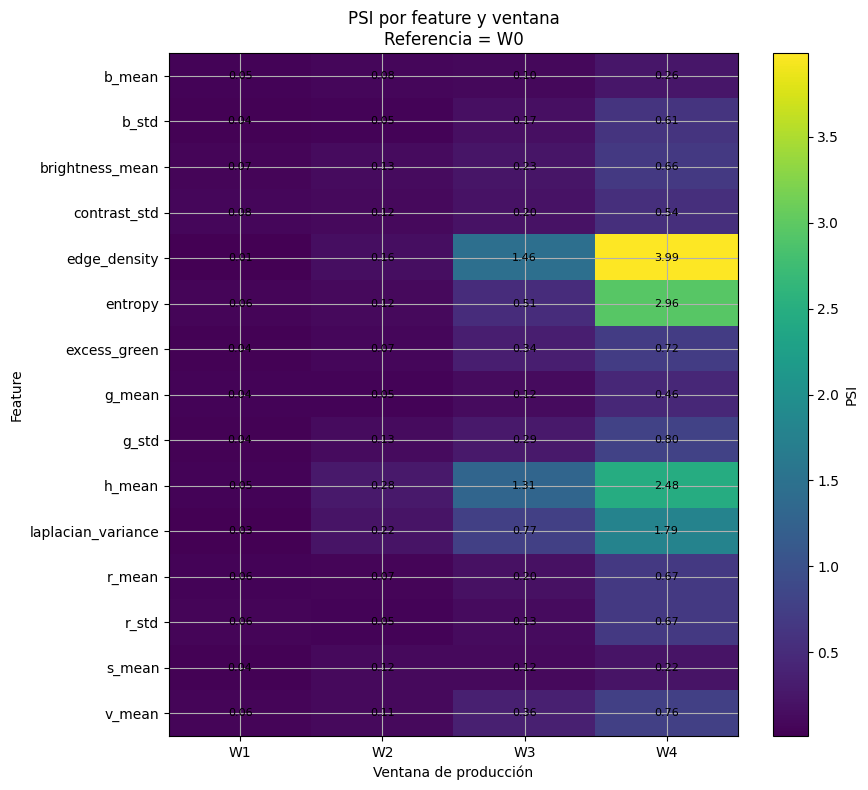

In [ ]:
# ============================================================
# 9.1 — MAPA DE CALOR DEL PSI
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Visualizar qué features presentan mayor drift en:
#
#       W1, W2, W3 y W4
#
# ============================================================


# ============================================================
# 1. LIBRERÍA
# ============================================================

import matplotlib.pyplot as plt


# ============================================================
# 2. MATRIZ PSI
# ============================================================

matriz_psi_9_1 = (
    df_psi_9_1
    .pivot(
        index="Feature",
        columns="Ventana",
        values="PSI"
    )
    .reindex(
        columns=[
            "W1",
            "W2",
            "W3",
            "W4"
        ]
    )
)


# ============================================================
# 3. GRÁFICO
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        9,
        8
    )
)


imagen_psi_9_1 = ax.imshow(
    matriz_psi_9_1.values,
    aspect="auto"
)


# ------------------------------------------------------------
# Ejes
# ------------------------------------------------------------

ax.set_xticks(
    np.arange(
        len(
            matriz_psi_9_1.columns
        )
    )
)


ax.set_xticklabels(
    matriz_psi_9_1.columns
)


ax.set_yticks(
    np.arange(
        len(
            matriz_psi_9_1.index
        )
    )
)


ax.set_yticklabels(
    matriz_psi_9_1.index
)


# ------------------------------------------------------------
# Valores sobre las celdas
# ------------------------------------------------------------

for fila_9_1 in range(
    matriz_psi_9_1.shape[0]
):

    for columna_9_1 in range(
        matriz_psi_9_1.shape[1]
    ):

        valor_9_1 = (
            matriz_psi_9_1
            .iloc[
                fila_9_1,
                columna_9_1
            ]
        )


        ax.text(
            columna_9_1,
            fila_9_1,
            f"{valor_9_1:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )


# ------------------------------------------------------------
# Líneas de referencia no aplican directamente al heatmap;
# se indican en el título/subtítulo conceptual.
# ------------------------------------------------------------

ax.set_title(
    "PSI por feature y ventana\n"
    "Referencia = W0"
)


ax.set_xlabel(
    "Ventana de producción"
)


ax.set_ylabel(
    "Feature"
)


fig.colorbar(
    imagen_psi_9_1,
    ax=ax,
    label="PSI"
)


plt.tight_layout()


plt.show()

## 9.1.6 Interpretación técnica del PSI

Esta sección resume interpretación técnica del PSI y su función dentro del proyecto MLOps.

## Control interno

lo que constituye una comprobación básica de consistencia de la implementación.

## Interpretación operacional

Esta sección resume interpretación operacional y su función dentro del proyecto MLOps.

## Resultado esperado del experimento

Como W2, W3 y W4 fueron creadas con perturbaciones deliberadamente crecientes,.

## Consideración especial para h_mean

representa Hue y posee naturaleza circular.

## Cierre de 9.1

La salida principal de esta sección queda almacenada en.

## 9.2 Kolmogorov-Smirnov

que permitirá comparar las distribuciones numéricas sin discretizarlas previamente.


## 9.2 Kolmogorov-Smirnov

El test de Kolmogorov-Smirnov de dos muestras permite comparar directamente las.

## 9.2.1 Función de distribución empírica

Su función de distribución empírica se define como.

## 9.2.2 Estadístico Kolmogorov-Smirnov

El estadístico KS corresponde a la máxima distancia absoluta entre las dos funciones.

## 9.2.3 Hipótesis estadísticas

Esta sección resume hipótesis estadísticas y su función dentro del proyecto MLOps.

## 9.2.4 Significancia estadística y tamaño de efecto

En conjuntos de datos suficientemente grandes pueden detectarse diferencias.

## 9.2.5 Comparaciones múltiples

Esta sección resume comparaciones múltiples y su función dentro del proyecto MLOps.

## 9.2.6 Relación con PSI

PSI y KS responden a perspectivas diferentes.


In [ ]:
# ============================================================
# FASE 4B — DETECCIÓN Y MONITOREO DE DATA DRIFT
# 9.2 KOLMOGOROV-SMIRNOV
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Ampliar:
#
#       src/drift.py
#
# incorporando:
#
#       calcular_ks()
#       interpretar_magnitud_ks()
#
# Se utiliza:
#
#       scipy.stats.ks_2samp
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import importlib


# ============================================================
# 2. RUTA DEL MÓDULO
# ============================================================

DRIFT_PATH_9_2 = Path(
    "src/drift.py"
)


if not DRIFT_PATH_9_2.exists():

    raise FileNotFoundError(
        "No existe src/drift.py. "
        "Ejecute previamente la sección 9.1."
    )


# ============================================================
# 3. LEER CÓDIGO EXISTENTE
# ============================================================

codigo_drift_9_2 = (
    DRIFT_PATH_9_2
    .read_text(
        encoding="utf-8"
    )
)


# ============================================================
# 4. CÓDIGO KS
# ============================================================

CODIGO_KS_9_2 = r'''

# ============================================================
# KOLMOGOROV-SMIRNOV
# ============================================================

def calcular_ks(
    referencia,
    produccion
):
    """
    Ejecuta el test Kolmogorov-Smirnov de dos muestras.

    Parameters
    ----------
    referencia : array-like
        Distribución de referencia.

    produccion : array-like
        Distribución observada en producción.

    Returns
    -------
    dict
        {
            "ks_statistic": float,
            "p_value": float
        }

    Notes
    -----
    Se utiliza un test bilateral:

        H0:
            F_ref(x) = F_prod(x)

        H1:
            F_ref(x) != F_prod(x)

    Los valores no finitos son eliminados antes del test.
    """

    import numpy as np

    from scipy.stats import (
        ks_2samp
    )


    # --------------------------------------------------------
    # Convertir a arrays
    # --------------------------------------------------------

    referencia = np.asarray(
        referencia,
        dtype=float
    )


    produccion = np.asarray(
        produccion,
        dtype=float
    )


    # --------------------------------------------------------
    # Eliminar NaN / inf
    # --------------------------------------------------------

    referencia = referencia[
        np.isfinite(
            referencia
        )
    ]


    produccion = produccion[
        np.isfinite(
            produccion
        )
    ]


    # --------------------------------------------------------
    # Verificaciones
    # --------------------------------------------------------

    if referencia.size == 0:

        raise ValueError(
            "La muestra de referencia está vacía."
        )


    if produccion.size == 0:

        raise ValueError(
            "La muestra de producción está vacía."
        )


    # --------------------------------------------------------
    # Test KS de dos muestras
    # --------------------------------------------------------

    resultado = ks_2samp(

        referencia,

        produccion,

        alternative="two-sided",

        method="auto"
    )


    return {

        "ks_statistic":
            float(
                resultado.statistic
            ),

        "p_value":
            float(
                resultado.pvalue
            )
    }


# ============================================================
# MAGNITUD DESCRIPTIVA DEL ESTADÍSTICO KS
# ============================================================

def interpretar_magnitud_ks(
    ks_statistic
):
    """
    Clasifica descriptivamente la magnitud del estadístico KS.

    Umbrales internos del proyecto:

        D < 0.10       -> Baja
        0.10 <= D < .20 -> Moderada
        D >= 0.20      -> Alta

    Estos valores NO constituyen umbrales universales.
    """

    ks_statistic = float(
        ks_statistic
    )


    if not (
        0.0
        <=
        ks_statistic
        <=
        1.0
    ):

        raise ValueError(
            "El estadístico KS debe estar "
            "entre 0 y 1."
        )


    if ks_statistic < 0.10:

        return "Baja"


    if ks_statistic < 0.20:

        return "Moderada"


    return "Alta"
'''


# ============================================================
# 5. EVITAR DUPLICADOS
# ============================================================

if (
    "def calcular_ks("
    not in
    codigo_drift_9_2
):

    codigo_drift_9_2 += (
        CODIGO_KS_9_2
    )


# ============================================================
# 6. VALIDAR SINTAXIS
# ============================================================

compile(
    codigo_drift_9_2,
    "src/drift.py",
    "exec"
)


# ============================================================
# 7. GUARDAR
# ============================================================

DRIFT_PATH_9_2.write_text(
    codigo_drift_9_2,
    encoding="utf-8"
)


# ============================================================
# 8. ACTUALIZAR IMPORTACIONES
# ============================================================

importlib.invalidate_caches()


print("=" * 105)
print("9.2 — KOLMOGOROV-SMIRNOV")
print("=" * 105)


print(
    f"Módulo actualizado : "
    f"{DRIFT_PATH_9_2}"
)


print(
    "Función            : calcular_ks()"
)


print(
    "Interpretación     : interpretar_magnitud_ks()"
)


print(
    "\n✅ src/drift.py actualizado correctamente."
)

9.2 — KOLMOGOROV-SMIRNOV
Módulo actualizado : src/drift.py
Función            : calcular_ks()
Interpretación     : interpretar_magnitud_ks()

✅ src/drift.py actualizado correctamente.


In [ ]:
# ============================================================
# 9.2 — CÁLCULO DE KS POR FEATURE Y VENTANA
# ============================================================
#
# REFERENCIA
# ------------------------------------------------------------
#
#       W0
#
# PRODUCCIÓN
# ------------------------------------------------------------
#
#       W1
#       W2
#       W3
#       W4
#
# Cada comparación genera:
#
#       D_KS
#       p-value
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import importlib

import numpy as np
import pandas as pd


# ============================================================
# 2. RECARGAR src.drift
# ============================================================

import src.drift as drift_module_9_2


drift_module_9_2 = importlib.reload(
    drift_module_9_2
)


from src.drift import (
    calcular_ks,
    interpretar_magnitud_ks
)


# ============================================================
# 3. NIVEL DE SIGNIFICANCIA
# ============================================================

ALPHA_KS_9_2 = 0.05


# ============================================================
# 4. VERIFICAR VARIABLES
# ============================================================

variables_requeridas_9_2 = [

    "X_W0_8_1",
    "X_W1_8_1",

    "X_W2_8_3",
    "X_W3_8_3",
    "X_W4_8_3",

    "FEATURES_NUMERICAS_8_3"
]


faltantes_9_2 = [

    variable
    for variable
    in variables_requeridas_9_2
    if variable
    not in globals()
]


if faltantes_9_2:

    raise NameError(
        "Faltan variables de fases anteriores: "
        f"{faltantes_9_2}"
    )


# ============================================================
# 5. FEATURES
# ============================================================

FEATURES_KS_9_2 = list(
    FEATURES_NUMERICAS_8_3
)


if len(
    FEATURES_KS_9_2
) != 15:

    raise ValueError(
        "Se esperaban 15 variables numéricas. "
        f"Se encontraron {len(FEATURES_KS_9_2)}."
    )


# ============================================================
# 6. VENTANAS
# ============================================================

VENTANAS_KS_9_2 = {

    "W1":
        X_W1_8_1,

    "W2":
        X_W2_8_3,

    "W3":
        X_W3_8_3,

    "W4":
        X_W4_8_3
}


# ============================================================
# 7. SELF-CHECK W0 VS W0
# ============================================================
#
# Para una muestra comparada consigo misma:
#
#       D_KS = 0
#
# y normalmente:
#
#       p = 1
#
# ============================================================

selfcheck_ks_9_2 = []


for feature_9_2 in (
    FEATURES_KS_9_2
):

    resultado_self_9_2 = calcular_ks(

        referencia=(
            X_W0_8_1[
                feature_9_2
            ]
        ),

        produccion=(
            X_W0_8_1[
                feature_9_2
            ]
        )
    )


    selfcheck_ks_9_2.append(
        resultado_self_9_2[
            "ks_statistic"
        ]
    )


MAX_KS_SELFCHECK_9_2 = max(
    selfcheck_ks_9_2
)


assert np.isclose(
    MAX_KS_SELFCHECK_9_2,
    0.0,
    atol=1e-12
)


print(
    "✅ Self-check W0 vs W0 correcto."
)


print(
    f"D_KS máximo W0 vs W0: "
    f"{MAX_KS_SELFCHECK_9_2:.12f}"
)


# ============================================================
# 8. EJECUTAR LOS 60 TESTS
# ============================================================

resultados_ks_9_2 = []


for ventana_9_2, X_prod_9_2 in (
    VENTANAS_KS_9_2.items()
):

    for feature_9_2 in (
        FEATURES_KS_9_2
    ):

        resultado_ks_9_2 = calcular_ks(

            referencia=(
                X_W0_8_1[
                    feature_9_2
                ]
            ),

            produccion=(
                X_prod_9_2[
                    feature_9_2
                ]
            )
        )


        D_ks_9_2 = (
            resultado_ks_9_2[
                "ks_statistic"
            ]
        )


        p_ks_9_2 = (
            resultado_ks_9_2[
                "p_value"
            ]
        )


        resultados_ks_9_2.append(
            {
                "Ventana":
                    ventana_9_2,

                "Feature":
                    feature_9_2,

                "KS_statistic":
                    D_ks_9_2,

                "p_value":
                    p_ks_9_2,

                "Magnitud_KS":
                    interpretar_magnitud_ks(
                        D_ks_9_2
                    ),

                "Significativo_raw":
                    (
                        p_ks_9_2
                        <
                        ALPHA_KS_9_2
                    ),

                "Alpha":
                    ALPHA_KS_9_2,

                "Referencia":
                    "W0"
            }
        )


# ============================================================
# 9. DATAFRAME
# ============================================================

df_ks_9_2 = pd.DataFrame(
    resultados_ks_9_2
)


# ============================================================
# 10. CONTROL DE FILAS
# ============================================================

N_ESPERADO_KS_9_2 = (

    len(
        FEATURES_KS_9_2
    )

    *

    len(
        VENTANAS_KS_9_2
    )
)


assert (
    len(
        df_ks_9_2
    )
    ==
    N_ESPERADO_KS_9_2
)


print(
    "\n"
    +
    "=" * 105
)


print(
    "KS CALCULADO"
)


print(
    "=" * 105
)


print(
    f"Features : "
    f"{len(FEATURES_KS_9_2)}"
)


print(
    f"Ventanas : "
    f"{len(VENTANAS_KS_9_2)}"
)


print(
    f"Tests    : "
    f"{len(df_ks_9_2)}"
)


print(
    "\n✅ Se calcularon 60 tests KS."
)

✅ Self-check W0 vs W0 correcto.
D_KS máximo W0 vs W0: 0.000000000000

KS CALCULADO
Features : 15
Ventanas : 4
Tests    : 60

✅ Se calcularon 60 tests KS.


In [ ]:
# ============================================================
# 9.2 — CORRECCIÓN POR COMPARACIONES MÚLTIPLES
# BENJAMINI-HOCHBERG
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Ajustar los 60 p-values para controlar:
#
#       False Discovery Rate (FDR)
#
# Se conservan:
#
#       p_value
#       p_value_fdr
#
# ============================================================


# ============================================================
# 1. FUNCIÓN BENJAMINI-HOCHBERG
# ============================================================

def ajustar_pvalues_bh_9_2(
    p_values
):
    """
    Ajusta p-values mediante Benjamini-Hochberg.

    Parameters
    ----------
    p_values : array-like
        Vector de p-values.

    Returns
    -------
    np.ndarray
        p-values ajustados.
    """


    p_values = np.asarray(
        p_values,
        dtype=float
    )


    if np.any(
        (p_values < 0)
        |
        (p_values > 1)
    ):

        raise ValueError(
            "Todos los p-values deben estar "
            "entre 0 y 1."
        )


    m_9_2 = len(
        p_values
    )


    orden_9_2 = np.argsort(
        p_values
    )


    p_ordenados_9_2 = (
        p_values[
            orden_9_2
        ]
    )


    ranks_9_2 = np.arange(
        1,
        m_9_2 + 1
    )


    ajustados_ordenados_9_2 = (

        p_ordenados_9_2

        *

        m_9_2

        /

        ranks_9_2
    )


    # --------------------------------------------------------
    # Garantizar monotonicidad desde el final
    # --------------------------------------------------------

    ajustados_ordenados_9_2 = np.minimum.accumulate(
        ajustados_ordenados_9_2[
            ::-1
        ]
    )[
        ::-1
    ]


    ajustados_ordenados_9_2 = np.clip(
        ajustados_ordenados_9_2,
        0.0,
        1.0
    )


    # --------------------------------------------------------
    # Recuperar orden original
    # --------------------------------------------------------

    ajustados_9_2 = np.empty(
        m_9_2,
        dtype=float
    )


    ajustados_9_2[
        orden_9_2
    ] = ajustados_ordenados_9_2


    return ajustados_9_2


# ============================================================
# 2. APLICAR
# ============================================================

df_ks_9_2[
    "p_value_fdr"
] = ajustar_pvalues_bh_9_2(
    df_ks_9_2[
        "p_value"
    ]
    .to_numpy()
)


# ============================================================
# 3. SIGNIFICANCIA AJUSTADA
# ============================================================

df_ks_9_2[
    "Significativo_FDR"
] = (

    df_ks_9_2[
        "p_value_fdr"
    ]

    <

    ALPHA_KS_9_2
)


print(
    "✅ Ajuste Benjamini-Hochberg aplicado."
)

✅ Ajuste Benjamini-Hochberg aplicado.


In [ ]:
# ============================================================
# 9.2 — INTERPRETACIÓN CONTEXTUAL DEL KS
# ============================================================
#
# Se combinan:
#
#       D_KS
#       p-value FDR
#
# para no confundir:
#
#       significancia estadística
#
# con:
#
#       magnitud práctica
#
# ============================================================


# ============================================================
# 1. FUNCIÓN DE INTERPRETACIÓN
# ============================================================

def interpretar_ks_contexto_9_2(
    ks_statistic,
    p_value_fdr,
    alpha=0.05
):
    """
    Interpreta conjuntamente magnitud y significancia.
    """


    D_9_2 = float(
        ks_statistic
    )


    p_9_2 = float(
        p_value_fdr
    )


    significativo_9_2 = (
        p_9_2
        <
        alpha
    )


    # --------------------------------------------------------
    # Efecto bajo
    # --------------------------------------------------------

    if D_9_2 < 0.10:

        if significativo_9_2:

            return (
                "Diferencia estadísticamente significativa, "
                "pero de magnitud baja"
            )


        return (
            "Sin evidencia relevante de cambio"
        )


    # --------------------------------------------------------
    # Efecto moderado
    # --------------------------------------------------------

    if D_9_2 < 0.20:

        if significativo_9_2:

            return (
                "Cambio moderado con evidencia estadística"
            )


        return (
            "Cambio moderado sin evidencia estadística suficiente"
        )


    # --------------------------------------------------------
    # Efecto alto
    # --------------------------------------------------------

    if significativo_9_2:

        return (
            "Cambio distributivo alto y estadísticamente significativo"
        )


    return (
        "Cambio distributivo alto; revisar tamaño muestral"
    )


# ============================================================
# 2. APLICAR
# ============================================================

df_ks_9_2[
    "Interpretacion_KS"
] = [

    interpretar_ks_contexto_9_2(
        ks_statistic=D_9_2,
        p_value_fdr=p_9_2,
        alpha=ALPHA_KS_9_2
    )

    for D_9_2, p_9_2
    in zip(

        df_ks_9_2[
            "KS_statistic"
        ],

        df_ks_9_2[
            "p_value_fdr"
        ]
    )
]


# ============================================================
# 3. ORDENAR
# ============================================================

orden_ventanas_ks_9_2 = pd.CategoricalDtype(
    categories=[
        "W1",
        "W2",
        "W3",
        "W4"
    ],
    ordered=True
)


df_ks_9_2[
    "Ventana"
] = (
    df_ks_9_2[
        "Ventana"
    ]
    .astype(
        orden_ventanas_ks_9_2
    )
)


df_ks_9_2 = (
    df_ks_9_2
    .sort_values(
        [
            "Ventana",
            "KS_statistic"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 4. MOSTRAR RESULTADOS
# ============================================================

print("=" * 105)
print("KS POR FEATURE Y VENTANA")
print("=" * 105)


display(
    df_ks_9_2[
        [
            "Ventana",
            "Feature",
            "KS_statistic",
            "p_value",
            "p_value_fdr",
            "Magnitud_KS",
            "Significativo_FDR",
            "Interpretacion_KS"
        ]
    ]
    .round(
        {
            "KS_statistic": 4,
            "p_value": 6,
            "p_value_fdr": 6
        }
    )
)

KS POR FEATURE Y VENTANA


,Ventana,Feature,KS_statistic,p_value,p_value_fdr,Magnitud_KS,Significativo_FDR,Interpretacion_KS
0,W1,brightness_mean,0.1120,0.0038,0.0058,Moderada,True,Cambio moderado con evidencia estadística
1,W1,v_mean,0.0900,0.0348,0.0486,Baja,True,"Diferencia estadísticamente significativa, pero de magnitud baja"
2,W1,r_mean,0.0820,0.0693,0.0924,Baja,False,Sin evidencia relevante de cambio
3,W1,g_mean,0.0800,0.0815,0.1040,Baja,False,Sin evidencia relevante de cambio
4,W1,b_mean,0.0740,0.1294,0.1617,Baja,False,Sin evidencia relevante de cambio
5,W1,excess_green,0.0580,0.3699,0.4439,Baja,False,Sin evidencia relevante de cambio
6,W1,g_std,0.0560,0.4135,0.4681,Baja,False,Sin evidencia relevante de cambio
7,W1,contrast_std,0.0560,0.4135,0.4681,Baja,False,Sin evidencia relevante de cambio
8,W1,b_std,0.0520,0.5089,0.5552,Baja,False,Sin evidencia relevante de cambio
9,W1,h_mean,0.0520,0.5089,0.5552,Baja,False,Sin evidencia relevante de cambio


In [ ]:
# ============================================================
# 9.2 — RESUMEN KS POR VENTANA
# ============================================================


# ============================================================
# 1. ESTADÍSTICOS AGREGADOS
# ============================================================

df_resumen_ks_9_2 = (
    df_ks_9_2
    .groupby(
        "Ventana",
        observed=True
    )
    .agg(

        KS_promedio=(
            "KS_statistic",
            "mean"
        ),

        KS_mediana=(
            "KS_statistic",
            "median"
        ),

        KS_maximo=(
            "KS_statistic",
            "max"
        ),

        N_features=(
            "Feature",
            "count"
        ),

        N_significativas_raw=(
            "Significativo_raw",
            "sum"
        ),

        N_significativas_FDR=(
            "Significativo_FDR",
            "sum"
        )
    )
    .reset_index()
)


# ============================================================
# 2. FEATURES CON EFECTO ALTO
# ============================================================

conteo_alto_ks_9_2 = (
    df_ks_9_2
    .assign(
        Efecto_alto=(
            df_ks_9_2[
                "Magnitud_KS"
            ]
            ==
            "Alta"
        )
    )
    .groupby(
        "Ventana",
        observed=True
    )[
        "Efecto_alto"
    ]
    .sum()
    .reset_index(
        name="N_efecto_alto"
    )
)


df_resumen_ks_9_2 = (
    df_resumen_ks_9_2
    .merge(
        conteo_alto_ks_9_2,
        on="Ventana",
        how="left"
    )
)


# ============================================================
# 3. MOSTRAR
# ============================================================

print("=" * 105)
print("RESUMEN KS POR VENTANA")
print("=" * 105)


display(
    df_resumen_ks_9_2
    .round(
        {
            "KS_promedio": 4,
            "KS_mediana": 4,
            "KS_maximo": 4
        }
    )
)

RESUMEN KS POR VENTANA


,Ventana,KS_promedio,KS_mediana,KS_maximo,N_features,N_significativas_raw,N_significativas_FDR,N_efecto_alto
0,W1,0.0619,0.0560,0.1120,15,2,2,0
1,W2,0.1228,0.1200,0.2320,15,12,11,1
2,W3,0.2072,0.1940,0.4440,15,15,15,7
3,W4,0.3344,0.3180,0.5980,15,15,15,14


In [ ]:
# ============================================================
# 9.2 — PERSISTENCIA DE RESULTADOS KS
# ============================================================


# ============================================================
# 1. RUTA
# ============================================================

from pathlib import Path


MONITORING_DIR_9_2 = Path(
    "monitoring"
)


MONITORING_DIR_9_2.mkdir(
    parents=True,
    exist_ok=True
)


KS_METRICS_PATH_9_2 = (
    MONITORING_DIR_9_2
    /
    "ks_metrics.csv"
)


# ============================================================
# 2. GUARDAR
# ============================================================

df_ks_9_2.to_csv(
    KS_METRICS_PATH_9_2,
    index=False,
    encoding="utf-8"
)


# ============================================================
# 3. VERIFICAR
# ============================================================

assert (
    KS_METRICS_PATH_9_2.exists()
)


assert (
    len(
        df_ks_9_2
    )
    ==
    60
)


print("=" * 105)
print("RESULTADOS KS PERSISTIDOS")
print("=" * 105)


print(
    f"Archivo : "
    f"{KS_METRICS_PATH_9_2}"
)


print(
    f"Filas   : "
    f"{len(df_ks_9_2)}"
)


print(
    "\n✅ monitoring/ks_metrics.csv creado correctamente."
)

RESULTADOS KS PERSISTIDOS
Archivo : monitoring/ks_metrics.csv
Filas   : 60

✅ monitoring/ks_metrics.csv creado correctamente.


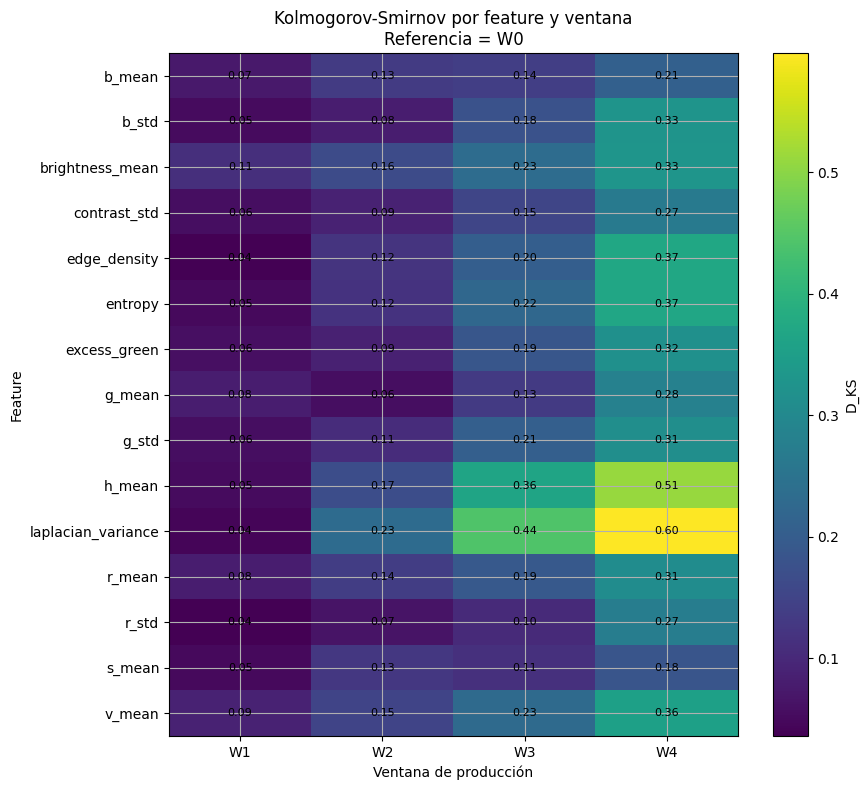

In [ ]:
# ============================================================
# 9.2 — MAPA DE CALOR DEL ESTADÍSTICO KS
# ============================================================

import matplotlib.pyplot as plt


# ============================================================
# 1. MATRIZ
# ============================================================

matriz_ks_9_2 = (
    df_ks_9_2
    .pivot(
        index="Feature",
        columns="Ventana",
        values="KS_statistic"
    )
    .reindex(
        columns=[
            "W1",
            "W2",
            "W3",
            "W4"
        ]
    )
)


# ============================================================
# 2. FIGURA
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        9,
        8
    )
)


imagen_ks_9_2 = ax.imshow(
    matriz_ks_9_2.values,
    aspect="auto"
)


# ============================================================
# 3. EJES
# ============================================================

ax.set_xticks(
    np.arange(
        len(
            matriz_ks_9_2.columns
        )
    )
)


ax.set_xticklabels(
    matriz_ks_9_2.columns
)


ax.set_yticks(
    np.arange(
        len(
            matriz_ks_9_2.index
        )
    )
)


ax.set_yticklabels(
    matriz_ks_9_2.index
)


# ============================================================
# 4. VALORES
# ============================================================

for fila_9_2 in range(
    matriz_ks_9_2.shape[0]
):

    for columna_9_2 in range(
        matriz_ks_9_2.shape[1]
    ):

        valor_9_2 = (
            matriz_ks_9_2
            .iloc[
                fila_9_2,
                columna_9_2
            ]
        )


        ax.text(
            columna_9_2,
            fila_9_2,
            f"{valor_9_2:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )


# ============================================================
# 5. TÍTULOS
# ============================================================

ax.set_title(
    "Kolmogorov-Smirnov por feature y ventana\n"
    "Referencia = W0"
)


ax.set_xlabel(
    "Ventana de producción"
)


ax.set_ylabel(
    "Feature"
)


fig.colorbar(
    imagen_ks_9_2,
    ax=ax,
    label="D_KS"
)


plt.tight_layout()


plt.show()

## 9.2.7 Interpretación técnica del test Kolmogorov-Smirnov

El test KS fue aplicado sobre las mismas variables y ventanas utilizadas previamente.

## Interpretación del estadístico

representa la máxima separación entre las funciones de distribución acumulada.

## Interpretación del p-value

indica evidencia estadística de que las muestras no provienen de la misma.

## Corrección por múltiples comparaciones

Esta sección resume corrección por múltiples comparaciones y su función dentro del proyecto MLOps.

## Relación entre magnitud y significancia

Una feature se considera especialmente relevante cuando presenta simultáneamente.

## Relación con PSI

PSI y KS no deben interpretarse como métricas competidoras.

## Consideración especial sobre h_mean

representa Hue y posee naturaleza circular.

## Cierre de 9.2

Esta sección resume cierre de 9.2 y su función dentro del proyecto MLOps.

## 9.3 Chi-cuadrado para variables categóricas

donde deberá evaluarse primero si existen efectivamente features categóricas de entrada.


## 9.3 Chi-cuadrado para variables categóricas

El test de Chi-cuadrado permite comparar la distribución de frecuencias de una.

## 9.3.1 Estadístico Chi-cuadrado

Esta sección resume estadístico Chi-cuadrado y su función dentro del proyecto MLOps.

## 9.3.2 Hipótesis estadísticas

Para cada feature categórica se consideran.

## 9.3.3 Tamaño de efecto

Para complementar el test Chi-cuadrado se utilizará Cramér's V.

## 9.3.4 Situación del proyecto actual

Esta sección resume situación del proyecto actual y su función dentro del proyecto MLOps.

## 9.3.5 Diferencia respecto del target

El problema sí posee una variable categórica multiclase.

## 9.4 Drift del target

Esta sección resume drift del target y su función dentro del proyecto MLOps.

## 9.3.6 ¿Data Drift o Concept Drift?

El test Chi-cuadrado aplicado a una feature categórica compara.


In [ ]:
# ============================================================
# FASE 4B — DETECCIÓN Y MONITOREO DE DATA DRIFT
# 9.3 CHI-CUADRADO PARA VARIABLES CATEGÓRICAS
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Ampliar:
#
#       src/drift.py
#
# incorporando:
#
#       calcular_chi2_categorica()
#       interpretar_cramers_v()
#
# IMPORTANTE
# ------------------------------------------------------------
# El proyecto actual no posee features categóricas en X.
#
# La función queda implementada de forma genérica para:
#
#   - cumplir la arquitectura del monitor;
#   - soportar futuras versiones;
#   - evitar inventar variables inexistentes.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import importlib


# ============================================================
# 2. RUTA DEL MÓDULO
# ============================================================

DRIFT_PATH_9_3 = Path(
    "src/drift.py"
)


if not DRIFT_PATH_9_3.exists():

    raise FileNotFoundError(
        "No existe src/drift.py. "
        "Ejecute previamente las secciones 9.1 y 9.2."
    )


# ============================================================
# 3. LEER MÓDULO
# ============================================================

codigo_drift_9_3 = (
    DRIFT_PATH_9_3
    .read_text(
        encoding="utf-8"
    )
)


# ============================================================
# 4. CÓDIGO CHI-CUADRADO
# ============================================================

CODIGO_CHI2_9_3 = r'''

# ============================================================
# CHI-CUADRADO PARA VARIABLES CATEGÓRICAS
# ============================================================

def calcular_chi2_categorica(
    referencia,
    produccion,
    alpha=0.05
):
    """
    Compara una variable categórica entre referencia
    y producción mediante Chi-cuadrado.

    Parameters
    ----------
    referencia : array-like
        Categorías de la población de referencia.

    produccion : array-like
        Categorías observadas en producción.

    alpha : float
        Nivel de significancia.

    Returns
    -------
    dict
        Resultado con:

        - chi2_statistic
        - p_value
        - dof
        - cramers_v
        - significativo
        - n_categorias
    """

    import numpy as np
    import pandas as pd

    from scipy.stats import (
        chi2_contingency
    )


    # --------------------------------------------------------
    # Convertir a Series
    # --------------------------------------------------------

    ref = pd.Series(
        referencia
    ).astype(
        "string"
    )


    prod = pd.Series(
        produccion
    ).astype(
        "string"
    )


    # --------------------------------------------------------
    # Eliminar valores faltantes
    # --------------------------------------------------------

    ref = ref.dropna()

    prod = prod.dropna()


    if len(ref) == 0:

        raise ValueError(
            "La referencia categórica está vacía."
        )


    if len(prod) == 0:

        raise ValueError(
            "La producción categórica está vacía."
        )


    # --------------------------------------------------------
    # Unión de categorías
    # --------------------------------------------------------
    #
    # Esto permite detectar categorías nuevas o categorías
    # desaparecidas en producción.
    #
    # --------------------------------------------------------

    categorias = sorted(
        set(
            ref.unique()
        )
        |
        set(
            prod.unique()
        )
    )


    if len(categorias) < 2:

        raise ValueError(
            "Chi-cuadrado requiere al menos "
            "dos categorías."
        )


    # --------------------------------------------------------
    # Frecuencias
    # --------------------------------------------------------

    conteo_ref = (
        ref
        .value_counts()
        .reindex(
            categorias,
            fill_value=0
        )
    )


    conteo_prod = (
        prod
        .value_counts()
        .reindex(
            categorias,
            fill_value=0
        )
    )


    # --------------------------------------------------------
    # Tabla de contingencia 2 x K
    # --------------------------------------------------------

    tabla = np.vstack(
        [
            conteo_ref.to_numpy(),
            conteo_prod.to_numpy()
        ]
    )


    # --------------------------------------------------------
    # Eliminar categorías ausentes en ambas muestras
    # --------------------------------------------------------

    columnas_validas = (
        tabla.sum(
            axis=0
        )
        >
        0
    )


    tabla = tabla[
        :,
        columnas_validas
    ]


    categorias_validas = np.asarray(
        categorias
    )[
        columnas_validas
    ]


    # --------------------------------------------------------
    # Test Chi-cuadrado
    # --------------------------------------------------------

    chi2, p_value, dof, expected = (
        chi2_contingency(
            tabla,
            correction=False
        )
    )


    # --------------------------------------------------------
    # Cramér's V
    # --------------------------------------------------------

    n_total = float(
        tabla.sum()
    )


    min_dimension = min(
        tabla.shape[0] - 1,
        tabla.shape[1] - 1
    )


    if min_dimension <= 0:

        cramers_v = 0.0

    else:

        cramers_v = float(
            np.sqrt(
                chi2
                /
                (
                    n_total
                    *
                    min_dimension
                )
            )
        )


    # --------------------------------------------------------
    # Tabla auditable
    # --------------------------------------------------------

    detalle = pd.DataFrame(
        {
            "categoria":
                categorias_validas,

            "frecuencia_referencia":
                tabla[0],

            "frecuencia_produccion":
                tabla[1],

            "proporcion_referencia":
                (
                    tabla[0]
                    /
                    tabla[0].sum()
                ),

            "proporcion_produccion":
                (
                    tabla[1]
                    /
                    tabla[1].sum()
                )
        }
    )


    return {

        "chi2_statistic":
            float(
                chi2
            ),

        "p_value":
            float(
                p_value
            ),

        "dof":
            int(
                dof
            ),

        "cramers_v":
            cramers_v,

        "significativo":
            bool(
                p_value
                <
                alpha
            ),

        "n_categorias":
            int(
                len(
                    categorias_validas
                )
            ),

        "detalle":
            detalle
    }


# ============================================================
# INTERPRETACIÓN DE CRAMÉR'S V
# ============================================================

def interpretar_cramers_v(
    valor
):
    """
    Clasificación descriptiva interna del proyecto.

        V < 0.10         -> Baja
        0.10 <= V < .30 -> Moderada
        V >= 0.30        -> Alta

    No representa una regla universal.
    """

    valor = float(
        valor
    )


    if not (
        0.0
        <=
        valor
        <=
        1.0
    ):

        raise ValueError(
            "Cramér's V debe encontrarse "
            "entre 0 y 1."
        )


    if valor < 0.10:

        return "Baja"


    if valor < 0.30:

        return "Moderada"


    return "Alta"
'''


# ============================================================
# 5. EVITAR DUPLICAR FUNCIONES
# ============================================================

if (
    "def calcular_chi2_categorica("
    not in
    codigo_drift_9_3
):

    codigo_drift_9_3 += (
        CODIGO_CHI2_9_3
    )


# ============================================================
# 6. VALIDAR SINTAXIS
# ============================================================

compile(
    codigo_drift_9_3,
    "src/drift.py",
    "exec"
)


# ============================================================
# 7. GUARDAR
# ============================================================

DRIFT_PATH_9_3.write_text(
    codigo_drift_9_3,
    encoding="utf-8"
)


# ============================================================
# 8. RECARGAR IMPORTACIONES
# ============================================================

importlib.invalidate_caches()


print("=" * 105)
print("9.3 — CHI-CUADRADO PARA CATEGÓRICAS")
print("=" * 105)


print(
    f"Módulo actualizado : "
    f"{DRIFT_PATH_9_3}"
)


print(
    "Chi-cuadrado       : implementado"
)


print(
    "Cramér's V         : implementado"
)


print(
    "\n✅ src/drift.py actualizado correctamente."
)

9.3 — CHI-CUADRADO PARA CATEGÓRICAS
Módulo actualizado : src/drift.py
Chi-cuadrado       : implementado
Cramér's V         : implementado

✅ src/drift.py actualizado correctamente.


In [ ]:
# ============================================================
# 9.3 — AUDITORÍA DE FEATURES CATEGÓRICAS
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Determinar si existen variables categóricas de entrada
# sobre las cuales aplicar Chi-cuadrado.
#
# NO se utilizará el target en esta sección.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 2. RECUPERAR FEATURES DE W0
# ============================================================

if "X_W0_8_1" not in globals():

    raise NameError(
        "No se encontró X_W0_8_1. "
        "Ejecute previamente la Fase 4A."
    )


# ============================================================
# 3. DETECTAR TIPOS
# ============================================================

FEATURES_CATEGORICAS_9_3 = (
    X_W0_8_1
    .select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)


FEATURES_NUMERICAS_9_3 = (
    X_W0_8_1
    .select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)


# ============================================================
# 4. AUDITORÍA
# ============================================================

auditoria_categoricas_9_3 = pd.DataFrame(
    {
        "Elemento": [

            "Features totales",

            "Features numéricas",

            "Features categóricas",

            "Chi² sobre X",

            "Target categórico",

            "Análisis del target"
        ],

        "Resultado": [

            X_W0_8_1.shape[1],

            len(
                FEATURES_NUMERICAS_9_3
            ),

            len(
                FEATURES_CATEGORICAS_9_3
            ),

            (
                "Aplicable"
                if FEATURES_CATEGORICAS_9_3
                else "No aplica"
            ),

            "Sí",

            "Sección 9.4"
        ]
    }
)


print("=" * 105)
print("9.3 — AUDITORÍA DE VARIABLES CATEGÓRICAS")
print("=" * 105)


display(
    auditoria_categoricas_9_3
)


print(
    "\nFeatures categóricas detectadas:"
)


print(
    (
        FEATURES_CATEGORICAS_9_3
        if FEATURES_CATEGORICAS_9_3
        else "Ninguna"
    )
)

9.3 — AUDITORÍA DE VARIABLES CATEGÓRICAS


,Elemento,Resultado
0,Features totales,15
1,Features numéricas,15
2,Features categóricas,0
3,Chi² sobre X,No aplica
4,Target categórico,Sí
5,Análisis del target,Sección 9.4



Features categóricas detectadas:
Ninguna


In [ ]:
# ============================================================
# 9.3 — CHI-CUADRADO POR FEATURE CATEGÓRICA
# ============================================================
#
# Si existen features categóricas:
#
#       W0 vs W1
#       W0 vs W2
#       W0 vs W3
#       W0 vs W4
#
# Si no existen:
#
#       registrar formalmente "No aplica"
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import importlib

import pandas as pd


import src.drift as drift_module_9_3


drift_module_9_3 = importlib.reload(
    drift_module_9_3
)


from src.drift import (
    calcular_chi2_categorica,
    interpretar_cramers_v
)


# ============================================================
# 2. NIVEL DE SIGNIFICANCIA
# ============================================================

ALPHA_CHI2_9_3 = 0.05


# ============================================================
# 3. VENTANAS
# ============================================================

VENTANAS_CHI2_9_3 = {

    "W1":
        X_W1_8_1,

    "W2":
        X_W2_8_3,

    "W3":
        X_W3_8_3,

    "W4":
        X_W4_8_3
}


# ============================================================
# 4. RESULTADOS
# ============================================================

resultados_chi2_9_3 = []


# ============================================================
# 5. CASO A — EXISTEN CATEGÓRICAS
# ============================================================

if FEATURES_CATEGORICAS_9_3:

    for ventana_9_3, X_prod_9_3 in (
        VENTANAS_CHI2_9_3.items()
    ):

        for feature_9_3 in (
            FEATURES_CATEGORICAS_9_3
        ):

            resultado_9_3 = (
                calcular_chi2_categorica(

                    referencia=(
                        X_W0_8_1[
                            feature_9_3
                        ]
                    ),

                    produccion=(
                        X_prod_9_3[
                            feature_9_3
                        ]
                    ),

                    alpha=(
                        ALPHA_CHI2_9_3
                    )
                )
            )


            resultados_chi2_9_3.append(
                {
                    "Ventana":
                        ventana_9_3,

                    "Feature":
                        feature_9_3,

                    "Chi2":
                        resultado_9_3[
                            "chi2_statistic"
                        ],

                    "p_value":
                        resultado_9_3[
                            "p_value"
                        ],

                    "Cramers_V":
                        resultado_9_3[
                            "cramers_v"
                        ],

                    "Magnitud":
                        interpretar_cramers_v(
                            resultado_9_3[
                                "cramers_v"
                            ]
                        ),

                    "Significativo":
                        resultado_9_3[
                            "significativo"
                        ],

                    "Estado":
                        "Calculado"
                }
            )


# ============================================================
# 6. CASO B — NO EXISTEN CATEGÓRICAS
# ============================================================

else:

    for ventana_9_3 in [

        "W1",
        "W2",
        "W3",
        "W4"

    ]:

        resultados_chi2_9_3.append(
            {
                "Ventana":
                    ventana_9_3,

                "Feature":
                    None,

                "Chi2":
                    np.nan,

                "p_value":
                    np.nan,

                "Cramers_V":
                    np.nan,

                "Magnitud":
                    "No aplica",

                "Significativo":
                    False,

                "Estado":
                    (
                        "No aplica — "
                        "no existen features categóricas"
                    )
            }
        )


# ============================================================
# 7. DATAFRAME
# ============================================================

df_chi2_9_3 = pd.DataFrame(
    resultados_chi2_9_3
)


# ============================================================
# 8. MOSTRAR
# ============================================================

print("=" * 105)
print("RESULTADOS CHI-CUADRADO")
print("=" * 105)


display(
    df_chi2_9_3
    .round(
        {
            "Chi2": 4,
            "p_value": 6,
            "Cramers_V": 4
        }
    )
)


if not FEATURES_CATEGORICAS_9_3:

    print(
        "\n✅ Chi² no aplica a las features actuales."
    )


    print(
        "✅ Esta ausencia queda documentada formalmente."
    )


    print(
        "➡️ El target categórico se analizará en 9.4."
    )

RESULTADOS CHI-CUADRADO


,Ventana,Feature,Chi2,p_value,Cramers_V,Magnitud,Significativo,Estado
0,W1,None,NaN,NaN,NaN,No aplica,False,No aplica — no existen features categóricas
1,W2,None,NaN,NaN,NaN,No aplica,False,No aplica — no existen features categóricas
2,W3,None,NaN,NaN,NaN,No aplica,False,No aplica — no existen features categóricas
3,W4,None,NaN,NaN,NaN,No aplica,False,No aplica — no existen features categóricas



✅ Chi² no aplica a las features actuales.
✅ Esta ausencia queda documentada formalmente.
➡️ El target categórico se analizará en 9.4.


In [ ]:
# ============================================================
# 9.3 — PERSISTENCIA DE RESULTADOS CHI-CUADRADO
# ============================================================


# ============================================================
# 1. DIRECTORIO
# ============================================================

from pathlib import Path


MONITORING_DIR_9_3 = Path(
    "monitoring"
)


MONITORING_DIR_9_3.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. RUTA
# ============================================================

CHI2_METRICS_PATH_9_3 = (
    MONITORING_DIR_9_3
    /
    "chi2_metrics.csv"
)


# ============================================================
# 3. GUARDAR
# ============================================================

df_chi2_9_3.to_csv(
    CHI2_METRICS_PATH_9_3,
    index=False,
    encoding="utf-8"
)


# ============================================================
# 4. VERIFICAR
# ============================================================

assert (
    CHI2_METRICS_PATH_9_3.exists()
)


print("=" * 105)
print("RESULTADOS CHI² PERSISTIDOS")
print("=" * 105)


print(
    f"Archivo : "
    f"{CHI2_METRICS_PATH_9_3}"
)


print(
    f"Filas   : "
    f"{len(df_chi2_9_3)}"
)


print(
    "\n✅ monitoring/chi2_metrics.csv creado."
)

RESULTADOS CHI² PERSISTIDOS
Archivo : monitoring/chi2_metrics.csv
Filas   : 4

✅ monitoring/chi2_metrics.csv creado.


## 9.3.7 Interpretación técnica

La auditoría del contrato de entrada confirma que el modelo actual utiliza.

## Diferencia entre Data Drift y Concept Drift

Si existiera una feature categórica y Chi-cuadrado detectara.

## ¿Qué ocurre con el target?

sí es categórico y contiene diez clases.

## 9.4 Drift del target

tampoco demuestra automáticamente Concept Drift.

## Resumen conceptual

Por tanto, el flujo metodológico del proyecto queda.

## Cierre de 9.3

Esta sección resume cierre de 9.3 y su función dentro del proyecto MLOps.

## 9.4 Drift del target

donde sí se analizará formalmente la evolución de las diez clases entre.


## 9.4 Drift del target

Cuando la variable objetivo real se encuentra disponible, también debe monitorearse.

## 9.4.1 Distribución del target

Para cada clase se define la probabilidad empírica.

## 9.4.2 Target Drift

El cambio en la distribución marginal del target se denominará.

## 9.4.3 Test Chi-cuadrado sobre el target

Como el target es categórico, se utilizará el test Chi-cuadrado para comparar las.

## 9.4.4 Magnitud mediante Cramér's V

Como medida complementaria de tamaño de efecto se utilizará.

## 9.4.5 Total Variation Distance

Además se calculará la distancia de variación total.

## 9.4.6 Hipótesis experimental

Debido a que W2, W3 y W4 fueron generadas mediante muestreo sesgado creciente, se.


In [ ]:
# ============================================================
# FASE 4B — DETECCIÓN Y MONITOREO DE DATA DRIFT
# 9.4 DRIFT DEL TARGET
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Recuperar los targets reales de:
#
#       W0
#       W1
#       W2
#       W3
#       W4
#
# y construir una representación homogénea para comparar:
#
#       P_W0(Y)
#
# con:
#
#       P_Wi(Y)
#
# IMPORTANTE
# ------------------------------------------------------------
# y_W2_8_3, y_W3_8_3 y y_W4_8_3 provienen del
# muestreo sesgado implementado en 8.3.
#
# El target se utiliza exclusivamente para monitoreo y
# evaluación offline.
#
# Nunca se incorpora como entrada de /predict.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd

from IPython.display import (
    display
)


# ============================================================
# 2. VERIFICAR VARIABLES
# ============================================================

variables_target_9_4 = [

    "y_W0_8_1",
    "y_W1_8_1",

    "y_W2_8_3",
    "y_W3_8_3",
    "y_W4_8_3"
]


faltantes_target_9_4 = [

    variable
    for variable
    in variables_target_9_4
    if variable
    not in globals()
]


if faltantes_target_9_4:

    raise NameError(
        "Faltan targets generados en las fases anteriores: "
        f"{faltantes_target_9_4}"
    )


# ============================================================
# 3. NORMALIZAR A SERIES
# ============================================================

TARGETS_9_4 = {

    "W0":
        pd.Series(
            np.asarray(
                y_W0_8_1
            ),
            name="target"
        ),

    "W1":
        pd.Series(
            np.asarray(
                y_W1_8_1
            ),
            name="target"
        ),

    "W2":
        pd.Series(
            np.asarray(
                y_W2_8_3
            ),
            name="target"
        ),

    "W3":
        pd.Series(
            np.asarray(
                y_W3_8_3
            ),
            name="target"
        ),

    "W4":
        pd.Series(
            np.asarray(
                y_W4_8_3
            ),
            name="target"
        )
}


# ============================================================
# 4. CLASES OBSERVADAS
# ============================================================

CLASES_TARGET_9_4 = sorted(
    set().union(
        *[
            set(
                serie
                .astype(str)
                .unique()
            )
            for serie
            in TARGETS_9_4.values()
        ]
    )
)


# ============================================================
# 5. CONTROLES
# ============================================================

N_CLASES_TARGET_9_4 = len(
    CLASES_TARGET_9_4
)


print("=" * 105)
print("9.4 — TARGETS DISPONIBLES")
print("=" * 105)


for ventana_9_4, y_ventana_9_4 in (
    TARGETS_9_4.items()
):

    print(
        f"{ventana_9_4}: "
        f"{len(y_ventana_9_4)} observaciones"
    )


print(
    f"\nClases observadas : "
    f"{N_CLASES_TARGET_9_4}"
)


print(
    "\n✅ Targets W0-W4 disponibles para monitoreo."
)

9.4 — TARGETS DISPONIBLES
W0: 500 observaciones
W1: 500 observaciones
W2: 500 observaciones
W3: 500 observaciones
W4: 500 observaciones

Clases observadas : 10

✅ Targets W0-W4 disponibles para monitoreo.


In [ ]:
# ============================================================
# 9.4 — DISTRIBUCIÓN DEL TARGET POR VENTANA
# ============================================================


# ============================================================
# 1. FUNCIÓN DE DISTRIBUCIÓN
# ============================================================

def distribucion_target_9_4(
    y,
    clases
):
    """
    Calcula conteos y proporciones para todas las clases.

    Parameters
    ----------
    y : array-like
        Target de una ventana.

    clases : list
        Universo completo de clases.

    Returns
    -------
    pd.DataFrame
        Conteo y proporción por clase.
    """


    serie_9_4 = (
        pd.Series(
            np.asarray(
                y
            )
        )
        .astype(str)
    )


    conteos_9_4 = (
        serie_9_4
        .value_counts()
        .reindex(
            clases,
            fill_value=0
        )
    )


    proporciones_9_4 = (
        conteos_9_4
        /
        conteos_9_4.sum()
    )


    return pd.DataFrame(
        {
            "Clase":
                clases,

            "Conteo":
                conteos_9_4.values,

            "Proporcion":
                proporciones_9_4.values
        }
    )


# ============================================================
# 2. CALCULAR TODAS LAS VENTANAS
# ============================================================

distribuciones_target_9_4 = {}


for ventana_9_4, y_ventana_9_4 in (
    TARGETS_9_4.items()
):

    distribuciones_target_9_4[
        ventana_9_4
    ] = distribucion_target_9_4(

        y=y_ventana_9_4,

        clases=CLASES_TARGET_9_4
    )


# ============================================================
# 3. TABLA DE PROPORCIONES
# ============================================================

df_target_proporciones_9_4 = pd.DataFrame(
    {
        ventana_9_4: (
            distribuciones_target_9_4[
                ventana_9_4
            ]
            .set_index(
                "Clase"
            )[
                "Proporcion"
            ]
        )

        for ventana_9_4
        in [
            "W0",
            "W1",
            "W2",
            "W3",
            "W4"
        ]
    }
)


df_target_proporciones_9_4.index.name = (
    "Clase"
)


# ============================================================
# 4. MOSTRAR EN PORCENTAJE
# ============================================================

print("=" * 105)
print("DISTRIBUCIÓN DEL TARGET POR VENTANA (%)")
print("=" * 105)


display(
    (
        df_target_proporciones_9_4
        *
        100
    )
    .round(2)
)

DISTRIBUCIÓN DEL TARGET POR VENTANA (%)


,W0,W1,W2,W3,W4
Clase,,,,,
Tomato___Bacterial_spot,11.8000,11.8000,12.2000,8.6000,8.6000
Tomato___Early_blight,5.6000,5.6000,5.6000,3.4000,3.0000
Tomato___Late_blight,10.4000,10.4000,11.0000,10.2000,7.8000
Tomato___Leaf_Mold,5.2000,5.2000,5.2000,3.8000,3.8000
Tomato___Septoria_leaf_spot,9.8000,9.8000,7.8000,8.6000,8.6000
Tomato___Spider_mites Two-spotted_spider_mite,9.2000,9.0000,8.0000,8.0000,5.8000
Tomato___Target_Spot,7.8000,7.8000,6.2000,5.4000,5.8000
Tomato___Tomato_Yellow_Leaf_Curl_Virus,29.4000,29.6000,32.0000,43.6000,50.4000
Tomato___Tomato_mosaic_virus,2.0000,2.0000,1.4000,1.8000,1.6000


In [ ]:
# ============================================================
# 9.4 — MÉTRICAS DE DRIFT DEL TARGET
# ============================================================
#
# MÉTRICAS
# ------------------------------------------------------------
#
# 1. Chi-cuadrado:
#       evidencia estadística.
#
# 2. Cramér's V:
#       magnitud del efecto.
#
# 3. TVD:
#       distancia global entre proporciones.
#
# 4. Cambio máximo de clase:
#       mayor variación absoluta observada.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from scipy.stats import (
    chi2_contingency
)


# ============================================================
# 2. FUNCIÓN
# ============================================================

def calcular_drift_target_9_4(
    referencia,
    produccion,
    clases,
    alpha=0.05
):
    """
    Compara la distribución categórica del target entre
    referencia y producción.

    Returns
    -------
    dict
        Métricas de drift del target.
    """


    # --------------------------------------------------------
    # Normalizar
    # --------------------------------------------------------

    ref_9_4 = (
        pd.Series(
            np.asarray(
                referencia
            )
        )
        .astype(str)
    )


    prod_9_4 = (
        pd.Series(
            np.asarray(
                produccion
            )
        )
        .astype(str)
    )


    # --------------------------------------------------------
    # Conteos comunes
    # --------------------------------------------------------

    conteo_ref_9_4 = (
        ref_9_4
        .value_counts()
        .reindex(
            clases,
            fill_value=0
        )
    )


    conteo_prod_9_4 = (
        prod_9_4
        .value_counts()
        .reindex(
            clases,
            fill_value=0
        )
    )


    # --------------------------------------------------------
    # Tabla de contingencia
    # --------------------------------------------------------

    tabla_9_4 = np.vstack(
        [
            conteo_ref_9_4.to_numpy(),
            conteo_prod_9_4.to_numpy()
        ]
    )


    # --------------------------------------------------------
    # Eliminar columnas vacías en ambas ventanas
    # --------------------------------------------------------

    validas_9_4 = (
        tabla_9_4.sum(
            axis=0
        )
        >
        0
    )


    tabla_9_4 = (
        tabla_9_4[
            :,
            validas_9_4
        ]
    )


    # --------------------------------------------------------
    # Chi-cuadrado
    # --------------------------------------------------------

    chi2_9_4, p_value_9_4, dof_9_4, expected_9_4 = (
        chi2_contingency(
            tabla_9_4,
            correction=False
        )
    )


    # --------------------------------------------------------
    # Cramér's V
    # --------------------------------------------------------

    n_total_9_4 = float(
        tabla_9_4.sum()
    )


    min_dim_9_4 = min(
        tabla_9_4.shape[0] - 1,
        tabla_9_4.shape[1] - 1
    )


    if min_dim_9_4 > 0:

        cramers_v_9_4 = float(
            np.sqrt(
                chi2_9_4
                /
                (
                    n_total_9_4
                    *
                    min_dim_9_4
                )
            )
        )

    else:

        cramers_v_9_4 = 0.0


    # --------------------------------------------------------
    # Proporciones
    # --------------------------------------------------------

    p_ref_9_4 = (
        conteo_ref_9_4
        /
        conteo_ref_9_4.sum()
    )


    p_prod_9_4 = (
        conteo_prod_9_4
        /
        conteo_prod_9_4.sum()
    )


    diferencias_9_4 = (

        p_prod_9_4
        -
        p_ref_9_4
    )


    # --------------------------------------------------------
    # Total Variation Distance
    # --------------------------------------------------------

    tvd_9_4 = float(

        0.5

        *

        np.abs(
            diferencias_9_4
        )
        .sum()
    )


    # --------------------------------------------------------
    # Mayor desplazamiento de una clase
    # --------------------------------------------------------

    clase_max_9_4 = (
        diferencias_9_4
        .abs()
        .idxmax()
    )


    max_cambio_9_4 = float(
        diferencias_9_4[
            clase_max_9_4
        ]
    )


    return {

        "Chi2":
            float(
                chi2_9_4
            ),

        "p_value":
            float(
                p_value_9_4
            ),

        "dof":
            int(
                dof_9_4
            ),

        "Cramers_V":
            cramers_v_9_4,

        "TVD":
            tvd_9_4,

        "Significativo":
            bool(
                p_value_9_4
                <
                alpha
            ),

        "Clase_max_cambio":
            str(
                clase_max_9_4
            ),

        "Cambio_max_proporcion":
            max_cambio_9_4
    }


# ============================================================
# 3. CALCULAR W0 VS W1-W4
# ============================================================

ALPHA_TARGET_9_4 = 0.05


resultados_target_drift_9_4 = []


for ventana_9_4 in [

    "W1",
    "W2",
    "W3",
    "W4"

]:

    resultado_9_4 = calcular_drift_target_9_4(

        referencia=(
            TARGETS_9_4[
                "W0"
            ]
        ),

        produccion=(
            TARGETS_9_4[
                ventana_9_4
            ]
        ),

        clases=(
            CLASES_TARGET_9_4
        ),

        alpha=(
            ALPHA_TARGET_9_4
        )
    )


    resultado_9_4[
        "Ventana"
    ] = ventana_9_4


    resultados_target_drift_9_4.append(
        resultado_9_4
    )


# ============================================================
# 4. DATAFRAME
# ============================================================

df_target_drift_9_4 = pd.DataFrame(
    resultados_target_drift_9_4
)


# ============================================================
# 5. MAGNITUD CRAMÉR'S V
# ============================================================

def magnitud_cramers_9_4(
    valor
):

    if valor < 0.10:

        return "Baja"


    if valor < 0.30:

        return "Moderada"


    return "Alta"


df_target_drift_9_4[
    "Magnitud"
] = (
    df_target_drift_9_4[
        "Cramers_V"
    ]
    .apply(
        magnitud_cramers_9_4
    )
)


# ============================================================
# 6. ORDENAR COLUMNAS
# ============================================================

df_target_drift_9_4 = (
    df_target_drift_9_4[
        [
            "Ventana",
            "Chi2",
            "p_value",
            "Cramers_V",
            "Magnitud",
            "TVD",
            "Significativo",
            "Clase_max_cambio",
            "Cambio_max_proporcion"
        ]
    ]
)


# ============================================================
# 7. MOSTRAR
# ============================================================

print("=" * 105)
print("DRIFT DEL TARGET — W0 VS PRODUCCIÓN")
print("=" * 105)


display(
    df_target_drift_9_4
    .round(
        {
            "Chi2": 4,
            "p_value": 6,
            "Cramers_V": 4,
            "TVD": 4,
            "Cambio_max_proporcion": 4
        }
    )
)

DRIFT DEL TARGET — W0 VS PRODUCCIÓN


,Ventana,Chi2,p_value,Cramers_V,Magnitud,TVD,Significativo,Clase_max_cambio,Cambio_max_proporcion
0,W1,0.0144,1.0000,0.0038,Baja,0.0020,False,Tomato___Spider_mites Two-spotted_spider_mite,-0.0020
1,W2,4.5017,0.8754,0.0671,Baja,0.0540,False,Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.0260
2,W3,24.7240,0.0033,0.1572,Moderada,0.1420,True,Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.1420
3,W4,49.5372,0.0000,0.2226,Moderada,0.2100,True,Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.2100


In [ ]:
# ============================================================
# 9.4 — AJUSTE FDR DE LOS P-VALUES
# ============================================================
#
# Se realizan cuatro comparaciones:
#
#       W0 vs W1
#       W0 vs W2
#       W0 vs W3
#       W0 vs W4
#
# Se aplica Benjamini-Hochberg para mantener coherencia
# con el tratamiento estadístico utilizado en 9.2.
# ============================================================


def ajustar_bh_target_9_4(
    p_values
):
    """
    Ajuste Benjamini-Hochberg.
    """


    p_values = np.asarray(
        p_values,
        dtype=float
    )


    m_9_4 = len(
        p_values
    )


    orden_9_4 = np.argsort(
        p_values
    )


    p_ordenados_9_4 = (
        p_values[
            orden_9_4
        ]
    )


    rangos_9_4 = np.arange(
        1,
        m_9_4 + 1
    )


    ajustados_ordenados_9_4 = (

        p_ordenados_9_4

        *

        m_9_4

        /

        rangos_9_4
    )


    ajustados_ordenados_9_4 = (
        np.minimum.accumulate(
            ajustados_ordenados_9_4[
                ::-1
            ]
        )[
            ::-1
        ]
    )


    ajustados_ordenados_9_4 = np.clip(
        ajustados_ordenados_9_4,
        0.0,
        1.0
    )


    resultado_9_4 = np.empty(
        m_9_4,
        dtype=float
    )


    resultado_9_4[
        orden_9_4
    ] = ajustados_ordenados_9_4


    return resultado_9_4


df_target_drift_9_4[
    "p_value_fdr"
] = ajustar_bh_target_9_4(
    df_target_drift_9_4[
        "p_value"
    ]
)


df_target_drift_9_4[
    "Significativo_FDR"
] = (

    df_target_drift_9_4[
        "p_value_fdr"
    ]

    <

    ALPHA_TARGET_9_4
)


print("=" * 105)
print("TARGET DRIFT — RESULTADO ESTADÍSTICO FINAL")
print("=" * 105)


display(
    df_target_drift_9_4[
        [
            "Ventana",
            "Chi2",
            "p_value",
            "p_value_fdr",
            "Cramers_V",
            "Magnitud",
            "TVD",
            "Significativo_FDR",
            "Clase_max_cambio",
            "Cambio_max_proporcion"
        ]
    ]
    .round(
        {
            "Chi2": 4,
            "p_value": 6,
            "p_value_fdr": 6,
            "Cramers_V": 4,
            "TVD": 4,
            "Cambio_max_proporcion": 4
        }
    )
)

TARGET DRIFT — RESULTADO ESTADÍSTICO FINAL


,Ventana,Chi2,p_value,p_value_fdr,Cramers_V,Magnitud,TVD,Significativo_FDR,Clase_max_cambio,Cambio_max_proporcion
0,W1,0.0144,1.0000,1.0000,0.0038,Baja,0.0020,False,Tomato___Spider_mites Two-spotted_spider_mite,-0.0020
1,W2,4.5017,0.8754,1.0000,0.0671,Baja,0.0540,False,Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.0260
2,W3,24.7240,0.0033,0.0066,0.1572,Moderada,0.1420,True,Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.1420
3,W4,49.5372,0.0000,0.0000,0.2226,Moderada,0.2100,True,Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.2100


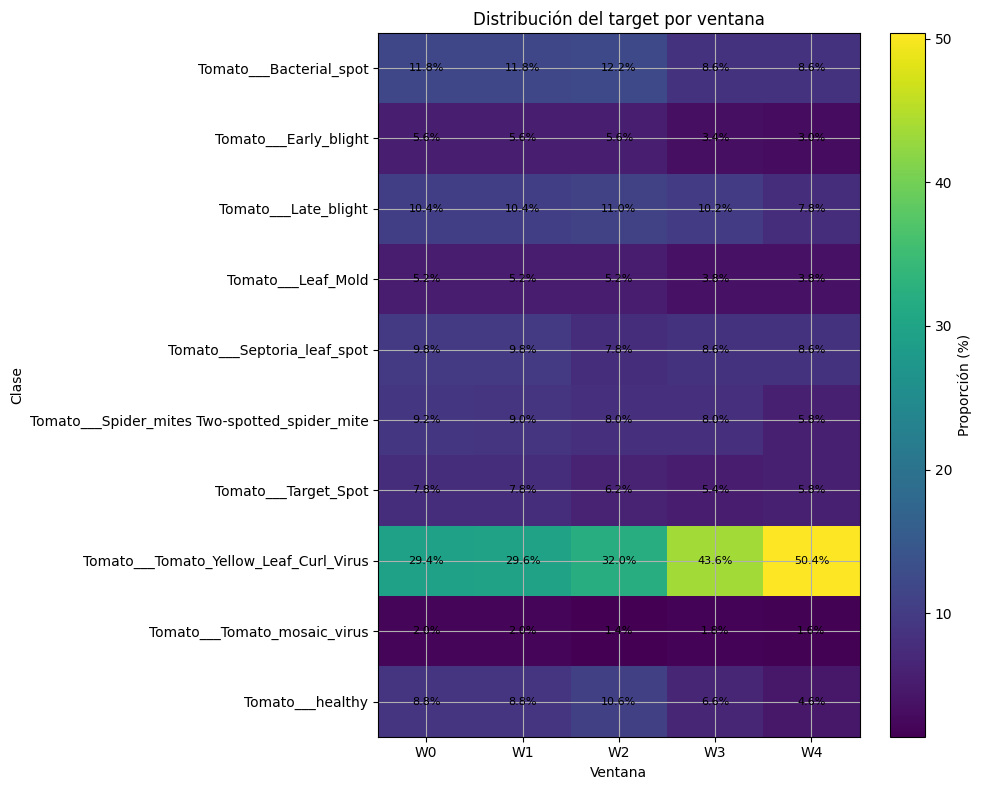

In [ ]:
# ============================================================
# 9.4 — MAPA DE CALOR DE LA DISTRIBUCIÓN DEL TARGET
# ============================================================
#
# Cada celda representa:
#
#       P(Y = clase | ventana)
#
# en porcentaje.
# ============================================================


import matplotlib.pyplot as plt


# ============================================================
# 1. MATRIZ PORCENTUAL
# ============================================================

matriz_target_9_4 = (

    df_target_proporciones_9_4[
        [
            "W0",
            "W1",
            "W2",
            "W3",
            "W4"
        ]
    ]

    *

    100
)


# ============================================================
# 2. FIGURA
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        10,
        8
    )
)


imagen_target_9_4 = ax.imshow(
    matriz_target_9_4.values,
    aspect="auto"
)


# ============================================================
# 3. EJES
# ============================================================

ax.set_xticks(
    np.arange(
        len(
            matriz_target_9_4.columns
        )
    )
)


ax.set_xticklabels(
    matriz_target_9_4.columns
)


ax.set_yticks(
    np.arange(
        len(
            matriz_target_9_4.index
        )
    )
)


ax.set_yticklabels(
    matriz_target_9_4.index
)


# ============================================================
# 4. VALORES
# ============================================================

for fila_9_4 in range(
    matriz_target_9_4.shape[0]
):

    for columna_9_4 in range(
        matriz_target_9_4.shape[1]
    ):

        valor_9_4 = (
            matriz_target_9_4
            .iloc[
                fila_9_4,
                columna_9_4
            ]
        )


        ax.text(
            columna_9_4,
            fila_9_4,
            f"{valor_9_4:.1f}%",
            ha="center",
            va="center",
            fontsize=8
        )


ax.set_title(
    "Distribución del target por ventana"
)


ax.set_xlabel(
    "Ventana"
)


ax.set_ylabel(
    "Clase"
)


fig.colorbar(
    imagen_target_9_4,
    ax=ax,
    label="Proporción (%)"
)


plt.tight_layout()


plt.show()

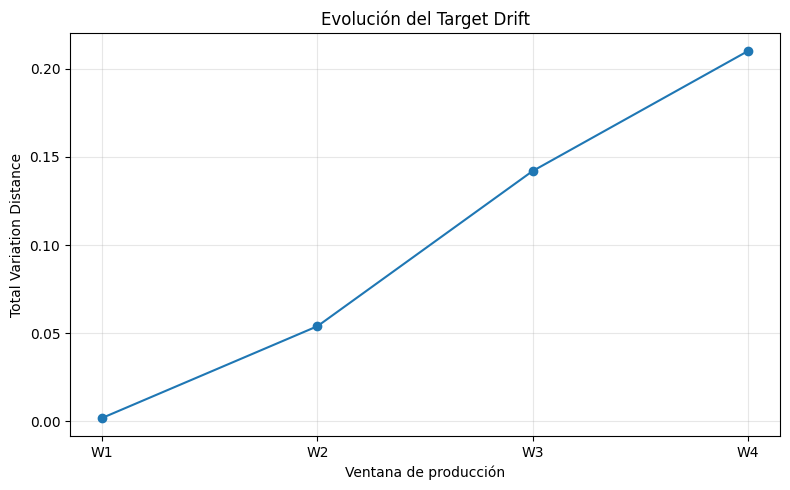

In [ ]:
# ============================================================
# 9.4 — EVOLUCIÓN DEL TARGET DRIFT
# ============================================================
#
# Se utiliza TVD porque posee una interpretación directa:
#
#       0 -> misma distribución
#       1 -> máxima separación posible
#
# ============================================================


fig, ax = plt.subplots(
    figsize=(
        8,
        5
    )
)


ax.plot(
    df_target_drift_9_4[
        "Ventana"
    ],

    df_target_drift_9_4[
        "TVD"
    ],

    marker="o"
)


ax.set_title(
    "Evolución del Target Drift"
)


ax.set_xlabel(
    "Ventana de producción"
)


ax.set_ylabel(
    "Total Variation Distance"
)


ax.grid(
    alpha=0.3
)


plt.tight_layout()


plt.show()

In [ ]:
# ============================================================
# 9.4 — PERSISTENCIA DEL DRIFT DEL TARGET
# ============================================================
#
# Se generan:
#
#       monitoring/target_distribution.csv
#       monitoring/target_drift_metrics.csv
#
# El archivo:
#
#       monitoring/drift_metrics.csv
#
# se reservará para la consolidación global de 9.6.
# ============================================================


from pathlib import Path


# ============================================================
# 1. DIRECTORIO
# ============================================================

MONITORING_DIR_9_4 = Path(
    "monitoring"
)


MONITORING_DIR_9_4.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. RUTAS
# ============================================================

TARGET_DISTRIBUTION_PATH_9_4 = (
    MONITORING_DIR_9_4
    /
    "target_distribution.csv"
)


TARGET_DRIFT_PATH_9_4 = (
    MONITORING_DIR_9_4
    /
    "target_drift_metrics.csv"
)


# ============================================================
# 3. DISTRIBUCIÓN EN FORMATO LARGO
# ============================================================

df_target_distribution_long_9_4 = (

    df_target_proporciones_9_4

    .reset_index()

    .melt(
        id_vars="Clase",
        var_name="Ventana",
        value_name="Proporcion"
    )
)


df_target_distribution_long_9_4[
    "Porcentaje"
] = (

    df_target_distribution_long_9_4[
        "Proporcion"
    ]

    *

    100
)


# ============================================================
# 4. GUARDAR
# ============================================================

df_target_distribution_long_9_4.to_csv(
    TARGET_DISTRIBUTION_PATH_9_4,
    index=False,
    encoding="utf-8"
)


df_target_drift_9_4.to_csv(
    TARGET_DRIFT_PATH_9_4,
    index=False,
    encoding="utf-8"
)


# ============================================================
# 5. VERIFICACIONES
# ============================================================

assert (
    TARGET_DISTRIBUTION_PATH_9_4.exists()
)


assert (
    TARGET_DRIFT_PATH_9_4.exists()
)


assert (
    len(
        df_target_drift_9_4
    )
    ==
    4
)


print("=" * 105)
print("DRIFT DEL TARGET PERSISTIDO")
print("=" * 105)


print(
    f"Distribuciones : "
    f"{TARGET_DISTRIBUTION_PATH_9_4}"
)


print(
    f"Métricas       : "
    f"{TARGET_DRIFT_PATH_9_4}"
)


print(
    "\n✅ Resultados de Target Drift almacenados."
)

DRIFT DEL TARGET PERSISTIDO
Distribuciones : monitoring/target_distribution.csv
Métricas       : monitoring/target_drift_metrics.csv

✅ Resultados de Target Drift almacenados.


## 9.4.7 Interpretación técnica del Drift del target

La distribución de la variable objetivo fue comparada entre.

## Resultado esperado en W1

fue construida mediante muestreo estratificado a partir del conjunto de validación.

## Resultado esperado en W2-W4

fueron construidas utilizando muestreo sesgado creciente.

## Target Drift no es Concept Drift

demuestra un cambio en la distribución marginal del target.

## Relación con la siguiente etapa

Esta sección resume relación con la siguiente etapa y su función dentro del proyecto MLOps.

## 9.5 Performance por ventana

Esta sección resume performance por ventana y su función dentro del proyecto MLOps.


## 9.5 Performance por ventana

Una vez cuantificado el cambio de las distribuciones mediante PSI, KS y Target Drift,.

## 9.5.1 Modelo evaluado

Se utilizará exactamente el mismo Pipeline campeón empaquetado durante la Fase 2.

## 9.5.2 Métrica principal: F1 macro

La métrica principal utilizada en el proyecto es.

## 9.5.3 Ventanas evaluadas

Esta sección resume ventanas evaluadas y su función dentro del proyecto MLOps.

## 9.5.4 Baseline de performance

Aunque se calculará performance en W0, esta ventana procede de la muestra de.

## 9.5.5 Cambio absoluto de performance

Para cada ventana de producción se calculará.

## 9.5.6 Pérdida relativa

De esta manera puede expresarse el deterioro relativo respecto de la producción.

## 9.5.7 Drift y performance son conceptos diferentes

El monitoreo realizado hasta ahora estudia diferentes componentes.


In [ ]:
# ============================================================
# FASE 4B — DETECCIÓN Y MONITOREO DE DATA DRIFT
# 9.5 PERFORMANCE POR VENTANA
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Evaluar el MISMO modelo campeón en:
#
#       W0
#       W1
#       W2
#       W3
#       W4
#
# MÉTRICA PRINCIPAL
# ------------------------------------------------------------
#
#       F1 macro
#
# También se conservarán métricas secundarias para apoyar
# la interpretación:
#
#       Accuracy
#       Balanced Accuracy
#       Precision macro
#       Recall macro
#
# IMPORTANTE
# ------------------------------------------------------------
# NO se realiza fit().
# NO se reentrena el modelo.
# NO se modifica ninguna ventana.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# ============================================================
# 2. VERIFICAR VENTANAS
# ============================================================

variables_requeridas_9_5 = [

    "X_W0_8_1",
    "y_W0_8_1",

    "X_W1_8_1",
    "y_W1_8_1",

    "X_W2_8_3",
    "y_W2_8_3",

    "X_W3_8_3",
    "y_W3_8_3",

    "X_W4_8_3",
    "y_W4_8_3"
]


faltantes_9_5 = [

    variable
    for variable
    in variables_requeridas_9_5
    if variable
    not in globals()
]


if faltantes_9_5:

    raise NameError(
        "Faltan variables necesarias de las fases anteriores: "
        f"{faltantes_9_5}"
    )


# ============================================================
# 3. CARGAR MODELO EMPAQUETADO
# ============================================================

MODEL_PATH_9_5 = Path(
    "models/model.joblib"
)


if not MODEL_PATH_9_5.exists():

    raise FileNotFoundError(
        "No existe models/model.joblib. "
        "Ejecute previamente la Fase 2."
    )


modelo_9_5 = joblib.load(
    MODEL_PATH_9_5
)


if not hasattr(
    modelo_9_5,
    "predict"
):

    raise TypeError(
        "El artefacto cargado no posee predict()."
    )


print("=" * 105)
print("9.5 — MODELO PARA EVALUACIÓN")
print("=" * 105)


print(
    f"Artefacto : "
    f"{MODEL_PATH_9_5}"
)


print(
    f"Tipo      : "
    f"{type(modelo_9_5).__name__}"
)


print(
    "Métrica   : F1 macro"
)


print(
    "\n✅ Modelo campeón cargado sin reentrenamiento."
)


# ============================================================
# 4. FEATURES DEL CONTRATO
# ============================================================
#
# Se intenta recuperar INPUT_FEATURES desde la API.
#
# Esto asegura el mismo contrato utilizado por /predict.
#
# ============================================================

try:

    from api.model_loader import (
        INPUT_FEATURES
    )


    FEATURES_PERFORMANCE_9_5 = list(
        INPUT_FEATURES
    )


except Exception:

    FEATURES_PERFORMANCE_9_5 = list(
        X_W0_8_1.columns
    )


# ============================================================
# 5. DEFINIR VENTANAS
# ============================================================

VENTANAS_PERFORMANCE_9_5 = {

    "W0": (
        X_W0_8_1,
        y_W0_8_1
    ),

    "W1": (
        X_W1_8_1,
        y_W1_8_1
    ),

    "W2": (
        X_W2_8_3,
        y_W2_8_3
    ),

    "W3": (
        X_W3_8_3,
        y_W3_8_3
    ),

    "W4": (
        X_W4_8_3,
        y_W4_8_3
    )
}


# ============================================================
# 6. FUNCIÓN DE EVALUACIÓN
# ============================================================

def evaluar_ventana_9_5(
    modelo,
    X,
    y,
    nombre_ventana
):
    """
    Evalúa una ventana utilizando un modelo ya entrenado.

    Parameters
    ----------
    modelo :
        Pipeline/modelo campeón ya entrenado.

    X : pd.DataFrame
        Features de la ventana.

    y : array-like
        Target real de la ventana.

    nombre_ventana : str
        Identificador W0-W4.

    Returns
    -------
    dict
        Métricas de clasificación.
    """


    # --------------------------------------------------------
    # Copia y orden del contrato
    # --------------------------------------------------------

    X_eval_9_5 = (
        X[
            FEATURES_PERFORMANCE_9_5
        ]
        .copy()
    )


    y_real_9_5 = np.asarray(
        y
    ).reshape(-1)


    # --------------------------------------------------------
    # Verificar tamaños
    # --------------------------------------------------------

    if len(
        X_eval_9_5
    ) != len(
        y_real_9_5
    ):

        raise ValueError(
            f"{nombre_ventana}: X e y poseen "
            "diferente número de observaciones."
        )


    # --------------------------------------------------------
    # Inferencia
    # --------------------------------------------------------

    y_pred_9_5 = modelo.predict(
        X_eval_9_5
    )


    # --------------------------------------------------------
    # Métricas
    # --------------------------------------------------------

    accuracy_9_5 = accuracy_score(
        y_real_9_5,
        y_pred_9_5
    )


    balanced_accuracy_9_5 = balanced_accuracy_score(
        y_real_9_5,
        y_pred_9_5
    )


    precision_macro_9_5 = precision_score(
        y_real_9_5,
        y_pred_9_5,
        average="macro",
        zero_division=0
    )


    recall_macro_9_5 = recall_score(
        y_real_9_5,
        y_pred_9_5,
        average="macro",
        zero_division=0
    )


    f1_macro_9_5 = f1_score(
        y_real_9_5,
        y_pred_9_5,
        average="macro",
        zero_division=0
    )


    # --------------------------------------------------------
    # Retorno
    # --------------------------------------------------------

    return {

        "Ventana":
            nombre_ventana,

        "N":
            int(
                len(
                    y_real_9_5
                )
            ),

        "Accuracy":
            float(
                accuracy_9_5
            ),

        "Balanced_Accuracy":
            float(
                balanced_accuracy_9_5
            ),

        "Precision_macro":
            float(
                precision_macro_9_5
            ),

        "Recall_macro":
            float(
                recall_macro_9_5
            ),

        "F1_macro":
            float(
                f1_macro_9_5
            )
    }


# ============================================================
# 7. EVALUAR W0-W4
# ============================================================

resultados_performance_9_5 = []


for ventana_9_5, (
    X_ventana_9_5,
    y_ventana_9_5
) in VENTANAS_PERFORMANCE_9_5.items():

    resultado_9_5 = evaluar_ventana_9_5(

        modelo=modelo_9_5,

        X=X_ventana_9_5,

        y=y_ventana_9_5,

        nombre_ventana=ventana_9_5
    )


    resultados_performance_9_5.append(
        resultado_9_5
    )


# ============================================================
# 8. DATAFRAME
# ============================================================

df_performance_9_5 = pd.DataFrame(
    resultados_performance_9_5
)


# ============================================================
# 9. CONTROLES
# ============================================================

assert (
    len(
        df_performance_9_5
    )
    ==
    5
)


assert (
    df_performance_9_5[
        "F1_macro"
    ]
    .between(
        0.0,
        1.0
    )
    .all()
)


# ============================================================
# 10. MOSTRAR
# ============================================================

print("\n" + "=" * 105)
print("PERFORMANCE DEL MODELO POR VENTANA")
print("=" * 105)


display(
    df_performance_9_5
    .round(
        {
            "Accuracy":
                4,

            "Balanced_Accuracy":
                4,

            "Precision_macro":
                4,

            "Recall_macro":
                4,

            "F1_macro":
                4
        }
    )
)

9.5 — MODELO PARA EVALUACIÓN
Artefacto : models/model.joblib
Tipo      : Pipeline
Métrica   : F1 macro

✅ Modelo campeón cargado sin reentrenamiento.

PERFORMANCE DEL MODELO POR VENTANA


,Ventana,N,Accuracy,Balanced_Accuracy,Precision_macro,Recall_macro,F1_macro
0,W0,500,1.0000,1.0000,1.0000,1.0000,1.0000
1,W1,500,0.8320,0.8000,0.8359,0.8000,0.8143
2,W2,500,0.7580,0.6744,0.7628,0.6744,0.6993
3,W3,500,0.6500,0.5408,0.5654,0.5408,0.5360
4,W4,500,0.4540,0.2756,0.4525,0.2756,0.2779


In [ ]:
# ============================================================
# 9.5 — CAMBIO DE PERFORMANCE RESPECTO DE W1
# ============================================================
#
# W1 funciona como baseline operacional:
#
#       W1 -> producción estable
#
# Para cada ventana:
#
#       Delta F1 = F1(Wi) - F1(W1)
#
#       Loss % =
#           100 * [F1(W1) - F1(Wi)] / F1(W1)
#
# ============================================================


# ============================================================
# 1. F1 DE REFERENCIA OPERACIONAL
# ============================================================

F1_W1_9_5 = float(

    df_performance_9_5
    .loc[
        df_performance_9_5[
            "Ventana"
        ]
        ==
        "W1",

        "F1_macro"
    ]
    .iloc[0]
)


# ============================================================
# 2. DELTA ABSOLUTO
# ============================================================

df_performance_9_5[
    "Delta_F1_vs_W1"
] = (

    df_performance_9_5[
        "F1_macro"
    ]

    -

    F1_W1_9_5
)


# ============================================================
# 3. PÉRDIDA RELATIVA
# ============================================================

if F1_W1_9_5 > 0:

    df_performance_9_5[
        "Perdida_relativa_pct_vs_W1"
    ] = (

        100

        *

        (
            F1_W1_9_5

            -

            df_performance_9_5[
                "F1_macro"
            ]
        )

        /

        F1_W1_9_5
    )


else:

    df_performance_9_5[
        "Perdida_relativa_pct_vs_W1"
    ] = np.nan


# ============================================================
# 4. INTERPRETACIÓN DEL CAMBIO
# ============================================================

def interpretar_delta_f1_9_5(
    delta,
    tolerancia=0.01
):
    """
    Clasificación descriptiva del cambio de F1.
    """

    if delta < -tolerancia:

        return "Deterioro"


    if delta > tolerancia:

        return "Mejora"


    return "Estable"


df_performance_9_5[
    "Estado_performance"
] = (
    df_performance_9_5[
        "Delta_F1_vs_W1"
    ]
    .apply(
        interpretar_delta_f1_9_5
    )
)


# ============================================================
# 5. MOSTRAR
# ============================================================

print("=" * 105)
print("CAMBIO DE F1 MACRO RESPECTO DE W1")
print("=" * 105)


display(
    df_performance_9_5[
        [
            "Ventana",
            "F1_macro",
            "Delta_F1_vs_W1",
            "Perdida_relativa_pct_vs_W1",
            "Estado_performance"
        ]
    ]
    .round(
        {
            "F1_macro":
                4,

            "Delta_F1_vs_W1":
                4,

            "Perdida_relativa_pct_vs_W1":
                2
        }
    )
)

CAMBIO DE F1 MACRO RESPECTO DE W1


,Ventana,F1_macro,Delta_F1_vs_W1,Perdida_relativa_pct_vs_W1,Estado_performance
0,W0,1.0000,0.1857,-22.8000,Mejora
1,W1,0.8143,0.0000,0.0000,Estable
2,W2,0.6993,-0.1150,14.1300,Deterioro
3,W3,0.5360,-0.2783,34.1700,Deterioro
4,W4,0.2779,-0.5365,65.8800,Deterioro


In [ ]:
# ============================================================
# 9.5 — PERSISTENCIA DE PERFORMANCE POR VENTANA
# ============================================================


# ============================================================
# 1. DIRECTORIO
# ============================================================

MONITORING_DIR_9_5 = Path(
    "monitoring"
)


MONITORING_DIR_9_5.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. ARCHIVO
# ============================================================

PERFORMANCE_PATH_9_5 = (
    MONITORING_DIR_9_5
    /
    "performance_metrics.csv"
)


# ============================================================
# 3. GUARDAR
# ============================================================

df_performance_9_5.to_csv(
    PERFORMANCE_PATH_9_5,
    index=False,
    encoding="utf-8"
)


# ============================================================
# 4. VERIFICAR
# ============================================================

assert (
    PERFORMANCE_PATH_9_5.exists()
)


assert (
    len(
        pd.read_csv(
            PERFORMANCE_PATH_9_5
        )
    )
    ==
    5
)


print("=" * 105)
print("PERFORMANCE PERSISTIDA")
print("=" * 105)


print(
    f"Archivo : "
    f"{PERFORMANCE_PATH_9_5}"
)


print(
    f"Filas   : "
    f"{len(df_performance_9_5)}"
)


print(
    "\n✅ monitoring/performance_metrics.csv creado."
)

PERFORMANCE PERSISTIDA
Archivo : monitoring/performance_metrics.csv
Filas   : 5

✅ monitoring/performance_metrics.csv creado.


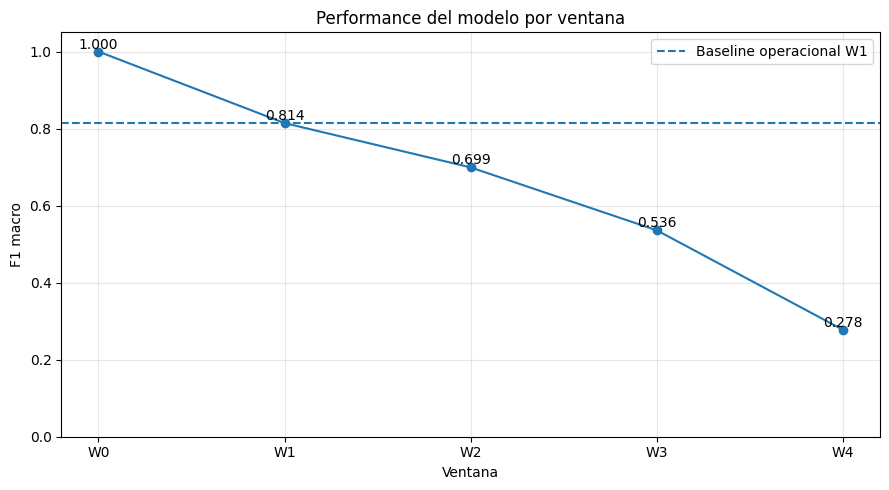

In [ ]:
# ============================================================
# 9.5 — EVOLUCIÓN DE F1 MACRO
# ============================================================
#
# El gráfico permite observar directamente si:
#
#       W1 -> W2 -> W3 -> W4
#
# muestra o no deterioro progresivo.
#
# ============================================================


import matplotlib.pyplot as plt


# ============================================================
# 1. ORDEN
# ============================================================

orden_ventanas_9_5 = [

    "W0",
    "W1",
    "W2",
    "W3",
    "W4"

]


df_plot_performance_9_5 = (

    df_performance_9_5

    .set_index(
        "Ventana"
    )

    .reindex(
        orden_ventanas_9_5
    )

    .reset_index()
)


# ============================================================
# 2. GRÁFICO
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        9,
        5
    )
)


ax.plot(

    df_plot_performance_9_5[
        "Ventana"
    ],

    df_plot_performance_9_5[
        "F1_macro"
    ],

    marker="o"
)


# ============================================================
# 3. BASELINE W1
# ============================================================

ax.axhline(
    y=F1_W1_9_5,
    linestyle="--",
    label="Baseline operacional W1"
)


# ============================================================
# 4. ETIQUETAS
# ============================================================

for _, fila_9_5 in (
    df_plot_performance_9_5
    .iterrows()
):

    ax.text(

        fila_9_5[
            "Ventana"
        ],

        fila_9_5[
            "F1_macro"
        ],

        f"{fila_9_5['F1_macro']:.3f}",

        ha="center",

        va="bottom"
    )


ax.set_title(
    "Performance del modelo por ventana"
)


ax.set_xlabel(
    "Ventana"
)


ax.set_ylabel(
    "F1 macro"
)


ax.set_ylim(
    0.0,
    1.05
)


ax.legend()


ax.grid(
    alpha=0.3
)


plt.tight_layout()


plt.show()

In [ ]:
# ============================================================
# 9.5 — RELACIÓN ENTRE DRIFT Y PERFORMANCE
# ============================================================
#
# Se combinan, para W1-W4:
#
#       PSI promedio
#       KS promedio
#       TVD del target
#       F1 macro
#
# Objetivo:
#
#       comprobar empíricamente
#
# si mayor drift coincide o no con menor performance.
#
# ============================================================


from pathlib import Path


# ============================================================
# 1. PERFORMANCE — SOLO PRODUCCIÓN
# ============================================================

df_relacion_9_5 = (

    df_performance_9_5[
        df_performance_9_5[
            "Ventana"
        ]
        .isin(
            [
                "W1",
                "W2",
                "W3",
                "W4"
            ]
        )
    ]

    .copy()
)


# ============================================================
# 2. PSI
# ============================================================

if "df_resumen_psi_9_1" in globals():

    psi_resumen_9_5 = (
        df_resumen_psi_9_1
        .copy()
    )


elif Path(
    "monitoring/psi_metrics.csv"
).exists():

    psi_raw_9_5 = pd.read_csv(
        "monitoring/psi_metrics.csv"
    )


    psi_resumen_9_5 = (

        psi_raw_9_5

        .groupby(
            "Ventana",
            as_index=False
        )

        .agg(
            PSI_promedio=(
                "PSI",
                "mean"
            ),

            PSI_maximo=(
                "PSI",
                "max"
            )
        )
    )


else:

    psi_resumen_9_5 = None


if psi_resumen_9_5 is not None:

    psi_resumen_9_5[
        "Ventana"
    ] = (
        psi_resumen_9_5[
            "Ventana"
        ]
        .astype(str)
    )


    columnas_psi_9_5 = [

        columna
        for columna
        in [
            "Ventana",
            "PSI_promedio",
            "PSI_maximo"
        ]
        if columna
        in psi_resumen_9_5.columns
    ]


    df_relacion_9_5 = (
        df_relacion_9_5
        .merge(

            psi_resumen_9_5[
                columnas_psi_9_5
            ],

            on="Ventana",

            how="left"
        )
    )


# ============================================================
# 3. KS
# ============================================================

if "df_resumen_ks_9_2" in globals():

    ks_resumen_9_5 = (
        df_resumen_ks_9_2
        .copy()
    )


elif Path(
    "monitoring/ks_metrics.csv"
).exists():

    ks_raw_9_5 = pd.read_csv(
        "monitoring/ks_metrics.csv"
    )


    ks_resumen_9_5 = (

        ks_raw_9_5

        .groupby(
            "Ventana",
            as_index=False
        )

        .agg(
            KS_promedio=(
                "KS_statistic",
                "mean"
            ),

            KS_maximo=(
                "KS_statistic",
                "max"
            )
        )
    )


else:

    ks_resumen_9_5 = None


if ks_resumen_9_5 is not None:

    ks_resumen_9_5[
        "Ventana"
    ] = (
        ks_resumen_9_5[
            "Ventana"
        ]
        .astype(str)
    )


    columnas_ks_9_5 = [

        columna
        for columna
        in [
            "Ventana",
            "KS_promedio",
            "KS_maximo"
        ]
        if columna
        in ks_resumen_9_5.columns
    ]


    df_relacion_9_5 = (
        df_relacion_9_5
        .merge(

            ks_resumen_9_5[
                columnas_ks_9_5
            ],

            on="Ventana",

            how="left"
        )
    )


# ============================================================
# 4. TARGET DRIFT
# ============================================================

if "df_target_drift_9_4" in globals():

    target_resumen_9_5 = (
        df_target_drift_9_4
        .copy()
    )


elif Path(
    "monitoring/target_drift_metrics.csv"
).exists():

    target_resumen_9_5 = pd.read_csv(
        "monitoring/target_drift_metrics.csv"
    )


else:

    target_resumen_9_5 = None


if target_resumen_9_5 is not None:

    target_resumen_9_5[
        "Ventana"
    ] = (
        target_resumen_9_5[
            "Ventana"
        ]
        .astype(str)
    )


    columnas_target_9_5 = [

        columna
        for columna
        in [
            "Ventana",
            "TVD",
            "Cramers_V"
        ]
        if columna
        in target_resumen_9_5.columns
    ]


    df_relacion_9_5 = (
        df_relacion_9_5
        .merge(

            target_resumen_9_5[
                columnas_target_9_5
            ],

            on="Ventana",

            how="left"
        )
    )


# ============================================================
# 5. ORDEN
# ============================================================

orden_prod_9_5 = {
    "W1": 1,
    "W2": 2,
    "W3": 3,
    "W4": 4
}


df_relacion_9_5[
    "_orden"
] = (
    df_relacion_9_5[
        "Ventana"
    ]
    .map(
        orden_prod_9_5
    )
)


df_relacion_9_5 = (

    df_relacion_9_5

    .sort_values(
        "_orden"
    )

    .drop(
        columns="_orden"
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# 6. MOSTRAR
# ============================================================

print("=" * 105)
print("DRIFT VS PERFORMANCE")
print("=" * 105)


columnas_mostrar_9_5 = [

    columna
    for columna
    in [
        "Ventana",

        "PSI_promedio",
        "KS_promedio",
        "TVD",

        "F1_macro",
        "Delta_F1_vs_W1",
        "Perdida_relativa_pct_vs_W1",
        "Estado_performance"
    ]
    if columna
    in df_relacion_9_5.columns
]


display(
    df_relacion_9_5[
        columnas_mostrar_9_5
    ]
    .round(4)
)

DRIFT VS PERFORMANCE


,Ventana,PSI_promedio,KS_promedio,TVD,F1_macro,Delta_F1_vs_W1,Perdida_relativa_pct_vs_W1,Estado_performance
0,W1,0.0485,0.0619,0.0020,0.8143,0.0000,0.0000,Estable
1,W2,0.1169,0.1228,0.0540,0.6993,-0.1150,14.1278,Deterioro
2,W3,0.4207,0.2072,0.1420,0.5360,-0.2783,34.1734,Deterioro
3,W4,1.1721,0.3344,0.2100,0.2779,-0.5365,65.8793,Deterioro


In [ ]:
# ============================================================
# 9.5 — ASOCIACIÓN EXPLORATORIA DRIFT VS PERFORMANCE
# ============================================================
#
# Se utiliza Spearman porque:
#
#   - solo existen cuatro ventanas de producción;
#   - interesa estudiar tendencia monotónica;
#   - no se supone linealidad.
#
# IMPORTANTE
# ------------------------------------------------------------
# Con N=4 esta correlación es EXPLORATORIA.
#
# No debe presentarse como una prueba concluyente.
#
# ============================================================


from scipy.stats import (
    spearmanr
)


# ============================================================
# 1. INDICADORES DISPONIBLES
# ============================================================

indicadores_drift_9_5 = [

    columna
    for columna
    in [
        "PSI_promedio",
        "KS_promedio",
        "TVD"
    ]
    if columna
    in df_relacion_9_5.columns
]


# ============================================================
# 2. CALCULAR CORRELACIONES
# ============================================================

resultados_correlacion_9_5 = []


for indicador_9_5 in (
    indicadores_drift_9_5
):

    datos_validos_9_5 = (

        df_relacion_9_5[
            [
                indicador_9_5,
                "F1_macro"
            ]
        ]

        .dropna()
    )


    # --------------------------------------------------------
    # Se requieren al menos 3 observaciones y variabilidad.
    # --------------------------------------------------------

    if (
        len(
            datos_validos_9_5
        )
        >=
        3

        and

        datos_validos_9_5[
            indicador_9_5
        ]
        .nunique()
        >
        1
    ):

        rho_9_5, p_9_5 = spearmanr(

            datos_validos_9_5[
                indicador_9_5
            ],

            datos_validos_9_5[
                "F1_macro"
            ]
        )


        # ----------------------------------------------------
        # Interpretación direccional
        # ----------------------------------------------------

        if rho_9_5 < -0.5:

            interpretacion_9_5 = (
                "Mayor drift tiende a asociarse "
                "con menor F1"
            )


        elif rho_9_5 > 0.5:

            interpretacion_9_5 = (
                "Mayor drift no coincide con deterioro; "
                "F1 tiende a aumentar"
            )


        else:

            interpretacion_9_5 = (
                "No se observa una asociación monotónica fuerte"
            )


        resultados_correlacion_9_5.append(
            {
                "Indicador_drift":
                    indicador_9_5,

                "rho_Spearman":
                    float(
                        rho_9_5
                    ),

                "p_value":
                    float(
                        p_9_5
                    ),

                "N_ventanas":
                    int(
                        len(
                            datos_validos_9_5
                        )
                    ),

                "Interpretacion":
                    interpretacion_9_5
            }
        )


# ============================================================
# 3. TABLA
# ============================================================

df_correlacion_drift_performance_9_5 = (
    pd.DataFrame(
        resultados_correlacion_9_5
    )
)


print("=" * 105)
print("ASOCIACIÓN EXPLORATORIA DRIFT — F1 MACRO")
print("=" * 105)


if not df_correlacion_drift_performance_9_5.empty:

    display(
        df_correlacion_drift_performance_9_5
        .round(
            {
                "rho_Spearman":
                    4,

                "p_value":
                    4
            }
        )
    )


    print(
        "\n⚠️ Interpretación descriptiva: "
        "solo existen cuatro ventanas de producción."
    )


else:

    print(
        "No existen suficientes métricas de drift "
        "para calcular asociaciones."
    )

ASOCIACIÓN EXPLORATORIA DRIFT — F1 MACRO


,Indicador_drift,rho_Spearman,p_value,N_ventanas,Interpretacion
0,PSI_promedio,-1.0000,0.0000,4,Mayor drift tiende a asociarse con menor F1
1,KS_promedio,-1.0000,0.0000,4,Mayor drift tiende a asociarse con menor F1
2,TVD,-1.0000,0.0000,4,Mayor drift tiende a asociarse con menor F1



⚠️ Interpretación descriptiva: solo existen cuatro ventanas de producción.


In [ ]:
# ============================================================
# 9.5 — INTERPRETACIÓN AUTOMÁTICA
# ============================================================


# ============================================================
# 1. RECUPERAR F1 W1-W4
# ============================================================

f1_por_ventana_9_5 = (

    df_performance_9_5

    .set_index(
        "Ventana"
    )[
        "F1_macro"
    ]

    .to_dict()
)


F1_W2_9_5 = f1_por_ventana_9_5[
    "W2"
]


F1_W3_9_5 = f1_por_ventana_9_5[
    "W3"
]


F1_W4_9_5 = f1_por_ventana_9_5[
    "W4"
]


# ============================================================
# 2. COMPROBAR TENDENCIA
# ============================================================

deterioro_monotono_9_5 = (

    F1_W1_9_5
    >=
    F1_W2_9_5
    >=
    F1_W3_9_5
    >=
    F1_W4_9_5
)


print("=" * 105)
print("INTERPRETACIÓN DE PERFORMANCE")
print("=" * 105)


print(
    f"F1 macro W1 : {F1_W1_9_5:.4f}"
)


print(
    f"F1 macro W2 : {F1_W2_9_5:.4f}"
)


print(
    f"F1 macro W3 : {F1_W3_9_5:.4f}"
)


print(
    f"F1 macro W4 : {F1_W4_9_5:.4f}"
)


print()


# ============================================================
# 3. CONCLUSIÓN
# ============================================================

if deterioro_monotono_9_5:

    print(
        "✅ Se observa una reducción monotónica de F1 macro "
        "a medida que avanzan las ventanas."
    )


    print(
        "Esto es consistente con una asociación entre "
        "el drift simulado y deterioro de performance."
    )


else:

    print(
        "✅ No se observa una caída estrictamente monotónica "
        "de F1 macro."
    )


    print(
        "Por tanto, el experimento confirma que detectar drift "
        "no implica automáticamente una reducción inmediata "
        "de performance."
    )


print(
    "\nLa conclusión definitiva debe considerar "
    "PSI, KS, Target Drift y F1 macro conjuntamente."
)

INTERPRETACIÓN DE PERFORMANCE
F1 macro W1 : 0.8143
F1 macro W2 : 0.6993
F1 macro W3 : 0.5360
F1 macro W4 : 0.2779

✅ Se observa una reducción monotónica de F1 macro a medida que avanzan las ventanas.
Esto es consistente con una asociación entre el drift simulado y deterioro de performance.

La conclusión definitiva debe considerar PSI, KS, Target Drift y F1 macro conjuntamente.


## 9.5.8 Interpretación técnica

Esta sección resume interpretación técnica y su función dentro del proyecto MLOps.

## Performance de W0

Esta sección resume performance de W0 y su función dentro del proyecto MLOps.

## Comparación operacional

Esta sección resume comparación operacional y su función dentro del proyecto MLOps.

## Data Drift sin deterioro

Esta sección resume data Drift sin deterioro y su función dentro del proyecto MLOps.

## Drift con deterioro de performance

Un escenario de mayor preocupación ocurre cuando se observa conjuntamente.

## No confundir correlación con causalidad

La comparación entre las cuatro ventanas permite analizar una asociación descriptiva.

## Cierre de 9.5

Esta sección resume cierre de 9.5 y su función dentro del proyecto MLOps.

## 9.6 Tabla consolidada de monitoreo

donde las métricas serán integradas en una estructura única para alimentar.


## 9.6 Tabla consolidada de monitoreo

Las secciones anteriores generaron distintos indicadores para evaluar el comportamiento.

## 9.6.1 Unidad de monitoreo

Esta sección resume unidad de monitoreo y su función dentro del proyecto MLOps.

## 9.6.2 Consolidación de las métricas

En el proyecto actual todas las features de entrada son numéricas.

## 9.6.3 Regla de severidad para variables numéricas

Para PSI se mantienen los criterios operacionales definidos previamente.

## 9.6.4 Regla operacional para KS

Si existe significancia estadística ajustada.

## 9.6.5 Estado compacto

Para mantener compatibilidad con la tabla solicitada, los niveles completos se.

## 9.6.6 Estado general de una ventana

Una ventana contiene múltiples features.

## 9.6.7 Performance y drift

Esta sección resume performance y drift y su función dentro del proyecto MLOps.

## 9.6.8 Objetivo operacional

La tabla consolidada será la principal fuente de datos para.


In [ ]:
# ============================================================
# FASE 4B — DETECCIÓN Y MONITOREO DE DATA DRIFT
# 9.6 TABLA CONSOLIDADA DE MONITOREO
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Integrar:
#
#       PSI
#       KS
#       Chi² del target
#       Target Drift
#       Performance
#
# SIN recalcular las métricas.
#
# FUENTES
# ------------------------------------------------------------
#
#       monitoring/psi_metrics.csv
#       monitoring/ks_metrics.csv
#       monitoring/target_drift_metrics.csv
#       monitoring/performance_metrics.csv
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import (
    display
)


# ============================================================
# 2. DIRECTORIO DE MONITOREO
# ============================================================

MONITORING_DIR_9_6 = Path(
    "monitoring"
)


MONITORING_DIR_9_6.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 3. FUNCIÓN AUXILIAR
# ============================================================

def recuperar_dataframe_9_6(
    nombre_variable,
    ruta_csv
):
    """
    Recupera un DataFrame desde:

    1. memoria del notebook, si existe;
    2. archivo CSV, como alternativa.

    Esto evita recalcular las métricas.
    """


    if nombre_variable in globals():

        dataframe_9_6 = (
            globals()[
                nombre_variable
            ]
            .copy()
        )


        print(
            f"✅ {nombre_variable}: "
            "recuperado desde memoria."
        )


        return dataframe_9_6


    ruta_csv = Path(
        ruta_csv
    )


    if ruta_csv.exists():

        dataframe_9_6 = pd.read_csv(
            ruta_csv
        )


        print(
            f"✅ {nombre_variable}: "
            f"recuperado desde {ruta_csv}."
        )


        return dataframe_9_6


    raise FileNotFoundError(
        f"No se encontró {nombre_variable} "
        f"ni el archivo {ruta_csv}."
    )


# ============================================================
# 4. RECUPERAR PSI
# ============================================================

df_psi_base_9_6 = recuperar_dataframe_9_6(

    nombre_variable=(
        "df_psi_9_1"
    ),

    ruta_csv=(
        MONITORING_DIR_9_6
        /
        "psi_metrics.csv"
    )
)


# ============================================================
# 5. RECUPERAR KS
# ============================================================

df_ks_base_9_6 = recuperar_dataframe_9_6(

    nombre_variable=(
        "df_ks_9_2"
    ),

    ruta_csv=(
        MONITORING_DIR_9_6
        /
        "ks_metrics.csv"
    )
)


# ============================================================
# 6. RECUPERAR TARGET DRIFT
# ============================================================

df_target_base_9_6 = recuperar_dataframe_9_6(

    nombre_variable=(
        "df_target_drift_9_4"
    ),

    ruta_csv=(
        MONITORING_DIR_9_6
        /
        "target_drift_metrics.csv"
    )
)


# ============================================================
# 7. RECUPERAR PERFORMANCE
# ============================================================

df_performance_base_9_6 = recuperar_dataframe_9_6(

    nombre_variable=(
        "df_performance_9_5"
    ),

    ruta_csv=(
        MONITORING_DIR_9_6
        /
        "performance_metrics.csv"
    )
)


print("\n" + "=" * 105)
print("9.6 — FUENTES DE MONITOREO RECUPERADAS")
print("=" * 105)


print(
    f"PSI         : "
    f"{len(df_psi_base_9_6)} filas"
)


print(
    f"KS          : "
    f"{len(df_ks_base_9_6)} filas"
)


print(
    f"Target Drift: "
    f"{len(df_target_base_9_6)} filas"
)


print(
    f"Performance : "
    f"{len(df_performance_base_9_6)} filas"
)

✅ df_psi_9_1: recuperado desde memoria.
✅ df_ks_9_2: recuperado desde memoria.
✅ df_target_drift_9_4: recuperado desde memoria.
✅ df_performance_9_5: recuperado desde memoria.

9.6 — FUENTES DE MONITOREO RECUPERADAS
PSI         : 60 filas
KS          : 60 filas
Target Drift: 4 filas
Performance : 5 filas


In [ ]:
# ============================================================
# 9.6 — CONSOLIDAR FEATURES NUMÉRICAS
# ============================================================
#
# Para cada:
#
#       Ventana + Feature
#
# se integran:
#
#       PSI
#       KS
#       p-value FDR
#       F1 macro
#
# ============================================================


# ============================================================
# 1. NORMALIZAR PSI
# ============================================================

columnas_psi_requeridas_9_6 = [

    "Ventana",
    "Feature",
    "PSI"
]


faltantes_psi_9_6 = [

    columna
    for columna
    in columnas_psi_requeridas_9_6
    if columna
    not in df_psi_base_9_6.columns
]


if faltantes_psi_9_6:

    raise KeyError(
        "PSI no contiene las columnas: "
        f"{faltantes_psi_9_6}"
    )


df_psi_merge_9_6 = (

    df_psi_base_9_6[
        columnas_psi_requeridas_9_6
    ]

    .copy()
)


df_psi_merge_9_6[
    "Ventana"
] = (
    df_psi_merge_9_6[
        "Ventana"
    ]
    .astype(str)
)


df_psi_merge_9_6[
    "Feature"
] = (
    df_psi_merge_9_6[
        "Feature"
    ]
    .astype(str)
)


# ============================================================
# 2. NORMALIZAR KS
# ============================================================

columnas_ks_requeridas_9_6 = [

    "Ventana",
    "Feature",
    "KS_statistic"
]


faltantes_ks_9_6 = [

    columna
    for columna
    in columnas_ks_requeridas_9_6
    if columna
    not in df_ks_base_9_6.columns
]


if faltantes_ks_9_6:

    raise KeyError(
        "KS no contiene las columnas: "
        f"{faltantes_ks_9_6}"
    )


columnas_ks_merge_9_6 = [

    columna
    for columna
    in [
        "Ventana",
        "Feature",
        "KS_statistic",
        "p_value",
        "p_value_fdr",
        "Significativo_FDR",
        "Magnitud_KS"
    ]
    if columna
    in df_ks_base_9_6.columns
]


df_ks_merge_9_6 = (

    df_ks_base_9_6[
        columnas_ks_merge_9_6
    ]

    .copy()
)


df_ks_merge_9_6[
    "Ventana"
] = (
    df_ks_merge_9_6[
        "Ventana"
    ]
    .astype(str)
)


df_ks_merge_9_6[
    "Feature"
] = (
    df_ks_merge_9_6[
        "Feature"
    ]
    .astype(str)
)


# ============================================================
# 3. MERGE PSI + KS
# ============================================================

df_features_9_6 = (
    df_psi_merge_9_6
    .merge(

        df_ks_merge_9_6,

        on=[
            "Ventana",
            "Feature"
        ],

        how="inner",

        validate="one_to_one"
    )
)


# ============================================================
# 4. CONTROL ESPERADO
# ============================================================
#
# 15 features x 4 ventanas:
#
#       60 registros
#
# ============================================================

N_FEATURES_MONITOREADAS_9_6 = (
    df_features_9_6[
        "Feature"
    ]
    .nunique()
)


N_VENTANAS_MONITOREADAS_9_6 = (
    df_features_9_6[
        "Ventana"
    ]
    .nunique()
)


N_ESPERADO_FEATURES_9_6 = (

    N_FEATURES_MONITOREADAS_9_6

    *

    N_VENTANAS_MONITOREADAS_9_6
)


if (
    len(
        df_features_9_6
    )
    !=
    N_ESPERADO_FEATURES_9_6
):

    raise ValueError(
        "La unión PSI-KS no produjo el número "
        "esperado de registros."
    )


print("=" * 105)
print("PSI + KS CONSOLIDADOS")
print("=" * 105)


print(
    f"Features : "
    f"{N_FEATURES_MONITOREADAS_9_6}"
)


print(
    f"Ventanas : "
    f"{N_VENTANAS_MONITOREADAS_9_6}"
)


print(
    f"Filas    : "
    f"{len(df_features_9_6)}"
)

PSI + KS CONSOLIDADOS
Features : 15
Ventanas : 4
Filas    : 60


In [ ]:
# ============================================================
# 9.6 — REGLA CONSOLIDADA DE DRIFT POR FEATURE
# ============================================================


# ============================================================
# 1. UMBRALES
# ============================================================

PSI_WARNING_9_6 = 0.10

PSI_DRIFT_9_6 = 0.20

KS_WARNING_9_6 = 0.10

KS_DRIFT_9_6 = 0.20

ALPHA_FDR_9_6 = 0.05


# ============================================================
# 2. FUNCIÓN PARA PSI
# ============================================================

def severidad_psi_9_6(
    psi
):
    """
    0 = Normal
    1 = Warning
    2 = Drift significativo
    """


    psi = float(
        psi
    )


    if psi >= PSI_DRIFT_9_6:

        return 2


    if psi >= PSI_WARNING_9_6:

        return 1


    return 0


# ============================================================
# 3. FUNCIÓN PARA KS
# ============================================================

def severidad_ks_9_6(
    ks,
    p_fdr
):
    """
    KS utiliza conjuntamente:

        magnitud
        +
        significancia FDR

    Una significancia estadística con efecto muy pequeño
    no genera por sí sola una alerta alta.
    """


    ks = float(
        ks
    )


    if pd.isna(
        p_fdr
    ):

        significativo = False

    else:

        significativo = (
            float(
                p_fdr
            )
            <
            ALPHA_FDR_9_6
        )


    if (
        significativo
        and
        ks >= KS_DRIFT_9_6
    ):

        return 2


    if (
        significativo
        and
        ks >= KS_WARNING_9_6
    ):

        return 1


    return 0


# ============================================================
# 4. DETERMINAR p-value AJUSTADO DISPONIBLE
# ============================================================

if (
    "p_value_fdr"
    not in
    df_features_9_6.columns
):

    # Si por alguna razón el CSV procede de una versión
    # previa, utilizar p_value como fallback.
    if (
        "p_value"
        in
        df_features_9_6.columns
    ):

        df_features_9_6[
            "p_value_fdr"
        ] = (
            df_features_9_6[
                "p_value"
            ]
        )

    else:

        df_features_9_6[
            "p_value_fdr"
        ] = np.nan


# ============================================================
# 5. SEVERIDADES
# ============================================================

df_features_9_6[
    "Severidad_PSI"
] = (
    df_features_9_6[
        "PSI"
    ]
    .apply(
        severidad_psi_9_6
    )
)


df_features_9_6[
    "Severidad_KS"
] = [

    severidad_ks_9_6(
        ks=ks_9_6,
        p_fdr=p_9_6
    )

    for ks_9_6, p_9_6
    in zip(

        df_features_9_6[
            "KS_statistic"
        ],

        df_features_9_6[
            "p_value_fdr"
        ]
    )
]


# ============================================================
# 6. SEVERIDAD FINAL
# ============================================================

df_features_9_6[
    "Nivel_Drift"
] = (

    df_features_9_6[
        [
            "Severidad_PSI",
            "Severidad_KS"
        ]
    ]
    .max(
        axis=1
    )
)


# ============================================================
# 7. ETIQUETAS
# ============================================================

MAPA_SEVERIDAD_9_6 = {

    0:
        "Normal",

    1:
        "Warning",

    2:
        "Drift significativo"
}


MAPA_DRIFT_COMPACTO_9_6 = {

    0:
        "No",

    1:
        "Warning",

    2:
        "Sí"
}


df_features_9_6[
    "Severidad"
] = (
    df_features_9_6[
        "Nivel_Drift"
    ]
    .map(
        MAPA_SEVERIDAD_9_6
    )
)


df_features_9_6[
    "Drift"
] = (
    df_features_9_6[
        "Nivel_Drift"
    ]
    .map(
        MAPA_DRIFT_COMPACTO_9_6
    )
)


print(
    "✅ Estado de drift consolidado para "
    f"{len(df_features_9_6)} registros."
)

✅ Estado de drift consolidado para 60 registros.


In [ ]:
# ============================================================
# 9.6 — INCORPORAR PERFORMANCE
# ============================================================
#
# La performance es una propiedad de la ventana completa.
#
# Por ello:
#
#       F1(Wi)
#
# se repetirá en todas las features pertenecientes a Wi.
#
# ============================================================


# ============================================================
# 1. VALIDAR PERFORMANCE
# ============================================================

if (
    "Ventana"
    not in
    df_performance_base_9_6.columns

    or

    "F1_macro"
    not in
    df_performance_base_9_6.columns
):

    raise KeyError(
        "performance_metrics no contiene "
        "Ventana y F1_macro."
    )


# ============================================================
# 2. COLUMNAS DISPONIBLES
# ============================================================

columnas_performance_9_6 = [

    columna
    for columna
    in [
        "Ventana",
        "F1_macro",
        "Delta_F1_vs_W1",
        "Perdida_relativa_pct_vs_W1",
        "Estado_performance"
    ]
    if columna
    in df_performance_base_9_6.columns
]


df_performance_merge_9_6 = (

    df_performance_base_9_6[
        columnas_performance_9_6
    ]

    .copy()
)


df_performance_merge_9_6[
    "Ventana"
] = (
    df_performance_merge_9_6[
        "Ventana"
    ]
    .astype(str)
)


# ============================================================
# 3. MERGE
# ============================================================

df_features_9_6 = (
    df_features_9_6
    .merge(

        df_performance_merge_9_6,

        on="Ventana",

        how="left",

        validate="many_to_one"
    )
)


# ============================================================
# 4. RENOMBRAR PERFORMANCE PRINCIPAL
# ============================================================

df_features_9_6[
    "Performance"
] = (
    df_features_9_6[
        "F1_macro"
    ]
)


print(
    "✅ F1 macro incorporado a cada "
    "registro de monitoreo."
)

✅ F1 macro incorporado a cada registro de monitoreo.


In [ ]:
# ============================================================
# 9.6 — INCORPORAR TARGET DRIFT
# ============================================================
#
# Las features de X utilizan:
#
#       PSI + KS
#
# El target utiliza:
#
#       Chi² + Cramér's V + TVD
#
# Se representa mediante:
#
#       Feature = TARGET
#
# ============================================================


# ============================================================
# 1. FUNCIÓN DE SEVERIDAD DEL TARGET
# ============================================================

def severidad_target_9_6(
    cramers_v,
    p_fdr
):
    """
    Clasificación contextual del Target Drift.

    0 = Normal
    1 = Warning
    2 = Drift significativo
    """


    if pd.isna(
        cramers_v
    ):

        return 0


    v_9_6 = float(
        cramers_v
    )


    if pd.isna(
        p_fdr
    ):

        significativo_9_6 = False

    else:

        significativo_9_6 = (
            float(
                p_fdr
            )
            <
            0.05
        )


    if (
        significativo_9_6
        and
        v_9_6 >= 0.30
    ):

        return 2


    if (
        significativo_9_6
        and
        v_9_6 >= 0.10
    ):

        return 1


    return 0


# ============================================================
# 2. PREPARAR TARGET
# ============================================================

df_target_monitor_9_6 = (
    df_target_base_9_6
    .copy()
)


df_target_monitor_9_6[
    "Ventana"
] = (
    df_target_monitor_9_6[
        "Ventana"
    ]
    .astype(str)
)


# ------------------------------------------------------------
# p-value ajustado
# ------------------------------------------------------------

if (
    "p_value_fdr"
    not in
    df_target_monitor_9_6.columns
):

    if (
        "p_value"
        in
        df_target_monitor_9_6.columns
    ):

        df_target_monitor_9_6[
            "p_value_fdr"
        ] = (
            df_target_monitor_9_6[
                "p_value"
            ]
        )

    else:

        df_target_monitor_9_6[
            "p_value_fdr"
        ] = np.nan


# ============================================================
# 3. COLUMNAS COMPATIBLES CON LA TABLA CONSOLIDADA
# ============================================================

df_target_rows_9_6 = pd.DataFrame(
    {
        "Ventana":
            df_target_monitor_9_6[
                "Ventana"
            ],

        "Feature":
            "TARGET",

        "PSI":
            np.nan,

        "KS_statistic":
            np.nan,

        "Chi2":
            (
                df_target_monitor_9_6[
                    "Chi2"
                ]
                if "Chi2"
                in df_target_monitor_9_6.columns
                else np.nan
            ),

        "p_value_fdr":
            df_target_monitor_9_6[
                "p_value_fdr"
            ],

        "Cramers_V":
            (
                df_target_monitor_9_6[
                    "Cramers_V"
                ]
                if "Cramers_V"
                in df_target_monitor_9_6.columns
                else np.nan
            ),

        "TVD":
            (
                df_target_monitor_9_6[
                    "TVD"
                ]
                if "TVD"
                in df_target_monitor_9_6.columns
                else np.nan
            )
    }
)


# ============================================================
# 4. SEVERIDAD TARGET
# ============================================================

df_target_rows_9_6[
    "Nivel_Drift"
] = [

    severidad_target_9_6(
        cramers_v=v_9_6,
        p_fdr=p_9_6
    )

    for v_9_6, p_9_6
    in zip(

        df_target_rows_9_6[
            "Cramers_V"
        ],

        df_target_rows_9_6[
            "p_value_fdr"
        ]
    )
]


df_target_rows_9_6[
    "Severidad"
] = (
    df_target_rows_9_6[
        "Nivel_Drift"
    ]
    .map(
        MAPA_SEVERIDAD_9_6
    )
)


df_target_rows_9_6[
    "Drift"
] = (
    df_target_rows_9_6[
        "Nivel_Drift"
    ]
    .map(
        MAPA_DRIFT_COMPACTO_9_6
    )
)


# ============================================================
# 5. PERFORMANCE DEL TARGET
# ============================================================

df_target_rows_9_6 = (
    df_target_rows_9_6
    .merge(

        df_performance_merge_9_6,

        on="Ventana",

        how="left",

        validate="one_to_one"
    )
)


df_target_rows_9_6[
    "Performance"
] = (
    df_target_rows_9_6[
        "F1_macro"
    ]
)


print(
    "✅ Target Drift preparado para consolidación."
)

✅ Target Drift preparado para consolidación.


In [ ]:
# ============================================================
# 9.6 — TABLA CONSOLIDADA FINAL
# ============================================================


# ============================================================
# 1. PREPARAR FILAS DE FEATURES
# ============================================================

df_features_final_9_6 = (
    df_features_9_6
    .copy()
)


df_features_final_9_6[
    "Tipo"
] = "Feature numérica"


df_features_final_9_6[
    "Metrica_secundaria"
] = "KS"


df_features_final_9_6[
    "KS/Chi2"
] = (
    df_features_final_9_6[
        "KS_statistic"
    ]
)


# ============================================================
# 2. PREPARAR FILAS TARGET
# ============================================================

df_target_rows_9_6[
    "Tipo"
] = "Target"


df_target_rows_9_6[
    "Metrica_secundaria"
] = "Chi2"


df_target_rows_9_6[
    "KS/Chi2"
] = (
    df_target_rows_9_6[
        "Chi2"
    ]
)


# ============================================================
# 3. UNIR
# ============================================================

df_monitoring_9_6 = pd.concat(
    [
        df_features_final_9_6,
        df_target_rows_9_6
    ],
    ignore_index=True,
    sort=False
)


# ============================================================
# 4. ORDEN DE VENTANAS
# ============================================================

orden_ventanas_9_6 = pd.CategoricalDtype(

    categories=[
        "W1",
        "W2",
        "W3",
        "W4"
    ],

    ordered=True
)


df_monitoring_9_6[
    "Ventana"
] = (
    df_monitoring_9_6[
        "Ventana"
    ]
    .astype(
        orden_ventanas_9_6
    )
)


df_monitoring_9_6 = (

    df_monitoring_9_6

    .sort_values(
        [
            "Ventana",
            "Feature"
        ]
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# 5. COLUMNAS PRINCIPALES
# ============================================================

COLUMNAS_TABLA_9_6 = [

    "Ventana",
    "Feature",
    "PSI",
    "KS/Chi2",
    "Drift",
    "Performance"
]


# ============================================================
# 6. MOSTRAR TABLA SOLICITADA
# ============================================================

print("=" * 110)
print("9.6 — TABLA CONSOLIDADA DE MONITOREO")
print("=" * 110)


display(
    df_monitoring_9_6[
        COLUMNAS_TABLA_9_6
    ]
    .round(
        {
            "PSI":
                4,

            "KS/Chi2":
                4,

            "Performance":
                4
        }
    )
)

9.6 — TABLA CONSOLIDADA DE MONITOREO


,Ventana,Feature,PSI,KS/Chi2,Drift,Performance
0,W1,TARGET,NaN,0.0144,No,0.8143
1,W1,b_mean,0.0501,0.0740,No,0.8143
2,W1,b_std,0.0419,0.0520,No,0.8143
3,W1,brightness_mean,0.0695,0.1120,Warning,0.8143
4,W1,contrast_std,0.0766,0.0560,No,0.8143
5,W1,edge_density,0.0121,0.0360,No,0.8143
6,W1,entropy,0.0598,0.0500,No,0.8143
7,W1,excess_green,0.0375,0.0580,No,0.8143
8,W1,g_mean,0.0431,0.0800,No,0.8143
9,W1,g_std,0.0377,0.0560,No,0.8143


In [ ]:
# ============================================================
# 9.6 — RESUMEN DE MONITOREO POR VENTANA
# ============================================================
#
# Estado de una ventana:
#
#       S(Wi) = max_j Sij
#
# ============================================================


# ============================================================
# 1. AGREGAR POR VENTANA
# ============================================================

df_resumen_ventanas_9_6 = (

    df_monitoring_9_6

    .groupby(
        "Ventana",
        observed=True
    )

    .agg(

        Nivel_Drift=(
            "Nivel_Drift",
            "max"
        ),

        N_elementos_monitorizados=(
            "Feature",
            "count"
        ),

        Performance=(
            "Performance",
            "first"
        )
    )

    .reset_index()
)


# ============================================================
# 2. CONTAR WARNINGS
# ============================================================

conteos_severidad_9_6 = (

    df_monitoring_9_6

    .pivot_table(

        index="Ventana",

        columns="Severidad",

        values="Feature",

        aggfunc="count",

        fill_value=0,

        observed=True
    )

    .reset_index()
)


df_resumen_ventanas_9_6 = (
    df_resumen_ventanas_9_6
    .merge(

        conteos_severidad_9_6,

        on="Ventana",

        how="left"
    )
)


# ============================================================
# 3. ASEGURAR COLUMNAS
# ============================================================

for columna_9_6 in [

    "Normal",
    "Warning",
    "Drift significativo"

]:

    if columna_9_6 not in (
        df_resumen_ventanas_9_6.columns
    ):

        df_resumen_ventanas_9_6[
            columna_9_6
        ] = 0


# ============================================================
# 4. ETIQUETAS GENERALES
# ============================================================

df_resumen_ventanas_9_6[
    "Estado_general"
] = (
    df_resumen_ventanas_9_6[
        "Nivel_Drift"
    ]
    .map(
        MAPA_SEVERIDAD_9_6
    )
)


# ============================================================
# 5. FEATURES QUE PRODUJERON ALERTA
# ============================================================

features_alerta_9_6 = (

    df_monitoring_9_6[
        df_monitoring_9_6[
            "Nivel_Drift"
        ]
        >
        0
    ]

    .groupby(
        "Ventana",
        observed=True
    )[
        "Feature"
    ]

    .apply(
        lambda serie: ", ".join(
            serie.astype(str)
        )
    )

    .reset_index(
        name="Elementos_alerta"
    )
)


df_resumen_ventanas_9_6 = (
    df_resumen_ventanas_9_6
    .merge(

        features_alerta_9_6,

        on="Ventana",

        how="left"
    )
)


df_resumen_ventanas_9_6[
    "Elementos_alerta"
] = (
    df_resumen_ventanas_9_6[
        "Elementos_alerta"
    ]
    .fillna(
        "Ninguno"
    )
)


# ============================================================
# 6. MOSTRAR
# ============================================================

print("=" * 110)
print("RESUMEN GENERAL POR VENTANA")
print("=" * 110)


display(
    df_resumen_ventanas_9_6[
        [
            "Ventana",
            "Estado_general",
            "Normal",
            "Warning",
            "Drift significativo",
            "Performance",
            "Elementos_alerta"
        ]
    ]
    .round(
        {
            "Performance":
                4
        }
    )
)

RESUMEN GENERAL POR VENTANA


,Ventana,Estado_general,Normal,Warning,Drift significativo,Performance,Elementos_alerta
0,W1,Warning,15,1,0,0.8143,brightness_mean
1,W2,Drift significativo,5,9,2,0.6993,"b_mean, brightness_mean, contrast_std, edge_density, entropy, g_std, h_mean, laplacian_variance, r_mean, s_mean, v_mean"
2,W3,Drift significativo,0,7,9,0.5360,"TARGET, b_mean, b_std, brightness_mean, contrast_std, edge_density, entropy, excess_green, g_mean, g_std, h_mean, la..."
3,W4,Drift significativo,0,1,15,0.2779,"TARGET, b_mean, b_std, brightness_mean, contrast_std, edge_density, entropy, excess_green, g_mean, g_std, h_mean, la..."


In [ ]:
# ============================================================
# 9.6 — INCORPORAR W0 COMO REFERENCIA DEL SISTEMA
# ============================================================
#
# W0 no se incluye en los 60 tests de drift porque es la
# distribución de referencia.
#
# Sí se incorpora al resumen general para:
#
#       evolución W0 -> W4
#
# ============================================================


# ============================================================
# 1. OBTENER PERFORMANCE DE W0
# ============================================================

fila_W0_9_6 = (
    df_performance_base_9_6[
        df_performance_base_9_6[
            "Ventana"
        ]
        .astype(str)
        ==
        "W0"
    ]
)


if not fila_W0_9_6.empty:

    F1_W0_9_6 = float(
        fila_W0_9_6[
            "F1_macro"
        ]
        .iloc[0]
    )


    resumen_W0_9_6 = pd.DataFrame(
        {
            "Ventana": [
                "W0"
            ],

            "Estado_general": [
                "Referencia"
            ],

            "Normal": [
                np.nan
            ],

            "Warning": [
                np.nan
            ],

            "Drift significativo": [
                np.nan
            ],

            "Performance": [
                F1_W0_9_6
            ],

            "Elementos_alerta": [
                "No aplica — ventana de referencia"
            ]
        }
    )


    df_resumen_completo_9_6 = pd.concat(
        [
            resumen_W0_9_6,

            df_resumen_ventanas_9_6[
                [
                    "Ventana",
                    "Estado_general",
                    "Normal",
                    "Warning",
                    "Drift significativo",
                    "Performance",
                    "Elementos_alerta"
                ]
            ]
        ],

        ignore_index=True
    )


else:

    df_resumen_completo_9_6 = (
        df_resumen_ventanas_9_6
        .copy()
    )


print("=" * 110)
print("EVOLUCIÓN GENERAL W0-W4")
print("=" * 110)


display(
    df_resumen_completo_9_6
    .round(
        {
            "Performance":
                4
        }
    )
)

EVOLUCIÓN GENERAL W0-W4


,Ventana,Estado_general,Normal,Warning,Drift significativo,Performance,Elementos_alerta
0,W0,Referencia,NaN,NaN,NaN,1.0000,No aplica — ventana de referencia
1,W1,Warning,15.0000,1.0000,0.0000,0.8143,brightness_mean
2,W2,Drift significativo,5.0000,9.0000,2.0000,0.6993,"b_mean, brightness_mean, contrast_std, edge_density, entropy, g_std, h_mean, laplacian_variance, r_mean, s_mean, v_mean"
3,W3,Drift significativo,0.0000,7.0000,9.0000,0.5360,"TARGET, b_mean, b_std, brightness_mean, contrast_std, edge_density, entropy, excess_green, g_mean, g_std, h_mean, la..."
4,W4,Drift significativo,0.0000,1.0000,15.0000,0.2779,"TARGET, b_mean, b_std, brightness_mean, contrast_std, edge_density, entropy, excess_green, g_mean, g_std, h_mean, la..."


In [ ]:
# ============================================================
# 9.6 — PERSISTENCIA DE LA TABLA CONSOLIDADA
# ============================================================
#
# PRODUCTO PRINCIPAL:
#
#       monitoring/drift_metrics.csv
#
# También se conserva:
#
#       monitoring/window_summary.csv
#
# para facilitar el dashboard.
#
# ============================================================


# ============================================================
# 1. RUTAS
# ============================================================

DRIFT_METRICS_PATH_9_6 = (
    MONITORING_DIR_9_6
    /
    "drift_metrics.csv"
)


WINDOW_SUMMARY_PATH_9_6 = (
    MONITORING_DIR_9_6
    /
    "window_summary.csv"
)


# ============================================================
# 2. COLUMNAS PARA PERSISTENCIA
# ============================================================
#
# Las seis primeras corresponden exactamente a la tabla
# solicitada.
#
# Las columnas posteriores conservan trazabilidad técnica.
#
# ============================================================

columnas_persistencia_9_6 = [

    # --------------------------------------------------------
    # Tabla requerida
    # --------------------------------------------------------

    "Ventana",
    "Feature",
    "PSI",
    "KS/Chi2",
    "Drift",
    "Performance",

    # --------------------------------------------------------
    # Auditoría técnica
    # --------------------------------------------------------

    "Tipo",
    "Metrica_secundaria",
    "Severidad",
    "Nivel_Drift",
    "p_value_fdr",
    "KS_statistic",
    "Cramers_V",
    "TVD",
    "Delta_F1_vs_W1",
    "Perdida_relativa_pct_vs_W1",
    "Estado_performance"
]


columnas_persistencia_9_6 = [

    columna
    for columna
    in columnas_persistencia_9_6
    if columna
    in df_monitoring_9_6.columns
]


# ============================================================
# 3. GUARDAR
# ============================================================

df_monitoring_9_6[
    columnas_persistencia_9_6
].to_csv(

    DRIFT_METRICS_PATH_9_6,

    index=False,

    encoding="utf-8"
)


df_resumen_completo_9_6.to_csv(

    WINDOW_SUMMARY_PATH_9_6,

    index=False,

    encoding="utf-8"
)


# ============================================================
# 4. VALIDAR
# ============================================================

assert (
    DRIFT_METRICS_PATH_9_6.exists()
)


assert (
    WINDOW_SUMMARY_PATH_9_6.exists()
)


df_drift_check_9_6 = pd.read_csv(
    DRIFT_METRICS_PATH_9_6
)


# 15 features x 4 ventanas + 4 filas del target.
N_MINIMO_ESPERADO_9_6 = (

    15
    *
    4

    +

    4
)


assert (
    len(
        df_drift_check_9_6
    )
    >=
    N_MINIMO_ESPERADO_9_6
)


print("=" * 110)
print("9.6 — TABLA CONSOLIDADA PERSISTIDA")
print("=" * 110)


print(
    f"Archivo principal : "
    f"{DRIFT_METRICS_PATH_9_6}"
)


print(
    f"Resumen ventanas  : "
    f"{WINDOW_SUMMARY_PATH_9_6}"
)


print(
    f"Registros         : "
    f"{len(df_drift_check_9_6)}"
)


print(
    "\n✅ monitoring/drift_metrics.csv creado correctamente."
)

9.6 — TABLA CONSOLIDADA PERSISTIDA
Archivo principal : monitoring/drift_metrics.csv
Resumen ventanas  : monitoring/window_summary.csv
Registros         : 64

✅ monitoring/drift_metrics.csv creado correctamente.


In [ ]:
# ============================================================
# 9.6 — CONTROL DE CONSISTENCIA DEL MONITOREO
# ============================================================


# ============================================================
# 1. CAMPOS OBLIGATORIOS
# ============================================================

campos_obligatorios_9_6 = [

    "Ventana",
    "Feature",
    "PSI",
    "KS/Chi2",
    "Drift",
    "Performance"
]


faltantes_finales_9_6 = [

    columna
    for columna
    in campos_obligatorios_9_6
    if columna
    not in df_monitoring_9_6.columns
]


if faltantes_finales_9_6:

    raise KeyError(
        "La tabla consolidada no contiene: "
        f"{faltantes_finales_9_6}"
    )


# ============================================================
# 2. VENTANAS
# ============================================================

ventanas_en_tabla_9_6 = set(
    df_monitoring_9_6[
        "Ventana"
    ]
    .astype(str)
)


ventanas_esperadas_9_6 = {
    "W1",
    "W2",
    "W3",
    "W4"
}


assert (
    ventanas_en_tabla_9_6
    ==
    ventanas_esperadas_9_6
)


# ============================================================
# 3. PERFORMANCE DISPONIBLE
# ============================================================

assert (
    df_monitoring_9_6[
        "Performance"
    ]
    .notna()
    .all()
)


# ============================================================
# 4. ETIQUETAS DE DRIFT VÁLIDAS
# ============================================================

estados_drift_validos_9_6 = {

    "No",
    "Warning",
    "Sí"
}


assert (
    set(
        df_monitoring_9_6[
            "Drift"
        ]
        .dropna()
        .unique()
    )
    .issubset(
        estados_drift_validos_9_6
    )
)


# ============================================================
# 5. RESULTADO
# ============================================================

print("=" * 110)
print("CONTROL FINAL — FASE 4B")
print("=" * 110)


print(
    "Ventanas W1-W4            : ✅"
)


print(
    "PSI por feature           : ✅"
)


print(
    "KS por feature            : ✅"
)


print(
    "Target Drift              : ✅"
)


print(
    "Performance por ventana   : ✅"
)


print(
    "Estado de drift           : ✅"
)


print(
    "drift_metrics.csv         : ✅"
)


print(
    "\n✅ Tabla consolidada lista para Streamlit."
)

CONTROL FINAL — FASE 4B
Ventanas W1-W4            : ✅
PSI por feature           : ✅
KS por feature            : ✅
Target Drift              : ✅
Performance por ventana   : ✅
Estado de drift           : ✅
drift_metrics.csv         : ✅

✅ Tabla consolidada lista para Streamlit.


## 9.6.9 Interpretación técnica de la tabla consolidada

La tabla de monitoreo integra en una única estructura los tres componentes principales.

## Lectura de una fila

Esta sección resume lectura de una fila y su función dentro del proyecto MLOps.

## Interpretación del estado

resume la evidencia obtenida mediante las métricas de una variable.

## Estado de la ventana

Esta sección resume estado de la ventana y su función dentro del proyecto MLOps.

## Relación con performance

La tabla permite distinguir escenarios como.

## Producto final de la Fase 4B

Esta sección resume producto final de la Fase 4B y su función dentro del proyecto MLOps.

## 9.7 Dashboard Streamlit

Con ello queda completada la consolidación de métricas requerida para la Fase 4B.


## 9.7 Dashboard Streamlit

El dashboard constituye la capa de visualización del sistema de monitoreo MLOps.

## 9.7.1 Arquitectura

Esta sección resume arquitectura y su función dentro del proyecto MLOps.

## 9.7.2 Estado general del sistema

Esta sección resume estado general del sistema y su función dentro del proyecto MLOps.

## 9.7.3 Performance del modelo

Esta sección resume performance del modelo y su función dentro del proyecto MLOps.

## 9.7.4 Drift por feature

Para cada feature numérica se visualizarán.

## 9.7.5 Evolución por ventanas simuladas

El dataset no posee una dimensión temporal real de captura.

## 9.7.6 Acciones recomendadas

El dashboard mostrará recomendaciones operacionales según el estado.


In [ ]:
# ============================================================
# FASE 4B — MONITOREO
# 9.7 DASHBOARD STREAMLIT
# ============================================================
#
# PASO 1
# ------------------------------------------------------------
# Verificar que existan los productos de 9.6.
#
# El dashboard NO debe recalcular:
#
#       PSI
#       KS
#       Target Drift
#       Performance
#
# Solo debe consumir los resultados persistidos.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import pandas as pd

from IPython.display import (
    display
)


# ============================================================
# 2. RUTAS
# ============================================================

MONITORING_DIR_9_7 = Path(
    "monitoring"
)


DRIFT_METRICS_PATH_9_7 = (
    MONITORING_DIR_9_7
    /
    "drift_metrics.csv"
)


WINDOW_SUMMARY_PATH_9_7 = (
    MONITORING_DIR_9_7
    /
    "window_summary.csv"
)


# ============================================================
# 3. VERIFICAR EXISTENCIA
# ============================================================

archivos_dashboard_9_7 = {

    "drift_metrics.csv":
        DRIFT_METRICS_PATH_9_7,

    "window_summary.csv":
        WINDOW_SUMMARY_PATH_9_7
}


resultado_archivos_9_7 = []


for nombre_9_7, ruta_9_7 in (
    archivos_dashboard_9_7.items()
):

    resultado_archivos_9_7.append(
        {
            "Archivo":
                nombre_9_7,

            "Existe":
                ruta_9_7.exists(),

            "Ruta":
                str(
                    ruta_9_7
                )
        }
    )


df_archivos_dashboard_9_7 = pd.DataFrame(
    resultado_archivos_9_7
)


print("=" * 105)
print("9.7 — ARCHIVOS PARA STREAMLIT")
print("=" * 105)


display(
    df_archivos_dashboard_9_7
)


if not df_archivos_dashboard_9_7[
    "Existe"
].all():

    faltantes_9_7 = (
        df_archivos_dashboard_9_7
        .loc[
            ~df_archivos_dashboard_9_7[
                "Existe"
            ],
            "Archivo"
        ]
        .tolist()
    )


    raise FileNotFoundError(
        "Faltan archivos necesarios para el dashboard: "
        f"{faltantes_9_7}. "
        "Ejecute previamente la sección 9.6."
    )


print(
    "\n✅ Archivos de monitoreo disponibles."
)

9.7 — ARCHIVOS PARA STREAMLIT


,Archivo,Existe,Ruta
0,drift_metrics.csv,True,monitoring/drift_metrics.csv
1,window_summary.csv,True,monitoring/window_summary.csv



✅ Archivos de monitoreo disponibles.


In [ ]:
# ============================================================
# 9.7 — VALIDACIÓN DEL CONTRATO DE DATOS
# ============================================================


# ============================================================
# 1. CARGAR ARCHIVOS
# ============================================================

df_drift_dashboard_9_7 = pd.read_csv(
    DRIFT_METRICS_PATH_9_7
)


df_summary_dashboard_9_7 = pd.read_csv(
    WINDOW_SUMMARY_PATH_9_7
)


# ============================================================
# 2. COLUMNAS MÍNIMAS
# ============================================================

columnas_drift_obligatorias_9_7 = [

    "Ventana",
    "Feature",
    "PSI",
    "KS/Chi2",
    "Drift",
    "Performance"
]


columnas_summary_obligatorias_9_7 = [

    "Ventana",
    "Estado_general",
    "Performance",
    "Elementos_alerta"
]


# ============================================================
# 3. COMPROBAR
# ============================================================

faltantes_drift_9_7 = [

    columna
    for columna
    in columnas_drift_obligatorias_9_7
    if columna
    not in df_drift_dashboard_9_7.columns
]


faltantes_summary_9_7 = [

    columna
    for columna
    in columnas_summary_obligatorias_9_7
    if columna
    not in df_summary_dashboard_9_7.columns
]


if faltantes_drift_9_7:

    raise KeyError(
        "drift_metrics.csv no contiene: "
        f"{faltantes_drift_9_7}"
    )


if faltantes_summary_9_7:

    raise KeyError(
        "window_summary.csv no contiene: "
        f"{faltantes_summary_9_7}"
    )


# ============================================================
# 4. RESUMEN
# ============================================================

print("=" * 105)
print("CONTRATO DEL DASHBOARD")
print("=" * 105)


print(
    f"Registros drift : "
    f"{len(df_drift_dashboard_9_7)}"
)


print(
    f"Ventanas summary: "
    f"{len(df_summary_dashboard_9_7)}"
)


print(
    f"Features        : "
    f"{df_drift_dashboard_9_7['Feature'].nunique()}"
)


print(
    "\n✅ Contrato compatible con Streamlit."
)

CONTRATO DEL DASHBOARD
Registros drift : 64
Ventanas summary: 5
Features        : 16

✅ Contrato compatible con Streamlit.


In [ ]:
# ============================================================
# 9.7 — CREAR DASHBOARD STREAMLIT
# ============================================================
#
# PRODUCTO:
#
#       dashboard/dashboard.py
#
# SECCIONES
# ------------------------------------------------------------
# 1. Estado general.
# 2. Performance.
# 3. Drift por feature.
# 4. Evolución por ventana.
# 5. Elementos que generaron alerta.
# 6. Acciones recomendadas.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import textwrap


# ============================================================
# 2. DIRECTORIO
# ============================================================

DASHBOARD_DIR_9_7 = Path(
    "dashboard"
)


DASHBOARD_DIR_9_7.mkdir(
    parents=True,
    exist_ok=True
)


DASHBOARD_PATH_9_7 = (
    DASHBOARD_DIR_9_7
    /
    "dashboard.py"
)


# ============================================================
# 3. CÓDIGO STREAMLIT
# ============================================================

CODIGO_DASHBOARD_9_7 = textwrap.dedent(
r'''
from pathlib import Path

import numpy as np
import pandas as pd
import streamlit as st


# ============================================================
# CONFIGURACIÓN DE PÁGINA
# ============================================================

st.set_page_config(
    page_title="MLOps Data Drift Monitor",
    page_icon="📊",
    layout="wide"
)


# ============================================================
# CONSTANTES
# ============================================================

PROJECT_ROOT = (
    Path(__file__)
    .resolve()
    .parents[1]
)


MONITORING_DIR = (
    PROJECT_ROOT
    /
    "monitoring"
)


DRIFT_PATH = (
    MONITORING_DIR
    /
    "drift_metrics.csv"
)


SUMMARY_PATH = (
    MONITORING_DIR
    /
    "window_summary.csv"
)


ORDEN_VENTANAS = [
    "W0",
    "W1",
    "W2",
    "W3",
    "W4"
]


SEVERIDAD = {

    "Referencia":
        0,

    "Normal":
        0,

    "No":
        0,

    "Warning":
        1,

    "Drift":
        2,

    "Sí":
        2,

    "Drift significativo":
        2
}


# ============================================================
# FUNCIONES
# ============================================================

def cargar_datos():
    """
    Carga los productos consolidados de la Fase 4B.
    """

    if not DRIFT_PATH.exists():

        st.error(
            f"No existe: {DRIFT_PATH}"
        )

        st.stop()


    if not SUMMARY_PATH.exists():

        st.error(
            f"No existe: {SUMMARY_PATH}"
        )

        st.stop()


    drift = pd.read_csv(
        DRIFT_PATH
    )


    summary = pd.read_csv(
        SUMMARY_PATH
    )


    return (
        drift,
        summary
    )


def ordenar_ventanas(
    dataframe
):
    """
    Ordena W0-W4 de manera operacional.
    """

    resultado = (
        dataframe
        .copy()
    )


    resultado[
        "_orden"
    ] = (
        resultado[
            "Ventana"
        ]
        .map(
            {
                ventana: i
                for i, ventana
                in enumerate(
                    ORDEN_VENTANAS
                )
            }
        )
    )


    resultado = (

        resultado

        .sort_values(
            "_orden"
        )

        .drop(
            columns="_orden"
        )

        .reset_index(
            drop=True
        )
    )


    return resultado


def accion_recomendada(
    estado
):
    """
    Política informativa del dashboard.

    La ejecución automática del plan de acción
    corresponde a la Fase 5.
    """

    estado = str(
        estado
    )


    if estado in {
        "Referencia",
        "Normal",
        "No"
    }:

        return (
            "Continuar monitoreando. "
            "No se requiere intervención inmediata."
        )


    if estado == "Warning":

        return (
            "Realizar revisión manual, inspeccionar las "
            "variables que generaron advertencia y aumentar "
            "la frecuencia de seguimiento."
        )


    return (
        "Evaluar reentrenamiento, rollback o intervención "
        "semi-automática. Confirmar también si existe "
        "deterioro de performance antes de actuar."
    )


def mostrar_estado(
    estado
):
    """
    Muestra el estado usando los componentes nativos
    de Streamlit.
    """

    if estado in {
        "Referencia",
        "Normal",
        "No"
    }:

        st.success(
            f"Estado actual: {estado}"
        )


    elif estado == "Warning":

        st.warning(
            "Estado actual: WARNING"
        )


    else:

        st.error(
            f"Estado actual: {estado}"
        )


# ============================================================
# CARGA
# ============================================================

df_drift, df_summary = cargar_datos()


df_drift[
    "Ventana"
] = (
    df_drift[
        "Ventana"
    ]
    .astype(str)
)


df_summary[
    "Ventana"
] = (
    df_summary[
        "Ventana"
    ]
    .astype(str)
)


df_summary = ordenar_ventanas(
    df_summary
)


# ============================================================
# CABECERA
# ============================================================

st.title(
    "📊 MLOps Local — Monitoreo de Data Drift"
)


st.caption(
    "PlantVillage · clasificación multiclase · "
    "ventanas de producción simuladas"
)


st.info(
    "W0–W4 representan ventanas experimentales de producción. "
    "No corresponden a fechas reales de captura del dataset."
)


# ============================================================
# SIDEBAR
# ============================================================

st.sidebar.header(
    "Controles"
)


ventanas_disponibles = [

    ventana
    for ventana
    in ORDEN_VENTANAS
    if ventana
    in set(
        df_summary[
            "Ventana"
        ]
    )
]


ventana_seleccionada = (
    st.sidebar.selectbox(
        "Ventana",
        ventanas_disponibles,
        index=(
            len(
                ventanas_disponibles
            )
            -
            1
        )
    )
)


features_disponibles = sorted(
    [
        feature
        for feature
        in df_drift[
            "Feature"
        ]
        .dropna()
        .unique()

        if str(
            feature
        ).upper()
        !=
        "TARGET"
    ]
)


feature_seleccionada = (
    st.sidebar.selectbox(
        "Feature",
        features_disponibles
    )
)


if st.sidebar.button(
    "Recargar datos"
):

    st.rerun()


# ============================================================
# ESTADO GENERAL ACTUAL
# ============================================================

produccion = (
    df_summary[
        df_summary[
            "Ventana"
        ]
        .isin(
            [
                "W1",
                "W2",
                "W3",
                "W4"
            ]
        )
    ]
)


if not produccion.empty:

    fila_actual = (
        ordenar_ventanas(
            produccion
        )
        .iloc[-1]
    )

else:

    fila_actual = (
        df_summary
        .iloc[-1]
    )


estado_actual = str(
    fila_actual[
        "Estado_general"
    ]
)


performance_actual = float(
    fila_actual[
        "Performance"
    ]
)


ventana_actual = str(
    fila_actual[
        "Ventana"
    ]
)


# ============================================================
# KPI SUPERIORES
# ============================================================

st.subheader(
    "1. Estado general del sistema"
)


mostrar_estado(
    estado_actual
)


col1, col2, col3, col4 = st.columns(
    4
)


col1.metric(
    "Ventana actual",
    ventana_actual
)


col2.metric(
    "F1 macro actual",
    f"{performance_actual:.4f}"
)


# ------------------------------------------------------------
# Alertas de la ventana actual
# ------------------------------------------------------------

alertas_actuales = (
    df_drift[
        (
            df_drift[
                "Ventana"
            ]
            ==
            ventana_actual
        )
        &
        (
            df_drift[
                "Drift"
            ]
            !=
            "No"
        )
    ]
)


col3.metric(
    "Elementos con alerta",
    int(
        len(
            alertas_actuales
        )
    )
)


if (
    "Drift significativo"
    in
    df_summary.columns
):

    n_drift_actual = int(
        fila_actual.get(
            "Drift significativo",
            0
        )
        if pd.notna(
            fila_actual.get(
                "Drift significativo",
                np.nan
            )
        )
        else 0
    )

else:

    n_drift_actual = int(
        (
            alertas_actuales[
                "Drift"
            ]
            ==
            "Sí"
        )
        .sum()
    )


col4.metric(
    "Drift significativo",
    n_drift_actual
)


# ============================================================
# PERFORMANCE
# ============================================================

st.divider()


st.subheader(
    "2. Performance del modelo por ventana"
)


performance_plot = (

    df_summary[
        [
            "Ventana",
            "Performance"
        ]
    ]

    .dropna()

    .copy()
)


performance_plot = ordenar_ventanas(
    performance_plot
)


performance_chart = (

    performance_plot

    .set_index(
        "Ventana"
    )[
        [
            "Performance"
        ]
    ]
)


st.line_chart(
    performance_chart
)


st.caption(
    "Performance = F1 macro. W0 se muestra como referencia; "
    "W1 representa el baseline operacional estable."
)


with st.expander(
    "Ver tabla de performance"
):

    st.dataframe(
        performance_plot,
        use_container_width=True,
        hide_index=True
    )


# ============================================================
# DRIFT POR FEATURE
# ============================================================

st.divider()


st.subheader(
    "3. Métricas de drift por feature"
)


df_feature = (

    df_drift[
        df_drift[
            "Feature"
        ]
        ==
        feature_seleccionada
    ]

    .copy()
)


df_feature = ordenar_ventanas(
    df_feature
)


st.markdown(
    f"### `{feature_seleccionada}`"
)


col_psi, col_ks = st.columns(
    2
)


with col_psi:

    st.markdown(
        "**Population Stability Index (PSI)**"
    )


    psi_plot = (

        df_feature[
            [
                "Ventana",
                "PSI"
            ]
        ]

        .dropna()

        .set_index(
            "Ventana"
        )
    )


    st.line_chart(
        psi_plot
    )


    st.caption(
        "Referencia operacional: "
        "PSI < 0.10 normal; 0.10–0.20 warning; "
        "PSI ≥ 0.20 drift significativo."
    )


with col_ks:

    st.markdown(
        "**Kolmogorov-Smirnov / métrica secundaria**"
    )


    ks_plot = (

        df_feature[
            [
                "Ventana",
                "KS/Chi2"
            ]
        ]

        .dropna()

        .set_index(
            "Ventana"
        )
    )


    st.line_chart(
        ks_plot
    )


with st.expander(
    "Detalle técnico de la feature"
):

    columnas_detalle = [

        columna
        for columna
        in [
            "Ventana",
            "Feature",
            "PSI",
            "KS/Chi2",
            "p_value_fdr",
            "Severidad",
            "Drift",
            "Performance"
        ]
        if columna
        in df_feature.columns
    ]


    st.dataframe(
        df_feature[
            columnas_detalle
        ],
        use_container_width=True,
        hide_index=True
    )


# ============================================================
# EVOLUCIÓN DEL ESTADO
# ============================================================

st.divider()


st.subheader(
    "4. Evolución por ventanas de producción"
)


df_estado = (
    df_summary[
        [
            "Ventana",
            "Estado_general"
        ]
    ]
    .copy()
)


df_estado[
    "Severidad"
] = (
    df_estado[
        "Estado_general"
    ]
    .map(
        SEVERIDAD
    )
    .fillna(
        0
    )
)


df_estado = ordenar_ventanas(
    df_estado
)


st.line_chart(
    df_estado
    .set_index(
        "Ventana"
    )[
        [
            "Severidad"
        ]
    ]
)


st.caption(
    "Escala: 0 = Normal/Referencia · "
    "1 = Warning · 2 = Drift significativo. "
    "El eje representa ventanas simuladas, no tiempo calendario."
)


st.dataframe(
    df_estado,
    use_container_width=True,
    hide_index=True
)


# ============================================================
# VARIABLES QUE GENERARON ALERTA
# ============================================================

st.divider()


st.subheader(
    "5. Variables que generaron alerta"
)


df_alertas = (

    df_drift[
        df_drift[
            "Drift"
        ]
        .isin(
            [
                "Warning",
                "Sí"
            ]
        )
    ]

    .copy()
)


df_alertas = ordenar_ventanas(
    df_alertas
)


if df_alertas.empty:

    st.success(
        "No existen elementos con alerta."
    )


else:

    columnas_alerta = [

        columna
        for columna
        in [
            "Ventana",
            "Feature",
            "PSI",
            "KS/Chi2",
            "Drift",
            "Performance"
        ]
        if columna
        in df_alertas.columns
    ]


    st.dataframe(
        df_alertas[
            columnas_alerta
        ],
        use_container_width=True,
        hide_index=True
    )


    # --------------------------------------------------------
    # Alertas de ventana seleccionada
    # --------------------------------------------------------

    alertas_ventana = (

        df_alertas[
            df_alertas[
                "Ventana"
            ]
            ==
            ventana_seleccionada
        ]
    )


    st.markdown(
        f"**Alertas en {ventana_seleccionada}:** "
        f"{len(alertas_ventana)}"
    )


# ============================================================
# TARGET DRIFT
# ============================================================

df_target = (

    df_drift[
        df_drift[
            "Feature"
        ]
        .astype(str)
        .str.upper()
        ==
        "TARGET"
    ]

    .copy()
)


if not df_target.empty:

    st.divider()


    st.subheader(
        "6. Drift del target"
    )


    df_target = ordenar_ventanas(
        df_target
    )


    columnas_target = [

        columna
        for columna
        in [
            "Ventana",
            "KS/Chi2",
            "Cramers_V",
            "TVD",
            "Drift",
            "Performance"
        ]
        if columna
        in df_target.columns
    ]


    st.dataframe(
        df_target[
            columnas_target
        ],
        use_container_width=True,
        hide_index=True
    )


# ============================================================
# ACCIONES RECOMENDADAS
# ============================================================

st.divider()


st.subheader(
    "7. Resumen de acciones recomendadas"
)


accion = accion_recomendada(
    estado_actual
)


if estado_actual in {
    "Normal",
    "Referencia",
    "No"
}:

    st.success(
        accion
    )


elif estado_actual == "Warning":

    st.warning(
        accion
    )


else:

    st.error(
        accion
    )


st.markdown(
    """
**Criterio de actuación**

- **Normal:** continuar monitoreando.
- **Warning:** revisión manual y seguimiento reforzado.
- **Drift significativo:** evaluar reentrenamiento, rollback o intervención semi-automática.
"""
)


st.info(
    "Una alerta de drift no ejecuta automáticamente un "
    "reentrenamiento. La decisión debe considerar también "
    "la evolución de F1 macro y la persistencia del cambio."
)


# ============================================================
# TRAZABILIDAD
# ============================================================

st.divider()


st.caption(
    "Fuente: monitoring/drift_metrics.csv + "
    "monitoring/window_summary.csv"
)
'''
)


# ============================================================
# 4. VALIDAR SINTAXIS
# ============================================================

compile(
    CODIGO_DASHBOARD_9_7,
    "dashboard/dashboard.py",
    "exec"
)


# ============================================================
# 5. GUARDAR
# ============================================================

DASHBOARD_PATH_9_7.write_text(
    CODIGO_DASHBOARD_9_7,
    encoding="utf-8"
)


# ============================================================
# 6. CONTROL
# ============================================================

print("=" * 105)
print("9.7 — DASHBOARD STREAMLIT")
print("=" * 105)


print(
    f"Archivo : "
    f"{DASHBOARD_PATH_9_7}"
)


print(
    "Sintaxis: válida"
)


print(
    "\n✅ dashboard/dashboard.py creado correctamente."
)

9.7 — DASHBOARD STREAMLIT
Archivo : dashboard/dashboard.py
Sintaxis: válida

✅ dashboard/dashboard.py creado correctamente.


In [ ]:
# ============================================================
# 9.7 — VERIFICAR STREAMLIT
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import sys
import subprocess
import importlib.util


# ============================================================
# 2. INSTALAR SOLO SI FALTA
# ============================================================

if importlib.util.find_spec(
    "streamlit"
) is None:

    print(
        "Streamlit no está instalado. "
        "Instalando..."
    )


    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "streamlit"
        ]
    )


# ============================================================
# 3. IMPORTAR
# ============================================================

import streamlit


# ============================================================
# 4. CONTROL
# ============================================================

print("=" * 70)
print("STREAMLIT")
print("=" * 70)


print(
    f"Versión : "
    f"{streamlit.__version__}"
)


print(
    "\n✅ Streamlit disponible."
)

Streamlit no está instalado. Instalando...
STREAMLIT
Versión : 1.62.0

✅ Streamlit disponible.


In [ ]:
# ============================================================
# 9.7 — PRUEBA ESTÁTICA DEL DASHBOARD
# ============================================================


from pathlib import Path


dashboard_check_9_7 = Path(
    "dashboard/dashboard.py"
)


if not dashboard_check_9_7.exists():

    raise FileNotFoundError(
        "No existe dashboard/dashboard.py."
    )


codigo_check_9_7 = (
    dashboard_check_9_7
    .read_text(
        encoding="utf-8"
    )
)


compile(
    codigo_check_9_7,
    str(
        dashboard_check_9_7
    ),
    "exec"
)


print("=" * 105)
print("VALIDACIÓN DEL DASHBOARD")
print("=" * 105)


print(
    f"Archivo : {dashboard_check_9_7}"
)


print(
    f"Líneas  : "
    f"{len(codigo_check_9_7.splitlines())}"
)


print(
    "Sintaxis: ✅"
)


print(
    "\n✅ Dashboard listo para iniciar."
)

VALIDACIÓN DEL DASHBOARD
Archivo : dashboard/dashboard.py
Líneas  : 1045
Sintaxis: ✅

✅ Dashboard listo para iniciar.


In [ ]:
# ============================================================
# 9.7 — INICIAR SERVIDOR STREAMLIT
# ============================================================
#
# COMANDO EQUIVALENTE:
#
# streamlit run dashboard/dashboard.py
#
# En Colab se utiliza subprocess para no bloquear el notebook.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import os
import sys
import time
import signal
import socket
import subprocess
from pathlib import Path

import requests


# ============================================================
# 2. CONFIGURACIÓN
# ============================================================

HOST_STREAMLIT_9_7 = (
    "127.0.0.1"
)


PID_STREAMLIT_9_7 = Path(
    "/content/streamlit_dashboard.pid"
)


LOG_STREAMLIT_9_7 = Path(
    "/content/streamlit_dashboard.log"
)


# ============================================================
# 3. DETENER INSTANCIA ANTERIOR
# ============================================================

if PID_STREAMLIT_9_7.exists():

    try:

        pid_anterior_9_7 = int(
            PID_STREAMLIT_9_7
            .read_text()
            .strip()
        )


        os.kill(
            pid_anterior_9_7,
            signal.SIGTERM
        )


        time.sleep(
            1
        )


        print(
            f"Streamlit anterior detenido. "
            f"PID={pid_anterior_9_7}"
        )


    except (
        ProcessLookupError,
        PermissionError,
        ValueError
    ):

        pass


    finally:

        PID_STREAMLIT_9_7.unlink(
            missing_ok=True
        )


# ============================================================
# 4. BUSCAR PUERTO LIBRE
# ============================================================

def puerto_streamlit_libre_9_7(
    puerto
):
    """
    Verifica si un puerto local está disponible.
    """

    with socket.socket(
        socket.AF_INET,
        socket.SOCK_STREAM
    ) as sock:

        try:

            sock.bind(
                (
                    HOST_STREAMLIT_9_7,
                    puerto
                )
            )


            return True


        except OSError:

            return False


PORT_STREAMLIT_9_7 = None


for puerto_9_7 in range(
    8501,
    8511
):

    if puerto_streamlit_libre_9_7(
        puerto_9_7
    ):

        PORT_STREAMLIT_9_7 = (
            puerto_9_7
        )

        break


if PORT_STREAMLIT_9_7 is None:

    raise RuntimeError(
        "No existe un puerto libre entre 8501 y 8510."
    )


# ============================================================
# 5. INICIAR SERVIDOR
# ============================================================

log_streamlit_handle_9_7 = open(
    LOG_STREAMLIT_9_7,
    "w",
    encoding="utf-8"
)


streamlit_process_9_7 = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        "dashboard/dashboard.py",

        "--server.address",
        HOST_STREAMLIT_9_7,

        "--server.port",
        str(
            PORT_STREAMLIT_9_7
        ),

        "--server.headless",
        "true",

        "--browser.gatherUsageStats",
        "false"
    ],

    stdout=log_streamlit_handle_9_7,

    stderr=subprocess.STDOUT
)


log_streamlit_handle_9_7.close()


PID_STREAMLIT_9_7.write_text(
    str(
        streamlit_process_9_7.pid
    ),
    encoding="utf-8"
)


# ============================================================
# 6. HEALTH CHECK
# ============================================================

BASE_URL_STREAMLIT_9_7 = (
    f"http://{HOST_STREAMLIT_9_7}:"
    f"{PORT_STREAMLIT_9_7}"
)


STREAMLIT_HEALTH_9_7 = (
    f"{BASE_URL_STREAMLIT_9_7}"
    "/_stcore/health"
)


streamlit_activo_9_7 = False


for intento_9_7 in range(
    30
):

    if (
        streamlit_process_9_7.poll()
        is not None
    ):

        break


    try:

        respuesta_health_9_7 = requests.get(
            STREAMLIT_HEALTH_9_7,
            timeout=1
        )


        if (
            respuesta_health_9_7.status_code
            ==
            200
        ):

            streamlit_activo_9_7 = True

            break


    except requests.RequestException:

        pass


    time.sleep(
        0.5
    )


# ============================================================
# 7. DIAGNÓSTICO
# ============================================================

if not streamlit_activo_9_7:

    print("=" * 105)
    print("ERROR AL INICIAR STREAMLIT")
    print("=" * 105)


    if LOG_STREAMLIT_9_7.exists():

        logs_9_7 = (
            LOG_STREAMLIT_9_7
            .read_text(
                encoding="utf-8"
            )
        )


        print(
            logs_9_7[-5000:]
        )


    raise RuntimeError(
        "Streamlit no pudo iniciar correctamente."
    )


# ============================================================
# 8. RESULTADO
# ============================================================

print("=" * 105)
print("DASHBOARD STREAMLIT ACTIVO")
print("=" * 105)


print(
    "Servidor : Streamlit"
)


print(
    f"PID      : "
    f"{streamlit_process_9_7.pid}"
)


print(
    f"Puerto   : "
    f"{PORT_STREAMLIT_9_7}"
)


print(
    f"URL local: "
    f"{BASE_URL_STREAMLIT_9_7}"
)


print(
    "Health   : HTTP 200"
)


print(
    "\n✅ Dashboard ejecutándose correctamente."
)

DASHBOARD STREAMLIT ACTIVO
Servidor : Streamlit
PID      : 13031
Puerto   : 8501
URL local: http://127.0.0.1:8501
Health   : HTTP 200

✅ Dashboard ejecutándose correctamente.


In [ ]:
# ============================================================
# 9.7 — VISUALIZAR STREAMLIT EN GOOGLE COLAB
# ============================================================


from google.colab import output


print("=" * 105)
print("STREAMLIT — VISUALIZACIÓN EN COLAB")
print("=" * 105)


print(
    f"Puerto : "
    f"{PORT_STREAMLIT_9_7}"
)


# ============================================================
# OPCIÓN 1 — IFRAME
# ============================================================

if hasattr(
    output,
    "serve_kernel_port_as_iframe"
):

    output.serve_kernel_port_as_iframe(
        PORT_STREAMLIT_9_7,
        height=900
    )


# ============================================================
# OPCIÓN 2 — VENTANA
# ============================================================

elif hasattr(
    output,
    "serve_kernel_port_as_window"
):

    output.serve_kernel_port_as_window(
        PORT_STREAMLIT_9_7
    )


# ============================================================
# FALLBACK
# ============================================================

else:

    print(
        "La versión actual de Colab no permite "
        "exponer el puerto mediante estas funciones."
    )


    print(
        f"Servidor interno: "
        f"{BASE_URL_STREAMLIT_9_7}"
    )

STREAMLIT — VISUALIZACIÓN EN COLAB
Puerto : 8501


<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# 9.7 — VISUALIZAR STREAMLIT EN GOOGLE COLAB
# VERSIÓN CORREGIDA — SIN BLOQUEO DEL NOTEBOOK
# ============================================================
#
# PROBLEMA RESUELTO
# ------------------------------------------------------------
# output.serve_kernel_port_as_iframe() puede mantener la
# celda ocupada debido a las conexiones persistentes que
# utiliza Streamlit.
#
# SOLUCIÓN
# ------------------------------------------------------------
# 1. Verificar que Streamlit está activo.
# 2. Obtener la URL proxy de Google Colab.
# 3. Mostrar un enlace para abrir el dashboard en otra pestaña.
#
# La celda termina inmediatamente y NO queda bloqueada.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import requests

from google.colab.output import (
    eval_js
)

from IPython.display import (
    display,
    HTML
)


# ============================================================
# 2. VERIFICAR VARIABLES DEL SERVIDOR
# ============================================================

if "PORT_STREAMLIT_9_7" not in globals():

    raise NameError(
        "No existe PORT_STREAMLIT_9_7. "
        "Ejecute primero la celda que inicia Streamlit."
    )


if "BASE_URL_STREAMLIT_9_7" not in globals():

    BASE_URL_STREAMLIT_9_7 = (
        f"http://127.0.0.1:"
        f"{PORT_STREAMLIT_9_7}"
    )


# ============================================================
# 3. HEALTH CHECK LOCAL
# ============================================================
#
# Antes de intentar mostrar el dashboard comprobamos:
#
#       Streamlit -> HTTP 200
#
# ============================================================

HEALTH_URL_STREAMLIT_9_7 = (
    f"{BASE_URL_STREAMLIT_9_7}"
    "/_stcore/health"
)


try:

    response_health_streamlit_9_7 = requests.get(
        HEALTH_URL_STREAMLIT_9_7,
        timeout=5
    )


except requests.RequestException as error_9_7:

    raise RuntimeError(
        "No fue posible conectar con Streamlit. "
        "Ejecute nuevamente la celda que inicia el servidor. "
        f"Detalle: {error_9_7}"
    )


# ============================================================
# 4. VALIDAR RESPUESTA
# ============================================================

if (
    response_health_streamlit_9_7.status_code
    !=
    200
):

    raise RuntimeError(
        "Streamlit no está respondiendo correctamente. "
        f"HTTP recibido: "
        f"{response_health_streamlit_9_7.status_code}"
    )


print("=" * 105)
print("STREAMLIT — VERIFICACIÓN")
print("=" * 105)


print(
    "Servidor : Streamlit"
)


print(
    f"Puerto   : "
    f"{PORT_STREAMLIT_9_7}"
)


print(
    f"Health   : "
    f"HTTP {response_health_streamlit_9_7.status_code}"
)


print(
    "Estado   : ACTIVO"
)


# ============================================================
# 5. OBTENER URL PROXY DE GOOGLE COLAB
# ============================================================
#
# Google Colab crea una URL pública/proxy asociada al puerto
# interno del runtime.
#
# Esta estrategia evita utilizar:
#
#       serve_kernel_port_as_iframe()
#
# ============================================================

try:

    STREAMLIT_PROXY_URL_9_7 = eval_js(
        (
            "google.colab.kernel.proxyPort("
            f"{PORT_STREAMLIT_9_7}"
            ")"
        )
    )


except Exception as error_9_7:

    raise RuntimeError(
        "No fue posible obtener la URL proxy de Colab. "
        f"Detalle: {error_9_7}"
    )


# ============================================================
# 6. VERIFICAR URL
# ============================================================

if not STREAMLIT_PROXY_URL_9_7:

    raise RuntimeError(
        "Google Colab no devolvió una URL proxy."
    )


# ============================================================
# 7. MOSTRAR ENLACE
# ============================================================

print(
    "\n✅ Dashboard disponible."
)


print(
    "\nURL proxy:"
)


print(
    STREAMLIT_PROXY_URL_9_7
)


# ============================================================
# 8. BOTÓN PARA ABRIR DASHBOARD
# ============================================================
#
# Se utiliza una nueva pestaña.
#
# Esto es más estable para Streamlit que incrustarlo
# directamente dentro del output del notebook.
#
# ============================================================

display(
    HTML(
        f"""
        <div style="
            margin-top: 15px;
            margin-bottom: 15px;
        ">

            <a
                href="{STREAMLIT_PROXY_URL_9_7}"
                target="_blank"
                rel="noopener noreferrer"
                style="
                    display: inline-block;
                    padding: 12px 20px;
                    background-color: #262730;
                    color: white;
                    text-decoration: none;
                    border-radius: 6px;
                    font-family: Arial, sans-serif;
                    font-size: 16px;
                "
            >
                Abrir Dashboard Streamlit
            </a>

        </div>
        """
    )
)


print(
    "\n✅ La celda puede finalizar normalmente."
)


print(
    "✅ Abra el dashboard mediante el botón anterior."
)

STREAMLIT — VERIFICACIÓN
Servidor : Streamlit
Puerto   : 8501
Health   : HTTP 200
Estado   : ACTIVO

✅ Dashboard disponible.

URL proxy:
https://8501-gpu-t4-s-kkb-usw1b1-1a03ljxsekluj-b.us-west1-1.prod.colab.dev



✅ La celda puede finalizar normalmente.
✅ Abra el dashboard mediante el botón anterior.


In [ ]:
# ============================================================
# 9.7 — VISUALIZAR STREAMLIT EN GOOGLE COLAB
# VERSIÓN DEFINITIVA — NO BLOQUEANTE
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Obtener la URL proxy del servidor Streamlit SIN utilizar:
#
#       display(HTML(...))
#       serve_kernel_port_as_iframe(...)
#       serve_kernel_port_as_window(...)
#
# De esta manera la celda termina normalmente.
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import requests

from google.colab.output import (
    eval_js
)


# ============================================================
# 2. VERIFICAR PUERTO DE STREAMLIT
# ============================================================

if "PORT_STREAMLIT_9_7" not in globals():

    raise NameError(
        "No existe PORT_STREAMLIT_9_7. "
        "Ejecute primero la celda que inicia Streamlit."
    )


# ============================================================
# 3. URL INTERNA DEL RUNTIME
# ============================================================

BASE_URL_STREAMLIT_9_7 = (
    f"http://127.0.0.1:"
    f"{PORT_STREAMLIT_9_7}"
)


HEALTH_URL_STREAMLIT_9_7 = (
    f"{BASE_URL_STREAMLIT_9_7}"
    "/_stcore/health"
)


# ============================================================
# 4. COMPROBAR QUE STREAMLIT SIGUE ACTIVO
# ============================================================

try:

    response_health_9_7 = requests.get(
        HEALTH_URL_STREAMLIT_9_7,
        timeout=5
    )


except requests.RequestException as error_9_7:

    raise RuntimeError(
        "No fue posible conectar con Streamlit. "
        f"Detalle: {error_9_7}"
    )


if (
    response_health_9_7.status_code
    !=
    200
):

    raise RuntimeError(
        "Streamlit no responde correctamente. "
        f"HTTP recibido: "
        f"{response_health_9_7.status_code}"
    )


# ============================================================
# 5. MOSTRAR ESTADO
# ============================================================

print("=" * 105)
print("STREAMLIT — VERIFICACIÓN")
print("=" * 105)


print(
    "Servidor : Streamlit"
)


print(
    f"Puerto   : "
    f"{PORT_STREAMLIT_9_7}"
)


print(
    f"Health   : "
    f"HTTP {response_health_9_7.status_code}"
)


print(
    "Estado   : ACTIVO"
)


# ============================================================
# 6. OBTENER URL PROXY DE GOOGLE COLAB
# ============================================================

STREAMLIT_PROXY_URL_9_7 = eval_js(
    (
        "google.colab.kernel.proxyPort("
        f"{PORT_STREAMLIT_9_7}"
        ")"
    )
)


# ============================================================
# 7. VALIDAR URL
# ============================================================

if not STREAMLIT_PROXY_URL_9_7:

    raise RuntimeError(
        "Google Colab no pudo generar "
        "la URL proxy."
    )


# ============================================================
# 8. MOSTRAR URL
# ============================================================

print(
    "\n✅ Dashboard disponible."
)


print(
    "\nURL proxy:"
)


print(
    STREAMLIT_PROXY_URL_9_7
)


print(
    "\n" + "=" * 105
)


print(
    "COPIE O HAGA CLIC EN LA URL MOSTRADA "
    "Y ÁBRALA EN OTRA PESTAÑA."
)


print(
    "=" * 105
)


# ============================================================
# 9. FIN EXPLÍCITO
# ============================================================

print(
    "\n✅ Celda finalizada correctamente."
)

STREAMLIT — VERIFICACIÓN
Servidor : Streamlit
Puerto   : 8501
Health   : HTTP 200
Estado   : ACTIVO

✅ Dashboard disponible.

URL proxy:
https://8501-gpu-t4-s-kkb-usw1b1-1a03ljxsekluj-b.us-west1-1.prod.colab.dev

COPIE O HAGA CLIC EN LA URL MOSTRADA Y ÁBRALA EN OTRA PESTAÑA.

✅ Celda finalizada correctamente.


## 9.7.8 Visualizador HTML integrado para Google Colab

Debido a que Google Colab ejecuta sus procesos en una máquina virtual remota, la.



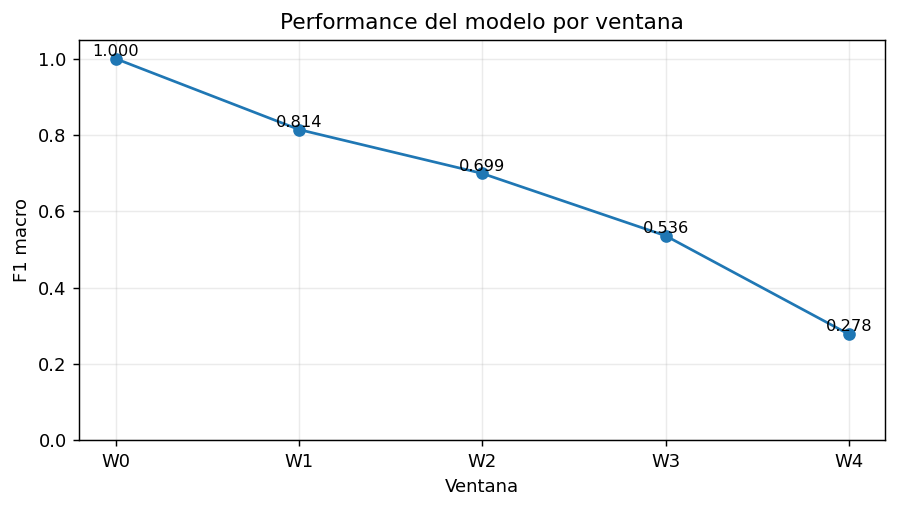
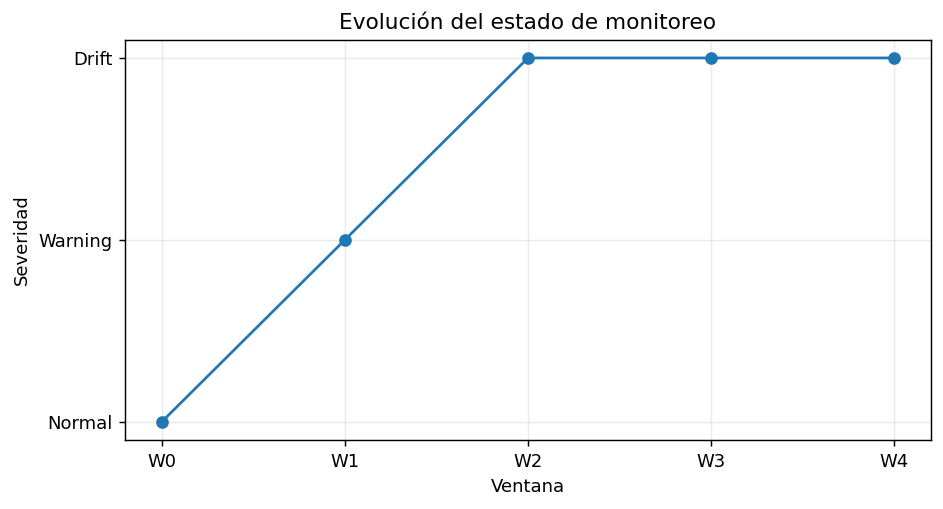

✅ Dashboard HTML renderizado directamente en Google Colab.


In [ ]:
# ============================================================
# 9.7 — VISUALIZADOR HTML DE MONITOREO EN GOOGLE COLAB
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Mostrar el dashboard DIRECTAMENTE dentro del notebook.
#
# NO utiliza:
#
#   - Streamlit
#   - Uvicorn
#   - localhost
#   - puertos
#   - proxyPort()
#   - serve_kernel_port_as_iframe()
#
# UTILIZA:
#
#   monitoring/drift_metrics.csv
#   monitoring/window_summary.csv
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path
from io import BytesIO
import base64
import html

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import (
    HTML,
    display
)


# ============================================================
# 2. ARCHIVOS DE MONITOREO
# ============================================================

MONITORING_DIR_HTML_9_7 = Path(
    "monitoring"
)


DRIFT_PATH_HTML_9_7 = (
    MONITORING_DIR_HTML_9_7
    /
    "drift_metrics.csv"
)


SUMMARY_PATH_HTML_9_7 = (
    MONITORING_DIR_HTML_9_7
    /
    "window_summary.csv"
)


# ============================================================
# 3. VERIFICAR ARCHIVOS
# ============================================================

for ruta_9_7 in [

    DRIFT_PATH_HTML_9_7,
    SUMMARY_PATH_HTML_9_7

]:

    if not ruta_9_7.exists():

        raise FileNotFoundError(
            f"No existe {ruta_9_7}. "
            "Ejecute previamente la sección 9.6."
        )


# ============================================================
# 4. CARGAR DATOS
# ============================================================

df_drift_html_9_7 = pd.read_csv(
    DRIFT_PATH_HTML_9_7
)


df_summary_html_9_7 = pd.read_csv(
    SUMMARY_PATH_HTML_9_7
)


# ============================================================
# 5. NORMALIZAR VENTANAS
# ============================================================

ORDEN_VENTANAS_HTML_9_7 = {

    "W0": 0,
    "W1": 1,
    "W2": 2,
    "W3": 3,
    "W4": 4
}


df_summary_html_9_7[
    "_orden"
] = (
    df_summary_html_9_7[
        "Ventana"
    ]
    .astype(str)
    .map(
        ORDEN_VENTANAS_HTML_9_7
    )
)


df_summary_html_9_7 = (
    df_summary_html_9_7
    .sort_values(
        "_orden"
    )
    .drop(
        columns="_orden"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 6. IDENTIFICAR ÚLTIMA VENTANA DE PRODUCCIÓN
# ============================================================

df_prod_html_9_7 = (
    df_summary_html_9_7[
        df_summary_html_9_7[
            "Ventana"
        ]
        .astype(str)
        .isin(
            [
                "W1",
                "W2",
                "W3",
                "W4"
            ]
        )
    ]
)


if df_prod_html_9_7.empty:

    fila_actual_html_9_7 = (
        df_summary_html_9_7
        .iloc[-1]
    )

else:

    fila_actual_html_9_7 = (
        df_prod_html_9_7
        .iloc[-1]
    )


VENTANA_ACTUAL_HTML_9_7 = str(
    fila_actual_html_9_7[
        "Ventana"
    ]
)


ESTADO_ACTUAL_HTML_9_7 = str(
    fila_actual_html_9_7[
        "Estado_general"
    ]
)


PERFORMANCE_ACTUAL_HTML_9_7 = float(
    fila_actual_html_9_7[
        "Performance"
    ]
)


# ============================================================
# 7. FUNCIÓN PARA CONVERTIR FIGURA A BASE64
# ============================================================

def figura_a_base64_9_7(
    fig
):
    """
    Convierte una figura Matplotlib en una imagen PNG
    embebida directamente dentro del HTML.
    """

    buffer_9_7 = BytesIO()


    fig.savefig(
        buffer_9_7,
        format="png",
        bbox_inches="tight",
        dpi=130
    )


    plt.close(
        fig
    )


    buffer_9_7.seek(
        0
    )


    imagen_base64_9_7 = (
        base64.b64encode(
            buffer_9_7.read()
        )
        .decode(
            "utf-8"
        )
    )


    return imagen_base64_9_7


# ============================================================
# 8. GRÁFICO — PERFORMANCE
# ============================================================

fig_perf_9_7, ax_perf_9_7 = plt.subplots(
    figsize=(
        8,
        4
    )
)


df_perf_html_9_7 = (
    df_summary_html_9_7[
        [
            "Ventana",
            "Performance"
        ]
    ]
    .dropna()
)


ax_perf_9_7.plot(

    df_perf_html_9_7[
        "Ventana"
    ],

    df_perf_html_9_7[
        "Performance"
    ],

    marker="o"
)


for _, fila_9_7 in (
    df_perf_html_9_7
    .iterrows()
):

    ax_perf_9_7.text(

        fila_9_7[
            "Ventana"
        ],

        fila_9_7[
            "Performance"
        ],

        f"{fila_9_7['Performance']:.3f}",

        ha="center",

        va="bottom",

        fontsize=9
    )


ax_perf_9_7.set_title(
    "Performance del modelo por ventana"
)


ax_perf_9_7.set_xlabel(
    "Ventana"
)


ax_perf_9_7.set_ylabel(
    "F1 macro"
)


ax_perf_9_7.set_ylim(
    0.0,
    1.05
)


ax_perf_9_7.grid(
    alpha=0.25
)


PERFORMANCE_IMG_9_7 = figura_a_base64_9_7(
    fig_perf_9_7
)


# ============================================================
# 9. GRÁFICO — SEVERIDAD
# ============================================================

SEVERIDAD_MAP_HTML_9_7 = {

    "Referencia": 0,

    "Normal": 0,

    "No": 0,

    "Warning": 1,

    "Drift": 2,

    "Sí": 2,

    "Drift significativo": 2
}


df_severidad_html_9_7 = (
    df_summary_html_9_7[
        [
            "Ventana",
            "Estado_general"
        ]
    ]
    .copy()
)


df_severidad_html_9_7[
    "Severidad"
] = (
    df_severidad_html_9_7[
        "Estado_general"
    ]
    .map(
        SEVERIDAD_MAP_HTML_9_7
    )
    .fillna(
        0
    )
)


fig_sev_9_7, ax_sev_9_7 = plt.subplots(
    figsize=(
        8,
        4
    )
)


ax_sev_9_7.plot(

    df_severidad_html_9_7[
        "Ventana"
    ],

    df_severidad_html_9_7[
        "Severidad"
    ],

    marker="o"
)


ax_sev_9_7.set_title(
    "Evolución del estado de monitoreo"
)


ax_sev_9_7.set_xlabel(
    "Ventana"
)


ax_sev_9_7.set_ylabel(
    "Severidad"
)


ax_sev_9_7.set_yticks(
    [
        0,
        1,
        2
    ]
)


ax_sev_9_7.set_yticklabels(
    [
        "Normal",
        "Warning",
        "Drift"
    ]
)


ax_sev_9_7.grid(
    alpha=0.25
)


SEVERIDAD_IMG_9_7 = figura_a_base64_9_7(
    fig_sev_9_7
)


# ============================================================
# 10. ALERTAS
# ============================================================

df_alertas_html_9_7 = (
    df_drift_html_9_7[
        df_drift_html_9_7[
            "Drift"
        ]
        .astype(str)
        .isin(
            [
                "Warning",
                "Sí"
            ]
        )
    ]
    .copy()
)


N_ALERTAS_HTML_9_7 = len(
    df_alertas_html_9_7
)


N_DRIFT_HTML_9_7 = int(
    (
        df_alertas_html_9_7[
            "Drift"
        ]
        .astype(str)
        ==
        "Sí"
    )
    .sum()
)


# ============================================================
# 11. ACCIÓN RECOMENDADA
# ============================================================

def accion_recomendada_html_9_7(
    estado
):
    """
    Traduce el estado del sistema a una recomendación.
    """

    estado = str(
        estado
    )


    if estado in {

        "Normal",
        "Referencia",
        "No"

    }:

        return (
            "Continuar monitoreando. "
            "No se requiere intervención inmediata."
        )


    if estado == "Warning":

        return (
            "Realizar revisión manual de las variables "
            "que generaron advertencia y aumentar "
            "la frecuencia de monitoreo."
        )


    return (
        "Evaluar intervención. Revisar performance, "
        "persistencia del drift y considerar "
        "reentrenamiento o rollback."
    )


ACCION_HTML_9_7 = accion_recomendada_html_9_7(
    ESTADO_ACTUAL_HTML_9_7
)


# ============================================================
# 12. CLASE CSS DEL ESTADO
# ============================================================

if ESTADO_ACTUAL_HTML_9_7 in {

    "Normal",
    "Referencia",
    "No"

}:

    CLASE_ESTADO_HTML_9_7 = (
        "estado-normal"
    )


elif ESTADO_ACTUAL_HTML_9_7 == "Warning":

    CLASE_ESTADO_HTML_9_7 = (
        "estado-warning"
    )


else:

    CLASE_ESTADO_HTML_9_7 = (
        "estado-drift"
    )


# ============================================================
# 13. TABLA RESUMEN DE VENTANAS
# ============================================================

columnas_resumen_html_9_7 = [

    columna
    for columna
    in [

        "Ventana",
        "Estado_general",
        "Performance",
        "Elementos_alerta"

    ]
    if columna
    in df_summary_html_9_7.columns
]


tabla_resumen_html_9_7 = (
    df_summary_html_9_7[
        columnas_resumen_html_9_7
    ]
    .round(
        {
            "Performance":
                4
        }
    )
    .to_html(
        index=False,
        classes="tabla-dashboard",
        border=0
    )
)


# ============================================================
# 14. TABLA DE ALERTAS
# ============================================================

columnas_alertas_html_9_7 = [

    columna
    for columna
    in [

        "Ventana",
        "Feature",
        "PSI",
        "KS/Chi2",
        "Drift",
        "Performance"

    ]
    if columna
    in df_alertas_html_9_7.columns
]


if df_alertas_html_9_7.empty:

    tabla_alertas_html_9_7 = """
    <p class="mensaje-ok">
        No existen variables con alerta.
    </p>
    """


else:

    tabla_alertas_html_9_7 = (
        df_alertas_html_9_7[
            columnas_alertas_html_9_7
        ]
        .round(
            4
        )
        .to_html(
            index=False,
            classes="tabla-dashboard",
            border=0
        )
    )


# ============================================================
# 15. TARGET DRIFT
# ============================================================

df_target_html_9_7 = (
    df_drift_html_9_7[
        df_drift_html_9_7[
            "Feature"
        ]
        .astype(str)
        .str.upper()
        ==
        "TARGET"
    ]
    .copy()
)


if df_target_html_9_7.empty:

    tabla_target_html_9_7 = """
    <p>
        No existen registros de Target Drift.
    </p>
    """


else:

    columnas_target_html_9_7 = [

        columna
        for columna
        in [

            "Ventana",
            "KS/Chi2",
            "Cramers_V",
            "TVD",
            "Drift",
            "Performance"

        ]
        if columna
        in df_target_html_9_7.columns
    ]


    tabla_target_html_9_7 = (
        df_target_html_9_7[
            columnas_target_html_9_7
        ]
        .round(
            4
        )
        .to_html(
            index=False,
            classes="tabla-dashboard",
            border=0
        )
    )


# ============================================================
# 16. DETALLE POR FEATURE
# ============================================================
#
# En lugar de usar JavaScript, se generan secciones
# <details> desplegables.
#
# Esto es más robusto dentro de Google Colab.
#
# ============================================================

features_html_9_7 = sorted(
    [

        feature
        for feature
        in df_drift_html_9_7[
            "Feature"
        ]
        .dropna()
        .astype(str)
        .unique()

        if feature.upper()
        !=
        "TARGET"

    ]
)


bloques_features_html_9_7 = []


for feature_9_7 in (
    features_html_9_7
):

    df_feature_9_7 = (
        df_drift_html_9_7[
            df_drift_html_9_7[
                "Feature"
            ]
            .astype(str)
            ==
            feature_9_7
        ]
        .copy()
    )


    df_feature_9_7[
        "_orden"
    ] = (
        df_feature_9_7[
            "Ventana"
        ]
        .astype(str)
        .map(
            ORDEN_VENTANAS_HTML_9_7
        )
    )


    df_feature_9_7 = (
        df_feature_9_7
        .sort_values(
            "_orden"
        )
        .drop(
            columns="_orden"
        )
    )


    columnas_feature_9_7 = [

        columna
        for columna
        in [

            "Ventana",
            "PSI",
            "KS/Chi2",
            "Drift",
            "Performance"

        ]
        if columna
        in df_feature_9_7.columns
    ]


    tabla_feature_9_7 = (
        df_feature_9_7[
            columnas_feature_9_7
        ]
        .round(
            4
        )
        .to_html(
            index=False,
            classes="tabla-dashboard",
            border=0
        )
    )


    bloque_9_7 = f"""
    <details class="feature-detail">
        <summary>
            {html.escape(feature_9_7)}
        </summary>

        <div class="feature-content">
            {tabla_feature_9_7}
        </div>
    </details>
    """


    bloques_features_html_9_7.append(
        bloque_9_7
    )


FEATURES_HTML_9_7 = "\n".join(
    bloques_features_html_9_7
)


# ============================================================
# 17. CONSTRUIR DASHBOARD HTML
# ============================================================

DASHBOARD_HTML_9_7 = f"""
<div class="dashboard-root">

<style>

.dashboard-root {{
    font-family: Arial, Helvetica, sans-serif;
    background: #f5f7fa;
    padding: 24px;
    border-radius: 12px;
    color: #1f2937;
}}

.dashboard-title {{
    font-size: 30px;
    font-weight: 700;
    margin-bottom: 4px;
}}

.dashboard-subtitle {{
    color: #6b7280;
    margin-bottom: 24px;
}}

.grid-kpi {{
    display: grid;
    grid-template-columns: repeat(4, 1fr);
    gap: 14px;
    margin-bottom: 25px;
}}

.kpi {{
    background: white;
    border: 1px solid #e5e7eb;
    border-radius: 10px;
    padding: 18px;
}}

.kpi-label {{
    color: #6b7280;
    font-size: 13px;
}}

.kpi-value {{
    font-size: 25px;
    font-weight: 700;
    margin-top: 6px;
}}

.estado-normal {{
    background: #ecfdf5;
    border-left: 6px solid #059669;
}}

.estado-warning {{
    background: #fffbeb;
    border-left: 6px solid #d97706;
}}

.estado-drift {{
    background: #fef2f2;
    border-left: 6px solid #dc2626;
}}

.section {{
    background: white;
    border: 1px solid #e5e7eb;
    border-radius: 10px;
    padding: 20px;
    margin-top: 18px;
}}

.section h2 {{
    margin-top: 0;
    font-size: 20px;
}}

.chart-img {{
    width: 100%;
    max-width: 850px;
    display: block;
    margin: auto;
}}

.tabla-dashboard {{
    width: 100%;
    border-collapse: collapse;
    font-size: 13px;
}}

.tabla-dashboard th {{
    background: #1f3b60;
    color: white;
    padding: 8px;
    text-align: left;
}}

.tabla-dashboard td {{
    padding: 7px;
    border-bottom: 1px solid #e5e7eb;
}}

.tabla-dashboard tr:nth-child(even) {{
    background: #f8fafc;
}}

.feature-detail {{
    margin: 7px 0;
    background: #f8fafc;
    border: 1px solid #e5e7eb;
    border-radius: 7px;
}}

.feature-detail summary {{
    padding: 10px 14px;
    cursor: pointer;
    font-weight: 600;
}}

.feature-content {{
    padding: 12px;
}}

.action-box {{
    padding: 16px;
    border-radius: 8px;
    background: #eef2ff;
    border-left: 5px solid #4f46e5;
}}

.info-box {{
    background: #eff6ff;
    padding: 13px;
    border-radius: 8px;
    margin: 14px 0;
}}

.mensaje-ok {{
    color: #047857;
    font-weight: 600;
}}

</style>


<div class="dashboard-title">
    📊 MLOps Local — Monitoreo de Data Drift
</div>

<div class="dashboard-subtitle">
    PlantVillage · Clasificación multiclase ·
    Ventanas de producción simuladas
</div>


<div class="info-box">
    <strong>Nota metodológica:</strong>
    W0–W4 representan ventanas experimentales de producción.
    No corresponden a fechas reales de captura.
</div>


<div class="grid-kpi">

    <div class="kpi {CLASE_ESTADO_HTML_9_7}">
        <div class="kpi-label">
            Estado actual
        </div>

        <div class="kpi-value">
            {html.escape(ESTADO_ACTUAL_HTML_9_7)}
        </div>
    </div>


    <div class="kpi">
        <div class="kpi-label">
            Ventana actual
        </div>

        <div class="kpi-value">
            {html.escape(VENTANA_ACTUAL_HTML_9_7)}
        </div>
    </div>


    <div class="kpi">
        <div class="kpi-label">
            F1 macro
        </div>

        <div class="kpi-value">
            {PERFORMANCE_ACTUAL_HTML_9_7:.4f}
        </div>
    </div>


    <div class="kpi">
        <div class="kpi-label">
            Alertas detectadas
        </div>

        <div class="kpi-value">
            {N_ALERTAS_HTML_9_7}
        </div>
    </div>

</div>


<div class="section">

    <h2>
        1. Resumen general por ventana
    </h2>

    {tabla_resumen_html_9_7}

</div>


<div class="section">

    <h2>
        2. Performance del modelo
    </h2>

    <img
        class="chart-img"
        src="data:image/png;base64,{PERFORMANCE_IMG_9_7}"
    >

</div>


<div class="section">

    <h2>
        3. Evolución del estado de monitoreo
    </h2>

    <img
        class="chart-img"
        src="data:image/png;base64,{SEVERIDAD_IMG_9_7}"
    >

    <p>
        0 = Normal/Referencia ·
        1 = Warning ·
        2 = Drift significativo.
    </p>

</div>


<div class="section">

    <h2>
        4. Variables que generaron alerta
    </h2>

    {tabla_alertas_html_9_7}

</div>


<div class="section">

    <h2>
        5. Métricas de drift por feature
    </h2>

    <p>
        Seleccione cada variable para desplegar sus métricas
        PSI, KS/Chi², estado y performance.
    </p>

    {FEATURES_HTML_9_7}

</div>


<div class="section">

    <h2>
        6. Drift del target
    </h2>

    {tabla_target_html_9_7}

</div>


<div class="section">

    <h2>
        7. Acción recomendada
    </h2>

    <div class="action-box">
        {html.escape(ACCION_HTML_9_7)}
    </div>

    <p>
        Una alerta de drift no genera automáticamente
        reentrenamiento. La decisión debe considerar también
        la evolución de la performance y la persistencia
        del cambio.
    </p>

</div>


<div class="section">

    <h2>
        Trazabilidad
    </h2>

    <p>
        Fuente:
        <code>monitoring/drift_metrics.csv</code>
        +
        <code>monitoring/window_summary.csv</code>
    </p>

</div>


</div>
"""


# ============================================================
# 18. MOSTRAR DIRECTAMENTE EN GOOGLE COLAB
# ============================================================

display(
    HTML(
        DASHBOARD_HTML_9_7
    )
)


print(
    "✅ Dashboard HTML renderizado directamente en Google Colab."
)

In [ ]:
# ============================================================
# 9.7 — GUARDAR DASHBOARD HTML
# ============================================================


from pathlib import Path


DASHBOARD_HTML_DIR_9_7 = Path(
    "dashboard"
)


DASHBOARD_HTML_DIR_9_7.mkdir(
    parents=True,
    exist_ok=True
)


DASHBOARD_HTML_PATH_9_7 = (
    DASHBOARD_HTML_DIR_9_7
    /
    "dashboard_colab.html"
)


DASHBOARD_HTML_PATH_9_7.write_text(
    DASHBOARD_HTML_9_7,
    encoding="utf-8"
)


print("=" * 90)
print("DASHBOARD HTML")
print("=" * 90)


print(
    f"Archivo : "
    f"{DASHBOARD_HTML_PATH_9_7}"
)


print(
    "Modo    : HTML autocontenido"
)


print(
    "Servidor: NO requerido"
)


print(
    "\n✅ dashboard/dashboard_colab.html creado."
)

DASHBOARD HTML
Archivo : dashboard/dashboard_colab.html
Modo    : HTML autocontenido
Servidor: NO requerido

✅ dashboard/dashboard_colab.html creado.


In [ ]:
# ============================================================
# 9.7 — SMOKE TEST DE STREAMLIT
# ============================================================


import requests


response_dashboard_9_7 = requests.get(
    (
        f"{BASE_URL_STREAMLIT_9_7}"
        "/_stcore/health"
    ),
    timeout=10
)


print("=" * 105)
print("SMOKE TEST — STREAMLIT")
print("=" * 105)


print(
    f"HTTP status : "
    f"{response_dashboard_9_7.status_code}"
)


print(
    f"Respuesta   : "
    f"{response_dashboard_9_7.text}"
)


assert (
    response_dashboard_9_7.status_code
    ==
    200
)


print(
    "\n✅ Dashboard Streamlit operacional."
)

SMOKE TEST — STREAMLIT
HTTP status : 200
Respuesta   : ok

✅ Dashboard Streamlit operacional.


## 9.7.7 Interpretación técnica del dashboard

El dashboard integra los resultados del sistema de monitoreo sin volver a calcular las.

## Estado general

El dashboard identifica la última ventana de producción disponible y muestra.

## Performance

Esta sección resume performance y su función dentro del proyecto MLOps.

## Métricas por feature

Esta sección resume métricas por feature y su función dentro del proyecto MLOps.

## Evolución de severidad

Esta sección resume evolución de severidad y su función dentro del proyecto MLOps.

## Variables que generan alerta

El dashboard filtra automáticamente los registros donde.

## Acciones recomendadas

El dashboard traduce el estado estadístico a una recomendación operacional.

## Cierre de la Fase 4B

quedan disponibles los tres productos principales de la Fase 4.

## Fase 5 — Plan de acción ante Drift

Esta sección resume fase 5 — Plan de acción ante Drift y su función dentro del proyecto MLOps.


## 10.1 Lógica de decisión

La Fase 5 transforma las métricas de monitoreo en decisiones operacionales.

## 10.1.1 Estado general de una ventana

Para cada elemento monitoreado se definió previamente una severidad.

## 10.1.2 Detección de drift

Esta sección resume detección de drift y su función dentro del proyecto MLOps.

## 10.1.3 Generación de alerta

Esta sección resume generación de alerta y su función dentro del proyecto MLOps.

## 10.1.4 Gatillo de reentrenamiento

El gatillo de reentrenamiento se reserva para el nivel de mayor severidad.

## 10.1.5 Relación con performance

La performance se utilizará como información contextual adicional.

## 10.1.6 Pseudocódigo operacional

Esta sección resume pseudocódigo operacional y su función dentro del proyecto MLOps.


In [ ]:

# ============================================================
# FASE 5 — PLAN DE ACCIÓN ANTE DRIFT
# 10.1 LÓGICA DE DECISIÓN
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Consumir los resultados ya generados por 9.6 y determinar:
#
#       1. estado actual;
#       2. si debe generarse una alerta;
#       3. si debe generarse un trigger de retraining.
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta sección NO:
#
#   - recalcula PSI;
#   - recalcula KS;
#   - recalcula performance;
#   - escribe alerts.csv;
#   - crea todavía retrain_required.flag;
#   - reentrena el modelo.
#
# 10.2 persistirá las alertas.
# 10.3 materializará el trigger.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd

from IPython.display import (
    display
)


# ============================================================
# 2. RUTAS
# ============================================================

MONITORING_DIR_10_1 = Path(
    "monitoring"
)


DRIFT_METRICS_PATH_10_1 = (
    MONITORING_DIR_10_1
    /
    "drift_metrics.csv"
)


WINDOW_SUMMARY_PATH_10_1 = (
    MONITORING_DIR_10_1
    /
    "window_summary.csv"
)


PERFORMANCE_PATH_10_1 = (
    MONITORING_DIR_10_1
    /
    "performance_metrics.csv"
)


# ============================================================
# 3. VERIFICAR PRODUCTOS DE FASE 4
# ============================================================

archivos_obligatorios_10_1 = [

    DRIFT_METRICS_PATH_10_1,
    WINDOW_SUMMARY_PATH_10_1
]


faltantes_10_1 = [

    str(
        ruta
    )
    for ruta
    in archivos_obligatorios_10_1
    if not ruta.exists()
]


if faltantes_10_1:

    raise FileNotFoundError(
        "Faltan productos de la Fase 4: "
        f"{faltantes_10_1}. "
        "Ejecute previamente la sección 9.6."
    )


# ============================================================
# 4. CARGAR RESULTADOS
# ============================================================

df_drift_10_1 = pd.read_csv(
    DRIFT_METRICS_PATH_10_1
)


df_summary_10_1 = pd.read_csv(
    WINDOW_SUMMARY_PATH_10_1
)


if PERFORMANCE_PATH_10_1.exists():

    df_performance_10_1 = pd.read_csv(
        PERFORMANCE_PATH_10_1
    )

else:

    df_performance_10_1 = None


# ============================================================
# 5. CONTROL MÍNIMO DE COLUMNAS
# ============================================================

columnas_summary_10_1 = [

    "Ventana",
    "Estado_general",
    "Performance"
]


faltantes_summary_10_1 = [

    columna
    for columna
    in columnas_summary_10_1
    if columna
    not in df_summary_10_1.columns
]


if faltantes_summary_10_1:

    raise KeyError(
        "window_summary.csv no contiene: "
        f"{faltantes_summary_10_1}"
    )


print("=" * 105)
print("10.1 — FUENTES DEL PLAN DE ACCIÓN")
print("=" * 105)


print(
    f"drift_metrics.csv : "
    f"{len(df_drift_10_1)} registros"
)


print(
    f"window_summary.csv: "
    f"{len(df_summary_10_1)} registros"
)


print(
    "performance_metrics.csv: "
    f"{'disponible' if df_performance_10_1 is not None else 'opcional/no disponible'}"
)


print(
    "\n✅ Resultados de monitoreo cargados."
)

10.1 — FUENTES DEL PLAN DE ACCIÓN
drift_metrics.csv : 64 registros
window_summary.csv: 5 registros
performance_metrics.csv: disponible

✅ Resultados de monitoreo cargados.


In [ ]:
# ============================================================
# 10.1 — POLÍTICA DE DECISIÓN
# ============================================================
#
# NIVEL:
#
#       0 -> Normal
#       1 -> Warning
#       2 -> Drift significativo
#
# ============================================================


# ============================================================
# 1. MAPA DE ESTADOS
# ============================================================

MAPA_ESTADO_10_1 = {

    "Referencia":
        0,

    "Normal":
        0,

    "No":
        0,

    "Warning":
        1,

    "Drift":
        2,

    "Sí":
        2,

    "Si":
        2,

    "Drift significativo":
        2
}


# ============================================================
# 2. ACCIONES
# ============================================================

ACCIONES_10_1 = {

    0:
        (
            "Continuar monitoreando. "
            "No se requiere intervención."
        ),

    1:
        (
            "Generar alerta y realizar revisión manual "
            "con seguimiento reforzado."
        ),

    2:
        (
            "Generar alerta y crear solicitud de evaluación "
            "de reentrenamiento, rollback o intervención."
        )
}


# ============================================================
# 3. NORMALIZAR ESTADO
# ============================================================

def nivel_estado_10_1(
    estado
):
    """
    Convierte una etiqueta operacional a nivel 0-2.
    """

    estado = str(
        estado
    ).strip()


    if estado not in MAPA_ESTADO_10_1:

        raise ValueError(
            "Estado desconocido: "
            f"{estado}"
        )


    return MAPA_ESTADO_10_1[
        estado
    ]


# ============================================================
# 4. DETECTAR DRIFT
# ============================================================

def detectar_drift_10_1(
    estado
):
    """
    Devuelve True para Warning o Drift significativo.
    """

    return (
        nivel_estado_10_1(
            estado
        )
        >=
        1
    )


# ============================================================
# 5. DETECTAR DRIFT SIGNIFICATIVO
# ============================================================

def detectar_drift_significativo_10_1(
    estado
):
    """
    Devuelve True únicamente para severidad 2.
    """

    return (
        nivel_estado_10_1(
            estado
        )
        >=
        2
    )


print(
    "✅ Política Normal / Warning / Drift definida."
)

✅ Política Normal / Warning / Drift definida.


In [ ]:
# ============================================================
# 10.1 — FUNCIONES DE ACCIÓN
# ============================================================


# ============================================================
# 1. GENERAR ALERTA
# ============================================================

def generar_alerta_10_1(
    ventana,
    estado,
    performance,
    elementos_alerta
):
    """
    Construye una alerta operacional EN MEMORIA.

    La persistencia formal en monitoring/alerts.csv
    se realizará en 10.2.
    """

    nivel = nivel_estado_10_1(
        estado
    )


    if nivel == 0:

        return None


    return {

        "timestamp_utc":
            datetime.now(
                timezone.utc
            ).isoformat(),

        "ventana":
            str(
                ventana
            ),

        "estado":
            str(
                estado
            ),

        "nivel_severidad":
            int(
                nivel
            ),

        "performance_f1_macro":
            (
                float(
                    performance
                )
                if pd.notna(
                    performance
                )
                else None
            ),

        "elementos_alerta":
            list(
                elementos_alerta
            ),

        "n_elementos_alerta":
            int(
                len(
                    elementos_alerta
                )
            ),

        "accion_recomendada":
            ACCIONES_10_1[
                nivel
            ]
    }


# ============================================================
# 2. GENERAR TRIGGER DE RETRAINING
# ============================================================

def generar_trigger_retraining_10_1(
    ventana,
    estado,
    performance,
    deterioro_performance=None
):
    """
    Construye la SOLICITUD lógica de retraining.

    No crea todavía retrain_required.flag.

    Esa persistencia se implementará en 10.3.
    """

    nivel = nivel_estado_10_1(
        estado
    )


    if nivel < 2:

        return {

            "required":
                False,

            "status":
                "not_required",

            "ventana":
                str(
                    ventana
                ),

            "reason":
                (
                    "El estado no alcanza "
                    "Drift significativo."
                )
        }


    # --------------------------------------------------------
    # Prioridad contextual
    # --------------------------------------------------------

    if deterioro_performance is True:

        prioridad = "Alta"


    elif deterioro_performance is False:

        prioridad = "Media"


    else:

        prioridad = "Por revisar"


    return {

        "required":
            True,

        "status":
            "pending_review",

        "mode":
            "semi-automatic",

        "ventana":
            str(
                ventana
            ),

        "estado":
            str(
                estado
            ),

        "performance_f1_macro":
            (
                float(
                    performance
                )
                if pd.notna(
                    performance
                )
                else None
            ),

        "performance_deteriorada":
            deterioro_performance,

        "prioridad":
            prioridad,

        "reason":
            (
                "Drift significativo detectado. "
                "Evaluar reentrenamiento, rollback "
                "o intervención antes de modificar "
                "el modelo en producción."
            )
    }


print(
    "✅ generar_alerta_10_1() definida."
)


print(
    "✅ generar_trigger_retraining_10_1() definida."
)

✅ generar_alerta_10_1() definida.
✅ generar_trigger_retraining_10_1() definida.


In [ ]:
# ============================================================
# 10.1 — MOTOR DE DECISIÓN
# ============================================================
#
# IMPLEMENTACIÓN DEL PSEUDOCÓDIGO:
#
# if drift_detectado:
#     generar_alerta()
#
#     if drift_significativo:
#         generar_trigger_retraining()
#
# ============================================================


def evaluar_plan_accion_10_1(
    ventana,
    estado,
    performance,
    elementos_alerta,
    deterioro_performance=None
):
    """
    Evalúa el estado del sistema y determina las acciones
    correspondientes.

    Returns
    -------
    dict
        Resultado completo de la decisión.
    """


    nivel = nivel_estado_10_1(
        estado
    )


    drift_detectado = (
        nivel
        >=
        1
    )


    drift_significativo = (
        nivel
        >=
        2
    )


    # ========================================================
    # CASO 0 — NORMAL
    # ========================================================

    if not drift_detectado:

        return {

            "ventana":
                ventana,

            "estado":
                estado,

            "nivel":
                nivel,

            "drift_detectado":
                False,

            "alerta_generada":
                False,

            "trigger_retraining":
                False,

            "alerta":
                None,

            "trigger":
                None,

            "accion":
                ACCIONES_10_1[
                    0
                ]
        }


    # ========================================================
    # CASO 1/2 — DRIFT DETECTADO
    # ========================================================

    alerta = generar_alerta_10_1(

        ventana=ventana,

        estado=estado,

        performance=performance,

        elementos_alerta=elementos_alerta
    )


    # ========================================================
    # TRIGGER SOLO PARA DRIFT SIGNIFICATIVO
    # ========================================================

    if drift_significativo:

        trigger = generar_trigger_retraining_10_1(

            ventana=ventana,

            estado=estado,

            performance=performance,

            deterioro_performance=(
                deterioro_performance
            )
        )


        trigger_generado = True


    else:

        trigger = generar_trigger_retraining_10_1(

            ventana=ventana,

            estado=estado,

            performance=performance,

            deterioro_performance=(
                deterioro_performance
            )
        )


        trigger_generado = False


    return {

        "ventana":
            ventana,

        "estado":
            estado,

        "nivel":
            nivel,

        "drift_detectado":
            drift_detectado,

        "alerta_generada":
            True,

        "trigger_retraining":
            trigger_generado,

        "alerta":
            alerta,

        "trigger":
            trigger,

        "accion":
            ACCIONES_10_1[
                nivel
            ]
    }


print(
    "✅ Motor de decisión implementado."
)

✅ Motor de decisión implementado.


In [ ]:
# ============================================================
# 10.1 — EVALUAR ESTADO ACTUAL DEL SISTEMA
# ============================================================


# ============================================================
# 1. ORDEN DE VENTANAS
# ============================================================

ORDEN_VENTANAS_10_1 = {

    "W1": 1,
    "W2": 2,
    "W3": 3,
    "W4": 4
}


# ============================================================
# 2. QUEDARSE SOLO CON PRODUCCIÓN
# ============================================================

df_produccion_10_1 = (
    df_summary_10_1[
        df_summary_10_1[
            "Ventana"
        ]
        .astype(str)
        .isin(
            ORDEN_VENTANAS_10_1
        )
    ]
    .copy()
)


if df_produccion_10_1.empty:

    raise ValueError(
        "No existen ventanas W1-W4 "
        "en window_summary.csv."
    )


# ============================================================
# 3. IDENTIFICAR ÚLTIMA VENTANA
# ============================================================

df_produccion_10_1[
    "_orden"
] = (
    df_produccion_10_1[
        "Ventana"
    ]
    .astype(str)
    .map(
        ORDEN_VENTANAS_10_1
    )
)


fila_actual_10_1 = (

    df_produccion_10_1

    .sort_values(
        "_orden"
    )

    .iloc[-1]
)


VENTANA_ACTUAL_10_1 = str(
    fila_actual_10_1[
        "Ventana"
    ]
)


ESTADO_ACTUAL_10_1 = str(
    fila_actual_10_1[
        "Estado_general"
    ]
)


PERFORMANCE_ACTUAL_10_1 = float(
    fila_actual_10_1[
        "Performance"
    ]
)


# ============================================================
# 4. ELEMENTOS QUE GENERARON ALERTA
# ============================================================

df_alertas_actuales_10_1 = (

    df_drift_10_1[
        (
            df_drift_10_1[
                "Ventana"
            ]
            .astype(str)
            ==
            VENTANA_ACTUAL_10_1
        )

        &

        (
            df_drift_10_1[
                "Drift"
            ]
            .astype(str)
            .isin(
                [
                    "Warning",
                    "Sí",
                    "Si"
                ]
            )
        )
    ]

    .copy()
)


ELEMENTOS_ALERTA_10_1 = (

    df_alertas_actuales_10_1[
        "Feature"
    ]
    .astype(str)
    .tolist()
)


# ============================================================
# 5. DETERIORO DE PERFORMANCE — OPCIONAL
# ============================================================

deterioro_performance_10_1 = None


if (
    df_performance_10_1 is not None

    and

    "Estado_performance"
    in df_performance_10_1.columns
):

    fila_perf_actual_10_1 = (
        df_performance_10_1[
            df_performance_10_1[
                "Ventana"
            ]
            .astype(str)
            ==
            VENTANA_ACTUAL_10_1
        ]
    )


    if not fila_perf_actual_10_1.empty:

        estado_perf_10_1 = str(

            fila_perf_actual_10_1[
                "Estado_performance"
            ]
            .iloc[0]
        )


        deterioro_performance_10_1 = (
            estado_perf_10_1
            ==
            "Deterioro"
        )


# ============================================================
# 6. EVALUAR PLAN
# ============================================================

decision_actual_10_1 = evaluar_plan_accion_10_1(

    ventana=(
        VENTANA_ACTUAL_10_1
    ),

    estado=(
        ESTADO_ACTUAL_10_1
    ),

    performance=(
        PERFORMANCE_ACTUAL_10_1
    ),

    elementos_alerta=(
        ELEMENTOS_ALERTA_10_1
    ),

    deterioro_performance=(
        deterioro_performance_10_1
    )
)


# ============================================================
# 7. RESUMEN
# ============================================================

df_decision_10_1 = pd.DataFrame(
    [
        {
            "Ventana":
                decision_actual_10_1[
                    "ventana"
                ],

            "Estado":
                decision_actual_10_1[
                    "estado"
                ],

            "Nivel":
                decision_actual_10_1[
                    "nivel"
                ],

            "Drift_detectado":
                decision_actual_10_1[
                    "drift_detectado"
                ],

            "Alerta":
                decision_actual_10_1[
                    "alerta_generada"
                ],

            "Trigger_retraining":
                decision_actual_10_1[
                    "trigger_retraining"
                ],

            "F1_macro":
                PERFORMANCE_ACTUAL_10_1,

            "N_elementos_alerta":
                len(
                    ELEMENTOS_ALERTA_10_1
                ),

            "Accion":
                decision_actual_10_1[
                    "accion"
                ]
        }
    ]
)


print("=" * 110)
print("10.1 — DECISIÓN OPERACIONAL ACTUAL")
print("=" * 110)


display(
    df_decision_10_1
)


print(
    "\nElementos que generaron señal:"
)


print(
    (
        ELEMENTOS_ALERTA_10_1
        if ELEMENTOS_ALERTA_10_1
        else "Ninguno"
    )
)

10.1 — DECISIÓN OPERACIONAL ACTUAL


,Ventana,Estado,Nivel,Drift_detectado,Alerta,Trigger_retraining,F1_macro,N_elementos_alerta,Accion
0,W4,Drift significativo,2,True,True,True,0.2779,16,"Generar alerta y crear solicitud de evaluación de reentrenamiento, rollback o intervención."



Elementos que generaron señal:
['TARGET', 'b_mean', 'b_std', 'brightness_mean', 'contrast_std', 'edge_density', 'entropy', 'excess_green', 'g_mean', 'g_std', 'h_mean', 'laplacian_variance', 'r_mean', 'r_std', 's_mean', 'v_mean']


In [ ]:
# ============================================================
# 10.1 — DETALLE DE LA DECISIÓN
# ============================================================

import json


print("=" * 110)
print("ALERTA GENERADA EN MEMORIA")
print("=" * 110)


if (
    decision_actual_10_1[
        "alerta"
    ]
    is not None
):

    print(
        json.dumps(
            decision_actual_10_1[
                "alerta"
            ],
            indent=4,
            ensure_ascii=False
        )
    )


else:

    print(
        "No corresponde generar alerta."
    )


print(
    "\n"
    +
    "=" * 110
)


print(
    "TRIGGER DE RETRAINING — DECISIÓN LÓGICA"
)


print(
    "=" * 110
)


if (
    decision_actual_10_1[
        "trigger"
    ]
    is not None
):

    print(
        json.dumps(
            decision_actual_10_1[
                "trigger"
            ],
            indent=4,
            ensure_ascii=False
        )
    )


else:

    print(
        "No corresponde generar trigger."
    )

ALERTA GENERADA EN MEMORIA
{
    "timestamp_utc": "2026-08-28T06:09:49.177740+00:00",
    "ventana": "W4",
    "estado": "Drift significativo",
    "nivel_severidad": 2,
    "performance_f1_macro": 0.2778529106665682,
    "elementos_alerta": [
        "TARGET",
        "b_mean",
        "b_std",
        "brightness_mean",
        "contrast_std",
        "edge_density",
        "entropy",
        "excess_green",
        "g_mean",
        "g_std",
        "h_mean",
        "laplacian_variance",
        "r_mean",
        "r_std",
        "s_mean",
        "v_mean"
    ],
    "n_elementos_alerta": 16,
    "accion_recomendada": "Generar alerta y crear solicitud de evaluación de reentrenamiento, rollback o intervención."
}

TRIGGER DE RETRAINING — DECISIÓN LÓGICA
{
    "required": true,
    "status": "pending_review",
    "mode": "semi-automatic",
    "ventana": "W4",
    "estado": "Drift significativo",
    "performance_f1_macro": 0.2778529106665682,
    "performance_deteriorada": true,
   

In [ ]:
# ============================================================
# 10.1 — PRUEBA DE LA LÓGICA DE DECISIÓN
# ============================================================
#
# Se prueban los tres estados teóricos:
#
#       Normal
#       Warning
#       Drift significativo
#
# ============================================================


casos_prueba_10_1 = [

    {
        "estado":
            "Normal",

        "alerta_esperada":
            False,

        "trigger_esperado":
            False
    },

    {
        "estado":
            "Warning",

        "alerta_esperada":
            True,

        "trigger_esperado":
            False
    },

    {
        "estado":
            "Drift significativo",

        "alerta_esperada":
            True,

        "trigger_esperado":
            True
    }
]


resultados_test_10_1 = []


for caso_10_1 in (
    casos_prueba_10_1
):

    decision_test_10_1 = evaluar_plan_accion_10_1(

        ventana="W_TEST",

        estado=(
            caso_10_1[
                "estado"
            ]
        ),

        performance=0.80,

        elementos_alerta=[
            "feature_test"
        ],

        deterioro_performance=True
    )


    pass_alerta_10_1 = (

        decision_test_10_1[
            "alerta_generada"
        ]

        ==

        caso_10_1[
            "alerta_esperada"
        ]
    )


    pass_trigger_10_1 = (

        decision_test_10_1[
            "trigger_retraining"
        ]

        ==

        caso_10_1[
            "trigger_esperado"
        ]
    )


    resultados_test_10_1.append(
        {
            "Estado":
                caso_10_1[
                    "estado"
                ],

            "Alerta_esperada":
                caso_10_1[
                    "alerta_esperada"
                ],

            "Alerta_observada":
                decision_test_10_1[
                    "alerta_generada"
                ],

            "Trigger_esperado":
                caso_10_1[
                    "trigger_esperado"
                ],

            "Trigger_observado":
                decision_test_10_1[
                    "trigger_retraining"
                ],

            "Resultado":
                (
                    "PASS"
                    if (
                        pass_alerta_10_1
                        and
                        pass_trigger_10_1
                    )
                    else "FAIL"
                )
        }
    )


df_test_decision_10_1 = pd.DataFrame(
    resultados_test_10_1
)


display(
    df_test_decision_10_1
)


assert (
    df_test_decision_10_1[
        "Resultado"
    ]
    ==
    "PASS"
).all()


print(
    "\n✅ Lógica de decisión validada para "
    "Normal, Warning y Drift significativo."
)

,Estado,Alerta_esperada,Alerta_observada,Trigger_esperado,Trigger_observado,Resultado
0,Normal,False,False,False,False,PASS
1,Warning,True,True,False,False,PASS
2,Drift significativo,True,True,True,True,PASS



✅ Lógica de decisión validada para Normal, Warning y Drift significativo.


## 10.1.7 Interpretación técnica

La lógica implementada transforma el estado del monitor en una respuesta operacional.

## Diferencia entre alerta y retraining

Una alerta informa que alguna condición del sistema requiere atención.


## 10.2 Registro de alertas

La etapa anterior definió la lógica operacional del sistema.

## 10.2.1 Estructura mínima de una alerta

Esta sección resume estructura mínima de una alerta y su función dentro del proyecto MLOps.

## 10.2.2 Alertas de PSI

Esta sección resume alertas de PSI y su función dentro del proyecto MLOps.

## 10.2.3 Alertas de Kolmogorov-Smirnov

Esta sección resume alertas de Kolmogorov-Smirnov y su función dentro del proyecto MLOps.

## 10.2.4 Alertas del target

El target no utiliza PSI ni KS como indicador principal de severidad.

## 10.2.5 Política de actuación

Esta sección resume política de actuación y su función dentro del proyecto MLOps.

## 10.2.6 Trazabilidad e idempotencia

En Google Colab es habitual ejecutar una misma celda varias veces.


In [ ]:
# ============================================================
# FASE 5 — PLAN DE ACCIÓN ANTE DRIFT
# 10.2 REGISTRO DE ALERTAS
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Transformar las señales ya calculadas en la Fase 4B en
# eventos persistentes:
#
#       monitoring/alerts.csv
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta sección NO recalcula:
#
#       PSI
#       KS
#       Chi²
#       Cramér's V
#       F1 macro
#
# Solo interpreta y registra resultados ya existentes.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path
from datetime import datetime, timezone

import hashlib
import numpy as np
import pandas as pd

from IPython.display import (
    display
)


# ============================================================
# 2. RUTAS
# ============================================================

MONITORING_DIR_10_2 = Path(
    "monitoring"
)


MONITORING_DIR_10_2.mkdir(
    parents=True,
    exist_ok=True
)


DRIFT_METRICS_PATH_10_2 = (
    MONITORING_DIR_10_2
    /
    "drift_metrics.csv"
)


ALERTS_PATH_10_2 = (
    MONITORING_DIR_10_2
    /
    "alerts.csv"
)


# ============================================================
# 3. VERIFICAR RESULTADOS DE 9.6
# ============================================================

if not DRIFT_METRICS_PATH_10_2.exists():

    raise FileNotFoundError(
        "No existe monitoring/drift_metrics.csv. "
        "Ejecute previamente la sección 9.6."
    )


# ============================================================
# 4. CARGAR MÉTRICAS CONSOLIDADAS
# ============================================================

df_monitoring_10_2 = pd.read_csv(
    DRIFT_METRICS_PATH_10_2
)


# ============================================================
# 5. COLUMNAS MÍNIMAS
# ============================================================

columnas_minimas_10_2 = [

    "Ventana",
    "Feature",
    "PSI",
    "KS/Chi2",
    "Drift",
    "Performance"
]


faltantes_10_2 = [

    columna
    for columna
    in columnas_minimas_10_2
    if columna
    not in df_monitoring_10_2.columns
]


if faltantes_10_2:

    raise KeyError(
        "drift_metrics.csv no contiene las columnas: "
        f"{faltantes_10_2}"
    )


print("=" * 105)
print("10.2 — FUENTE DEL REGISTRO DE ALERTAS")
print("=" * 105)


print(
    f"Archivo     : "
    f"{DRIFT_METRICS_PATH_10_2}"
)


print(
    f"Registros   : "
    f"{len(df_monitoring_10_2)}"
)


print(
    f"Ventanas    : "
    f"{sorted(df_monitoring_10_2['Ventana'].astype(str).unique())}"
)


print(
    "\n✅ Métricas consolidadas disponibles."
)

10.2 — FUENTE DEL REGISTRO DE ALERTAS
Archivo     : monitoring/drift_metrics.csv
Registros   : 64
Ventanas    : ['W1', 'W2', 'W3', 'W4']

✅ Métricas consolidadas disponibles.


In [ ]:
# ============================================================
# 10.2 — UMBRALES OPERACIONALES
# ============================================================


# ============================================================
# 1. PSI
# ============================================================

PSI_WARNING_10_2 = 0.10

PSI_DRIFT_10_2 = 0.20


# ============================================================
# 2. KS
# ============================================================

KS_WARNING_10_2 = 0.10

KS_DRIFT_10_2 = 0.20

P_VALUE_FDR_10_2 = 0.05


# ============================================================
# 3. TARGET — CRAMÉR'S V
# ============================================================

CRAMER_WARNING_10_2 = 0.10

CRAMER_DRIFT_10_2 = 0.30


# ============================================================
# 4. POLÍTICA
# ============================================================

ACCION_WARNING_10_2 = (
    "Revisión manual y seguimiento reforzado."
)


ACCION_DRIFT_10_2 = (
    "Evaluar reentrenamiento, rollback o "
    "intervención semi-automática."
)


# ============================================================
# 5. FUNCIÓN DE ACCIÓN
# ============================================================

def obtener_accion_10_2(
    severidad
):
    """
    Traduce severidad a acción recomendada.
    """

    if severidad == "Warning":

        return ACCION_WARNING_10_2


    if severidad == "Drift significativo":

        return ACCION_DRIFT_10_2


    return (
        "Continuar monitoreando."
    )


print(
    "✅ Umbrales y política operacional definidos."
)

✅ Umbrales y política operacional definidos.


In [ ]:
# ============================================================
# 10.2 — CONSTRUCTOR DE ALERTAS
# ============================================================


def crear_alerta_10_2(
    ventana,
    feature,
    metrica,
    valor,
    umbral,
    severidad,
    accion_recomendada,
    performance=None,
    criterio=None
):
    """
    Construye una alerta auditable.

    Parameters
    ----------
    ventana : str
        W1-W4.

    feature : str
        Feature o TARGET.

    metrica : str
        PSI, KS o Cramers_V.

    valor : float
        Valor observado.

    umbral : float
        Umbral que activó la señal.

    severidad : str
        Warning o Drift significativo.

    accion_recomendada : str
        Política operacional.

    performance : float, optional
        F1 macro de la ventana.

    criterio : str, optional
        Información complementaria.

    Returns
    -------
    dict
        Registro de alerta.
    """


    # ========================================================
    # 1. TIMESTAMP UTC
    # ========================================================

    timestamp_10_2 = (
        datetime.now(
            timezone.utc
        )
        .isoformat()
    )


    # ========================================================
    # 2. CLAVE IDEMPOTENTE
    # ========================================================
    #
    # No se incluye timestamp en la clave.
    #
    # Así, ejecutar la celda nuevamente no duplica la misma
    # alerta para la misma ventana/feature/métrica/severidad.
    #
    # ========================================================

    texto_clave_10_2 = (
        f"{ventana}|"
        f"{feature}|"
        f"{metrica}|"
        f"{severidad}"
    )


    alert_key_10_2 = hashlib.sha256(
        texto_clave_10_2.encode(
            "utf-8"
        )
    ).hexdigest()[:16]


    # ========================================================
    # 3. REGISTRO
    # ========================================================

    return {

        "timestamp":
            timestamp_10_2,

        "feature":
            str(
                feature
            ),

        "metrica":
            str(
                metrica
            ),

        "valor":
            float(
                valor
            ),

        "umbral":
            float(
                umbral
            ),

        "severidad":
            str(
                severidad
            ),

        "accion_recomendada":
            str(
                accion_recomendada
            ),

        # ----------------------------------------------------
        # Campos complementarios de trazabilidad
        # ----------------------------------------------------

        "ventana":
            str(
                ventana
            ),

        "performance_f1_macro":
            (
                float(
                    performance
                )
                if pd.notna(
                    performance
                )
                else np.nan
            ),

        "criterio":
            (
                str(
                    criterio
                )
                if criterio is not None
                else ""
            ),

        "alert_key":
            alert_key_10_2
    }

In [ ]:
# ============================================================
# 10.2 — CONSTRUCTOR DE ALERTAS
# ============================================================


def crear_alerta_10_2(
    ventana,
    feature,
    metrica,
    valor,
    umbral,
    severidad,
    accion_recomendada,
    performance=None,
    criterio=None
):
    """
    Construye una alerta auditable.

    Parameters
    ----------
    ventana : str
        W1-W4.

    feature : str
        Feature o TARGET.

    metrica : str
        PSI, KS o Cramers_V.

    valor : float
        Valor observado.

    umbral : float
        Umbral que activó la señal.

    severidad : str
        Warning o Drift significativo.

    accion_recomendada : str
        Política operacional.

    performance : float, optional
        F1 macro de la ventana.

    criterio : str, optional
        Información complementaria.

    Returns
    -------
    dict
        Registro de alerta.
    """


    # ========================================================
    # 1. TIMESTAMP UTC
    # ========================================================

    timestamp_10_2 = (
        datetime.now(
            timezone.utc
        )
        .isoformat()
    )


    # ========================================================
    # 2. CLAVE IDEMPOTENTE
    # ========================================================
    #
    # No se incluye timestamp en la clave.
    #
    # Así, ejecutar la celda nuevamente no duplica la misma
    # alerta para la misma ventana/feature/métrica/severidad.
    #
    # ========================================================

    texto_clave_10_2 = (
        f"{ventana}|"
        f"{feature}|"
        f"{metrica}|"
        f"{severidad}"
    )


    alert_key_10_2 = hashlib.sha256(
        texto_clave_10_2.encode(
            "utf-8"
        )
    ).hexdigest()[:16]


    # ========================================================
    # 3. REGISTRO
    # ========================================================

    return {

        "timestamp":
            timestamp_10_2,

        "feature":
            str(
                feature
            ),

        "metrica":
            str(
                metrica
            ),

        "valor":
            float(
                valor
            ),

        "umbral":
            float(
                umbral
            ),

        "severidad":
            str(
                severidad
            ),

        "accion_recomendada":
            str(
                accion_recomendada
            ),

        # ----------------------------------------------------
        # Campos complementarios de trazabilidad
        # ----------------------------------------------------

        "ventana":
            str(
                ventana
            ),

        "performance_f1_macro":
            (
                float(
                    performance
                )
                if pd.notna(
                    performance
                )
                else np.nan
            ),

        "criterio":
            (
                str(
                    criterio
                )
                if criterio is not None
                else ""
            ),

        "alert_key":
            alert_key_10_2
    }

In [ ]:
# ============================================================
# 10.2 — GENERAR ALERTAS DESDE drift_metrics.csv
# ============================================================
#
# Una feature puede generar:
#
#       alerta PSI
#       alerta KS
#
# simultáneamente.
#
# TARGET utiliza:
#
#       Cramér's V
#
# como medida de severidad operacional.
# ============================================================


alertas_nuevas_10_2 = []


# ============================================================
# 1. RECORRER MÉTRICAS CONSOLIDADAS
# ============================================================

for _, fila_10_2 in (
    df_monitoring_10_2
    .iterrows()
):

    ventana_10_2 = str(
        fila_10_2[
            "Ventana"
        ]
    )


    feature_10_2 = str(
        fila_10_2[
            "Feature"
        ]
    )


    performance_10_2 = (
        fila_10_2.get(
            "Performance",
            np.nan
        )
    )


    # ========================================================
    # CASO A — FEATURE NUMÉRICA
    # ========================================================

    if feature_10_2.upper() != "TARGET":

        # ----------------------------------------------------
        # A.1 PSI
        # ----------------------------------------------------

        psi_10_2 = fila_10_2.get(
            "PSI",
            np.nan
        )


        if pd.notna(
            psi_10_2
        ):

            psi_10_2 = float(
                psi_10_2
            )


            # =================================================
            # DRIFT SIGNIFICATIVO PSI
            # =================================================

            if psi_10_2 >= PSI_DRIFT_10_2:

                severidad_psi_10_2 = (
                    "Drift significativo"
                )


                alertas_nuevas_10_2.append(

                    crear_alerta_10_2(

                        ventana=ventana_10_2,

                        feature=feature_10_2,

                        metrica="PSI",

                        valor=psi_10_2,

                        umbral=PSI_DRIFT_10_2,

                        severidad=(
                            severidad_psi_10_2
                        ),

                        accion_recomendada=(
                            obtener_accion_10_2(
                                severidad_psi_10_2
                            )
                        ),

                        performance=(
                            performance_10_2
                        ),

                        criterio=(
                            "PSI >= 0.20"
                        )
                    )
                )


            # =================================================
            # WARNING PSI
            # =================================================

            elif psi_10_2 >= PSI_WARNING_10_2:

                severidad_psi_10_2 = (
                    "Warning"
                )


                alertas_nuevas_10_2.append(

                    crear_alerta_10_2(

                        ventana=ventana_10_2,

                        feature=feature_10_2,

                        metrica="PSI",

                        valor=psi_10_2,

                        umbral=PSI_WARNING_10_2,

                        severidad=(
                            severidad_psi_10_2
                        ),

                        accion_recomendada=(
                            obtener_accion_10_2(
                                severidad_psi_10_2
                            )
                        ),

                        performance=(
                            performance_10_2
                        ),

                        criterio=(
                            "0.10 <= PSI < 0.20"
                        )
                    )
                )


        # ----------------------------------------------------
        # A.2 KS
        # ----------------------------------------------------

        ks_10_2 = fila_10_2.get(
            "KS_statistic",
            fila_10_2.get(
                "KS/Chi2",
                np.nan
            )
        )


        p_fdr_10_2 = fila_10_2.get(
            "p_value_fdr",
            np.nan
        )


        if (
            pd.notna(
                ks_10_2
            )
            and
            pd.notna(
                p_fdr_10_2
            )
        ):

            ks_10_2 = float(
                ks_10_2
            )


            p_fdr_10_2 = float(
                p_fdr_10_2
            )


            # Solo generar alerta KS si existe significancia.
            if p_fdr_10_2 < P_VALUE_FDR_10_2:

                # =============================================
                # DRIFT SIGNIFICATIVO KS
                # =============================================

                if ks_10_2 >= KS_DRIFT_10_2:

                    severidad_ks_10_2 = (
                        "Drift significativo"
                    )


                    alertas_nuevas_10_2.append(

                        crear_alerta_10_2(

                            ventana=ventana_10_2,

                            feature=feature_10_2,

                            metrica="KS",

                            valor=ks_10_2,

                            umbral=KS_DRIFT_10_2,

                            severidad=(
                                severidad_ks_10_2
                            ),

                            accion_recomendada=(
                                obtener_accion_10_2(
                                    severidad_ks_10_2
                                )
                            ),

                            performance=(
                                performance_10_2
                            ),

                            criterio=(
                                "D_KS >= 0.20 "
                                "y p_FDR < 0.05"
                            )
                        )
                    )


                # =============================================
                # WARNING KS
                # =============================================

                elif ks_10_2 >= KS_WARNING_10_2:

                    severidad_ks_10_2 = (
                        "Warning"
                    )


                    alertas_nuevas_10_2.append(

                        crear_alerta_10_2(

                            ventana=ventana_10_2,

                            feature=feature_10_2,

                            metrica="KS",

                            valor=ks_10_2,

                            umbral=KS_WARNING_10_2,

                            severidad=(
                                severidad_ks_10_2
                            ),

                            accion_recomendada=(
                                obtener_accion_10_2(
                                    severidad_ks_10_2
                                )
                            ),

                            performance=(
                                performance_10_2
                            ),

                            criterio=(
                                "0.10 <= D_KS < 0.20 "
                                "y p_FDR < 0.05"
                            )
                        )
                    )


    # ========================================================
    # CASO B — TARGET
    # ========================================================

    else:

        cramers_v_10_2 = fila_10_2.get(
            "Cramers_V",
            np.nan
        )


        p_fdr_target_10_2 = fila_10_2.get(
            "p_value_fdr",
            np.nan
        )


        if (
            pd.notna(
                cramers_v_10_2
            )
            and
            pd.notna(
                p_fdr_target_10_2
            )
        ):

            cramers_v_10_2 = float(
                cramers_v_10_2
            )


            p_fdr_target_10_2 = float(
                p_fdr_target_10_2
            )


            if (
                p_fdr_target_10_2
                <
                P_VALUE_FDR_10_2
            ):

                # =============================================
                # TARGET — DRIFT SIGNIFICATIVO
                # =============================================

                if (
                    cramers_v_10_2
                    >=
                    CRAMER_DRIFT_10_2
                ):

                    severidad_target_10_2 = (
                        "Drift significativo"
                    )


                    alertas_nuevas_10_2.append(

                        crear_alerta_10_2(

                            ventana=ventana_10_2,

                            feature="TARGET",

                            metrica="Cramers_V",

                            valor=(
                                cramers_v_10_2
                            ),

                            umbral=(
                                CRAMER_DRIFT_10_2
                            ),

                            severidad=(
                                severidad_target_10_2
                            ),

                            accion_recomendada=(
                                obtener_accion_10_2(
                                    severidad_target_10_2
                                )
                            ),

                            performance=(
                                performance_10_2
                            ),

                            criterio=(
                                "Cramers_V >= 0.30 "
                                "y p_FDR < 0.05"
                            )
                        )
                    )


                # =============================================
                # TARGET — WARNING
                # =============================================

                elif (
                    cramers_v_10_2
                    >=
                    CRAMER_WARNING_10_2
                ):

                    severidad_target_10_2 = (
                        "Warning"
                    )


                    alertas_nuevas_10_2.append(

                        crear_alerta_10_2(

                            ventana=ventana_10_2,

                            feature="TARGET",

                            metrica="Cramers_V",

                            valor=(
                                cramers_v_10_2
                            ),

                            umbral=(
                                CRAMER_WARNING_10_2
                            ),

                            severidad=(
                                severidad_target_10_2
                            ),

                            accion_recomendada=(
                                obtener_accion_10_2(
                                    severidad_target_10_2
                                )
                            ),

                            performance=(
                                performance_10_2
                            ),

                            criterio=(
                                "0.10 <= Cramers_V < 0.30 "
                                "y p_FDR < 0.05"
                            )
                        )
                    )


# ============================================================
# 2. DATAFRAME
# ============================================================

df_alertas_nuevas_10_2 = pd.DataFrame(
    alertas_nuevas_10_2
)


print("=" * 105)
print("10.2 — ALERTAS GENERADAS")
print("=" * 105)


print(
    f"Número de alertas detectadas: "
    f"{len(df_alertas_nuevas_10_2)}"
)


if not df_alertas_nuevas_10_2.empty:

    display(
        df_alertas_nuevas_10_2[
            [
                "timestamp",
                "ventana",
                "feature",
                "metrica",
                "valor",
                "umbral",
                "severidad",
                "accion_recomendada"
            ]
        ]
        .round(
            {
                "valor":
                    4,

                "umbral":
                    4
            }
        )
    )


else:

    print(
        "\n✅ No existen métricas que requieran alerta."
    )

10.2 — ALERTAS GENERADAS
Número de alertas detectadas: 81


,timestamp,ventana,feature,metrica,valor,umbral,severidad,accion_recomendada
0,2026-08-28T06:19:24.814224+00:00,W1,brightness_mean,KS,0.1120,0.1000,Warning,Revisión manual y seguimiento reforzado.
1,2026-08-28T06:19:24.815040+00:00,W2,b_mean,KS,0.1340,0.1000,Warning,Revisión manual y seguimiento reforzado.
2,2026-08-28T06:19:24.815163+00:00,W2,brightness_mean,PSI,0.1288,0.1000,Warning,Revisión manual y seguimiento reforzado.
3,2026-08-28T06:19:24.815182+00:00,W2,brightness_mean,KS,0.1640,0.1000,Warning,Revisión manual y seguimiento reforzado.
4,2026-08-28T06:19:24.815240+00:00,W2,contrast_std,PSI,0.1200,0.1000,Warning,Revisión manual y seguimiento reforzado.
5,2026-08-28T06:19:24.815304+00:00,W2,edge_density,PSI,0.1617,0.1000,Warning,Revisión manual y seguimiento reforzado.
6,2026-08-28T06:19:24.815327+00:00,W2,edge_density,KS,0.1200,0.1000,Warning,Revisión manual y seguimiento reforzado.
7,2026-08-28T06:19:24.815384+00:00,W2,entropy,PSI,0.1152,0.1000,Warning,Revisión manual y seguimiento reforzado.
8,2026-08-28T06:19:24.815401+00:00,W2,entropy,KS,0.1180,0.1000,Warning,Revisión manual y seguimiento reforzado.
9,2026-08-28T06:19:24.815555+00:00,W2,g_std,PSI,0.1286,0.1000,Warning,Revisión manual y seguimiento reforzado.


In [ ]:
# ============================================================
# 10.2 — PERSISTIR ALERTAS SIN DUPLICADOS
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Guardar:
#
#       monitoring/alerts.csv
#
# manteniendo un historial idempotente.
#
# ============================================================


# ============================================================
# 1. ESQUEMA
# ============================================================

COLUMNAS_ALERTAS_10_2 = [

    # --------------------------------------------------------
    # Campos exigidos formalmente
    # --------------------------------------------------------

    "timestamp",
    "feature",
    "metrica",
    "valor",
    "umbral",
    "severidad",
    "accion_recomendada",

    # --------------------------------------------------------
    # Campos adicionales de trazabilidad
    # --------------------------------------------------------

    "ventana",
    "performance_f1_macro",
    "criterio",
    "alert_key"
]


# ============================================================
# 2. CARGAR HISTORIAL EXISTENTE
# ============================================================

if ALERTS_PATH_10_2.exists():

    df_alertas_existentes_10_2 = pd.read_csv(
        ALERTS_PATH_10_2
    )


else:

    df_alertas_existentes_10_2 = pd.DataFrame(
        columns=COLUMNAS_ALERTAS_10_2
    )


# ============================================================
# 3. GARANTIZAR ESQUEMA
# ============================================================

for columna_10_2 in (
    COLUMNAS_ALERTAS_10_2
):

    if columna_10_2 not in (
        df_alertas_existentes_10_2.columns
    ):

        df_alertas_existentes_10_2[
            columna_10_2
        ] = np.nan


# ============================================================
# 4. INTEGRAR NUEVAS ALERTAS
# ============================================================

if not df_alertas_nuevas_10_2.empty:

    df_alertas_total_10_2 = pd.concat(
        [
            df_alertas_existentes_10_2,
            df_alertas_nuevas_10_2
        ],
        ignore_index=True
    )


    # --------------------------------------------------------
    # Eliminar duplicados lógicos
    # --------------------------------------------------------

    df_alertas_total_10_2 = (
        df_alertas_total_10_2
        .drop_duplicates(
            subset=[
                "alert_key"
            ],
            keep="first"
        )
        .reset_index(
            drop=True
        )
    )


else:

    df_alertas_total_10_2 = (
        df_alertas_existentes_10_2
        .copy()
    )


# ============================================================
# 5. ORDENAR
# ============================================================

if not df_alertas_total_10_2.empty:

    df_alertas_total_10_2[
        "timestamp"
    ] = pd.to_datetime(
        df_alertas_total_10_2[
            "timestamp"
        ],
        errors="coerce",
        utc=True
    )


    df_alertas_total_10_2 = (
        df_alertas_total_10_2
        .sort_values(
            [
                "timestamp",
                "ventana",
                "feature"
            ]
        )
        .reset_index(
            drop=True
        )
    )


    # Volver a string ISO para CSV.
    df_alertas_total_10_2[
        "timestamp"
    ] = (
        df_alertas_total_10_2[
            "timestamp"
        ]
        .astype(
            "string"
        )
    )


# ============================================================
# 6. GUARDAR
# ============================================================

df_alertas_total_10_2[
    COLUMNAS_ALERTAS_10_2
].to_csv(

    ALERTS_PATH_10_2,

    index=False,

    encoding="utf-8"
)


# ============================================================
# 7. VERIFICAR
# ============================================================

if not ALERTS_PATH_10_2.exists():

    raise RuntimeError(
        "No fue posible crear monitoring/alerts.csv."
    )


df_alertas_check_10_2 = pd.read_csv(
    ALERTS_PATH_10_2
)


print("=" * 105)
print("10.2 — REGISTRO PERSISTENTE DE ALERTAS")
print("=" * 105)


print(
    f"Archivo           : "
    f"{ALERTS_PATH_10_2}"
)


print(
    f"Alertas históricas: "
    f"{len(df_alertas_check_10_2)}"
)


print(
    f"Alertas nuevas    : "
    f"{len(df_alertas_nuevas_10_2)}"
)


print(
    "\n✅ monitoring/alerts.csv actualizado correctamente."
)

10.2 — REGISTRO PERSISTENTE DE ALERTAS
Archivo           : monitoring/alerts.csv
Alertas históricas: 81
Alertas nuevas    : 81

✅ monitoring/alerts.csv actualizado correctamente.


/tmp/ipykernel_198/1045195147.py:86: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_alertas_total_10_2 = pd.concat(


In [ ]:
# ============================================================
# 10.2 — RESUMEN DE ALERTAS
# ============================================================


if df_alertas_check_10_2.empty:

    print(
        "No existen alertas registradas."
    )


else:

    # ========================================================
    # 1. CONTEO POR VENTANA Y SEVERIDAD
    # ========================================================

    df_resumen_alertas_10_2 = (

        df_alertas_check_10_2

        .groupby(
            [
                "ventana",
                "severidad"
            ],
            dropna=False
        )

        .size()

        .reset_index(
            name="N_alertas"
        )
    )


    print("=" * 105)
    print("RESUMEN DE ALERTAS POR VENTANA")
    print("=" * 105)


    display(
        df_resumen_alertas_10_2
    )


    # ========================================================
    # 2. FEATURES MÁS FRECUENTES
    # ========================================================

    df_features_alerta_10_2 = (

        df_alertas_check_10_2[
            "feature"
        ]

        .value_counts()

        .rename_axis(
            "feature"
        )

        .reset_index(
            name="N_alertas"
        )
    )


    print(
        "\n"
        +
        "=" * 105
    )


    print(
        "ELEMENTOS QUE GENERARON MÁS ALERTAS"
    )


    print(
        "=" * 105
    )


    display(
        df_features_alerta_10_2
    )

RESUMEN DE ALERTAS POR VENTANA


,ventana,severidad,N_alertas
0,W1,Warning,1
1,W2,Drift significativo,3
2,W2,Warning,16
3,W3,Drift significativo,16
4,W3,Warning,14
5,W4,Drift significativo,29
6,W4,Warning,2



ELEMENTOS QUE GENERARON MÁS ALERTAS


,feature,N_alertas
0,brightness_mean,7
1,edge_density,6
2,g_std,6
3,entropy,6
4,h_mean,6
5,laplacian_variance,6
6,v_mean,6
7,s_mean,6
8,r_mean,5
9,contrast_std,5


In [ ]:
# ============================================================
# 10.2 — VALIDACIÓN DEL CONTRATO DE alerts.csv
# ============================================================


# ============================================================
# 1. CAMPOS EXIGIDOS
# ============================================================

CAMPOS_FORMALES_10_2 = [

    "timestamp",
    "feature",
    "metrica",
    "valor",
    "umbral",
    "severidad",
    "accion_recomendada"
]


faltantes_formales_10_2 = [

    campo
    for campo
    in CAMPOS_FORMALES_10_2
    if campo
    not in df_alertas_check_10_2.columns
]


if faltantes_formales_10_2:

    raise KeyError(
        "alerts.csv no cumple el contrato. "
        f"Faltan: {faltantes_formales_10_2}"
    )


# ============================================================
# 2. SEVERIDADES VÁLIDAS
# ============================================================

SEVERIDADES_VALIDAS_10_2 = {

    "Warning",
    "Drift significativo"
}


if not df_alertas_check_10_2.empty:

    severidades_observadas_10_2 = set(
        df_alertas_check_10_2[
            "severidad"
        ]
        .dropna()
        .astype(str)
        .unique()
    )


    if not severidades_observadas_10_2.issubset(
        SEVERIDADES_VALIDAS_10_2
    ):

        raise ValueError(
            "Se encontraron severidades no válidas: "
            f"{severidades_observadas_10_2}"
        )


# ============================================================
# 3. DUPLICADOS
# ============================================================

duplicados_alert_key_10_2 = int(
    df_alertas_check_10_2[
        "alert_key"
    ]
    .duplicated()
    .sum()
)


if duplicados_alert_key_10_2 > 0:

    raise ValueError(
        "Se detectaron alertas duplicadas."
    )


# ============================================================
# 4. RESULTADO
# ============================================================

print("=" * 105)
print("VALIDACIÓN — monitoring/alerts.csv")
print("=" * 105)


print(
    "timestamp           : ✅"
)


print(
    "feature             : ✅"
)


print(
    "metrica             : ✅"
)


print(
    "valor               : ✅"
)


print(
    "umbral              : ✅"
)


print(
    "severidad           : ✅"
)


print(
    "accion_recomendada  : ✅"
)


print(
    f"duplicados          : "
    f"{duplicados_alert_key_10_2}"
)


print(
    "\n✅ Registro de alertas válido y auditable."
)

VALIDACIÓN — monitoring/alerts.csv
timestamp           : ✅
feature             : ✅
metrica             : ✅
valor               : ✅
umbral              : ✅
severidad           : ✅
accion_recomendada  : ✅
duplicados          : 0

✅ Registro de alertas válido y auditable.


In [ ]:
# ============================================================
# 10.2 — ALERTAS DE LA VENTANA MÁS RECIENTE
# ============================================================


ORDEN_VENTANAS_10_2 = {

    "W1": 1,
    "W2": 2,
    "W3": 3,
    "W4": 4
}


if not df_alertas_check_10_2.empty:

    ventanas_alerta_10_2 = (

        df_alertas_check_10_2[
            "ventana"
        ]
        .astype(str)
        .map(
            ORDEN_VENTANAS_10_2
        )
    )


    mascara_valida_10_2 = (
        ventanas_alerta_10_2
        .notna()
    )


    if mascara_valida_10_2.any():

        indice_max_10_2 = (
            ventanas_alerta_10_2[
                mascara_valida_10_2
            ]
            .idxmax()
        )


        ULTIMA_VENTANA_ALERTA_10_2 = str(
            df_alertas_check_10_2
            .loc[
                indice_max_10_2,
                "ventana"
            ]
        )


        df_alertas_actuales_10_2 = (

            df_alertas_check_10_2[
                df_alertas_check_10_2[
                    "ventana"
                ]
                .astype(str)
                ==
                ULTIMA_VENTANA_ALERTA_10_2
            ]

            .copy()
        )


        print("=" * 105)

        print(
            f"ALERTAS ACTUALES — "
            f"{ULTIMA_VENTANA_ALERTA_10_2}"
        )

        print("=" * 105)


        display(
            df_alertas_actuales_10_2[
                [
                    "feature",
                    "metrica",
                    "valor",
                    "umbral",
                    "severidad",
                    "accion_recomendada"
                ]
            ]
            .round(
                {
                    "valor": 4,
                    "umbral": 4
                }
            )
        )


else:

    print(
        "✅ No existen alertas registradas."
    )

ALERTAS ACTUALES — W4


,feature,metrica,valor,umbral,severidad,accion_recomendada
50,TARGET,Cramers_V,0.2226,0.1000,Warning,Revisión manual y seguimiento reforzado.
51,b_mean,PSI,0.2561,0.2000,Drift significativo,"Evaluar reentrenamiento, rollback o intervención semi-automática."
52,b_mean,KS,0.2080,0.2000,Drift significativo,"Evaluar reentrenamiento, rollback o intervención semi-automática."
53,b_std,PSI,0.6085,0.2000,Drift significativo,"Evaluar reentrenamiento, rollback o intervención semi-automática."
54,b_std,KS,0.3260,0.2000,Drift significativo,"Evaluar reentrenamiento, rollback o intervención semi-automática."
55,brightness_mean,PSI,0.6650,0.2000,Drift significativo,"Evaluar reentrenamiento, rollback o intervención semi-automática."
56,brightness_mean,KS,0.3280,0.2000,Drift significativo,"Evaluar reentrenamiento, rollback o intervención semi-automática."
57,contrast_std,PSI,0.5416,0.2000,Drift significativo,"Evaluar reentrenamiento, rollback o intervención semi-automática."
58,contrast_std,KS,0.2660,0.2000,Drift significativo,"Evaluar reentrenamiento, rollback o intervención semi-automática."
59,edge_density,PSI,3.9867,0.2000,Drift significativo,"Evaluar reentrenamiento, rollback o intervención semi-automática."


## 10.2.7 Interpretación técnica

El sistema dispone ahora de un registro persistente de eventos de monitoreo en.

## Diferencia entre métrica y alerta

Una métrica de drift representa una medición.

## Granularidad

Esta sección resume granularidad y su función dentro del proyecto MLOps.

## Registro del target

la métrica utilizada para determinar severidad es.

## Warning

Esta sección resume warning y su función dentro del proyecto MLOps.

## Drift significativo

indica una condición de mayor severidad.

## Idempotencia

impide que la misma ejecución experimental genere duplicados si una celda de Google.

## Producto de 10.2

Esta sección resume producto de 10.2 y su función dentro del proyecto MLOps.


## 10.3 Gatillo de reentrenamiento

El siguiente paso consiste en materializar la decisión de reentrenamiento mediante el flujo.

## 10.3.1 Definición del gatillo

Esta sección resume definición del gatillo y su función dentro del proyecto MLOps.

## 10.3.2 Condición operacional

Esta sección resume condición operacional y su función dentro del proyecto MLOps.

## 10.3.3 Contenido del archivo flag

Esta sección resume contenido del archivo flag y su función dentro del proyecto MLOps.


In [ ]:


# ============================================================
# FASE 5 — PLAN DE ACCIÓN ANTE DRIFT
# 10.3 GATILLO DE REENTRENAMIENTO
# CREACIÓN DE src/retrain_trigger.py
# ============================================================

from pathlib import Path

import textwrap


# ============================================================
# 1. RUTAS
# ============================================================

SRC_DIR_10_3 = Path("src")
SRC_DIR_10_3.mkdir(
    parents=True,
    exist_ok=True
)

RETRAIN_TRIGGER_MODULE_PATH_10_3 = (
    SRC_DIR_10_3
    /
    "retrain_trigger.py"
)


# ============================================================
# 2. CONTENIDO DEL MÓDULO
# ============================================================

codigo_retrain_trigger_10_3 = r'''
"""
Módulo para materializar una solicitud semiautomática de
reentrenamiento cuando el monitoreo detecta drift significativo.

Flujo:
    drift.py
        -> monitoring/alerts.csv
        -> monitoring/retrain_required.flag
        -> src/retrain.py

El módulo NO entrena ni reemplaza automáticamente el modelo.
"""

from pathlib import Path
from datetime import datetime, timezone
from typing import Any, Dict, Optional

import hashlib
import json
import os
import tempfile

import pandas as pd


# ============================================================
# CONFIGURACIÓN
# ============================================================

ORDEN_VENTANAS = {
    "W1": 1,
    "W2": 2,
    "W3": 3,
    "W4": 4
}

SEVERIDAD_TRIGGER = "Drift significativo"


# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def _guardar_json_atomico(
    contenido: Dict[str, Any],
    ruta_destino: Path
) -> None:
    """
    Guarda un documento JSON mediante reemplazo atómico.

    Primero se escribe un archivo temporal y luego se reemplaza
    el destino. Esto reduce el riesgo de dejar un flag incompleto
    si la ejecución se interrumpe.
    """

    ruta_destino = Path(ruta_destino)

    ruta_destino.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    descriptor, ruta_temporal = tempfile.mkstemp(
        prefix="retrain_request_",
        suffix=".tmp",
        dir=str(ruta_destino.parent)
    )

    try:

        with os.fdopen(
            descriptor,
            mode="w",
            encoding="utf-8"
        ) as archivo:

            json.dump(
                contenido,
                archivo,
                ensure_ascii=False,
                indent=4,
                sort_keys=True
            )

        os.replace(
            ruta_temporal,
            ruta_destino
        )

    except Exception:

        ruta_temporal_path = Path(
            ruta_temporal
        )

        if ruta_temporal_path.exists():
            ruta_temporal_path.unlink()

        raise


def _identificar_ultima_ventana(
    df_alertas: pd.DataFrame
) -> str:
    """
    Identifica la ventana de producción más reciente.
    """

    ventanas = (
        df_alertas["ventana"]
        .astype(str)
        .map(ORDEN_VENTANAS)
    )

    mascara_valida = ventanas.notna()

    if not mascara_valida.any():

        raise ValueError(
            "alerts.csv no contiene ventanas válidas W1-W4."
        )

    orden_maximo = int(
        ventanas.loc[mascara_valida].max()
    )

    for ventana, orden in ORDEN_VENTANAS.items():

        if orden == orden_maximo:
            return ventana

    raise RuntimeError(
        "No fue posible identificar la última ventana."
    )


def _construir_request_id(
    ventana: str,
    alert_keys: list
) -> str:
    """
    Genera un identificador reproducible para la solicitud.
    """

    contenido = (
        str(ventana)
        +
        "|"
        +
        "|".join(
            sorted(
                map(str, alert_keys)
            )
        )
    )

    return hashlib.sha256(
        contenido.encode("utf-8")
    ).hexdigest()


def _valor_float_o_none(
    valor: Any
) -> Optional[float]:
    """
    Convierte un valor a float o devuelve None.
    """

    if pd.isna(valor):
        return None

    return float(valor)


# ============================================================
# FUNCIÓN PRINCIPAL
# ============================================================

def materializar_gatillo_retraining(
    alerts_path: Path = Path("monitoring/alerts.csv"),
    flag_path: Path = Path(
        "monitoring/retrain_required.flag"
    ),
    model_path: Path = Path("models/model.joblib"),
    metrics_path: Path = Path(
        "models/train_metrics.json"
    ),
    ventana: Optional[str] = None
) -> Dict[str, Any]:
    """
    Evalúa las alertas y crea retrain_required.flag cuando la
    última ventana presenta drift significativo.

    Parameters
    ----------
    alerts_path:
        Ruta del registro persistente de alertas.

    flag_path:
        Ruta donde se materializará el gatillo.

    model_path:
        Ruta del modelo campeón actual.

    metrics_path:
        Ruta de los metadatos del entrenamiento.

    ventana:
        Ventana que se desea evaluar. Si es None, se utiliza la
        última ventana disponible entre W1-W4.

    Returns
    -------
    dict
        Resultado de la evaluación y creación del gatillo.
    """

    alerts_path = Path(alerts_path)
    flag_path = Path(flag_path)
    model_path = Path(model_path)
    metrics_path = Path(metrics_path)

    # --------------------------------------------------------
    # 1. Verificar alerts.csv
    # --------------------------------------------------------

    if not alerts_path.exists():

        raise FileNotFoundError(
            f"No se encontró el registro de alertas: "
            f"{alerts_path}"
        )

    df_alertas = pd.read_csv(
        alerts_path
    )

    if df_alertas.empty:

        return {
            "required": False,
            "status": "not_required",
            "flag_created": False,
            "reason": (
                "El registro de alertas está vacío."
            )
        }

    # --------------------------------------------------------
    # 2. Validar columnas necesarias
    # --------------------------------------------------------

    columnas_requeridas = {
        "ventana",
        "feature",
        "metrica",
        "valor",
        "umbral",
        "severidad",
        "accion_recomendada",
        "performance_f1_macro",
        "alert_key"
    }

    faltantes = (
        columnas_requeridas
        -
        set(df_alertas.columns)
    )

    if faltantes:

        raise KeyError(
            "alerts.csv no cumple el contrato requerido. "
            f"Faltan columnas: {sorted(faltantes)}"
        )

    # --------------------------------------------------------
    # 3. Seleccionar ventana
    # --------------------------------------------------------

    if ventana is None:

        ventana_evaluada = (
            _identificar_ultima_ventana(
                df_alertas
            )
        )

    else:

        ventana_evaluada = str(
            ventana
        ).strip().upper()

        if ventana_evaluada not in ORDEN_VENTANAS:

            raise ValueError(
                "La ventana debe pertenecer a "
                "{W1, W2, W3, W4}."
            )

    df_ventana = (
        df_alertas[
            df_alertas["ventana"]
            .astype(str)
            .str.upper()
            .eq(ventana_evaluada)
        ]
        .copy()
    )

    if df_ventana.empty:

        return {
            "required": False,
            "status": "not_required",
            "flag_created": False,
            "ventana": ventana_evaluada,
            "reason": (
                "La ventana seleccionada no contiene alertas."
            )
        }

    # --------------------------------------------------------
    # 4. Seleccionar alertas significativas
    # --------------------------------------------------------

    df_significativas = (
        df_ventana[
            df_ventana["severidad"]
            .astype(str)
            .str.strip()
            .eq(SEVERIDAD_TRIGGER)
        ]
        .copy()
    )

    if df_significativas.empty:

        return {
            "required": False,
            "status": "not_required",
            "flag_created": False,
            "ventana": ventana_evaluada,
            "n_alertas_ventana": int(
                len(df_ventana)
            ),
            "n_alertas_significativas": 0,
            "reason": (
                "La ventana contiene alertas, pero ninguna "
                "alcanza Drift significativo."
            )
        }

    # --------------------------------------------------------
    # 5. Obtener performance
    # --------------------------------------------------------

    performance_disponible = (
        df_ventana["performance_f1_macro"]
        .dropna()
    )

    if performance_disponible.empty:

        performance_actual = None

    else:

        performance_actual = float(
            performance_disponible.iloc[-1]
        )

    # --------------------------------------------------------
    # 6. Construir trazabilidad
    # --------------------------------------------------------

    alert_keys = (
        df_significativas["alert_key"]
        .dropna()
        .astype(str)
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    request_id = _construir_request_id(
        ventana=ventana_evaluada,
        alert_keys=alert_keys
    )

    features_afectadas = (
        df_significativas["feature"]
        .dropna()
        .astype(str)
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    metricas_activadoras = (
        df_significativas["metrica"]
        .dropna()
        .astype(str)
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    detalle_alertas = []

    for _, fila in df_significativas.iterrows():

        detalle_alertas.append(
            {
                "feature":
                    str(fila["feature"]),

                "metrica":
                    str(fila["metrica"]),

                "valor":
                    _valor_float_o_none(
                        fila["valor"]
                    ),

                "umbral":
                    _valor_float_o_none(
                        fila["umbral"]
                    ),

                "alert_key":
                    str(fila["alert_key"])
            }
        )

    # --------------------------------------------------------
    # 7. Construir el flag
    # --------------------------------------------------------

    solicitud = {
        "schema_version":
            "1.0",

        "request_id":
            request_id,

        "required":
            True,

        "status":
            "pending_review",

        "mode":
            "semi-automatic",

        "created_at_utc":
            datetime.now(
                timezone.utc
            ).isoformat(),

        "ventana":
            ventana_evaluada,

        "estado":
            SEVERIDAD_TRIGGER,

        "prioridad":
            (
                "Alta"
                if performance_actual is not None
                else "Por revisar"
            ),

        "performance_f1_macro":
            performance_actual,

        "n_alertas_ventana":
            int(
                len(df_ventana)
            ),

        "n_alertas_significativas":
            int(
                len(df_significativas)
            ),

        "features_afectadas":
            features_afectadas,

        "metricas_activadoras":
            metricas_activadoras,

        "alert_keys":
            alert_keys,

        "detalle_alertas":
            detalle_alertas,

        "model_path":
            str(model_path),

        "train_metrics_path":
            str(metrics_path),

        "model_exists":
            bool(model_path.exists()),

        "train_metrics_exists":
            bool(metrics_path.exists()),

        "review_required":
            True,

        "approved":
            False,

        "action_required":
            (
                "Revisar calidad de datos, disponibilidad "
                "del target, deterioro de performance y "
                "viabilidad del reentrenamiento antes de "
                "modificar el modelo campeón."
            ),

        "next_command":
            "python src/retrain.py --check",

        "source_alerts":
            str(alerts_path)
    }

    # --------------------------------------------------------
    # 8. Idempotencia
    # --------------------------------------------------------

    if flag_path.exists():

        try:

            solicitud_existente = json.loads(
                flag_path.read_text(
                    encoding="utf-8"
                )
            )

        except json.JSONDecodeError:

            solicitud_existente = {}

        if (
            solicitud_existente.get("request_id")
            ==
            request_id
        ):

            return {
                "required": True,
                "status": solicitud_existente.get(
                    "status",
                    "pending_review"
                ),
                "flag_created": False,
                "idempotent": True,
                "flag_path": str(flag_path),
                "request": solicitud_existente,
                "reason": (
                    "La misma solicitud ya se encuentra "
                    "materializada."
                )
            }

    # --------------------------------------------------------
    # 9. Persistir flag
    # --------------------------------------------------------

    _guardar_json_atomico(
        contenido=solicitud,
        ruta_destino=flag_path
    )

    return {
        "required": True,
        "status": "pending_review",
        "flag_created": True,
        "idempotent": False,
        "flag_path": str(flag_path),
        "request": solicitud,
        "reason": (
            "Drift significativo detectado. "
            "Se creó una solicitud semiautomática "
            "de evaluación de reentrenamiento."
        )
    }
'''

RETRAIN_TRIGGER_MODULE_PATH_10_3.write_text(
    textwrap.dedent(
        codigo_retrain_trigger_10_3
    ).lstrip(),
    encoding="utf-8"
)


# ============================================================
# 3. VERIFICACIÓN
# ============================================================

if not RETRAIN_TRIGGER_MODULE_PATH_10_3.exists():

    raise RuntimeError(
        "No fue posible crear src/retrain_trigger.py."
    )


print("=" * 105)
print("10.3 — MÓDULO DEL GATILLO")
print("=" * 105)

print(
    f"Archivo creado : "
    f"{RETRAIN_TRIGGER_MODULE_PATH_10_3}"
)

print(
    f"Tamaño         : "
    f"{RETRAIN_TRIGGER_MODULE_PATH_10_3.stat().st_size:,} bytes"
)

print(
    "\n✅ src/retrain_trigger.py creado correctamente."
)

10.3 — MÓDULO DEL GATILLO
Archivo creado : src/retrain_trigger.py
Tamaño         : 13,439 bytes

✅ src/retrain_trigger.py creado correctamente.


In [ ]:
# ============================================================
# 10.3 — MATERIALIZAR retrain_required.flag
# ============================================================

from pathlib import Path

import importlib
import json
import sys

import pandas as pd

from IPython.display import display


# ============================================================
# 1. RECARGAR EL MÓDULO
# ============================================================

if "src.retrain_trigger" in sys.modules:

    del sys.modules[
        "src.retrain_trigger"
    ]


importlib.invalidate_caches()


from src.retrain_trigger import (
    materializar_gatillo_retraining
)


# ============================================================
# 2. RUTAS
# ============================================================

ALERTS_PATH_10_3 = Path(
    "monitoring/alerts.csv"
)

RETRAIN_FLAG_PATH_10_3 = Path(
    "monitoring/retrain_required.flag"
)

MODEL_PATH_10_3 = Path(
    "models/model.joblib"
)

TRAIN_METRICS_PATH_10_3 = Path(
    "models/train_metrics.json"
)


# ============================================================
# 3. MATERIALIZAR EL GATILLO
# ============================================================

resultado_gatillo_10_3 = (
    materializar_gatillo_retraining(

        alerts_path=(
            ALERTS_PATH_10_3
        ),

        flag_path=(
            RETRAIN_FLAG_PATH_10_3
        ),

        model_path=(
            MODEL_PATH_10_3
        ),

        metrics_path=(
            TRAIN_METRICS_PATH_10_3
        ),

        # None selecciona automáticamente la última ventana.
        ventana=None
    )
)


# ============================================================
# 4. RESUMEN OPERACIONAL
# ============================================================

print("=" * 105)
print("10.3 — RESULTADO DEL GATILLO DE REENTRENAMIENTO")
print("=" * 105)

print(
    f"Reentrenamiento requerido : "
    f"{resultado_gatillo_10_3.get('required')}"
)

print(
    f"Estado                    : "
    f"{resultado_gatillo_10_3.get('status')}"
)

print(
    f"Flag creado ahora         : "
    f"{resultado_gatillo_10_3.get('flag_created')}"
)

print(
    f"Ejecución idempotente     : "
    f"{resultado_gatillo_10_3.get('idempotent', False)}"
)

print(
    f"Ruta del flag             : "
    f"{resultado_gatillo_10_3.get('flag_path', 'No creado')}"
)

print(
    f"Motivo                    : "
    f"{resultado_gatillo_10_3.get('reason')}"
)


# ============================================================
# 5. MOSTRAR CONTENIDO DEL FLAG
# ============================================================

if RETRAIN_FLAG_PATH_10_3.exists():

    solicitud_retraining_10_3 = json.loads(
        RETRAIN_FLAG_PATH_10_3.read_text(
            encoding="utf-8"
        )
    )

    print(
        "\n"
        +
        "=" * 105
    )

    print(
        "CONTENIDO DE retrain_required.flag"
    )

    print(
        "=" * 105
    )

    print(
        json.dumps(
            solicitud_retraining_10_3,
            ensure_ascii=False,
            indent=4
        )
    )


    # --------------------------------------------------------
    # Tabla resumida
    # --------------------------------------------------------

    resumen_flag_10_3 = pd.DataFrame(
        [
            {
                "request_id":
                    solicitud_retraining_10_3.get(
                        "request_id"
                    ),

                "ventana":
                    solicitud_retraining_10_3.get(
                        "ventana"
                    ),

                "estado":
                    solicitud_retraining_10_3.get(
                        "estado"
                    ),

                "status":
                    solicitud_retraining_10_3.get(
                        "status"
                    ),

                "prioridad":
                    solicitud_retraining_10_3.get(
                        "prioridad"
                    ),

                "F1 macro":
                    solicitud_retraining_10_3.get(
                        "performance_f1_macro"
                    ),

                "N alertas significativas":
                    solicitud_retraining_10_3.get(
                        "n_alertas_significativas"
                    ),

                "N features afectadas":
                    len(
                        solicitud_retraining_10_3.get(
                            "features_afectadas",
                            []
                        )
                    )
            }
        ]
    )

    print(
        "\n"
        +
        "=" * 105
    )

    print(
        "RESUMEN DEL GATILLO"
    )

    print(
        "=" * 105
    )

    display(
        resumen_flag_10_3
    )


else:

    print(
        "\n✅ No se creó un flag porque la ventana "
        "no presenta drift significativo."
    )

10.3 — RESULTADO DEL GATILLO DE REENTRENAMIENTO
Reentrenamiento requerido : True
Estado                    : pending_review
Flag creado ahora         : True
Ejecución idempotente     : False
Ruta del flag             : monitoring/retrain_required.flag
Motivo                    : Drift significativo detectado. Se creó una solicitud semiautomática de evaluación de reentrenamiento.

CONTENIDO DE retrain_required.flag
{
    "action_required": "Revisar calidad de datos, disponibilidad del target, deterioro de performance y viabilidad del reentrenamiento antes de modificar el modelo campeón.",
    "alert_keys": [
        "080776e589da7160",
        "0e8d2ce209a9f10a",
        "46d1d177f250582f",
        "4f273d55a973db14",
        "507301be1560c27a",
        "519bc3804645b5d8",
        "523556cc5b2f899f",
        "5485a7abe1a46b0d",
        "54d890e661419d9e",
        "5ececeb264b879a6",
        "7463331aedae28f3",
        "7496e094d9dc0ab5",
        "753f8ac8bf8a5c50",
        "7ff4e0239fa1

,request_id,ventana,estado,status,prioridad,F1 macro,N alertas significativas,N features afectadas
0,720489cf42ef2ec4c36d86dd8c739b54db3743483414c51c654a34258f9647c3,W4,Drift significativo,pending_review,Alta,0.2779,29,15


## 10.3.6 Consumidor del gatillo: retrain.py

Esta sección resume consumidor del gatillo: retrain.py y su función dentro del proyecto MLOps.


In [ ]:

# ============================================================
# 10.3 — CREAR src/retrain.py
# ============================================================
#
# Este script:
#
#   - consume retrain_required.flag;
#   - valida la solicitud;
#   - verifica sus dependencias;
#   - permite revisión o aprobación;
#   - registra la decisión.
#
# NO reemplaza automáticamente models/model.joblib.
# ============================================================

from pathlib import Path

import textwrap


RETRAIN_SCRIPT_PATH_10_3 = Path(
    "src/retrain.py"
)


codigo_retrain_10_3 = r'''
"""
Consumidor semiautomático de retrain_required.flag.

Uso:
    python src/retrain.py --check
    python src/retrain.py --approve

La opción --approve aprueba la solicitud para iniciar una fase
posterior de reentrenamiento. No reemplaza automáticamente el
modelo campeón.
"""

from pathlib import Path
from datetime import datetime, timezone
from typing import Any, Dict

import argparse
import json
import os
import tempfile

import pandas as pd


# ============================================================
# RUTAS PREDETERMINADAS
# ============================================================

DEFAULT_FLAG_PATH = Path(
    "monitoring/retrain_required.flag"
)

DEFAULT_ALERTS_PATH = Path(
    "monitoring/alerts.csv"
)

DEFAULT_HISTORY_PATH = Path(
    "monitoring/retraining_requests.csv"
)


# ============================================================
# CONTRATO DEL FLAG
# ============================================================

REQUIRED_FIELDS = {
    "schema_version",
    "request_id",
    "required",
    "status",
    "mode",
    "created_at_utc",
    "ventana",
    "estado",
    "prioridad",
    "n_alertas_significativas",
    "features_afectadas",
    "metricas_activadoras",
    "alert_keys",
    "model_path",
    "train_metrics_path",
    "review_required",
    "approved",
    "action_required"
}


# ============================================================
# FUNCIONES
# ============================================================

def cargar_flag(
    flag_path: Path
) -> Dict[str, Any]:
    """
    Carga y valida sintácticamente el archivo flag.
    """

    flag_path = Path(
        flag_path
    )

    if not flag_path.exists():

        raise FileNotFoundError(
            f"No existe el gatillo: {flag_path}. "
            "No hay una solicitud activa de reentrenamiento."
        )

    try:

        solicitud = json.loads(
            flag_path.read_text(
                encoding="utf-8"
            )
        )

    except json.JSONDecodeError as error:

        raise ValueError(
            "retrain_required.flag no contiene JSON válido."
        ) from error

    return solicitud


def validar_contrato(
    solicitud: Dict[str, Any]
) -> None:
    """
    Comprueba el contrato mínimo de la solicitud.
    """

    faltantes = (
        REQUIRED_FIELDS
        -
        set(solicitud.keys())
    )

    if faltantes:

        raise KeyError(
            "El flag no cumple el contrato. "
            f"Faltan campos: {sorted(faltantes)}"
        )

    if solicitud["required"] is not True:

        raise ValueError(
            "El flag existe, pero required no es True."
        )

    if (
        int(
            solicitud["n_alertas_significativas"]
        )
        <=
        0
    ):

        raise ValueError(
            "El gatillo no contiene alertas significativas."
        )

    if not solicitud["request_id"]:

        raise ValueError(
            "La solicitud no contiene request_id."
        )


def verificar_dependencias(
    solicitud: Dict[str, Any],
    alerts_path: Path
) -> Dict[str, Any]:
    """
    Verifica artefactos y trazabilidad de alertas.
    """

    model_path = Path(
        solicitud["model_path"]
    )

    metrics_path = Path(
        solicitud["train_metrics_path"]
    )

    alerts_path = Path(
        alerts_path
    )

    if not alerts_path.exists():

        raise FileNotFoundError(
            f"No se encontró alerts.csv: {alerts_path}"
        )

    df_alertas = pd.read_csv(
        alerts_path
    )

    if "alert_key" not in df_alertas.columns:

        raise KeyError(
            "alerts.csv no contiene alert_key."
        )

    claves_esperadas = set(
        map(
            str,
            solicitud["alert_keys"]
        )
    )

    claves_observadas = set(
        df_alertas["alert_key"]
        .dropna()
        .astype(str)
    )

    claves_no_encontradas = (
        claves_esperadas
        -
        claves_observadas
    )

    resultado = {
        "model_exists":
            model_path.exists(),

        "train_metrics_exists":
            metrics_path.exists(),

        "alerts_exists":
            alerts_path.exists(),

        "all_alert_keys_found":
            len(claves_no_encontradas) == 0,

        "missing_alert_keys":
            sorted(
                claves_no_encontradas
            )
    }

    if not resultado["model_exists"]:

        raise FileNotFoundError(
            f"No se encontró el modelo campeón: {model_path}"
        )

    if not resultado["train_metrics_exists"]:

        raise FileNotFoundError(
            "No se encontraron los metadatos: "
            f"{metrics_path}"
        )

    if not resultado["all_alert_keys_found"]:

        raise ValueError(
            "No fue posible verificar todas las alertas "
            f"del gatillo: {claves_no_encontradas}"
        )

    return resultado


def guardar_json_atomico(
    contenido: Dict[str, Any],
    ruta: Path
) -> None:
    """
    Guarda el flag actualizado mediante reemplazo atómico.
    """

    ruta = Path(
        ruta
    )

    descriptor, ruta_temporal = tempfile.mkstemp(
        prefix="retrain_update_",
        suffix=".tmp",
        dir=str(ruta.parent)
    )

    try:

        with os.fdopen(
            descriptor,
            mode="w",
            encoding="utf-8"
        ) as archivo:

            json.dump(
                contenido,
                archivo,
                ensure_ascii=False,
                indent=4,
                sort_keys=True
            )

        os.replace(
            ruta_temporal,
            ruta
        )

    except Exception:

        temporal = Path(
            ruta_temporal
        )

        if temporal.exists():
            temporal.unlink()

        raise


def registrar_solicitud(
    solicitud: Dict[str, Any],
    history_path: Path
) -> None:
    """
    Registra el estado de la solicitud sin duplicados lógicos.
    """

    history_path = Path(
        history_path
    )

    history_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    registro = {
        "timestamp_utc":
            datetime.now(
                timezone.utc
            ).isoformat(),

        "request_id":
            solicitud["request_id"],

        "ventana":
            solicitud["ventana"],

        "estado_drift":
            solicitud["estado"],

        "status":
            solicitud["status"],

        "prioridad":
            solicitud["prioridad"],

        "performance_f1_macro":
            solicitud.get(
                "performance_f1_macro"
            ),

        "n_alertas_significativas":
            solicitud["n_alertas_significativas"],

        "approved":
            solicitud["approved"]
    }

    if history_path.exists():

        df_historial = pd.read_csv(
            history_path
        )

    else:

        df_historial = pd.DataFrame()

    df_nuevo = pd.DataFrame(
        [registro]
    )

    df_total = pd.concat(
        [
            df_historial,
            df_nuevo
        ],
        ignore_index=True
    )

    # La combinación request_id + status representa un estado
    # lógico único de la solicitud.
    df_total = (
        df_total
        .drop_duplicates(
            subset=[
                "request_id",
                "status"
            ],
            keep="last"
        )
        .sort_values(
            "timestamp_utc"
        )
        .reset_index(
            drop=True
        )
    )

    df_total.to_csv(
        history_path,
        index=False,
        encoding="utf-8"
    )


def mostrar_resumen(
    solicitud: Dict[str, Any],
    verificacion: Dict[str, Any]
) -> None:
    """
    Muestra la evidencia principal del gatillo.
    """

    print("=" * 90)
    print("SOLICITUD DE EVALUACIÓN DE REENTRENAMIENTO")
    print("=" * 90)

    print(
        f"Request ID              : "
        f"{solicitud['request_id']}"
    )

    print(
        f"Ventana                 : "
        f"{solicitud['ventana']}"
    )

    print(
        f"Estado de drift         : "
        f"{solicitud['estado']}"
    )

    print(
        f"Estado de solicitud     : "
        f"{solicitud['status']}"
    )

    print(
        f"Prioridad               : "
        f"{solicitud['prioridad']}"
    )

    print(
        f"F1 macro observado      : "
        f"{solicitud.get('performance_f1_macro')}"
    )

    print(
        f"Alertas significativas  : "
        f"{solicitud['n_alertas_significativas']}"
    )

    print(
        f"Features afectadas      : "
        f"{len(solicitud['features_afectadas'])}"
    )

    print(
        f"Modelo campeón existe   : "
        f"{verificacion['model_exists']}"
    )

    print(
        f"Metadatos disponibles   : "
        f"{verificacion['train_metrics_exists']}"
    )

    print(
        f"Alertas verificadas     : "
        f"{verificacion['all_alert_keys_found']}"
    )

    print(
        "\nAcción requerida:"
    )

    print(
        solicitud["action_required"]
    )

    print("=" * 90)


def main() -> None:
    """
    Punto de entrada del script.
    """

    parser = argparse.ArgumentParser(
        description=(
            "Valida o aprueba una solicitud semiautomática "
            "de reentrenamiento."
        )
    )

    grupo = parser.add_mutually_exclusive_group(
        required=True
    )

    grupo.add_argument(
        "--check",
        action="store_true",
        help=(
            "Valida la solicitud sin aprobarla."
        )
    )

    grupo.add_argument(
        "--approve",
        action="store_true",
        help=(
            "Aprueba la solicitud para una etapa posterior "
            "de reentrenamiento."
        )
    )

    parser.add_argument(
        "--flag-path",
        type=Path,
        default=DEFAULT_FLAG_PATH
    )

    parser.add_argument(
        "--alerts-path",
        type=Path,
        default=DEFAULT_ALERTS_PATH
    )

    parser.add_argument(
        "--history-path",
        type=Path,
        default=DEFAULT_HISTORY_PATH
    )

    args = parser.parse_args()

    solicitud = cargar_flag(
        args.flag_path
    )

    validar_contrato(
        solicitud
    )

    verificacion = verificar_dependencias(
        solicitud=solicitud,
        alerts_path=args.alerts_path
    )

    if args.approve:

        solicitud["status"] = (
            "approved_for_retraining"
        )

        solicitud["approved"] = True

        solicitud["approved_at_utc"] = (
            datetime.now(
                timezone.utc
            ).isoformat()
        )

        solicitud["next_step"] = (
            "Construir un modelo candidato con datos "
            "validados y compararlo contra el campeón. "
            "No promover automáticamente."
        )

        guardar_json_atomico(
            contenido=solicitud,
            ruta=args.flag_path
        )

        print(
            "\n✅ Solicitud aprobada para iniciar "
            "la evaluación de reentrenamiento."
        )

    else:

        print(
            "\n✅ Solicitud validada."
        )

        print(
            "No se modificó el modelo ni el estado del flag."
        )

    registrar_solicitud(
        solicitud=solicitud,
        history_path=args.history_path
    )

    mostrar_resumen(
        solicitud=solicitud,
        verificacion=verificacion
    )


if __name__ == "__main__":
    main()
'''

RETRAIN_SCRIPT_PATH_10_3.write_text(
    textwrap.dedent(
        codigo_retrain_10_3
    ).lstrip(),
    encoding="utf-8"
)


if not RETRAIN_SCRIPT_PATH_10_3.exists():

    raise RuntimeError(
        "No fue posible crear src/retrain.py."
    )


print("=" * 105)
print("10.3 — CONSUMIDOR DEL GATILLO")
print("=" * 105)

print(
    f"Archivo creado : "
    f"{RETRAIN_SCRIPT_PATH_10_3}"
)

print(
    f"Tamaño         : "
    f"{RETRAIN_SCRIPT_PATH_10_3.stat().st_size:,} bytes"
)

print(
    "\n✅ src/retrain.py creado correctamente."
)

10.3 — CONSUMIDOR DEL GATILLO
Archivo creado : src/retrain.py
Tamaño         : 11,453 bytes

✅ src/retrain.py creado correctamente.


In [ ]:
# ============================================================
# 10.3 — VALIDACIÓN SEMIAUTOMÁTICA DEL GATILLO
# ============================================================
#
# --check:
#
#   - lee retrain_required.flag;
#   - valida el contrato;
#   - verifica el modelo;
#   - verifica train_metrics.json;
#   - verifica las alertas;
#   - registra la revisión;
#   - NO aprueba;
#   - NO reentrena;
#   - NO reemplaza el modelo.
# ============================================================

import subprocess
import sys


resultado_check_10_3 = subprocess.run(
    [
        sys.executable,
        "src/retrain.py",
        "--check"
    ],
    capture_output=True,
    text=True
)


print(
    resultado_check_10_3.stdout
)


if resultado_check_10_3.stderr:

    print(
        "STDERR:"
    )

    print(
        resultado_check_10_3.stderr
    )


if resultado_check_10_3.returncode != 0:

    raise RuntimeError(
        "La validación del gatillo no fue superada."
    )


print(
    "✅ retrain.py --check finalizó correctamente."
)


✅ Solicitud validada.
No se modificó el modelo ni el estado del flag.
SOLICITUD DE EVALUACIÓN DE REENTRENAMIENTO
Request ID              : 720489cf42ef2ec4c36d86dd8c739b54db3743483414c51c654a34258f9647c3
Ventana                 : W4
Estado de drift         : Drift significativo
Estado de solicitud     : pending_review
Prioridad               : Alta
F1 macro observado      : 0.2778529106665682
Alertas significativas  : 29
Features afectadas      : 15
Modelo campeón existe   : True
Metadatos disponibles   : True
Alertas verificadas     : True

Acción requerida:
Revisar calidad de datos, disponibilidad del target, deterioro de performance y viabilidad del reentrenamiento antes de modificar el modelo campeón.

✅ retrain.py --check finalizó correctamente.


In [ ]:
# ============================================================
# 10.3 — PRUEBAS DEL GATILLO DE REENTRENAMIENTO
# ============================================================

from pathlib import Path

import json

import pandas as pd

from src.retrain_trigger import (
    materializar_gatillo_retraining
)


# ============================================================
# 1. VERIFICAR ARCHIVOS
# ============================================================

archivos_esperados_10_3 = [

    Path(
        "src/retrain_trigger.py"
    ),

    Path(
        "src/retrain.py"
    ),

    Path(
        "monitoring/retrain_required.flag"
    ),

    Path(
        "monitoring/retraining_requests.csv"
    )
]


tabla_archivos_10_3 = pd.DataFrame(
    [
        {
            "Archivo":
                str(ruta),

            "Existe":
                ruta.exists(),

            "Tamaño bytes":
                (
                    ruta.stat().st_size
                    if ruta.exists()
                    else 0
                )
        }
        for ruta in archivos_esperados_10_3
    ]
)


print("=" * 105)
print("PRUEBA 1 — ARTEFACTOS DEL GATILLO")
print("=" * 105)

display(
    tabla_archivos_10_3
)


if not tabla_archivos_10_3["Existe"].all():

    faltantes_10_3 = (
        tabla_archivos_10_3.loc[
            ~tabla_archivos_10_3["Existe"],
            "Archivo"
        ]
        .tolist()
    )

    raise FileNotFoundError(
        f"Faltan artefactos: {faltantes_10_3}"
    )


# ============================================================
# 2. VALIDAR CONTRATO JSON
# ============================================================

FLAG_PATH_CHECK_10_3 = Path(
    "monitoring/retrain_required.flag"
)


flag_check_10_3 = json.loads(
    FLAG_PATH_CHECK_10_3.read_text(
        encoding="utf-8"
    )
)


campos_obligatorios_10_3 = {

    "request_id",
    "required",
    "status",
    "ventana",
    "estado",
    "n_alertas_significativas",
    "features_afectadas",
    "alert_keys",
    "model_path",
    "train_metrics_path",
    "approved"
}


faltantes_flag_10_3 = (
    campos_obligatorios_10_3
    -
    set(
        flag_check_10_3.keys()
    )
)


if faltantes_flag_10_3:

    raise KeyError(
        f"El flag no contiene: {sorted(faltantes_flag_10_3)}"
    )


print(
    "\n"
    +
    "=" * 105
)

print(
    "PRUEBA 2 — CONTRATO DEL FLAG"
)

print(
    "=" * 105
)

print(
    "✅ JSON válido."
)

print(
    "✅ Campos obligatorios presentes."
)

print(
    f"✅ required = "
    f"{flag_check_10_3['required']}"
)

print(
    f"✅ status = "
    f"{flag_check_10_3['status']}"
)

print(
    f"✅ ventana = "
    f"{flag_check_10_3['ventana']}"
)

print(
    f"✅ alertas significativas = "
    f"{flag_check_10_3['n_alertas_significativas']}"
)


# ============================================================
# 3. PROBAR IDEMPOTENCIA
# ============================================================

request_id_antes_10_3 = (
    flag_check_10_3[
        "request_id"
    ]
)


resultado_repetido_10_3 = (
    materializar_gatillo_retraining()
)


flag_repetido_10_3 = json.loads(
    FLAG_PATH_CHECK_10_3.read_text(
        encoding="utf-8"
    )
)


request_id_despues_10_3 = (
    flag_repetido_10_3[
        "request_id"
    ]
)


if (
    request_id_antes_10_3
    !=
    request_id_despues_10_3
):

    raise AssertionError(
        "La prueba de idempotencia falló."
    )


print(
    "\n"
    +
    "=" * 105
)

print(
    "PRUEBA 3 — IDEMPOTENCIA"
)

print(
    "=" * 105
)

print(
    f"Request ID inicial : "
    f"{request_id_antes_10_3}"
)

print(
    f"Request ID repetido: "
    f"{request_id_despues_10_3}"
)

print(
    "✅ La misma evidencia conserva el mismo request_id."
)

print(
    "✅ No se crean solicitudes lógicas duplicadas."
)


# ============================================================
# 4. VALIDAR HISTORIAL
# ============================================================

HISTORY_PATH_CHECK_10_3 = Path(
    "monitoring/retraining_requests.csv"
)


df_history_check_10_3 = pd.read_csv(
    HISTORY_PATH_CHECK_10_3
)


columnas_historial_10_3 = {

    "timestamp_utc",
    "request_id",
    "ventana",
    "estado_drift",
    "status",
    "prioridad",
    "performance_f1_macro",
    "n_alertas_significativas",
    "approved"
}


faltantes_historial_10_3 = (
    columnas_historial_10_3
    -
    set(
        df_history_check_10_3.columns
    )
)


if faltantes_historial_10_3:

    raise KeyError(
        "El historial no contiene: "
        f"{sorted(faltantes_historial_10_3)}"
    )


duplicados_historial_10_3 = int(
    df_history_check_10_3.duplicated(
        subset=[
            "request_id",
            "status"
        ]
    ).sum()
)


if duplicados_historial_10_3 > 0:

    raise ValueError(
        "Existen estados duplicados en el historial."
    )


print(
    "\n"
    +
    "=" * 105
)

print(
    "PRUEBA 4 — HISTORIAL DE SOLICITUDES"
)

print(
    "=" * 105
)

display(
    df_history_check_10_3
)

print(
    f"Duplicados lógicos: "
    f"{duplicados_historial_10_3}"
)

print(
    "\n✅ Historial válido y auditable."
)


# ============================================================
# 5. CONTROL FINAL
# ============================================================

print(
    "\n"
    +
    "=" * 105
)

print(
    "CONTROL FINAL — 10.3"
)

print(
    "=" * 105
)

print(
    "✅ Drift significativo consumido desde alerts.csv."
)

print(
    "✅ retrain_required.flag materializado."
)

print(
    "✅ Flag almacenado como JSON auditable."
)

print(
    "✅ Request ID reproducible."
)

print(
    "✅ Idempotencia verificada."
)

print(
    "✅ Modelo campeón verificado."
)

print(
    "✅ train_metrics.json verificado."
)

print(
    "✅ Alertas activadoras verificadas."
)

print(
    "✅ retrain.py ejecutado en modo --check."
)

print(
    "✅ Historial de solicitudes creado."
)

print(
    "✅ El modelo campeón NO fue reemplazado."
)

print(
    "✅ No se ejecutó fit() automáticamente."
)

print(
    "=" * 105
)

print(
    "✅ 10.3 — GATILLO DE REENTRENAMIENTO COMPLETADO"
)

PRUEBA 1 — ARTEFACTOS DEL GATILLO


,Archivo,Existe,Tamaño bytes
0,src/retrain_trigger.py,True,13439
1,src/retrain.py,True,11453
2,monitoring/retrain_required.flag,True,7769
3,monitoring/retraining_requests.csv,True,287



PRUEBA 2 — CONTRATO DEL FLAG
✅ JSON válido.
✅ Campos obligatorios presentes.
✅ required = True
✅ status = pending_review
✅ ventana = W4
✅ alertas significativas = 29

PRUEBA 3 — IDEMPOTENCIA
Request ID inicial : 720489cf42ef2ec4c36d86dd8c739b54db3743483414c51c654a34258f9647c3
Request ID repetido: 720489cf42ef2ec4c36d86dd8c739b54db3743483414c51c654a34258f9647c3
✅ La misma evidencia conserva el mismo request_id.
✅ No se crean solicitudes lógicas duplicadas.

PRUEBA 4 — HISTORIAL DE SOLICITUDES


,timestamp_utc,request_id,ventana,estado_drift,status,prioridad,performance_f1_macro,n_alertas_significativas,approved
0,2026-08-28T07:23:10.813836+00:00,720489cf42ef2ec4c36d86dd8c739b54db3743483414c51c654a34258f9647c3,W4,Drift significativo,pending_review,Alta,0.2779,29,False


Duplicados lógicos: 0

✅ Historial válido y auditable.

CONTROL FINAL — 10.3
✅ Drift significativo consumido desde alerts.csv.
✅ retrain_required.flag materializado.
✅ Flag almacenado como JSON auditable.
✅ Request ID reproducible.
✅ Idempotencia verificada.
✅ Modelo campeón verificado.
✅ train_metrics.json verificado.
✅ Alertas activadoras verificadas.
✅ retrain.py ejecutado en modo --check.
✅ Historial de solicitudes creado.
✅ El modelo campeón NO fue reemplazado.
✅ No se ejecutó fit() automáticamente.
✅ 10.3 — GATILLO DE REENTRENAMIENTO COMPLETADO


## 10.3.7 Interpretación técnica

El gatillo de reentrenamiento permite convertir una señal estadística en una acción operacional trazable.

## Diferencia entre alerta y gatillo

Una alerta se genera cuando una métrica supera su umbral.

## Naturaleza semiautomática

El sistema implementa un mecanismo semiautomático porque separa.

## Estados de la solicitud

Esta sección resume estados de la solicitud y su función dentro del proyecto MLOps.

## Criterio de promoción

Un modelo candidato no debe reemplazar al campeón solo porque fue entrenado con datos más recientes.

## Idempotencia y trazabilidad

permite identificar inequívocamente la evidencia que originó cada solicitud.

## Resultado de la sección

Esta sección resume resultado de la sección y su función dentro del proyecto MLOps.


In [ ]:
# ============================================================
# APROBACIÓN OPCIONAL DE LA SOLICITUD
# ============================================================
#
# Ejecutar solamente cuando se quiera demostrar el cambio:
#
# pending_review -> approved_for_retraining
#
# Esta operación NO entrena ni reemplaza el modelo.
# ============================================================

import subprocess
import sys


resultado_approve_10_3 = subprocess.run(
    [
        sys.executable,
        "src/retrain.py",
        "--approve"
    ],
    capture_output=True,
    text=True
)


print(
    resultado_approve_10_3.stdout
)


if resultado_approve_10_3.stderr:

    print(
        resultado_approve_10_3.stderr
    )


if resultado_approve_10_3.returncode != 0:

    raise RuntimeError(
        "No fue posible aprobar la solicitud."
    )


✅ Solicitud aprobada para iniciar la evaluación de reentrenamiento.
SOLICITUD DE EVALUACIÓN DE REENTRENAMIENTO
Request ID              : 720489cf42ef2ec4c36d86dd8c739b54db3743483414c51c654a34258f9647c3
Ventana                 : W4
Estado de drift         : Drift significativo
Estado de solicitud     : approved_for_retraining
Prioridad               : Alta
F1 macro observado      : 0.2778529106665682
Alertas significativas  : 29
Features afectadas      : 15
Modelo campeón existe   : True
Metadatos disponibles   : True
Alertas verificadas     : True

Acción requerida:
Revisar calidad de datos, disponibilidad del target, deterioro de performance y viabilidad del reentrenamiento antes de modificar el modelo campeón.



## 10.4 Política de actuación

La política de actuación define las medidas que debe adoptar el sistema después de evaluar el estado de una ventana de producción.

## 10.4.1 Estado operacional

Esta sección resume estado operacional y su función dentro del proyecto MLOps.

## 10.4.2 Deterioro de performance

Esta sección resume deterioro de performance y su función dentro del proyecto MLOps.

## 10.4.3 Matriz de decisión

La actuación no depende únicamente del drift.

## 10.4.4 Reentrenamiento

Esta sección resume reentrenamiento y su función dentro del proyecto MLOps.

## 10.4.5 Rollback

El rollback significa volver a una versión anterior estable del modelo.

## 10.4.6 Persistencia temporal

Una señal aislada puede deberse a variabilidad muestral.

## 10.4.7 Principio de decisión segura

Esta sección resume principio de decisión segura y su función dentro del proyecto MLOps.


In [ ]:
# ============================================================
# FASE 5 — PLAN DE ACCIÓN ANTE DRIFT
# 10.4 POLÍTICA DE ACTUACIÓN
# CREACIÓN DE src/action_policy.py
# ============================================================

from pathlib import Path

import textwrap


# ============================================================
# 1. PREPARAR DIRECTORIO
# ============================================================

SRC_DIR_10_4 = Path(
    "src"
)

SRC_DIR_10_4.mkdir(
    parents=True,
    exist_ok=True
)


ACTION_POLICY_PATH_10_4 = (
    SRC_DIR_10_4
    /
    "action_policy.py"
)


# ============================================================
# 2. CONTENIDO DEL MÓDULO
# ============================================================

codigo_action_policy_10_4 = r'''
"""
Política de actuación ante data drift y deterioro de performance.

El módulo transforma los resultados del monitoreo en una
recomendación operacional auditable.

No reentrena, reemplaza ni elimina automáticamente modelos.
"""

from pathlib import Path
from datetime import datetime, timezone
from typing import Any, Dict, Optional

import hashlib
import json

import numpy as np
import pandas as pd


# ============================================================
# CONFIGURACIÓN
# ============================================================

ORDEN_VENTANAS = {
    "W0": 0,
    "W1": 1,
    "W2": 2,
    "W3": 3,
    "W4": 4
}


NIVEL_ESTADO_DRIFT = {
    "Referencia": 0,
    "Normal": 0,
    "No": 0,
    "Warning": 1,
    "Drift": 2,
    "Sí": 2,
    "Si": 2,
    "Drift significativo": 2
}


# Umbrales de caída relativa de F1 macro.
PERFORMANCE_WARNING = 0.05
PERFORMANCE_CRITICAL = 0.15

EPSILON = 1e-12


# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def nivel_drift(
    estado: str
) -> int:
    """
    Convierte una etiqueta de drift en nivel 0, 1 o 2.
    """

    estado = str(
        estado
    ).strip()

    if estado not in NIVEL_ESTADO_DRIFT:

        raise ValueError(
            f"Estado de drift desconocido: {estado}"
        )

    return NIVEL_ESTADO_DRIFT[
        estado
    ]


def evaluar_performance(
    performance_actual: Optional[float],
    performance_referencia: Optional[float]
) -> Dict[str, Any]:
    """
    Evalúa el deterioro de F1 macro respecto de la referencia.
    """

    if (
        performance_actual is None
        or
        performance_referencia is None
        or
        pd.isna(performance_actual)
        or
        pd.isna(performance_referencia)
    ):

        return {
            "nivel_performance": None,
            "estado_performance": "No disponible",
            "delta_f1": None,
            "caida_absoluta": None,
            "caida_relativa": None,
            "caida_porcentual": None
        }

    performance_actual = float(
        performance_actual
    )

    performance_referencia = float(
        performance_referencia
    )

    delta_f1 = (
        performance_actual
        -
        performance_referencia
    )

    caida_absoluta = max(
        0.0,
        performance_referencia
        -
        performance_actual
    )

    caida_relativa = (
        caida_absoluta
        /
        max(
            abs(performance_referencia),
            EPSILON
        )
    )

    if caida_relativa < PERFORMANCE_WARNING:

        nivel = 0
        estado = "Estable"

    elif caida_relativa < PERFORMANCE_CRITICAL:

        nivel = 1
        estado = "Deterioro leve"

    else:

        nivel = 2
        estado = "Deterioro crítico"

    return {
        "nivel_performance": int(nivel),
        "estado_performance": estado,
        "delta_f1": float(delta_f1),
        "caida_absoluta": float(caida_absoluta),
        "caida_relativa": float(caida_relativa),
        "caida_porcentual": float(
            100 * caida_relativa
        )
    }


def detectar_persistencia(
    estados_previos: list,
    k: int = 2
) -> bool:
    """
    Determina si las últimas k ventanas poseen al menos Warning.
    """

    if k < 1:

        raise ValueError(
            "k debe ser mayor o igual que 1."
        )

    if len(estados_previos) < k:

        return False

    ultimos_estados = (
        estados_previos[-k:]
    )

    niveles = [
        nivel_drift(
            estado
        )
        for estado
        in ultimos_estados
    ]

    return all(
        nivel >= 1
        for nivel
        in niveles
    )


def obtener_accion(
    nivel_drift_actual: int,
    nivel_performance: Optional[int],
    persistencia: bool,
    flag_retraining: bool
) -> Dict[str, Any]:
    """
    Aplica la matriz de decisión operacional.
    """

    # --------------------------------------------------------
    # Performance no disponible
    # --------------------------------------------------------

    if nivel_performance is None:

        if nivel_drift_actual == 0:

            return {
                "codigo_accion": "MONITOR",
                "prioridad": "Baja",
                "accion": (
                    "Continuar monitoreando y esperar "
                    "la disponibilidad del target real."
                ),
                "retraining_recomendado": False,
                "rollback_recomendado": False
            }

        if nivel_drift_actual == 1:

            return {
                "codigo_accion": "REVIEW_DATA",
                "prioridad": "Media",
                "accion": (
                    "Realizar revisión manual, verificar "
                    "calidad de datos y reforzar monitoreo."
                ),
                "retraining_recomendado": False,
                "rollback_recomendado": False
            }

        return {
            "codigo_accion": "EVALUATE_RETRAINING",
            "prioridad": "Alta",
            "accion": (
                "Validar el drift significativo y evaluar "
                "reentrenamiento. No promover un modelo "
                "sin disponer de target real."
            ),
            "retraining_recomendado": True,
            "rollback_recomendado": False
        }

    # --------------------------------------------------------
    # Normal + performance estable
    # --------------------------------------------------------

    if (
        nivel_drift_actual == 0
        and
        nivel_performance == 0
    ):

        return {
            "codigo_accion": "MONITOR",
            "prioridad": "Baja",
            "accion": (
                "Continuar monitoreando. No se requiere "
                "intervención."
            ),
            "retraining_recomendado": False,
            "rollback_recomendado": False
        }

    # --------------------------------------------------------
    # Normal + deterioro
    # --------------------------------------------------------

    if (
        nivel_drift_actual == 0
        and
        nivel_performance >= 1
    ):

        return {
            "codigo_accion": "INVESTIGATE_CONCEPT_DRIFT",
            "prioridad": (
                "Alta"
                if nivel_performance == 2
                else "Media"
            ),
            "accion": (
                "Investigar concept drift, calidad del target, "
                "errores de etiquetado y posibles cambios en "
                "la relación entre features y objetivo."
            ),
            "retraining_recomendado": (
                nivel_performance == 2
            ),
            "rollback_recomendado": False
        }

    # --------------------------------------------------------
    # Warning + performance estable
    # --------------------------------------------------------

    if (
        nivel_drift_actual == 1
        and
        nivel_performance == 0
    ):

        return {
            "codigo_accion": (
                "PERSISTENT_REVIEW"
                if persistencia
                else "REINFORCED_MONITORING"
            ),
            "prioridad": (
                "Media"
                if persistencia
                else "Baja"
            ),
            "accion": (
                "Realizar revisión manual y seguimiento "
                "reforzado. Verificar si la señal persiste "
                "en las ventanas siguientes."
            ),
            "retraining_recomendado": False,
            "rollback_recomendado": False
        }

    # --------------------------------------------------------
    # Warning + deterioro
    # --------------------------------------------------------

    if (
        nivel_drift_actual == 1
        and
        nivel_performance >= 1
    ):

        return {
            "codigo_accion": "PREPARE_RETRAINING",
            "prioridad": (
                "Alta"
                if nivel_performance == 2
                else "Media"
            ),
            "accion": (
                "Priorizar el diagnóstico, validar nuevos "
                "datos y preparar una evaluación de "
                "reentrenamiento semiautomático."
            ),
            "retraining_recomendado": (
                nivel_performance == 2
                or
                persistencia
            ),
            "rollback_recomendado": False
        }

    # --------------------------------------------------------
    # Drift significativo + performance estable
    # --------------------------------------------------------

    if (
        nivel_drift_actual == 2
        and
        nivel_performance == 0
    ):

        return {
            "codigo_accion": "VALIDATE_SIGNIFICANT_DRIFT",
            "prioridad": "Media",
            "accion": (
                "Validar el drift significativo, revisar "
                "calidad de datos y evaluar intervención. "
                "No existe evidencia suficiente para rollback."
            ),
            "retraining_recomendado": bool(
                flag_retraining
                or
                persistencia
            ),
            "rollback_recomendado": False
        }

    # --------------------------------------------------------
    # Drift significativo + deterioro leve
    # --------------------------------------------------------

    if (
        nivel_drift_actual == 2
        and
        nivel_performance == 1
    ):

        return {
            "codigo_accion": "EVALUATE_RETRAINING",
            "prioridad": "Alta",
            "accion": (
                "Evaluar reentrenamiento con datos validados "
                "y comparar el candidato contra el modelo "
                "campeón antes de promoverlo."
            ),
            "retraining_recomendado": True,
            "rollback_recomendado": False
        }

    # --------------------------------------------------------
    # Drift significativo + deterioro crítico
    # --------------------------------------------------------

    return {
        "codigo_accion": "EVALUATE_RETRAIN_OR_ROLLBACK",
        "prioridad": "Crítica",
        "accion": (
            "Evaluar reentrenamiento o rollback con prioridad "
            "crítica. Mantener el modelo campeón hasta validar "
            "un candidato o confirmar una versión estable."
        ),
        "retraining_recomendado": True,
        "rollback_recomendado": True
    }


def generar_decision_id(
    ventana: str,
    estado_drift: str,
    codigo_accion: str
) -> str:
    """
    Genera un identificador reproducible para la decisión.
    """

    contenido = (
        f"{ventana}|"
        f"{estado_drift}|"
        f"{codigo_accion}"
    )

    return hashlib.sha256(
        contenido.encode("utf-8")
    ).hexdigest()


# ============================================================
# FUNCIÓN PRINCIPAL
# ============================================================

def evaluar_politica_actuacion(
    summary_path: Path = Path(
        "monitoring/window_summary.csv"
    ),
    alerts_path: Path = Path(
        "monitoring/alerts.csv"
    ),
    flag_path: Path = Path(
        "monitoring/retrain_required.flag"
    )
) -> pd.DataFrame:
    """
    Evalúa la política para las ventanas de producción.

    Returns
    -------
    pd.DataFrame
        Una fila por ventana con estado, performance y acción.
    """

    summary_path = Path(
        summary_path
    )

    alerts_path = Path(
        alerts_path
    )

    flag_path = Path(
        flag_path
    )

    if not summary_path.exists():

        raise FileNotFoundError(
            f"No se encontró: {summary_path}"
        )

    df_summary = pd.read_csv(
        summary_path
    )

    columnas_requeridas = {
        "Ventana",
        "Estado_general",
        "Performance"
    }

    faltantes = (
        columnas_requeridas
        -
        set(df_summary.columns)
    )

    if faltantes:

        raise KeyError(
            "window_summary.csv no cumple el contrato. "
            f"Faltan: {sorted(faltantes)}"
        )

    # --------------------------------------------------------
    # Filtrar y ordenar ventanas
    # --------------------------------------------------------

    df_produccion = (
        df_summary[
            df_summary["Ventana"]
            .astype(str)
            .isin(ORDEN_VENTANAS)
        ]
        .copy()
    )

    if df_produccion.empty:

        raise ValueError(
            "No existen ventanas reconocidas."
        )

    df_produccion["_orden"] = (
        df_produccion["Ventana"]
        .astype(str)
        .map(ORDEN_VENTANAS)
    )

    df_produccion = (
        df_produccion
        .sort_values("_orden")
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Performance de referencia
    # --------------------------------------------------------

    fila_w0 = df_produccion[
        df_produccion["Ventana"]
        .astype(str)
        .eq("W0")
    ]

    if not fila_w0.empty:

        performance_referencia = float(
            fila_w0["Performance"].iloc[0]
        )

    else:

        # Si W0 no está en window_summary, se usa la primera
        # ventana disponible como referencia operacional.
        performance_referencia = float(
            df_produccion["Performance"].iloc[0]
        )

    # --------------------------------------------------------
    # Alertas por ventana
    # --------------------------------------------------------

    if alerts_path.exists():

        df_alertas = pd.read_csv(
            alerts_path
        )

    else:

        df_alertas = pd.DataFrame()

    # --------------------------------------------------------
    # Cargar flag
    # --------------------------------------------------------

    solicitud_flag = {}

    if flag_path.exists():

        try:

            solicitud_flag = json.loads(
                flag_path.read_text(
                    encoding="utf-8"
                )
            )

        except json.JSONDecodeError:

            solicitud_flag = {}

    ventana_flag = str(
        solicitud_flag.get(
            "ventana",
            ""
        )
    )

    flag_required = bool(
        solicitud_flag.get(
            "required",
            False
        )
    )

    # --------------------------------------------------------
    # Evaluar cada ventana
    # --------------------------------------------------------

    decisiones = []
    estados_acumulados = []

    for _, fila in df_produccion.iterrows():

        ventana = str(
            fila["Ventana"]
        )

        estado_drift = str(
            fila["Estado_general"]
        )

        performance_actual = float(
            fila["Performance"]
        )

        nivel_drift_actual = nivel_drift(
            estado_drift
        )

        estados_acumulados.append(
            estado_drift
        )

        persistencia = detectar_persistencia(
            estados_previos=estados_acumulados,
            k=2
        )

        resultado_performance = evaluar_performance(
            performance_actual=performance_actual,
            performance_referencia=(
                performance_referencia
            )
        )

        flag_ventana = (
            flag_required
            and
            ventana == ventana_flag
        )

        resultado_accion = obtener_accion(
            nivel_drift_actual=(
                nivel_drift_actual
            ),
            nivel_performance=(
                resultado_performance[
                    "nivel_performance"
                ]
            ),
            persistencia=persistencia,
            flag_retraining=flag_ventana
        )

        # ----------------------------------------------------
        # Número de alertas
        # ----------------------------------------------------

        if (
            not df_alertas.empty
            and
            "ventana" in df_alertas.columns
        ):

            alertas_ventana = (
                df_alertas[
                    df_alertas["ventana"]
                    .astype(str)
                    .eq(ventana)
                ]
            )

            n_alertas = int(
                len(alertas_ventana)
            )

            if "severidad" in alertas_ventana.columns:

                n_significativas = int(
                    alertas_ventana[
                        "severidad"
                    ]
                    .astype(str)
                    .eq(
                        "Drift significativo"
                    )
                    .sum()
                )

            else:

                n_significativas = 0

        else:

            n_alertas = 0
            n_significativas = 0

        decision_id = generar_decision_id(
            ventana=ventana,
            estado_drift=estado_drift,
            codigo_accion=(
                resultado_accion[
                    "codigo_accion"
                ]
            )
        )

        decisiones.append(
            {
                "timestamp_utc":
                    datetime.now(
                        timezone.utc
                    ).isoformat(),

                "decision_id":
                    decision_id,

                "ventana":
                    ventana,

                "estado_drift":
                    estado_drift,

                "nivel_drift":
                    int(
                        nivel_drift_actual
                    ),

                "performance_f1_macro":
                    performance_actual,

                "performance_referencia":
                    performance_referencia,

                **resultado_performance,

                "n_alertas":
                    n_alertas,

                "n_alertas_significativas":
                    n_significativas,

                "persistencia_2_ventanas":
                    bool(
                        persistencia
                    ),

                "retrain_flag_activo":
                    bool(
                        flag_ventana
                    ),

                **resultado_accion,

                "revision_humana_requerida":
                    bool(
                        nivel_drift_actual >= 1
                        or
                        (
                            resultado_performance[
                                "nivel_performance"
                            ]
                            is not None
                            and
                            resultado_performance[
                                "nivel_performance"
                            ]
                            >= 1
                        )
                    )
            }
        )

    return pd.DataFrame(
        decisiones
    )
'''

ACTION_POLICY_PATH_10_4.write_text(
    textwrap.dedent(
        codigo_action_policy_10_4
    ).lstrip(),
    encoding="utf-8"
)


# ============================================================
# 3. VERIFICAR
# ============================================================

if not ACTION_POLICY_PATH_10_4.exists():

    raise RuntimeError(
        "No fue posible crear src/action_policy.py."
    )


print("=" * 105)
print("10.4 — MÓDULO DE POLÍTICA DE ACTUACIÓN")
print("=" * 105)

print(
    f"Archivo creado : "
    f"{ACTION_POLICY_PATH_10_4}"
)

print(
    f"Tamaño         : "
    f"{ACTION_POLICY_PATH_10_4.stat().st_size:,} bytes"
)

print(
    "\n✅ src/action_policy.py creado correctamente."
)

10.4 — MÓDULO DE POLÍTICA DE ACTUACIÓN
Archivo creado : src/action_policy.py
Tamaño         : 18,965 bytes

✅ src/action_policy.py creado correctamente.


In [ ]:
# ============================================================
# 10.4 — EJECUTAR POLÍTICA DE ACTUACIÓN
# ============================================================

from pathlib import Path

import importlib
import sys

import pandas as pd

from IPython.display import display


# ============================================================
# 1. RECARGAR MÓDULO
# ============================================================

if "src.action_policy" in sys.modules:

    del sys.modules[
        "src.action_policy"
    ]


importlib.invalidate_caches()


from src.action_policy import (
    evaluar_politica_actuacion
)


# ============================================================
# 2. RUTAS
# ============================================================

WINDOW_SUMMARY_PATH_10_4 = Path(
    "monitoring/window_summary.csv"
)

ALERTS_PATH_10_4 = Path(
    "monitoring/alerts.csv"
)

RETRAIN_FLAG_PATH_10_4 = Path(
    "monitoring/retrain_required.flag"
)

ACTION_DECISIONS_PATH_10_4 = Path(
    "monitoring/action_decisions.csv"
)


# ============================================================
# 3. EVALUAR POLÍTICA
# ============================================================

df_decisiones_10_4 = (
    evaluar_politica_actuacion(

        summary_path=(
            WINDOW_SUMMARY_PATH_10_4
        ),

        alerts_path=(
            ALERTS_PATH_10_4
        ),

        flag_path=(
            RETRAIN_FLAG_PATH_10_4
        )
    )
)


# ============================================================
# 4. MOSTRAR MATRIZ DE DECISIONES
# ============================================================

columnas_resumen_10_4 = [

    "ventana",
    "estado_drift",
    "performance_f1_macro",
    "caida_porcentual",
    "estado_performance",
    "n_alertas",
    "n_alertas_significativas",
    "persistencia_2_ventanas",
    "retrain_flag_activo",
    "codigo_accion",
    "prioridad",
    "accion"
]


print("=" * 120)
print("10.4 — POLÍTICA DE ACTUACIÓN POR VENTANA")
print("=" * 120)


display(
    df_decisiones_10_4[
        columnas_resumen_10_4
    ]
    .round(
        {
            "performance_f1_macro": 4,
            "caida_porcentual": 2
        }
    )
)


# ============================================================
# 5. DECISIÓN ACTUAL
# ============================================================

fila_actual_10_4 = (
    df_decisiones_10_4.iloc[-1]
)


print(
    "\n"
    +
    "=" * 120
)

print(
    f"DECISIÓN OPERACIONAL ACTUAL — "
    f"{fila_actual_10_4['ventana']}"
)

print(
    "=" * 120
)

print(
    f"Estado de drift        : "
    f"{fila_actual_10_4['estado_drift']}"
)

print(
    f"F1 macro               : "
    f"{fila_actual_10_4['performance_f1_macro']:.4f}"
)

print(
    f"Caída porcentual       : "
    f"{fila_actual_10_4['caida_porcentual']:.2f}%"
)

print(
    f"Estado de performance  : "
    f"{fila_actual_10_4['estado_performance']}"
)

print(
    f"Alertas significativas : "
    f"{fila_actual_10_4['n_alertas_significativas']}"
)

print(
    f"Persistencia           : "
    f"{fila_actual_10_4['persistencia_2_ventanas']}"
)

print(
    f"Flag activo            : "
    f"{fila_actual_10_4['retrain_flag_activo']}"
)

print(
    f"Código de acción       : "
    f"{fila_actual_10_4['codigo_accion']}"
)

print(
    f"Prioridad              : "
    f"{fila_actual_10_4['prioridad']}"
)

print(
    "\nAcción recomendada:"
)

print(
    fila_actual_10_4["accion"]
)

10.4 — POLÍTICA DE ACTUACIÓN POR VENTANA


,ventana,estado_drift,performance_f1_macro,caida_porcentual,estado_performance,n_alertas,n_alertas_significativas,persistencia_2_ventanas,retrain_flag_activo,codigo_accion,prioridad,accion
0,W0,Referencia,1.0000,0.0000,Estable,0,0,False,False,MONITOR,Baja,Continuar monitoreando. No se requiere intervención.
1,W1,Warning,0.8143,18.5700,Deterioro crítico,1,0,False,False,PREPARE_RETRAINING,Alta,"Priorizar el diagnóstico, validar nuevos datos y preparar una evaluación de reentrenamiento semiautomático."
2,W2,Drift significativo,0.6993,30.0700,Deterioro crítico,19,3,True,False,EVALUATE_RETRAIN_OR_ROLLBACK,Crítica,Evaluar reentrenamiento o rollback con prioridad crítica. Mantener el modelo campeón hasta validar un candidato o co...
3,W3,Drift significativo,0.5360,46.4000,Deterioro crítico,30,16,True,False,EVALUATE_RETRAIN_OR_ROLLBACK,Crítica,Evaluar reentrenamiento o rollback con prioridad crítica. Mantener el modelo campeón hasta validar un candidato o co...
4,W4,Drift significativo,0.2779,72.2100,Deterioro crítico,31,29,True,True,EVALUATE_RETRAIN_OR_ROLLBACK,Crítica,Evaluar reentrenamiento o rollback con prioridad crítica. Mantener el modelo campeón hasta validar un candidato o co...



DECISIÓN OPERACIONAL ACTUAL — W4
Estado de drift        : Drift significativo
F1 macro               : 0.2779
Caída porcentual       : 72.21%
Estado de performance  : Deterioro crítico
Alertas significativas : 29
Persistencia           : True
Flag activo            : True
Código de acción       : EVALUATE_RETRAIN_OR_ROLLBACK
Prioridad              : Crítica

Acción recomendada:
Evaluar reentrenamiento o rollback con prioridad crítica. Mantener el modelo campeón hasta validar un candidato o confirmar una versión estable.


In [ ]:
# ============================================================
# 10.4 — PERSISTIR POLÍTICA DE ACTUACIÓN
# ============================================================
#
# Producto:
#
#       monitoring/action_decisions.csv
#
# La persistencia es idempotente mediante decision_id.
# ============================================================

from pathlib import Path

import pandas as pd


ACTION_DECISIONS_PATH_10_4 = Path(
    "monitoring/action_decisions.csv"
)


ACTION_DECISIONS_PATH_10_4.parent.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 1. CARGAR HISTORIAL
# ============================================================

if ACTION_DECISIONS_PATH_10_4.exists():

    df_decisiones_existentes_10_4 = pd.read_csv(
        ACTION_DECISIONS_PATH_10_4
    )

else:

    df_decisiones_existentes_10_4 = pd.DataFrame(
        columns=df_decisiones_10_4.columns
    )


# ============================================================
# 2. INTEGRAR RESULTADOS
# ============================================================

df_decisiones_total_10_4 = pd.concat(
    [
        df_decisiones_existentes_10_4,
        df_decisiones_10_4
    ],
    ignore_index=True
)


# ============================================================
# 3. ELIMINAR DUPLICADOS LÓGICOS
# ============================================================

df_decisiones_total_10_4 = (
    df_decisiones_total_10_4
    .drop_duplicates(
        subset=[
            "decision_id"
        ],
        keep="last"
    )
    .sort_values(
        [
            "ventana",
            "timestamp_utc"
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 4. GUARDAR
# ============================================================

df_decisiones_total_10_4.to_csv(
    ACTION_DECISIONS_PATH_10_4,
    index=False,
    encoding="utf-8"
)


# ============================================================
# 5. VERIFICAR
# ============================================================

if not ACTION_DECISIONS_PATH_10_4.exists():

    raise RuntimeError(
        "No fue posible crear action_decisions.csv."
    )


df_decisiones_check_10_4 = pd.read_csv(
    ACTION_DECISIONS_PATH_10_4
)


duplicados_decision_10_4 = int(
    df_decisiones_check_10_4[
        "decision_id"
    ]
    .duplicated()
    .sum()
)


if duplicados_decision_10_4 > 0:

    raise ValueError(
        "Se encontraron decisiones duplicadas."
    )


print("=" * 105)
print("10.4 — REGISTRO PERSISTENTE DE DECISIONES")
print("=" * 105)

print(
    f"Archivo             : "
    f"{ACTION_DECISIONS_PATH_10_4}"
)

print(
    f"Decisiones guardadas: "
    f"{len(df_decisiones_check_10_4)}"
)

print(
    f"Duplicados lógicos  : "
    f"{duplicados_decision_10_4}"
)

print(
    "\n✅ Política de actuación persistida correctamente."
)

10.4 — REGISTRO PERSISTENTE DE DECISIONES
Archivo             : monitoring/action_decisions.csv
Decisiones guardadas: 5
Duplicados lógicos  : 0

✅ Política de actuación persistida correctamente.


/tmp/ipykernel_198/1066621713.py:49: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_decisiones_total_10_4 = pd.concat(


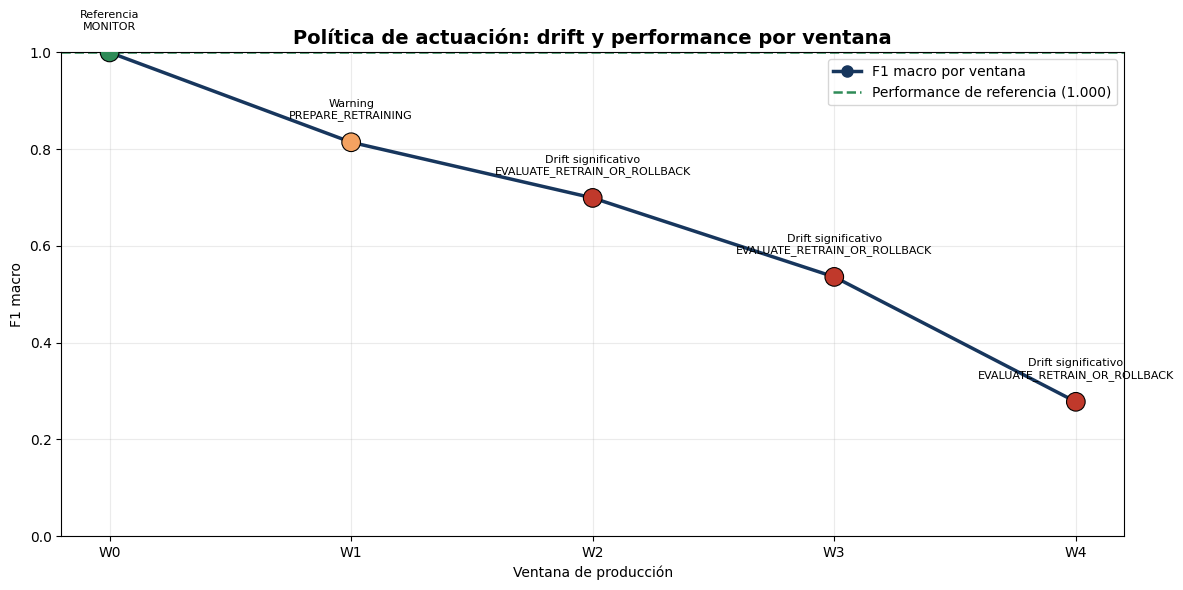

In [ ]:
# ============================================================
# 10.4 — VISUALIZACIÓN DE ESTADO Y PERFORMANCE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# 1. CONFIGURACIÓN VISUAL
# ============================================================

colores_estado_10_4 = {

    0:
        "#2E8B57",    # Verde

    1:
        "#F4A261",    # Naranja

    2:
        "#C0392B"     # Rojo
}


colores_ventanas_10_4 = [

    colores_estado_10_4[
        int(nivel)
    ]

    for nivel
    in df_decisiones_10_4[
        "nivel_drift"
    ]
]


# ============================================================
# 2. GRÁFICO
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 6)
)


ax.plot(
    df_decisiones_10_4[
        "ventana"
    ],

    df_decisiones_10_4[
        "performance_f1_macro"
    ],

    color="#17365D",
    linewidth=2.5,
    marker="o",
    markersize=8,
    label="F1 macro por ventana",
    zorder=2
)


ax.scatter(
    df_decisiones_10_4[
        "ventana"
    ],

    df_decisiones_10_4[
        "performance_f1_macro"
    ],

    color=colores_ventanas_10_4,
    s=180,
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)


performance_referencia_10_4 = float(
    df_decisiones_10_4[
        "performance_referencia"
    ]
    .iloc[0]
)


ax.axhline(
    y=performance_referencia_10_4,
    color="#2E8B57",
    linestyle="--",
    linewidth=1.8,
    label=(
        "Performance de referencia "
        f"({performance_referencia_10_4:.3f})"
    )
)


# ============================================================
# 3. ETIQUETAS
# ============================================================

for _, fila in df_decisiones_10_4.iterrows():

    ax.annotate(
        (
            f"{fila['estado_drift']}\n"
            f"{fila['codigo_accion']}"
        ),

        xy=(
            fila["ventana"],
            fila["performance_f1_macro"]
        ),

        xytext=(0, 15),

        textcoords="offset points",

        ha="center",
        va="bottom",
        fontsize=8
    )


ax.set_title(
    "Política de actuación: drift y performance por ventana",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Ventana de producción"
)

ax.set_ylabel(
    "F1 macro"
)

ax.set_ylim(
    0,
    1
)

ax.grid(
    alpha=0.25
)

ax.legend(
    loc="best"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 10.4 — VALIDACIÓN DE LA POLÍTICA DE ACTUACIÓN
# ============================================================

from pathlib import Path

import pandas as pd


# ============================================================
# 1. CAMPOS OBLIGATORIOS
# ============================================================

CAMPOS_POLITICA_10_4 = {

    "timestamp_utc",
    "decision_id",
    "ventana",
    "estado_drift",
    "nivel_drift",
    "performance_f1_macro",
    "performance_referencia",
    "estado_performance",
    "caida_porcentual",
    "persistencia_2_ventanas",
    "retrain_flag_activo",
    "codigo_accion",
    "prioridad",
    "accion",
    "retraining_recomendado",
    "rollback_recomendado",
    "revision_humana_requerida"
}


faltantes_politica_10_4 = (
    CAMPOS_POLITICA_10_4
    -
    set(
        df_decisiones_check_10_4.columns
    )
)


if faltantes_politica_10_4:

    raise KeyError(
        "action_decisions.csv no cumple el contrato. "
        f"Faltan: {sorted(faltantes_politica_10_4)}"
    )


# ============================================================
# 2. VALIDAR NIVELES
# ============================================================

niveles_validos_10_4 = {
    0,
    1,
    2
}


niveles_observados_10_4 = set(
    pd.to_numeric(
        df_decisiones_check_10_4[
            "nivel_drift"
        ]
    )
    .dropna()
    .astype(int)
    .unique()
)


if not niveles_observados_10_4.issubset(
    niveles_validos_10_4
):

    raise ValueError(
        "Se encontraron niveles de drift no válidos."
    )


# ============================================================
# 3. VALIDAR ACCIÓN DE W4
# ============================================================

fila_w4_10_4 = (
    df_decisiones_check_10_4[
        df_decisiones_check_10_4[
            "ventana"
        ]
        .astype(str)
        .eq("W4")
    ]
)


if fila_w4_10_4.empty:

    raise ValueError(
        "No se encontró la decisión de W4."
    )


fila_w4_10_4 = (
    fila_w4_10_4.iloc[-1]
)


if str(
    fila_w4_10_4[
        "estado_drift"
    ]
) != "Drift significativo":

    raise AssertionError(
        "W4 no fue clasificada como Drift significativo."
    )


if not bool(
    fila_w4_10_4[
        "revision_humana_requerida"
    ]
):

    raise AssertionError(
        "W4 debería requerir revisión humana."
    )


# ============================================================
# 4. VALIDAR SEGURIDAD
# ============================================================

MODEL_PATH_CHECK_10_4 = Path(
    "models/model.joblib"
)


if not MODEL_PATH_CHECK_10_4.exists():

    raise FileNotFoundError(
        "No se encontró el modelo campeón."
    )


# ============================================================
# 5. RESULTADO
# ============================================================

print("=" * 110)
print("CONTROL FINAL — 10.4 POLÍTICA DE ACTUACIÓN")
print("=" * 110)

print(
    "✅ Estados Normal, Warning y Drift significativo definidos."
)

print(
    "✅ Performance incorporada a la decisión."
)

print(
    "✅ Caída absoluta y relativa de F1 macro calculada."
)

print(
    "✅ Persistencia entre ventanas evaluada."
)

print(
    "✅ Alertas significativas consideradas."
)

print(
    "✅ retrain_required.flag considerado."
)

print(
    "✅ Reentrenamiento recomendado cuando corresponde."
)

print(
    "✅ Rollback evaluado como recomendación segura."
)

print(
    "✅ Revisión humana exigida para estados críticos."
)

print(
    "✅ Decisiones almacenadas sin duplicados."
)

print(
    "✅ models/model.joblib permanece disponible."
)

print(
    "✅ El modelo campeón NO fue reemplazado."
)

print(
    "✅ No se ejecutó reentrenamiento automático."
)

print("=" * 110)

print(
    "✅ 10.4 — POLÍTICA DE ACTUACIÓN COMPLETADA"
)

CONTROL FINAL — 10.4 POLÍTICA DE ACTUACIÓN
✅ Estados Normal, Warning y Drift significativo definidos.
✅ Performance incorporada a la decisión.
✅ Caída absoluta y relativa de F1 macro calculada.
✅ Persistencia entre ventanas evaluada.
✅ Alertas significativas consideradas.
✅ retrain_required.flag considerado.
✅ Reentrenamiento recomendado cuando corresponde.
✅ Rollback evaluado como recomendación segura.
✅ Revisión humana exigida para estados críticos.
✅ Decisiones almacenadas sin duplicados.
✅ models/model.joblib permanece disponible.
✅ El modelo campeón NO fue reemplazado.
✅ No se ejecutó reentrenamiento automático.
✅ 10.4 — POLÍTICA DE ACTUACIÓN COMPLETADA


## 10.4.8 Interpretación técnica

La política de actuación integra dos dimensiones.

## Estado Normal

Esta sección resume estado Normal y su función dentro del proyecto MLOps.

## Estado Warning

Si el Warning persiste durante al menos dos ventanas.

## Drift significativo

Esta sección resume drift significativo y su función dentro del proyecto MLOps.

## Reentrenamiento

El reentrenamiento se recomienda cuando existe evidencia suficiente, pero no se ejecuta automáticamente.

## Rollback

El rollback se considera una medida de seguridad y no una respuesta automática a cualquier drift.

## Producto de 10.4

Esta sección resume producto de 10.4 y su función dentro del proyecto MLOps.


## Compresión y descarga del proyecto completo

La siguiente celda comprime todo el contenido almacenado en /content y genera un archivo ZIP descargable.


In [ ]:
# ============================================================
# COMPRIMIR Y DESCARGAR TODO EL CONTENIDO DE /content
# ============================================================

from pathlib import Path
from datetime import datetime
from google.colab import files

import shutil


# ============================================================
# 1. CONFIGURACIÓN
# ============================================================

CARPETA_ORIGEN = Path("/content")

# El ZIP se guarda temporalmente en /tmp para evitar que
# termine incluyéndose a sí mismo durante la compresión.
CARPETA_TEMPORAL = Path("/tmp")

fecha_hora = datetime.now().strftime("%Y%m%d_%H%M%S")

nombre_archivo = f"contenido_colab_{fecha_hora}"

ruta_base_zip = CARPETA_TEMPORAL / nombre_archivo


# ============================================================
# 2. VERIFICAR LA CARPETA DE ORIGEN
# ============================================================

if not CARPETA_ORIGEN.exists():
    raise FileNotFoundError(
        f"No se encontró la carpeta: {CARPETA_ORIGEN}"
    )

if not CARPETA_ORIGEN.is_dir():
    raise NotADirectoryError(
        f"La ruta no corresponde a una carpeta: {CARPETA_ORIGEN}"
    )


# ============================================================
# 3. MOSTRAR INFORMACIÓN PREVIA
# ============================================================

archivos_encontrados = [
    ruta
    for ruta in CARPETA_ORIGEN.rglob("*")
    if ruta.is_file()
]

print("=" * 80)
print("COMPRESIÓN DEL CONTENIDO DE GOOGLE COLAB")
print("=" * 80)
print(f"Carpeta de origen       : {CARPETA_ORIGEN}")
print(f"Archivos encontrados    : {len(archivos_encontrados):,}")
print(f"Directorio temporal ZIP : {CARPETA_TEMPORAL}")
print("\nIniciando compresión...")


# ============================================================
# 4. CREAR EL ARCHIVO ZIP
# ============================================================

ruta_zip = shutil.make_archive(
    base_name=str(ruta_base_zip),
    format="zip",
    root_dir=str(CARPETA_ORIGEN)
)


# ============================================================
# 5. VERIFICAR EL ARCHIVO GENERADO
# ============================================================

ruta_zip = Path(ruta_zip)

if not ruta_zip.exists():
    raise FileNotFoundError(
        "No fue posible generar el archivo ZIP."
    )

tamano_mb = ruta_zip.stat().st_size / (1024 ** 2)

print("\n✅ Compresión finalizada correctamente.")
print(f"Archivo generado : {ruta_zip}")
print(f"Tamaño del ZIP   : {tamano_mb:,.2f} MB")


# ============================================================
# 6. DESCARGAR EL ZIP
# ============================================================

print("\nIniciando descarga en el navegador...")

files.download(str(ruta_zip))

COMPRESIÓN DEL CONTENIDO DE GOOGLE COLAB
Carpeta de origen       : /content
Archivos encontrados    : 18,234
Directorio temporal ZIP : /tmp

Iniciando compresión...

✅ Compresión finalizada correctamente.
Archivo generado : /tmp/contenido_colab_20260828_064947.zip
Tamaño del ZIP   : 1,106.13 MB

Iniciando descarga en el navegador...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>